<a href="https://www.kaggle.com/code/poeticmage/notebook4bad4fbe67?scriptVersionId=310689679" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# CUB-200 DATASET UPLOAD PIPELINE FOR TRAINING AND TESTING OF MODELS
### This Notebook shows how a pipeline for the The Caltech-UCSD Birds-200-2011 (CUB-200) dataset has to be built in order to be used in models like zero-shot
### CUB-200 has 11,788 images over 200 classes and each class has attribute size of 312.
<h6>Reference: Wah, C., Branson, S., Welinder, P., Perona, P., & Belongie, S. (2011).
The Caltech-UCSD Birds-200-2011 Dataset.
California Institute of Technology. </h6>

In [1]:
%%capture
! pip install scikit-learn numpy matplotlib pandas lightning torch timm==0.5.4
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
import lightning as L
from torchvision import datasets, transforms
import numpy as np
import os
from glob import glob
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

### Image to vector
###### Use torchivision transforms to convert image to readable tensors

In [2]:
transform=transforms.Compose([transforms.ToTensor(),])

### Attributes
##### The attributes are initialized with s, they are in an order, taken from source file. We build an all-class attribute matrix. Later we divide them to per-class

In [3]:
s="""0.0 2.9197080292 1.4598540146 0.0 59.8540145985 26.2773722628 3.6496350365 5.83941605839 0.0 1.6393442623 45.9016393443 3.27868852459 0.0 2.45901639344 24.5901639344 0.0 0.0 0.0 0.0 0.0 31.9672131148 3.27868852459 2.45901639344 28.6885245902 1.8018018018 48.6486486486 3.6036036036 0.0 1.8018018018 20.7207207207 0.0 0.0 0.0 0.0 0.0 23.4234234234 2.7027027027 5.40540540541 29.7297297297 2.12765957447 29.7872340426 4.25531914894 0.0 5.31914893617 39.3617021277 0.0 0.0 0.0 0.0 0.0 23.4042553191 8.51063829787 6.3829787234 18.085106383 78.5046728972 0.0 3.73831775701 17.7570093458 1.92307692308 44.2307692308 1.92307692308 0.0 2.88461538462 21.1538461538 0.0 0.0 0.0 0.0 0.0 22.1153846154 1.92307692308 5.76923076923 30.7692307692 2.08333333333 23.9583333333 23.9583333333 16.6666666667 23.9583333333 9.375 3.52941176471 31.7647058824 4.70588235294 0.0 3.52941176471 22.3529411765 0.0 0.0 0.0 0.0 0.0 22.3529411765 16.4705882353 7.05882352941 22.3529411765 4.0 5.6 0.0 6.4 5.6 7.2 12.0 36.8 16.0 6.4 6.4 1.78571428571 33.9285714286 2.67857142857 0.0 4.46428571429 33.0357142857 0.0 0.0 0.0 0.0 0.0 21.4285714286 2.67857142857 5.35714285714 19.6428571429 1.42857142857 31.4285714286 3.57142857143 0.0 2.85714285714 23.5714285714 0.0 0.0 0.0 0.0 0.0 20.0 7.85714285714 6.42857142857 28.5714285714 0.0 3.78787878788 0.0 0.0 2.27272727273 1.51515151515 0.0 0.0 0.0 0.0 81.0606060606 8.33333333333 4.54545454545 0.757575757576 82.2695035461 7.80141843972 9.92907801418 1.44927536232 14.4927536232 2.17391304348 0.0 0.0 29.7101449275 0.0 0.0 0.0 0.0 0.0 11.5942028986 31.1594202899 6.52173913043 27.5362318841 2.1978021978 35.1648351648 2.1978021978 0.0 5.49450549451 27.4725274725 0.0 0.0 0.0 0.0 0.0 30.7692307692 19.7802197802 6.59340659341 21.978021978 1.51515151515 40.1515151515 2.27272727273 0.0 3.0303030303 26.5151515152 0.0 0.0 0.0 0.0 0.0 18.1818181818 5.30303030303 6.06060606061 23.4848484848 2.24719101124 25.8426966292 3.37078651685 0.0 5.61797752809 29.2134831461 0.0 0.0 0.0 0.0 0.0 21.3483146067 7.86516853933 6.74157303371 25.8426966292 13.7614678899 20.1834862385 11.0091743119 11.0091743119 52.2935779817 19.2307692308 10.0 1.53846153846 66.9230769231 2.30769230769 7.46268656716 0.0 2.23880597015 33.5820895522 0.0 34.328358209 0.0 0.746268656716 0.0 8.20895522388 1.49253731343 2.98507462687 3.73134328358 5.22388059701 58.5858585859 3.0303030303 18.1818181818 20.202020202 45.7446808511 3.1914893617 14.8936170213 36.170212766 81.7073170732 0.0 3.65853658537 14.6341463415 2.01342281879 48.322147651 1.34228187919 0.0 2.01342281879 24.8322147651 0.0 0.0 0.0 0.0 0.0 26.8456375839 2.68456375839 4.02684563758 24.1610738255 4.16666666667 16.6666666667 0.0 0.0 0.0 27.0833333333 0.0 0.0 0.0 0.0 0.0 39.5833333333 0.0 12.5 10.4166666667 2.12765957447 20.5673758865 2.12765957447 0.0 0.0 34.7517730496 0.0 0.0 0.0 0.0 0.0 32.6241134752 4.25531914894 6.3829787234 21.9858156028 2.12765957447 24.1134751773 3.54609929078 0.0 0.0 32.6241134752 0.0 0.0 0.0 0.0 0.0 21.2765957447 11.3475177305 2.12765957447 31.914893617 53.5714285714 5.35714285714 21.4285714286 19.6428571429
4.41176470588 4.41176470588 2.94117647059 1.47058823529 57.3529411765 27.2058823529 0.0 2.20588235294 0.0 0.0 37.2727272727 0.0 0.0 0.0 20.9090909091 0.0 0.0 0.0 0.0 0.0 52.7272727273 9.09090909091 0.0 7.27272727273 0.0 41.6666666667 0.0 0.0 0.0 17.7083333333 0.0 0.0 0.0 0.0 0.0 51.0416666667 20.8333333333 0.0 2.08333333333 0.0 0.917431192661 0.0 0.0 0.0 4.5871559633 0.0 0.0 0.0 0.0 0.0 6.42201834862 93.5779816514 0.0 0.0 95.9016393443 0.0 0.0 4.09836065574 0.0 44.4444444444 0.0 0.0 0.0 11.1111111111 0.0 0.0 0.0 0.0 0.0 41.1111111111 24.4444444444 0.0 3.33333333333 5.40540540541 17.5675675676 14.8648648649 12.1621621622 24.3243243243 25.6756756757 0.0 20.8333333333 0.0 0.0 0.0 8.33333333333 0.0 0.0 0.0 0.0 0.0 40.2777777778 36.1111111111 0.0 0.0 0.0 0.847457627119 1.69491525424 16.1016949153 7.62711864407 0.847457627119 2.54237288136 31.3559322034 42.3728813559 2.54237288136 2.54237288136 0.0 0.840336134454 0.0 0.0 0.0 3.36134453782 0.0 0.0 0.0 0.0 0.0 2.52100840336 93.2773109244 0.0 0.0 1.5037593985 0.751879699248 0.0 0.0 0.0 12.030075188 0.0 0.0 0.0 0.0 0.0 6.01503759398 89.4736842105 0.0 0.0 0.0 1.65289256198 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 99.173553719 1.65289256198 0.0 0.0 65.3543307087 31.4960629921 3.14960629921 0.0 0.77519379845 0.0 0.0 0.0 1.5503875969 0.0 0.0 0.0 0.0 0.0 2.32558139535 96.8992248062 0.0 0.0 0.0 17.5 0.0 0.0 0.0 8.75 0.0 0.0 0.0 0.0 0.0 65.0 31.25 0.0 0.0 0.0 4.8 0.0 0.0 0.0 4.8 0.0 0.0 0.0 0.0 0.0 1.6 92.0 0.0 1.6 0.0 0.917431192661 0.0 0.0 0.0 4.5871559633 0.0 0.0 0.0 0.0 0.0 5.50458715596 91.7431192661 0.0 0.0 7.07070707071 14.1414141414 10.101010101 14.1414141414 62.6262626263 31.6239316239 1.7094017094 17.9487179487 48.7179487179 0.0 5.55555555556 5.55555555556 1.5873015873 25.3968253968 0.0 39.6825396825 2.38095238095 0.793650793651 0.0 3.96825396825 0.0 9.52380952381 3.96825396825 1.5873015873 68.8888888889 3.33333333333 7.77777777778 20.0 55.8441558442 1.2987012987 6.49350649351 36.3636363636 95.4545454545 0.0 0.0 4.54545454545 0.0 30.6569343066 0.0 0.0 0.0 19.7080291971 0.0 0.0 0.0 0.0 0.0 43.0656934307 86.1313868613 0.0 5.83941605839 0.0 8.51063829787 0.0 0.0 2.12765957447 19.1489361702 0.0 0.0 0.0 0.0 4.25531914894 6.3829787234 38.2978723404 0.0 38.2978723404 2.27272727273 1.51515151515 0.0 0.0 0.0 24.2424242424 0.0 0.0 0.0 0.0 18.1818181818 1.51515151515 20.4545454545 0.0 56.0606060606 0.0 3.00751879699 0.0 0.0 0.0 2.25563909774 0.0 0.0 0.0 0.0 2.25563909774 2.25563909774 94.7368421053 0.0 0.0 77.1428571429 3.80952380952 10.4761904762 8.57142857143
0.0 3.97350993377 3.31125827815 0.0 70.8609271523 14.5695364238 5.29801324503 1.98675496689 0.0 0.0 26.6666666667 0.0 0.0 0.0 47.5 0.0 0.0 1.66666666667 2.5 0.0 26.6666666667 11.6666666667 2.5 11.6666666667 1.88679245283 19.8113207547 0.0 2.83018867925 0.0 47.1698113208 0.0 0.0 0.0 0.0 2.83018867925 24.5283018868 14.1509433962 0.0 22.641509434 3.77358490566 17.9245283019 0.0 5.66037735849 0.0 40.5660377358 0.0 0.0 0.0 0.0 0.0 24.5283018868 14.1509433962 0.0 14.1509433962 74.6031746032 3.1746031746 4.7619047619 17.4603174603 1.81818181818 19.0909090909 0.0 2.72727272727 0.0 47.2727272727 0.0 0.0 0.0 0.0 2.72727272727 13.6363636364 21.8181818182 0.0 19.0909090909 1.05263157895 10.5263157895 7.36842105263 8.42105263158 60.0 12.6315789474 2.22222222222 16.6666666667 0.0 0.0 0.0 56.6666666667 0.0 0.0 0.0 0.0 3.33333333333 20.0 6.66666666667 0.0 20.0 0.0 0.751879699248 2.25563909774 0.751879699248 12.7819548872 3.00751879699 36.0902255639 39.0977443609 3.00751879699 4.51127819549 6.76691729323 3.07692307692 21.5384615385 0.0 4.61538461538 0.0 46.9230769231 0.0 0.0 0.0 0.0 2.30769230769 23.0769230769 17.6923076923 0.0 10.7692307692 1.5037593985 18.045112782 0.0 4.51127819549 0.0 27.0676691729 2.25563909774 0.0 0.0 0.0 0.0 45.1127819549 9.77443609023 0.0 9.77443609023 0.714285714286 1.42857142857 0.0 0.0 6.42857142857 0.0 0.0 0.0 2.14285714286 0.0 78.5714285714 34.2857142857 0.0 1.42857142857 86.8613138686 8.02919708029 5.10948905109 0.0 24.0 0.0 2.4 0.0 18.4 2.4 0.0 0.0 0.0 0.0 49.6 2.4 0.0 11.2 2.53164556962 18.9873417722 0.0 0.0 0.0 44.3037974684 0.0 0.0 0.0 3.79746835443 0.0 39.2405063291 10.1265822785 0.0 11.3924050633 2.94117647059 16.9117647059 0.0 4.41176470588 0.0 47.7941176471 0.0 0.0 0.0 0.0 2.20588235294 13.9705882353 18.3823529412 0.0 17.6470588235 2.83018867925 19.8113207547 0.0 5.66037735849 0.0 33.9622641509 0.0 0.0 0.0 2.83018867925 0.0 25.4716981132 16.0377358491 0.0 11.320754717 8.82352941176 20.5882352941 4.90196078431 24.5098039216 47.0588235294 14.5161290323 19.3548387097 1.61290322581 59.6774193548 4.83870967742 10.9375 0.0 1.5625 10.9375 0.0 38.28125 3.125 10.15625 0.0 5.46875 2.34375 1.5625 15.625 0.0 69.4444444444 2.77777777778 9.25925925926 18.5185185185 74.6987951807 3.61445783133 1.20481927711 20.4819277108 78.2178217822 2.9702970297 6.93069306931 11.8811881188 3.35570469799 25.5033557047 0.0 4.02684563758 0.0 48.322147651 0.0 0.0 0.0 0.0 2.01342281879 30.2013422819 9.39597315436 0.0 18.1208053691 0.0 0.0 0.0 0.0 0.0 40.4761904762 7.14285714286 0.0 0.0 7.14285714286 0.0 14.2857142857 14.2857142857 0.0 30.9523809524 2.68456375839 6.04026845638 1.34228187919 2.01342281879 0.0 21.4765100671 0.0 0.0 0.0 0.0 2.01342281879 75.1677852349 8.72483221477 0.0 0.0 0.0 24.2647058824 0.0 4.41176470588 0.0 34.5588235294 0.0 0.0 0.0 2.20588235294 0.0 38.9705882353 2.94117647059 0.0 16.1764705882 71.0280373832 0.934579439252 7.47663551402 20.5607476636
0.0 1.4598540146 10.2189781022 0.0 0.0 0.0 8.75912408759 25.5474452555 54.0145985401 5.83941605839 8.02919708029 4.3795620438 0.0 0.0 4.3795620438 0.0 0.0 0.0 0.0 0.0 96.3503649635 1.4598540146 0.0 2.9197080292 6.15384615385 6.15384615385 7.69230769231 0.0 0.0 4.61538461538 0.0 0.0 0.0 0.0 0.0 93.0769230769 1.53846153846 0.0 1.53846153846 6.76691729323 1.5037593985 9.02255639098 0.0 0.0 5.26315789474 0.0 0.0 0.0 0.0 0.0 92.4812030075 2.25563909774 0.0 0.0 85.6 2.4 2.4 9.6 5.88235294118 6.72268907563 7.56302521008 0.0 0.0 2.52100840336 0.0 0.0 0.0 0.0 0.0 92.4369747899 0.840336134454 0.0 0.0 0.0 20.5882352941 37.2549019608 13.7254901961 23.5294117647 4.90196078431 7.01754385965 6.14035087719 3.50877192982 0.0 0.0 4.38596491228 0.0 0.0 0.0 0.0 0.0 91.2280701754 1.75438596491 0.0 0.0 2.23880597015 0.0 8.20895522388 0.0 0.0 14.1791044776 2.98507462687 66.4179104478 8.9552238806 2.23880597015 1.49253731343 6.81818181818 1.51515151515 2.27272727273 0.0 0.0 4.54545454545 0.0 0.0 0.0 0.0 0.0 94.696969697 2.27272727273 0.0 0.0 6.12244897959 1.36054421769 6.12244897959 0.0 0.0 6.12244897959 0.0 0.0 0.0 0.0 0.0 90.4761904762 2.04081632653 0.0 2.04081632653 2.05479452055 0.0 0.0 2.05479452055 0.0 0.0 0.0 0.0 0.0 0.0 97.9452054795 0.0 0.0 0.0 23.0215827338 0.0 76.9784172662 6.29370629371 1.3986013986 4.1958041958 0.0 0.0 9.79020979021 0.0 0.0 0.0 0.0 0.0 88.8111888112 2.0979020979 0.0 2.0979020979 6.61157024793 6.61157024793 3.30578512397 0.0 0.0 1.65289256198 0.0 0.0 0.0 0.0 0.0 94.2148760331 3.30578512397 0.0 0.0 5.79710144928 1.44927536232 4.34782608696 0.0 0.0 7.24637681159 0.0 0.0 0.0 0.0 0.0 88.4057971014 1.44927536232 0.0 2.17391304348 6.25 0.0 2.34375 0.0 0.0 1.5625 0.0 1.5625 0.0 0.0 0.0 94.53125 1.5625 0.0 0.0 44.5945945946 18.9189189189 14.8648648649 18.9189189189 2.7027027027 6.87022900763 65.6488549618 0.0 15.2671755725 12.213740458 2.30769230769 0.0 0.0 0.0 0.0 6.15384615385 3.84615384615 15.3846153846 3.84615384615 25.3846153846 4.61538461538 0.769230769231 6.15384615385 31.5384615385 87.2881355932 2.54237288136 2.54237288136 7.62711864407 92.9203539823 0.0 4.42477876106 2.65486725664 96.0317460317 0.0 0.0 3.96825396825 5.40540540541 3.37837837838 6.08108108108 0.0 0.0 2.02702702703 0.0 0.0 0.0 0.0 0.0 96.6216216216 1.35135135135 0.0 0.0 5.40540540541 7.20720720721 0.0 0.0 0.0 16.2162162162 0.0 0.0 0.0 0.0 0.0 73.8738738739 4.5045045045 0.0 4.5045045045 0.699300699301 5.59440559441 0.0 0.0 0.0 26.5734265734 0.0 0.0 0.0 0.0 0.0 76.9230769231 2.0979020979 0.0 1.3986013986 4.28571428571 1.42857142857 6.42857142857 2.14285714286 0.0 5.0 0.0 0.0 0.0 0.0 0.0 88.5714285714 0.0 0.0 2.14285714286 84.126984127 2.38095238095 3.1746031746 10.3174603175
0.0 0.0 3.22580645161 0.0 1.0752688172 0.0 0.0 32.2580645161 63.4408602151 0.0 15.0 7.5 2.5 0.0 28.75 0.0 0.0 0.0 0.0 2.5 87.5 0.0 0.0 3.75 0.0 11.1111111111 6.66666666667 2.22222222222 0.0 24.4444444444 0.0 0.0 0.0 0.0 0.0 86.6666666667 3.33333333333 0.0 3.33333333333 0.0 6.60377358491 5.66037735849 0.0 0.0 57.5471698113 0.0 0.0 0.0 0.0 0.0 34.9056603774 10.3773584906 0.0 4.71698113208 88.679245283 0.0 5.66037735849 5.66037735849 0.0 6.49350649351 3.8961038961 2.5974025974 0.0 23.3766233766 0.0 0.0 0.0 0.0 0.0 84.4155844156 3.8961038961 0.0 3.8961038961 0.0 11.5384615385 34.6153846154 3.84615384615 19.2307692308 30.7692307692 0.0 9.80392156863 11.7647058824 3.92156862745 0.0 23.5294117647 0.0 0.0 0.0 0.0 0.0 90.1960784314 0.0 0.0 5.88235294118 0.0 0.862068965517 79.3103448276 0.0 6.03448275862 0.0 2.58620689655 6.03448275862 18.9655172414 0.0 0.0 0.0 7.54716981132 5.66037735849 1.88679245283 0.0 52.8301886792 0.0 0.0 0.0 0.0 0.0 42.4528301887 7.54716981132 0.0 2.83018867925 0.0 5.08474576271 2.54237288136 1.69491525424 0.0 32.2033898305 0.0 0.0 0.0 0.0 0.0 72.8813559322 5.93220338983 0.0 2.54237288136 15.0442477876 0.884955752212 0.0 0.0 2.65486725664 0.0 0.0 0.0 0.0 0.0 37.1681415929 84.0707964602 0.0 0.0 3.50877192982 0.0 96.4912280702 0.0 3.50877192982 2.63157894737 1.75438596491 0.0 17.5438596491 0.0 0.0 0.0 0.0 0.0 88.5964912281 7.01754385965 0.0 3.50877192982 0.0 6.97674418605 13.9534883721 0.0 0.0 27.9069767442 0.0 0.0 0.0 0.0 0.0 86.0465116279 0.0 0.0 6.97674418605 0.0 5.35714285714 2.67857142857 1.78571428571 0.0 20.5357142857 0.0 0.0 0.0 0.0 0.0 83.0357142857 9.82142857143 0.0 2.67857142857 0.0 8.0 6.0 0.0 0.0 58.0 0.0 0.0 0.0 0.0 0.0 39.0 8.0 0.0 5.0 20.5128205128 58.9743589744 7.69230769231 5.12820512821 15.3846153846 15.5555555556 16.6666666667 0.0 67.7777777778 0.0 43.2989690722 7.21649484536 0.0 10.3092783505 0.0 2.0618556701 0.0 10.3092783505 0.0 1.03092783505 0.0 22.6804123711 0.0 3.09278350515 92.1052631579 0.0 3.94736842105 3.94736842105 82.6086956522 0.0 6.52173913043 10.8695652174 92.2330097087 0.0 2.91262135922 4.85436893204 0.0 11.9266055046 5.50458715596 1.83486238532 0.0 48.623853211 0.0 0.0 0.0 0.0 0.0 76.1467889908 5.50458715596 0.0 2.75229357798 7.5 5.0 7.5 6.25 0.0 63.75 0.0 0.0 0.0 0.0 0.0 31.25 0.0 0.0 0.0 0.0 0.884955752212 0.0 0.0 0.0 4.42477876106 10.6194690265 0.0 0.0 0.0 61.0619469027 3.53982300885 7.96460176991 18.5840707965 15.9292035398 0.0 4.54545454545 2.72727272727 1.81818181818 0.0 19.0909090909 0.0 0.0 0.0 0.0 0.0 82.7272727273 5.45454545455 0.0 4.54545454545 88.4615384615 0.0 3.84615384615 7.69230769231
0.0 0.0 0.0 0.0 0.0 4.12371134021 7.21649484536 77.3195876289 11.3402061856 0.0 11.6883116883 0.0 0.0 0.0 42.8571428571 0.0 2.5974025974 0.0 0.0 0.0 64.9350649351 63.6363636364 0.0 0.0 0.0 4.7619047619 0.0 0.0 0.0 51.1904761905 0.0 3.57142857143 0.0 0.0 0.0 63.0952380952 44.0476190476 0.0 3.57142857143 0.0 0.0 7.92079207921 0.0 0.0 45.5445544554 0.0 2.9702970297 0.0 0.0 0.0 50.495049505 73.2673267327 0.0 2.9702970297 13.4615384615 19.2307692308 56.7307692308 10.5769230769 0.0 5.33333333333 0.0 0.0 0.0 33.3333333333 0.0 2.66666666667 0.0 0.0 0.0 68.0 22.6666666667 0.0 0.0 0.0 7.54716981132 43.3962264151 3.77358490566 13.2075471698 32.0754716981 0.0 12.7659574468 0.0 0.0 0.0 38.2978723404 0.0 4.25531914894 0.0 0.0 0.0 70.2127659574 46.8085106383 0.0 6.3829787234 0.0 26.1363636364 0.0 0.0 0.0 15.9090909091 27.2727272727 22.7272727273 11.3636363636 10.2272727273 10.2272727273 0.0 2.9702970297 2.9702970297 0.0 0.0 40.5940594059 0.0 2.9702970297 0.0 0.0 0.0 52.4752475248 81.1881188119 0.0 0.0 2.85714285714 0.0 0.0 0.0 0.0 21.9047619048 0.0 1.90476190476 0.0 0.0 0.0 35.2380952381 75.2380952381 0.0 0.0 0.0 0.0 0.0 0.0 2.80373831776 2.80373831776 0.0 0.0 0.0 2.80373831776 32.7102803738 91.5887850467 0.0 0.0 0.961538461538 0.0 99.0384615385 0.0 2.85714285714 0.0 0.0 0.0 43.8095238095 0.0 1.90476190476 0.0 0.0 0.0 62.8571428571 23.8095238095 0.0 2.85714285714 0.0 0.0 0.0 0.0 0.0 33.3333333333 0.0 1.96078431373 0.0 0.0 0.0 58.8235294118 56.862745098 0.0 7.8431372549 0.0 7.54716981132 0.0 0.0 0.0 33.0188679245 0.0 2.83018867925 0.0 2.83018867925 0.0 66.0377358491 16.0377358491 0.0 0.0 0.0 0.0 2.9702970297 0.0 0.0 46.5346534653 0.0 2.9702970297 0.0 0.0 0.0 46.5346534653 77.2277227723 0.0 5.94059405941 39.6226415094 26.4150943396 28.3018867925 1.88679245283 3.77358490566 6.31578947368 41.0526315789 0.0 37.8947368421 14.7368421053 16.8421052632 4.21052631579 0.0 17.8947368421 0.0 5.26315789474 5.26315789474 5.26315789474 0.0 6.31578947368 3.15789473684 12.6315789474 2.10526315789 21.0526315789 48.5714285714 11.4285714286 18.5714285714 21.4285714286 29.0909090909 16.3636363636 21.8181818182 32.7272727273 3.0303030303 32.3232323232 52.5252525253 12.1212121212 0.0 3.80952380952 0.0 0.0 0.0 39.0476190476 0.0 1.90476190476 0.0 2.85714285714 0.0 62.8571428571 55.2380952381 0.0 0.0 3.40909090909 0.0 0.0 3.40909090909 0.0 60.2272727273 0.0 2.27272727273 0.0 0.0 0.0 39.7727272727 21.5909090909 0.0 0.0 0.0 3.0612244898 0.0 0.0 34.693877551 8.16326530612 0.0 2.04081632653 0.0 3.0612244898 4.08163265306 69.387755102 3.0612244898 24.4897959184 2.04081632653 0.0 0.0 0.0 0.0 0.0 34.3137254902 0.0 1.96078431373 0.0 0.0 0.0 63.7254901961 10.7843137255 1.96078431373 4.90196078431 16.2162162162 12.1621621622 48.6486486486 22.972972973
0.0 0.0 1.61290322581 0.0 1.61290322581 5.64516129032 2.41935483871 30.6451612903 58.064516129 1.72413793103 4.31034482759 0.0 1.72413793103 0.0 37.0689655172 0.0 0.0 0.0 0.0 0.0 81.0344827586 15.5172413793 0.0 0.0 1.62601626016 4.06504065041 0.0 0.0 0.0 44.7154471545 0.0 0.0 0.0 2.43902439024 0.0 77.2357723577 11.3821138211 0.0 0.0 0.0 0.0 0.0 0.0 0.0 24.7863247863 2.5641025641 0.0 0.0 0.0 0.0 18.8034188034 90.5982905983 0.0 0.0 32.2834645669 18.8976377953 17.3228346457 31.4960629921 0.0 4.23728813559 0.0 0.0 2.54237288136 27.1186440678 0.0 0.0 0.0 0.0 0.0 82.2033898305 11.8644067797 0.0 0.0 0.0 16.9811320755 18.8679245283 13.2075471698 22.641509434 28.3018867925 0.0 9.52380952381 0.0 0.0 0.0 34.5238095238 0.0 0.0 0.0 0.0 0.0 72.619047619 7.14285714286 0.0 0.0 1.5503875969 10.8527131783 3.87596899225 0.0 1.5503875969 7.7519379845 17.8294573643 20.9302325581 44.9612403101 0.0 1.5503875969 0.0 3.84615384615 2.30769230769 0.0 0.0 39.2307692308 0.0 0.0 0.0 0.0 0.0 35.3846153846 80.7692307692 0.0 1.53846153846 0.0 5.75539568345 0.0 0.0 0.0 43.1654676259 0.0 0.0 0.0 0.0 2.15827338129 54.6762589928 46.0431654676 0.0 0.0 0.0 2.06896551724 0.0 0.0 4.13793103448 0.0 0.0 0.0 0.0 0.0 40.0 89.6551724138 0.0 0.0 3.54609929078 2.12765957447 94.3262411348 1.35135135135 7.43243243243 0.0 0.0 0.0 22.2972972973 0.0 0.0 0.0 0.0 0.0 77.7027027027 0.0 0.0 0.0 0.0 6.41025641026 0.0 0.0 0.0 28.2051282051 0.0 0.0 0.0 3.84615384615 0.0 58.9743589744 32.0512820513 0.0 0.0 1.35135135135 5.40540540541 0.0 0.0 0.0 26.3513513514 0.0 0.0 0.0 2.02702702703 0.0 77.027027027 12.8378378378 2.02702702703 0.0 0.0 0.0 0.0 0.0 0.0 14.7826086957 0.0 0.0 0.0 2.60869565217 0.0 10.4347826087 93.0434782609 0.0 0.0 28.8888888889 31.1111111111 33.3333333333 6.66666666667 2.22222222222 4.34782608696 26.0869565217 4.34782608696 65.2173913043 0.0 32.2033898305 1.69491525424 0.0 21.186440678 0.0 5.08474576271 0.0 22.8813559322 3.38983050847 2.54237288136 2.54237288136 5.93220338983 0.0 2.54237288136 70.1754385965 2.63157894737 13.1578947368 14.0350877193 72.4637681159 4.34782608696 5.79710144928 17.3913043478 81.981981982 7.20720720721 6.30630630631 4.5045045045 0.719424460432 5.75539568345 0.0 0.0 0.0 39.5683453237 0.0 0.0 0.0 0.0 2.15827338129 73.381294964 51.0791366906 1.43884892086 0.0 0.0 2.10526315789 0.0 0.0 0.0 72.6315789474 0.0 0.0 0.0 0.0 0.0 24.2105263158 35.7894736842 0.0 1.05263157895 1.38888888889 2.08333333333 0.0 0.0 9.02777777778 6.25 1.38888888889 0.0 0.0 1.38888888889 41.6666666667 3.47222222222 4.16666666667 44.4444444444 0.0 0.0 5.44217687075 0.0 0.0 0.0 21.768707483 1.36054421769 0.0 0.0 2.04081632653 0.0 79.5918367347 0.0 0.0 0.0 63.8095238095 2.85714285714 15.2380952381 18.0952380952
0.0 2.94117647059 10.7843137255 0.0 7.8431372549 11.7647058824 30.3921568627 17.6470588235 18.6274509804 0.0 41.1111111111 0.0 2.22222222222 0.0 18.8888888889 2.22222222222 0.0 0.0 0.0 0.0 70.0 0.0 0.0 4.44444444444 0.0 36.0824742268 3.09278350515 0.0 0.0 26.8041237113 0.0 0.0 0.0 0.0 0.0 73.1958762887 3.09278350515 0.0 10.3092783505 0.0 22.9508196721 3.27868852459 0.0 0.0 50.8196721311 0.0 0.0 0.0 0.0 0.0 32.7868852459 11.4754098361 0.0 6.55737704918 65.9793814433 0.0 17.5257731959 16.4948453608 0.0 37.1134020619 0.0 0.0 0.0 18.5567010309 2.0618556701 0.0 0.0 0.0 0.0 67.0103092784 0.0 0.0 3.09278350515 0.0 9.43396226415 16.9811320755 28.3018867925 22.641509434 22.641509434 0.0 38.2352941176 0.0 0.0 0.0 20.5882352941 2.94117647059 0.0 0.0 0.0 0.0 69.1176470588 4.41176470588 0.0 2.94117647059 0.0 10.5769230769 8.65384615385 0.0 2.88461538462 22.1153846154 23.0769230769 27.8846153846 9.61538461538 0.0 0.0 0.0 25.7731958763 5.15463917526 0.0 0.0 49.4845360825 0.0 0.0 0.0 0.0 0.0 39.175257732 12.3711340206 0.0 15.4639175258 0.0 15.5339805825 0.0 0.0 0.0 45.6310679612 0.0 0.0 0.0 0.0 2.91262135922 45.6310679612 1.94174757282 0.0 3.88349514563 2.94117647059 14.7058823529 0.0 0.0 6.86274509804 6.86274509804 0.0 0.0 0.0 5.88235294118 62.7450980392 5.88235294118 2.94117647059 10.7843137255 34.6153846154 2.88461538462 62.5 0.0 23.4782608696 0.0 0.0 0.0 40.0 0.0 0.0 0.0 0.0 0.0 55.652173913 0.0 0.0 0.0 0.0 27.1186440678 3.38983050847 0.0 0.0 23.7288135593 3.38983050847 0.0 0.0 0.0 0.0 66.1016949153 0.0 0.0 3.38983050847 0.0 25.4545454545 2.72727272727 0.0 0.0 24.5454545455 0.0 0.0 0.0 0.0 0.0 61.8181818182 8.18181818182 0.0 0.0 0.0 22.4137931034 3.44827586207 0.0 0.0 41.3793103448 0.0 0.0 0.0 0.0 0.0 31.0344827586 18.9655172414 0.0 12.0689655172 44.0677966102 25.4237288136 32.2033898305 10.1694915254 0.0 19.0476190476 22.8571428571 0.0 58.0952380952 0.0 23.5849056604 0.0 0.0 49.0566037736 0.0 7.54716981132 0.0 4.71698113208 0.0 7.54716981132 0.943396226415 3.77358490566 0.0 2.83018867925 76.5957446809 0.0 11.7021276596 11.7021276596 75.4098360656 0.0 13.1147540984 11.4754098361 64.9122807018 0.0 19.298245614 15.7894736842 0.0 33.0508474576 0.0 0.0 0.0 30.5084745763 2.54237288136 0.0 0.0 2.54237288136 5.93220338983 70.3389830508 2.54237288136 0.0 6.77966101695 0.0 17.8571428571 0.0 0.0 0.0 10.7142857143 7.14285714286 0.0 0.0 0.0 0.0 10.7142857143 0.0 10.7142857143 60.7142857143 0.0 19.6261682243 0.0 0.0 0.0 7.47663551402 26.1682242991 0.0 0.0 0.0 48.5981308411 12.1495327103 2.80373831776 4.67289719626 9.34579439252 0.0 17.1171171171 0.0 0.0 0.0 33.3333333333 0.0 0.0 0.0 0.0 0.0 65.7657657658 2.7027027027 2.7027027027 0.0 64.1975308642 0.0 19.7530864198 16.049382716
0.0 6.01503759398 0.0 0.0 0.0 0.0 69.1729323308 24.8120300752 0.0 9.02777777778 4.16666666667 12.5 0.0 0.0 6.25 2.08333333333 2.08333333333 0.0 0.0 0.0 76.3888888889 0.0 0.0 4.86111111111 9.09090909091 9.09090909091 14.3939393939 2.27272727273 0.0 12.1212121212 0.0 0.0 0.0 0.0 0.0 71.2121212121 0.0 0.0 1.51515151515 6.56934306569 6.56934306569 10.2189781022 0.0 0.0 13.1386861314 0.0 1.4598540146 0.0 0.0 0.0 72.2627737226 2.1897810219 0.0 6.56934306569 79.1044776119 2.23880597015 4.4776119403 14.1791044776 9.44881889764 6.29921259843 11.0236220472 0.0 0.0 7.87401574803 0.0 0.0 0.0 0.0 0.0 75.5905511811 0.0 0.0 3.14960629921 2.83018867925 13.2075471698 39.6226415094 10.3773584906 19.8113207547 14.1509433962 8.25688073394 5.50458715596 11.0091743119 0.0 0.0 5.50458715596 0.0 0.0 0.0 0.0 0.0 79.8165137615 0.0 0.0 1.83486238532 0.0 2.85714285714 0.0 0.0 0.0 1.42857142857 30.7142857143 55.7142857143 8.57142857143 1.42857142857 1.42857142857 7.35294117647 3.67647058824 12.5 1.47058823529 0.0 13.9705882353 2.20588235294 1.47058823529 0.0 0.0 0.0 71.3235294118 0.0 0.0 6.61764705882 7.09219858156 6.3829787234 6.3829787234 3.54609929078 0.0 6.3829787234 0.0 0.0 0.0 0.0 0.0 74.4680851064 0.0 0.0 4.25531914894 0.0 0.0 0.0 0.0 1.37931034483 17.2413793103 0.0 0.0 0.0 2.06896551724 61.3793103448 41.3793103448 0.0 4.13793103448 32.1428571429 0.0 67.8571428571 6.89655172414 10.3448275862 7.58620689655 3.44827586207 0.0 6.89655172414 0.0 0.0 0.0 0.0 0.0 66.8965517241 0.0 0.0 3.44827586207 7.69230769231 5.12820512821 7.69230769231 0.0 0.0 5.98290598291 0.0 0.0 0.0 0.0 0.0 78.6324786325 0.0 0.0 1.7094017094 6.29370629371 9.09090909091 12.5874125874 4.8951048951 0.0 13.986013986 0.0 0.0 0.0 0.0 0.0 62.2377622378 0.0 0.0 1.3986013986 6.71641791045 4.4776119403 12.6865671642 1.49253731343 0.0 12.6865671642 0.0 1.49253731343 0.0 0.0 0.0 73.8805970149 0.0 0.0 5.97014925373 50.6666666667 14.6666666667 13.3333333333 8.0 13.3333333333 0.0 75.7352941176 0.0 19.1176470588 5.14705882353 0.0 0.0 0.0 0.0 0.0 8.59375 6.25 16.40625 2.34375 15.625 7.03125 9.375 2.34375 32.03125 76.0 0.0 8.0 16.0 85.2459016393 0.0 6.55737704918 8.19672131148 85.6060606061 4.54545454545 1.51515151515 8.33333333333 9.09090909091 6.49350649351 10.3896103896 0.0 0.0 9.09090909091 1.94805194805 0.0 0.0 0.0 0.0 73.3766233766 0.0 0.0 3.8961038961 4.8 4.0 4.0 0.0 0.0 26.4 0.0 0.0 0.0 0.0 0.0 71.2 0.0 0.0 3.2 4.22535211268 1.40845070423 2.11267605634 0.0 0.0 9.85915492958 1.40845070423 0.0 0.0 0.0 0.0 83.8028169014 3.52112676056 0.0 1.40845070423 5.67375886525 11.3475177305 3.54609929078 4.25531914894 0.0 5.67375886525 0.0 0.0 0.0 0.0 0.0 71.6312056738 0.0 0.0 3.54609929078 75.3846153846 2.30769230769 9.23076923077 13.0769230769
0.0 16.8918918919 0.0 0.0 0.0 0.0 49.3243243243 33.7837837838 0.0 0.0 1.91082802548 0.0 0.0 1.91082802548 0.0 27.3885350318 0.0 0.0 0.0 39.4904458599 91.0828025478 21.6560509554 49.0445859873 3.82165605096 0.0 2.0 2.0 0.0 2.0 4.0 15.3333333333 0.0 0.0 0.0 33.3333333333 96.6666666667 8.66666666667 23.3333333333 5.33333333333 0.0 1.26582278481 5.69620253165 0.0 0.0 3.79746835443 0.0 0.0 0.0 0.0 0.0 98.7341772152 0.0 0.0 0.0 98.0891719745 0.0 1.91082802548 0.0 0.0 1.4598540146 2.1897810219 0.0 0.0 4.3795620438 0.0 0.0 0.0 0.0 2.1897810219 98.5401459854 0.0 4.3795620438 0.0 2.0202020202 10.101010101 39.3939393939 21.2121212121 17.1717171717 10.101010101 0.0 1.68067226891 2.52100840336 0.0 0.0 5.04201680672 0.0 0.0 0.0 0.0 0.0 98.3193277311 0.0 0.0 2.52100840336 1.88679245283 1.25786163522 0.0 1.25786163522 0.0 0.0 1.25786163522 94.3396226415 0.0 0.0 0.0 0.0 1.88679245283 1.88679245283 0.0 0.0 1.88679245283 0.0 0.0 0.0 0.0 0.0 98.1132075472 0.0 0.0 0.0 0.0 0.0 1.76470588235 0.0 0.0 1.76470588235 0.0 0.0 0.0 0.0 0.0 98.2352941176 0.0 1.76470588235 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 98.7804878049 1.21951219512 0.0 0.0 38.255033557 0.0 61.744966443 0.0 1.76470588235 1.76470588235 0.0 0.0 1.76470588235 0.0 0.0 0.0 0.0 0.0 98.2352941176 0.0 0.0 0.0 0.0 2.36220472441 4.72440944882 0.0 0.0 7.08661417323 0.0 0.0 0.0 0.0 0.0 100.0 0.787401574803 0.0 2.36220472441 0.0 1.80722891566 3.61445783133 0.0 0.0 4.81927710843 0.0 0.0 0.0 0.0 0.0 96.9879518072 0.0 0.0 0.0 0.0 1.92307692308 1.92307692308 0.0 0.0 1.92307692308 0.0 0.0 0.0 0.0 0.0 98.0769230769 0.0 0.0 0.0 52.0833333333 33.3333333333 2.08333333333 4.16666666667 8.33333333333 0.0 87.6923076923 0.0 6.92307692308 5.38461538462 0.0 0.0 0.0 0.0 0.0 0.0 4.8951048951 3.4965034965 4.1958041958 0.699300699301 7.69230769231 0.0 3.4965034965 75.5244755245 77.2058823529 2.20588235294 2.20588235294 18.3823529412 96.5753424658 0.0 2.05479452055 1.3698630137 98.064516129 0.0 1.93548387097 0.0 0.0 1.74418604651 3.48837209302 0.0 0.0 3.48837209302 0.0 0.0 0.0 0.0 0.0 98.2558139535 0.0 0.0 0.0 0.0 4.05405405405 0.0 0.0 0.0 32.4324324324 0.0 0.0 0.0 0.0 0.0 66.2162162162 3.37837837838 0.0 2.7027027027 1.86335403727 1.24223602484 0.0 0.0 0.0 36.0248447205 0.0 0.0 0.0 0.0 0.0 67.701863354 1.24223602484 1.24223602484 0.0 0.0 1.77514792899 1.77514792899 0.0 0.0 3.55029585799 0.0 0.0 0.0 0.0 0.0 98.224852071 1.18343195266 1.18343195266 0.0 15.2317880795 1.32450331126 7.28476821192 76.1589403974
0.0 10.4895104895 0.0 0.699300699301 1.3986013986 0.0 65.7342657343 21.6783216783 0.0 8.86075949367 39.2405063291 5.69620253165 0.0 0.0 20.253164557 1.89873417722 0.0 0.0 0.0 0.632911392405 70.8860759494 1.26582278481 1.89873417722 6.32911392405 9.31677018634 44.7204968944 9.93788819876 0.0 0.0 14.9068322981 1.86335403727 0.0 0.0 0.0 1.86335403727 67.701863354 0.0 1.86335403727 11.801242236 6.0 20.0 9.33333333333 0.0 0.0 21.3333333333 2.0 0.0 0.0 0.0 0.666666666667 62.0 5.33333333333 2.0 18.6666666667 51.0067114094 23.4899328859 16.1073825503 9.39597315436 3.6496350365 50.3649635036 7.29927007299 0.0 0.0 19.7080291971 0.0 0.0 0.0 0.0 0.729927007299 57.6642335766 0.0 2.1897810219 14.598540146 2.80373831776 7.47663551402 33.6448598131 12.1495327103 41.1214953271 2.80373831776 5.6 17.6 0.8 0.0 0.0 20.8 1.6 0.0 0.0 0.0 0.0 73.6 2.4 2.4 6.4 8.39160839161 4.8951048951 0.0 2.7972027972 2.7972027972 21.6783216783 13.986013986 40.5594405594 11.8881118881 8.39160839161 2.0979020979 6.45161290323 23.2258064516 7.09677419355 1.93548387097 0.0 22.5806451613 1.93548387097 0.0 0.0 0.0 0.645161290323 56.7741935484 7.09677419355 1.93548387097 25.8064516129 4.57516339869 27.4509803922 7.18954248366 0.0 0.0 12.4183006536 2.61437908497 0.0 1.96078431373 0.0 0.653594771242 40.522875817 5.22875816993 1.96078431373 28.7581699346 0.0 1.25786163522 0.0 1.88679245283 5.03144654088 9.43396226415 0.0 0.0 0.0 0.0 66.6666666667 41.5094339623 0.0 11.320754717 22.1476510067 0.0 79.8657718121 3.24675324675 38.3116883117 3.24675324675 0.0 0.0 5.84415584416 1.2987012987 0.0 0.0 0.0 1.94805194805 53.8961038961 0.0 1.94805194805 22.0779220779 9.32203389831 16.9491525424 5.08474576271 0.0 0.0 14.406779661 0.0 0.0 0.0 0.0 0.0 72.0338983051 2.54237288136 2.54237288136 10.1694915254 1.29032258065 39.3548387097 9.03225806452 0.0 0.0 12.9032258065 1.93548387097 0.0 0.0 0.0 1.93548387097 50.9677419355 0.0 1.93548387097 18.064516129 4.66666666667 24.0 7.33333333333 0.0 0.0 24.6666666667 3.33333333333 0.0 0.0 0.0 0.0 60.6666666667 5.33333333333 1.33333333333 20.0 40.8450704225 40.8450704225 8.45070422535 15.4929577465 0.0 1.48148148148 75.5555555556 0.0 10.3703703704 12.5925925926 0.0 2.06896551724 0.0 0.0 2.06896551724 1.37931034483 0.0 8.27586206897 0.0 5.51724137931 6.20689655172 6.20689655172 6.20689655172 62.0689655172 42.8571428571 14.2857142857 21.4285714286 21.4285714286 69.53125 1.5625 12.5 16.40625 53.5211267606 23.9436619718 12.676056338 9.85915492958 9.09090909091 43.6363636364 5.45454545455 0.0 0.0 15.7575757576 1.81818181818 0.0 0.0 0.0 0.606060606061 57.5757575758 1.81818181818 3.0303030303 18.7878787879 3.42465753425 7.53424657534 2.05479452055 0.0 0.0 26.0273972603 0.0 0.0 0.0 0.0 0.0 66.4383561644 0.0 2.05479452055 8.21917808219 1.94805194805 11.038961039 0.0 0.0 0.0 29.8701298701 0.0 0.0 0.0 0.0 0.0 69.4805194805 1.94805194805 0.0 1.2987012987 4.48717948718 43.5897435897 3.20512820513 0.0 0.0 10.8974358974 1.28205128205 0.0 0.0 0.0 0.641025641026 54.4871794872 1.92307692308 1.92307692308 16.6666666667 46.6216216216 9.45945945946 19.5945945946 24.3243243243
0.0 9.09090909091 0.0 0.0 0.0 0.0 46.9696969697 43.9393939394 0.0 0.0 2.34375 0.0 0.0 0.0 4.6875 1.5625 0.0 0.0 0.0 0.0 96.875 22.65625 0.0 1.5625 0.0 2.1897810219 0.0 0.0 0.0 5.10948905109 3.6496350365 0.0 0.0 0.0 1.4598540146 93.4306569343 7.29927007299 0.0 0.0 0.0 0.0 2.1897810219 0.0 0.0 1.4598540146 51.8248175182 0.0 0.0 0.0 5.83941605839 96.3503649635 0.0 0.0 0.0 65.9090909091 0.0 2.27272727273 31.8181818182 0.0 0.0 0.0 0.0 0.0 3.93700787402 10.2362204724 0.0 0.0 0.0 0.787401574803 91.3385826772 0.0 2.36220472441 0.787401574803 10.9243697479 8.40336134454 41.1764705882 12.6050420168 21.8487394958 5.04201680672 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 98.4251968504 0.0 1.57480314961 0.0 0.0 7.57575757576 0.0 10.6060606061 2.27272727273 6.81818181818 9.09090909091 18.9393939394 42.4242424242 3.78787878788 4.54545454545 0.0 0.0 2.11267605634 0.0 0.0 1.40845070423 82.3943661972 0.0 0.0 0.0 14.7887323944 23.2394366197 0.0 0.0 0.0 0.0 0.0 2.05479452055 0.0 0.0 0.0 89.0410958904 0.0 0.0 0.0 21.2328767123 5.47945205479 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 100.0 2.05479452055 0.0 0.0 15.671641791 0.746268656716 83.5820895522 0.0 0.0 2.01342281879 0.0 0.0 2.01342281879 83.2214765101 0.0 0.0 0.0 27.5167785235 5.36912751678 0.0 2.01342281879 3.35570469799 0.0 0.0 0.0 0.0 0.0 2.23880597015 0.746268656716 0.0 0.0 0.0 2.98507462687 98.5074626866 0.0 2.98507462687 0.0 0.0 0.0 2.06896551724 0.0 0.0 2.06896551724 80.0 0.0 0.0 0.0 25.5172413793 31.724137931 0.0 0.0 0.0 0.0 1.48148148148 2.22222222222 0.0 0.0 4.44444444444 20.7407407407 0.0 0.0 0.0 8.88888888889 95.5555555556 0.0 0.0 0.0 62.5 12.5 19.4444444444 6.94444444444 1.38888888889 0.740740740741 67.4074074074 0.0 21.4814814815 10.3703703704 0.0 0.0 0.0 0.0 0.0 0.77519379845 4.6511627907 7.7519379845 4.6511627907 6.2015503876 6.97674418605 5.42635658915 6.2015503876 57.3643410853 83.3333333333 0.0 4.16666666667 12.5 92.0634920635 0.793650793651 2.38095238095 4.7619047619 52.34375 0.0 4.6875 42.96875 0.0 0.0 2.01342281879 0.0 0.0 4.69798657718 59.0604026846 0.0 0.0 0.0 10.067114094 94.6308724832 2.68456375839 0.0 0.0 0.0 2.06896551724 0.0 0.0 0.0 20.6896551724 2.06896551724 0.0 0.0 0.0 0.0 84.1379310345 0.0 0.0 0.0 2.06896551724 0.0 2.06896551724 1.37931034483 0.0 17.9310344828 1.37931034483 0.0 0.0 0.0 2.75862068966 81.3793103448 0.0 0.0 1.37931034483 0.0 0.0 1.98675496689 0.0 1.32450331126 0.662251655629 76.821192053 0.0 0.0 0.0 25.8278145695 9.93377483444 0.0 1.98675496689 1.32450331126 72.8813559322 1.69491525424 2.54237288136 22.8813559322
0.0 0.0 0.0 0.0 0.0 0.0 17.4496644295 82.5503355705 0.0 0.0 5.75539568345 0.0 0.0 0.0 33.0935251799 4.31654676259 0.0 0.0 0.0 4.31654676259 89.2086330935 64.0287769784 0.0 8.63309352518 0.0 5.92592592593 0.0 0.0 0.0 34.8148148148 7.40740740741 0.0 0.0 0.0 4.44444444444 83.7037037037 70.3703703704 0.0 10.3703703704 0.0 0.0 1.3986013986 0.0 0.0 9.09090909091 2.0979020979 0.0 0.0 0.0 2.0979020979 93.006993007 3.4965034965 0.0 6.29370629371 81.2949640288 7.19424460432 5.75539568345 5.75539568345 0.0 1.7094017094 0.0 0.0 0.0 32.4786324786 0.0 0.0 0.0 0.0 6.83760683761 81.1965811966 61.5384615385 0.0 11.9658119658 7.56302521008 6.72268907563 41.1764705882 10.9243697479 14.2857142857 19.3277310924 0.0 8.84955752212 2.65486725664 0.0 0.0 27.4336283186 0.0 0.0 0.0 0.0 2.65486725664 45.1327433628 53.0973451327 0.0 7.96460176991 0.0 18.75 3.47222222222 3.47222222222 7.63888888889 6.25 13.1944444444 20.1388888889 4.16666666667 0.0 28.4722222222 0.0 3.44827586207 0.0 0.0 0.0 15.1724137931 2.06896551724 0.0 0.0 0.0 2.06896551724 90.3448275862 1.37931034483 0.0 0.0 0.0 0.0 1.29032258065 0.0 0.0 4.51612903226 1.93548387097 0.0 0.0 0.0 0.0 93.5483870968 2.58064516129 0.0 3.87096774194 0.0 0.0 0.0 1.33333333333 0.0 0.0 0.0 0.0 0.0 2.0 96.6666666667 2.0 0.0 0.0 1.25 0.0 98.75 0.0 1.875 2.5 0.0 0.0 3.75 1.875 0.0 0.0 0.0 1.25 91.25 0.0 0.0 1.25 0.0 7.27272727273 2.72727272727 0.0 0.0 21.8181818182 2.72727272727 0.0 0.0 0.0 0.0 85.4545454545 42.7272727273 0.0 14.5454545455 0.0 1.96078431373 0.0 0.0 0.0 6.53594771242 25.4901960784 1.30718954248 0.0 0.0 4.57516339869 58.1699346405 38.5620915033 0.0 29.4117647059 0.0 0.0 3.4965034965 0.0 0.0 8.39160839161 2.0979020979 0.0 0.0 0.0 2.0979020979 86.7132867133 3.4965034965 0.0 5.59440559441 43.75 42.7083333333 10.4166666667 0.0 5.20833333333 0.0 69.8529411765 0.0 6.61764705882 23.5294117647 0.0 2.12765957447 0.0 0.0 0.0 2.83687943262 9.92907801418 0.0 12.0567375887 0.709219858156 4.25531914894 2.83687943262 1.41843971631 63.829787234 19.6721311475 2.45901639344 24.5901639344 53.2786885246 33.0434782609 1.73913043478 17.3913043478 47.8260869565 77.4647887324 4.22535211268 9.15492957746 9.15492957746 0.0 3.20512820513 1.92307692308 0.0 0.0 16.0256410256 12.8205128205 0.0 0.0 0.0 5.12820512821 92.3076923077 42.9487179487 0.0 8.97435897436 0.0 15.4929577465 0.0 0.0 2.11267605634 29.5774647887 0.0 0.0 0.0 0.0 7.74647887324 38.7323943662 0.0 1.40845070423 29.5774647887 0.0 0.0 0.0 0.0 0.0 24.5161290323 2.58064516129 0.0 0.0 1.93548387097 0.0 74.1935483871 8.38709677419 0.0 6.45161290323 0.0 1.93548387097 0.0 0.0 0.0 3.87096774194 16.1290322581 0.0 0.0 0.0 1.93548387097 54.1935483871 27.7419354839 0.0 32.2580645161 11.1940298507 2.23880597015 23.1343283582 63.4328358209
0.0 0.0 1.88679245283 0.0 0.0 0.0 18.8679245283 79.2452830189 0.0 83.0882352941 10.2941176471 0.0 1.47058823529 0.0 30.1470588235 2.20588235294 2.20588235294 3.67647058824 0.0 2.20588235294 31.6176470588 2.20588235294 2.20588235294 4.41176470588 86.2068965517 9.65517241379 1.37931034483 1.37931034483 0.0 21.3793103448 3.44827586207 2.06896551724 3.44827586207 0.0 0.0 28.275862069 3.44827586207 0.0 1.37931034483 91.1949685535 0.0 0.0 1.88679245283 0.0 4.40251572327 0.0 3.77358490566 0.0 1.88679245283 1.88679245283 2.51572327044 0.0 0.0 1.88679245283 86.0759493671 1.89873417722 8.22784810127 3.79746835443 90.5511811024 10.2362204724 0.787401574803 1.57480314961 1.57480314961 11.811023622 0.0 0.0 2.36220472441 0.0 0.0 7.87401574803 1.57480314961 0.0 6.29921259843 0.840336134454 7.56302521008 46.218487395 11.7647058824 31.0924369748 2.52100840336 78.7037037037 3.7037037037 0.0 1.85185185185 0.0 27.7777777778 0.0 1.85185185185 0.0 0.0 0.0 23.1481481481 0.0 0.0 3.7037037037 1.94805194805 7.79220779221 1.94805194805 0.0 1.94805194805 1.94805194805 11.6883116883 59.7402597403 5.84415584416 1.94805194805 9.09090909091 91.5032679739 0.0 0.0 1.30718954248 0.0 6.53594771242 0.0 1.96078431373 0.0 0.0 0.0 3.26797385621 0.0 0.0 0.0 90.243902439 3.65853658537 0.0 3.65853658537 0.0 1.21951219512 1.82926829268 0.0 0.0 0.0 0.0 6.09756097561 1.82926829268 0.0 0.0 1.92307692308 3.20512820513 1.92307692308 0.0 1.92307692308 1.92307692308 0.0 0.0 3.84615384615 0.0 89.1025641026 0.0 0.0 0.0 7.40740740741 5.55555555556 87.037037037 91.5151515152 1.81818181818 0.0 1.81818181818 0.0 0.0 0.0 0.0 0.0 0.0 1.81818181818 6.66666666667 0.0 0.0 1.81818181818 60.1694915254 13.5593220339 0.0 1.69491525424 2.54237288136 28.813559322 1.69491525424 2.54237288136 2.54237288136 0.0 0.0 26.2711864407 5.93220338983 2.54237288136 3.38983050847 90.6832298137 0.0 0.0 1.86335403727 0.0 0.621118012422 0.0 1.86335403727 0.0 1.86335403727 1.86335403727 3.10559006211 1.86335403727 2.48447204969 1.86335403727 90.2597402597 0.0 0.0 1.94805194805 0.0 3.8961038961 0.0 0.0 0.0 0.0 0.0 4.54545454545 0.0 0.0 5.19480519481 71.5909090909 13.6363636364 7.95454545455 7.95454545455 4.54545454545 0.0 71.8120805369 0.0 11.4093959732 16.7785234899 0.0 0.0 0.0 0.0 1.96078431373 0.0 1.30718954248 9.15032679739 4.57516339869 1.96078431373 1.96078431373 11.7647058824 4.57516339869 62.7450980392 55.5555555556 0.0 10.3174603175 34.126984127 38.4615384615 0.0 14.5299145299 47.0085470085 85.6164383562 2.05479452055 7.53424657534 4.79452054795 91.8238993711 5.66037735849 0.0 1.25786163522 0.0 13.2075471698 1.88679245283 3.77358490566 0.0 0.0 1.88679245283 4.40251572327 1.88679245283 0.0 0.0 13.1386861314 7.29927007299 0.0 3.6496350365 0.729927007299 45.2554744526 0.0 0.0 0.0 2.1897810219 0.0 35.0364963504 3.6496350365 0.0 4.3795620438 25.5172413793 0.0 0.0 2.06896551724 0.0 52.4137931034 2.06896551724 0.0 0.0 0.0 0.0 17.9310344828 25.5172413793 2.75862068966 7.58620689655 88.198757764 1.24223602484 0.0 1.86335403727 0.0 3.72670807453 1.86335403727 0.0 0.0 0.0 0.0 4.96894409938 1.24223602484 0.0 0.0 17.1875 9.375 23.4375 50.0
1.97368421053 0.0 3.94736842105 0.0 0.0 0.0 19.0789473684 75.0 0.0 69.5035460993 4.96453900709 5.67375886525 0.0 0.0 36.170212766 0.0 0.0 4.25531914894 2.12765957447 5.67375886525 53.1914893617 49.6453900709 2.12765957447 14.1843971631 85.6060606061 4.54545454545 2.27272727273 1.51515151515 0.0 33.3333333333 2.27272727273 2.27272727273 2.27272727273 0.0 4.54545454545 54.5454545455 40.1515151515 0.0 18.9393939394 11.5384615385 8.97435897436 1.28205128205 1.28205128205 0.0 11.5384615385 3.20512820513 0.0 3.20512820513 0.0 30.7692307692 1.92307692308 55.1282051282 0.0 56.4102564103 47.6821192053 5.96026490066 3.31125827815 43.0463576159 69.0909090909 10.0 2.72727272727 0.0 0.0 40.0 0.0 2.72727272727 0.0 0.0 1.81818181818 33.6363636364 11.8181818182 2.72727272727 10.9090909091 0.0 14.7826086957 46.0869565217 8.69565217391 26.0869565217 4.34782608696 68.75 2.5 3.75 0.0 0.0 21.25 0.0 0.0 3.75 3.75 0.0 30.0 8.75 0.0 11.25 3.59712230216 11.5107913669 0.0 4.31654676259 2.15827338129 2.15827338129 15.1079136691 34.5323741007 18.7050359712 1.43884892086 7.91366906475 12.0 8.0 1.33333333333 0.0 0.0 10.6666666667 3.33333333333 0.0 2.0 0.0 34.0 2.0 20.6666666667 0.0 48.6666666667 84.7133757962 3.82165605096 5.09554140127 0.0 0.0 8.91719745223 0.0 0.0 0.0 1.91082802548 3.1847133758 1.27388535032 3.1847133758 1.91082802548 3.1847133758 2.5974025974 0.0 0.0 0.0 0.0 0.0 1.94805194805 0.0 1.94805194805 0.0 89.6103896104 0.0 1.94805194805 1.94805194805 1.89873417722 5.69620253165 92.4050632911 92.2580645161 1.93548387097 7.74193548387 0.0 0.0 8.38709677419 0.0 0.0 0.0 0.0 0.0 3.22580645161 1.93548387097 1.93548387097 3.22580645161 56.3636363636 5.45454545455 0.909090909091 0.0 1.81818181818 37.2727272727 2.72727272727 0.0 2.72727272727 0.0 0.0 24.5454545455 20.9090909091 2.72727272727 0.909090909091 92.4137931034 6.20689655172 9.65517241379 0.0 0.0 14.4827586207 0.0 1.37931034483 0.0 2.06896551724 2.75862068966 0.0 2.06896551724 0.0 3.44827586207 4.54545454545 5.19480519481 3.24675324675 1.2987012987 0.0 12.3376623377 3.8961038961 0.0 3.24675324675 0.0 8.44155844156 0.0 56.4935064935 0.0 35.7142857143 59.5505617978 21.3483146067 5.61797752809 14.606741573 5.61797752809 4.25531914894 58.1560283688 0.0 5.67375886525 31.914893617 3.37837837838 0.0 0.0 0.0 2.02702702703 0.0 2.7027027027 8.78378378378 4.05405405405 7.43243243243 3.37837837838 2.02702702703 6.08108108108 60.1351351351 23.0769230769 4.2735042735 28.2051282051 44.4444444444 35.7798165138 1.83486238532 5.50458715596 56.880733945 51.9480519481 0.0 4.54545454545 43.5064935065 80.7692307692 3.20512820513 8.97435897436 1.92307692308 0.0 19.8717948718 0.0 0.0 3.84615384615 3.84615384615 10.8974358974 21.7948717949 22.4358974359 0.0 17.3076923077 3.75939849624 10.5263157895 1.5037593985 1.5037593985 0.0 33.8345864662 2.25563909774 0.0 0.0 2.25563909774 0.0 60.1503759398 0.0 0.0 5.26315789474 14.6853146853 1.3986013986 3.4965034965 0.0 0.0 56.6433566434 0.0 1.3986013986 0.0 2.0979020979 1.3986013986 35.6643356643 11.8881118881 0.0 9.09090909091 82.5806451613 1.93548387097 10.9677419355 0.0 0.0 12.2580645161 0.0 0.0 0.0 1.93548387097 5.8064516129 0.0 1.93548387097 0.0 6.45161290323 5.71428571429 6.42857142857 32.8571428571 55.0
0.0 0.0 0.0 0.0 0.0 0.0 26.9230769231 71.1538461538 1.92307692308 14.9253731343 21.6417910448 1.49253731343 2.98507462687 7.46268656716 17.9104477612 32.0895522388 23.1343283582 46.2686567164 1.49253731343 11.9402985075 13.4328358209 0.0 14.1791044776 8.9552238806 23.3576642336 16.0583941606 3.6496350365 2.1897810219 11.6788321168 14.598540146 32.8467153285 26.2773722628 48.1751824818 3.6496350365 11.6788321168 13.1386861314 1.4598540146 21.1678832117 2.1897810219 3.35570469799 0.0 0.0 0.0 8.05369127517 2.01342281879 12.7516778523 4.02684563758 0.0 3.35570469799 22.8187919463 2.01342281879 0.0 52.3489932886 2.01342281879 75.1724137931 2.06896551724 12.4137931034 10.3448275862 24.6031746032 7.14285714286 1.5873015873 1.5873015873 0.0 12.6984126984 43.6507936508 21.4285714286 32.5396825397 4.7619047619 7.14285714286 10.3174603175 1.5873015873 7.93650793651 0.0 6.50406504065 11.3821138211 42.2764227642 8.94308943089 22.7642276423 8.13008130081 10.2803738318 16.8224299065 1.8691588785 1.8691588785 3.73831775701 4.67289719626 0.0 12.1495327103 3.73831775701 7.47663551402 25.2336448598 9.34579439252 0.0 28.9719626168 3.73831775701 1.98675496689 8.60927152318 1.98675496689 5.96026490066 3.97350993377 7.28476821192 43.7086092715 22.5165562914 5.96026490066 0.0 3.31125827815 8.90410958904 0.0 0.0 0.0 10.2739726027 2.05479452055 8.90410958904 4.1095890411 0.0 2.05479452055 17.1232876712 2.05479452055 0.0 55.4794520548 2.05479452055 18.5430463576 3.97350993377 0.0 3.97350993377 6.62251655629 1.98675496689 5.96026490066 1.98675496689 1.98675496689 1.32450331126 15.2317880795 0.0 0.0 58.2781456954 1.98675496689 3.79746835443 0.0 0.0 1.89873417722 1.89873417722 0.0 1.89873417722 0.0 1.89873417722 6.32911392405 81.6455696203 0.0 10.7594936709 0.0 9.74025974026 5.84415584416 84.4155844156 66.4516129032 1.93548387097 1.93548387097 14.8387096774 1.93548387097 5.8064516129 1.29032258065 3.87096774194 3.22580645161 0.0 1.93548387097 0.0 0.0 0.0 1.93548387097 11.2068965517 23.275862069 1.72413793103 1.72413793103 2.58620689655 25.0 2.58620689655 15.5172413793 4.31034482759 4.31034482759 14.6551724138 10.3448275862 4.31034482759 20.6896551724 6.89655172414 66.0130718954 1.96078431373 0.0 11.1111111111 1.96078431373 3.26797385621 6.53594771242 5.22875816993 9.15032679739 1.30718954248 0.0 1.96078431373 0.0 1.30718954248 1.96078431373 0.0 8.0 0.0 0.0 7.33333333333 0.0 7.33333333333 4.66666666667 0.0 4.0 26.0 2.0 0.0 50.6666666667 0.0 42.8571428571 24.6753246753 10.3896103896 14.2857142857 12.987012987 8.51063829787 66.6666666667 2.12765957447 6.3829787234 16.3120567376 2.08333333333 0.0 0.0 0.0 2.08333333333 2.08333333333 2.08333333333 5.55555555556 2.77777777778 1.38888888889 2.08333333333 6.25 5.55555555556 68.0555555556 22.5806451613 4.03225806452 16.1290322581 57.2580645161 34.4827586207 4.31034482759 24.1379310345 37.0689655172 77.397260274 2.05479452055 8.21917808219 12.3287671233 36.3636363636 1.94805194805 1.2987012987 12.3376623377 7.79220779221 9.74025974026 20.1298701299 8.44155844156 15.5844155844 4.54545454545 20.7792207792 6.49350649351 0.0 46.7532467532 0.0 11.5107913669 2.15827338129 1.43884892086 0.0 4.31654676259 64.7482014388 0.0 0.0 0.0 4.31654676259 2.15827338129 13.6690647482 6.47482014388 2.15827338129 6.47482014388 11.7647058824 1.96078431373 5.88235294118 1.30718954248 0.0 64.7058823529 0.0 3.26797385621 1.96078431373 1.96078431373 0.0 18.954248366 5.22875816993 1.96078431373 6.53594771242 72.4358974359 3.84615384615 0.0 15.3846153846 0.0 1.92307692308 1.92307692308 3.84615384615 3.20512820513 0.0 0.0 0.0 0.0 1.92307692308 1.92307692308 16.5413533835 2.25563909774 24.0601503759 57.1428571429
0.657894736842 3.28947368421 2.63157894737 0.0 0.0 0.0 5.92105263158 84.2105263158 3.28947368421 0.0 9.42028985507 0.0 2.89855072464 17.3913043478 27.5362318841 2.17391304348 2.89855072464 0.0 0.0 9.42028985507 27.5362318841 5.79710144928 73.1884057971 0.0 0.0 9.09090909091 0.0 2.27272727273 23.4848484848 23.4848484848 0.0 0.0 0.0 0.0 9.84848484848 13.6363636364 1.51515151515 73.4848484848 0.0 0.0 5.73248407643 0.0 0.0 5.73248407643 4.45859872611 0.0 2.54777070064 0.0 1.91082802548 8.91719745223 1.91082802548 0.0 76.4331210191 9.55414012739 75.1633986928 1.96078431373 1.96078431373 20.9150326797 0.0 13.3333333333 0.0 1.66666666667 19.1666666667 17.5 2.5 0.0 0.0 0.0 8.33333333333 18.3333333333 0.0 66.6666666667 3.33333333333 11.214953271 1.8691588785 46.7289719626 7.47663551402 15.8878504673 16.8224299065 0.0 2.15053763441 0.0 2.15053763441 17.2043010753 22.5806451613 0.0 0.0 0.0 0.0 16.1290322581 8.60215053763 2.15053763441 63.4408602151 0.0 0.0 9.93377483444 43.0463576159 31.1258278146 3.31125827815 3.97350993377 5.96026490066 13.2450331126 6.62251655629 1.98675496689 1.98675496689 0.0 5.84415584416 0.0 0.649350649351 3.8961038961 0.0 0.0 2.5974025974 0.0 0.0 11.038961039 14.2857142857 0.0 74.6753246753 9.74025974026 0.0 1.89873417722 0.0 0.0 0.0 1.26582278481 0.0 2.53164556962 0.0 1.89873417722 1.89873417722 79.746835443 0.0 27.2151898734 5.69620253165 0.0 0.0 0.0 4.79452054795 0.0 0.0 0.0 0.0 2.05479452055 2.05479452055 93.1506849315 0.0 2.05479452055 0.684931506849 2.54777070064 3.82165605096 93.6305732484 0.0 7.64331210191 0.0 1.91082802548 3.1847133758 5.09554140127 0.0 1.27388535032 0.0 1.91082802548 7.00636942675 49.0445859873 0.0 61.7834394904 1.91082802548 0.0 1.6 0.0 1.6 24.8 18.4 0.0 0.0 0.0 0.0 12.0 16.8 1.6 72.0 1.6 0.0 7.58620689655 0.0 0.0 6.20689655172 5.51724137931 0.0 2.75862068966 0.0 2.06896551724 4.8275862069 9.65517241379 0.0 75.1724137931 2.06896551724 0.0 5.88235294118 0.0 0.653594771242 7.18954248366 1.30718954248 0.0 2.61437908497 0.0 3.92156862745 7.8431372549 1.96078431373 0.0 69.9346405229 9.80392156863 51.3513513514 29.7297297297 4.05405405405 16.2162162162 4.05405405405 0.0 66.8965517241 0.0 13.1034482759 20.0 2.12765957447 1.41843971631 0.0 0.0 0.0 3.54609929078 2.12765957447 4.96453900709 4.96453900709 4.96453900709 3.54609929078 2.12765957447 1.41843971631 68.7943262411 39.8148148148 5.55555555556 10.1851851852 44.4444444444 44.5454545455 0.0 13.6363636364 41.8181818182 87.3333333333 2.0 4.0 6.66666666667 0.0 6.875 0.0 0.0 7.5 6.875 0.0 3.125 0.0 0.0 7.5 8.125 0.0 78.125 5.0 0.0 5.46875 0.78125 0.0 4.6875 36.71875 2.34375 0.0 1.5625 7.03125 10.9375 12.5 2.34375 19.53125 21.09375 0.0 0.0 0.0 0.0 3.77358490566 1.25786163522 0.0 0.0 0.0 0.0 25.786163522 3.77358490566 0.0 70.4402515723 1.88679245283 0.0 7.5 0.0 0.0 5.0 1.875 0.0 1.25 0.0 0.0 6.25 5.625 0.0 88.75 1.25 24.1935483871 1.61290322581 12.9032258065 61.2903225806
0.0 2.0 5.0 0.0 0.0 2.0 32.0 57.0 2.0 3.40909090909 6.81818181818 0.0 0.0 0.0 9.09090909091 0.0 38.6363636364 61.3636363636 0.0 0.0 23.8636363636 5.68181818182 0.0 3.40909090909 0.0 8.88888888889 0.0 0.0 0.0 14.4444444444 8.88888888889 42.2222222222 60.0 0.0 0.0 22.2222222222 3.33333333333 0.0 2.22222222222 0.0 17.0212765957 6.3829787234 0.0 0.0 7.44680851064 18.085106383 42.5531914894 25.5319148936 0.0 0.0 7.44680851064 32.9787234043 0.0 22.3404255319 5.15463917526 54.6391752577 30.9278350515 9.27835051546 0.0 9.23076923077 1.53846153846 0.0 0.0 10.7692307692 9.23076923077 44.6153846154 55.3846153846 0.0 0.0 12.3076923077 10.7692307692 0.0 1.53846153846 1.35135135135 12.1621621622 45.9459459459 6.75675675676 18.9189189189 14.8648648649 0.0 6.12244897959 0.0 0.0 0.0 10.2040816327 6.12244897959 30.612244898 55.1020408163 0.0 0.0 8.16326530612 0.0 2.04081632653 4.08163265306 34.0206185567 13.4020618557 0.0 0.0 6.18556701031 23.7113402062 8.24742268041 5.15463917526 5.15463917526 9.27835051546 2.0618556701 0.0 21.875 5.20833333333 0.0 0.0 4.16666666667 14.5833333333 57.2916666667 16.6666666667 0.0 2.08333333333 9.375 28.125 0.0 22.9166666667 0.0 10.752688172 5.37634408602 1.0752688172 0.0 15.0537634409 4.30107526882 22.5806451613 15.0537634409 0.0 0.0 33.3333333333 25.8064516129 0.0 26.8817204301 0.0 12.2641509434 1.88679245283 9.43396226415 0.0 0.943396226415 0.0 1.88679245283 0.0 1.88679245283 84.9056603774 2.83018867925 3.77358490566 0.0 18.5185185185 0.0 81.4814814815 0.0 24.3902439024 9.75609756098 0.0 0.0 15.8536585366 12.1951219512 7.31707317073 9.75609756098 0.0 0.0 40.243902439 12.1951219512 0.0 24.3902439024 0.0 20.6896551724 1.72413793103 0.0 0.0 24.1379310345 6.89655172414 18.9655172414 44.8275862069 1.72413793103 0.0 15.5172413793 3.44827586207 0.0 1.72413793103 0.0 19.3181818182 2.27272727273 0.0 0.0 21.5909090909 10.2272727273 20.4545454545 21.5909090909 1.13636363636 1.13636363636 31.8181818182 14.7727272727 0.0 35.2272727273 0.0 14.2857142857 2.1978021978 0.0 1.0989010989 2.1978021978 23.0769230769 47.2527472527 25.2747252747 0.0 0.0 4.3956043956 34.0659340659 0.0 21.978021978 43.137254902 23.5294117647 17.6470588235 17.6470588235 5.88235294118 3.0303030303 62.6262626263 0.0 11.1111111111 23.2323232323 0.0 3.09278350515 0.0 0.0 0.0 0.0 9.27835051546 5.15463917526 2.0618556701 7.21649484536 2.0618556701 2.0618556701 3.09278350515 65.9793814433 25.641025641 17.9487179487 30.7692307692 25.641025641 43.75 15.625 12.5 28.125 5.15463917526 49.4845360825 30.9278350515 14.4329896907 0.0 18.2692307692 0.0 0.0 0.0 5.76923076923 12.5 41.3461538462 54.8076923077 0.0 0.961538461538 15.3846153846 17.3076923077 0.0 16.3461538462 0.0 8.04597701149 0.0 2.29885057471 0.0 66.6666666667 0.0 4.59770114943 0.0 3.44827586207 0.0 6.89655172414 5.74712643678 0.0 12.6436781609 0.0 6.79611650485 0.0 0.0 0.0 21.359223301 3.88349514563 4.85436893204 4.85436893204 0.0 0.0 15.5339805825 22.3300970874 0.0 43.6893203883 0.0 23.2558139535 8.13953488372 0.0 0.0 20.9302325581 8.13953488372 11.6279069767 11.6279069767 0.0 0.0 32.5581395349 15.1162790698 0.0 25.5813953488 28.3950617284 7.40740740741 24.6913580247 39.5061728395
0.0 6.09756097561 0.0 0.0 0.0 0.0 93.9024390244 0.0 0.0 8.90410958904 3.42465753425 0.0 0.0 0.0 83.5616438356 0.0 0.0 0.0 0.0 1.3698630137 25.3424657534 7.53424657534 2.05479452055 6.16438356164 5.47945205479 3.42465753425 1.3698630137 2.05479452055 2.05479452055 86.9863013699 0.0 0.0 0.0 0.0 0.0 27.397260274 2.05479452055 0.0 3.42465753425 5.12820512821 3.20512820513 1.28205128205 0.0 1.28205128205 84.6153846154 0.0 0.0 0.0 0.0 0.0 7.69230769231 8.33333333333 0.0 0.0 91.9254658385 0.0 6.21118012422 1.86335403727 6.01503759398 3.75939849624 1.5037593985 0.0 0.0 84.2105263158 0.0 0.0 0.0 0.0 0.0 15.037593985 3.75939849624 2.25563909774 0.0 1.8691588785 26.1682242991 32.7102803738 2.80373831776 20.5607476636 15.8878504673 3.57142857143 4.46428571429 2.67857142857 2.67857142857 2.67857142857 69.6428571429 0.0 2.67857142857 0.0 0.0 0.0 31.25 1.78571428571 0.0 0.0 2.05479452055 3.42465753425 2.05479452055 2.05479452055 0.0 2.05479452055 8.90410958904 41.095890411 0.0 0.0 50.6849315068 5.06329113924 5.06329113924 0.0 0.0 0.0 80.3797468354 0.0 0.0 0.0 0.0 0.0 8.86075949367 9.49367088608 0.632911392405 1.26582278481 3.08641975309 1.23456790123 0.0 1.85185185185 0.0 84.5679012346 0.0 0.0 0.0 0.0 0.0 9.87654320988 8.02469135802 0.0 1.85185185185 2.95857988166 0.0 0.0 0.0 3.55029585799 0.0 0.0 0.0 0.0 1.77514792899 94.674556213 0.0 0.0 0.0 39.8734177215 1.89873417722 60.1265822785 3.92156862745 9.15032679739 0.0 0.0 1.96078431373 58.8235294118 0.0 0.0 0.0 0.0 0.0 47.7124183007 0.0 0.0 0.0 4.38596491228 11.4035087719 2.63157894737 2.63157894737 5.26315789474 55.2631578947 0.0 0.0 0.0 0.0 0.0 43.8596491228 0.877192982456 0.0 0.0 3.20512820513 5.12820512821 1.28205128205 1.92307692308 1.92307692308 85.8974358974 0.0 0.0 0.0 1.92307692308 0.0 11.5384615385 5.12820512821 0.0 0.0 3.8961038961 3.24675324675 1.2987012987 0.0 1.94805194805 81.8181818182 0.0 0.0 0.0 0.0 0.0 7.79220779221 8.44155844156 0.0 0.0 58.6206896552 40.2298850575 0.0 8.04597701149 0.0 0.0 61.3793103448 0.0 6.20689655172 32.4137931034 0.0 2.64900662252 0.0 0.0 0.0 1.32450331126 5.29801324503 6.62251655629 1.32450331126 0.0 5.96026490066 3.97350993377 0.0 72.8476821192 87.5968992248 2.32558139535 3.87596899225 6.2015503876 82.03125 2.34375 3.125 12.5 92.4528301887 0.0 6.2893081761 1.25786163522 4.81927710843 6.6265060241 0.0 0.0 0.0 86.7469879518 0.0 0.0 0.0 0.0 1.80722891566 10.843373494 6.6265060241 0.0 1.20481927711 2.05479452055 14.3835616438 0.0 2.7397260274 0.0 45.2054794521 0.0 0.0 0.0 0.0 2.05479452055 41.095890411 0.0 3.42465753425 4.1095890411 5.03144654088 1.25786163522 1.88679245283 0.0 0.0 30.1886792453 0.0 0.0 0.0 0.0 1.25786163522 71.0691823899 1.88679245283 1.88679245283 0.0 5.22875816993 7.18954248366 0.0 0.0 1.96078431373 32.0261437908 0.0 0.0 0.0 0.0 0.0 66.6666666667 0.0 0.0 1.96078431373 73.9130434783 0.0 14.4927536232 11.5942028986
1.94805194805 4.54545454545 1.2987012987 0.0 0.0 0.0 64.9350649351 27.2727272727 0.0 0.0 39.0410958904 0.0 0.0 0.0 34.2465753425 28.0821917808 6.84931506849 0.0 0.0 0.0 29.4520547945 6.84931506849 0.0 15.7534246575 0.0 46.9230769231 0.0 0.0 0.0 35.3846153846 13.0769230769 6.92307692308 0.0 0.0 0.0 23.8461538462 4.61538461538 0.0 13.0769230769 0.0 1.84049079755 0.0 0.0 0.0 6.74846625767 94.4785276074 0.0 0.0 0.0 0.0 1.84049079755 43.5582822086 0.0 6.74846625767 91.0828025478 0.0 0.0 8.91719745223 0.0 38.5245901639 0.0 0.0 0.0 28.6885245902 10.6557377049 6.55737704918 0.0 0.0 0.0 22.131147541 6.55737704918 0.0 18.8524590164 0.0 17.1171171171 43.2432432432 0.900900900901 25.2252252252 13.5135135135 0.0 38.1443298969 3.09278350515 0.0 0.0 26.8041237113 8.24742268041 5.15463917526 0.0 0.0 0.0 17.5257731959 10.3092783505 0.0 21.6494845361 0.0 20.0 1.93548387097 3.22580645161 3.22580645161 12.9032258065 33.5483870968 5.16129032258 12.2580645161 1.93548387097 18.7096774194 0.0 1.88679245283 0.0 0.0 0.0 1.25786163522 96.2264150943 0.0 0.0 0.0 0.0 3.77358490566 5.03144654088 0.0 3.14465408805 0.0 3.65853658537 0.0 0.0 0.0 0.0 93.9024390244 0.0 0.0 0.0 1.82926829268 0.0 6.09756097561 0.0 2.43902439024 0.625 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 99.375 0.0 0.0 0.0 15.923566879 0.0 84.076433121 0.0 28.4722222222 0.0 0.0 0.0 41.6666666667 3.47222222222 7.63888888889 0.0 0.0 0.0 20.8333333333 15.9722222222 0.0 9.02777777778 0.0 27.3504273504 2.5641025641 0.0 0.0 42.735042735 13.6752136752 4.2735042735 2.5641025641 0.0 0.0 18.8034188034 16.2393162393 0.0 16.2393162393 0.0 35.5704697987 0.0 0.0 0.0 33.5570469799 18.7919463087 7.38255033557 0.0 0.0 0.0 27.5167785235 5.36912751678 0.0 8.72483221477 0.0 1.875 0.0 0.0 0.0 10.625 83.125 0.0 0.0 0.0 0.0 0.0 48.125 0.0 6.25 55.5555555556 16.6666666667 7.77777777778 10.0 10.0 0.0 64.5833333333 0.0 0.694444444444 34.7222222222 0.0 0.0 0.0 0.0 0.0 0.0 0.0 8.90410958904 7.53424657534 6.84931506849 4.1095890411 2.05479452055 1.3698630137 69.1780821918 65.3225806452 0.0 15.3225806452 19.3548387097 69.3693693694 4.5045045045 10.8108108108 15.3153153153 49.3670886076 0.0 0.0 50.6329113924 0.0 27.9220779221 0.0 0.0 0.0 33.1168831169 79.8701298701 7.14285714286 0.0 0.0 0.0 22.0779220779 23.3766233766 0.0 13.6363636364 0.0 4.25531914894 0.0 0.0 0.0 65.9574468085 0.0 0.0 0.0 0.0 0.0 29.7872340426 3.54609929078 0.0 1.41843971631 1.27388535032 3.1847133758 0.0 0.0 0.0 21.6560509554 1.91082802548 1.91082802548 0.0 0.0 0.0 71.3375796178 9.55414012739 0.0 5.73248407643 0.0 29.9319727891 1.36054421769 0.0 0.0 37.4149659864 3.40136054422 7.48299319728 0.0 0.0 0.0 25.8503401361 4.08163265306 0.0 10.2040816327 57.1428571429 0.0 12.8571428571 30.0
0.0 2.58064516129 0.0 0.0 0.0 0.0 12.9032258065 84.5161290323 0.0 4.1958041958 32.1678321678 0.0 2.0979020979 4.1958041958 4.8951048951 0.0 0.0 0.0 0.0 6.99300699301 69.9300699301 49.6503496503 0.0 7.69230769231 4.31654676259 28.0575539568 0.0 2.15827338129 1.43884892086 2.15827338129 0.0 0.0 0.0 0.0 4.31654676259 77.6978417266 30.9352517986 0.0 2.15827338129 0.0 21.7391304348 0.0 0.0 9.31677018634 0.0 1.86335403727 0.0 0.0 0.0 17.3913043478 35.4037267081 80.7453416149 2.48447204969 17.3913043478 47.5862068966 0.0 1.37931034483 51.0344827586 4.72440944882 21.2598425197 0.0 2.36220472441 0.0 0.0 0.0 0.0 0.0 0.0 0.0 75.5905511811 13.3858267717 1.57480314961 1.57480314961 2.88461538462 15.3846153846 40.3846153846 8.65384615385 14.4230769231 18.2692307692 6.06060606061 18.1818181818 0.0 3.0303030303 0.0 6.06060606061 0.0 0.0 0.0 0.0 0.0 71.7171717172 12.1212121212 0.0 3.0303030303 1.30718954248 3.26797385621 1.96078431373 0.0 0.0 1.96078431373 20.2614379085 75.8169934641 0.0 0.0 1.30718954248 1.88679245283 22.0125786164 0.0 0.0 7.54716981132 0.0 0.0 0.0 0.0 0.0 10.0628930818 64.1509433962 44.6540880503 1.88679245283 9.43396226415 2.35294117647 16.4705882353 0.0 1.76470588235 0.0 1.76470588235 0.0 0.0 0.0 0.0 0.0 82.3529411765 2.94117647059 0.0 0.0 0.0 14.1025641026 0.0 23.0769230769 0.0 3.84615384615 0.0 0.0 0.0 0.0 64.1025641026 0.0 10.8974358974 0.0 3.10559006211 0.0 96.8944099379 0.588235294118 18.2352941176 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 84.1176470588 1.17647058824 0.0 0.0 0.0 20.4545454545 2.27272727273 0.0 0.0 10.2272727273 0.0 0.0 0.0 0.0 0.0 69.3181818182 25.0 0.0 6.81818181818 3.63636363636 18.1818181818 0.0 1.81818181818 0.0 0.0 0.0 0.0 0.0 0.0 0.0 78.1818181818 1.21212121212 0.0 0.0 0.0 12.3456790123 0.0 0.0 4.93827160494 0.0 1.85185185185 0.0 0.0 0.0 16.049382716 12.3456790123 78.3950617284 1.85185185185 12.962962963 36.3636363636 39.3939393939 9.09090909091 18.1818181818 0.0 2.29007633588 79.3893129771 0.0 3.0534351145 15.2671755725 0.0 0.0 0.0 0.0 0.0 0.694444444444 2.08333333333 4.86111111111 6.94444444444 2.77777777778 2.77777777778 3.47222222222 2.08333333333 74.3055555556 69.9115044248 0.0 5.30973451327 24.7787610619 71.4285714286 0.0 1.90476190476 26.6666666667 51.7006802721 2.04081632653 0.680272108844 45.5782312925 3.77358490566 25.1572327044 0.0 1.88679245283 10.6918238994 0.62893081761 0.0 0.0 0.0 0.0 8.17610062893 74.8427672956 36.4779874214 0.0 9.43396226415 0.0 26.0869565217 2.17391304348 1.44927536232 3.6231884058 10.1449275362 0.0 0.0 0.0 10.1449275362 10.8695652174 1.44927536232 3.6231884058 4.34782608696 41.3043478261 1.97368421053 7.23684210526 1.97368421053 0.0 0.0 25.0 0.0 0.0 0.0 0.0 0.0 63.8157894737 0.0 0.0 1.31578947368 2.43902439024 17.0731707317 1.21951219512 1.82926829268 0.0 0.0 0.0 0.0 0.0 0.0 0.0 82.3170731707 1.21951219512 0.0 0.0 27.5590551181 3.14960629921 10.2362204724 59.0551181102
0.0 0.0 15.5172413793 0.0 6.89655172414 0.0 28.4482758621 45.6896551724 3.44827586207 0.0 85.2713178295 2.32558139535 0.0 2.32558139535 13.1782945736 0.0 0.0 0.0 0.0 3.87596899225 41.8604651163 17.8294573643 0.0 41.8604651163 0.0 79.8387096774 4.83870967742 0.0 1.61290322581 16.935483871 0.806451612903 0.0 0.0 0.0 6.45161290323 30.6451612903 15.3225806452 2.41935483871 40.3225806452 0.0 77.0114942529 3.44827586207 0.0 3.44827586207 11.4942528736 5.74712643678 0.0 0.0 0.0 3.44827586207 28.7356321839 22.9885057471 0.0 42.5287356322 3.1914893617 41.4893617021 38.2978723404 17.0212765957 0.0 70.4347826087 5.21739130435 0.0 0.0 21.7391304348 0.0 0.0 0.0 2.60869565217 6.95652173913 27.8260869565 9.5652173913 0.0 36.5217391304 0.0 28.4210526316 26.3157894737 34.7368421053 7.36842105263 3.15789473684 0.0 80.0 0.0 0.0 0.0 8.88888888889 5.55555555556 0.0 0.0 0.0 7.77777777778 27.7777777778 8.88888888889 0.0 41.1111111111 32.8 4.0 0.0 0.0 5.6 20.8 4.8 14.4 11.2 12.0 5.6 0.0 81.0 3.0 0.0 0.0 16.0 0.0 0.0 0.0 0.0 3.0 23.0 26.0 0.0 38.0 0.0 74.3801652893 4.95867768595 0.0 0.0 4.13223140496 0.0 0.0 0.0 0.0 7.43801652893 30.5785123967 9.9173553719 0.0 23.9669421488 6.60377358491 9.43396226415 0.0 2.83018867925 9.43396226415 0.0 0.0 0.0 0.0 2.83018867925 80.1886792453 0.0 0.0 2.83018867925 5.38461538462 2.30769230769 92.3076923077 0.0 74.2424242424 2.27272727273 0.0 0.0 3.0303030303 0.0 0.0 0.0 2.27272727273 2.27272727273 28.0303030303 7.57575757576 0.0 27.2727272727 0.0 82.3529411765 0.0 0.0 0.0 9.41176470588 3.52941176471 0.0 3.52941176471 3.52941176471 3.52941176471 28.2352941176 7.05882352941 0.0 45.8823529412 0.0 76.8595041322 2.47933884298 0.0 0.0 12.3966942149 6.61157024793 0.0 0.0 0.0 1.65289256198 27.2727272727 9.09090909091 0.0 28.0991735537 0.0 81.0810810811 4.05405405405 0.0 0.0 6.75675675676 4.05405405405 0.0 0.0 0.0 4.05405405405 14.8648648649 20.2702702703 0.0 52.7027027027 51.2195121951 8.53658536585 37.8048780488 4.87804878049 0.0 3.2 56.0 2.4 20.0 18.4 2.43902439024 0.0 0.0 4.87804878049 12.1951219512 0.813008130081 4.06504065041 11.3821138211 1.62601626016 8.94308943089 8.94308943089 18.6991869919 0.0 26.0162601626 2.52100840336 58.8235294118 22.6890756303 15.9663865546 2.88461538462 54.8076923077 31.7307692308 10.5769230769 5.95238095238 44.0476190476 28.5714285714 21.4285714286 0.0 79.8611111111 4.16666666667 2.08333333333 0.0 8.33333333333 0.694444444444 0.0 0.0 2.08333333333 3.47222222222 26.3888888889 10.4166666667 0.0 36.8055555556 0.0 32.2580645161 0.0 0.0 0.0 48.3870967742 0.0 0.0 0.0 0.0 9.67741935484 32.2580645161 0.0 0.0 9.67741935484 0.0 54.6218487395 2.52100840336 0.0 0.0 10.9243697479 2.52100840336 0.0 0.0 0.0 2.52100840336 23.5294117647 2.52100840336 2.52100840336 22.6890756303 0.0 78.2608695652 2.17391304348 0.0 2.17391304348 5.79710144928 0.0 0.0 0.0 0.0 0.0 25.3623188406 3.6231884058 0.0 28.9855072464 0.0 68.5950413223 21.4876033058 9.9173553719
0.0 5.88235294118 1.30718954248 0.0 79.0849673203 10.4575163399 1.96078431373 0.0 1.30718954248 4.42477876106 14.1592920354 10.6194690265 2.65486725664 0.0 15.9292035398 0.0 0.0 0.0 0.0 0.0 81.4159292035 0.0 0.0 1.76991150442 2.47933884298 18.1818181818 10.7438016529 2.47933884298 0.0 15.7024793388 0.0 0.0 2.47933884298 0.0 0.0 73.5537190083 1.65289256198 0.0 4.13223140496 3.1914893617 9.57446808511 7.44680851064 3.1914893617 0.0 12.7659574468 0.0 0.0 0.0 0.0 0.0 75.5319148936 3.1914893617 0.0 8.51063829787 91.5094339623 1.88679245283 1.88679245283 4.71698113208 2.47933884298 16.5289256198 9.9173553719 2.47933884298 0.0 9.9173553719 0.0 0.0 2.47933884298 0.0 0.0 76.8595041322 2.47933884298 0.0 3.30578512397 8.16326530612 26.5306122449 16.3265306122 26.5306122449 2.04081632653 20.4081632653 3.8961038961 19.4805194805 10.3896103896 3.8961038961 0.0 3.8961038961 0.0 0.0 0.0 0.0 0.0 75.3246753247 0.0 0.0 0.0 0.0 0.653594771242 4.57516339869 1.96078431373 3.26797385621 0.0 3.92156862745 86.2745098039 0.0 0.0 1.30718954248 5.40540540541 13.5135135135 8.10810810811 2.7027027027 0.0 11.7117117117 0.0 0.0 0.0 0.0 0.0 72.972972973 0.0 0.0 11.7117117117 15.4838709677 17.4193548387 7.09677419355 1.93548387097 0.0 9.03225806452 1.93548387097 0.0 0.0 0.0 0.0 53.5483870968 9.03225806452 0.0 20.6451612903 40.2877697842 5.03597122302 0.0 0.0 3.59712230216 1.43884892086 0.0 1.43884892086 0.0 0.0 51.0791366906 0.0 0.0 0.0 77.8481012658 22.1518987342 1.89873417722 3.65853658537 20.1219512195 5.48780487805 1.82926829268 0.0 10.3658536585 0.0 0.0 0.0 0.0 0.0 68.9024390244 0.0 0.0 1.82926829268 4.34782608696 17.3913043478 13.0434782609 4.34782608696 0.0 2.89855072464 0.0 0.0 0.0 0.0 0.0 78.2608695652 0.0 0.0 2.89855072464 1.875 22.5 3.75 1.875 0.0 6.875 0.0 0.0 0.0 0.0 0.0 71.875 3.125 0.0 5.0 3.65853658537 10.9756097561 8.53658536585 3.65853658537 0.0 10.9756097561 0.0 0.0 0.0 0.0 0.0 80.487804878 3.65853658537 0.0 12.1951219512 14.0 16.0 24.0 24.0 32.0 25.0 0.806451612903 16.1290322581 58.064516129 0.0 22.2222222222 13.4920634921 10.3174603175 28.5714285714 0.0 25.3968253968 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 82.905982906 1.7094017094 7.69230769231 7.69230769231 100.0 0.0 0.0 0.0 95.2380952381 2.38095238095 2.38095238095 0.0 3.84615384615 22.4358974359 8.97435897436 1.92307692308 0.0 11.5384615385 0.0 0.0 0.0 0.0 0.0 68.5897435897 0.0 0.0 3.84615384615 4.7619047619 9.52380952381 0.0 0.0 0.0 15.873015873 0.0 0.0 0.0 0.0 0.0 74.6031746032 0.0 0.0 0.0 1.94805194805 9.74025974026 2.5974025974 0.0 1.2987012987 25.3246753247 5.19480519481 0.0 0.0 0.0 1.2987012987 59.0909090909 0.649350649351 0.0 6.49350649351 3.59281437126 22.1556886228 5.38922155689 1.79640718563 0.0 8.38323353293 0.0 0.0 0.0 0.0 0.0 68.8622754491 0.0 0.0 1.79640718563 80.1886792453 2.83018867925 11.320754717 5.66037735849
0.806451612903 12.0967741935 0.0 0.0 50.8064516129 29.0322580645 7.25806451613 0.0 0.0 0.0 9.25925925926 9.25925925926 2.77777777778 0.0 9.25925925926 0.0 0.925925925926 2.77777777778 3.7037037037 0.925925925926 77.7777777778 4.62962962963 0.0 5.55555555556 0.0 5.1724137931 14.6551724138 2.58620689655 0.0 4.31034482759 2.58620689655 2.58620689655 5.1724137931 2.58620689655 0.0 86.2068965517 2.58620689655 0.0 0.0 0.0 3.09278350515 5.15463917526 0.0 3.09278350515 3.09278350515 0.0 2.0618556701 2.0618556701 0.0 0.0 86.5979381443 4.12371134021 0.0 1.03092783505 92.1568627451 0.0 4.90196078431 2.94117647059 4.42477876106 2.65486725664 9.73451327434 0.0 0.0 4.42477876106 0.0 5.30973451327 5.30973451327 2.65486725664 0.0 86.7256637168 4.42477876106 0.884955752212 2.65486725664 1.51515151515 10.6060606061 19.696969697 36.3636363636 7.57575757576 24.2424242424 0.0 3.94736842105 1.31578947368 0.0 3.94736842105 3.94736842105 0.0 2.63157894737 0.0 0.0 0.0 89.4736842105 0.0 0.0 0.0 0.0 0.0 29.4573643411 24.8062015504 13.9534883721 3.1007751938 4.6511627907 24.0310077519 10.8527131783 2.32558139535 1.5503875969 0.0 0.0 6.42201834862 0.0 0.0 0.917431192661 0.0 2.75229357798 2.75229357798 1.83486238532 0.0 91.7431192661 0.0 0.0 2.75229357798 4.4776119403 2.23880597015 6.71641791045 2.23880597015 0.0 1.49253731343 0.0 2.23880597015 2.23880597015 0.0 6.71641791045 86.5671641791 0.0 2.23880597015 2.23880597015 0.0 9.16666666667 0.0 2.5 3.33333333333 3.33333333333 0.0 2.5 0.0 0.0 80.0 0.0 8.33333333333 0.0 92.2480620155 5.42635658915 2.32558139535 4.6511627907 2.32558139535 4.6511627907 2.32558139535 0.0 3.87596899225 1.5503875969 2.32558139535 3.1007751938 0.0 16.2790697674 80.6201550388 1.5503875969 10.8527131783 0.0 1.49253731343 0.0 1.49253731343 0.0 0.0 17.9104477612 0.0 1.49253731343 0.0 0.0 0.0 80.5970149254 0.0 0.0 0.0 3.75939849624 2.25563909774 6.76691729323 2.25563909774 0.0 1.5037593985 0.0 2.25563909774 2.25563909774 0.751879699248 0.0 86.4661654135 0.0 2.25563909774 2.25563909774 0.0 0.0 5.61797752809 0.0 0.0 0.0 1.12359550562 2.24719101124 2.24719101124 0.0 0.0 92.1348314607 3.37078651685 0.0 3.37078651685 50.9803921569 17.6470588235 23.5294117647 3.92156862745 9.80392156863 16.6666666667 2.38095238095 26.1904761905 53.1746031746 1.5873015873 17.6991150442 6.19469026549 13.2743362832 35.3982300885 0.0 5.30973451327 2.65486725664 1.76991150442 1.76991150442 5.30973451327 2.65486725664 2.65486725664 3.53982300885 1.76991150442 82.2429906542 2.80373831776 7.47663551402 7.47663551402 87.0588235294 0.0 9.41176470588 3.52941176471 86.5168539326 0.0 5.61797752809 7.86516853933 7.29927007299 2.1897810219 10.2189781022 2.9197080292 0.0 0.0 0.0 2.1897810219 3.6496350365 0.0 0.0 90.5109489051 0.729927007299 0.0 2.1897810219 5.1724137931 0.0 1.72413793103 0.0 0.0 1.72413793103 0.0 0.0 0.0 0.0 0.0 91.3793103448 0.0 0.0 1.72413793103 12.2950819672 2.45901639344 3.27868852459 0.0 0.0 36.0655737705 16.393442623 0.0 0.0 0.0 0.819672131148 48.3606557377 25.4098360656 2.45901639344 32.7868852459 4.44444444444 2.22222222222 6.66666666667 2.22222222222 0.0 4.44444444444 1.48148148148 2.96296296296 2.22222222222 0.0 0.0 86.6666666667 0.0 0.0 1.48148148148 84.0 8.0 4.0 4.0
0.0 17.0068027211 0.0 2.04081632653 45.5782312925 25.1700680272 6.12244897959 2.04081632653 2.04081632653 7.54716981132 11.9496855346 21.3836477987 5.66037735849 0.0 11.320754717 0.0 3.77358490566 3.77358490566 0.0 0.0 86.1635220126 0.0 0.0 1.88679245283 10.1449275362 7.97101449275 25.3623188406 6.52173913043 0.0 12.3188405797 0.0 4.34782608696 4.34782608696 0.0 0.0 91.3043478261 3.6231884058 0.0 0.0 4.72440944882 7.87401574803 18.8976377953 7.08661417323 0.0 11.0236220472 0.0 7.08661417323 6.29921259843 0.0 0.0 80.3149606299 4.72440944882 0.0 6.29921259843 88.8888888889 0.0 3.96825396825 7.14285714286 8.51063829787 3.54609929078 25.5319148936 6.3829787234 0.0 10.6382978723 0.0 7.09219858156 6.3829787234 0.0 0.0 85.8156028369 1.41843971631 0.0 2.12765957447 1.0989010989 19.7802197802 9.89010989011 38.4615384615 13.1868131868 17.5824175824 7.97101449275 1.44927536232 21.7391304348 6.52173913043 0.0 11.5942028986 0.0 5.79710144928 3.6231884058 0.0 0.0 85.5072463768 5.07246376812 0.0 2.17391304348 1.97368421053 0.0 3.94736842105 7.89473684211 3.28947368421 0.657894736842 5.26315789474 72.3684210526 0.0 5.92105263158 0.0 4.58015267176 5.34351145038 19.0839694656 6.87022900763 0.0 8.39694656489 0.0 6.87022900763 3.81679389313 0.0 0.0 83.2061068702 0.0 0.0 4.58015267176 7.53424657534 2.7397260274 19.1780821918 6.16438356164 0.0 7.53424657534 0.0 4.1095890411 2.7397260274 0.0 2.05479452055 82.8767123288 0.0 0.0 2.7397260274 10.7692307692 1.53846153846 0.0 0.0 5.38461538462 2.30769230769 3.07692307692 0.0 0.0 0.0 86.9230769231 0.0 0.0 2.30769230769 91.2751677852 3.35570469799 7.38255033557 3.79746835443 4.43037974684 18.9873417722 5.69620253165 0.0 7.59493670886 0.0 3.79746835443 3.79746835443 0.0 1.89873417722 82.9113924051 0.0 0.0 3.16455696203 4.91803278689 4.09836065574 22.9508196721 7.37704918033 0.0 15.5737704918 0.0 4.91803278689 4.09836065574 0.0 0.0 87.7049180328 4.09836065574 0.0 0.0 3.8961038961 3.8961038961 18.8311688312 5.84415584416 0.0 8.44155844156 0.0 3.8961038961 3.24675324675 0.0 0.0 83.1168831169 0.0 0.0 2.5974025974 5.0 6.66666666667 16.6666666667 7.5 0.0 10.8333333333 0.0 6.66666666667 3.33333333333 0.0 0.0 82.5 0.0 0.0 4.16666666667 25.2873563218 25.2873563218 18.3908045977 14.9425287356 25.2873563218 14.6853146853 6.99300699301 22.3776223776 55.2447552448 0.699300699301 26.0869565217 7.97101449275 16.6666666667 32.6086956522 0.0 10.8695652174 0.0 0.724637681159 0.0 0.0 0.0 1.44927536232 2.17391304348 1.44927536232 81.4285714286 0.0 1.42857142857 17.1428571429 85.0393700787 0.0 0.0 14.9606299213 91.1290322581 0.0 1.61290322581 7.25806451613 3.63636363636 8.48484848485 20.0 5.45454545455 1.81818181818 9.69696969697 0.0 4.84848484848 3.63636363636 0.0 0.0 87.8787878788 4.84848484848 0.0 5.45454545455 0.0 4.90196078431 0.0 0.0 0.0 25.4901960784 0.0 0.0 0.0 0.0 0.0 75.4901960784 0.0 0.0 2.94117647059 0.0 9.09090909091 0.0 0.0 1.94805194805 35.0649350649 1.2987012987 0.0 0.0 1.94805194805 8.44155844156 57.1428571429 0.0 3.8961038961 9.74025974026 5.69620253165 4.43037974684 18.9873417722 5.69620253165 0.0 7.59493670886 0.0 3.79746835443 3.79746835443 0.0 0.0 84.8101265823 0.0 0.0 3.79746835443 84.8684210526 0.0 2.63157894737 12.5
0.0 16.0583941606 3.6496350365 0.0 0.0 0.0 40.1459854015 37.9562043796 2.1897810219 25.0 9.61538461538 15.3846153846 4.48717948718 0.0 4.48717948718 0.641025641026 0.0 0.0 0.641025641026 0.0 91.6666666667 0.641025641026 0.641025641026 1.28205128205 21.4765100671 12.0805369128 11.4093959732 4.69798657718 0.0 2.68456375839 0.0 0.671140939597 0.0 0.671140939597 0.0 92.6174496644 0.0 0.0 3.35570469799 2.54777070064 5.73248407643 3.82165605096 1.91082802548 0.0 3.82165605096 0.0 0.0 1.27388535032 0.0 0.0 92.3566878981 0.0 0.0 2.54777070064 96.6887417219 0.662251655629 1.98675496689 0.662251655629 4.1095890411 10.9589041096 5.47945205479 2.05479452055 0.0 4.1095890411 0.0 0.0 0.0 0.0 0.684931506849 93.8356164384 0.0 1.3698630137 2.7397260274 0.0 11.4583333333 17.7083333333 21.875 21.875 27.0833333333 15.2777777778 8.33333333333 8.33333333333 4.16666666667 0.0 3.47222222222 0.0 0.0 0.694444444444 0.694444444444 1.38888888889 87.5 2.08333333333 0.694444444444 0.694444444444 0.653594771242 0.653594771242 2.61437908497 0.0 0.0 0.653594771242 6.53594771242 89.5424836601 1.30718954248 0.0 1.30718954248 4.48717948718 5.76923076923 3.84615384615 1.92307692308 0.0 5.12820512821 0.0 0.641025641026 0.641025641026 0.641025641026 0.0 91.0256410256 0.0 0.641025641026 1.92307692308 1.89873417722 5.06329113924 1.89873417722 1.89873417722 0.0 5.06329113924 0.632911392405 0.632911392405 0.0 0.0 0.632911392405 91.1392405063 1.89873417722 0.0 0.0 0.641025641026 7.05128205128 1.28205128205 11.5384615385 0.641025641026 0.0 0.641025641026 0.641025641026 0.0 1.92307692308 51.2820512821 0.0 67.3076923077 1.28205128205 30.6666666667 0.0 72.0 2.45398773006 7.36196319018 1.84049079755 2.45398773006 0.0 4.29447852761 0.0 0.613496932515 0.613496932515 0.613496932515 0.613496932515 92.0245398773 0.0 0.0 0.0 14.4827586207 8.96551724138 10.3448275862 4.8275862069 0.0 2.75862068966 0.0 0.689655172414 0.0 1.37931034483 1.37931034483 88.9655172414 2.06896551724 0.0 1.37931034483 1.94805194805 9.09090909091 6.49350649351 2.5974025974 0.0 4.54545454545 0.649350649351 0.0 0.649350649351 0.0 0.0 90.2597402597 0.0 0.0 0.0 2.5641025641 5.12820512821 3.84615384615 1.92307692308 0.0 3.20512820513 0.0 0.0 0.0 0.641025641026 0.0 91.0256410256 1.92307692308 1.28205128205 3.84615384615 54.6666666667 30.6666666667 6.66666666667 6.66666666667 2.66666666667 1.48148148148 53.3333333333 0.740740740741 34.8148148148 9.62962962963 1.44927536232 0.724637681159 0.0 0.0 1.44927536232 2.17391304348 2.17391304348 7.24637681159 7.97101449275 5.79710144928 8.69565217391 2.89855072464 1.44927536232 57.9710144928 85.7142857143 0.0 4.28571428571 10.0 90.0 1.42857142857 2.85714285714 5.71428571429 98.0392156863 0.0 1.30718954248 0.653594771242 13.9393939394 6.06060606061 6.66666666667 3.63636363636 0.0 4.24242424242 0.606060606061 0.0 0.0 1.21212121212 1.21212121212 95.1515151515 0.0 1.21212121212 1.21212121212 1.97368421053 1.97368421053 1.31578947368 0.657894736842 0.0 35.5263157895 0.657894736842 1.31578947368 0.0 0.0 0.657894736842 68.4210526316 0.0 0.0 1.97368421053 1.27388535032 0.636942675159 0.0 0.0 0.636942675159 19.7452229299 0.0 0.0 0.0 0.0 0.0 84.076433121 0.0 0.0 2.54777070064 1.875 5.625 1.875 2.5 0.0 6.875 0.625 0.0 0.0 1.25 0.625 90.0 0.0 0.625 0.0 72.2222222222 1.38888888889 4.86111111111 21.5277777778
0.0 13.7931034483 0.0 0.0 0.0 0.0 54.4827586207 31.724137931 0.0 5.40540540541 6.75675675676 8.78378378378 1.35135135135 0.0 8.78378378378 0.0 2.02702702703 0.0 0.0 0.0 87.8378378378 2.02702702703 0.0 1.35135135135 5.07246376812 1.44927536232 7.97101449275 2.89855072464 0.0 10.8695652174 0.0 1.44927536232 0.0 0.0 0.0 89.8550724638 3.6231884058 0.0 3.6231884058 1.37931034483 6.89655172414 8.27586206897 2.75862068966 0.0 8.96551724138 3.44827586207 0.0 0.0 0.0 0.0 86.2068965517 2.75862068966 0.0 2.75862068966 82.8767123288 1.3698630137 6.16438356164 9.58904109589 5.14705882353 1.47058823529 8.82352941176 2.94117647059 0.0 6.61764705882 0.0 0.0 0.0 0.0 0.0 91.1764705882 1.47058823529 0.0 1.47058823529 2.91262135922 14.5631067961 38.8349514563 16.5048543689 15.5339805825 11.6504854369 10.0 3.07692307692 7.69230769231 0.0 0.0 8.46153846154 0.0 0.0 0.0 0.0 0.0 90.0 0.0 0.0 0.0 0.0 2.08333333333 0.0 4.16666666667 0.0 5.55555555556 9.72222222222 80.5555555556 2.77777777778 0.0 1.38888888889 2.02702702703 5.40540540541 8.10810810811 2.7027027027 0.0 6.08108108108 0.0 0.0 0.0 0.0 0.0 85.8108108108 4.72972972973 0.0 1.35135135135 1.38888888889 5.55555555556 8.33333333333 1.38888888889 0.0 9.02777777778 1.38888888889 0.0 2.08333333333 2.08333333333 0.0 81.9444444444 0.0 0.0 0.694444444444 0.0 0.0 0.0 0.0 2.01342281879 2.01342281879 0.0 0.0 0.0 0.0 94.6308724832 1.34228187919 1.34228187919 0.0 27.4647887324 4.22535211268 70.4225352113 1.98675496689 11.9205298013 7.94701986755 3.31125827815 0.0 10.5960264901 0.0 0.0 0.0 0.0 0.0 80.7947019868 0.0 0.0 0.0 7.40740740741 5.18518518519 5.92592592593 2.22222222222 0.0 5.92592592593 0.0 0.0 0.0 0.0 0.0 90.3703703704 1.48148148148 0.0 0.0 3.35570469799 5.36912751678 8.05369127517 2.68456375839 0.0 12.7516778523 0.0 0.0 0.0 0.0 0.0 85.2348993289 2.68456375839 0.0 0.0 1.41843971631 6.3829787234 8.51063829787 2.83687943262 0.0 8.51063829787 1.41843971631 0.0 0.0 0.0 0.0 88.6524822695 3.54609929078 0.0 2.83687943262 37.6470588235 40.0 15.2941176471 12.9411764706 2.35294117647 3.75939849624 69.1729323308 0.0 22.5563909774 4.51127819549 0.0 0.0 0.0 2.27272727273 0.0 8.33333333333 0.0 7.57575757576 3.0303030303 9.09090909091 16.6666666667 0.0 3.0303030303 50.0 85.6164383562 0.0 4.79452054795 9.58904109589 89.2086330935 0.0 3.59712230216 7.19424460432 83.6879432624 1.41843971631 2.83687943262 12.0567375887 3.125 6.875 5.625 3.125 0.0 15.625 0.0 0.625 0.0 0.0 0.0 86.875 3.125 0.0 1.25 0.0 5.40540540541 1.35135135135 0.0 0.0 37.1621621622 0.0 0.0 0.0 0.0 0.0 67.5675675676 0.0 0.0 5.40540540541 1.34228187919 1.34228187919 0.0 0.0 0.0 28.1879194631 0.0 0.0 0.0 0.0 2.01342281879 79.1946308725 1.34228187919 2.01342281879 6.71140939597 3.33333333333 7.33333333333 8.0 1.33333333333 0.0 8.0 0.0 0.0 0.0 0.0 0.0 82.0 2.0 2.0 2.0 81.3793103448 0.0 6.20689655172 12.4137931034
43.3333333333 18.0 1.33333333333 6.66666666667 0.0 0.0 28.6666666667 2.0 0.0 0.0 77.0833333333 0.694444444444 0.0 0.0 20.1388888889 0.0 1.38888888889 0.0 0.0 0.0 33.3333333333 44.4444444444 0.0 56.25 0.0 76.9736842105 2.63157894737 0.0 0.0 19.7368421053 1.31578947368 1.31578947368 0.0 0.0 0.0 29.6052631579 36.8421052632 0.0 53.2894736842 0.0 1.40845070423 0.0 0.0 0.0 15.4929577465 0.0 1.40845070423 0.0 0.0 0.0 1.40845070423 75.3521126761 0.0 32.3943661972 92.5170068027 1.36054421769 1.36054421769 4.7619047619 0.0 76.3513513514 2.02702702703 0.0 0.0 14.8648648649 1.35135135135 1.35135135135 0.0 0.0 0.0 25.0 35.1351351351 0.0 52.7027027027 2.32558139535 2.32558139535 36.0465116279 20.9302325581 25.5813953488 12.7906976744 0.0 75.9615384615 1.92307692308 0.0 0.0 14.4230769231 0.0 1.92307692308 0.0 0.0 0.0 13.4615384615 25.9615384615 0.0 41.3461538462 26.618705036 3.59712230216 0.0 2.15827338129 0.0 44.6043165468 11.5107913669 2.15827338129 1.43884892086 30.2158273381 1.43884892086 0.0 2.72108843537 0.0 0.0 0.0 12.2448979592 0.0 0.0 0.0 0.0 0.0 0.0 77.5510204082 0.0 27.8911564626 0.0 0.0 0.0 0.0 0.0 9.33333333333 0.0 0.0 0.0 0.0 0.0 0.0 80.6666666667 0.0 21.3333333333 0.0 2.0 0.0 0.0 2.0 0.0 0.0 0.0 0.0 0.0 94.0 3.33333333333 0.0 2.0 73.9436619718 8.45070422535 17.6056338028 0.0 66.1870503597 1.43884892086 0.0 0.0 14.3884892086 0.0 1.43884892086 0.0 0.0 1.43884892086 22.3021582734 30.2158273381 0.0 35.9712230216 0.0 55.4455445545 0.990099009901 0.0 0.0 13.8613861386 0.0 1.9801980198 0.0 0.0 0.0 8.91089108911 32.6732673267 0.0 38.6138613861 0.0 68.0272108844 1.36054421769 0.0 0.0 11.5646258503 0.0 1.36054421769 0.0 0.0 1.36054421769 23.8095238095 34.0136054422 0.0 50.3401360544 0.0 0.0 0.0 0.0 0.0 13.5714285714 0.0 1.42857142857 0.0 0.0 0.0 1.42857142857 72.1428571429 0.0 25.7142857143 58.4615384615 18.4615384615 10.7692307692 12.3076923077 0.0 0.0 48.8888888889 2.22222222222 8.88888888889 40.0 0.0 0.0 0.0 0.0 1.3698630137 2.7397260274 12.3287671233 2.05479452055 31.5068493151 0.0 2.7397260274 0.0 2.05479452055 45.2054794521 6.16438356164 49.3150684932 41.095890411 3.42465753425 61.1650485437 0.970873786408 25.2427184466 12.6213592233 90.780141844 1.41843971631 2.83687943262 4.96453900709 0.0 71.5231788079 1.32450331126 0.0 0.0 11.9205298013 0.0 1.32450331126 0.0 0.0 0.0 21.8543046358 39.7350993377 0.0 44.3708609272 0.0 25.1908396947 0.0 0.0 1.52671755725 14.5038167939 0.0 0.0 0.0 3.0534351145 29.7709923664 5.34351145038 3.81679389313 2.29007633588 33.5877862595 0.0 26.0563380282 0.0 0.0 0.0 26.0563380282 0.0 0.0 0.0 1.40845070423 2.11267605634 47.8873239437 4.92957746479 0.0 19.7183098592 0.0 64.1891891892 1.35135135135 0.0 0.0 18.2432432432 0.0 1.35135135135 0.0 0.0 0.0 26.3513513514 29.7297297297 0.0 38.5135135135 6.29370629371 46.8531468531 41.958041958 4.8951048951
0.0 45.1612903226 0.0 0.0 3.87096774194 0.0 43.2258064516 7.74193548387 0.0 1.71428571429 1.71428571429 8.57142857143 0.0 0.0 2.85714285714 0.0 0.0 0.0 0.0 0.0 98.8571428571 0.0 0.0 0.0 1.73410404624 1.73410404624 8.67052023121 0.0 0.0 2.8901734104 0.0 0.0 0.0 0.0 0.0 100.0 0.0 0.0 0.0 1.74418604651 1.16279069767 3.48837209302 0.0 0.0 2.90697674419 0.0 0.0 0.0 0.0 0.0 100.0 0.0 0.0 0.0 100.0 0.0 0.0 0.0 1.79640718563 0.0 7.18562874251 0.0 0.0 2.99401197605 0.0 0.0 0.0 0.0 0.0 100.0 0.0 0.0 0.0 2.85714285714 17.1428571429 26.6666666667 19.0476190476 8.57142857143 25.7142857143 1.85185185185 0.0 3.7037037037 0.0 0.0 3.08641975309 0.0 0.0 0.0 0.0 0.0 100.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 1.75438596491 2.92397660819 95.3216374269 0.0 0.0 0.0 1.74418604651 1.16279069767 3.48837209302 0.0 0.0 2.90697674419 0.0 0.0 0.0 0.0 0.0 100.0 0.0 0.0 0.0 1.71428571429 0.0 3.42857142857 0.0 0.0 2.85714285714 0.0 0.0 0.0 0.0 0.0 100.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 3.63636363636 0.0 0.0 0.0 0.0 0.0 100.0 0.0 0.0 0.0 84.2767295597 0.0 17.6100628931 1.71428571429 0.0 3.42857142857 0.0 0.0 2.85714285714 0.0 0.0 0.0 0.0 0.0 100.0 0.0 0.0 0.0 1.89873417722 0.0 3.79746835443 0.0 0.0 3.16455696203 0.0 0.0 0.0 0.0 0.0 100.0 0.0 0.0 0.0 1.74418604651 0.0 3.48837209302 0.0 0.0 2.90697674419 0.0 0.0 0.0 0.0 0.0 100.0 0.0 0.0 0.0 1.75438596491 1.16959064327 3.50877192982 0.0 0.0 2.92397660819 0.0 0.0 0.0 0.0 0.0 100.0 1.75438596491 0.0 0.0 52.0 26.6666666667 13.3333333333 5.33333333333 5.33333333333 0.0 45.8333333333 0.0 53.4722222222 0.694444444444 0.0 2.06896551724 0.0 0.0 0.0 3.44827586207 4.13793103448 11.0344827586 6.20689655172 7.58620689655 8.27586206897 0.0 2.75862068966 54.4827586207 100.0 0.0 0.0 0.0 100.0 0.0 0.0 0.0 96.511627907 0.0 1.74418604651 1.74418604651 1.71428571429 0.0 5.14285714286 0.0 0.0 2.85714285714 0.0 0.0 0.0 0.0 0.0 100.0 0.0 0.0 0.0 0.0 0.0 1.18343195266 0.0 0.0 25.4437869822 0.0 0.0 0.0 0.0 0.0 83.4319526627 0.0 0.0 0.0 0.0 0.0 1.17647058824 0.0 0.0 6.47058823529 0.0 0.0 0.0 0.0 0.0 97.0588235294 0.0 0.0 0.0 1.72413793103 1.14942528736 3.44827586207 0.0 0.0 1.72413793103 0.0 0.0 0.0 0.0 0.0 100.0 0.0 0.0 1.14942528736 100.0 0.0 0.0 0.0
2.15827338129 39.5683453237 0.0 0.0 0.0 0.0 51.0791366906 7.19424460432 0.0 3.48837209302 2.90697674419 3.48837209302 0.0 0.0 3.48837209302 0.0 0.0 0.0 0.0 0.0 94.7674418605 0.0 0.0 0.0 3.84615384615 1.92307692308 3.84615384615 0.0 0.0 3.84615384615 0.0 0.0 0.0 0.0 1.92307692308 92.3076923077 0.0 0.0 0.0 3.65853658537 1.82926829268 5.48780487805 0.0 0.0 0.0 0.0 0.0 0.0 0.0 1.82926829268 94.512195122 0.0 0.0 0.0 93.9759036145 0.0 3.61445783133 2.40963855422 3.94736842105 1.97368421053 1.97368421053 0.0 0.0 3.28947368421 0.0 0.0 0.0 0.0 1.97368421053 90.7894736842 0.0 0.0 1.97368421053 2.0 25.0 21.0 18.0 4.0 30.0 4.34782608696 0.0 3.6231884058 0.0 0.0 0.724637681159 0.0 0.0 0.0 0.0 2.17391304348 93.4782608696 0.0 0.0 2.17391304348 0.0 0.0 0.0 3.61445783133 0.0 3.01204819277 0.0 90.3614457831 3.01204819277 0.0 0.0 3.7037037037 1.85185185185 4.93827160494 0.0 0.0 4.32098765432 0.0 0.0 0.0 1.85185185185 0.0 91.975308642 0.0 0.0 0.0 1.72413793103 1.72413793103 4.59770114943 1.72413793103 0.0 1.72413793103 0.0 0.0 0.0 1.72413793103 0.0 91.3793103448 0.0 0.0 0.0 0.0 0.0 0.0 0.0 1.22699386503 0.0 0.0 0.0 0.0 5.52147239264 93.8650306748 1.84049079755 0.0 1.22699386503 78.4172661871 2.15827338129 21.5827338129 1.74418604651 1.74418604651 2.90697674419 0.0 0.0 1.74418604651 0.0 0.0 0.0 0.0 1.74418604651 91.2790697674 0.0 1.74418604651 0.0 3.7037037037 3.08641975309 3.08641975309 0.0 0.0 1.85185185185 0.0 0.0 1.85185185185 0.0 1.85185185185 92.5925925926 0.0 0.0 0.0 3.61445783133 1.80722891566 3.01204819277 1.80722891566 0.0 3.61445783133 0.0 0.0 0.0 1.80722891566 0.0 89.156626506 0.0 0.0 0.0 3.06748466258 1.84049079755 4.90797546012 0.0 0.0 4.29447852761 0.0 0.0 0.0 0.0 1.84049079755 90.1840490798 3.68098159509 0.0 0.0 53.3333333333 28.0 9.33333333333 2.66666666667 6.66666666667 4.61538461538 53.8461538462 1.53846153846 37.6923076923 2.30769230769 0.0 0.787401574803 0.0 2.36220472441 2.36220472441 5.51181102362 1.57480314961 15.7480314961 6.29921259843 7.87401574803 10.2362204724 2.36220472441 1.57480314961 43.3070866142 91.2751677852 0.0 0.0 8.72483221477 92.8104575163 0.0 3.92156862745 3.26797385621 95.0310559006 0.0 1.86335403727 3.10559006211 3.35195530726 3.35195530726 1.67597765363 1.67597765363 0.0 0.0 0.0 0.0 1.67597765363 0.0 0.0 94.9720670391 0.0 0.0 0.0 0.0 1.96078431373 1.30718954248 1.96078431373 0.0 11.1111111111 0.0 0.0 0.0 1.96078431373 1.96078431373 86.9281045752 0.0 0.0 0.0 1.79640718563 0.0 1.19760479042 0.0 0.0 7.18562874251 0.0 0.0 0.0 0.0 3.59281437126 89.2215568862 0.0 0.0 0.0 1.77514792899 1.77514792899 3.55029585799 0.0 0.0 3.55029585799 0.0 0.0 0.0 3.55029585799 0.0 91.124260355 0.0 0.0 1.77514792899 93.6046511628 0.0 0.0 6.39534883721
7.53424657534 14.3835616438 0.0 0.0 3.42465753425 3.42465753425 65.7534246575 5.47945205479 0.0 0.0 66.6666666667 2.12765957447 0.0 0.0 14.1843971631 2.12765957447 2.12765957447 0.0 0.0 0.0 6.3829787234 11.3475177305 0.0 24.8226950355 0.0 62.2950819672 0.0 0.0 0.0 18.0327868852 2.45901639344 4.91803278689 0.0 0.0 4.91803278689 6.55737704918 4.09836065574 0.0 23.7704918033 0.0 0.0 0.0 2.06896551724 0.0 8.27586206897 2.06896551724 2.06896551724 0.0 2.06896551724 0.0 2.06896551724 87.5862068966 0.0 15.8620689655 86.6666666667 0.0 4.0 9.33333333333 0.0 67.3076923077 0.0 0.0 0.0 17.3076923077 0.0 2.88461538462 0.0 0.0 2.88461538462 5.76923076923 5.76923076923 0.0 25.0 0.0 26.5306122449 26.5306122449 9.18367346939 36.7346938776 1.02040816327 0.0 46.9696969697 0.0 0.0 0.0 16.6666666667 4.54545454545 4.54545454545 0.0 0.0 4.54545454545 9.09090909091 15.1515151515 0.0 24.2424242424 0.0 13.0434782609 0.0 2.17391304348 0.0 13.0434782609 33.3333333333 23.1884057971 1.44927536232 0.724637681159 18.8405797101 0.0 0.662251655629 0.0 0.0 0.0 9.93377483444 1.98675496689 1.98675496689 0.0 0.0 0.0 1.98675496689 86.0927152318 0.0 19.2052980132 0.0 2.63157894737 0.0 0.0 0.0 5.26315789474 3.28947368421 0.0 0.0 1.97368421053 1.97368421053 1.97368421053 84.8684210526 0.0 19.7368421053 0.0 0.657894736842 0.0 0.0 1.97368421053 3.94736842105 0.0 0.0 1.97368421053 3.28947368421 89.4736842105 0.0 15.1315789474 0.0 60.9929078014 3.54609929078 35.4609929078 0.0 42.4460431655 0.0 0.0 0.0 22.3021582734 0.0 2.15827338129 0.0 0.0 0.0 7.91366906475 2.87769784173 0.0 36.690647482 0.0 43.137254902 2.94117647059 0.0 0.0 32.3529411765 4.90196078431 4.90196078431 1.96078431373 0.0 2.94117647059 11.7647058824 16.6666666667 0.0 31.3725490196 0.0 50.7352941176 0.0 0.0 0.0 11.7647058824 0.0 2.20588235294 0.0 0.0 2.20588235294 6.61764705882 17.6470588235 0.0 36.7647058824 0.0 0.671140939597 0.0 0.0 0.0 8.05369127517 3.35570469799 2.01342281879 0.0 0.0 2.01342281879 2.01342281879 87.9194630872 0.0 14.7651006711 35.1351351351 45.9459459459 1.35135135135 12.1621621622 9.45945945946 0.0 79.5774647887 0.0 12.676056338 7.74647887324 0.0 0.0 0.0 0.0 0.0 0.0 6.52173913043 7.24637681159 5.79710144928 3.6231884058 6.52173913043 2.17391304348 4.34782608696 63.768115942 76.4705882353 0.0 10.7843137255 12.7450980392 63.3333333333 0.0 14.4444444444 22.2222222222 88.3561643836 2.05479452055 0.0 9.58904109589 0.0 63.5135135135 0.0 0.0 0.0 18.9189189189 1.35135135135 2.02702702703 0.0 2.02702702703 0.0 8.10810810811 50.6756756757 2.02702702703 24.3243243243 0.0 1.8018018018 0.0 0.0 0.0 56.7567567568 0.0 0.0 0.0 0.0 2.7027027027 27.9279279279 9.90990990991 0.0 10.8108108108 1.3698630137 6.16438356164 1.3698630137 0.0 0.0 47.9452054795 0.0 0.684931506849 0.0 0.0 4.1095890411 52.0547945205 3.42465753425 2.05479452055 3.42465753425 0.0 52.2727272727 0.0 0.0 0.0 16.6666666667 0.0 2.27272727273 0.0 0.0 0.0 9.09090909091 3.78787878788 0.0 38.6363636364 79.6992481203 0.0 9.77443609023 10.5263157895
16.0 13.6 2.4 0.0 4.0 1.6 51.2 9.6 1.6 1.73913043478 31.3043478261 0.0 2.60869565217 0.0 45.2173913043 0.0 0.0 0.0 0.0 0.0 21.7391304348 2.60869565217 2.60869565217 17.3913043478 3.0612244898 28.5714285714 0.0 3.0612244898 0.0 44.8979591837 3.0612244898 0.0 0.0 0.0 0.0 13.2653061224 0.0 3.0612244898 21.4285714286 0.0 2.60869565217 0.0 0.0 0.0 11.3043478261 12.1739130435 0.0 0.0 0.0 22.6086956522 0.869565217391 40.0 2.60869565217 51.3043478261 80.8333333333 0.0 8.33333333333 10.8333333333 3.65853658537 28.0487804878 0.0 1.21951219512 0.0 54.8780487805 9.75609756098 0.0 0.0 0.0 0.0 8.53658536585 0.0 7.31707317073 21.9512195122 3.2967032967 36.2637362637 28.5714285714 3.2967032967 15.3846153846 13.1868131868 2.7397260274 30.1369863014 0.0 4.1095890411 0.0 43.8356164384 6.84931506849 0.0 0.0 0.0 0.0 15.0684931507 9.58904109589 4.1095890411 34.2465753425 1.73913043478 8.69565217391 4.34782608696 1.73913043478 2.60869565217 13.0434782609 23.4782608696 13.0434782609 18.2608695652 0.0 24.347826087 0.0 7.37704918033 0.0 0.0 0.0 10.6557377049 11.4754098361 0.0 0.0 0.0 13.9344262295 0.0 37.7049180328 2.45901639344 50.0 0.0 2.20588235294 0.0 0.0 0.0 5.88235294118 10.2941176471 0.0 0.0 0.0 8.82352941176 3.67647058824 49.2647058824 2.20588235294 44.8529411765 0.0 0.0 0.0 4.44444444444 7.40740740741 2.22222222222 0.0 0.0 0.0 2.22222222222 84.4444444444 2.22222222222 2.22222222222 0.0 50.8196721311 2.45901639344 48.3606557377 2.52100840336 12.6050420168 0.0 2.52100840336 0.0 63.025210084 0.0 0.0 0.0 0.0 2.52100840336 17.6470588235 3.36134453782 2.52100840336 10.0840336134 2.0 19.0 0.0 3.0 0.0 24.0 2.0 0.0 0.0 0.0 0.0 53.0 39.0 6.0 23.0 4.54545454545 10.0 0.0 2.72727272727 0.0 59.0909090909 2.72727272727 0.0 0.0 2.72727272727 5.45454545455 13.6363636364 13.6363636364 2.72727272727 13.6363636364 0.0 6.83760683761 0.0 0.0 0.0 10.2564102564 14.5299145299 0.0 0.0 0.0 17.9487179487 0.0 32.4786324786 2.5641025641 52.9914529915 40.0 25.7142857143 5.71428571429 24.2857142857 11.4285714286 0.0 63.4782608696 0.0 13.9130434783 22.6086956522 0.0 0.826446280992 0.0 0.0 0.0 0.826446280992 0.826446280992 9.09090909091 12.3966942149 1.65289256198 4.13223140496 0.0 11.5702479339 58.6776859504 68.4210526316 0.0 17.1052631579 14.4736842105 38.4615384615 29.6703296703 8.79120879121 23.0769230769 76.9911504425 0.0 9.73451327434 13.2743362832 3.1746031746 23.8095238095 0.0 2.38095238095 0.793650793651 46.0317460317 8.73015873016 0.0 0.0 0.0 9.52380952381 21.4285714286 23.8095238095 0.0 39.6825396825 3.57142857143 5.95238095238 0.0 0.0 0.0 53.5714285714 0.0 0.0 1.19047619048 0.0 0.0 20.2380952381 4.7619047619 3.57142857143 19.0476190476 2.4 4.0 0.0 0.0 0.0 25.6 16.0 0.0 0.0 0.0 21.6 65.6 0.0 2.4 23.2 2.5 14.1666666667 0.0 2.5 0.0 59.1666666667 2.5 0.0 0.0 2.5 0.0 18.3333333333 0.833333333333 2.5 10.8333333333 78.7037037037 4.62962962963 7.40740740741 9.25925925926
15.7142857143 20.0 1.42857142857 0.0 2.14285714286 0.0 48.5714285714 12.1428571429 0.0 0.0 60.7692307692 0.0 0.0 0.0 27.6923076923 0.0 3.07692307692 0.0 0.0 2.30769230769 10.7692307692 2.30769230769 0.0 21.5384615385 0.0 62.5 0.0 0.0 0.0 32.5 0.0 1.66666666667 0.0 0.0 1.66666666667 13.3333333333 5.0 0.0 23.3333333333 0.0 1.40845070423 0.0 0.0 0.0 7.74647887324 2.11267605634 1.40845070423 1.40845070423 0.0 0.0 0.0 93.661971831 0.0 10.5633802817 93.9597315436 0.0 1.34228187919 4.69798657718 0.0 57.2727272727 0.0 0.0 0.0 29.0909090909 0.0 0.0 0.0 0.0 1.81818181818 9.09090909091 3.63636363636 0.0 25.4545454545 0.0 24.3243243243 30.6306306306 5.40540540541 31.5315315315 8.10810810811 0.0 51.6129032258 0.0 0.0 0.0 29.0322580645 3.22580645161 0.0 0.0 0.0 3.22580645161 12.9032258065 6.45161290323 0.0 13.9784946237 0.0 9.77443609023 0.0 3.75939849624 0.0 13.5338345865 26.3157894737 8.27067669173 12.030075188 0.0 32.3308270677 0.0 1.33333333333 0.0 0.0 0.0 6.66666666667 2.0 1.33333333333 1.33333333333 0.0 0.0 0.0 91.3333333333 0.0 6.0 0.0 0.0 0.0 0.0 0.0 8.38709677419 1.93548387097 1.29032258065 1.29032258065 0.0 0.0 0.0 94.8387096774 0.0 3.22580645161 0.0 9.28571428571 0.0 0.0 0.714285714286 6.42857142857 0.0 0.0 0.0 0.0 91.4285714286 0.0 0.0 3.57142857143 61.4285714286 2.14285714286 36.4285714286 0.0 47.1428571429 0.0 0.0 0.0 40.7142857143 0.0 0.0 0.0 0.0 0.0 13.5714285714 0.0 0.0 21.4285714286 0.0 40.7079646018 0.0 0.0 0.0 26.5486725664 0.0 0.0 0.0 0.0 2.65486725664 35.3982300885 35.3982300885 0.0 19.4690265487 0.0 43.4108527132 0.0 0.0 0.0 34.8837209302 0.0 0.0 0.0 0.0 0.0 3.1007751938 34.8837209302 0.0 27.1317829457 0.0 0.0 0.0 0.0 0.0 5.6338028169 3.52112676056 1.40845070423 1.40845070423 0.0 1.40845070423 0.0 89.4366197183 0.0 4.92957746479 35.1648351648 52.7472527473 7.69230769231 4.3956043956 12.0879120879 1.47058823529 73.5294117647 0.0 11.0294117647 13.9705882353 2.20588235294 0.0 1.47058823529 0.0 0.0 3.67647058824 4.41176470588 8.82352941176 2.94117647059 1.47058823529 0.0 1.47058823529 12.5 61.0294117647 81.8181818182 0.0 1.81818181818 16.3636363636 54.0983606557 9.83606557377 3.27868852459 32.7868852459 89.5833333333 0.0 2.08333333333 8.33333333333 0.0 46.0526315789 1.31578947368 0.0 0.0 31.5789473684 0.0 2.63157894737 1.31578947368 0.0 3.28947368421 12.5 51.9736842105 0.0 21.0526315789 0.0 6.45161290323 1.61290322581 0.0 0.0 72.5806451613 0.0 2.41935483871 0.0 0.0 0.0 18.5483870968 7.25806451613 0.0 4.03225806452 0.0 8.27586206897 0.0 0.0 0.0 21.3793103448 42.7586206897 0.0 0.0 0.0 30.3448275862 35.1724137931 0.0 0.0 15.8620689655 0.0 42.5373134328 0.0 0.0 0.0 38.8059701493 0.0 0.0 0.0 0.0 0.0 11.9402985075 0.0 0.0 26.8656716418 77.7777777778 0.0 4.44444444444 17.7777777778
0.0 0.0 2.01342281879 0.0 0.0 0.0 13.4228187919 84.5637583893 0.0 0.0 50.3703703704 3.7037037037 0.0 2.22222222222 42.962962963 0.0 0.0 0.0 1.48148148148 4.44444444444 40.7407407407 21.4814814815 5.92592592593 48.1481481481 0.0 67.4074074074 5.92592592593 2.22222222222 3.7037037037 42.962962963 0.0 1.48148148148 0.0 1.48148148148 5.18518518519 45.1851851852 14.8148148148 8.14814814815 37.7777777778 0.0 58.9552238806 6.71641791045 0.0 3.73134328358 16.4179104478 0.0 2.23880597015 0.0 1.49253731343 12.6865671642 9.70149253731 6.71641791045 9.70149253731 44.0298507463 38.7596899225 13.9534883721 31.007751938 16.2790697674 0.0 72.8 4.0 0.0 1.6 30.4 0.0 3.2 1.6 0.0 7.2 14.4 4.0 4.8 45.6 2.36220472441 11.811023622 44.8818897638 5.51181102362 31.4960629921 3.93700787402 0.0 18.8524590164 1.6393442623 0.0 0.0 45.0819672131 0.0 1.6393442623 0.0 1.6393442623 6.55737704918 50.0 17.2131147541 4.91803278689 31.1475409836 0.0 20.7142857143 0.0 4.28571428571 0.0 1.42857142857 33.5714285714 21.4285714286 7.14285714286 0.714285714286 14.2857142857 0.0 68.6131386861 2.1897810219 0.0 5.10948905109 16.0583941606 0.0 0.0 2.1897810219 0.0 12.4087591241 11.6788321168 3.6496350365 4.3795620438 43.0656934307 0.0 40.0 0.0 0.0 0.0 31.724137931 0.0 0.0 1.37931034483 0.0 6.89655172414 28.9655172414 1.37931034483 2.06896551724 19.3103448276 0.0 4.60526315789 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 93.4210526316 2.63157894737 1.97368421053 1.97368421053 0.0 0.0 100.0 2.0 9.33333333333 1.33333333333 0.0 0.0 48.6666666667 0.0 0.0 0.0 0.0 0.0 59.3333333333 2.66666666667 2.0 4.66666666667 0.0 26.6666666667 1.66666666667 0.0 0.0 41.6666666667 0.0 1.66666666667 0.0 0.0 1.66666666667 50.0 23.3333333333 5.0 34.1666666667 0.0 47.2602739726 0.0 0.0 2.05479452055 36.9863013699 0.0 1.3698630137 0.0 0.0 10.2739726027 11.6438356164 6.16438356164 4.1095890411 27.397260274 0.0 60.3174603175 4.7619047619 0.0 3.96825396825 16.6666666667 0.0 2.38095238095 0.0 1.5873015873 11.1111111111 7.93650793651 4.7619047619 10.3174603175 46.0317460317 41.3043478261 27.1739130435 5.4347826087 17.3913043478 13.0434782609 0.0 81.2949640288 0.0 1.43884892086 17.2661870504 0.0 0.0 0.0 0.0 0.0 2.14285714286 2.14285714286 9.28571428571 5.0 2.85714285714 5.71428571429 7.85714285714 1.42857142857 63.5714285714 11.9047619048 11.9047619048 54.7619047619 21.4285714286 19.3277310924 5.88235294118 39.4957983193 35.2941176471 30.9523809524 15.873015873 38.0952380952 15.0793650794 0.0 68.6274509804 5.22875816993 0.0 5.22875816993 36.6013071895 3.92156862745 1.30718954248 0.0 1.30718954248 6.53594771242 28.7581699346 11.1111111111 5.88235294118 40.522875817 0.0 2.1897810219 0.0 0.0 0.0 41.6058394161 0.0 0.0 0.0 0.0 0.0 65.6934306569 4.3795620438 2.1897810219 9.48905109489 0.0 6.80272108844 0.0 0.0 0.0 26.5306122449 14.2857142857 0.0 0.0 0.0 21.0884353741 21.768707483 2.72108843537 3.40136054422 41.4965986395 2.04081632653 8.16326530612 2.04081632653 0.0 0.0 71.4285714286 0.0 0.0 0.0 0.0 1.36054421769 31.2925170068 18.3673469388 0.0 4.7619047619 3.00751879699 10.5263157895 55.6390977444 30.8270676692
0.0 0.0 1.31578947368 0.0 0.0 0.0 6.57894736842 91.4473684211 0.657894736842 0.0 45.8904109589 1.3698630137 0.0 20.5479452055 25.3424657534 0.0 0.0 1.3698630137 4.1095890411 4.1095890411 30.1369863014 25.3424657534 36.301369863 26.0273972603 0.0 40.1408450704 5.6338028169 0.0 19.014084507 23.2394366197 0.0 0.0 1.40845070423 7.74647887324 3.52112676056 33.0985915493 18.3098591549 41.5492957746 23.2394366197 0.0 6.42857142857 4.28571428571 0.0 18.5714285714 12.1428571429 1.42857142857 0.0 1.42857142857 12.1428571429 4.28571428571 7.85714285714 52.8571428571 57.1428571429 23.5714285714 34.5864661654 3.00751879699 27.8195488722 34.5864661654 0.0 37.6 2.4 0.0 20.0 20.8 0.0 0.0 1.6 4.0 1.6 32.0 14.4 38.4 22.4 3.1746031746 11.9047619048 53.9682539683 4.7619047619 21.4285714286 4.7619047619 0.0 36.9565217391 0.0 0.0 8.69565217391 23.9130434783 0.0 0.0 2.17391304348 8.69565217391 2.17391304348 22.8260869565 25.0 30.4347826087 7.60869565217 1.42857142857 30.0 1.42857142857 2.14285714286 0.0 12.1428571429 20.7142857143 23.5714285714 8.57142857143 2.14285714286 4.28571428571 0.0 5.67375886525 1.41843971631 0.0 19.8581560284 8.51063829787 0.0 0.0 1.41843971631 7.80141843972 2.12765957447 6.3829787234 38.2978723404 67.3758865248 14.1843971631 0.0 9.03225806452 1.93548387097 0.0 25.1612903226 7.09677419355 0.0 0.0 1.29032258065 3.87096774194 1.29032258065 1.93548387097 12.2580645161 63.8709677419 4.51612903226 0.0 1.23456790123 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 98.1481481481 0.0 1.85185185185 0.0 0.0 0.0 100.0 0.0 4.43037974684 1.89873417722 0.0 31.6455696203 6.96202531646 0.0 0.0 1.26582278481 5.69620253165 3.16455696203 3.16455696203 1.26582278481 62.6582278481 3.16455696203 0.0 39.1666666667 4.16666666667 0.0 10.0 30.0 0.0 0.0 1.66666666667 1.66666666667 2.5 22.5 31.6666666667 15.0 18.3333333333 0.0 21.8309859155 2.11267605634 0.0 25.3521126761 19.7183098592 0.0 0.0 1.40845070423 11.9718309859 1.40845070423 6.33802816901 7.74647887324 52.1126760563 14.0845070423 0.0 9.09090909091 2.0979020979 0.0 16.0839160839 8.39160839161 1.3986013986 0.0 1.3986013986 7.69230769231 5.59440559441 5.59440559441 46.8531468531 45.4545454545 25.8741258741 36.8421052632 31.5789473684 11.5789473684 20.0 0.0 0.0 55.7142857143 0.0 5.71428571429 38.5714285714 0.0 0.0 0.0 0.0 0.0 0.684931506849 0.684931506849 6.84931506849 6.84931506849 2.05479452055 0.0 0.0 5.47945205479 77.397260274 17.0731707317 1.62601626016 46.3414634146 34.9593495935 37.1681415929 0.0 35.3982300885 27.4336283186 15.9090909091 4.54545454545 32.5757575758 46.9696969697 0.0 26.1744966443 1.34228187919 0.0 21.4765100671 15.4362416107 0.0 0.0 2.01342281879 7.38255033557 4.02684563758 13.4228187919 18.7919463087 65.7718120805 17.4496644295 0.0 16.4383561644 0.0 0.0 4.79452054795 25.3424657534 0.0 0.0 2.05479452055 4.79452054795 7.53424657534 32.1917808219 4.1095890411 12.3287671233 17.1232876712 0.0 19.7278911565 1.36054421769 2.04081632653 2.72108843537 38.0952380952 0.0 0.0 0.0 2.04081632653 0.680272108844 12.2448979592 6.80272108844 7.48299319728 27.8911564626 0.0 6.45161290323 0.0 0.0 29.0322580645 5.16129032258 0.645161290323 0.0 1.93548387097 7.09677419355 1.93548387097 3.22580645161 1.29032258065 62.5806451613 1.93548387097 10.6382978723 1.41843971631 40.4255319149 47.5177304965
3.40136054422 42.8571428571 0.0 3.40136054422 2.72108843537 0.0 43.537414966 2.04081632653 2.04081632653 0.0 35.0 0.0 0.0 0.0 29.2857142857 3.57142857143 0.0 1.42857142857 0.0 5.71428571429 64.2857142857 12.1428571429 2.14285714286 50.0 0.0 41.5384615385 0.0 0.0 0.769230769231 36.9230769231 2.30769230769 0.0 1.53846153846 0.0 4.61538461538 68.4615384615 12.3076923077 0.0 46.9230769231 0.0 24.6478873239 1.40845070423 0.0 0.0 23.9436619718 2.81690140845 0.0 0.0 0.0 7.04225352113 72.5352112676 38.7323943662 0.0 57.7464788732 15.8273381295 51.7985611511 3.59712230216 28.7769784173 0.0 35.6589147287 0.0 0.0 0.77519379845 27.9069767442 0.77519379845 0.0 0.0 0.0 6.2015503876 65.8914728682 18.6046511628 0.0 53.488372093 10.4347826087 8.69565217391 42.6086956522 7.82608695652 25.2173913043 5.21739130435 0.0 25.2336448598 0.0 0.0 0.0 13.0841121495 5.60747663551 0.0 0.0 0.0 1.8691588785 71.0280373832 18.691588785 0.0 39.2523364486 0.0 5.10948905109 2.9197080292 5.10948905109 2.1897810219 4.3795620438 25.5474452555 18.2481751825 8.02919708029 13.1386861314 18.2481751825 0.0 12.0567375887 0.0 2.12765957447 0.0 19.1489361702 4.25531914894 0.0 0.0 0.0 7.80141843972 69.5035460993 28.3687943262 0.0 36.8794326241 2.15827338129 5.75539568345 0.0 0.0 0.0 41.0071942446 1.43884892086 0.0 0.0 0.0 12.9496402878 7.19424460432 15.8273381295 7.91366906475 30.9352517986 0.0 3.14465408805 0.0 0.0 2.51572327044 0.0 0.0 0.0 1.88679245283 0.0 92.4528301887 0.0 0.0 1.25786163522 93.3774834437 2.64900662252 3.97350993377 4.92957746479 18.3098591549 0.0 0.0 1.40845070423 39.4366197183 1.40845070423 0.0 0.0 0.0 18.3098591549 3.52112676056 1.40845070423 1.40845070423 33.0985915493 0.0 17.8861788618 0.0 0.0 0.0 20.325203252 9.75609756098 0.0 0.0 0.0 10.5691056911 70.7317073171 22.7642276423 5.69105691057 26.8292682927 7.09219858156 7.80141843972 0.0 0.0 0.0 61.7021276596 1.41843971631 0.0 0.0 0.0 7.09219858156 0.0 5.67375886525 18.4397163121 22.695035461 0.0 20.5882352941 1.47058823529 0.0 0.0 28.6764705882 2.94117647059 0.0 0.0 0.0 5.14705882353 63.9705882353 36.0294117647 0.0 52.2058823529 34.5679012346 44.4444444444 6.17283950617 14.8148148148 0.0 2.0979020979 65.034965035 0.0 21.6783216783 11.1888111888 0.0 1.51515151515 0.0 0.0 0.0 1.51515151515 8.33333333333 14.3939393939 23.4848484848 3.0303030303 10.6060606061 6.06060606061 3.0303030303 28.0303030303 0.0 56.3909774436 39.8496240602 3.75939849624 6.29921259843 38.5826771654 25.9842519685 29.1338582677 0.684931506849 84.9315068493 9.58904109589 4.79452054795 0.0 33.3333333333 1.36054421769 0.0 0.0 33.3333333333 4.7619047619 0.0 0.0 2.04081632653 6.80272108844 37.4149659864 12.925170068 1.36054421769 53.7414965986 4.91803278689 2.45901639344 0.0 2.45901639344 0.0 69.6721311475 0.0 0.0 0.0 2.45901639344 0.0 7.37704918033 9.01639344262 0.0 22.9508196721 4.60526315789 7.23684210526 1.31578947368 0.0 0.0 38.8157894737 0.0 0.0 0.0 0.0 1.97368421053 46.7105263158 6.57894736842 0.0 12.5 4.92957746479 16.9014084507 0.0 0.0 0.0 54.9295774648 3.52112676056 0.0 0.0 0.0 9.15492957746 2.11267605634 4.22535211268 3.52112676056 29.5774647887 0.0 58.3333333333 36.3636363636 5.30303030303
0.0 3.7037037037 0.0 0.0 0.0 0.0 82.2222222222 14.0740740741 0.0 0.0 41.4634146341 0.813008130081 0.0 0.0 43.9024390244 11.3821138211 16.2601626016 0.0 0.813008130081 0.0 39.837398374 47.9674796748 0.0 37.3983739837 0.0 40.7079646018 0.884955752212 0.884955752212 0.0 43.3628318584 12.389380531 27.4336283186 0.0 0.0 0.0 28.3185840708 37.1681415929 0.0 34.5132743363 1.8691588785 1.8691588785 0.0 0.0 0.0 29.9065420561 21.4953271028 16.8224299065 0.0 0.0 0.934579439252 0.0 65.4205607477 0.0 26.1682242991 70.3296703297 0.0 7.69230769231 21.978021978 0.0 28.0 0.0 0.0 0.0 37.0 3.0 29.0 0.0 0.0 0.0 5.0 15.0 1.0 31.0 0.0 12.7659574468 42.5531914894 5.31914893617 28.7234042553 10.6382978723 1.13636363636 25.0 0.0 0.0 1.13636363636 39.7727272727 0.0 27.2727272727 0.0 0.0 0.0 14.7727272727 9.09090909091 0.0 23.8636363636 0.0 6.61157024793 0.0 0.0 0.0 1.65289256198 47.9338842975 39.6694214876 4.95867768595 0.0 4.95867768595 2.10526315789 3.15789473684 3.15789473684 0.0 0.0 25.2631578947 9.47368421053 21.0526315789 0.0 1.05263157895 0.0 1.05263157895 63.1578947368 1.05263157895 32.6315789474 0.0 8.47457627119 0.847457627119 0.0 0.0 34.7457627119 2.54237288136 17.7966101695 0.0 0.0 0.0 2.54237288136 50.8474576271 0.0 23.7288135593 0.0 4.4776119403 0.0 0.0 2.23880597015 0.0 0.746268656716 0.0 0.0 0.0 96.2686567164 2.23880597015 0.746268656716 1.49253731343 7.69230769231 2.30769230769 92.3076923077 0.0 28.2051282051 0.0 0.854700854701 0.0 35.8974358974 5.12820512821 28.2051282051 0.0 0.0 0.0 8.54700854701 0.0 0.0 22.2222222222 0.0 26.8817204301 2.15053763441 0.0 0.0 48.3870967742 2.15053763441 19.3548387097 0.0 1.0752688172 0.0 23.6559139785 10.752688172 1.0752688172 18.2795698925 0.0 22.9508196721 0.0 0.0 0.0 31.9672131148 5.73770491803 30.3278688525 0.0 0.0 0.0 1.6393442623 12.2950819672 0.0 34.4262295082 0.0 3.0 2.0 0.0 0.0 26.0 15.0 7.0 3.0 0.0 0.0 0.0 69.0 0.0 27.0 44.4444444444 20.8333333333 18.0555555556 12.5 6.94444444444 0.0 52.2388059701 0.0 0.0 47.7611940299 0.769230769231 1.53846153846 0.0 0.0 0.0 0.769230769231 6.15384615385 3.07692307692 6.92307692308 0.0 2.30769230769 0.0 0.0 78.4615384615 66.9902912621 0.970873786408 14.5631067961 17.4757281553 60.0 0.0 11.1111111111 28.8888888889 81.8181818182 0.0 4.0404040404 14.1414141414 0.735294117647 33.0882352941 2.20588235294 0.0 0.0 31.6176470588 5.14705882353 32.3529411765 0.0 0.0 0.0 12.5 27.9411764706 0.0 28.6764705882 2.32558139535 4.6511627907 0.0 0.0 0.0 37.2093023256 0.0 1.16279069767 0.0 1.16279069767 0.0 53.488372093 0.0 0.0 9.3023255814 1.6 23.2 0.0 2.4 0.0 37.6 5.6 4.8 0.0 0.0 7.2 19.2 0.0 0.0 37.6 0.0 26.4 0.0 0.0 0.0 40.0 7.2 24.8 0.0 0.8 0.0 6.4 0.0 0.0 29.6 5.30973451327 1.76991150442 54.8672566372 38.0530973451
0.0 13.3802816901 0.0 0.704225352113 2.11267605634 0.0 81.6901408451 2.11267605634 0.0 0.0 64.6153846154 0.0 0.0 0.769230769231 28.4615384615 17.6923076923 0.0 0.0 0.0 4.61538461538 30.0 31.5384615385 0.0 33.8461538462 0.0 65.2173913043 0.0 0.0 0.0 39.1304347826 9.5652173913 0.0 0.0 0.0 5.21739130435 32.1739130435 30.4347826087 0.0 32.1739130435 3.1746031746 6.34920634921 0.0 0.0 0.0 44.4444444444 83.3333333333 7.14285714286 0.793650793651 0.0 0.0 0.0 12.6984126984 0.0 19.0476190476 58.5585585586 0.0 2.7027027027 38.7387387387 0.0 46.1538461538 0.0 0.0 0.0 48.3516483516 13.1868131868 0.0 0.0 0.0 0.0 9.89010989011 13.1868131868 0.0 30.7692307692 0.0 3.63636363636 50.0 9.09090909091 24.5454545455 12.7272727273 0.0 52.6315789474 0.0 1.31578947368 0.0 17.1052631579 10.5263157895 0.0 0.0 0.0 0.0 11.8421052632 11.8421052632 0.0 35.5263157895 1.5503875969 3.1007751938 11.6279069767 4.6511627907 0.0 0.0 31.7829457364 32.5581395349 10.8527131783 3.1007751938 10.0775193798 2.7027027027 2.7027027027 0.0 0.0 0.0 70.2702702703 48.6486486486 2.7027027027 0.0 1.8018018018 0.0 1.8018018018 17.1171171171 0.0 8.10810810811 2.27272727273 2.27272727273 0.757575757576 0.0 0.0 68.9393939394 6.06060606061 3.78787878788 0.0 0.0 0.0 8.33333333333 17.4242424242 0.0 19.696969697 0.0 9.27152317881 0.0 0.0 0.662251655629 1.32450331126 0.0 0.0 0.0 0.0 91.3907284768 0.0 1.32450331126 1.32450331126 56.2962962963 0.0 46.6666666667 0.0 32.3308270677 1.5037593985 0.751879699248 0.0 36.8421052632 9.02255639098 5.26315789474 1.5037593985 0.0 0.0 14.2857142857 0.0 0.0 36.0902255639 0.0 53.0612244898 0.0 0.0 0.0 16.3265306122 15.306122449 2.04081632653 0.0 0.0 9.18367346939 7.14285714286 10.2040816327 2.04081632653 40.8163265306 2.38095238095 18.253968254 0.0 0.0 0.0 65.873015873 4.7619047619 3.96825396825 0.0 0.793650793651 0.0 3.1746031746 6.34920634921 0.0 37.3015873016 0.0 1.5873015873 0.0 0.0 0.0 17.4603174603 85.7142857143 1.5873015873 2.38095238095 0.0 0.0 6.34920634921 13.4920634921 0.0 5.55555555556 53.6231884058 36.231884058 0.0 11.5942028986 1.44927536232 1.48148148148 67.4074074074 0.0 4.44444444444 26.6666666667 0.740740740741 1.48148148148 0.0 0.0 0.0 2.96296296296 8.88888888889 2.96296296296 8.14814814815 3.7037037037 6.66666666667 0.0 4.44444444444 60.0 37.7551020408 3.0612244898 28.5714285714 30.612244898 55.9139784946 0.0 16.1290322581 27.9569892473 72.3577235772 0.0 1.62601626016 26.0162601626 2.08333333333 50.6944444444 0.0 0.694444444444 0.0 54.1666666667 45.8333333333 4.86111111111 0.0 0.0 2.08333333333 18.75 8.33333333333 0.0 31.25 0.0 10.9489051095 0.0 0.0 0.0 40.8759124088 0.0 0.0 0.0 0.0 0.0 51.8248175182 2.1897810219 0.0 5.83941605839 4.25531914894 9.21985815603 0.0 0.0 0.0 33.3333333333 4.25531914894 0.709219858156 0.0 0.0 3.54609929078 59.5744680851 0.0 0.0 18.4397163121 0.0 28.6764705882 1.47058823529 0.0 0.0 35.2941176471 13.2352941176 5.88235294118 1.47058823529 0.0 3.67647058824 13.9705882353 1.47058823529 0.0 37.5 14.5161290323 4.03225806452 51.6129032258 29.8387096774
0.724637681159 1.44927536232 0.0 0.0 0.0 0.0 68.8405797101 28.9855072464 0.0 0.0 46.0869565217 2.60869565217 0.0 0.0 49.5652173913 7.82608695652 2.60869565217 3.47826086957 1.73913043478 0.869565217391 38.2608695652 38.2608695652 0.869565217391 43.4782608696 0.0 38.7387387387 0.0 0.0 0.0 52.2522522523 1.8018018018 2.7027027027 4.5045045045 0.900900900901 0.900900900901 32.4324324324 27.9279279279 1.8018018018 36.036036036 0.826446280992 14.0495867769 0.0 0.826446280992 0.0 40.4958677686 9.09090909091 0.0 2.47933884298 0.826446280992 0.0 0.0 54.5454545455 0.0 19.8347107438 67.7685950413 2.47933884298 5.78512396694 23.9669421488 0.943396226415 37.7358490566 0.0 0.0 0.0 55.6603773585 4.71698113208 2.83018867925 4.71698113208 0.943396226415 0.0 12.2641509434 12.2641509434 0.943396226415 33.9622641509 0.909090909091 14.5454545455 57.2727272727 5.45454545455 15.4545454545 6.36363636364 0.0 37.8947368421 0.0 0.0 0.0 33.6842105263 6.31578947368 3.15789473684 6.31578947368 1.05263157895 0.0 23.1578947368 14.7368421053 0.0 32.6315789474 0.0 5.30303030303 2.27272727273 0.0 0.0 3.78787878788 44.696969697 43.9393939394 2.27272727273 2.27272727273 8.33333333333 0.0 14.6341463415 0.0 0.0 0.0 35.7723577236 4.87804878049 0.0 2.43902439024 0.0 0.813008130081 0.0 54.4715447154 0.0 19.512195122 0.0 14.5833333333 0.0 0.694444444444 0.0 37.5 3.47222222222 2.08333333333 2.08333333333 0.0 0.0 0.0 50.0 0.694444444444 20.8333333333 0.645161290323 5.16129032258 0.0 0.0 0.0 0.0 0.0 0.645161290323 0.0 0.0 92.9032258065 0.0 0.645161290323 1.93548387097 22.695035461 0.709219858156 78.0141843972 0.0 31.6176470588 0.735294117647 0.0 0.0 39.7058823529 3.67647058824 2.20588235294 3.67647058824 0.735294117647 0.735294117647 19.1176470588 8.08823529412 0.0 22.0588235294 0.0 39.3258426966 3.37078651685 0.0 0.0 49.4382022472 5.61797752809 0.0 0.0 1.12359550562 0.0 19.1011235955 17.9775280899 0.0 24.7191011236 0.0 27.7777777778 0.0 0.0 0.0 57.1428571429 1.5873015873 3.1746031746 4.7619047619 0.0 0.0 7.14285714286 17.4603174603 0.0 24.6031746032 2.47933884298 14.8760330579 0.0 0.0 0.0 33.0578512397 10.7438016529 0.0 2.47933884298 0.0 0.0 1.65289256198 54.5454545455 1.65289256198 21.4876033058 65.7534246575 23.2876712329 4.1095890411 6.84931506849 0.0 0.719424460432 55.3956834532 0.719424460432 0.0 43.1654676259 0.0 0.0 0.724637681159 0.0 0.0 1.44927536232 2.89855072464 4.34782608696 5.07246376812 0.0 2.17391304348 2.17391304348 0.0 81.1594202899 49.5412844037 0.0 27.5229357798 22.9357798165 54.4554455446 3.9603960396 11.8811881188 29.702970297 72.7272727273 0.826446280992 7.43801652893 19.0082644628 0.671140939597 32.8859060403 0.0 0.0 0.0 48.322147651 8.05369127517 3.35570469799 3.35570469799 0.0 0.0 21.4765100671 32.8859060403 0.0 32.2147651007 0.925925925926 15.7407407407 0.0 0.0 0.0 36.1111111111 0.0 0.0 0.0 1.85185185185 2.77777777778 47.2222222222 1.85185185185 0.0 8.33333333333 0.729927007299 22.6277372263 2.1897810219 0.0 0.0 27.0072992701 4.3795620438 0.0 0.0 1.4598540146 9.48905109489 43.0656934307 0.0 0.0 17.5182481752 0.751879699248 32.3308270677 2.25563909774 0.0 0.0 44.3609022556 0.751879699248 4.51127819549 3.75939849624 0.751879699248 0.751879699248 15.7894736842 8.27067669173 0.0 20.3007518797 9.64912280702 7.89473684211 41.2280701754 41.2280701754
4.02684563758 5.36912751678 1.34228187919 0.0 1.34228187919 0.0 72.4832214765 15.4362416107 0.0 0.0 36.2831858407 0.0 0.0 0.0 50.4424778761 5.30973451327 1.76991150442 0.0 2.65486725664 2.65486725664 39.8230088496 29.203539823 0.0 21.2389380531 0.0 36.036036036 0.0 0.0 0.0 47.7477477477 4.5045045045 0.0 2.7027027027 0.0 0.0 35.1351351351 29.7297297297 2.7027027027 25.2252252252 0.0 26.8965517241 0.0 0.0 0.0 50.3448275862 11.0344827586 3.44827586207 1.37931034483 2.06896551724 0.0 20.6896551724 54.4827586207 0.0 24.8275862069 31.884057971 6.52173913043 11.5942028986 50.0 0.0 37.5 0.0 0.0 0.0 42.0454545455 3.40909090909 0.0 0.0 3.40909090909 3.40909090909 28.4090909091 19.3181818182 3.40909090909 20.4545454545 6.19469026549 7.96460176991 50.4424778761 3.53982300885 22.1238938053 9.73451327434 0.0 30.487804878 0.0 0.0 0.0 40.243902439 0.0 2.43902439024 0.0 3.65853658537 3.65853658537 26.8292682927 12.1951219512 0.0 12.1951219512 0.0 6.52173913043 9.42028985507 0.0 4.34782608696 3.6231884058 19.5652173913 37.6811594203 6.52173913043 7.24637681159 10.8695652174 0.0 19.014084507 0.0 0.0 4.22535211268 52.1126760563 5.6338028169 3.52112676056 2.11267605634 0.0 0.0 11.9718309859 58.4507042254 2.11267605634 30.2816901408 2.0 10.0 0.0 0.0 0.0 34.6666666667 8.66666666667 2.0 2.0 0.0 0.0 12.6666666667 48.6666666667 0.666666666667 17.3333333333 0.653594771242 3.26797385621 0.0 0.0 3.26797385621 0.0 0.0 0.0 1.96078431373 0.0 90.1960784314 0.0 0.0 3.92156862745 36.5517241379 8.27586206897 60.0 0.0 32.0895522388 0.0 0.0 1.49253731343 39.552238806 6.71641791045 0.0 0.0 0.0 2.23880597015 35.0746268657 2.23880597015 0.0 11.1940298507 0.0 27.9279279279 0.0 0.0 0.0 43.2432432432 8.10810810811 1.8018018018 0.0 0.0 0.0 41.4414414414 12.6126126126 0.0 23.4234234234 2.15827338129 27.3381294964 0.0 0.0 0.0 44.6043165468 2.15827338129 4.31654676259 2.15827338129 0.0 2.15827338129 20.8633093525 23.7410071942 0.0 17.9856115108 0.0 18.75 0.0 0.0 0.0 50.0 8.33333333333 2.77777777778 2.08333333333 0.0 2.08333333333 4.86111111111 59.0277777778 0.0 32.6388888889 33.734939759 34.9397590361 18.0722891566 12.0481927711 3.61445783133 1.42857142857 69.2857142857 4.28571428571 7.85714285714 17.1428571429 2.20588235294 2.20588235294 0.0 2.20588235294 0.0 0.0 0.0 8.08823529412 14.7058823529 5.88235294118 1.47058823529 3.67647058824 7.35294117647 52.2058823529 38.8888888889 6.66666666667 12.2222222222 42.2222222222 57.0093457944 7.47663551402 11.214953271 24.2990654206 32.8671328671 4.1958041958 16.0839160839 46.8531468531 2.0 34.6666666667 0.0 0.0 0.0 44.6666666667 7.33333333333 1.33333333333 2.0 0.0 4.0 36.0 43.3333333333 0.0 13.3333333333 0.0 7.01754385965 0.0 0.0 0.0 28.0701754386 7.89473684211 0.0 0.0 0.0 0.0 57.0175438596 2.63157894737 0.0 2.63157894737 0.0 19.1780821918 0.0 0.0 0.0 28.7671232877 4.1095890411 0.0 0.0 0.0 0.0 60.2739726027 0.0 4.79452054795 12.3287671233 0.0 26.7175572519 0.0 0.0 0.0 46.5648854962 4.58015267176 1.52671755725 0.0 0.0 0.0 34.3511450382 0.0 0.0 11.4503816794 29.5238095238 7.61904761905 13.3333333333 49.5238095238
0.0 6.94444444444 0.0 0.0 0.0 0.0 78.4722222222 14.5833333333 0.0 0.0 28.5714285714 3.40136054422 0.0 0.0 32.6530612245 0.0 0.0 0.0 0.0 2.04081632653 59.1836734694 35.3741496599 6.12244897959 19.0476190476 2.17391304348 23.9130434783 2.17391304348 0.0 0.0 44.2028985507 2.17391304348 0.0 0.0 0.0 2.17391304348 54.347826087 34.7826086957 9.42028985507 14.4927536232 0.0 2.77777777778 0.0 0.0 1.38888888889 14.5833333333 12.5 0.0 0.0 0.0 18.75 2.08333333333 69.4444444444 6.25 11.8055555556 87.6811594203 0.0 2.89855072464 9.42028985507 2.63157894737 6.14035087719 2.63157894737 0.0 0.0 39.4736842105 1.75438596491 0.0 0.0 0.877192982456 4.38596491228 14.0350877193 46.4912280702 7.89473684211 15.7894736842 39.8496240602 6.76691729323 20.3007518797 0.751879699248 28.5714285714 3.75939849624 0.0 6.95652173913 0.0 0.0 0.0 16.5217391304 0.0 0.0 0.0 2.60869565217 1.73913043478 69.5652173913 17.3913043478 7.82608695652 10.4347826087 1.3698630137 15.0684931507 0.0 0.0 0.0 2.7397260274 5.47945205479 52.7397260274 27.397260274 2.05479452055 2.7397260274 2.06896551724 2.06896551724 0.0 0.0 0.689655172414 9.65517241379 1.37931034483 0.0 0.0 0.0 3.44827586207 4.13793103448 76.5517241379 5.51724137931 5.51724137931 2.99401197605 0.0 0.0 0.0 0.0 17.3652694611 0.0 0.0 0.0 0.59880239521 1.79640718563 1.19760479042 75.4491017964 3.59281437126 4.79041916168 0.0 0.0 0.0 6.41025641026 0.0 0.0 0.0 0.0 1.92307692308 0.0 91.6666666667 0.0 0.0 0.0 21.4285714286 3.24675324675 75.3246753247 1.85185185185 1.23456790123 0.0 0.0 0.0 21.6049382716 0.0 0.0 0.0 0.0 0.0 3.7037037037 71.6049382716 4.32098765432 5.55555555556 0.0 15.7480314961 0.0 0.0 0.0 18.8976377953 3.14960629921 0.0 0.0 0.787401574803 7.87401574803 72.4409448819 32.2834645669 7.08661417323 10.2362204724 0.0 1.89873417722 0.0 0.0 0.0 30.3797468354 0.0 0.0 0.0 0.0 0.632911392405 1.89873417722 65.8227848101 3.79746835443 5.06329113924 0.0 0.0 0.0 0.0 0.0 15.9722222222 8.33333333333 0.0 0.0 0.694444444444 16.6666666667 4.16666666667 62.5 9.02777777778 16.6666666667 37.6237623762 46.5346534653 0.990099009901 18.8118811881 3.9603960396 0.694444444444 62.5 0.0 8.33333333333 28.4722222222 0.0 0.0 0.0 0.689655172414 0.0 2.06896551724 8.96551724138 3.44827586207 2.75862068966 0.0 6.20689655172 5.51724137931 26.2068965517 44.1379310345 66.3865546218 3.36134453782 4.20168067227 26.0504201681 33.064516129 2.41935483871 0.0 64.5161290323 68.115942029 0.0 5.79710144928 26.0869565217 1.96078431373 12.4183006536 0.0 0.0 0.0 33.9869281046 5.22875816993 3.92156862745 0.0 0.0 14.3790849673 43.7908496732 64.7058823529 3.92156862745 11.7647058824 0.0 2.17391304348 0.0 0.0 2.17391304348 29.7101449275 0.0 0.0 0.724637681159 2.17391304348 0.0 62.3188405797 2.17391304348 4.34782608696 5.79710144928 0.0 1.30718954248 0.0 0.0 1.96078431373 20.9150326797 0.0 0.0 0.0 0.0 0.0 76.4705882353 1.96078431373 8.49673202614 2.61437908497 3.79746835443 3.16455696203 0.0 0.0 0.0 24.6835443038 1.89873417722 0.0 0.0 0.0 0.0 0.0 70.8860759494 4.43037974684 3.79746835443 21.2121212121 1.51515151515 28.7878787879 48.4848484848
0.0 3.44827586207 0.689655172414 0.0 0.0 0.0 74.4827586207 21.3793103448 0.0 0.0 33.7748344371 0.0 0.0 0.0 21.8543046358 1.98675496689 0.0 0.662251655629 0.0 0.0 51.6556291391 11.9205298013 4.6357615894 5.96026490066 0.0 30.3448275862 0.0 0.0 2.06896551724 27.5862068966 1.37931034483 0.0 0.0 0.0 0.0 47.5862068966 8.96551724138 4.8275862069 8.96551724138 0.0 0.632911392405 0.0 0.0 5.69620253165 1.89873417722 0.0 0.632911392405 0.0 0.0 12.0253164557 0.632911392405 3.79746835443 85.4430379747 6.96202531646 92.4050632911 0.0 3.16455696203 4.43037974684 0.0 25.6637168142 0.0 0.0 0.884955752212 23.8938053097 1.76991150442 0.0 0.0 0.0 0.0 48.6725663717 3.53982300885 5.30973451327 5.30973451327 0.813008130081 4.87804878049 69.1056910569 8.94308943089 5.69105691057 10.5691056911 0.0 21.978021978 0.0 0.0 1.0989010989 20.8791208791 0.0 0.0 0.0 0.0 0.0 52.7472527473 2.1978021978 10.989010989 0.0 0.0 11.1111111111 18.0555555556 16.6666666667 5.55555555556 3.47222222222 11.8055555556 7.63888888889 31.25 2.77777777778 14.5833333333 0.0 0.0 0.0 0.0 4.96894409938 1.24223602484 0.0 0.621118012422 0.0 0.0 8.07453416149 3.72670807453 1.24223602484 86.3354037267 0.0 0.0 0.0 0.0 0.0 6.74846625767 3.06748466258 0.0 0.0 1.84049079755 0.0 7.36196319018 0.613496932515 1.22699386503 84.6625766871 3.06748466258 0.0 0.0 0.0 4.51612903226 1.29032258065 0.0 0.0 0.0 0.0 0.0 94.1935483871 0.0 0.0 1.93548387097 5.22875816993 0.0 94.7712418301 0.0 0.632911392405 0.0 0.0 5.69620253165 1.26582278481 0.0 0.0 1.89873417722 0.0 3.79746835443 0.632911392405 0.0 92.4050632911 0.0 0.0 26.2295081967 0.0 0.0 0.0 22.131147541 0.0 0.0 0.0 0.0 0.0 54.0983606557 3.27868852459 3.27868852459 4.91803278689 1.31578947368 30.2631578947 0.0 0.0 2.63157894737 24.3421052632 1.31578947368 0.0 0.0 0.0 3.94736842105 33.5526315789 0.0 28.2894736842 5.26315789474 0.0 0.0 0.0 0.0 6.91823899371 2.51572327044 0.0 0.0 1.88679245283 0.0 11.320754717 0.0 3.77358490566 84.9056603774 6.2893081761 53.9473684211 30.2631578947 5.26315789474 9.21052631579 3.94736842105 0.0 55.9440559441 0.699300699301 0.699300699301 42.6573426573 0.0 2.05479452055 0.684931506849 0.0 0.0 2.05479452055 4.1095890411 1.3698630137 3.42465753425 0.0 2.05479452055 2.05479452055 0.0 82.1917808219 80.701754386 2.63157894737 3.50877192982 13.1578947368 75.0 0.0 2.67857142857 22.3214285714 89.6774193548 0.0 1.93548387097 8.38709677419 0.621118012422 22.3602484472 0.0 0.621118012422 1.86335403727 19.8757763975 0.0 0.0 0.0 0.0 9.31677018634 30.4347826087 0.0 80.7453416149 3.72670807453 0.0 8.0 0.0 0.0 0.0 16.6666666667 0.0 0.666666666667 0.0 0.666666666667 1.33333333333 76.6666666667 0.0 6.0 0.0 1.26582278481 4.43037974684 0.0 1.89873417722 2.53164556962 10.1265822785 0.0 1.26582278481 0.0 0.0 1.89873417722 79.1139240506 1.26582278481 6.32911392405 1.26582278481 0.0 0.0 0.0 0.0 3.10559006211 1.24223602484 0.0 0.0 1.86335403727 0.0 3.72670807453 0.0 0.0 94.4099378882 0.0 71.2328767123 6.16438356164 7.53424657534 15.0684931507
0.0 2.11267605634 0.0 0.0 0.0 0.0 72.5352112676 25.3521126761 0.0 0.0 41.1764705882 0.0 0.0 0.0 40.3361344538 13.4453781513 17.6470588235 5.88235294118 0.0 0.0 42.8571428571 36.974789916 0.0 16.8067226891 0.0 34.2857142857 2.85714285714 0.0 0.0 40.0 17.1428571429 21.9047619048 2.85714285714 0.0 0.0 41.9047619048 29.5238095238 0.0 9.52380952381 0.0 6.56934306569 0.0 0.0 0.0 31.3868613139 42.3357664234 16.0583941606 6.56934306569 0.0 0.0 3.6496350365 32.8467153285 0.0 29.197080292 63.0769230769 0.0 6.92307692308 30.0 0.0 26.7441860465 0.0 0.0 0.0 36.0465116279 18.6046511628 24.4186046512 3.48837209302 0.0 0.0 16.2790697674 6.97674418605 0.0 22.0930232558 0.0 15.652173913 56.5217391304 4.34782608696 19.1304347826 4.34782608696 0.0 31.4285714286 0.0 0.0 0.0 40.0 22.8571428571 17.1428571429 0.0 0.0 0.0 20.0 0.0 0.0 11.4285714286 2.9197080292 2.9197080292 0.0 2.1897810219 0.0 2.9197080292 41.6058394161 38.6861313869 5.10948905109 1.4598540146 2.1897810219 1.5873015873 7.14285714286 0.0 0.0 0.0 32.5396825397 39.6825396825 14.2857142857 9.52380952381 0.0 0.0 2.38095238095 32.5396825397 0.0 24.6031746032 0.0 9.62962962963 0.0 0.0 0.0 25.9259259259 28.1481481481 18.5185185185 5.18518518519 0.0 0.0 0.0 25.1851851852 0.0 28.1481481481 0.0 7.48299319728 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 96.5986394558 2.04081632653 0.0 1.36054421769 13.6054421769 0.0 87.074829932 0.0 26.3157894737 0.0 0.0 0.0 41.3533834586 12.030075188 25.5639097744 4.51127819549 0.0 0.0 11.2781954887 1.5037593985 0.0 9.02255639098 0.0 28.4482758621 0.0 0.0 0.0 45.6896551724 7.75862068966 10.3448275862 6.03448275862 0.0 0.0 24.1379310345 13.7931034483 0.0 16.3793103448 1.68067226891 22.6890756303 0.0 0.0 0.0 34.4537815126 17.6470588235 27.731092437 5.04201680672 0.0 0.840336134454 5.88235294118 11.7647058824 0.0 24.3697478992 0.0 6.87022900763 0.0 0.0 0.0 27.4809160305 45.0381679389 16.0305343511 6.87022900763 0.0 0.0 2.29007633588 34.3511450382 0.0 22.9007633588 44.8717948718 26.9230769231 16.6666666667 10.2564102564 6.41025641026 0.694444444444 50.0 0.0 1.38888888889 47.9166666667 0.0 3.44827586207 0.0 0.0 2.06896551724 1.37931034483 9.65517241379 6.20689655172 4.13793103448 1.37931034483 1.37931034483 2.75862068966 2.75862068966 64.8275862069 53.0120481928 0.0 15.6626506024 31.3253012048 65.9574468085 0.0 11.7021276596 22.3404255319 70.7142857143 0.0 3.57142857143 25.7142857143 0.0 23.9726027397 0.0 0.0 0.684931506849 38.3561643836 28.7671232877 23.2876712329 7.53424657534 0.0 0.0 14.3835616438 17.8082191781 0.0 14.3835616438 1.83486238532 7.33944954128 0.0 2.75229357798 0.0 34.8623853211 0.0 0.0 0.0 0.0 0.0 64.2201834862 1.83486238532 0.0 8.25688073394 2.17391304348 19.5652173913 2.17391304348 0.0 0.0 26.8115942029 9.42028985507 3.6231884058 0.0 0.0 12.3188405797 27.5362318841 0.724637681159 2.17391304348 38.4057971014 0.0 25.1908396947 2.29007633588 0.0 0.0 44.2748091603 9.16030534351 24.427480916 4.58015267176 0.0 0.0 7.63358778626 1.52671755725 0.0 14.5038167939 13.6752136752 0.0 35.0427350427 51.2820512821
1.34228187919 2.68456375839 2.68456375839 1.34228187919 83.2214765101 2.01342281879 2.01342281879 1.34228187919 3.35570469799 0.0 15.8227848101 0.0 0.0 2.53164556962 5.69620253165 2.53164556962 0.0 0.632911392405 0.0 0.632911392405 83.5443037975 5.69620253165 1.89873417722 2.53164556962 0.0 16.8224299065 0.934579439252 0.934579439252 3.73831775701 2.80373831776 3.73831775701 0.934579439252 0.0 0.0 0.0 82.2429906542 4.67289719626 2.80373831776 5.60747663551 0.0 12.9032258065 0.0 0.0 2.58064516129 5.16129032258 0.0 0.0 0.645161290323 0.645161290323 0.0 58.064516129 50.3225806452 15.4838709677 14.1935483871 72.4832214765 5.36912751678 2.68456375839 19.4630872483 0.0 15.1162790698 0.0 0.0 4.6511627907 1.16279069767 3.48837209302 1.16279069767 0.0 1.16279069767 0.0 79.0697674419 1.16279069767 3.48837209302 4.6511627907 60.7476635514 1.8691588785 13.0841121495 0.0 17.7570093458 6.54205607477 0.0 9.21052631579 0.0 0.0 2.63157894737 6.57894736842 5.26315789474 0.0 0.0 1.31578947368 1.31578947368 84.2105263158 0.0 3.94736842105 1.31578947368 0.77519379845 2.32558139535 1.5503875969 4.6511627907 8.52713178295 1.5503875969 5.42635658915 66.6666666667 3.87596899225 0.77519379845 7.7519379845 0.0 8.44155844156 0.0 0.0 2.5974025974 5.84415584416 2.5974025974 0.649350649351 0.649350649351 0.0 1.94805194805 28.5714285714 46.7532467532 21.4285714286 9.74025974026 0.0 8.17610062893 0.0 0.0 1.25786163522 4.40251572327 0.0 0.0 0.0 0.62893081761 1.88679245283 38.9937106918 32.0754716981 27.6729559748 3.77358490566 0.0 0.0 0.0 4.83870967742 0.0 0.0 0.0 0.0 0.806451612903 0.0 94.3548387097 0.0 2.41935483871 2.41935483871 38.5620915033 60.7843137255 2.61437908497 0.0 6.76691729323 2.25563909774 0.0 0.0 10.5263157895 0.0 0.0 0.0 0.0 0.0 60.1503759398 19.5488721805 3.75939849624 6.01503759398 0.819672131148 15.5737704918 0.0 0.0 3.27868852459 0.0 2.45901639344 0.0 0.819672131148 0.819672131148 0.0 79.5081967213 1.6393442623 2.45901639344 4.91803278689 0.0 7.43801652893 0.0 0.0 0.0 2.47933884298 0.0 0.0 0.0 0.0 0.826446280992 64.4628099174 23.9669421488 4.13223140496 1.65289256198 0.671140939597 14.7651006711 0.0 0.0 2.68456375839 1.34228187919 1.34228187919 0.0 0.0 0.0 0.671140939597 46.9798657718 49.6644295302 14.0939597315 5.36912751678 10.5691056911 9.75609756098 3.25203252033 39.0243902439 49.593495935 32.6086956522 8.69565217391 21.0144927536 37.6811594203 0.0 2.25563909774 3.00751879699 10.5263157895 3.00751879699 0.0 48.8721804511 0.0 2.25563909774 0.0 2.25563909774 0.751879699248 2.25563909774 24.8120300752 0.0 77.5 6.25 8.75 7.5 88.3495145631 2.91262135922 3.88349514563 4.85436893204 52.7027027027 10.1351351351 1.35135135135 35.8108108108 0.0 13.4969325153 0.0 0.0 2.45398773006 4.90797546012 2.45398773006 0.0 0.613496932515 0.613496932515 1.84049079755 84.0490797546 20.245398773 7.36196319018 4.90797546012 0.0 7.01754385965 0.0 0.0 1.75438596491 19.298245614 0.0 0.0 1.75438596491 0.0 3.50877192982 52.6315789474 10.5263157895 5.26315789474 17.5438596491 0.724637681159 0.0 0.0 0.0 2.17391304348 45.652173913 4.34782608696 0.0 0.0 0.0 0.0 23.1884057971 26.0869565217 4.34782608696 17.3913043478 0.740740740741 6.66666666667 0.0 0.740740740741 0.0 11.1111111111 0.0 0.740740740741 0.0 0.0 0.740740740741 58.5185185185 25.9259259259 2.22222222222 8.88888888889 78.7878787879 3.78787878788 3.78787878788 13.6363636364
0.0 1.35135135135 3.37837837838 0.0 55.4054054054 8.10810810811 20.2702702703 4.05405405405 7.43243243243 0.0 10.3896103896 0.0 1.94805194805 0.0 88.3116883117 0.0 0.0 0.0 0.0 0.0 24.6753246753 36.3636363636 0.0 16.8831168831 0.0 11.7647058824 0.0 2.20588235294 0.0 79.4117647059 0.0 0.0 0.0 0.0 0.0 22.0588235294 55.1470588235 0.0 13.2352941176 0.0 5.59440559441 0.0 0.0 0.0 32.1678321678 0.0 0.0 0.0 0.0 0.0 2.7972027972 77.6223776224 0.0 11.1888111888 85.6209150327 0.653594771242 9.80392156863 3.92156862745 0.0 8.52713178295 1.5503875969 2.32558139535 0.0 73.6434108527 0.0 0.0 0.0 0.0 0.0 7.7519379845 46.511627907 0.0 13.9534883721 2.52100840336 14.2857142857 14.2857142857 22.6890756303 10.0840336134 36.1344537815 0.0 14.6788990826 0.0 2.75229357798 0.0 64.2201834862 0.0 0.0 0.0 0.0 0.0 11.9266055046 48.623853211 0.0 19.2660550459 0.0 3.79746835443 0.0 0.632911392405 1.26582278481 1.89873417722 2.53164556962 72.7848101266 13.2911392405 1.89873417722 3.16455696203 0.0 6.36942675159 0.0 0.0 0.0 30.5732484076 0.0 0.0 0.0 0.0 0.0 3.82165605096 77.7070063694 0.0 10.8280254777 0.0 3.77358490566 0.0 0.0 0.0 23.8993710692 0.0 0.0 0.0 0.0 0.0 3.77358490566 79.2452830189 0.0 5.66037735849 0.0 0.0 0.0 0.0 1.93548387097 0.0 0.0 0.0 0.0 0.0 94.1935483871 3.87096774194 0.0 0.0 57.1428571429 0.0 42.8571428571 0.0 5.55555555556 0.0 0.0 0.0 19.7530864198 0.0 0.0 0.0 0.0 0.0 3.7037037037 75.3086419753 0.0 5.55555555556 0.0 11.7647058824 0.0 0.0 0.0 63.025210084 0.0 0.0 0.0 0.0 0.0 19.3277310924 52.9411764706 0.0 14.2857142857 0.0 3.7037037037 0.0 0.0 0.0 24.0740740741 0.0 0.0 0.0 0.0 0.0 4.32098765432 79.012345679 0.0 9.25925925926 0.0 6.56934306569 0.0 0.0 0.0 31.3868613139 0.0 0.0 0.0 0.0 0.0 3.6496350365 75.9124087591 0.0 8.75912408759 23.3333333333 22.5 13.3333333333 17.5 30.0 12.0 6.66666666667 0.0 75.3333333333 6.0 1.33333333333 1.33333333333 0.0 10.6666666667 0.0 50.0 1.33333333333 15.3333333333 0.0 7.33333333333 2.66666666667 4.66666666667 4.66666666667 0.666666666667 50.0 2.41935483871 22.5806451613 25.0 48.1132075472 0.0 20.7547169811 31.1320754717 85.2941176471 0.0 11.0294117647 3.67647058824 0.0 9.09090909091 0.0 1.81818181818 0.0 70.9090909091 0.0 0.0 0.0 0.0 0.0 12.1212121212 66.6666666667 0.0 12.1212121212 0.0 2.04081632653 0.0 0.0 6.12244897959 36.7346938776 0.0 0.0 0.0 0.0 4.08163265306 22.4489795918 28.5714285714 0.0 22.4489795918 2.06896551724 4.8275862069 2.06896551724 0.0 2.06896551724 43.4482758621 27.5862068966 0.0 0.0 0.0 6.20689655172 28.9655172414 30.3448275862 0.0 22.0689655172 0.0 3.75 0.0 0.0 0.0 23.75 0.0 0.0 0.0 0.0 0.0 4.375 73.125 0.0 8.75 37.6811594203 4.34782608696 23.9130434783 34.0579710145
0.0 4.34782608696 0.0 0.0 1.24223602484 92.5465838509 1.86335403727 0.0 0.0 0.0 65.7534246575 1.3698630137 0.0 0.0 39.7260273973 0.0 0.0 0.0 0.0 8.90410958904 19.1780821918 17.8082191781 0.0 65.0684931507 0.0 72.027972028 0.0 0.0 0.0 38.4615384615 0.0 0.0 0.0 0.0 9.79020979021 17.4825174825 23.0769230769 0.0 71.3286713287 0.0 53.0864197531 0.0 0.0 0.0 44.4444444444 0.0 0.0 0.0 0.0 0.0 16.049382716 35.8024691358 0.0 33.3333333333 28.5714285714 37.3015873016 25.3968253968 8.73015873016 0.0 69.696969697 1.51515151515 0.0 0.0 31.0606060606 0.0 0.0 0.0 0.0 9.84848484848 7.57575757576 14.3939393939 0.0 63.6363636364 3.40909090909 19.3181818182 6.81818181818 23.8636363636 22.7272727273 23.8636363636 0.0 39.8148148148 1.85185185185 0.0 0.0 31.4814814815 0.0 0.0 0.0 0.0 3.7037037037 34.2592592593 12.037037037 0.0 39.8148148148 6.12244897959 1.36054421769 0.0 2.72108843537 14.9659863946 5.44217687075 13.6054421769 30.612244898 7.48299319728 15.6462585034 7.48299319728 0.0 57.03125 3.90625 0.0 0.0 41.40625 0.0 0.0 0.0 0.0 0.0 17.1875 25.0 0.0 44.53125 0.0 37.1428571429 0.0 0.0 0.0 36.4285714286 0.0 0.0 0.0 0.0 0.0 12.8571428571 9.28571428571 0.0 54.2857142857 0.0 3.84615384615 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 98.0769230769 1.92307692308 0.0 1.92307692308 90.6040268456 2.01342281879 7.38255033557 0.0 62.5 0.0 0.0 0.0 33.3333333333 0.0 0.0 0.0 0.0 0.0 7.63888888889 4.16666666667 0.0 39.5833333333 0.0 44.6808510638 0.0 0.0 0.0 27.6595744681 0.0 0.0 0.0 0.0 2.12765957447 53.1914893617 7.44680851064 0.0 35.1063829787 0.0 65.0684931507 1.3698630137 0.0 0.0 33.5616438356 0.0 0.0 0.0 0.0 0.0 11.6438356164 4.1095890411 0.0 43.8356164384 0.0 39.7260273973 0.0 0.0 0.0 43.8356164384 0.0 0.0 0.0 0.0 0.0 6.84931506849 41.095890411 0.0 35.6164383562 16.8539325843 31.4606741573 23.595505618 21.3483146067 8.98876404494 7.79220779221 0.649350649351 4.54545454545 87.012987013 0.0 8.17610062893 6.91823899371 1.25786163522 77.9874213836 0.0 1.88679245283 0.0 0.0 0.0 1.88679245283 0.0 0.0 0.0 1.88679245283 29.5454545455 17.4242424242 31.0606060606 21.9696969697 30.303030303 10.101010101 12.1212121212 47.4747474747 46.1538461538 16.6666666667 17.9487179487 19.2307692308 0.0 58.8607594937 0.0 0.0 0.0 34.8101265823 0.0 0.0 0.0 0.0 3.16455696203 24.0506329114 10.7594936709 0.0 46.835443038 0.0 21.9512195122 0.0 0.0 0.0 19.512195122 7.31707317073 0.0 0.0 0.0 46.3414634146 12.1951219512 0.0 0.0 29.2682926829 0.0 14.4736842105 0.0 0.0 0.0 24.3421052632 1.97368421053 0.0 0.0 0.0 11.8421052632 70.3947368421 0.0 1.31578947368 5.92105263158 0.0 70.2702702703 0.0 0.0 0.0 25.0 0.0 0.0 0.0 0.0 0.0 14.1891891892 2.02702702703 0.0 31.7567567568 30.0699300699 13.2867132867 27.972027972 28.6713286713
0.0 0.0 1.94805194805 0.0 0.0 0.0 4.54545454545 93.5064935065 0.0 0.694444444444 8.33333333333 2.08333333333 0.0 0.0 18.0555555556 48.6111111111 1.38888888889 0.0 0.694444444444 1.38888888889 81.25 59.7222222222 0.694444444444 2.77777777778 0.0 7.14285714286 0.0 0.714285714286 0.0 9.28571428571 81.4285714286 1.42857142857 0.0 0.0 2.85714285714 76.4285714286 48.5714285714 0.0 4.28571428571 0.0 3.84615384615 0.0 0.0 0.0 3.84615384615 95.5128205128 0.641025641026 0.641025641026 0.0 0.0 3.20512820513 9.61538461538 1.92307692308 4.48717948718 88.961038961 0.0 3.8961038961 7.14285714286 0.0 1.6 0.0 0.0 0.0 8.8 91.2 1.6 0.8 0.8 0.8 24.8 12.8 0.0 3.2 9.40170940171 12.8205128205 45.2991452991 0.0 29.9145299145 2.5641025641 0.0 7.95454545455 1.13636363636 1.13636363636 0.0 14.7727272727 22.7272727273 1.13636363636 0.0 0.0 1.13636363636 61.3636363636 51.1363636364 0.0 7.95454545455 6.3829787234 16.3120567376 0.0 2.12765957447 3.54609929078 0.0 8.51063829787 12.0567375887 10.6382978723 2.12765957447 41.8439716312 0.0 1.31578947368 0.0 0.0 0.657894736842 1.97368421053 92.1052631579 0.0 0.0 0.657894736842 0.0 0.0 6.57894736842 0.657894736842 4.60526315789 0.0 0.0 0.0 0.625 0.0 0.0 95.625 0.0 2.5 0.625 2.5 1.875 0.0 0.0 3.125 0.0 1.875 0.625 0.0 2.5 0.0 0.0 0.0 0.0 2.5 93.75 0.0 1.25 0.0 5.19480519481 1.94805194805 92.8571428571 0.625 0.0 1.875 0.625 0.0 0.0 13.75 1.875 0.0 0.0 3.75 84.375 3.75 0.0 5.0 0.877192982456 10.5263157895 0.0 0.0 0.0 21.9298245614 17.5438596491 0.0 0.0 0.0 0.877192982456 78.0701754386 63.1578947368 0.0 2.63157894737 0.636942675159 1.27388535032 0.0 0.0 0.0 10.8280254777 91.7197452229 1.91082802548 0.0 0.0 1.91082802548 0.0 5.09554140127 0.636942675159 3.1847133758 0.0 0.0 0.0 0.0 0.0 3.22580645161 95.4838709677 0.0 0.0 0.645161290323 0.0 3.87096774194 8.38709677419 0.645161290323 3.22580645161 46.3768115942 27.5362318841 8.69565217391 15.9420289855 5.79710144928 2.25563909774 76.6917293233 0.0 5.26315789474 15.7894736842 0.0 0.0 0.0 0.0 0.0 0.0 1.43884892086 12.2302158273 1.43884892086 2.87769784173 0.0 1.43884892086 7.19424460432 73.381294964 61.2903225806 4.03225806452 6.45161290323 28.2258064516 13.2743362832 3.53982300885 18.5840707965 64.6017699115 84.076433121 0.0 3.82165605096 12.101910828 0.0 0.0 0.0 0.645161290323 0.0 1.29032258065 93.5483870968 1.93548387097 0.0 0.0 3.87096774194 47.0967741935 12.2580645161 1.93548387097 5.16129032258 0.763358778626 10.6870229008 0.0 0.0 4.58015267176 6.87022900763 3.0534351145 0.763358778626 0.0 6.10687022901 42.7480916031 7.63358778626 2.29007633588 1.52671755725 44.2748091603 0.699300699301 6.29370629371 0.0 0.0 4.1958041958 2.7972027972 16.7832167832 0.0 0.0 2.0979020979 57.3426573427 3.4965034965 0.0 4.8951048951 23.7762237762 0.0 1.94805194805 1.94805194805 0.649350649351 0.0 0.0 56.4935064935 2.5974025974 0.0 0.0 1.2987012987 71.4285714286 0.0 0.0 3.24675324675 10.6382978723 2.12765957447 30.4964539007 56.7375886525
0.0 5.33333333333 0.0 0.0 0.0 0.0 18.6666666667 76.0 0.0 0.0 25.9259259259 0.0 0.0 0.0 13.3333333333 76.2962962963 0.0 0.0 0.0 2.22222222222 80.7407407407 33.3333333333 0.0 42.962962963 0.0 19.0839694656 2.29007633588 0.0 0.0 10.6870229008 69.465648855 0.0 0.0 0.0 1.52671755725 79.3893129771 32.8244274809 0.0 75.572519084 0.0 13.8686131387 2.1897810219 0.0 0.0 11.6788321168 0.0 0.0 0.0 0.0 0.0 6.56934306569 69.3430656934 0.0 80.2919708029 36.1538461538 0.0 6.15384615385 57.6923076923 0.0 27.5590551181 0.0 0.0 2.36220472441 12.5984251969 14.1732283465 0.0 0.0 0.0 2.36220472441 27.5590551181 16.5354330709 0.0 78.7401574803 6.14035087719 3.50877192982 63.1578947368 0.877192982456 19.298245614 7.01754385965 0.0 4.0 0.0 0.0 0.0 8.0 9.0 0.0 0.0 3.0 2.0 77.0 53.0 0.0 11.0 0.0 18.045112782 0.0 15.037593985 15.037593985 3.00751879699 16.5413533835 7.51879699248 12.7819548872 0.751879699248 37.5939849624 0.0 22.4637681159 2.17391304348 0.0 0.0 8.69565217391 0.0 0.0 0.0 0.0 0.724637681159 1.44927536232 62.3188405797 0.0 71.0144927536 0.0 3.4965034965 0.0 0.0 32.1678321678 4.8951048951 1.3986013986 0.0 0.0 0.0 11.8881118881 21.6783216783 43.3566433566 46.8531468531 12.5874125874 0.0 0.0 0.0 0.0 3.35570469799 0.0 0.0 0.0 0.0 0.0 96.644295302 0.0 0.0 6.04026845638 4.69798657718 0.0 95.3020134228 0.0 2.72108843537 0.0 0.0 28.5714285714 2.72108843537 1.36054421769 0.0 0.0 0.0 12.925170068 21.768707483 4.08163265306 52.380952381 6.80272108844 0.0 5.30973451327 2.65486725664 0.0 0.0 18.5840707965 9.73451327434 0.0 0.0 0.0 1.76991150442 90.2654867257 61.9469026549 0.0 11.5044247788 0.0 9.48905109489 0.0 0.0 2.9197080292 11.6788321168 0.0 0.0 0.0 0.0 1.4598540146 62.0437956204 51.8248175182 2.1897810219 45.9854014599 0.0 10.7913669065 0.0 0.0 0.0 12.2302158273 4.31654676259 0.0 0.0 0.0 0.0 3.59712230216 63.309352518 0.0 70.5035971223 51.2195121951 31.7073170732 6.09756097561 14.6341463415 1.21951219512 0.0 65.2482269504 2.12765957447 4.96453900709 27.6595744681 2.12765957447 0.0 0.0 0.0 0.0 0.0 2.83687943262 6.3829787234 8.51063829787 2.83687943262 2.83687943262 3.54609929078 8.51063829787 62.4113475177 46.1538461538 0.0 12.3076923077 41.5384615385 13.8211382114 17.0731707317 12.1951219512 56.9105691057 44.9275362319 0.0 2.17391304348 52.8985507246 0.0 27.2727272727 2.0979020979 0.0 7.69230769231 7.69230769231 30.0699300699 0.0 0.0 2.0979020979 2.0979020979 44.0559440559 37.0629370629 16.0839160839 63.6363636364 0.0 14.598540146 2.1897810219 0.0 0.729927007299 12.4087591241 0.0 0.0 0.0 8.75912408759 17.5182481752 4.3795620438 9.48905109489 5.83941605839 59.1240875912 0.0 3.44827586207 1.37931034483 2.06896551724 0.0 20.6896551724 0.0 0.0 0.0 9.65517241379 4.13793103448 11.724137931 40.0 1.37931034483 52.4137931034 0.0 5.44217687075 2.04081632653 0.0 15.6462585034 12.925170068 1.36054421769 0.0 0.0 0.0 6.12244897959 70.7482993197 37.4149659864 29.9319727891 7.48299319728 2.23880597015 5.97014925373 6.71641791045 85.0746268657
2.05479452055 32.8767123288 0.0 1.3698630137 0.0 2.05479452055 53.4246575342 8.21917808219 0.0 26.3888888889 14.5833333333 18.75 6.25 0.0 13.1944444444 0.0 0.0 3.47222222222 0.0 2.08333333333 65.2777777778 0.0 0.0 12.5 30.9352517986 12.9496402878 15.1079136691 8.63309352518 0.0 15.1079136691 0.0 0.0 3.59712230216 0.0 2.15827338129 61.8705035971 0.719424460432 2.15827338129 7.19424460432 26.3513513514 15.5405405405 22.972972973 9.45945945946 0.0 10.8108108108 0.0 2.02702702703 4.05405405405 0.0 2.02702702703 49.3243243243 2.02702702703 2.02702702703 8.78378378378 84.3537414966 4.08163265306 3.40136054422 8.16326530612 34.3511450382 18.320610687 23.6641221374 6.10687022901 0.0 16.0305343511 0.0 0.0 1.52671755725 0.0 0.0 51.9083969466 2.29007633588 2.29007633588 2.29007633588 2.54237288136 16.9491525424 29.6610169492 23.7288135593 19.4915254237 7.62711864407 19.298245614 7.01754385965 9.64912280702 0.877192982456 0.0 13.1578947368 0.0 0.0 0.877192982456 2.63157894737 2.63157894737 71.0526315789 2.63157894737 0.0 2.63157894737 0.0 3.40136054422 4.08163265306 6.80272108844 2.04081632653 9.52380952381 12.2448979592 59.1836734694 1.36054421769 1.36054421769 4.08163265306 26.1437908497 16.9934640523 18.954248366 9.15032679739 0.0 6.53594771242 1.96078431373 0.0 1.96078431373 0.0 1.96078431373 49.0196078431 1.96078431373 0.0 7.18954248366 14.1843971631 13.475177305 14.8936170213 7.80141843972 0.0 6.3829787234 0.0 0.0 1.41843971631 0.0 0.0 58.865248227 2.12765957447 0.0 7.80141843972 0.0 6.99300699301 0.0 2.0979020979 10.4895104895 7.69230769231 0.699300699301 0.0 0.0 2.0979020979 74.1258741259 13.986013986 2.0979020979 4.1958041958 73.1543624161 4.02684563758 22.8187919463 15.6462585034 14.2857142857 12.925170068 5.44217687075 2.04081632653 10.2040816327 0.0 0.0 1.36054421769 0.0 2.04081632653 57.8231292517 0.0 0.0 7.48299319728 14.2857142857 5.55555555556 3.96825396825 1.5873015873 0.0 8.73015873016 0.0 0.0 2.38095238095 0.0 0.0 73.8095238095 3.1746031746 0.0 2.38095238095 22.6666666667 16.0 18.6666666667 8.66666666667 0.0 8.0 0.0 0.0 2.0 0.0 2.0 49.3333333333 2.0 4.0 4.0 29.5302013423 16.7785234899 21.4765100671 9.39597315436 0.0 4.69798657718 0.0 2.01342281879 4.02684563758 0.0 4.02684563758 46.3087248322 2.01342281879 0.0 6.04026845638 62.0689655172 18.3908045977 5.74712643678 13.7931034483 9.19540229885 1.42857142857 49.2857142857 4.28571428571 40.7142857143 4.28571428571 1.42857142857 2.14285714286 0.0 0.0 0.0 8.57142857143 0.0 24.2857142857 9.28571428571 0.714285714286 25.7142857143 5.0 0.714285714286 22.1428571429 66.1764705882 3.67647058824 9.55882352941 20.5882352941 77.4193548387 4.83870967742 9.67741935484 8.06451612903 80.2919708029 0.0 10.9489051095 8.75912408759 24.5283018868 17.6100628931 25.1572327044 10.0628930818 1.88679245283 5.66037735849 0.0 0.0 3.14465408805 0.0 5.66037735849 59.1194968553 1.88679245283 0.0 3.77358490566 5.26315789474 3.28947368421 3.28947368421 0.0 0.0 43.4210526316 0.0 0.0 0.0 0.0 0.0 56.5789473684 5.26315789474 0.0 3.28947368421 10.2564102564 3.84615384615 1.92307692308 1.28205128205 1.92307692308 28.8461538462 0.0 0.0 0.0 0.0 0.0 69.8717948718 0.0 5.12820512821 0.0 17.6870748299 14.9659863946 13.6054421769 6.80272108844 2.04081632653 13.6054421769 0.0 0.0 1.36054421769 0.0 2.04081632653 55.1020408163 0.0 1.36054421769 9.52380952381 59.7014925373 2.23880597015 11.9402985075 26.1194029851
0.0 23.9436619718 0.0 3.52112676056 0.0 44.3661971831 21.8309859155 6.33802816901 0.0 0.0 40.1515151515 2.27272727273 0.0 0.0 46.2121212121 2.27272727273 0.0 0.0 0.0 3.78787878788 52.2727272727 27.2727272727 1.51515151515 17.4242424242 0.0 45.2554744526 1.4598540146 0.0 0.0 53.2846715328 0.0 0.0 0.0 4.3795620438 3.6496350365 54.7445255474 18.2481751825 1.4598540146 15.3284671533 5.0 13.3333333333 0.0 0.0 0.0 46.6666666667 0.0 0.0 0.0 0.0 13.3333333333 26.6666666667 31.6666666667 8.33333333333 11.6666666667 54.2857142857 3.80952380952 24.7619047619 17.1428571429 0.0 34.5323741007 2.15827338129 0.0 0.0 41.0071942446 0.0 0.0 0.0 0.0 1.43884892086 53.2374100719 7.19424460432 1.43884892086 10.7913669065 6.97674418605 27.9069767442 13.9534883721 18.6046511628 20.9302325581 11.6279069767 0.0 38.9830508475 0.0 0.0 0.0 47.4576271186 0.0 0.0 5.08474576271 0.0 8.47457627119 23.7288135593 16.9491525424 3.38983050847 16.9491525424 0.0 4.34782608696 26.8115942029 20.2898550725 12.3188405797 0.0 15.9420289855 15.2173913043 4.34782608696 5.79710144928 8.69565217391 0.0 21.9298245614 0.0 0.0 0.0 42.9824561404 2.63157894737 0.0 0.0 0.0 4.38596491228 35.9649122807 20.1754385965 4.38596491228 14.9122807018 0.0 10.8843537415 0.0 0.0 0.0 36.0544217687 2.04081632653 0.0 0.0 0.0 2.04081632653 25.8503401361 31.2925170068 0.0 23.1292517007 0.0 5.26315789474 0.0 9.86842105263 3.94736842105 2.63157894737 0.0 0.0 0.0 24.3421052632 21.7105263158 0.0 46.7105263158 3.28947368421 61.744966443 9.39597315436 30.8724832215 3.35570469799 24.1610738255 0.0 0.0 0.0 19.4630872483 0.0 0.0 0.0 2.01342281879 2.01342281879 64.4295302013 4.02684563758 2.01342281879 6.71140939597 0.0 13.3333333333 0.0 0.0 0.0 51.1111111111 0.0 6.66666666667 0.0 6.66666666667 4.44444444444 37.7777777778 22.2222222222 11.1111111111 26.6666666667 0.0 19.8630136986 0.0 0.0 0.0 32.8767123288 0.0 0.0 0.0 2.05479452055 2.05479452055 39.7260273973 33.5616438356 0.0 31.5068493151 0.0 27.6595744681 0.0 0.0 6.3829787234 57.4468085106 0.0 0.0 0.0 6.3829787234 4.25531914894 21.2765957447 29.7872340426 4.25531914894 6.3829787234 30.5084745763 37.2881355932 15.2542372881 16.9491525424 6.77966101695 10.3448275862 2.75862068966 6.20689655172 78.6206896552 2.06896551724 9.79020979021 6.29370629371 2.0979020979 69.2307692308 0.0 0.0 0.699300699301 6.29370629371 0.0 0.0 1.3986013986 2.0979020979 0.0 2.0979020979 58.9928057554 4.31654676259 17.2661870504 19.4244604317 23.5294117647 11.7647058824 39.2156862745 25.4901960784 53.8461538462 11.5384615385 13.4615384615 21.1538461538 0.0 32.0512820513 1.92307692308 0.0 1.92307692308 43.5897435897 1.92307692308 0.0 0.0 1.92307692308 10.2564102564 58.3333333333 23.0769230769 8.33333333333 21.1538461538 0.0 13.6363636364 0.0 13.6363636364 0.0 9.09090909091 0.0 0.0 0.0 13.6363636364 18.1818181818 27.2727272727 0.0 0.0 22.7272727273 1.93548387097 5.8064516129 1.93548387097 0.0 0.0 37.4193548387 0.0 0.0 0.0 1.93548387097 3.22580645161 48.3870967742 12.9032258065 3.87096774194 17.4193548387 0.0 30.4054054054 1.35135135135 0.0 0.0 18.9189189189 0.0 0.0 0.0 2.02702702703 0.0 62.8378378378 1.35135135135 0.0 13.5135135135 25.0 10.4838709677 18.5483870968 45.9677419355
0.0 20.7142857143 0.714285714286 0.0 5.0 32.1428571429 37.1428571429 4.28571428571 0.0 0.0 37.7952755906 0.0 2.36220472441 1.57480314961 42.5196850394 0.0 0.0 0.787401574803 0.0 14.1732283465 40.157480315 35.4330708661 3.93700787402 15.7480314961 0.0 35.0364963504 2.1897810219 2.1897810219 1.4598540146 45.9854014599 0.0 0.0 0.729927007299 0.0 4.3795620438 46.7153284672 27.7372262774 4.3795620438 20.4379562044 7.31707317073 19.512195122 0.0 0.0 0.0 12.1951219512 0.0 2.43902439024 0.0 7.31707317073 0.0 24.3902439024 41.4634146341 2.43902439024 24.3902439024 41.7475728155 9.70873786408 11.6504854369 36.8932038835 0.0 33.3333333333 2.08333333333 2.08333333333 1.38888888889 46.5277777778 0.0 0.0 0.694444444444 2.08333333333 2.08333333333 45.1388888889 15.9722222222 0.0 13.1944444444 0.0 15.3846153846 15.3846153846 5.12820512821 41.0256410256 23.0769230769 0.0 26.1538461538 0.0 0.0 0.0 30.7692307692 0.0 0.0 0.0 0.0 10.7692307692 52.3076923077 16.9230769231 1.53846153846 9.23076923077 0.0 5.79710144928 7.97101449275 6.52173913043 16.6666666667 5.07246376812 13.0434782609 15.2173913043 13.0434782609 5.79710144928 21.7391304348 0.0 22.5806451613 2.41935483871 0.0 4.03225806452 22.5806451613 0.0 0.0 0.806451612903 0.0 8.87096774194 22.5806451613 40.3225806452 8.06451612903 24.1935483871 0.0 12.5 1.97368421053 0.0 1.97368421053 23.0263157895 1.97368421053 0.657894736842 0.0 0.0 3.94736842105 40.1315789474 40.7894736842 0.0 7.89473684211 0.0 2.0 0.0 12.0 1.33333333333 0.0 0.0 0.0 2.0 1.33333333333 26.0 0.0 64.6666666667 4.0 46.8531468531 9.09090909091 45.4545454545 0.0 20.5479452055 0.0 0.0 0.684931506849 34.2465753425 0.0 0.0 0.684931506849 0.0 8.21917808219 43.1506849315 3.42465753425 2.05479452055 19.1780821918 8.82352941176 17.6470588235 0.0 8.82352941176 0.0 8.82352941176 0.0 0.0 0.0 0.0 0.0 44.1176470588 23.5294117647 11.7647058824 26.4705882353 0.0 19.4444444444 0.0 2.08333333333 0.0 22.2222222222 2.08333333333 0.0 0.694444444444 0.0 2.08333333333 38.1944444444 34.7222222222 4.16666666667 20.1388888889 0.0 18.9189189189 0.0 0.0 0.0 24.3243243243 0.0 2.7027027027 0.0 0.0 0.0 21.6216216216 40.5405405405 8.10810810811 37.8378378378 35.0877192982 42.1052631579 8.77192982456 21.0526315789 3.50877192982 7.94701986755 2.64900662252 0.662251655629 88.7417218543 0.0 5.96026490066 0.0 0.0 81.4569536424 0.0 2.64900662252 0.0 0.662251655629 0.0 1.98675496689 0.0 3.31125827815 0.0 3.97350993377 36.8421052632 8.27067669173 34.5864661654 20.3007518797 29.7297297297 10.8108108108 37.8378378378 21.6216216216 35.1351351351 13.5135135135 32.4324324324 18.9189189189 1.875 33.75 0.0 3.75 3.125 46.25 0.0 0.0 0.0 0.625 15.0 56.25 30.625 3.125 20.0 0.0 11.1111111111 0.0 0.0 0.0 27.7777777778 0.0 0.0 5.55555555556 16.6666666667 0.0 44.4444444444 5.55555555556 0.0 16.6666666667 0.0 6.20689655172 0.0 0.0 1.37931034483 35.8620689655 0.0 0.0 0.0 2.06896551724 0.689655172414 66.8965517241 12.4137931034 3.44827586207 16.5517241379 0.0 20.5298013245 0.0 0.0 1.32450331126 27.1523178808 1.98675496689 0.0 0.662251655629 0.0 3.31125827815 54.3046357616 7.28476821192 6.62251655629 23.178807947 21.186440678 13.5593220339 41.5254237288 23.7288135593
3.00751879699 3.00751879699 0.0 0.0 2.25563909774 42.8571428571 28.5714285714 18.7969924812 1.5037593985 0.0 71.9696969697 2.27272727273 0.0 0.0 17.4242424242 0.0 0.0 0.0 0.0 0.0 23.4848484848 16.6666666667 0.0 35.6060606061 0.0 68.75 2.08333333333 0.0 0.0 23.6111111111 0.0 0.0 0.0 2.08333333333 2.08333333333 26.3888888889 11.8055555556 0.0 21.5277777778 0.0 56.25 0.0 0.0 0.0 35.4166666667 0.0 0.0 0.0 0.0 0.0 14.5833333333 20.8333333333 0.0 43.75 56.8181818182 0.0 25.0 18.1818181818 0.0 58.5714285714 0.0 0.0 0.0 22.8571428571 0.0 0.0 0.0 2.14285714286 0.0 30.0 10.0 0.0 20.7142857143 0.0 14.2857142857 0.0 12.2448979592 36.7346938776 36.7346938776 0.0 65.7894736842 0.0 0.0 3.94736842105 10.5263157895 0.0 0.0 0.0 0.0 3.94736842105 22.3684210526 14.4736842105 0.0 26.3157894737 2.12765957447 0.0 4.25531914894 6.3829787234 11.3475177305 4.96453900709 28.3687943262 41.134751773 1.41843971631 8.51063829787 0.709219858156 1.0 58.0 0.0 0.0 0.0 25.0 0.0 0.0 0.0 0.0 0.0 16.0 12.0 0.0 31.0 0.0 38.4615384615 4.8951048951 0.0 2.0979020979 13.986013986 2.0979020979 0.0 0.0 0.0 0.0 11.8881118881 19.5804195804 0.0 41.2587412587 0.0 20.9459459459 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 79.0540540541 4.72972972973 1.35135135135 7.43243243243 27.7372262774 4.3795620438 67.8832116788 0.0 65.9863945578 2.04081632653 0.0 0.0 25.1700680272 0.0 0.0 0.0 0.0 0.0 17.6870748299 4.7619047619 0.0 15.6462585034 0.0 55.7692307692 0.0 0.0 5.76923076923 21.1538461538 0.0 0.0 0.0 0.0 0.0 30.7692307692 32.6923076923 0.0 30.7692307692 0.0 62.5899280576 1.43884892086 2.15827338129 0.0 10.7913669065 0.0 0.0 0.0 0.0 2.87769784173 15.8273381295 9.35251798561 0.0 38.1294964029 0.0 50.0 0.0 0.0 0.0 34.2105263158 0.0 0.0 0.0 0.0 0.0 21.0526315789 21.0526315789 7.89473684211 44.7368421053 38.4615384615 26.9230769231 21.1538461538 15.3846153846 1.92307692308 9.33333333333 5.33333333333 2.0 80.0 3.33333333333 3.42465753425 2.7397260274 0.0 80.1369863014 0.0 0.0 0.0 2.05479452055 1.3698630137 3.42465753425 0.684931506849 2.05479452055 0.0 4.1095890411 56.1538461538 3.84615384615 20.7692307692 19.2307692308 38.7096774194 0.0 20.9677419355 40.3225806452 33.3333333333 0.0 30.5555555556 36.1111111111 1.92307692308 75.641025641 0.0 1.92307692308 1.92307692308 21.1538461538 1.92307692308 0.0 0.0 0.0 1.92307692308 25.641025641 11.5384615385 0.0 38.4615384615 0.0 38.0952380952 0.0 0.0 0.0 38.0952380952 0.0 0.0 0.0 0.0 4.7619047619 28.5714285714 0.0 0.0 38.0952380952 1.44927536232 31.1594202899 2.17391304348 0.0 0.0 31.884057971 0.0 0.0 0.0 0.0 3.6231884058 18.8405797101 18.8405797101 0.0 35.5072463768 0.0 63.8157894737 3.94736842105 0.0 0.0 22.3684210526 0.0 0.0 0.0 0.0 3.94736842105 13.8157894737 3.28947368421 0.0 21.7105263158 41.7391304348 6.95652173913 38.2608695652 13.0434782609
7.91366906475 48.9208633094 0.0 18.7050359712 1.43884892086 17.9856115108 0.0 4.31654676259 0.719424460432 0.0 37.037037037 0.925925925926 0.0 0.0 50.9259259259 0.0 0.0 0.0 0.0 0.0 52.7777777778 35.1851851852 0.0 13.8888888889 0.0 27.6923076923 0.769230769231 0.0 0.0 53.8461538462 3.84615384615 0.0 0.0 2.30769230769 0.0 53.0769230769 30.7692307692 0.0 16.9230769231 0.0 9.61538461538 0.0 0.0 0.0 28.8461538462 5.76923076923 0.0 0.0 0.0 0.0 21.1538461538 63.4615384615 0.0 13.4615384615 67.619047619 2.85714285714 8.57142857143 20.9523809524 0.0 34.8837209302 0.0 0.0 0.0 46.511627907 0.0 0.0 0.0 0.0 0.0 58.1395348837 27.1317829457 0.0 13.9534883721 2.38095238095 19.0476190476 14.2857142857 7.14285714286 38.0952380952 19.0476190476 0.0 28.1690140845 1.40845070423 0.0 0.0 33.8028169014 2.81690140845 0.0 0.0 4.22535211268 4.22535211268 46.4788732394 29.5774647887 0.0 12.676056338 0.0 4.51127819549 3.75939849624 13.5338345865 12.7819548872 8.27067669173 17.2932330827 7.51879699248 2.25563909774 3.00751879699 37.5939849624 0.0 5.21739130435 0.0 0.0 0.0 6.95652173913 2.60869565217 0.0 0.0 0.0 0.0 12.1739130435 92.1739130435 0.0 9.5652173913 0.0 0.0 0.0 1.98675496689 0.0 5.96026490066 0.0 0.0 0.0 0.0 0.0 0.0 94.701986755 0.0 2.64900662252 0.0 0.0 0.0 8.27067669173 0.0 2.25563909774 0.0 0.0 0.0 4.51127819549 21.8045112782 0.0 73.6842105263 0.0 57.6388888889 39.5833333333 4.16666666667 0.0 4.05405405405 2.02702702703 0.0 0.0 10.1351351351 0.0 0.0 0.0 0.0 0.0 83.7837837838 3.37837837838 2.02702702703 2.7027027027 0.0 44.1860465116 0.0 0.0 0.0 27.9069767442 6.97674418605 0.0 0.0 0.0 0.0 41.8604651163 37.2093023256 0.0 20.9302325581 2.20588235294 4.41176470588 1.47058823529 0.0 0.0 2.20588235294 0.0 0.0 0.0 0.0 0.0 69.8529411765 57.3529411765 0.0 1.47058823529 0.0 11.7647058824 0.0 0.0 0.0 5.88235294118 0.0 0.0 0.0 8.82352941176 0.0 17.6470588235 73.5294117647 0.0 17.6470588235 37.2549019608 23.5294117647 15.6862745098 17.6470588235 19.6078431373 14.4927536232 0.0 12.3188405797 73.1884057971 0.0 2.77777777778 5.55555555556 11.8055555556 71.5277777778 0.0 4.16666666667 0.0 2.08333333333 2.08333333333 0.0 0.0 0.0 0.0 0.0 32.1167883212 18.2481751825 34.3065693431 15.3284671533 22.2222222222 6.66666666667 57.7777777778 13.3333333333 55.8823529412 8.82352941176 11.7647058824 23.5294117647 0.0 30.3448275862 0.689655172414 0.0 0.0 37.9310344828 4.13793103448 0.0 0.0 0.0 4.13793103448 59.3103448276 60.6896551724 2.06896551724 16.5517241379 0.0 0.0 0.0 0.0 0.0 13.3333333333 13.3333333333 0.0 0.0 20.0 0.0 33.3333333333 13.3333333333 0.0 46.6666666667 2.0979020979 4.8951048951 0.699300699301 0.0 2.0979020979 11.8881118881 46.8531468531 4.1958041958 0.0 2.0979020979 7.69230769231 16.0839160839 9.09090909091 1.3986013986 20.979020979 0.0 8.10810810811 0.0 0.0 0.0 10.1351351351 0.0 0.0 0.0 0.0 0.0 87.8378378378 1.35135135135 0.0 2.7027027027 21.8181818182 18.1818181818 47.2727272727 12.7272727273
1.36054421769 0.0 2.04081632653 0.0 2.04081632653 0.0 6.12244897959 82.3129251701 6.12244897959 67.6258992806 26.618705036 0.0 0.0 4.31654676259 12.2302158273 1.43884892086 0.0 0.0 0.0 28.7769784173 67.6258992806 4.31654676259 8.63309352518 14.3884892086 82.4817518248 21.897810219 2.1897810219 0.0 7.29927007299 20.4379562044 0.0 0.0 0.0 0.0 27.0072992701 43.795620438 2.1897810219 7.29927007299 10.2189781022 85.401459854 2.1897810219 0.0 1.4598540146 2.1897810219 5.83941605839 0.0 2.1897810219 0.0 0.0 2.1897810219 5.83941605839 2.1897810219 2.1897810219 8.02919708029 79.5454545455 2.27272727273 9.84848484848 8.33333333333 91.7355371901 5.78512396694 0.0 0.0 4.95867768595 10.7438016529 2.47933884298 0.0 0.0 0.0 9.09090909091 21.4876033058 2.47933884298 2.47933884298 4.95867768595 1.83486238532 15.5963302752 53.2110091743 6.42201834862 18.3486238532 4.5871559633 87.3786407767 1.94174757282 0.0 0.0 0.0 4.85436893204 0.0 0.0 0.0 0.0 1.94174757282 26.213592233 0.0 1.94174757282 0.970873786408 0.0 8.20895522388 4.4776119403 11.1940298507 0.0 2.98507462687 8.9552238806 48.5074626866 11.9402985075 3.73134328358 7.46268656716 86.9565217391 0.0 2.17391304348 2.17391304348 2.17391304348 2.89855072464 0.0 0.0 2.17391304348 0.0 2.17391304348 5.79710144928 4.34782608696 1.44927536232 7.97101449275 90.9677419355 1.29032258065 1.93548387097 0.0 1.29032258065 6.45161290323 0.0 0.0 0.0 0.0 0.0 5.16129032258 0.0 1.93548387097 3.22580645161 0.0 1.89873417722 0.0 1.89873417722 0.0 0.0 0.0 0.0 0.0 0.0 94.3037974684 1.89873417722 0.0 0.0 16.6666666667 0.0 83.3333333333 89.375 0.0 0.0 1.875 0.0 4.375 0.0 0.0 1.875 0.0 0.0 5.0 0.0 1.875 5.0 63.6363636364 0.0 0.0 0.0 0.0 16.5289256198 2.47933884298 0.0 0.0 0.0 0.0 52.0661157025 2.47933884298 1.65289256198 10.7438016529 89.1025641026 0.0 1.92307692308 0.0 3.84615384615 6.41025641026 0.0 0.0 0.0 0.0 3.20512820513 3.20512820513 0.0 1.92307692308 3.20512820513 87.786259542 0.0 0.0 0.0 1.52671755725 4.58015267176 0.0 2.29007633588 0.0 0.0 2.29007633588 4.58015267176 2.29007633588 2.29007633588 6.10687022901 56.7901234568 28.3950617284 2.46913580247 6.17283950617 12.3456790123 2.08333333333 70.1388888889 2.08333333333 12.5 13.1944444444 0.0 0.0 0.0 0.0 0.0 0.680272108844 0.680272108844 8.16326530612 2.72108843537 6.12244897959 0.0 8.84353741497 2.72108843537 70.0680272109 46.2809917355 0.0 14.8760330579 38.8429752066 41.4414414414 2.7027027027 8.10810810811 47.7477477477 77.9527559055 0.0 11.811023622 10.2362204724 92.0731707317 5.48780487805 1.82926829268 0.0 4.26829268293 11.5853658537 0.0 0.0 0.0 0.0 13.4146341463 29.2682926829 2.43902439024 1.21951219512 10.9756097561 6.16438356164 6.16438356164 0.0 0.684931506849 6.16438356164 47.2602739726 0.0 0.0 0.0 2.05479452055 0.0 39.7260273973 1.3698630137 0.0 8.90410958904 25.3246753247 0.0 0.0 1.2987012987 0.0 54.5454545455 0.0 0.0 0.0 0.0 0.0 33.1168831169 20.7792207792 1.94805194805 5.19480519481 93.8650306748 0.0 1.84049079755 0.0 1.84049079755 4.90797546012 0.0 0.0 0.0 0.0 0.0 4.29447852761 3.06748466258 0.0 1.84049079755 7.87401574803 2.36220472441 29.9212598425 59.842519685
0.0 0.0 1.3986013986 0.0 0.0 0.0 4.1958041958 85.3146853147 9.09090909091 0.0 18.8811188811 0.0 0.0 0.0 2.0979020979 62.9370629371 0.0 1.3986013986 0.0 2.0979020979 82.5174825175 83.9160839161 0.0 2.7972027972 0.0 37.9032258065 0.0 0.0 0.0 0.806451612903 70.1612903226 2.41935483871 1.61290322581 0.0 9.67741935484 72.5806451613 76.6129032258 0.0 6.45161290323 0.0 38.1294964029 0.0 0.0 0.0 5.75539568345 71.9424460432 2.15827338129 2.87769784173 0.0 7.19424460432 2.15827338129 3.59712230216 1.43884892086 16.5467625899 51.0638297872 4.25531914894 7.09219858156 37.5886524823 0.0 45.4545454545 0.0 0.0 0.0 6.61157024793 60.3305785124 1.65289256198 1.65289256198 2.47933884298 7.43801652893 13.2231404959 17.3553719008 2.47933884298 13.2231404959 6.66666666667 6.66666666667 50.4761904762 2.85714285714 27.619047619 5.71428571429 0.0 3.26086956522 0.0 0.0 0.0 5.4347826087 13.0434782609 2.17391304348 0.0 3.26086956522 3.26086956522 70.652173913 26.0869565217 0.0 3.26086956522 0.0 16.6666666667 3.78787878788 3.0303030303 6.81818181818 39.3939393939 7.57575757576 4.54545454545 3.78787878788 3.0303030303 18.1818181818 0.0 52.1428571429 0.0 0.0 0.0 5.71428571429 58.5714285714 2.14285714286 1.42857142857 0.0 3.57142857143 10.0 5.71428571429 0.0 12.8571428571 0.0 60.4166666667 0.0 0.0 0.0 11.1111111111 9.02777777778 2.08333333333 0.0 0.0 5.55555555556 18.0555555556 0.0 1.38888888889 12.5 0.0 0.0 0.0 0.0 1.91082802548 1.91082802548 0.0 0.0 0.0 1.91082802548 92.3566878981 0.0 0.0 1.91082802548 15.8620689655 6.20689655172 82.7586206897 0.0 21.768707483 0.0 0.0 0.0 2.04081632653 76.8707482993 0.0 0.0 2.04081632653 5.44217687075 12.2448979592 2.04081632653 0.0 2.72108843537 0.0 6.48148148148 0.0 0.0 0.0 5.55555555556 17.5925925926 1.85185185185 0.925925925926 0.0 2.77777777778 79.6296296296 7.40740740741 0.0 7.40740740741 2.08333333333 61.8055555556 0.0 0.0 0.0 12.5 8.33333333333 2.08333333333 2.77777777778 0.0 2.08333333333 26.3888888889 0.0 1.38888888889 9.72222222222 0.0 33.8028169014 0.0 0.0 0.0 3.52112676056 66.1971830986 2.11267605634 2.81690140845 2.11267605634 4.92957746479 4.22535211268 3.52112676056 3.52112676056 12.676056338 57.4468085106 38.2978723404 4.25531914894 8.51063829787 2.12765957447 6.76691729323 77.4436090226 0.0 3.75939849624 12.030075188 4.28571428571 0.0 0.0 0.0 2.14285714286 0.0 2.14285714286 2.85714285714 0.0 4.28571428571 2.85714285714 5.71428571429 3.57142857143 72.1428571429 37.5 8.03571428571 14.2857142857 40.1785714286 56.6037735849 0.0 5.66037735849 37.7358490566 73.1884057971 6.52173913043 8.69565217391 11.5942028986 0.0 43.5064935065 0.0 0.0 0.0 4.54545454545 74.025974026 1.94805194805 1.2987012987 3.8961038961 9.09090909091 40.2597402597 16.8831168831 3.24675324675 9.09090909091 0.0 4.44444444444 0.0 0.0 1.48148148148 7.40740740741 0.0 0.0 0.0 16.2962962963 22.962962963 2.22222222222 1.48148148148 10.3703703704 51.8518518519 0.0 3.44827586207 0.0 0.0 0.0 18.6206896552 44.8275862069 15.1724137931 4.8275862069 0.0 1.37931034483 2.06896551724 15.1724137931 0.0 24.8275862069 0.0 46.6216216216 0.0 0.0 0.0 15.5405405405 25.6756756757 0.0 0.0 0.0 1.35135135135 37.1621621622 2.02702702703 2.02702702703 0.0 2.81690140845 2.11267605634 9.15492957746 85.9154929577
0.0 0.0 12.3287671233 0.0 0.0 0.0 10.9589041096 75.3424657534 1.3698630137 2.14285714286 18.5714285714 0.0 1.42857142857 5.71428571429 53.5714285714 0.714285714286 0.0 0.0 3.57142857143 5.71428571429 47.8571428571 50.0 20.7142857143 4.28571428571 0.0 15.3846153846 0.0 2.30769230769 4.61538461538 59.2307692308 3.07692307692 0.0 0.0 7.69230769231 16.1538461538 49.2307692308 48.4615384615 31.5384615385 2.30769230769 1.98675496689 5.96026490066 1.98675496689 0.0 6.62251655629 67.5496688742 2.64900662252 0.0 0.0 7.28476821192 6.62251655629 3.97350993377 5.29801324503 52.9801324503 3.31125827815 52.4137931034 6.89655172414 20.0 20.6896551724 0.0 6.30630630631 0.0 0.0 12.6126126126 54.954954955 0.0 0.0 0.0 6.30630630631 7.20720720721 36.036036036 11.7117117117 36.9369369369 1.8018018018 0.793650793651 13.4920634921 73.8095238095 3.1746031746 6.34920634921 2.38095238095 0.0 14.2857142857 0.0 0.0 5.71428571429 47.619047619 2.85714285714 0.0 0.0 10.4761904762 10.4761904762 25.7142857143 4.7619047619 23.8095238095 6.66666666667 2.17391304348 23.1884057971 2.17391304348 0.0 0.0 3.6231884058 18.8405797101 23.1884057971 20.2898550725 2.89855072464 13.768115942 1.98675496689 3.97350993377 0.0 0.0 8.60927152318 45.6953642384 3.97350993377 0.0 0.0 4.6357615894 5.96026490066 2.64900662252 1.98675496689 50.3311258278 8.60927152318 2.51572327044 1.88679245283 0.0 0.0 7.54716981132 44.0251572327 0.0 0.0 0.0 5.03144654088 5.66037735849 3.14465408805 6.2893081761 55.3459119497 5.66037735849 0.0 3.72670807453 0.0 0.0 3.10559006211 0.0 0.0 0.0 3.72670807453 1.86335403727 87.5776397516 0.0 3.72670807453 0.0 0.657894736842 7.89473684211 91.4473684211 0.0 7.54716981132 0.0 1.88679245283 12.5786163522 11.9496855346 1.88679245283 0.0 0.0 5.66037735849 13.2075471698 5.66037735849 1.88679245283 52.8301886792 3.77358490566 0.0 9.61538461538 0.0 0.0 6.73076923077 56.7307692308 2.88461538462 0.0 0.0 0.0 3.84615384615 28.8461538462 6.73076923077 2.88461538462 4.80769230769 1.97368421053 11.1842105263 0.0 0.0 9.21052631579 33.5526315789 7.89473684211 0.0 0.0 5.26315789474 11.1842105263 1.31578947368 1.97368421053 52.6315789474 7.23684210526 1.94805194805 7.14285714286 0.0 0.0 5.19480519481 65.5844155844 0.0 0.0 0.0 5.19480519481 5.84415584416 3.8961038961 9.09090909091 49.3506493506 1.94805194805 44.6153846154 35.3846153846 7.69230769231 12.3076923077 10.7692307692 0.0 75.6756756757 0.0 8.10810810811 16.2162162162 0.0 0.0 0.0 0.0 0.0 0.0 1.33333333333 10.6666666667 0.0 4.0 1.33333333333 9.33333333333 2.0 71.3333333333 20.1834862385 15.5963302752 26.6055045872 37.6146788991 55.5555555556 0.0 15.1515151515 29.2929292929 34.4594594595 8.10810810811 8.10810810811 49.3243243243 1.875 7.5 0.0 1.875 10.0 56.25 1.875 1.875 0.0 10.625 5.625 23.125 6.875 48.125 2.5 0.8 5.6 0.0 0.0 0.0 33.6 0.0 0.0 0.0 2.4 2.4 66.4 0.0 4.8 0.0 0.0 19.3333333333 0.0 0.0 2.0 22.6666666667 3.33333333333 0.0 0.0 2.0 2.66666666667 66.0 4.66666666667 6.66666666667 1.33333333333 0.0 11.2582781457 0.0 0.0 12.582781457 9.93377483444 1.98675496689 0.0 0.0 5.29801324503 14.5695364238 3.97350993377 1.98675496689 52.3178807947 3.31125827815 6.76691729323 3.75939849624 34.5864661654 54.8872180451
0.0 0.0 1.34228187919 0.0 0.0 0.0 2.01342281879 85.2348993289 11.4093959732 0.0 12.4087591241 1.4598540146 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 94.1605839416 83.2116788321 2.1897810219 4.3795620438 0.0 9.01639344262 4.91803278689 0.0 0.0 2.45901639344 0.0 0.0 0.0 0.0 0.0 90.1639344262 76.2295081967 0.0 2.45901639344 0.0 0.0 0.0 0.0 3.28947368421 1.97368421053 0.0 1.31578947368 1.97368421053 0.0 1.97368421053 15.7894736842 94.0789473684 70.3947368421 3.28947368421 25.7142857143 0.0 2.14285714286 72.1428571429 0.0 3.52941176471 5.88235294118 0.0 3.52941176471 0.0 0.0 0.0 0.0 0.0 0.0 90.5882352941 32.9411764706 0.0 3.52941176471 3.22580645161 9.67741935484 48.3870967742 8.60215053763 11.8279569892 18.2795698925 0.0 10.0 0.0 0.0 0.0 8.33333333333 0.0 0.0 0.0 0.0 0.0 88.3333333333 48.3333333333 0.0 5.0 4.25531914894 4.96453900709 0.0 1.41843971631 4.25531914894 0.709219858156 26.2411347518 55.3191489362 4.25531914894 1.41843971631 1.41843971631 0.0 0.0 0.0 0.0 4.66666666667 2.0 0.0 1.33333333333 0.0 0.0 2.0 22.6666666667 49.3333333333 90.0 0.0 0.0 0.0 1.96078431373 0.0 7.8431372549 0.0 0.0 0.0 0.0 0.0 0.0 88.8888888889 1.96078431373 18.3006535948 0.0 0.0 0.0 0.0 0.0 0.0 2.06896551724 0.0 0.0 0.0 0.0 97.9310344828 0.0 0.0 0.0 9.09090909091 0.0 92.2077922078 0.0 1.30718954248 1.96078431373 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 98.0392156863 1.30718954248 0.0 1.96078431373 0.0 3.125 3.125 0.0 0.0 8.33333333333 0.0 0.0 0.0 0.0 0.0 64.5833333333 58.3333333333 0.0 2.08333333333 0.0 2.7972027972 0.0 0.0 0.0 0.0 0.0 0.0 0.0 2.0979020979 0.0 95.8041958042 5.59440559441 2.0979020979 3.4965034965 0.0 0.0 0.0 0.0 0.0 6.04026845638 0.0 1.34228187919 2.01342281879 0.0 2.01342281879 4.02684563758 93.9597315436 46.9798657718 2.68456375839 52.1126760563 35.2112676056 4.22535211268 4.22535211268 4.22535211268 2.1897810219 83.2116788321 0.0 5.83941605839 8.75912408759 4.25531914894 0.0 0.0 0.0 0.0 0.0 5.67375886525 0.0 1.41843971631 4.96453900709 0.0 4.25531914894 2.12765957447 77.304964539 39.5061728395 6.17283950617 16.049382716 38.2716049383 41.5584415584 0.0 3.8961038961 54.5454545455 37.5 5.55555555556 0.0 56.9444444444 3.84615384615 5.12820512821 0.0 0.0 0.0 1.92307692308 0.0 0.0 0.0 0.0 0.641025641026 91.6666666667 73.7179487179 31.4102564103 0.0 2.20588235294 1.47058823529 2.20588235294 0.0 0.0 69.1176470588 0.0 0.0 0.0 0.0 2.20588235294 19.1176470588 5.88235294118 0.0 8.08823529412 1.34228187919 5.36912751678 0.0 0.0 2.01342281879 18.7919463087 4.02684563758 0.0 0.0 5.36912751678 2.01342281879 5.36912751678 40.2684563758 4.02684563758 38.255033557 0.0 2.5974025974 3.8961038961 0.0 0.0 1.94805194805 0.0 0.0 0.0 0.0 0.0 98.0519480519 1.2987012987 0.0 1.2987012987 6.4 5.6 10.4 77.6
2.81690140845 26.0563380282 0.0 1.40845070423 11.2676056338 18.3098591549 36.6197183099 2.11267605634 1.40845070423 0.0 17.9310344828 0.0 0.0 0.0 22.7586206897 0.0 0.0 0.0 0.0 0.0 68.275862069 78.6206896552 0.0 4.13793103448 0.0 16.5413533835 0.0 0.0 0.0 20.3007518797 0.0 0.0 0.0 0.0 2.25563909774 73.6842105263 61.6541353383 0.0 9.02255639098 0.0 7.14285714286 0.0 0.0 0.0 19.6428571429 0.0 0.0 0.0 2.67857142857 0.0 76.7857142857 7.14285714286 2.67857142857 1.78571428571 84.8484848485 4.54545454545 6.06060606061 4.54545454545 0.0 10.447761194 0.0 0.0 0.0 20.1492537313 0.0 0.0 0.0 0.0 0.0 74.6268656716 20.1492537313 0.0 1.49253731343 0.0 4.3956043956 21.978021978 19.7802197802 25.2747252747 28.5714285714 0.0 12.8440366972 0.0 0.0 0.0 25.6880733945 0.0 0.0 0.0 0.0 0.0 65.1376146789 16.5137614679 0.0 0.0 0.0 1.34228187919 6.04026845638 1.34228187919 2.01342281879 2.68456375839 8.72483221477 65.7718120805 4.02684563758 9.39597315436 2.01342281879 0.0 8.20895522388 0.0 0.0 0.0 16.4179104478 0.0 0.0 0.0 0.0 0.0 75.3731343284 8.9552238806 2.23880597015 2.23880597015 0.0 5.44217687075 0.0 0.0 0.0 20.4081632653 0.0 0.0 0.0 4.08163265306 0.0 72.7891156463 5.44217687075 2.04081632653 2.04081632653 0.0 0.0 0.0 0.0 0.0 0.0 1.3698630137 0.0 2.05479452055 2.05479452055 93.8356164384 0.0 2.05479452055 4.1095890411 78.231292517 13.6054421769 8.16326530612 0.0 7.89473684211 0.0 0.0 0.0 18.4210526316 0.0 0.0 0.0 0.0 1.97368421053 74.3421052632 3.28947368421 0.0 1.97368421053 0.0 6.45161290323 0.0 0.0 0.0 22.5806451613 0.0 0.0 0.0 0.0 0.0 77.4193548387 11.8279569892 0.0 2.15053763441 0.0 7.33333333333 2.0 0.0 0.0 16.6666666667 2.0 0.0 0.0 0.0 0.0 76.0 5.33333333333 0.0 0.666666666667 0.0 6.36363636364 0.0 0.0 0.0 23.6363636364 0.0 0.0 0.0 0.0 0.0 76.3636363636 12.7272727273 0.0 5.45454545455 27.1739130435 53.2608695652 10.8695652174 7.60869565217 5.4347826087 4.1958041958 23.0769230769 4.1958041958 66.4335664336 2.0979020979 13.1034482759 11.0344827586 0.0 43.4482758621 2.06896551724 13.1034482759 0.0 3.44827586207 0.0 0.0 3.44827586207 2.06896551724 0.0 8.27586206897 62.7737226277 2.1897810219 10.9489051095 24.0875912409 71.2962962963 0.0 7.40740740741 21.2962962963 73.3333333333 4.7619047619 8.57142857143 13.3333333333 3.82165605096 10.8280254777 0.0 0.0 1.27388535032 22.2929936306 0.0 0.0 0.0 1.91082802548 1.27388535032 73.2484076433 25.4777070064 1.91082802548 3.1847133758 0.0 2.5 0.0 0.0 4.16666666667 4.16666666667 1.66666666667 0.0 0.0 1.66666666667 20.8333333333 4.16666666667 0.0 62.5 0.0 0.0 1.32450331126 0.0 0.0 0.0 17.880794702 0.0 0.0 0.0 0.0 3.97350993377 86.0927152318 3.31125827815 1.98675496689 0.0 0.0 7.94701986755 1.32450331126 0.0 0.0 21.1920529801 0.0 0.0 0.0 0.0 1.98675496689 72.1854304636 5.96026490066 1.98675496689 1.32450331126 9.28571428571 2.14285714286 17.8571428571 70.7142857143
1.2987012987 3.8961038961 0.0 0.0 55.1948051948 27.9220779221 9.74025974026 1.94805194805 0.0 0.0 0.0 0.0 0.0 0.0 70.625 0.0 0.0 0.0 0.0 0.0 33.75 37.5 1.875 0.0 0.0 0.0 0.0 0.0 0.0 68.5897435897 0.0 0.0 0.0 0.0 1.92307692308 46.1538461538 60.2564102564 1.92307692308 0.0 0.0 0.0 0.0 0.0 0.0 7.78443113772 0.0 0.0 0.0 0.0 0.0 2.99401197605 93.4131736527 1.79640718563 2.99401197605 89.2857142857 1.19047619048 1.78571428571 7.7380952381 0.0 3.07692307692 0.0 0.0 0.0 54.6153846154 0.0 0.0 0.0 0.0 0.0 31.5384615385 66.1538461538 2.30769230769 3.07692307692 5.50458715596 22.0183486239 18.3486238532 8.25688073394 38.5321100917 7.33944954128 0.0 0.0 0.0 0.0 0.0 39.603960396 0.0 0.0 0.0 2.9702970297 0.0 58.4158415842 56.4356435644 2.9702970297 0.0 3.1847133758 1.27388535032 1.91082802548 1.27388535032 0.0 0.0 8.28025477707 76.4331210191 8.28025477707 0.0 1.27388535032 0.0 1.19047619048 0.0 0.0 0.0 7.7380952381 0.0 0.0 0.0 0.0 0.0 0.0 96.4285714286 1.78571428571 1.19047619048 0.0 0.0 0.0 0.0 0.0 9.3023255814 0.0 0.0 0.0 0.0 0.0 0.0 93.6046511628 1.74418604651 0.0 0.0 0.0 0.0 5.33333333333 1.33333333333 2.66666666667 0.0 0.0 0.0 0.666666666667 92.6666666667 2.0 2.0 0.0 84.2465753425 3.42465753425 13.698630137 0.0 0.0 0.0 0.0 0.0 9.09090909091 0.0 0.0 0.0 0.0 0.0 0.0 92.7272727273 1.81818181818 1.21212121212 0.0 0.0 0.0 0.0 0.0 23.6220472441 0.0 0.0 0.0 0.0 0.0 70.8661417323 61.4173228346 2.36220472441 0.0 0.0 2.95857988166 0.0 0.0 0.0 13.0177514793 0.0 0.0 0.0 0.0 0.0 1.77514792899 92.899408284 1.77514792899 1.77514792899 0.0 0.0 0.0 0.0 0.0 6.66666666667 0.0 0.0 0.0 0.0 0.0 3.0303030303 93.3333333333 1.81818181818 3.0303030303 32.5301204819 34.9397590361 6.02409638554 16.8674698795 18.0722891566 12.8378378378 10.1351351351 0.0 75.0 2.02702702703 5.29801324503 8.60927152318 1.32450331126 17.880794702 0.0 42.3841059603 0.0 7.94701986755 0.0 2.64900662252 9.93377483444 0.0 1.98675496689 1.98675496689 47.2868217054 0.0 3.87596899225 48.8372093023 36.5079365079 7.93650793651 7.93650793651 47.619047619 90.9638554217 0.0 3.01204819277 6.02409638554 2.95857988166 1.77514792899 0.0 1.18343195266 0.0 54.4378698225 0.0 0.0 0.0 0.0 0.0 24.2603550296 93.4911242604 0.0 1.18343195266 0.0 5.26315789474 0.0 1.31578947368 1.97368421053 15.1315789474 10.5263157895 0.0 0.0 11.8421052632 11.8421052632 1.97368421053 9.86842105263 5.26315789474 36.8421052632 0.0 5.09554140127 0.0 0.0 1.91082802548 10.1910828025 47.1337579618 0.0 0.0 0.0 22.9299363057 10.8280254777 12.101910828 14.0127388535 22.9299363057 0.0 0.0 0.0 0.0 0.0 9.81595092025 0.0 0.0 0.0 0.0 0.0 3.06748466258 90.7975460123 1.84049079755 4.29447852761 58.1081081081 0.0 6.75675675676 35.1351351351
4.31654676259 0.0 0.719424460432 0.0 67.6258992806 17.2661870504 10.071942446 0.0 0.0 0.0 4.05405405405 0.0 0.0 0.675675675676 83.1081081081 0.0 0.0 0.0 2.7027027027 0.675675675676 1.35135135135 55.4054054054 2.7027027027 6.75675675676 0.724637681159 1.44927536232 2.17391304348 0.0 0.0 79.7101449275 0.724637681159 0.0 0.0 2.17391304348 0.0 0.0 62.3188405797 2.89855072464 5.07246376812 0.680272108844 2.04081632653 0.0 0.0 0.0 29.2517006803 0.0 0.0 0.0 1.36054421769 0.0 2.04081632653 85.7142857143 2.72108843537 8.84353741497 72.5352112676 5.6338028169 14.0845070423 7.74647887324 0.793650793651 1.5873015873 0.0 0.0 0.0 73.8095238095 0.0 0.0 0.0 1.5873015873 0.793650793651 0.0 57.1428571429 2.38095238095 3.96825396825 5.60747663551 17.7570093458 17.7570093458 5.60747663551 27.1028037383 26.1682242991 0.884955752212 0.0 0.0 0.884955752212 0.0 62.8318584071 0.0 0.0 0.0 1.76991150442 0.884955752212 9.73451327434 62.8318584071 2.65486725664 7.0796460177 5.67375886525 0.709219858156 0.0 0.709219858156 2.12765957447 0.0 4.96453900709 63.1205673759 17.0212765957 5.67375886525 4.96453900709 0.0 2.05479452055 0.0 0.0 0.0 28.7671232877 0.0 0.0 0.0 2.05479452055 2.05479452055 0.0 85.6164383562 2.05479452055 13.0136986301 0.0 0.0 0.0 0.0 0.0 23.0769230769 0.0 0.0 0.641025641026 1.92307692308 0.641025641026 0.0 87.1794871795 2.5641025641 8.33333333333 0.0 7.53424657534 0.0 6.84931506849 0.0 4.1095890411 0.0 0.684931506849 0.0 0.0 82.1917808219 0.0 0.0 4.79452054795 86.4285714286 1.42857142857 12.1428571429 0.675675675676 0.0 0.675675675676 0.0 0.0 29.7297297297 0.0 0.675675675676 0.0 0.0 0.675675675676 2.02702702703 83.1081081081 2.7027027027 4.72972972973 0.0 8.10810810811 0.900900900901 0.900900900901 0.0 62.1621621622 0.0 0.0 0.0 1.8018018018 0.900900900901 6.30630630631 72.0720720721 2.7027027027 7.20720720721 0.0 0.0 0.0 0.0 0.0 30.2631578947 0.657894736842 0.0 0.0 1.31578947368 0.0 0.0 84.2105263158 2.63157894737 9.21052631579 0.0 0.0 0.0 0.0 0.0 24.3055555556 0.0 0.0 0.0 2.08333333333 0.0 0.0 88.1944444444 2.08333333333 6.94444444444 24.358974359 24.358974359 11.5384615385 21.7948717949 24.358974359 15.037593985 12.030075188 0.0 71.4285714286 1.5037593985 7.53424657534 8.21917808219 0.684931506849 19.1780821918 0.0 50.6849315068 0.0 6.16438356164 0.0 3.42465753425 1.3698630137 0.0 0.0 2.7397260274 53.9682539683 1.5873015873 18.253968254 26.1904761905 38.4 2.4 15.2 44.0 85.5072463768 3.6231884058 8.69565217391 2.17391304348 0.0 3.20512820513 0.641025641026 1.28205128205 0.0 67.3076923077 3.84615384615 0.0 0.0 3.20512820513 0.0 1.92307692308 87.1794871795 0.641025641026 11.5384615385 0.0 7.53424657534 0.0 1.3698630137 0.684931506849 15.7534246575 5.47945205479 0.0 0.0 25.3424657534 15.7534246575 4.1095890411 10.2739726027 7.53424657534 35.6164383562 0.0 0.0 0.0 0.0 3.94736842105 9.86842105263 54.6052631579 0.657894736842 0.657894736842 0.0 15.7894736842 15.1315789474 10.5263157895 1.97368421053 19.0789473684 0.0 0.0 0.0 0.666666666667 0.0 31.3333333333 3.33333333333 0.0 0.0 1.33333333333 0.666666666667 0.666666666667 84.0 3.33333333333 4.66666666667 40.0 1.42857142857 18.5714285714 40.0
2.7972027972 6.99300699301 1.3986013986 0.0 58.041958042 16.7832167832 12.5874125874 1.3986013986 0.0 0.0 22.1476510067 0.0 0.0 0.0 74.4966442953 0.0 0.0 0.0 0.0 0.671140939597 34.2281879195 44.966442953 0.0 10.067114094 0.0 16.2162162162 0.0 0.0 0.0 90.5405405405 0.0 0.0 0.0 0.0 0.675675675676 52.027027027 45.2702702703 0.0 10.8108108108 0.0 1.93548387097 0.0 0.0 0.0 87.0967741935 0.0 0.0 0.0 0.0 0.0 1.93548387097 30.9677419355 0.0 9.67741935484 87.6623376623 0.0 3.8961038961 8.44155844156 0.0 7.51879699248 0.0 0.0 0.0 88.7218045113 0.0 0.0 0.0 0.0 0.0 22.5563909774 19.5488721805 0.0 9.77443609023 6.86274509804 3.92156862745 12.7450980392 8.82352941176 49.0196078431 18.6274509804 0.0 17.2413793103 0.0 0.0 0.0 59.4827586207 0.0 0.0 0.0 0.0 0.862068965517 52.5862068966 38.7931034483 0.0 6.89655172414 18.4397163121 2.12765957447 0.0 3.54609929078 3.54609929078 0.0 12.7659574468 56.7375886525 3.54609929078 4.96453900709 2.12765957447 0.0 1.25 0.0 0.0 0.0 79.375 0.0 0.0 0.0 0.0 0.625 0.0 33.125 0.0 7.5 0.0 0.0 0.0 0.0 1.2987012987 51.9480519481 0.0 0.0 0.0 0.0 0.0 0.0 71.4285714286 0.0 5.84415584416 0.0 0.0 0.0 1.36054421769 3.40136054422 0.0 0.0 0.0 0.0 0.0 97.9591836735 2.04081632653 2.04081632653 1.36054421769 78.3783783784 0.675675675676 20.9459459459 0.0 1.89873417722 0.0 0.0 1.26582278481 41.7721518987 0.0 0.0 0.0 0.0 0.0 5.06329113924 70.8860759494 0.0 3.79746835443 0.0 15.9663865546 0.0 0.0 0.0 43.6974789916 0.0 0.0 0.0 0.0 0.840336134454 70.5882352941 44.5378151261 0.0 8.40336134454 0.0 2.01342281879 0.0 0.0 1.34228187919 64.4295302013 0.0 0.0 0.0 0.0 0.0 2.01342281879 55.7046979866 0.0 5.36912751678 0.0 1.27388535032 0.0 0.0 0.0 86.6242038217 0.0 0.0 0.0 0.0 0.636942675159 1.27388535032 31.847133758 0.0 5.73248407643 32.9113924051 10.1265822785 11.3924050633 18.9873417722 31.6455696203 6.53594771242 13.7254901961 1.96078431373 76.4705882353 1.30718954248 2.7027027027 7.43243243243 1.35135135135 12.8378378378 0.0 43.2432432432 0.0 10.8108108108 0.0 4.05405405405 11.4864864865 2.02702702703 1.35135135135 2.7027027027 70.1492537313 0.0 8.9552238806 20.8955223881 51.2396694215 0.0 3.30578512397 45.4545454545 86.6242038217 0.0 3.82165605096 9.55414012739 0.0 13.9393939394 0.0 0.0 0.0 87.2727272727 0.0 0.0 0.0 0.0 0.606060606061 27.2727272727 35.1515151515 0.0 9.09090909091 0.0 1.93548387097 0.0 0.0 0.0 39.3548387097 0.0 0.0 0.0 0.0 0.0 67.0967741935 0.0 0.0 4.51612903226 0.0 0.0 0.0 0.0 20.5128205128 1.92307692308 0.0 0.0 0.0 0.0 28.2051282051 48.7179487179 2.5641025641 49.358974359 5.12820512821 0.0 3.79746835443 0.0 0.0 1.26582278481 51.2658227848 0.0 0.0 0.0 0.0 0.0 4.43037974684 64.5569620253 0.0 3.16455696203 47.5524475524 0.0 6.99300699301 45.4545454545
0.0 8.10810810811 2.02702702703 0.0 65.5405405405 13.5135135135 10.8108108108 0.0 0.0 0.0 13.3333333333 0.0 0.0 0.0 72.0 0.0 0.666666666667 0.0 0.0 0.0 22.0 53.3333333333 0.0 12.0 0.0 16.9014084507 0.0 0.0 0.0 66.9014084507 0.0 0.0 0.0 0.0 0.0 32.3943661972 73.9436619718 0.0 11.9718309859 0.0 4.51612903226 0.0 0.0 0.0 12.2580645161 0.0 0.0 0.0 0.0 0.0 3.87096774194 91.6129032258 0.0 8.38709677419 86.25 6.875 1.875 5.0 0.0 9.375 0.0 0.0 0.0 60.9375 0.0 0.78125 0.0 0.0 0.0 7.03125 67.96875 0.0 11.71875 9.16666666667 11.6666666667 18.3333333333 20.8333333333 22.5 17.5 0.0 7.5 0.0 0.0 0.0 48.3333333333 0.0 0.0 0.833333333333 0.0 0.0 28.3333333333 71.6666666667 0.0 6.66666666667 5.96026490066 0.0 0.0 1.98675496689 1.98675496689 0.662251655629 5.96026490066 68.8741721854 2.64900662252 8.60927152318 7.28476821192 0.0 6.875 0.0 0.0 0.0 12.5 0.0 0.0 0.0 0.0 0.0 2.5 91.875 0.0 7.5 0.0 0.0 0.62893081761 0.0 0.0 16.3522012579 0.0 0.0 0.0 0.62893081761 0.0 1.88679245283 90.5660377358 0.0 2.51572327044 0.0 0.0 0.0 1.52671755725 3.0534351145 25.9541984733 0.0 0.0 0.0 1.52671755725 74.0458015267 12.9770992366 0.0 5.34351145038 86.013986014 2.0979020979 11.8881118881 0.0 0.0 0.0 0.0 0.0 14.6496815287 0.0 0.0 0.0 0.0 0.636942675159 1.91082802548 91.0828025478 0.0 3.82165605096 0.0 6.97674418605 0.77519379845 0.0 0.0 34.1085271318 0.0 0.77519379845 0.0 0.0 0.0 42.6356589147 75.9689922481 0.77519379845 9.3023255814 0.0 0.0 0.0 0.0 0.0 17.6829268293 0.0 0.0 0.0 0.609756097561 0.609756097561 3.65853658537 86.5853658537 0.0 6.09756097561 0.0 3.1847133758 0.0 0.0 0.0 13.3757961783 0.0 0.0 0.0 0.636942675159 0.0 3.82165605096 89.1719745223 0.0 8.28025477707 28.0373831776 25.2336448598 9.34579439252 10.2803738318 28.9719626168 19.8581560284 13.475177305 2.12765957447 60.2836879433 4.25531914894 3.20512820513 3.20512820513 1.28205128205 6.41025641026 1.92307692308 65.3846153846 0.0 7.69230769231 0.0 0.641025641026 3.20512820513 0.0 1.28205128205 5.76923076923 60.0 5.83333333333 3.33333333333 30.8333333333 42.4242424242 12.1212121212 3.78787878788 41.6666666667 82.3529411765 7.8431372549 3.26797385621 6.53594771242 0.62893081761 11.320754717 0.0 0.62893081761 0.0 59.748427673 0.0 0.0 0.0 1.88679245283 0.0 15.7232704403 81.7610062893 0.62893081761 8.17610062893 0.0 4.54545454545 0.0 0.0 0.0 8.33333333333 8.33333333333 0.0 0.0 17.4242424242 26.5151515152 3.78787878788 25.0 0.0 32.5757575758 0.675675675676 1.35135135135 0.0 0.0 0.0 7.43243243243 46.6216216216 0.675675675676 0.0 2.02702702703 34.4594594595 18.9189189189 6.08108108108 6.08108108108 11.4864864865 0.0 0.0 0.0 0.0 0.636942675159 17.8343949045 0.0 0.0 0.0 0.636942675159 0.0 3.82165605096 88.5350318471 1.91082802548 6.36942675159 51.048951049 6.29370629371 6.29370629371 36.3636363636
0.0 7.04225352113 0.704225352113 0.0 30.985915493 11.2676056338 42.9577464789 4.92957746479 2.11267605634 0.609756097561 0.0 1.21951219512 0.0 0.0 9.14634146341 0.0 0.0 0.0 0.609756097561 0.0 17.0731707317 96.3414634146 0.609756097561 7.31707317073 0.0 0.0 1.2987012987 0.649350649351 0.0 11.6883116883 0.0 0.0 0.0 0.0 0.0 16.8831168831 96.1038961039 0.0 7.14285714286 0.0 0.0 0.0 0.0 0.0 4.32098765432 0.0 0.0 0.0 0.0 0.0 3.08641975309 98.7654320988 0.617283950617 4.32098765432 96.2732919255 1.24223602484 0.0 2.48447204969 0.684931506849 0.0 1.3698630137 0.684931506849 0.0 6.84931506849 0.0 0.0 0.0 0.0 0.0 4.1095890411 96.5753424658 0.684931506849 6.16438356164 11.6666666667 6.66666666667 24.1666666667 21.6666666667 19.1666666667 16.6666666667 0.0 0.0 0.0 0.0 0.0 8.72483221477 0.0 0.0 0.0 0.671140939597 0.0 12.7516778523 95.9731543624 0.0 9.39597315436 3.72670807453 1.24223602484 0.0 1.24223602484 1.24223602484 0.0 5.5900621118 80.7453416149 3.72670807453 2.48447204969 1.24223602484 0.0 0.0 0.0 0.0 0.0 2.46913580247 0.0 0.0 0.0 0.617283950617 0.0 1.23456790123 96.9135802469 0.0 4.93827160494 0.632911392405 0.0 0.0 0.0 0.0 9.49367088608 0.0 0.0 0.0 0.632911392405 0.0 3.16455696203 94.9367088608 0.0 5.06329113924 0.613496932515 0.613496932515 0.0 0.0 2.45398773006 0.0 0.613496932515 0.0 0.0 0.0 90.7975460123 8.58895705521 1.84049079755 1.22699386503 60.6666666667 2.0 39.3333333333 0.0 0.0 0.0 0.0 0.0 5.52147239264 0.0 0.0 0.0 0.613496932515 0.0 4.90797546012 95.0920245399 0.0 4.29447852761 0.0 1.33333333333 0.0 0.0 0.0 9.33333333333 0.0 0.666666666667 0.0 0.666666666667 0.0 20.6666666667 96.6666666667 0.0 8.0 0.0 0.0 0.0 0.606060606061 0.0 2.42424242424 0.0 0.0 0.0 0.0 0.606060606061 2.42424242424 96.3636363636 0.0 4.24242424242 0.0 0.0 0.0 0.0 0.0 4.90797546012 0.0 0.613496932515 0.0 0.0 0.0 1.22699386503 96.9325153374 0.0 4.29447852761 22.5490196078 22.5490196078 11.7647058824 21.568627451 30.3921568627 3.40136054422 21.0884353741 0.0 71.4285714286 4.08163265306 4.05405405405 6.08108108108 0.0 5.40540540541 0.0 50.0 0.0 20.2702702703 0.0 0.0 3.37837837838 2.02702702703 3.37837837838 5.40540540541 84.8684210526 8.55263157895 0.0 6.57894736842 73.3333333333 14.6666666667 4.66666666667 7.33333333333 95.6790123457 1.85185185185 0.0 2.46913580247 0.0 1.18343195266 0.0 0.591715976331 0.0 4.73372781065 0.0 0.0 0.0 0.0 0.591715976331 8.28402366864 96.449704142 0.591715976331 5.32544378698 0.0 1.98675496689 0.0 0.0 0.662251655629 17.2185430464 0.0 0.0 0.0 0.0 1.32450331126 86.7549668874 5.29801324503 0.0 1.98675496689 0.671140939597 1.34228187919 0.0 0.0 0.0 51.0067114094 16.7785234899 0.0 0.0 0.0 5.36912751678 30.8724832215 23.4899328859 2.01342281879 7.38255033557 0.0 0.609756097561 0.0 0.0 0.0 2.43902439024 0.0 0.0 0.0 0.609756097561 0.0 3.0487804878 96.9512195122 0.0 4.26829268293 73.2919254658 14.9068322981 3.72670807453 8.07453416149
0.0 1.35135135135 0.675675675676 0.0 80.4054054054 8.78378378378 8.10810810811 0.0 0.675675675676 0.0 2.25563909774 0.0 0.0 0.751879699248 80.4511278195 3.00751879699 0.0 0.0 0.751879699248 0.751879699248 24.8120300752 50.3759398496 0.0 6.01503759398 0.0 2.22222222222 0.740740740741 0.740740740741 0.0 81.4814814815 0.0 0.0 0.0 0.740740740741 0.0 24.4444444444 60.7407407407 0.0 4.44444444444 0.0 0.0 0.0 0.0 0.0 12.0805369128 0.0 0.671140939597 0.0 0.671140939597 0.671140939597 0.671140939597 97.9865771812 0.0 4.02684563758 87.5816993464 5.88235294118 4.57516339869 1.96078431373 0.0 0.0 0.840336134454 0.840336134454 0.0 62.1848739496 3.36134453782 0.0 0.0 0.0 0.0 10.0840336134 58.8235294118 0.840336134454 7.56302521008 2.7027027027 9.90990990991 12.6126126126 17.1171171171 37.8378378378 19.8198198198 0.0 1.94174757282 0.0 0.0 0.0 52.427184466 0.970873786408 0.970873786408 0.0 0.970873786408 0.970873786408 23.3009708738 66.0194174757 0.970873786408 7.76699029126 25.0 4.72972972973 0.0 0.675675675676 1.35135135135 1.35135135135 10.1351351351 43.9189189189 2.02702702703 9.45945945946 5.40540540541 0.0 0.0 0.0 0.0 0.0 11.038961039 0.0 0.0 0.0 1.94805194805 0.0 1.94805194805 98.0519480519 0.0 4.54545454545 0.0 0.0 0.0 0.0 0.0 11.3924050633 0.0 0.0 0.0 0.632911392405 0.632911392405 1.89873417722 98.7341772152 0.0 3.79746835443 0.714285714286 2.85714285714 0.714285714286 0.714285714286 3.57142857143 22.8571428571 0.0 0.0 0.0 1.42857142857 70.7142857143 15.0 0.714285714286 0.0 82.9787234043 0.709219858156 16.3120567376 0.645161290323 0.0 1.93548387097 0.645161290323 0.645161290323 26.4516129032 0.0 0.0 0.0 0.0 0.0 1.93548387097 94.1935483871 0.0 5.8064516129 0.0 2.47933884298 0.0 0.0 0.0 27.2727272727 0.0 0.0 0.0 0.826446280992 0.826446280992 49.5867768595 76.0330578512 0.826446280992 5.78512396694 0.0 0.662251655629 1.32450331126 0.0 0.0 39.0728476821 0.662251655629 0.0 0.0 0.0 1.32450331126 1.98675496689 88.0794701987 0.0 5.96026490066 0.662251655629 0.0 0.0 0.662251655629 0.0 9.27152317881 0.0 0.0 0.0 1.32450331126 0.662251655629 1.98675496689 98.0132450331 0.0 3.97350993377 13.0952380952 11.9047619048 10.7142857143 27.380952381 40.4761904762 10.2189781022 10.9489051095 0.0 78.102189781 0.729927007299 2.7397260274 3.42465753425 0.0 4.1095890411 0.0 63.698630137 0.0 7.53424657534 0.0 0.684931506849 9.58904109589 2.7397260274 4.1095890411 1.3698630137 74.7899159664 2.52100840336 4.20168067227 18.487394958 40.3225806452 12.9032258065 6.45161290323 40.3225806452 87.5816993464 1.30718954248 2.61437908497 8.49673202614 0.641025641026 0.641025641026 0.0 0.641025641026 0.0 77.5641025641 0.0 0.641025641026 0.0 0.641025641026 2.5641025641 22.4358974359 82.0512820513 0.0 3.84615384615 0.714285714286 0.714285714286 0.0 0.0 0.0 12.1428571429 48.5714285714 0.0 0.0 0.0 12.8571428571 8.57142857143 7.85714285714 0.714285714286 30.0 0.0 0.0 0.0 0.0 2.0 8.66666666667 50.0 0.0 0.0 3.33333333333 8.0 71.3333333333 6.0 2.66666666667 18.6666666667 0.657894736842 0.0 1.31578947368 0.0 0.0 41.4473684211 0.0 0.657894736842 0.657894736842 0.0 0.0 1.97368421053 87.5 0.657894736842 5.92105263158 53.5433070866 4.72440944882 3.14960629921 38.5826771654
0.0 7.25806451613 0.0 0.0 63.7096774194 13.7096774194 10.4838709677 2.41935483871 2.41935483871 0.0 20.4724409449 0.0 0.0 0.0 55.1181102362 0.0 0.0 0.0 0.0 0.0 45.6692913386 67.7165354331 0.787401574803 11.0236220472 0.0 16.6666666667 2.5 0.0 0.0 55.0 0.0 0.0 0.0 0.0 2.5 58.3333333333 62.5 1.66666666667 16.6666666667 0.0 15.7024793388 2.47933884298 0.0 0.0 25.6198347107 0.0 0.0 0.0 0.0 0.0 0.0 82.6446280992 0.0 19.8347107438 52.1008403361 17.6470588235 8.40336134454 21.8487394958 0.0 11.6504854369 2.91262135922 0.0 0.0 53.3980582524 0.0 0.0 0.0 2.91262135922 0.0 44.6601941748 54.3689320388 1.94174757282 12.6213592233 4.08163265306 18.3673469388 13.2653061224 38.7755102041 17.3469387755 8.16326530612 0.0 18.0 3.0 0.0 0.0 35.0 0.0 0.0 0.0 1.0 0.0 38.0 68.0 0.0 10.0 7.03125 6.25 0.0 6.25 2.34375 3.125 10.9375 50.0 7.8125 8.59375 2.34375 0.0 4.87804878049 2.43902439024 0.0 0.0 24.3902439024 1.62601626016 0.0 0.0 0.0 0.0 4.06504065041 86.9918699187 0.0 19.512195122 0.0 2.30769230769 2.30769230769 0.0 0.0 25.3846153846 2.30769230769 0.0 0.0 0.0 0.0 0.0 85.3846153846 0.0 15.3846153846 1.6393442623 0.0 0.0 0.0 4.91803278689 0.0 3.27868852459 0.0 0.0 0.0 82.7868852459 13.1147540984 2.45901639344 4.91803278689 70.8661417323 4.72440944882 24.4094488189 0.0 2.27272727273 2.27272727273 0.0 0.0 22.7272727273 0.0 0.0 0.0 0.0 2.27272727273 0.0 82.5757575758 0.0 12.8787878788 0.0 15.0442477876 2.65486725664 0.0 0.0 30.0884955752 0.0 0.0 0.0 0.0 0.0 48.6725663717 72.5663716814 0.0 9.73451327434 0.0 5.07246376812 2.17391304348 0.0 0.0 24.6376811594 0.0 0.0 0.0 2.17391304348 0.0 1.44927536232 80.4347826087 0.0 17.3913043478 0.0 12.389380531 2.65486725664 0.0 0.0 16.814159292 0.884955752212 0.0 0.0 0.0 0.0 5.30973451327 78.7610619469 0.0 21.2389380531 22.3529411765 25.8823529412 10.5882352941 15.2941176471 35.2941176471 12.0967741935 22.5806451613 2.41935483871 60.4838709677 2.41935483871 9.52380952381 5.55555555556 0.0 12.6984126984 0.0 43.6507936508 0.0 8.73015873016 3.1746031746 4.7619047619 3.1746031746 1.5873015873 2.38095238095 4.7619047619 33.0 12.0 5.0 50.0 26.9565217391 16.5217391304 13.9130434783 42.6086956522 57.8947368421 18.4210526316 9.64912280702 14.0350877193 2.14285714286 19.2857142857 0.0 0.0 0.0 51.4285714286 0.0 0.0 0.0 0.0 0.0 40.7142857143 72.1428571429 0.0 17.1428571429 0.0 8.57142857143 2.85714285714 8.57142857143 7.61904761905 3.80952380952 0.0 0.0 0.0 27.619047619 7.61904761905 0.0 12.380952381 8.57142857143 22.8571428571 0.0 6.06060606061 0.0 0.0 0.0 15.9090909091 31.8181818182 0.0 0.0 0.0 0.0 36.3636363636 18.1818181818 12.1212121212 28.0303030303 0.0 3.81679389313 0.0 0.0 0.0 25.1908396947 0.0 0.0 0.0 2.29007633588 0.0 1.52671755725 80.9160305344 0.0 13.7404580153 22.9508196721 4.09836065574 20.4918032787 52.4590163934
1.91082802548 1.27388535032 0.0 0.0 81.5286624204 6.36942675159 3.82165605096 5.09554140127 0.0 1.97368421053 5.26315789474 0.0 0.657894736842 0.0 75.0 0.0 0.657894736842 0.0 0.657894736842 0.0 34.2105263158 73.0263157895 0.0 3.28947368421 2.51572327044 6.2893081761 0.0 0.62893081761 0.0 74.213836478 0.62893081761 0.0 0.0 2.51572327044 0.62893081761 46.5408805031 76.7295597484 0.0 3.14465408805 0.636942675159 1.27388535032 0.0 0.0 0.0 4.45859872611 1.27388535032 0.0 0.636942675159 0.636942675159 0.636942675159 0.0 95.5414012739 0.0 0.0 95.0920245399 1.84049079755 0.0 3.06748466258 2.23880597015 1.49253731343 0.0 0.0 0.0 66.4179104478 0.0 0.0 0.0 1.49253731343 0.746268656716 18.6567164179 75.3731343284 0.746268656716 2.23880597015 9.375 8.33333333333 13.5416666667 23.9583333333 26.0416666667 18.75 0.0 4.71698113208 0.0 0.0 0.0 16.0377358491 0.943396226415 0.0 0.943396226415 0.0 0.0 39.6226415094 73.5849056604 0.943396226415 1.88679245283 1.88679245283 0.0 0.0 0.0 0.62893081761 1.88679245283 7.54716981132 88.0503144654 1.25786163522 0.0 0.62893081761 0.0 1.23456790123 0.617283950617 0.0 0.0 5.55555555556 1.85185185185 0.0 0.0 1.23456790123 0.617283950617 0.0 95.6790123457 0.0 0.0 0.0 0.595238095238 0.0 0.595238095238 0.0 2.38095238095 0.0 0.595238095238 0.0 0.0 0.595238095238 0.0 97.619047619 0.0 0.595238095238 0.689655172414 7.58620689655 0.0 0.0 4.13793103448 4.8275862069 2.06896551724 0.0 0.0 0.689655172414 82.7586206897 0.689655172414 3.44827586207 2.06896551724 84.6666666667 0.0 15.3333333333 1.20481927711 0.0 0.0 0.0 0.0 6.02409638554 0.0 0.0 0.0 0.0 0.602409638554 0.0 97.5903614458 0.602409638554 0.602409638554 2.75229357798 3.66972477064 0.917431192661 0.0 0.0 11.0091743119 0.0 0.917431192661 0.0 0.917431192661 0.917431192661 43.119266055 81.6513761468 0.0 0.917431192661 0.0 0.0 1.19047619048 0.0 0.0 4.16666666667 0.0 0.0 0.0 0.595238095238 0.595238095238 0.0 97.619047619 0.0 0.595238095238 0.0 1.22699386503 0.0 0.0 0.0 6.74846625767 2.45398773006 0.0 0.613496932515 0.0 0.613496932515 0.0 93.8650306748 0.0 0.613496932515 12.2448979592 34.693877551 18.3673469388 17.3469387755 34.693877551 10.0 8.57142857143 0.0 80.0 1.42857142857 5.03144654088 0.0 0.0 9.43396226415 0.0 74.8427672956 0.0 3.77358490566 0.62893081761 0.62893081761 4.40251572327 0.0 0.62893081761 0.62893081761 31.6176470588 0.0 0.0 68.3823529412 40.0 16.1538461538 4.61538461538 39.2307692308 93.75 0.0 0.0 6.25 2.45398773006 1.22699386503 0.0 0.0 0.0 64.4171779141 0.0 0.613496932515 0.0 0.0 3.06748466258 23.3128834356 93.8650306748 0.0 1.84049079755 0.0 0.662251655629 0.0 0.0 1.32450331126 5.29801324503 3.97350993377 0.662251655629 0.0 43.7086092715 23.8410596026 2.64900662252 1.98675496689 1.98675496689 21.1920529801 0.0 1.84049079755 0.0 0.0 0.613496932515 1.22699386503 59.509202454 0.0 0.0 0.0 37.4233128834 4.29447852761 0.0 18.4049079755 3.06748466258 0.0 0.0 0.0 0.0 0.0 8.48484848485 0.0 0.606060606061 1.21212121212 0.606060606061 0.606060606061 0.0 96.3636363636 0.0 0.0 19.1780821918 2.05479452055 2.05479452055 76.7123287671
3.125 4.375 0.0 84.375 0.0 0.0 8.125 0.0 0.0 0.819672131148 38.5245901639 2.45901639344 0.0 0.0 40.1639344262 4.09836065574 19.6721311475 16.393442623 0.0 2.45901639344 26.2295081967 8.19672131148 0.0 18.0327868852 6.93069306931 18.8118811881 13.8613861386 0.0 0.0 44.5544554455 15.8415841584 24.7524752475 35.6435643564 0.0 2.9702970297 28.7128712871 5.94059405941 2.9702970297 13.8613861386 0.0 15.4362416107 8.05369127517 2.01342281879 0.0 48.9932885906 3.35570469799 16.7785234899 12.0805369128 3.35570469799 0.0 9.39597315436 44.2953020134 2.01342281879 28.8590604027 32.0 22.6666666667 22.0 23.3333333333 2.40963855422 21.686746988 21.686746988 0.0 0.0 21.686746988 16.8674698795 30.1204819277 25.3012048193 0.0 3.61445783133 21.686746988 2.40963855422 0.0 22.8915662651 2.91262135922 21.359223301 26.213592233 7.76699029126 33.0097087379 8.73786407767 0.0 21.1267605634 15.4929577465 0.0 4.22535211268 15.4929577465 16.9014084507 29.5774647887 19.7183098592 0.0 8.45070422535 26.7605633803 0.0 0.0 16.9014084507 12.8787878788 6.06060606061 2.27272727273 9.84848484848 4.54545454545 24.2424242424 25.0 6.81818181818 4.54545454545 13.6363636364 10.6060606061 0.0 12.676056338 9.15492957746 0.0 0.0 44.3661971831 9.15492957746 8.45070422535 8.45070422535 4.92957746479 3.52112676056 11.9718309859 45.7746478873 1.40845070423 27.4647887324 0.0 27.0833333333 1.38888888889 2.08333333333 9.02777777778 20.1388888889 2.08333333333 2.08333333333 6.25 19.4444444444 6.94444444444 29.1666666667 20.1388888889 2.77777777778 11.1111111111 1.27388535032 1.91082802548 1.91082802548 0.0 0.0 0.0 0.0 0.0 1.91082802548 0.0 96.178343949 1.91082802548 0.0 0.0 45.625 61.875 0.0 0.0 33.5616438356 4.79452054795 2.7397260274 4.79452054795 17.1232876712 5.47945205479 5.47945205479 7.53424657534 19.8630136986 2.05479452055 22.602739726 0.0 2.7397260274 8.21917808219 0.0 32.2222222222 2.22222222222 0.0 3.33333333333 23.3333333333 12.2222222222 22.2222222222 16.6666666667 0.0 3.33333333333 28.8888888889 15.5555555556 0.0 16.6666666667 0.0 30.7086614173 1.57480314961 0.0 8.66141732283 22.0472440945 3.93700787402 21.2598425197 8.66141732283 16.5354330709 2.36220472441 10.2362204724 13.3858267717 8.66141732283 20.4724409449 0.0 18.1818181818 10.4895104895 2.0979020979 0.0 45.4545454545 5.59440559441 14.6853146853 11.1888111888 5.59440559441 2.0979020979 9.09090909091 45.4545454545 0.0 25.8741258741 38.7096774194 39.7849462366 11.8279569892 17.2043010753 4.30107526882 4.16666666667 22.9166666667 0.0 2.77777777778 70.1388888889 0.0 0.0 0.0 0.0 0.0 1.98675496689 64.9006622517 5.29801324503 3.97350993377 0.0 2.64900662252 3.31125827815 3.31125827815 14.5695364238 15.0 26.25 31.25 27.5 17.7215189873 13.9240506329 21.5189873418 46.835443038 24.4755244755 25.1748251748 27.972027972 22.3776223776 0.680272108844 35.3741496599 11.5646258503 0.0 8.16326530612 29.2517006803 3.40136054422 25.1700680272 22.4489795918 10.2040816327 0.0 23.8095238095 17.0068027211 3.40136054422 17.0068027211 0.0 12.2641509434 0.0 0.0 2.83018867925 27.358490566 0.0 1.88679245283 0.0 0.0 2.83018867925 59.4339622642 2.83018867925 0.0 0.0 0.0 5.19480519481 0.0 1.2987012987 1.94805194805 22.0779220779 1.94805194805 0.0 0.0 7.79220779221 1.94805194805 69.4805194805 1.94805194805 1.94805194805 0.0 0.0 28.4768211921 8.60927152318 3.31125827815 4.6357615894 14.5695364238 3.31125827815 7.28476821192 12.582781457 19.8675496689 1.98675496689 26.4900662252 1.98675496689 5.96026490066 7.94701986755 36.9369369369 10.8108108108 24.3243243243 27.9279279279
3.31125827815 4.6357615894 0.0 88.7417218543 0.0 0.0 1.98675496689 1.32450331126 0.0 2.08333333333 37.5 4.16666666667 0.0 0.0 19.7916666667 1.04166666667 33.3333333333 9.375 0.0 0.0 26.0416666667 11.4583333333 1.04166666667 18.75 15.7894736842 23.1578947368 10.5263157895 0.0 0.0 21.0526315789 5.26315789474 52.6315789474 24.2105263158 0.0 1.05263157895 15.7894736842 14.7368421053 0.0 16.8421052632 2.22222222222 12.5925925926 7.40740740741 0.740740740741 0.0 22.962962963 0.0 15.5555555556 8.88888888889 2.22222222222 4.44444444444 2.22222222222 60.7407407407 2.96296296296 25.9259259259 60.6060606061 5.30303030303 12.8787878788 21.2121212121 11.7647058824 16.4705882353 7.05882352941 0.0 0.0 18.8235294118 1.17647058824 54.1176470588 18.8235294118 0.0 0.0 27.0588235294 21.1764705882 1.17647058824 12.9411764706 4.30107526882 5.37634408602 27.9569892473 11.8279569892 38.7096774194 11.8279569892 9.45945945946 18.9189189189 2.7027027027 0.0 1.35135135135 13.5135135135 1.35135135135 50.0 10.8108108108 0.0 0.0 24.3243243243 16.2162162162 0.0 13.5135135135 3.84615384615 4.61538461538 0.0 2.30769230769 3.84615384615 29.2307692308 14.6153846154 14.6153846154 12.3076923077 10.0 13.0769230769 1.47058823529 5.14705882353 3.67647058824 0.0 0.0 19.8529411765 0.0 7.35294117647 5.88235294118 4.41176470588 5.14705882353 4.41176470588 61.7647058824 5.14705882353 22.7941176471 0.0 10.7382550336 7.38255033557 0.0 9.39597315436 11.4093959732 0.0 5.36912751678 4.69798657718 2.01342281879 10.7382550336 18.1208053691 36.9127516779 14.7651006711 22.8187919463 1.37931034483 0.0 0.0 0.0 0.0 0.0 0.689655172414 0.0 0.0 0.0 97.9310344828 0.689655172414 0.0 0.0 37.5838926174 62.4161073826 0.0 2.14285714286 11.4285714286 13.5714285714 0.714285714286 0.0 17.1428571429 2.14285714286 32.8571428571 13.5714285714 0.0 0.0 30.0 4.28571428571 0.0 12.1428571429 0.0 18.8888888889 0.0 2.22222222222 0.0 14.4444444444 0.0 22.2222222222 8.88888888889 0.0 0.0 35.5555555556 34.4444444444 1.11111111111 20.0 5.26315789474 17.5438596491 7.89473684211 0.0 3.50877192982 23.6842105263 1.75438596491 14.9122807018 7.89473684211 0.0 5.26315789474 26.3157894737 15.7894736842 16.6666666667 13.1578947368 1.52671755725 10.6870229008 6.10687022901 0.0 0.0 19.8473282443 0.763358778626 8.39694656489 9.16030534351 2.29007633588 0.0 6.87022900763 53.4351145038 1.52671755725 29.0076335878 37.6237623762 37.6237623762 7.92079207921 9.90099009901 7.92079207921 0.0 20.4081632653 0.0 6.12244897959 73.4693877551 0.0 1.98675496689 0.0 0.0 0.0 1.32450331126 81.4569536424 0.0 1.32450331126 0.0 0.0 1.32450331126 3.31125827815 9.27152317881 30.8641975309 12.3456790123 28.3950617284 28.3950617284 21.7391304348 11.5942028986 30.4347826087 36.231884058 55.905511811 10.2362204724 11.811023622 22.0472440945 8.27586206897 23.4482758621 7.58620689655 0.0 0.0 19.3103448276 1.37931034483 43.4482758621 13.7931034483 0.0 6.20689655172 22.7586206897 32.4137931034 6.89655172414 18.6206896552 0.0 12.8712871287 0.0 0.0 0.0 17.8217821782 0.0 5.94059405941 0.0 0.990099009901 2.9702970297 63.3663366337 0.0 2.9702970297 3.9603960396 1.37931034483 4.8275862069 0.0 0.0 1.37931034483 19.3103448276 0.689655172414 3.44827586207 0.0 0.689655172414 0.689655172414 74.4827586207 1.37931034483 0.0 2.75862068966 5.59440559441 14.6853146853 11.1888111888 0.0 1.3986013986 17.4825174825 2.0979020979 34.2657342657 15.3846153846 0.0 0.0 23.7762237762 3.4965034965 0.0 13.986013986 28.75 21.25 15.0 35.0
3.24675324675 7.14285714286 0.0 84.4155844156 0.0 0.0 1.94805194805 3.24675324675 0.0 6.06060606061 46.4646464646 3.0303030303 1.0101010101 2.0202020202 21.2121212121 6.06060606061 8.08080808081 7.07070707071 1.0101010101 29.2929292929 21.2121212121 11.1111111111 2.0202020202 38.3838383838 10.2272727273 37.5 6.81818181818 1.13636363636 5.68181818182 17.0454545455 7.95454545455 17.0454545455 13.6363636364 0.0 38.6363636364 7.95454545455 15.9090909091 9.09090909091 28.4090909091 3.57142857143 20.7142857143 0.714285714286 1.42857142857 8.57142857143 12.8571428571 0.0 0.0 0.0 1.42857142857 40.0 8.57142857143 60.0 6.42857142857 46.4285714286 41.6058394161 4.3795620438 6.56934306569 47.4452554745 3.94736842105 35.5263157895 2.63157894737 0.0 3.94736842105 14.4736842105 14.4736842105 7.89473684211 21.0526315789 3.94736842105 40.7894736842 6.57894736842 6.57894736842 7.89473684211 23.6842105263 0.917431192661 10.0917431193 23.8532110092 18.3486238532 37.6146788991 9.17431192661 10.843373494 30.1204819277 2.40963855422 6.02409638554 3.61445783133 9.63855421687 8.43373493976 7.22891566265 13.2530120482 2.40963855422 36.1445783133 12.0481927711 8.43373493976 6.02409638554 24.0963855422 19.0839694656 9.16030534351 2.29007633588 5.34351145038 9.16030534351 18.320610687 10.6870229008 7.63358778626 6.87022900763 18.320610687 19.8473282443 5.67375886525 15.6028368794 0.0 0.709219858156 4.25531914894 15.6028368794 0.709219858156 1.41843971631 1.41843971631 1.41843971631 26.9503546099 5.67375886525 65.2482269504 7.09219858156 29.0780141844 5.0 43.5714285714 5.71428571429 0.714285714286 5.0 8.57142857143 6.42857142857 3.57142857143 0.714285714286 0.714285714286 18.5714285714 11.4285714286 31.4285714286 12.1428571429 25.7142857143 2.5974025974 0.0 1.2987012987 0.649350649351 0.0 0.0 0.0 0.0 0.0 0.0 98.0519480519 1.94805194805 0.649350649351 0.0 20.1298701299 77.9220779221 1.94805194805 8.13008130081 43.0894308943 3.25203252033 0.813008130081 1.62601626016 24.3902439024 5.69105691057 8.13008130081 0.0 0.0 19.512195122 11.3821138211 4.87804878049 6.50406504065 20.325203252 6.19469026549 30.0884955752 2.65486725664 0.884955752212 7.96460176991 12.389380531 5.30973451327 3.53982300885 4.42477876106 0.884955752212 37.1681415929 30.0884955752 19.4690265487 8.84955752212 30.0884955752 8.40336134454 37.8151260504 2.52100840336 1.68067226891 7.56302521008 14.2857142857 6.72268907563 10.9243697479 4.20168067227 3.36134453782 25.2100840336 3.36134453782 16.8067226891 10.0840336134 25.2100840336 4.92957746479 14.7887323944 0.0 0.704225352113 8.45070422535 9.85915492958 0.704225352113 2.81690140845 0.0 2.11267605634 40.8450704225 6.33802816901 38.0281690141 5.6338028169 47.1830985915 38.1818181818 46.3636363636 6.36363636364 15.4545454545 6.36363636364 0.0 26.3157894737 0.0 0.0 73.6842105263 0.0 0.0 0.0 0.0 0.0 1.31578947368 71.7105263158 0.0 3.28947368421 0.0 5.92105263158 0.0 0.0 17.7631578947 44.8717948718 10.2564102564 12.8205128205 32.0512820513 32.2222222222 5.55555555556 23.3333333333 38.8888888889 38.4057971014 8.69565217391 11.5942028986 41.3043478261 4.8951048951 48.2517482517 4.8951048951 2.7972027972 7.69230769231 8.39160839161 3.4965034965 12.5874125874 6.99300699301 2.7972027972 37.0629370629 15.3846153846 18.8811188811 5.59440559441 39.8601398601 3.15789473684 10.5263157895 0.0 3.15789473684 0.0 17.8947368421 0.0 5.26315789474 1.05263157895 1.05263157895 6.31578947368 67.3684210526 3.15789473684 0.0 6.31578947368 4.92957746479 7.74647887324 1.40845070423 2.81690140845 0.0 19.7183098592 0.0 2.11267605634 0.0 0.704225352113 2.81690140845 67.6056338028 4.22535211268 0.0 4.22535211268 7.87401574803 43.3070866142 4.72440944882 0.787401574803 0.787401574803 16.5354330709 5.51181102362 14.1732283465 3.14960629921 0.787401574803 22.8346456693 11.0236220472 4.72440944882 6.29921259843 24.4094488189 12.7659574468 14.8936170213 19.1489361702 53.1914893617
15.0943396226 3.14465408805 0.0 77.9874213836 0.0 0.0 1.88679245283 1.88679245283 0.0 40.3846153846 4.80769230769 26.9230769231 10.5769230769 2.88461538462 14.4230769231 1.92307692308 31.7307692308 42.3076923077 0.0 0.0 27.8846153846 0.0 0.0 4.80769230769 31.4606741573 2.24719101124 30.3370786517 6.74157303371 0.0 21.3483146067 5.61797752809 33.7078651685 48.3146067416 0.0 0.0 17.9775280899 0.0 0.0 0.0 43.75 0.0 36.1111111111 5.55555555556 0.0 11.1111111111 2.08333333333 29.8611111111 40.2777777778 0.0 0.0 10.4166666667 1.38888888889 0.0 1.38888888889 26.4705882353 11.7647058824 33.0882352941 28.6764705882 36.0465116279 2.32558139535 26.7441860465 6.97674418605 0.0 13.9534883721 0.0 30.2325581395 58.1395348837 0.0 3.48837209302 12.7906976744 0.0 0.0 0.0 4.9504950495 27.7227722772 23.7623762376 19.801980198 16.8316831683 6.93069306931 30.2631578947 1.31578947368 25.0 3.94736842105 0.0 11.8421052632 0.0 21.0526315789 28.9473684211 0.0 0.0 23.6842105263 0.0 0.0 2.63157894737 7.31707317073 17.0731707317 3.25203252033 8.94308943089 17.8861788618 12.1951219512 12.1951219512 17.0731707317 4.06504065041 8.13008130081 3.25203252033 43.2624113475 0.0 39.0070921986 4.25531914894 0.0 9.92907801418 2.12765957447 28.3687943262 46.0992907801 0.0 0.0 11.3475177305 0.0 0.0 0.0 40.5594405594 0.0 32.1678321678 7.69230769231 0.0 13.2867132867 0.0 30.7692307692 36.3636363636 0.0 0.0 13.986013986 0.0 0.0 0.0 4.69798657718 0.0 2.01342281879 0.0 1.34228187919 0.0 0.671140939597 2.01342281879 0.0 2.01342281879 94.6308724832 2.01342281879 0.0 0.0 17.9012345679 82.0987654321 1.85185185185 32.0610687023 0.0 33.5877862595 6.87022900763 0.0 10.6870229008 0.0 25.1908396947 32.8244274809 0.0 2.29007633588 12.213740458 2.29007633588 0.0 0.0 26.6666666667 4.44444444444 22.2222222222 0.0 0.0 16.6666666667 0.0 30.0 22.2222222222 0.0 3.33333333333 32.2222222222 3.33333333333 0.0 3.33333333333 55.0724637681 0.0 36.9565217391 16.6666666667 0.0 10.8695652174 0.0 21.0144927536 39.1304347826 0.0 0.0 3.6231884058 0.0 0.0 0.0 32.0895522388 2.23880597015 38.8059701493 5.97014925373 0.0 11.9402985075 0.0 31.3432835821 47.7611940299 0.0 0.0 9.70149253731 0.0 0.0 0.0 67.1232876712 17.8082191781 2.7397260274 10.9589041096 4.1095890411 2.06896551724 31.0344827586 0.0 4.13793103448 62.7586206897 0.0 0.0 0.0 0.0 0.0 0.666666666667 70.0 3.33333333333 2.66666666667 0.0 0.0 2.0 0.0 21.3333333333 17.4418604651 18.6046511628 32.5581395349 31.3953488372 27.6315789474 15.7894736842 26.3157894737 30.2631578947 27.4074074074 12.5925925926 34.8148148148 25.1851851852 45.3333333333 4.0 27.3333333333 11.3333333333 0.0 6.0 1.33333333333 34.0 52.0 0.0 0.0 22.6666666667 0.0 0.0 0.0 8.77192982456 11.4035087719 0.877192982456 2.63157894737 0.0 28.9473684211 0.0 5.26315789474 2.63157894737 0.0 0.0 54.3859649123 0.0 0.0 4.38596491228 18.1208053691 2.68456375839 4.02684563758 0.0 0.0 22.8187919463 0.0 2.01342281879 2.01342281879 0.0 2.01342281879 65.1006711409 0.0 0.0 1.34228187919 28.8888888889 0.0 33.3333333333 5.92592592593 0.0 11.1111111111 0.0 25.9259259259 41.4814814815 0.0 2.22222222222 12.5925925926 0.0 0.0 0.0 23.4693877551 8.16326530612 27.5510204082 40.8163265306
4.58015267176 3.81679389313 3.0534351145 0.0 34.3511450382 4.58015267176 38.1679389313 8.39694656489 3.0534351145 0.8 23.2 0.0 0.0 0.0 50.4 0.0 0.0 0.0 0.0 2.4 48.0 26.4 0.0 12.0 0.900900900901 22.5225225225 0.0 0.0 0.0 47.7477477477 2.7027027027 0.0 0.0 0.0 2.7027027027 36.9369369369 22.5225225225 0.0 18.018018018 0.0 9.70149253731 0.0 0.0 0.0 35.0746268657 2.23880597015 0.0 0.0 6.71641791045 0.0 12.6865671642 66.4179104478 0.0 17.9104477612 69.3430656934 2.9197080292 6.56934306569 21.1678832117 1.06382978723 22.3404255319 0.0 0.0 0.0 47.8723404255 0.0 3.1914893617 0.0 3.1914893617 3.1914893617 27.6595744681 17.0212765957 0.0 12.7659574468 16.2790697674 10.8527131783 15.503875969 17.0542635659 34.1085271318 6.2015503876 0.961538461538 19.2307692308 0.0 0.0 0.0 45.1923076923 2.88461538462 0.0 0.0 0.0 5.76923076923 46.1538461538 13.4615384615 0.0 7.69230769231 3.84615384615 7.69230769231 0.0 3.84615384615 0.0 3.84615384615 7.69230769231 18.4615384615 8.46153846154 3.84615384615 46.1538461538 0.0 10.7142857143 0.0 0.0 0.0 26.4285714286 4.28571428571 0.0 0.0 0.0 0.0 5.0 59.2857142857 0.0 20.7142857143 0.0 3.37837837838 0.0 2.02702702703 0.0 25.6756756757 2.02702702703 0.0 0.0 2.02702702703 0.0 5.40540540541 57.4324324324 0.0 18.2432432432 0.0 0.0 0.0 0.0 2.11267605634 0.0 0.0 0.0 4.22535211268 0.0 93.661971831 1.40845070423 0.0 0.0 56.9230769231 4.61538461538 42.3076923077 0.0 7.14285714286 0.0 0.0 0.0 23.3766233766 0.0 0.0 0.0 0.0 0.0 62.3376623377 1.94805194805 0.0 10.3896103896 0.833333333333 18.3333333333 0.0 0.0 0.0 35.0 0.0 0.0 0.0 0.0 2.5 60.8333333333 9.16666666667 0.0 8.33333333333 2.36220472441 10.2362204724 0.0 0.0 0.0 25.9842519685 3.93700787402 0.0 0.0 2.36220472441 0.0 11.0236220472 56.6929133858 0.0 18.1102362205 2.20588235294 5.88235294118 0.0 0.0 0.0 27.9411764706 2.20588235294 0.0 0.0 0.0 0.0 7.35294117647 66.1764705882 0.735294117647 19.1176470588 16.935483871 15.3225806452 8.06451612903 33.064516129 31.4516129032 11.9402985075 18.6567164179 7.46268656716 57.4626865672 4.4776119403 5.38461538462 0.769230769231 0.0 3.07692307692 2.30769230769 46.1538461538 0.0 5.38461538462 2.30769230769 5.38461538462 10.7692307692 3.84615384615 13.8461538462 0.769230769231 49.4505494505 12.0879120879 10.989010989 27.4725274725 59.3220338983 9.32203389831 11.8644067797 19.4915254237 62.962962963 3.7037037037 10.3703703704 22.962962963 0.662251655629 17.2185430464 0.0 1.98675496689 0.0 46.357615894 0.0 0.662251655629 0.0 0.0 5.96026490066 43.7086092715 41.059602649 0.0 17.2185430464 0.0 4.28571428571 0.0 0.0 0.0 35.7142857143 4.28571428571 0.0 0.0 0.0 8.57142857143 42.8571428571 0.0 0.0 18.5714285714 0.0 7.33333333333 0.0 0.0 4.0 21.3333333333 0.0 0.0 0.0 0.0 2.0 68.6666666667 12.6666666667 2.0 2.0 0.0 5.40540540541 0.0 0.0 0.0 29.0540540541 0.0 0.0 0.0 0.0 4.05405405405 58.7837837838 6.75675675676 0.0 8.78378378378 47.1074380165 13.2231404959 21.4876033058 18.1818181818
2.02702702703 0.675675675676 4.05405405405 0.0 59.4594594595 2.7027027027 25.6756756757 5.40540540541 0.0 0.0 37.6923076923 0.0 0.0 0.0 34.6153846154 1.53846153846 0.0 0.0 0.0 0.0 51.5384615385 25.3846153846 0.0 16.1538461538 0.0 42.5742574257 2.9702970297 0.0 0.0 29.702970297 0.0 0.0 0.0 0.0 0.0 41.5841584158 15.8415841584 0.0 6.93069306931 2.34375 17.1875 0.0 0.0 0.0 29.6875 0.0 0.0 0.0 2.34375 0.0 15.625 63.28125 0.0 18.75 38.28125 9.375 14.0625 38.28125 0.0 32.5581395349 0.0 0.0 0.0 36.0465116279 3.48837209302 2.32558139535 0.0 0.0 0.0 38.3720930233 10.4651162791 0.0 10.4651162791 4.06504065041 18.6991869919 16.2601626016 21.1382113821 28.4552845528 11.3821138211 0.0 32.2916666667 0.0 3.125 0.0 29.1666666667 0.0 0.0 0.0 0.0 0.0 40.625 25.0 0.0 14.5833333333 2.25563909774 14.2857142857 0.0 8.27067669173 2.25563909774 6.01503759398 9.02255639098 18.7969924812 6.76691729323 4.51127819549 29.3233082707 0.0 20.4724409449 0.0 0.0 0.0 35.4330708661 3.93700787402 0.0 0.0 2.36220472441 0.0 23.6220472441 55.1181102362 0.0 11.811023622 0.0 15.1079136691 0.0 0.0 0.0 20.1438848921 0.0 0.0 0.0 0.0 0.0 20.1438848921 50.3597122302 0.0 14.3884892086 0.0 2.54237288136 0.0 0.0 0.847457627119 0.0 0.0 0.0 2.54237288136 0.0 96.6101694915 0.847457627119 0.0 0.0 65.2777777778 4.16666666667 31.25 0.0 20.8333333333 0.0 0.0 0.0 29.1666666667 0.0 0.0 0.0 0.0 2.5 49.1666666667 4.16666666667 0.0 13.3333333333 0.0 31.007751938 0.0 0.0 0.0 20.1550387597 0.0 0.0 0.0 0.0 2.32558139535 61.2403100775 18.6046511628 0.0 6.2015503876 2.4 15.2 1.6 0.0 0.0 28.0 4.0 0.0 0.0 0.0 0.0 11.2 52.8 0.0 15.2 0.0 10.7438016529 0.0 0.0 0.826446280992 26.4462809917 2.47933884298 0.0 0.0 0.0 2.47933884298 10.7438016529 69.4214876033 0.0 9.9173553719 18.1818181818 12.1212121212 14.3939393939 34.0909090909 22.7272727273 19.1176470588 15.4411764706 2.20588235294 59.5588235294 3.67647058824 3.59712230216 3.59712230216 0.0 3.59712230216 0.0 41.0071942446 0.0 8.63309352518 0.719424460432 11.5107913669 3.59712230216 2.15827338129 17.2661870504 4.31654676259 61.2903225806 5.37634408602 22.5806451613 10.752688172 47.8632478632 8.54700854701 22.2222222222 21.3675213675 55.8333333333 4.16666666667 17.5 22.5 0.0 33.5570469799 0.0 0.0 0.0 42.9530201342 0.0 0.0 0.0 0.0 2.01342281879 46.9798657718 38.9261744966 0.0 18.1208053691 0.0 5.26315789474 0.0 0.0 0.0 24.5614035088 0.0 0.0 0.0 0.0 0.0 75.4385964912 26.3157894737 0.0 7.01754385965 0.0 7.43243243243 0.0 0.0 0.0 31.0810810811 2.02702702703 0.0 0.0 0.0 0.0 60.8108108108 6.75675675676 0.0 14.1891891892 0.0 16.2601626016 0.0 0.0 0.0 34.1463414634 2.43902439024 0.0 1.62601626016 0.0 0.0 50.406504065 8.13008130081 0.0 12.1951219512 48.0 15.2 21.6 15.2
0.0 12.5 1.47058823529 2.20588235294 1.47058823529 1.47058823529 66.1764705882 14.7058823529 0.0 86.301369863 4.1095890411 4.1095890411 4.1095890411 0.0 30.8219178082 0.0 0.0 0.0 2.05479452055 2.05479452055 55.4794520548 45.2054794521 0.0 6.16438356164 88.7323943662 2.11267605634 5.6338028169 1.40845070423 0.0 39.4366197183 0.0 0.0 0.0 0.0 2.11267605634 45.0704225352 39.4366197183 0.0 5.6338028169 21.5827338129 2.15827338129 0.0 0.0 1.43884892086 48.2014388489 1.43884892086 2.15827338129 2.15827338129 0.0 0.0 7.91366906475 58.273381295 0.0 13.6690647482 46.4285714286 2.14285714286 4.28571428571 47.1428571429 69.8412698413 4.7619047619 2.38095238095 2.38095238095 1.5873015873 47.619047619 0.0 0.0 2.38095238095 0.793650793651 0.0 17.4603174603 8.73015873016 0.0 5.55555555556 0.0 26.2626262626 25.2525252525 12.1212121212 24.2424242424 12.1212121212 81.4432989691 0.0 0.0 2.0618556701 1.03092783505 35.0515463918 0.0 0.0 0.0 0.0 0.0 34.0206185567 36.0824742268 0.0 6.18556701031 0.0 30.2325581395 24.0310077519 4.6511627907 3.1007751938 3.87596899225 9.3023255814 6.97674418605 20.9302325581 1.5503875969 17.8294573643 15.6028368794 2.12765957447 0.0 0.0 1.41843971631 50.3546099291 1.41843971631 2.12765957447 0.0 0.0 0.709219858156 34.0425531915 47.5177304965 0.0 9.21985815603 28.6764705882 2.20588235294 0.0 2.20588235294 0.0 36.0294117647 0.0 2.20588235294 0.0 0.0 0.0 14.7058823529 60.2941176471 0.735294117647 5.88235294118 2.7027027027 2.02702702703 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 97.2972972973 0.0 0.0 0.0 38.0281690141 2.11267605634 59.8591549296 65.4135338346 2.25563909774 0.0 2.25563909774 0.0 35.3383458647 0.751879699248 0.0 2.25563909774 0.0 0.0 26.3157894737 19.5488721805 0.0 2.25563909774 82.6446280992 0.826446280992 0.0 1.65289256198 0.0 21.4876033058 0.0 0.0 0.0 0.0 0.0 51.2396694215 38.0165289256 0.0 2.47933884298 60.0 2.4 0.0 1.6 1.6 40.0 0.0 2.4 0.8 2.4 0.0 45.6 18.4 2.4 1.6 14.7058823529 0.0 0.0 0.0 1.47058823529 36.7647058824 1.47058823529 2.20588235294 2.20588235294 2.20588235294 0.735294117647 8.08823529412 58.0882352941 0.0 12.5 51.25 21.25 11.25 27.5 1.25 0.0 78.9855072464 2.17391304348 7.97101449275 10.8695652174 0.0 0.0 0.0 0.0 0.0 7.35294117647 6.61764705882 6.61764705882 7.35294117647 5.88235294118 13.9705882353 3.67647058824 3.67647058824 44.8529411765 45.2380952381 7.93650793651 6.34920634921 40.4761904762 10.4347826087 13.0434782609 33.9130434783 42.6086956522 77.6978417266 2.87769784173 2.87769784173 16.5467625899 83.7662337662 3.8961038961 3.8961038961 0.0 1.94805194805 45.4545454545 0.0 1.94805194805 0.0 0.0 0.0 35.7142857143 41.5584415584 1.94805194805 5.19480519481 7.24637681159 2.17391304348 0.0 0.0 0.0 47.1014492754 0.0 0.0 2.17391304348 1.44927536232 2.17391304348 55.0724637681 3.6231884058 1.44927536232 0.724637681159 27.2108843537 0.0 0.0 0.0 0.0 30.612244898 0.0 0.0 0.0 0.0 0.0 65.306122449 5.44217687075 0.0 0.0 78.6206896552 2.06896551724 0.0 3.44827586207 0.0 33.1034482759 0.0 0.0 2.06896551724 2.06896551724 0.0 13.7931034483 8.27586206897 0.0 0.0 11.6788321168 16.7883211679 22.6277372263 48.9051094891
0.0 4.96453900709 0.709219858156 0.709219858156 2.12765957447 2.12765957447 69.5035460993 17.7304964539 2.12765957447 76.1194029851 5.97014925373 4.4776119403 2.23880597015 1.49253731343 24.6268656716 2.23880597015 0.0 0.0 2.23880597015 2.23880597015 16.4179104478 14.9253731343 0.746268656716 5.22388059701 77.037037037 5.18518518519 4.44444444444 2.22222222222 0.740740740741 38.5185185185 0.0 0.0 0.0 7.40740740741 2.22222222222 8.14814814815 20.7407407407 0.740740740741 8.14814814815 40.0 4.28571428571 2.14285714286 4.28571428571 1.42857142857 42.1428571429 2.14285714286 2.14285714286 0.0 2.14285714286 0.0 4.28571428571 35.0 2.14285714286 25.0 35.2112676056 0.704225352113 10.5633802817 53.5211267606 61.3445378151 1.68067226891 5.04201680672 3.36134453782 0.0 39.4957983193 2.52100840336 0.0 0.0 0.0 2.52100840336 5.04201680672 21.0084033613 2.52100840336 9.24369747899 0.892857142857 25.8928571429 33.0357142857 9.82142857143 25.0 5.35714285714 74.5454545455 2.72727272727 8.18181818182 0.0 0.0 19.0909090909 0.0 0.0 0.0 2.72727272727 9.09090909091 2.72727272727 7.27272727273 0.0 4.54545454545 2.27272727273 12.1212121212 0.0 11.3636363636 1.51515151515 6.06060606061 23.4848484848 24.2424242424 9.84848484848 1.51515151515 11.3636363636 56.0283687943 6.3829787234 4.25531914894 2.12765957447 1.41843971631 31.2056737589 0.0 0.0 0.0 0.0 0.0 4.96453900709 30.4964539007 0.0 19.8581560284 32.5757575758 4.54545454545 4.54545454545 2.27272727273 1.51515151515 40.1515151515 0.0 0.0 0.757575757576 2.27272727273 2.27272727273 4.54545454545 35.6060606061 1.51515151515 8.33333333333 1.98675496689 1.98675496689 0.0 0.0 1.98675496689 0.0 1.98675496689 0.0 2.64900662252 1.98675496689 89.4039735099 0.0 0.0 0.0 27.1428571429 6.42857142857 66.4285714286 52.34375 8.59375 4.6875 1.5625 0.0 31.25 0.0 0.78125 0.0 2.34375 0.0 6.25 22.65625 0.0 5.46875 71.3178294574 4.6511627907 2.32558139535 2.32558139535 0.77519379845 19.3798449612 0.0 0.0 2.32558139535 6.97674418605 2.32558139535 7.7519379845 3.87596899225 0.0 2.32558139535 75.9124087591 2.1897810219 6.56934306569 2.1897810219 2.1897810219 24.0875912409 2.1897810219 0.0 0.0 2.1897810219 0.0 4.3795620438 12.4087591241 0.0 6.56934306569 21.8309859155 6.33802816901 2.11267605634 2.11267605634 0.704225352113 40.1408450704 2.11267605634 0.0 0.0 0.0 4.22535211268 4.22535211268 29.5774647887 2.11267605634 26.0563380282 40.4255319149 27.6595744681 15.9574468085 18.085106383 5.31914893617 6.56934306569 76.6423357664 0.0 11.6788321168 5.10948905109 7.91366906475 0.719424460432 0.0 4.31654676259 0.0 0.0 3.59712230216 9.35251798561 3.59712230216 4.31654676259 10.071942446 3.59712230216 2.15827338129 50.3597122302 33.3333333333 0.0 10.1851851852 56.4814814815 60.0 10.0 12.5 17.5 60.2836879433 4.25531914894 12.7659574468 22.695035461 75.1677852349 3.35570469799 4.02684563758 2.68456375839 0.671140939597 36.9127516779 2.01342281879 0.0 0.0 2.01342281879 2.68456375839 12.0805369128 20.8053691275 0.0 12.0805369128 14.6666666667 9.33333333333 0.0 0.0 0.0 28.6666666667 0.0 0.0 0.0 6.0 5.33333333333 52.6666666667 0.0 0.0 2.0 18.4931506849 4.1095890411 0.0 4.79452054795 0.0 22.602739726 0.0 0.0 0.0 2.05479452055 0.0 63.0136986301 3.42465753425 0.0 0.0 73.3333333333 5.18518518519 5.18518518519 2.22222222222 1.48148148148 22.2222222222 0.0 2.22222222222 0.0 0.0 6.66666666667 3.7037037037 11.1111111111 1.48148148148 3.7037037037 40.625 7.03125 13.28125 39.0625
0.0 17.8861788618 0.813008130081 0.0 2.43902439024 0.0 48.7804878049 30.081300813 0.0 16.5413533835 0.0 0.0 0.0 2.25563909774 1.5037593985 31.5789473684 51.1278195489 42.1052631579 0.0 0.0 2.25563909774 1.5037593985 2.25563909774 2.25563909774 14.6153846154 0.0 0.0 0.0 0.0 2.30769230769 26.9230769231 58.4615384615 49.2307692308 0.0 0.0 0.769230769231 1.53846153846 2.30769230769 0.0 0.704225352113 0.0 0.0 0.0 0.0 1.40845070423 61.2676056338 38.0281690141 30.985915493 0.0 0.0 12.676056338 6.33802816901 2.11267605634 1.40845070423 26.6666666667 0.0 0.0 73.3333333333 19.6261682243 0.0 0.0 0.0 0.0 1.8691588785 24.2990654206 54.2056074766 36.4485981308 0.0 0.0 0.0 1.8691588785 2.80373831776 0.0 0.0 38.8888888889 43.5185185185 0.0 11.1111111111 6.48148148148 23.2323232323 0.0 0.0 0.0 0.0 0.0 15.1515151515 47.4747474747 21.2121212121 0.0 0.0 4.0404040404 2.0202020202 3.0303030303 0.0 0.0 3.90625 2.34375 8.59375 35.9375 6.25 9.375 4.6875 16.40625 3.90625 21.875 0.0 0.0 0.0 0.0 0.0 0.0 44.696969697 30.303030303 18.9393939394 0.0 0.0 58.3333333333 5.30303030303 2.27272727273 0.757575757576 16.4383561644 0.0 0.0 0.0 0.0 1.3698630137 1.3698630137 1.3698630137 0.0 0.0 0.0 91.7808219178 0.0 2.05479452055 0.0 3.7037037037 0.0 0.0 0.0 0.0 2.22222222222 0.0 0.0 0.0 0.0 88.8888888889 2.96296296296 2.22222222222 0.0 38.7596899225 0.0 61.2403100775 87.8571428571 0.0 0.0 0.0 0.0 5.71428571429 0.714285714286 0.0 0.0 0.0 0.0 13.5714285714 16.4285714286 0.0 1.42857142857 16.0714285714 0.0 0.0 0.0 0.0 2.67857142857 61.6071428571 19.6428571429 14.2857142857 0.0 0.0 7.14285714286 1.78571428571 2.67857142857 0.0 47.3684210526 0.0 0.0 0.0 0.0 0.0 12.030075188 24.0601503759 18.045112782 0.0 0.0 36.0902255639 2.25563909774 2.25563909774 0.0 2.29007633588 0.0 0.0 0.0 0.0 0.0 70.9923664122 41.2213740458 25.1908396947 0.0 0.0 0.0 5.34351145038 2.29007633588 0.0 42.4657534247 28.7671232877 5.47945205479 2.7397260274 21.9178082192 1.49253731343 79.8507462687 0.0 1.49253731343 17.1641791045 0.0 0.0 0.0 0.0 0.0 0.0 4.54545454545 13.6363636364 7.57575757576 9.84848484848 1.51515151515 2.27272727273 0.757575757576 59.8484848485 65.5172413793 2.58620689655 0.0 31.8965517241 65.0943396226 0.0 0.943396226415 33.9622641509 68.6131386861 0.0 1.4598540146 29.9270072993 29.4520547945 0.0 0.0 0.0 0.0 2.05479452055 51.3698630137 54.7945205479 32.1917808219 0.0 0.0 10.9589041096 3.42465753425 0.0 0.0 0.0 0.0 0.0 0.0 0.0 76.9841269841 0.0 0.0 0.0 0.0 0.0 8.73015873016 1.5873015873 3.96825396825 10.3174603175 21.7391304348 0.0 1.44927536232 0.0 0.0 13.768115942 2.17391304348 0.724637681159 2.89855072464 0.0 0.0 68.8405797101 0.0 4.34782608696 0.0 89.2617449664 0.0 0.0 0.0 0.0 4.02684563758 0.0 1.34228187919 0.0 0.0 0.0 18.7919463087 10.7382550336 2.01342281879 0.0 64.5669291339 2.36220472441 2.36220472441 30.7086614173
0.0 0.0 0.704225352113 0.0 0.0 0.0 2.11267605634 97.1830985915 0.0 2.30769230769 30.7692307692 2.30769230769 1.53846153846 2.30769230769 61.5384615385 0.0 2.30769230769 0.0 0.0 0.0 37.6923076923 5.38461538462 1.53846153846 16.9230769231 0.0 27.8260869565 2.60869565217 0.0 2.60869565217 57.3913043478 0.0 2.60869565217 0.0 0.0 1.73913043478 27.8260869565 6.08695652174 0.0 21.7391304348 2.22222222222 4.44444444444 2.22222222222 0.0 2.22222222222 31.1111111111 0.0 0.0 0.0 0.0 1.48148148148 15.5555555556 60.0 0.0 26.6666666667 56.3909774436 0.0 1.5037593985 42.1052631579 0.0 28.2051282051 0.0 0.0 2.5641025641 54.7008547009 0.0 1.7094017094 0.0 0.0 0.0 37.6068376068 4.2735042735 0.0 15.3846153846 0.0 10.3092783505 37.1134020619 9.27835051546 34.0206185567 9.27835051546 0.0 8.08080808081 0.0 2.0202020202 2.0202020202 50.5050505051 0.0 3.0303030303 0.0 0.0 0.0 42.4242424242 5.05050505051 0.0 6.06060606061 0.0 4.96453900709 0.0 0.0 1.41843971631 1.41843971631 29.7872340426 54.609929078 5.67375886525 0.0 2.12765957447 4.3795620438 4.3795620438 2.1897810219 1.4598540146 2.1897810219 48.9051094891 1.4598540146 1.4598540146 0.0 0.0 1.4598540146 34.3065693431 24.8175182482 0.0 18.2481751825 3.6496350365 4.3795620438 2.1897810219 1.4598540146 0.0 58.3941605839 0.0 1.4598540146 0.0 0.0 0.0 40.8759124088 4.3795620438 0.0 0.0 0.0 0.0 0.0 0.0 1.47058823529 0.0 0.0 0.0 0.0 0.0 98.5294117647 0.0 0.0 0.0 0.0 0.0 100.0 1.41843971631 6.3829787234 2.12765957447 2.12765957447 0.0 49.6453900709 0.0 1.41843971631 0.0 0.0 0.0 46.0992907801 2.12765957447 0.0 0.0 0.0 14.2857142857 0.0 1.90476190476 1.90476190476 44.7619047619 0.0 1.90476190476 0.0 0.0 0.0 25.7142857143 28.5714285714 0.0 14.2857142857 3.75939849624 6.76691729323 4.51127819549 2.25563909774 2.25563909774 55.6390977444 0.0 2.25563909774 0.0 0.0 0.0 43.6090225564 6.76691729323 0.0 2.25563909774 2.1897810219 0.0 2.1897810219 0.0 2.1897810219 21.897810219 0.0 0.0 0.0 0.0 1.4598540146 4.3795620438 66.4233576642 0.0 26.2773722628 31.5789473684 31.5789473684 21.0526315789 15.7894736842 2.63157894737 0.0 74.8148148148 0.0 0.0 25.1851851852 0.699300699301 2.0979020979 0.0 0.0 0.0 0.0 2.0979020979 4.1958041958 2.0979020979 5.59440559441 10.4895104895 11.1888111888 0.0 61.5384615385 64.1666666667 0.0 16.6666666667 19.1666666667 73.5849056604 0.0 6.60377358491 19.8113207547 77.037037037 0.0 3.7037037037 19.2592592593 5.96026490066 27.1523178808 1.98675496689 1.98675496689 1.98675496689 58.2781456954 1.98675496689 2.64900662252 0.662251655629 0.0 0.0 35.761589404 25.1655629139 0.0 21.1920529801 0.0 29.9065420561 0.0 0.0 0.0 9.34579439252 1.8691588785 0.0 0.0 0.0 13.0841121495 14.953271028 3.73831775701 0.0 50.4672897196 1.4598540146 7.29927007299 0.0 0.0 0.0 12.4087591241 0.0 0.0 0.0 2.9197080292 8.75912408759 7.29927007299 21.897810219 0.0 54.0145985401 1.43884892086 10.071942446 2.15827338129 0.0 0.0 48.2014388489 0.0 1.43884892086 0.0 0.0 0.0 45.3237410072 2.15827338129 0.0 2.15827338129 56.4102564103 0.0 19.6581196581 23.9316239316
0.0 11.6883116883 1.2987012987 0.0 0.0 0.0 74.6753246753 12.3376623377 0.0 0.0 40.0 2.30769230769 0.0 0.0 51.5384615385 5.38461538462 1.53846153846 0.0 0.0 0.0 19.2307692308 8.46153846154 0.0 30.0 0.0 37.6 2.4 0.0 0.0 52.0 13.6 1.6 0.0 0.0 0.0 20.8 11.2 0.0 22.4 0.0 0.0 0.0 0.0 0.0 15.1515151515 98.1818181818 0.0 3.0303030303 0.0 0.0 1.81818181818 3.63636363636 0.0 1.81818181818 61.5384615385 1.28205128205 0.0 37.1794871795 0.0 27.1604938272 0.0 0.0 0.0 61.7283950617 9.87654320988 1.23456790123 0.0 0.0 0.0 9.87654320988 4.93827160494 0.0 30.8641975309 0.813008130081 8.13008130081 73.1707317073 4.06504065041 13.0081300813 0.813008130081 0.0 25.3521126761 4.22535211268 0.0 0.0 56.338028169 2.81690140845 0.0 2.81690140845 0.0 0.0 23.9436619718 2.81690140845 0.0 21.1267605634 0.0 5.67375886525 2.12765957447 1.41843971631 0.0 0.0 16.3120567376 55.3191489362 17.0212765957 1.41843971631 12.7659574468 0.0 1.94805194805 0.0 0.0 0.0 27.9220779221 94.8051948052 1.2987012987 4.54545454545 0.0 0.0 0.0 12.3376623377 0.0 7.14285714286 0.0 2.01342281879 0.0 0.0 0.0 35.5704697987 20.8053691275 0.0 0.0 0.0 0.0 0.0 48.322147651 0.0 9.39597315436 0.0 3.97350993377 0.0 0.0 0.662251655629 0.0 0.0 0.0 0.0 0.0 95.3642384106 1.98675496689 0.0 0.0 36.9127516779 0.0 65.1006711409 0.0 5.33333333333 0.0 0.0 0.0 77.3333333333 4.0 0.0 0.0 0.0 0.0 5.33333333333 10.6666666667 0.0 14.6666666667 0.0 35.7142857143 2.67857142857 0.0 0.0 38.3928571429 11.6071428571 1.78571428571 1.78571428571 0.0 0.0 24.1071428571 2.67857142857 0.0 16.9642857143 0.0 8.33333333333 0.0 0.0 0.0 75.7575757576 5.30303030303 0.0 0.0 0.0 0.0 3.78787878788 15.1515151515 0.0 15.1515151515 0.0 0.0 0.0 0.0 0.0 2.40963855422 97.5903614458 1.20481927711 1.80722891566 0.0 0.0 1.80722891566 3.61445783133 0.0 0.0 68.2926829268 12.1951219512 12.1951219512 9.75609756098 4.87804878049 0.0 66.2068965517 0.0 2.75862068966 31.0344827586 0.0 0.0 0.0 0.0 0.0 0.0 2.0 4.0 5.33333333333 1.33333333333 0.0 2.0 8.0 77.3333333333 54.6391752577 0.0 12.3711340206 32.9896907216 67.0 0.0 14.0 19.0 82.2784810127 0.0 3.79746835443 13.9240506329 0.0 26.1437908497 1.30718954248 0.0 0.0 51.6339869281 77.1241830065 1.96078431373 1.96078431373 0.0 0.0 21.568627451 3.26797385621 0.0 12.4183006536 0.0 7.14285714286 0.0 0.0 0.0 37.8571428571 5.71428571429 0.0 0.0 0.0 0.0 52.1428571429 0.0 0.0 8.57142857143 0.0 2.54777070064 1.27388535032 0.0 0.0 21.6560509554 0.0 0.0 0.0 0.0 1.91082802548 76.4331210191 0.0 0.0 0.0 0.0 5.40540540541 0.0 0.0 0.0 76.3513513514 6.08108108108 2.02702702703 0.0 0.0 0.0 3.37837837838 9.45945945946 0.0 15.5405405405 35.7723577236 4.06504065041 30.081300813 30.081300813
0.0 18.064516129 1.93548387097 0.0 1.29032258065 0.0 73.5483870968 5.16129032258 0.0 0.0 48.8188976378 1.57480314961 0.0 0.0 54.3307086614 0.0 0.0 0.0 0.0 0.0 19.6850393701 26.7716535433 0.0 15.7480314961 0.0 42.5 3.33333333333 0.0 0.0 60.8333333333 0.0 0.0 0.0 0.0 0.0 14.1666666667 24.1666666667 0.0 9.16666666667 0.0 0.0 0.0 0.0 0.0 30.9677419355 0.0 0.0 0.0 0.0 0.0 0.0 81.935483871 0.0 11.6129032258 89.6103896104 0.0 0.0 10.3896103896 0.0 32.1428571429 4.7619047619 0.0 0.0 65.4761904762 0.0 0.0 0.0 0.0 0.0 7.14285714286 9.52380952381 0.0 19.0476190476 2.43902439024 10.5691056911 59.3495934959 0.0 13.8211382114 13.8211382114 0.0 39.1891891892 2.7027027027 0.0 0.0 54.0540540541 0.0 0.0 0.0 0.0 0.0 8.10810810811 6.75675675676 0.0 16.2162162162 0.0 3.6231884058 0.0 2.17391304348 0.0 5.07246376812 17.3913043478 29.7101449275 23.9130434783 1.44927536232 26.8115942029 0.0 0.0 0.0 0.0 0.0 25.3246753247 1.94805194805 0.0 0.0 0.0 0.0 0.0 77.9220779221 0.0 11.6883116883 0.0 0.0 0.0 0.0 0.0 18.125 0.0 0.0 0.0 0.0 0.0 0.0 76.25 0.0 15.0 0.0 0.0 0.0 0.0 1.89873417722 0.0 0.0 0.0 0.0 0.0 100.0 0.0 0.0 0.0 65.7718120805 0.0 34.2281879195 0.0 16.0 3.33333333333 0.0 0.0 68.0 0.0 0.0 0.0 0.0 0.0 19.3333333333 1.33333333333 1.33333333333 6.0 0.0 30.7692307692 1.7094017094 2.5641025641 0.0 55.5555555556 0.0 0.0 0.0 1.7094017094 0.0 17.094017094 17.9487179487 0.0 11.9658119658 0.0 13.7404580153 1.52671755725 0.0 0.0 70.2290076336 0.0 0.0 0.0 0.0 0.0 4.58015267176 20.6106870229 0.0 6.87022900763 0.0 0.0 0.0 0.0 0.0 23.3766233766 0.0 0.0 0.0 0.0 0.0 0.0 79.2207792208 0.0 11.6883116883 46.4285714286 32.1428571429 3.57142857143 14.2857142857 5.35714285714 0.0 72.0588235294 0.0 3.67647058824 24.2647058824 0.0 0.0 0.0 0.0 0.0 1.3986013986 4.1958041958 2.7972027972 8.39160839161 0.0 7.69230769231 1.3986013986 4.8951048951 69.2307692308 40.5063291139 3.79746835443 26.582278481 29.1139240506 57.7319587629 0.0 21.6494845361 20.618556701 90.0 0.0 0.0 10.0 0.0 31.724137931 1.37931034483 0.0 0.0 62.7586206897 0.0 0.0 0.0 0.0 0.0 15.1724137931 44.1379310345 0.0 12.4137931034 0.0 3.22580645161 0.0 0.0 0.0 41.1290322581 0.0 0.0 0.0 0.0 0.0 60.4838709677 5.64516129032 0.0 3.22580645161 0.0 6.36942675159 0.0 0.0 0.0 21.6560509554 0.0 0.0 0.0 0.0 0.0 85.3503184713 0.0 0.0 3.1847133758 0.0 18.3673469388 1.36054421769 1.36054421769 0.0 74.8299319728 0.0 0.0 0.0 0.0 0.0 18.3673469388 0.0 0.0 5.44217687075 22.5225225225 0.900900900901 45.9459459459 30.6306306306
0.0 86.4516129032 0.0 2.58064516129 0.0 0.0 10.9677419355 0.0 0.0 13.8888888889 4.16666666667 3.47222222222 0.0 0.0 61.1111111111 0.0 0.0 0.0 0.694444444444 2.08333333333 31.9444444444 21.5277777778 0.0 0.0 19.0839694656 1.52671755725 1.52671755725 0.0 0.0 61.8320610687 0.0 0.0 0.0 0.0 0.0 37.4045801527 15.2671755725 0.0 0.0 4.45859872611 34.3949044586 3.82165605096 0.0 7.64331210191 26.7515923567 0.0 0.0 0.0 0.0 2.54777070064 12.7388535032 87.898089172 1.91082802548 14.6496815287 21.1920529801 0.0 3.97350993377 74.8344370861 15.306122449 3.0612244898 0.0 0.0 0.0 65.306122449 0.0 0.0 0.0 0.0 0.0 33.6734693878 14.2857142857 0.0 0.0 1.31578947368 7.89473684211 38.1578947368 14.4736842105 21.0526315789 17.1052631579 8.33333333333 2.77777777778 4.16666666667 0.0 0.0 56.9444444444 0.0 0.0 0.0 0.0 0.0 34.7222222222 16.6666666667 0.0 0.0 0.0 4.16666666667 47.2222222222 2.77777777778 2.08333333333 5.55555555556 4.16666666667 26.3888888889 3.47222222222 0.0 12.5 13.2450331126 19.8675496689 1.98675496689 0.0 3.97350993377 35.0993377483 0.0 0.0 0.0 0.0 1.98675496689 28.4768211921 69.5364238411 1.98675496689 7.94701986755 1.875 0.0 0.0 0.0 0.0 6.25 0.0 0.0 0.0 1.875 0.0 3.125 90.625 1.875 1.875 0.657894736842 1.97368421053 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 92.7631578947 2.63157894737 3.94736842105 1.31578947368 77.5 18.125 5.625 19.512195122 1.82926829268 1.82926829268 0.0 0.0 45.7317073171 0.0 0.0 0.0 0.0 0.0 35.9756097561 3.0487804878 3.65853658537 1.21951219512 17.0454545455 2.27272727273 3.40909090909 0.0 0.0 43.1818181818 0.0 0.0 0.0 0.0 0.0 43.1818181818 40.9090909091 1.13636363636 3.40909090909 6.45161290323 0.0 1.93548387097 0.0 0.0 28.3870967742 0.0 0.0 0.0 1.93548387097 0.0 23.8709677419 83.2258064516 1.93548387097 1.93548387097 2.61437908497 21.568627451 3.92156862745 0.0 7.8431372549 11.7647058824 0.0 0.0 0.0 0.0 3.26797385621 3.92156862745 90.8496732026 0.653594771242 9.15032679739 54.5454545455 31.8181818182 0.0 9.09090909091 4.54545454545 0.0 64.1379310345 0.0 7.58620689655 28.275862069 2.22222222222 1.48148148148 0.0 0.0 0.0 4.44444444444 30.3703703704 2.22222222222 20.0 0.0 5.92592592593 0.0 0.0 33.3333333333 75.2212389381 1.76991150442 3.53982300885 19.4690265487 39.7849462366 13.9784946237 13.9784946237 32.2580645161 30.8219178082 1.3698630137 0.0 67.8082191781 22.5609756098 3.65853658537 1.82926829268 0.0 0.0 56.7073170732 0.0 0.0 0.0 0.0 0.0 34.1463414634 49.3902439024 0.0 3.0487804878 2.29885057471 24.1379310345 0.0 0.0 0.0 36.7816091954 0.0 0.0 0.0 0.0 3.44827586207 26.4367816092 9.19540229885 0.0 2.29885057471 7.5 1.875 0.0 0.0 0.0 38.125 0.0 0.0 0.0 0.0 0.0 56.875 3.75 1.875 1.25 16.5644171779 1.84049079755 3.68098159509 0.0 0.0 41.717791411 0.0 0.0 0.0 0.0 0.0 41.717791411 1.84049079755 3.06748466258 0.0 67.8832116788 8.02919708029 5.10948905109 18.9781021898
0.0 84.1772151899 0.0 6.96202531646 0.0 0.0 8.86075949367 0.0 0.0 9.92907801418 5.67375886525 9.92907801418 0.0 0.0 5.67375886525 0.0 23.4042553191 2.12765957447 2.12765957447 0.709219858156 65.2482269504 42.5531914894 0.0 0.0 9.62962962963 3.7037037037 16.2962962963 0.0 0.0 8.88888888889 0.0 18.5185185185 3.7037037037 0.0 0.0 64.4444444444 29.6296296296 0.0 3.7037037037 2.77777777778 20.8333333333 2.08333333333 0.0 5.55555555556 9.02777777778 1.38888888889 2.77777777778 2.08333333333 0.0 21.5277777778 33.3333333333 83.3333333333 2.08333333333 6.25 49.3055555556 12.5 9.02777777778 29.1666666667 14.6788990826 5.50458715596 15.5963302752 0.0 0.0 11.0091743119 0.0 16.5137614679 3.66972477064 2.75229357798 0.0 53.2110091743 22.9357798165 0.0 0.0 3.94736842105 18.4210526316 38.1578947368 9.21052631579 28.9473684211 1.31578947368 13.2653061224 1.02040816327 6.12244897959 0.0 0.0 9.18367346939 0.0 19.387755102 0.0 0.0 0.0 58.1632653061 21.4285714286 0.0 3.0612244898 2.9197080292 5.83941605839 13.1386861314 5.83941605839 1.4598540146 6.56934306569 5.83941605839 46.7153284672 2.1897810219 4.3795620438 18.2481751825 1.3986013986 20.979020979 0.0 0.0 6.99300699301 4.1958041958 2.0979020979 2.0979020979 2.0979020979 0.0 23.0769230769 27.2727272727 46.1538461538 4.1958041958 5.59440559441 1.25 3.125 0.0 0.0 1.875 0.625 1.875 0.0 0.0 0.0 5.625 3.125 88.125 0.0 8.75 0.0 1.26582278481 0.0 0.0 1.89873417722 0.0 0.0 0.0 1.89873417722 0.0 94.9367088608 0.0 0.0 0.0 58.3333333333 37.8205128205 3.84615384615 4.02684563758 8.72483221477 5.36912751678 0.0 0.0 10.7382550336 2.01342281879 11.4093959732 2.68456375839 0.0 0.0 65.1006711409 3.35570469799 0.0 2.01342281879 7.33944954128 0.917431192661 2.75229357798 0.0 0.0 11.9266055046 0.0 15.5963302752 0.0 0.0 0.0 64.2201834862 34.8623853211 0.0 2.75229357798 6.80272108844 1.36054421769 3.40136054422 0.0 0.0 4.08163265306 2.04081632653 15.6462585034 0.0 0.0 0.0 46.9387755102 59.1836734694 0.0 4.08163265306 2.17391304348 13.768115942 0.0 0.0 0.0 7.24637681159 2.17391304348 4.34782608696 0.0 2.17391304348 6.52173913043 28.2608695652 84.7826086957 0.0 3.6231884058 40.4761904762 26.1904761905 11.9047619048 26.1904761905 2.38095238095 0.0 63.4146341463 0.0 2.43902439024 34.1463414634 1.52671755725 0.0 0.0 0.0 0.0 0.0 22.1374045802 6.10687022901 18.320610687 0.0 3.0534351145 0.0 1.52671755725 47.3282442748 35.9649122807 31.5789473684 10.5263157895 21.9298245614 54.6296296296 29.6296296296 4.62962962963 11.1111111111 28.2442748092 19.8473282443 13.7404580153 38.1679389313 10.1910828025 10.1910828025 5.09554140127 0.0 0.636942675159 7.64331210191 1.91082802548 20.3821656051 5.09554140127 0.0 16.5605095541 59.872611465 43.3121019108 0.0 1.91082802548 4.4776119403 11.9402985075 0.0 0.0 0.0 28.3582089552 0.0 0.0 0.0 0.0 1.49253731343 57.4626865672 4.4776119403 0.0 1.49253731343 7.45341614907 1.24223602484 0.0 0.0 0.0 15.5279503106 0.0 0.0 0.0 0.0 1.86335403727 81.3664596273 3.72670807453 0.0 1.24223602484 5.12820512821 3.84615384615 5.12820512821 0.0 0.0 13.4615384615 0.0 16.0256410256 2.5641025641 0.0 0.0 66.0256410256 1.92307692308 0.0 0.0 18.9393939394 44.696969697 18.9393939394 17.4242424242
1.88679245283 91.1949685535 0.0 5.03144654088 0.0 0.0 1.88679245283 0.0 0.0 0.0 0.0 3.08641975309 0.0 0.0 16.049382716 0.0 0.0 0.0 0.0 0.0 88.8888888889 88.2716049383 0.0 0.0 0.0 0.0 2.89855072464 0.0 0.0 16.6666666667 0.0 0.0 0.0 0.0 0.0 84.0579710145 87.6811594203 0.0 0.0 0.0 0.0 0.0 0.0 0.0 10.7913669065 1.43884892086 0.0 0.0 0.0 0.0 56.8345323741 97.8417266187 0.0 0.0 15.7142857143 5.71428571429 4.28571428571 74.2857142857 0.0 0.0 0.0 0.0 0.0 12.9032258065 0.0 0.0 0.0 0.0 0.0 90.3225806452 87.0967741935 0.0 0.0 0.0 9.52380952381 30.9523809524 7.14285714286 38.0952380952 14.2857142857 0.0 0.0 1.92307692308 0.0 0.0 9.61538461538 0.0 0.0 0.0 0.0 0.0 90.3846153846 75.9615384615 0.0 0.0 1.49253731343 6.71641791045 17.9104477612 2.23880597015 7.46268656716 57.4626865672 2.23880597015 6.71641791045 18.6567164179 10.447761194 8.20895522388 0.0 0.0 2.0979020979 0.0 0.0 6.99300699301 0.0 0.0 0.0 0.0 0.0 79.7202797203 94.4055944056 0.0 0.0 0.0 0.0 0.0 0.0 0.0 5.625 0.0 0.0 0.0 0.0 0.0 17.5 96.25 0.0 0.0 0.0 1.89873417722 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 98.7341772152 1.26582278481 0.0 0.0 59.1194968553 42.7672955975 0.0 0.0 1.35135135135 0.0 0.0 0.0 13.5135135135 0.0 0.0 0.0 0.0 0.0 79.0540540541 39.8648648649 0.0 0.0 0.0 0.0 2.54237288136 0.0 0.0 10.1694915254 1.69491525424 0.0 0.0 0.0 0.0 89.8305084746 58.4745762712 0.0 0.0 0.0 0.0 0.0 0.0 0.0 2.7397260274 0.0 0.0 0.0 0.0 0.0 79.4520547945 89.0410958904 0.0 0.0 0.0 0.0 0.0 0.0 0.0 8.63309352518 2.15827338129 0.0 0.0 0.0 0.0 28.0575539568 97.8417266187 0.0 0.0 59.7014925373 22.3880597015 8.9552238806 8.9552238806 0.0 0.0 55.0387596899 0.0 20.9302325581 24.0310077519 0.0 0.769230769231 1.53846153846 0.0 0.0 3.84615384615 17.6923076923 5.38461538462 30.7692307692 1.53846153846 14.6153846154 0.0 0.769230769231 23.0769230769 1.6 59.2 12.8 26.4 16.9491525424 24.5762711864 9.32203389831 49.1525423729 47.0149253731 7.46268656716 4.4776119403 41.0447761194 0.0 0.0 1.875 0.0 0.0 13.75 0.0 0.0 0.0 0.0 0.0 85.625 80.625 0.0 0.0 0.0 3.96825396825 1.5873015873 0.0 0.0 9.52380952381 0.0 0.0 0.0 0.0 0.0 89.6825396825 1.5873015873 0.0 0.0 0.0 0.0 0.0 0.0 0.0 13.4969325153 0.0 0.0 0.0 0.0 0.0 95.0920245399 0.613496932515 0.0 0.0 0.0 0.0 0.0 0.0 0.0 16.0 0.0 0.0 0.0 0.0 0.0 86.6666666667 38.0 0.0 0.0 0.0 55.4054054054 25.0 19.5945945946
0.0 74.0506329114 0.0 0.0 5.06329113924 1.26582278481 15.1898734177 1.89873417722 2.53164556962 23.7410071942 0.0 4.31654676259 1.43884892086 5.03597122302 57.5539568345 0.0 4.31654676259 0.0 0.0 1.43884892086 29.4964028777 7.91366906475 0.0 0.0 22.131147541 2.45901639344 1.6393442623 1.6393442623 4.91803278689 46.7213114754 0.0 5.73770491803 0.0 0.0 3.27868852459 30.3278688525 8.19672131148 2.45901639344 0.0 6.71641791045 26.1194029851 0.0 2.23880597015 37.3134328358 8.9552238806 0.0 2.23880597015 0.0 0.0 18.6567164179 14.1791044776 16.4179104478 10.447761194 2.23880597015 43.9716312057 4.25531914894 13.475177305 38.2978723404 28.1553398058 0.0 0.970873786408 0.0 4.85436893204 51.4563106796 0.0 3.88349514563 0.0 0.0 0.0 32.0388349515 13.5922330097 2.91262135922 0.0 2.5 34.1666666667 18.3333333333 12.5 18.3333333333 14.1666666667 21.5189873418 2.53164556962 3.79746835443 0.0 1.26582278481 46.835443038 0.0 6.32911392405 0.0 0.0 0.0 45.5696202532 5.06329113924 0.0 0.0 0.0 0.0 35.8620689655 4.13793103448 4.13793103448 8.27586206897 7.58620689655 17.9310344828 2.75862068966 8.96551724138 15.1724137931 12.3188405797 14.4927536232 1.44927536232 2.17391304348 19.5652173913 17.3913043478 4.34782608696 1.44927536232 0.0 0.0 13.0434782609 15.2173913043 24.6376811594 3.6231884058 2.17391304348 0.0 1.23456790123 3.08641975309 0.0 1.85185185185 4.93827160494 0.0 0.0 0.0 0.0 3.08641975309 4.93827160494 91.3580246914 0.0 4.93827160494 1.89873417722 0.632911392405 0.0 0.0 1.89873417722 0.0 0.0 0.0 0.0 0.0 93.6708860759 3.79746835443 1.89873417722 0.0 70.8074534161 31.0559006211 0.0 21.9178082192 2.05479452055 6.16438356164 2.05479452055 0.0 27.397260274 3.42465753425 6.16438356164 0.0 0.0 0.0 40.4109589041 6.16438356164 0.0 2.05479452055 14.1414141414 7.07070707071 5.05050505051 0.0 0.0 49.4949494949 0.0 0.0 0.0 2.0202020202 0.0 38.3838383838 38.3838383838 2.0202020202 3.0303030303 10.4166666667 4.16666666667 1.38888888889 0.0 0.0 17.3611111111 0.0 1.38888888889 2.08333333333 0.0 0.0 11.1111111111 74.3055555556 0.0 0.0 4.28571428571 27.8571428571 1.42857142857 0.0 36.4285714286 6.42857142857 0.0 1.42857142857 0.0 0.0 15.0 10.7142857143 12.1428571429 4.28571428571 4.28571428571 44.3037974684 18.9873417722 18.9873417722 11.3924050633 6.32911392405 0.0 56.6433566434 0.0 22.3776223776 20.979020979 9.55882352941 3.67647058824 0.0 0.0 0.0 2.20588235294 23.5294117647 2.94117647059 29.4117647059 0.735294117647 5.14705882353 0.0 6.61764705882 16.1764705882 58.4158415842 9.90099009901 9.90099009901 21.7821782178 29.0322580645 34.6774193548 21.7741935484 14.5161290323 52.9850746269 5.22388059701 12.6865671642 29.1044776119 23.8095238095 4.7619047619 2.04081632653 1.36054421769 12.925170068 50.3401360544 0.0 5.44217687075 0.0 0.0 11.5646258503 28.5714285714 17.6870748299 4.08163265306 0.680272108844 0.0 18.1818181818 4.13223140496 0.0 0.0 28.0991735537 2.47933884298 2.47933884298 0.0 0.0 4.13223140496 19.0082644628 4.95867768595 4.95867768595 26.4462809917 3.16455696203 5.69620253165 6.96202531646 0.0 1.89873417722 35.4430379747 6.32911392405 1.89873417722 1.89873417722 0.0 3.79746835443 56.9620253165 6.32911392405 0.0 17.7215189873 18.4713375796 3.1847133758 2.54777070064 1.91082802548 0.0 32.4840764331 0.0 7.64331210191 1.27388535032 0.0 0.0 43.949044586 1.91082802548 0.0 0.0 58.7786259542 16.0305343511 10.6870229008 14.5038167939
0.0 84.4594594595 0.0 0.0 1.35135135135 1.35135135135 10.1351351351 0.0 2.7027027027 76.1194029851 32.0895522388 2.23880597015 0.0 18.6567164179 2.23880597015 2.23880597015 0.0 4.4776119403 0.0 2.98507462687 29.1044776119 4.4776119403 0.0 8.20895522388 83.2061068702 26.7175572519 2.29007633588 0.0 7.63358778626 0.0 0.0 3.0534351145 5.34351145038 0.0 0.0 24.427480916 4.58015267176 2.29007633588 0.0 2.23880597015 53.7313432836 2.23880597015 0.0 26.8656716418 1.49253731343 1.49253731343 0.0 0.0 0.0 0.0 6.71641791045 64.9253731343 3.73134328358 2.23880597015 51.5151515152 0.0 6.81818181818 41.6666666667 77.0 31.0 3.0 0.0 3.0 0.0 0.0 2.0 1.0 0.0 0.0 16.0 6.0 0.0 0.0 1.81818181818 14.5454545455 22.7272727273 0.909090909091 50.0 10.0 83.0508474576 6.77966101695 0.0 0.0 2.54237288136 2.54237288136 0.0 4.23728813559 2.54237288136 0.0 2.54237288136 7.62711864407 2.54237288136 2.54237288136 2.54237288136 0.0 3.4965034965 0.0 4.1958041958 4.1958041958 9.79020979021 27.2727272727 39.8601398601 8.39160839161 4.1958041958 4.1958041958 0.0 32.3076923077 2.30769230769 0.0 16.9230769231 2.30769230769 1.53846153846 0.0 0.0 0.0 1.53846153846 5.38461538462 73.0769230769 0.0 4.61538461538 0.0 3.26797385621 1.96078431373 0.0 3.92156862745 3.26797385621 1.30718954248 0.0 0.0 0.0 0.0 3.26797385621 90.1960784314 1.30718954248 3.26797385621 0.0 1.88679245283 1.88679245283 1.25786163522 0.0 0.0 0.0 0.0 0.0 0.0 96.8553459119 0.0 0.0 0.0 66.0256410256 32.6923076923 1.28205128205 0.0 56.6666666667 2.0 0.0 30.6666666667 0.0 1.33333333333 0.0 0.0 0.0 0.0 5.33333333333 0.0 4.66666666667 11.3333333333 72.9323308271 19.5488721805 0.0 0.0 6.76691729323 1.5037593985 0.751879699248 3.75939849624 2.25563909774 0.0 0.0 8.27067669173 6.76691729323 0.0 4.51127819549 1.32450331126 56.2913907285 1.98675496689 0.0 39.7350993377 0.0 0.0 0.0 0.0 0.0 0.0 12.582781457 1.98675496689 3.31125827815 3.31125827815 2.43902439024 55.2845528455 2.43902439024 0.0 32.5203252033 2.43902439024 1.62601626016 0.0 0.0 0.0 1.62601626016 8.94308943089 46.3414634146 0.0 2.43902439024 28.2051282051 41.0256410256 12.8205128205 19.2307692308 3.84615384615 0.0 66.1971830986 0.0 10.5633802817 23.2394366197 1.4598540146 0.0 0.729927007299 0.0 0.0 1.4598540146 29.197080292 2.1897810219 22.6277372263 2.1897810219 10.9489051095 0.729927007299 0.0 28.4671532847 52.0 0.0 3.0 45.0 74.0458015267 0.0 3.81679389313 22.1374045802 38.5245901639 0.0 14.7540983607 46.7213114754 57.2368421053 51.9736842105 1.97368421053 0.0 32.2368421053 1.97368421053 0.0 3.28947368421 1.97368421053 0.0 1.97368421053 13.1578947368 16.4473684211 3.94736842105 3.94736842105 0.0 10.7692307692 0.0 0.0 8.46153846154 1.53846153846 0.0 0.0 0.0 2.30769230769 16.9230769231 6.92307692308 3.84615384615 46.1538461538 6.15384615385 3.22580645161 14.1935483871 3.22580645161 0.0 41.935483871 1.93548387097 1.29032258065 1.29032258065 0.0 3.87096774194 7.09677419355 5.16129032258 7.74193548387 36.1290322581 3.22580645161 0.0 58.940397351 1.98675496689 0.0 35.761589404 0.0 1.32450331126 0.0 0.0 0.0 0.0 6.62251655629 1.98675496689 4.6357615894 3.97350993377 19.696969697 0.0 6.81818181818 73.4848484848
7.14285714286 7.93650793651 3.1746031746 0.0 17.4603174603 2.38095238095 49.2063492063 9.52380952381 3.1746031746 0.0 1.61290322581 2.41935483871 0.0 0.0 75.8064516129 0.0 0.0 0.0 0.0 0.0 29.8387096774 50.8064516129 0.0 0.0 0.0 1.61290322581 0.0 0.0 0.0 71.7741935484 0.0 0.0 0.0 0.0 0.0 24.1935483871 59.6774193548 2.41935483871 0.0 0.0 0.0 0.0 0.0 0.0 3.1007751938 0.0 0.0 0.0 0.0 0.0 0.0 96.8992248062 0.0 0.0 93.984962406 0.0 0.0 6.01503759398 0.0 0.0 0.0 0.0 0.0 57.7981651376 0.0 0.0 0.0 0.0 0.0 11.0091743119 71.5596330275 0.0 0.0 12.7659574468 26.5957446809 10.6382978723 7.44680851064 15.9574468085 26.5957446809 0.0 0.0 0.0 0.0 0.0 46.8085106383 0.0 0.0 0.0 0.0 0.0 14.8936170213 80.8510638298 0.0 0.0 0.0 6.06060606061 0.0 0.0 2.27272727273 1.51515151515 6.06060606061 69.696969697 10.6060606061 1.51515151515 2.27272727273 0.0 0.0 0.0 0.0 0.0 2.94117647059 0.0 0.0 0.0 0.0 0.0 0.0 98.5294117647 0.0 0.0 0.0 0.0 0.0 0.0 0.0 1.43884892086 0.0 0.0 0.0 0.0 0.0 0.0 98.5611510791 0.0 1.43884892086 0.0 0.0 0.0 0.0 2.15827338129 2.15827338129 0.0 0.0 0.0 0.0 93.5251798561 2.15827338129 0.0 0.0 33.064516129 0.0 66.935483871 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 100.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 30.9090909091 0.0 0.0 0.0 0.0 0.0 35.4545454545 71.8181818182 0.0 0.0 0.0 0.0 0.0 0.0 0.0 1.48148148148 0.0 0.0 0.0 0.0 0.0 2.22222222222 98.5185185185 0.0 1.48148148148 0.0 1.51515151515 0.0 0.0 0.0 6.81818181818 0.0 0.0 0.0 0.0 0.0 0.0 94.696969697 0.0 0.0 19.7802197802 26.3736263736 18.6813186813 19.7802197802 18.6813186813 0.0 40.9836065574 1.6393442623 45.0819672131 12.2950819672 1.61290322581 2.41935483871 0.0 0.0 0.0 41.935483871 0.0 26.6129032258 2.41935483871 0.806451612903 5.64516129032 5.64516129032 4.03225806452 8.87096774194 54.2056074766 1.8691588785 4.67289719626 39.2523364486 49.5327102804 0.0 9.34579439252 41.1214953271 96.1240310078 0.0 0.0 3.87596899225 0.0 0.0 0.0 0.0 0.0 53.8461538462 0.0 0.0 0.0 0.0 0.0 9.09090909091 96.5034965035 0.0 0.0 0.0 4.13223140496 0.0 0.0 14.0495867769 3.30578512397 0.0 0.0 0.0 2.47933884298 19.0082644628 4.95867768595 2.47933884298 53.7190082645 0.0 0.0 0.0 0.0 0.0 2.1897810219 5.83941605839 62.7737226277 0.0 2.9197080292 0.0 0.0 4.3795620438 20.4379562044 0.0 17.5182481752 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 2.0979020979 100.0 0.0 0.0 50.0 0.0 4.91803278689 45.0819672131
0.0 2.01342281879 0.0 0.0 0.0 0.0 48.9932885906 48.9932885906 0.0 0.0 55.4794520548 3.42465753425 0.0 1.3698630137 17.1232876712 0.0 0.0 0.0 0.0 2.05479452055 23.2876712329 17.1232876712 0.0 69.8630136986 0.0 50.6578947368 1.97368421053 0.0 1.31578947368 17.7631578947 0.0 0.0 0.0 0.0 1.31578947368 24.3421052632 15.7894736842 0.0 67.1052631579 0.0 14.5695364238 1.98675496689 0.0 0.0 7.94701986755 0.0 0.0 0.0 0.0 0.0 0.0 82.7814569536 0.0 43.0463576159 37.6712328767 4.79452054795 9.58904109589 47.9452054795 0.0 53.9682539683 3.96825396825 0.0 1.5873015873 7.93650793651 0.0 0.0 0.0 0.0 0.0 20.6349206349 11.1111111111 0.0 61.1111111111 0.0 7.89473684211 48.2456140351 4.38596491228 33.3333333333 6.14035087719 0.0 50.4201680672 1.68067226891 0.0 1.68067226891 20.1680672269 0.0 0.0 0.0 0.0 2.52100840336 34.4537815126 10.0840336134 0.0 45.3781512605 0.0 26.5151515152 6.81818181818 7.57575757576 14.3939393939 15.1515151515 18.9393939394 6.81818181818 18.9393939394 3.0303030303 18.1818181818 0.0 12.7516778523 2.68456375839 0.0 0.0 13.4228187919 3.35570469799 0.0 0.0 0.0 0.0 24.1610738255 57.0469798658 0.0 48.9932885906 0.0 3.1847133758 0.0 0.0 0.0 7.64331210191 61.7834394904 0.0 0.0 0.0 0.0 22.2929936306 19.1082802548 0.0 12.7388535032 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 100.0 0.0 0.0 0.0 5.69620253165 0.0 94.3037974684 0.0 17.9487179487 1.92307692308 0.0 0.0 10.2564102564 31.4102564103 0.0 0.0 0.0 0.0 30.1282051282 35.2564102564 0.0 23.7179487179 0.0 48.6956521739 0.0 0.0 1.73913043478 10.4347826087 0.0 0.0 0.0 0.0 0.0 30.4347826087 20.8695652174 0.0 57.3913043478 0.0 34.0277777778 0.0 0.0 1.38888888889 15.2777777778 6.94444444444 0.0 0.0 0.0 1.38888888889 5.55555555556 16.6666666667 0.0 53.4722222222 0.0 8.72483221477 2.01342281879 0.0 0.0 5.36912751678 2.01342281879 0.0 0.0 0.0 0.0 2.01342281879 79.8657718121 0.0 32.2147651007 39.7590361446 22.8915662651 19.2771084337 16.8674698795 4.81927710843 0.0 77.1428571429 0.0 7.85714285714 15.0 0.0 2.12765957447 0.0 0.0 2.83687943262 1.41843971631 12.0567375887 6.3829787234 6.3829787234 2.12765957447 4.96453900709 4.96453900709 3.54609929078 53.1914893617 32.7868852459 6.55737704918 43.4426229508 17.2131147541 30.081300813 0.813008130081 34.9593495935 34.1463414634 74.1935483871 1.29032258065 5.8064516129 18.7096774194 0.0 44.7368421053 2.63157894737 0.0 1.31578947368 13.1578947368 9.86842105263 0.0 0.0 0.0 0.0 20.3947368421 39.4736842105 0.0 61.1842105263 0.0 19.4630872483 0.0 0.0 0.0 30.2013422819 0.0 0.0 0.0 0.0 0.0 56.3758389262 7.38255033557 0.0 5.36912751678 0.649350649351 5.19480519481 0.0 0.0 0.0 47.4025974026 3.24675324675 0.0 0.0 0.0 0.0 54.5454545455 3.24675324675 0.0 5.19480519481 0.0 30.9210526316 1.97368421053 0.0 0.0 17.1052631579 7.89473684211 0.0 0.0 0.0 0.0 42.1052631579 5.26315789474 0.0 34.2105263158 30.7692307692 4.1958041958 44.7552447552 20.2797202797
1.5037593985 37.5939849624 0.0 3.75939849624 0.0 37.5939849624 18.7969924812 0.751879699248 0.0 3.27868852459 23.7704918033 4.09836065574 0.0 0.0 36.8852459016 0.0 0.0 0.819672131148 0.819672131148 0.0 68.0327868852 45.9016393443 0.0 11.4754098361 2.29007633588 25.9541984733 3.81679389313 0.0 0.0 36.641221374 0.0 0.0 0.763358778626 0.0 0.0 65.6488549618 57.2519083969 0.0 4.58015267176 4.44444444444 11.1111111111 0.0 2.22222222222 0.0 26.6666666667 2.22222222222 0.0 0.0 0.0 2.22222222222 8.88888888889 71.1111111111 0.0 11.1111111111 64.9484536082 0.0 20.618556701 14.4329896907 3.1007751938 24.0310077519 3.87596899225 0.0 0.0 32.5581395349 0.0 0.0 0.0 0.0 0.77519379845 63.5658914729 48.8372093023 0.0 5.42635658915 0.0 10.2040816327 14.2857142857 16.3265306122 18.3673469388 40.8163265306 3.65853658537 24.3902439024 6.09756097561 0.0 0.0 45.1219512195 0.0 1.21951219512 0.0 0.0 1.21951219512 50.0 23.1707317073 0.0 2.43902439024 3.87596899225 0.0 0.0 12.4031007752 5.42635658915 9.3023255814 18.6046511628 28.6821705426 12.4031007752 3.87596899225 10.8527131783 1.83486238532 8.25688073394 0.0 0.0 0.0 23.8532110092 0.0 0.0 0.0 0.917431192661 0.917431192661 8.25688073394 75.2293577982 0.0 11.9266055046 0.0 2.96296296296 1.48148148148 0.740740740741 0.0 26.6666666667 0.0 0.0 0.0 0.0 0.0 19.2592592593 60.0 1.48148148148 9.62962962963 0.0 9.375 0.0 1.5625 3.125 0.0 0.0 0.78125 0.0 2.34375 77.34375 0.78125 8.59375 0.0 84.8920863309 6.47482014388 10.7913669065 0.0 23.0215827338 0.0 0.0 0.0 45.3237410072 0.0 0.719424460432 0.0 0.0 0.0 38.8489208633 7.19424460432 1.43884892086 5.75539568345 3.7037037037 12.962962963 9.25925925926 1.85185185185 0.0 33.3333333333 0.0 0.0 0.0 1.85185185185 0.0 61.1111111111 33.3333333333 0.0 3.7037037037 0.793650793651 30.9523809524 0.0 0.0 0.0 40.4761904762 0.0 0.0 0.0 0.0 0.0 23.0158730159 34.126984127 1.5873015873 11.9047619048 4.54545454545 11.3636363636 0.0 0.0 0.0 31.8181818182 0.0 0.0 2.27272727273 0.0 2.27272727273 22.7272727273 63.6363636364 0.0 15.9090909091 31.6666666667 30.0 28.3333333333 18.3333333333 5.0 10.0 1.42857142857 1.42857142857 87.1428571429 0.0 3.6231884058 15.9420289855 1.44927536232 69.5652173913 0.0 4.34782608696 0.0 0.0 0.0 0.0 2.17391304348 1.44927536232 1.44927536232 0.0 14.9606299213 42.5196850394 19.6850393701 22.8346456693 38.4615384615 26.1538461538 26.1538461538 9.23076923077 45.2380952381 7.14285714286 28.5714285714 19.0476190476 2.77777777778 26.3888888889 0.694444444444 0.694444444444 0.0 37.5 0.0 0.694444444444 0.0 0.0 0.694444444444 64.5833333333 43.75 0.0 13.8888888889 5.55555555556 11.1111111111 0.0 0.0 0.0 55.5555555556 5.55555555556 0.0 0.0 0.0 0.0 44.4444444444 0.0 5.55555555556 22.2222222222 1.43884892086 2.15827338129 0.0 0.0 0.0 48.2014388489 0.0 0.0 0.719424460432 0.0 2.15827338129 48.2014388489 20.8633093525 0.0 6.47482014388 0.714285714286 25.7142857143 0.0 0.0 0.0 42.8571428571 0.0 0.0 0.0 0.0 0.714285714286 33.5714285714 13.5714285714 1.42857142857 15.0 19.4690265487 42.4778761062 26.5486725664 11.5044247788
0.0 0.0 0.0 0.0 1.26582278481 94.3037974684 1.26582278481 3.16455696203 0.0 15.625 53.90625 0.0 2.34375 1.5625 42.1875 0.0 0.0 1.5625 0.0 0.0 28.125 44.53125 0.0 41.40625 9.62962962963 60.0 0.0 1.48148148148 1.48148148148 36.2962962963 0.0 1.48148148148 0.0 0.0 0.0 37.037037037 40.0 2.22222222222 51.8518518519 7.54716981132 52.8301886792 2.83018867925 1.88679245283 11.320754717 31.1320754717 0.0 2.83018867925 0.0 0.0 0.0 12.2641509434 33.9622641509 0.0 33.9622641509 59.5041322314 10.7438016529 18.1818181818 11.5702479339 3.1746031746 48.4126984127 0.0 1.5873015873 1.5873015873 44.4444444444 2.38095238095 1.5873015873 0.0 0.0 0.0 23.8095238095 29.3650793651 0.0 46.0317460317 2.32558139535 13.9534883721 9.3023255814 22.0930232558 12.7906976744 39.5348837209 0.0 26.8041237113 0.0 2.0618556701 5.15463917526 22.6804123711 0.0 0.0 0.0 3.09278350515 0.0 56.7010309278 21.6494845361 0.0 27.8350515464 2.98507462687 1.49253731343 4.4776119403 4.4776119403 26.1194029851 4.4776119403 8.20895522388 48.5074626866 2.23880597015 2.98507462687 2.23880597015 2.29007633588 74.0458015267 2.29007633588 1.52671755725 10.6870229008 12.213740458 0.0 2.29007633588 1.52671755725 0.0 0.0 12.213740458 8.39694656489 0.0 29.7709923664 5.64516129032 11.2903225806 29.8387096774 0.0 0.0 8.06451612903 0.0 31.4516129032 32.2580645161 0.0 0.0 23.3870967742 9.67741935484 0.0 10.4838709677 1.52671755725 9.92366412214 0.763358778626 0.0 6.87022900763 0.0 0.0 0.0 0.0 1.52671755725 82.4427480916 1.52671755725 1.52671755725 7.63358778626 81.6326530612 8.84353741497 10.8843537415 10.7382550336 8.72483221477 28.8590604027 0.0 2.01342281879 14.7651006711 0.0 24.8322147651 28.8590604027 0.0 0.0 30.2013422819 1.34228187919 0.0 7.38255033557 0.0 28.75 0.0 0.0 3.75 18.75 0.0 0.0 3.75 0.0 0.0 42.5 47.5 0.0 32.5 6.33802816901 7.04225352113 31.6901408451 0.0 0.0 12.676056338 0.0 33.0985915493 42.2535211268 2.11267605634 2.11267605634 17.6056338028 3.52112676056 2.11267605634 9.85915492958 5.74712643678 31.0344827586 0.0 5.74712643678 2.29885057471 35.632183908 0.0 0.0 0.0 0.0 0.0 11.4942528736 31.0344827586 3.44827586207 42.5287356322 37.6623376623 24.6753246753 24.6753246753 9.09090909091 6.49350649351 5.26315789474 0.657894736842 0.0 94.0789473684 0.0 1.25786163522 1.25786163522 0.62893081761 93.7106918239 0.0 1.25786163522 0.0 1.88679245283 0.0 0.0 0.0 0.0 0.0 0.0 16.5354330709 7.87401574803 26.7716535433 48.8188976378 43.0107526882 1.0752688172 16.1290322581 39.7849462366 55.5555555556 6.66666666667 16.6666666667 21.1111111111 7.80141843972 40.4255319149 4.96453900709 1.41843971631 5.67375886525 36.8794326241 3.54609929078 8.51063829787 14.8936170213 0.0 0.0 20.5673758865 26.9503546099 0.709219858156 39.0070921986 0.0 8.65384615385 0.0 4.80769230769 9.61538461538 6.73076923077 0.961538461538 0.0 0.0 1.92307692308 60.5769230769 0.0 2.88461538462 17.3076923077 11.5384615385 1.91082802548 4.45859872611 0.0 0.0 0.0 10.8280254777 66.2420382166 1.91082802548 1.91082802548 0.0 12.7388535032 14.6496815287 5.09554140127 0.0 15.923566879 10.2040816327 7.48299319728 37.4149659864 2.04081632653 0.0 16.3265306122 0.0 19.0476190476 41.4965986395 0.0 0.0 21.768707483 1.36054421769 2.04081632653 4.08163265306 11.3821138211 6.50406504065 14.6341463415 67.4796747967
5.47945205479 39.7260273973 1.3698630137 3.42465753425 0.0 0.0 40.4109589041 9.58904109589 0.0 0.0 48.9361702128 0.709219858156 0.0 0.0 33.3333333333 12.7659574468 0.0 0.0 4.25531914894 2.12765957447 26.9503546099 26.2411347518 0.0 48.2269503546 0.0 50.7246376812 0.0 0.0 0.0 36.9565217391 10.8695652174 0.0 0.0 2.17391304348 2.17391304348 24.6376811594 33.3333333333 0.0 51.4492753623 1.91082802548 12.101910828 0.0 0.0 0.0 10.1910828025 79.6178343949 1.91082802548 0.0 0.0 3.82165605096 31.847133758 7.00636942675 0.0 15.923566879 14.7651006711 6.71140939597 20.8053691275 57.7181208054 0.0 47.8632478632 0.0 0.0 0.0 36.7521367521 11.9658119658 0.0 0.0 2.5641025641 0.0 30.7692307692 32.4786324786 2.5641025641 51.2820512821 0.0 21.4876033058 19.0082644628 4.95867768595 47.1074380165 7.43801652893 0.0 44.4444444444 0.0 3.0303030303 0.0 25.2525252525 12.1212121212 0.0 0.0 6.06060606061 0.0 25.2525252525 32.3232323232 0.0 48.4848484848 0.763358778626 8.39694656489 0.0 0.0 9.92366412214 36.641221374 8.39694656489 3.81679389313 15.2671755725 24.427480916 5.34351145038 0.0 8.16326530612 0.0 0.0 0.0 13.6054421769 72.1088435374 0.0 0.0 2.04081632653 4.08163265306 55.1020408163 4.08163265306 4.08163265306 15.6462585034 0.0 3.68098159509 0.0 0.0 1.84049079755 6.74846625767 85.8895705521 0.0 0.0 1.84049079755 3.68098159509 3.68098159509 0.0 1.84049079755 6.74846625767 0.0 9.55414012739 0.0 0.0 0.0 7.00636942675 0.0 0.0 0.0 0.0 85.9872611465 0.0 0.0 3.82165605096 83.6734693878 4.08163265306 14.2857142857 0.0 22.0588235294 2.20588235294 0.0 0.0 35.2941176471 29.4117647059 0.0 0.0 0.0 0.0 27.9411764706 10.2941176471 0.0 17.6470588235 0.0 36.9369369369 0.0 0.0 2.7027027027 25.2252252252 8.10810810811 0.0 0.0 0.0 2.7027027027 19.8198198198 30.6306306306 2.7027027027 49.5495495495 0.0 27.4647887324 5.6338028169 0.0 0.0 40.1408450704 7.74647887324 0.0 0.0 2.11267605634 0.0 26.7605633803 31.6901408451 2.11267605634 33.8028169014 0.0 7.69230769231 0.0 0.0 1.92307692308 8.33333333333 83.3333333333 0.0 0.0 1.92307692308 1.92307692308 8.33333333333 4.48717948718 1.92307692308 11.5384615385 40.0 32.9411764706 7.05882352941 16.4705882353 3.52941176471 2.25563909774 66.1654135338 0.0 17.2932330827 14.2857142857 2.23880597015 2.23880597015 0.0 0.0 0.0 6.71641791045 5.22388059701 9.70149253731 11.9402985075 2.98507462687 10.447761194 0.0 0.746268656716 47.7611940299 0.0 30.8270676692 66.9172932331 2.25563909774 7.82608695652 31.3043478261 46.0869565217 14.7826086957 56.4102564103 8.33333333333 14.1025641026 21.1538461538 1.97368421053 34.8684210526 0.0 0.0 0.0 21.0526315789 68.4210526316 0.0 0.0 1.97368421053 0.0 14.4736842105 18.4210526316 1.97368421053 34.8684210526 0.0 8.97435897436 1.92307692308 0.0 0.0 12.8205128205 7.69230769231 0.0 0.0 10.8974358974 19.2307692308 0.0 8.33333333333 1.92307692308 50.0 2.04081632653 8.16326530612 0.0 0.0 0.0 62.5850340136 5.44217687075 0.0 0.0 2.04081632653 0.680272108844 17.0068027211 7.48299319728 2.04081632653 22.4489795918 0.0 23.8805970149 2.23880597015 0.0 0.0 41.7910447761 8.9552238806 0.0 0.0 0.0 4.4776119403 33.5820895522 10.447761194 2.23880597015 25.3731343284 4.16666666667 31.25 61.1111111111 3.47222222222
3.52112676056 20.4225352113 0.0 2.11267605634 9.85915492958 45.7746478873 15.4929577465 2.11267605634 0.704225352113 0.0 39.8496240602 0.0 0.0 0.0 20.3007518797 0.0 1.5037593985 0.0 0.0 6.01503759398 53.3834586466 39.0977443609 0.0 30.0751879699 0.0 33.5766423358 0.0 0.0 0.0 26.2773722628 0.0 1.4598540146 0.0 0.0 2.1897810219 83.2116788321 45.9854014599 0.0 12.4087591241 0.0 17.2413793103 3.44827586207 0.0 0.0 18.3908045977 0.0 0.0 0.0 6.89655172414 1.14942528736 49.4252873563 72.4137931034 3.44827586207 11.4942528736 37.9032258065 5.64516129032 10.4838709677 45.9677419355 0.0 14.5038167939 0.0 0.0 2.29007633588 16.7938931298 2.29007633588 0.0 0.0 0.0 2.29007633588 73.2824427481 21.3740458015 0.0 10.6870229008 8.97435897436 19.2307692308 7.69230769231 28.2051282051 25.641025641 10.2564102564 0.0 33.3333333333 0.0 0.0 0.0 21.9047619048 0.0 0.0 0.0 0.0 2.85714285714 54.2857142857 16.1904761905 2.85714285714 14.2857142857 2.27272727273 2.27272727273 12.8787878788 9.84848484848 17.4242424242 2.27272727273 17.4242424242 15.1515151515 3.78787878788 3.78787878788 18.1818181818 0.0 5.64516129032 0.0 1.61290322581 0.0 18.5483870968 2.41935483871 0.0 0.0 0.806451612903 2.41935483871 45.1612903226 73.3870967742 0.0 5.64516129032 2.11267605634 7.04225352113 2.11267605634 0.0 0.0 8.45070422535 2.11267605634 0.0 0.0 0.0 0.0 78.1690140845 3.52112676056 0.0 5.6338028169 0.0 7.8431372549 0.0 0.0 2.61437908497 42.4836601307 3.26797385621 0.0 3.92156862745 13.7254901961 39.8692810458 6.53594771242 3.26797385621 9.80392156863 80.1418439716 7.80141843972 14.1843971631 0.0 15.5844155844 0.0 0.0 0.0 5.19480519481 0.0 0.0 0.0 0.0 0.649350649351 83.1168831169 0.649350649351 0.0 3.8961038961 0.0 36.7346938776 0.0 0.0 0.0 27.5510204082 0.0 0.0 0.0 3.0612244898 1.02040816327 47.9591836735 12.2448979592 0.0 22.4489795918 0.0 12.5 0.0 2.08333333333 0.0 6.94444444444 2.08333333333 0.0 0.0 0.0 2.08333333333 77.0833333333 36.8055555556 0.0 7.63888888889 0.0 30.8823529412 0.0 0.0 4.41176470588 11.7647058824 0.0 0.0 0.0 0.0 1.47058823529 20.5882352941 60.2941176471 4.41176470588 11.7647058824 16.0 41.3333333333 13.3333333333 13.3333333333 16.0 16.7832167832 6.99300699301 0.0 69.2307692308 6.99300699301 9.72222222222 10.4166666667 0.694444444444 56.25 2.08333333333 5.55555555556 0.694444444444 6.25 0.0 2.08333333333 3.47222222222 2.08333333333 0.0 0.694444444444 46.09375 2.34375 10.9375 40.625 51.4563106796 5.82524271845 22.3300970874 20.3883495146 42.6666666667 12.0 6.66666666667 38.6666666667 0.0 37.2549019608 0.0 1.96078431373 1.96078431373 16.339869281 0.0 0.0 0.0 4.57516339869 3.92156862745 77.1241830065 41.8300653595 0.0 11.1111111111 0.0 27.5 0.0 0.0 0.0 22.5 7.5 0.0 0.0 7.5 0.0 35.0 7.5 5.0 12.5 0.0 5.66037735849 1.88679245283 0.0 0.0 8.17610062893 1.88679245283 0.0 0.0 0.0 10.0628930818 88.0503144654 2.51572327044 1.88679245283 4.40251572327 0.0 13.8157894737 0.0 0.0 0.0 5.92105263158 0.0 0.0 0.0 1.97368421053 0.657894736842 80.2631578947 21.0526315789 0.0 5.92105263158 22.0338983051 12.7118644068 23.7288135593 41.5254237288
3.68098159509 29.4478527607 0.0 3.06748466258 10.4294478528 41.1042944785 10.4294478528 1.84049079755 0.0 0.0 30.0751879699 0.0 0.0 0.0 53.3834586466 0.0 0.0 0.0 0.0 0.0 45.1127819549 42.8571428571 0.0 12.030075188 0.0 20.0 0.0 0.0 6.66666666667 54.8148148148 0.0 0.0 0.0 4.44444444444 0.0 57.037037037 54.0740740741 0.0 8.88888888889 4.6875 25.0 3.125 4.6875 4.6875 21.875 0.0 0.0 0.0 9.375 4.6875 12.5 37.5 4.6875 23.4375 21.5517241379 25.0 30.1724137931 23.275862069 0.0 22.4637681159 0.0 0.0 0.0 34.7826086957 2.17391304348 0.0 2.17391304348 0.0 2.17391304348 57.2463768116 28.9855072464 0.0 4.34782608696 0.0 22.9508196721 8.19672131148 22.9508196721 19.6721311475 26.2295081967 0.0 19.587628866 0.0 0.0 0.0 44.3298969072 0.0 0.0 0.0 0.0 0.0 26.8041237113 25.7731958763 3.09278350515 12.3711340206 5.92105263158 1.97368421053 36.1842105263 5.92105263158 3.28947368421 1.31578947368 9.86842105263 34.2105263158 6.57894736842 1.97368421053 0.0 0.0 33.59375 0.0 0.0 0.0 20.3125 0.0 0.0 0.0 0.0 1.5625 14.84375 34.375 2.34375 43.75 0.0 14.9350649351 3.24675324675 0.0 1.2987012987 7.14285714286 1.94805194805 1.2987012987 0.0 3.8961038961 0.0 51.9480519481 14.9350649351 1.94805194805 12.3376623377 0.0 3.87096774194 0.0 20.6451612903 1.93548387097 1.93548387097 0.0 0.0 3.87096774194 12.9032258065 33.5483870968 3.87096774194 30.9677419355 1.93548387097 76.25 21.875 1.875 0.0 28.4810126582 3.16455696203 0.0 0.0 9.49367088608 0.0 1.26582278481 0.0 1.89873417722 1.89873417722 64.5569620253 1.89873417722 0.0 6.96202531646 0.0 27.5862068966 0.0 0.0 5.1724137931 43.1034482759 0.0 0.0 0.0 5.1724137931 0.0 31.0344827586 10.3448275862 0.0 18.9655172414 0.0 23.7804878049 3.0487804878 0.0 0.0 10.9756097561 0.0 1.21951219512 0.0 3.65853658537 1.82926829268 45.7317073171 32.3170731707 1.82926829268 8.53658536585 0.0 14.2857142857 0.0 0.0 18.3673469388 24.4897959184 0.0 0.0 0.0 0.0 6.12244897959 18.3673469388 36.7346938776 0.0 24.4897959184 25.7142857143 47.1428571429 10.0 17.1428571429 7.14285714286 5.76923076923 0.641025641026 6.41025641026 85.2564102564 1.92307692308 5.69620253165 3.79746835443 5.69620253165 74.0506329114 0.0 3.16455696203 0.0 1.89873417722 0.0 0.0 1.89873417722 3.79746835443 0.0 0.0 31.3432835821 14.1791044776 18.6567164179 35.8208955224 41.3333333333 9.33333333333 16.0 33.3333333333 28.3018867925 35.8490566038 11.320754717 24.5283018868 0.0 32.0754716981 0.0 1.88679245283 0.0 38.3647798742 0.0 1.88679245283 0.0 3.77358490566 0.0 47.1698113208 33.9622641509 3.77358490566 6.91823899371 0.0 19.6078431373 5.88235294118 0.0 7.8431372549 5.88235294118 0.0 0.0 0.0 0.0 37.2549019608 7.8431372549 5.88235294118 31.3725490196 0.0 0.0 7.5 0.0 0.0 12.5 5.625 0.0 0.0 1.875 0.0 51.875 11.875 3.75 26.875 5.625 0.0 28.313253012 1.20481927711 0.0 0.0 4.81927710843 0.0 1.20481927711 0.0 1.80722891566 0.0 66.8674698795 1.80722891566 0.0 6.02409638554 19.8347107438 12.3966942149 15.7024793388 52.0661157025
1.43884892086 2.87769784173 4.31654676259 1.43884892086 1.43884892086 0.0 75.5395683453 12.9496402878 0.0 4.1958041958 36.3636363636 3.4965034965 0.0 0.0 43.3566433566 0.0 0.0 0.0 0.0 0.0 51.048951049 25.1748251748 0.0 15.3846153846 5.59440559441 24.4755244755 4.8951048951 0.0 0.0 48.951048951 2.0979020979 0.0 0.0 0.0 2.0979020979 37.0629370629 29.3706293706 0.0 20.979020979 0.0 3.33333333333 0.0 0.0 2.0 34.6666666667 2.0 0.0 0.0 0.0 0.0 6.0 40.0 2.0 39.3333333333 84.2105263158 3.94736842105 6.57894736842 5.26315789474 3.96825396825 25.3968253968 0.0 0.0 0.0 53.9682539683 2.38095238095 0.0 0.0 2.38095238095 0.0 21.4285714286 19.0476190476 0.0 16.6666666667 1.5873015873 17.4603174603 29.3650793651 10.3174603175 27.7777777778 13.4920634921 4.71698113208 18.8679245283 2.83018867925 0.0 0.0 55.6603773585 0.0 0.0 0.0 2.83018867925 5.66037735849 28.3018867925 11.320754717 0.0 16.9811320755 2.85714285714 12.8571428571 2.14285714286 0.0 0.0 5.0 17.8571428571 45.0 12.1428571429 7.85714285714 1.42857142857 0.0 5.33333333333 2.0 0.0 0.0 41.3333333333 1.33333333333 0.0 0.0 2.0 0.0 4.0 41.3333333333 0.0 33.3333333333 0.0 2.01342281879 3.35570469799 0.0 2.01342281879 40.2684563758 0.0 0.0 0.0 0.0 0.0 1.34228187919 34.2281879195 2.01342281879 32.8859060403 0.671140939597 11.4093959732 0.0 0.0 4.02684563758 9.39597315436 1.34228187919 0.0 0.0 8.72483221477 75.1677852349 0.0 2.01342281879 4.69798657718 32.3741007194 4.31654676259 63.309352518 2.1897810219 16.7883211679 1.4598540146 0.0 0.0 52.5547445255 0.0 0.0 0.0 2.1897810219 0.0 2.1897810219 10.9489051095 0.0 29.197080292 0.0 22.2222222222 2.5641025641 0.0 2.5641025641 41.8803418803 0.0 0.0 0.0 0.0 0.0 32.4786324786 17.094017094 0.0 26.4957264957 4.34782608696 16.6666666667 1.44927536232 0.0 0.0 54.347826087 0.0 0.0 0.0 2.17391304348 0.0 6.52173913043 13.0434782609 0.0 26.0869565217 0.0 1.98675496689 0.0 0.0 0.0 35.0993377483 1.32450331126 0.0 0.0 0.0 0.0 4.6357615894 45.6953642384 1.98675496689 33.1125827815 50.5376344086 29.0322580645 11.8279569892 7.52688172043 1.0752688172 4.1095890411 67.8082191781 0.0 14.3835616438 13.698630137 4.08163265306 0.0 0.0 1.36054421769 0.0 2.04081632653 3.40136054422 9.52380952381 2.72108843537 0.0 9.52380952381 2.04081632653 4.08163265306 61.2244897959 45.7364341085 6.2015503876 17.0542635659 31.007751938 44.9541284404 2.75229357798 10.0917431193 42.2018348624 79.3333333333 4.0 8.66666666667 8.0 7.74193548387 25.1612903226 0.0 1.93548387097 0.0 53.5483870968 1.29032258065 1.93548387097 0.0 0.0 0.0 16.1290322581 25.1612903226 0.0 27.0967741935 1.98675496689 16.5562913907 0.0 0.0 1.98675496689 32.4503311258 0.0 0.0 0.0 3.97350993377 1.32450331126 47.6821192053 0.662251655629 1.98675496689 10.5960264901 2.11267605634 7.04225352113 0.0 2.11267605634 0.0 26.0563380282 0.0 0.0 0.0 0.0 0.0 60.5633802817 2.11267605634 4.22535211268 4.92957746479 2.05479452055 15.0684931507 1.3698630137 0.0 0.0 53.4246575342 0.0 0.0 0.0 0.0 2.05479452055 1.3698630137 11.6438356164 0.0 29.4520547945 17.3913043478 7.24637681159 42.0289855072 33.3333333333
0.0 0.0 18.5714285714 0.0 2.14285714286 0.0 23.5714285714 55.7142857143 0.0 0.0 57.8947368421 1.97368421053 0.0 0.0 34.2105263158 5.92105263158 0.0 0.0 0.0 1.97368421053 40.1315789474 55.2631578947 0.0 42.1052631579 0.0 58.3941605839 2.1897810219 0.0 0.0 30.6569343066 4.3795620438 0.0 0.0 0.0 0.0 47.4452554745 42.3357664234 0.0 41.6058394161 0.0 49.2307692308 2.30769230769 0.0 0.0 27.6923076923 5.38461538462 0.0 0.0 0.0 0.0 44.6153846154 46.1538461538 0.0 41.5384615385 10.071942446 36.690647482 46.7625899281 6.47482014388 0.0 51.1811023622 2.36220472441 0.0 0.0 28.3464566929 3.93700787402 0.0 0.0 2.36220472441 2.36220472441 48.031496063 37.0078740157 0.0 45.6692913386 0.0 14.7540983607 22.131147541 22.131147541 31.9672131148 9.01639344262 0.0 51.4563106796 2.91262135922 0.0 0.0 31.067961165 4.85436893204 0.0 0.0 2.91262135922 2.91262135922 40.7766990291 31.067961165 0.0 36.8932038835 49.2957746479 7.74647887324 2.11267605634 0.0 5.6338028169 12.676056338 13.3802816901 7.04225352113 2.11267605634 9.15492957746 4.92957746479 2.14285714286 55.0 2.14285714286 0.0 0.0 22.1428571429 6.42857142857 0.0 0.0 0.0 0.0 37.1428571429 44.2857142857 0.0 37.1428571429 0.0 41.3043478261 2.17391304348 0.0 0.0 18.115942029 2.17391304348 0.0 0.0 3.6231884058 0.0 29.7101449275 68.115942029 0.0 23.9130434783 2.04081632653 2.72108843537 0.0 0.0 2.04081632653 2.04081632653 0.0 0.0 0.0 0.0 93.8775510204 0.0 0.0 4.08163265306 0.0 6.04026845638 93.9597315436 0.0 53.8461538462 2.0979020979 0.0 0.0 33.5664335664 2.0979020979 0.0 0.0 1.3986013986 0.0 37.0629370629 30.7692307692 2.0979020979 29.3706293706 0.0 61.9834710744 0.0 0.0 0.0 25.6198347107 1.65289256198 0.0 0.0 0.0 2.47933884298 41.3223140496 34.7107438017 0.0 24.7933884298 2.15827338129 60.4316546763 2.87769784173 0.0 2.15827338129 30.2158273381 2.15827338129 0.0 0.0 0.0 0.0 35.9712230216 32.3741007194 0.0 28.0575539568 0.0 55.3846153846 0.0 0.0 0.0 23.8461538462 4.61538461538 0.0 0.0 0.0 0.0 37.6923076923 46.9230769231 0.0 36.1538461538 64.1509433962 22.641509434 3.77358490566 10.3773584906 8.49056603774 10.3896103896 50.6493506494 3.8961038961 26.6233766234 8.44155844156 2.08333333333 0.0 0.0 0.0 5.55555555556 1.38888888889 1.38888888889 11.1111111111 2.08333333333 15.9722222222 8.33333333333 16.6666666667 4.86111111111 30.5555555556 6.76691729323 49.6240601504 41.3533834586 2.25563909774 20.1612903226 27.4193548387 34.6774193548 17.7419354839 8.8 29.6 58.4 3.2 1.875 58.75 1.875 0.0 0.0 25.625 5.625 0.0 0.0 0.0 3.75 32.5 26.25 0.0 25.0 0.0 9.43396226415 0.0 0.0 0.0 30.1886792453 0.0 0.0 0.0 5.66037735849 0.0 33.9622641509 13.2075471698 0.0 43.3962264151 0.0 33.8028169014 0.0 0.0 0.0 27.4647887324 0.0 0.0 0.0 0.0 0.0 47.8873239437 7.04225352113 2.11267605634 10.5633802817 0.0 60.2836879433 2.12765957447 0.0 0.0 29.0780141844 2.12765957447 0.0 0.0 0.0 0.0 39.7163120567 26.9503546099 2.12765957447 24.8226950355 4.02684563758 62.4161073826 25.5033557047 8.05369127517
4.02684563758 49.6644295302 2.01342281879 1.34228187919 4.02684563758 0.0 31.5436241611 7.38255033557 0.0 0.0 1.41843971631 0.0 0.0 0.0 43.2624113475 0.0 0.0 0.0 2.12765957447 0.0 97.8723404255 34.0425531915 0.0 4.96453900709 0.0 1.38888888889 0.0 0.0 0.0 68.0555555556 0.0 0.0 0.0 0.0 2.08333333333 82.6388888889 34.0277777778 0.0 6.25 0.0 3.35570469799 0.0 0.0 0.0 73.1543624161 0.0 0.0 0.0 0.0 0.0 5.36912751678 30.2013422819 0.0 4.69798657718 89.2617449664 1.34228187919 4.02684563758 5.36912751678 0.0 1.44927536232 0.0 0.0 0.0 70.2898550725 0.0 0.0 0.0 0.0 2.17391304348 15.2173913043 21.7391304348 0.0 6.52173913043 4.7619047619 5.71428571429 48.5714285714 2.85714285714 29.5238095238 8.57142857143 0.0 2.65486725664 0.0 0.0 0.0 14.1592920354 0.0 0.0 0.0 0.0 0.0 87.610619469 35.3982300885 2.65486725664 3.53982300885 0.0 4.57516339869 0.0 2.61437908497 0.0 1.96078431373 11.7647058824 65.3594771242 9.15032679739 3.92156862745 2.61437908497 0.0 1.31578947368 0.0 0.0 0.0 75.6578947368 0.0 0.0 0.0 0.0 0.0 3.94736842105 29.6052631579 0.0 4.60526315789 0.0 3.08641975309 0.0 0.0 0.0 69.1358024691 0.0 0.0 0.0 0.0 0.0 1.85185185185 29.6296296296 0.0 5.55555555556 0.0 0.0 0.0 0.0 2.95857988166 0.0 0.0 0.0 0.0 0.0 97.0414201183 0.0 0.0 0.0 74.8387096774 3.87096774194 21.2903225806 0.0 3.16455696203 0.0 0.0 0.0 60.1265822785 0.0 0.0 0.0 0.0 0.0 0.0 40.5063291139 0.0 7.59493670886 0.0 0.0 0.0 0.0 2.41935483871 22.5806451613 0.0 0.0 0.0 0.0 0.0 66.1290322581 54.0322580645 0.0 3.22580645161 0.0 1.31578947368 0.0 0.0 0.0 69.7368421053 0.0 0.0 0.0 0.0 0.0 2.63157894737 27.6315789474 0.0 5.92105263158 0.0 1.3698630137 0.0 0.0 0.0 73.2876712329 0.0 0.0 0.0 2.05479452055 0.0 1.3698630137 28.7671232877 0.0 4.79452054795 37.6623376623 35.0649350649 9.09090909091 20.7792207792 5.19480519481 2.17391304348 74.6376811594 0.0 10.1449275362 13.0434782609 1.49253731343 1.49253731343 0.0 0.0 0.0 2.98507462687 11.1940298507 12.6865671642 8.20895522388 2.23880597015 15.671641791 2.23880597015 1.49253731343 40.2985074627 65.034965035 0.0 5.59440559441 29.3706293706 33.0508474576 0.0 5.08474576271 61.8644067797 88.1118881119 3.4965034965 3.4965034965 4.8951048951 0.0 1.91082802548 0.0 0.0 0.0 74.5222929936 0.0 0.0 0.0 0.0 1.91082802548 33.7579617834 31.2101910828 0.0 3.82165605096 0.0 0.0 0.0 0.0 1.86335403727 55.2795031056 0.0 0.0 0.0 0.0 0.0 51.5527950311 3.10559006211 0.0 0.0 1.26582278481 0.0 0.0 0.0 0.0 33.5443037975 0.0 0.0 0.0 0.0 1.89873417722 71.5189873418 4.43037974684 0.0 0.0 0.0 1.27388535032 0.0 0.0 0.0 66.8789808917 0.0 0.0 0.0 0.0 0.0 1.91082802548 29.9363057325 1.91082802548 5.73248407643 18.2481751825 0.729927007299 5.83941605839 75.1824817518
0.0 21.1920529801 0.0 2.64900662252 0.0 0.0 68.8741721854 5.29801324503 1.98675496689 20.0 4.66666666667 4.66666666667 0.0 0.0 69.3333333333 0.0 0.0 0.0 0.0 0.0 56.6666666667 28.0 0.0 1.33333333333 19.3103448276 6.89655172414 4.8275862069 0.0 0.0 67.5862068966 0.0 0.0 0.0 0.0 0.0 53.7931034483 26.2068965517 0.0 1.37931034483 2.0 0.0 1.33333333333 0.0 0.0 19.3333333333 0.0 0.0 0.0 0.0 0.0 6.0 78.6666666667 0.0 16.0 86.1842105263 0.0 2.63157894737 11.1842105263 22.2222222222 2.77777777778 3.47222222222 0.0 0.0 59.0277777778 0.0 0.0 0.0 0.0 0.0 53.4722222222 10.4166666667 0.0 0.0 1.8691588785 17.7570093458 29.9065420561 8.41121495327 17.7570093458 24.2990654206 23.8095238095 6.66666666667 3.80952380952 0.0 0.0 45.7142857143 0.0 0.0 0.0 0.0 0.0 59.0476190476 9.52380952381 0.0 7.61904761905 0.0 10.6382978723 0.0 2.12765957447 2.12765957447 8.51063829787 4.96453900709 17.0212765957 16.3120567376 2.12765957447 54.609929078 1.31578947368 0.0 1.31578947368 0.0 0.0 15.7894736842 0.0 0.0 0.0 0.0 0.0 1.97368421053 75.0 0.0 14.4736842105 0.0 0.0 1.27388535032 0.0 0.0 15.2866242038 0.0 0.0 0.0 0.0 0.0 1.91082802548 82.1656050955 0.0 7.00636942675 3.1847133758 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 96.8152866242 0.0 0.0 0.0 62.3376623377 1.94805194805 35.7142857143 13.7254901961 0.0 1.30718954248 0.0 0.0 22.8758169935 0.0 0.0 0.0 0.0 0.0 69.9346405229 20.9150326797 0.0 1.30718954248 14.6788990826 4.5871559633 4.5871559633 0.0 0.0 55.9633027523 0.0 0.0 0.0 0.0 0.0 50.4587155963 40.3669724771 0.0 4.5871559633 12.0253164557 0.0 1.26582278481 0.0 0.0 21.5189873418 0.0 0.0 0.0 0.0 0.0 57.5949367089 48.7341772152 0.0 3.16455696203 0.0 0.0 0.694444444444 0.0 0.0 14.5833333333 0.0 0.0 0.0 2.08333333333 0.0 3.47222222222 78.4722222222 0.0 17.3611111111 44.2857142857 38.5714285714 5.71428571429 8.57142857143 5.71428571429 0.0 57.1428571429 0.0 2.14285714286 40.7142857143 0.0 0.0 0.0 0.0 0.0 0.0 6.16438356164 6.16438356164 10.9589041096 1.3698630137 2.7397260274 0.0 1.3698630137 71.2328767123 36.8794326241 0.0 10.6382978723 52.4822695035 31.1926605505 0.0 16.5137614679 52.2935779817 85.6164383562 0.0 6.16438356164 8.21917808219 19.7452229299 4.45859872611 6.36942675159 0.0 0.0 50.9554140127 0.0 0.0 0.0 0.0 0.0 34.3949044586 51.5923566879 0.636942675159 10.1910828025 3.52112676056 6.33802816901 1.40845070423 0.0 0.0 53.5211267606 0.0 0.0 0.0 0.0 0.0 33.8028169014 6.33802816901 0.0 3.52112676056 13.7254901961 3.26797385621 0.0 0.0 0.0 44.4444444444 1.30718954248 0.0 0.0 0.0 0.0 54.2483660131 11.1111111111 0.0 6.53594771242 17.1974522293 0.0 1.27388535032 0.0 0.0 18.4713375796 0.0 0.0 0.0 0.0 0.0 68.7898089172 13.3757961783 0.0 1.27388535032 28.4722222222 0.0 13.8888888889 57.6388888889
0.0 23.7762237762 0.0 0.0 0.0 0.0 50.3496503497 25.8741258741 0.0 0.0 7.33333333333 0.0 0.0 0.0 23.3333333333 29.3333333333 0.0 0.0 0.0 31.3333333333 94.6666666667 54.0 3.33333333333 1.33333333333 0.0 3.96825396825 3.96825396825 0.0 0.0 24.6031746032 40.4761904762 0.0 0.0 0.0 37.3015873016 96.0317460317 38.8888888889 1.5873015873 3.96825396825 0.0 1.76470588235 0.0 0.0 0.0 0.0 60.5882352941 0.0 0.0 0.0 56.4705882353 5.29411764706 1.76470588235 7.05882352941 1.76470588235 82.1428571429 1.19047619048 0.0 16.6666666667 0.0 8.16326530612 0.0 0.0 0.0 11.2244897959 27.5510204082 0.0 0.0 0.0 31.6326530612 83.6734693878 11.2244897959 3.0612244898 5.10204081633 1.85185185185 11.1111111111 56.4814814815 6.48148148148 15.7407407407 8.33333333333 0.0 12.3076923077 0.0 0.0 0.0 4.61538461538 36.9230769231 0.0 0.0 0.0 38.4615384615 44.6153846154 6.15384615385 3.07692307692 3.07692307692 3.10559006211 3.72670807453 0.0 0.0 0.0 0.0 20.4968944099 65.8385093168 1.86335403727 3.10559006211 3.10559006211 0.0 1.79640718563 0.0 0.0 0.0 0.0 54.4910179641 0.0 0.0 0.0 56.2874251497 13.7724550898 1.19760479042 7.78443113772 1.79640718563 0.0 1.85185185185 1.23456790123 0.0 0.0 0.617283950617 15.4320987654 0.0 0.0 0.0 6.79012345679 83.3333333333 0.0 4.32098765432 1.23456790123 0.0 1.20481927711 0.0 0.0 3.61445783133 3.61445783133 0.0 0.0 0.0 0.0 96.3855421687 1.80722891566 0.0 1.80722891566 31.4102564103 0.0 69.8717948718 0.0 5.625 1.25 0.0 1.25 2.5 12.5 1.875 0.0 0.0 2.5 83.75 0.0 0.0 1.25 0.0 4.72440944882 0.0 0.0 0.0 4.72440944882 59.842519685 0.0 0.0 0.0 39.3700787402 46.4566929134 3.14960629921 5.51181102362 3.93700787402 0.0 3.26797385621 1.30718954248 0.0 0.0 1.30718954248 20.2614379085 0.0 0.0 0.0 9.15032679739 78.431372549 1.96078431373 1.96078431373 0.0 0.0 3.50877192982 0.0 0.0 0.0 0.0 59.0643274854 0.0 0.0 0.0 56.1403508772 2.92397660819 1.16959064327 7.01754385965 0.0 48.0 38.6666666667 1.33333333333 8.0 4.0 0.0 81.2080536913 0.0 4.69798657718 14.0939597315 0.0 0.0 0.0 0.0 0.0 0.0 3.33333333333 3.33333333333 4.0 3.33333333333 2.66666666667 2.66666666667 1.33333333333 79.3333333333 25.7425742574 4.9504950495 11.8811881188 57.4257425743 29.4117647059 1.96078431373 6.86274509804 61.7647058824 88.8235294118 0.0 0.0 11.1764705882 0.0 3.7037037037 0.0 0.0 0.0 4.93827160494 53.0864197531 0.0 0.0 0.0 55.5555555556 59.2592592593 4.32098765432 4.32098765432 0.0 14.4736842105 0.0 2.63157894737 0.0 0.0 65.7894736842 1.31578947368 0.0 0.0 0.0 0.0 28.2894736842 2.63157894737 0.0 3.94736842105 3.84615384615 0.0 2.5641025641 0.0 0.0 57.0512820513 2.5641025641 0.0 0.0 0.0 2.5641025641 35.8974358974 7.05128205128 1.28205128205 8.33333333333 0.0 5.625 0.0 0.0 0.0 4.375 14.375 1.875 0.0 0.0 4.375 82.5 0.0 1.875 1.25 8.75912408759 2.9197080292 29.9270072993 58.3941605839
4.1095890411 31.5068493151 0.0 0.0 0.0 0.0 57.5342465753 5.47945205479 1.3698630137 0.0 3.35570469799 0.0 0.0 0.0 13.4228187919 42.2818791946 0.0 0.0 0.0 2.01342281879 90.6040268456 46.9798657718 0.0 2.01342281879 0.0 2.20588235294 0.0 0.0 0.0 16.1764705882 58.8235294118 0.0 0.0 0.0 16.9117647059 88.2352941176 42.6470588235 4.41176470588 2.20588235294 0.0 0.0 0.0 0.0 0.0 1.88679245283 74.8427672956 0.0 0.0 1.88679245283 28.9308176101 35.8490566038 0.0 0.0 1.88679245283 50.6493506494 0.0 0.0 49.3506493506 0.0 2.60869565217 0.0 0.0 0.0 10.4347826087 62.6086956522 0.0 0.0 0.0 16.5217391304 54.7826086957 13.0434782609 0.0 2.60869565217 0.0 25.4545454545 44.5454545455 7.27272727273 10.0 12.7272727273 0.0 0.0 0.0 0.0 0.0 5.88235294118 52.9411764706 0.0 0.0 0.0 10.5882352941 64.7058823529 3.52941176471 3.52941176471 3.52941176471 2.0 2.0 0.0 29.3333333333 4.0 8.0 18.0 30.6666666667 4.0 0.0 15.3333333333 0.0 1.2987012987 0.0 0.0 0.0 0.0 68.8311688312 0.0 0.0 0.0 23.3766233766 63.6363636364 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 1.86335403727 11.801242236 0.0 0.0 0.0 1.86335403727 92.5465838509 0.0 0.0 0.0 0.0 6.25 0.0 5.0 0.0 0.0 0.0 0.0 0.0 1.875 90.0 0.0 3.75 0.0 74.5098039216 0.0 25.4901960784 0.0 0.0 0.0 0.0 0.0 1.86335403727 47.2049689441 0.0 0.0 0.0 24.8447204969 42.8571428571 0.0 1.24223602484 0.0 0.0 0.0 0.0 0.0 0.0 5.73770491803 46.7213114754 0.0 0.0 0.0 2.45901639344 77.0491803279 9.01639344262 0.0 2.45901639344 0.0 0.0 0.0 0.0 0.0 5.48780487805 60.9756097561 0.0 0.0 0.0 25.0 37.8048780488 0.0 1.21951219512 3.65853658537 0.0 1.85185185185 0.0 0.0 0.0 1.85185185185 75.3086419753 0.0 0.0 0.0 28.3950617284 1.85185185185 0.0 0.0 0.0 50.0 47.5609756098 0.0 2.43902439024 2.43902439024 0.0 82.3943661972 0.0 7.04225352113 10.5633802817 0.0 0.0 0.0 0.0 0.0 0.671140939597 2.68456375839 6.04026845638 2.01342281879 2.01342281879 0.671140939597 2.01342281879 4.69798657718 79.1946308725 51.724137931 0.0 5.1724137931 43.1034482759 58.6206896552 0.0 2.58620689655 38.7931034483 87.012987013 0.0 1.94805194805 11.038961039 0.0 1.81818181818 0.0 0.0 0.0 3.63636363636 75.1515151515 0.0 0.0 1.81818181818 29.0909090909 56.3636363636 8.48484848485 1.21212121212 1.81818181818 3.47222222222 1.38888888889 0.0 0.0 0.0 65.2777777778 6.25 0.0 0.0 0.0 2.08333333333 26.3888888889 0.0 0.0 8.33333333333 3.77358490566 0.0 0.0 0.0 3.14465408805 16.3522012579 0.0 0.0 0.0 5.66037735849 11.9496855346 60.3773584906 4.40251572327 4.40251572327 1.25786163522 0.0 0.0 0.0 0.0 0.0 0.0 47.5609756098 0.0 0.0 0.0 27.4390243902 37.1951219512 0.0 1.82926829268 1.82926829268 6.29370629371 0.699300699301 27.972027972 65.034965035
5.14705882353 11.7647058824 4.41176470588 0.0 0.0 0.0 72.7941176471 5.88235294118 0.0 0.0 15.503875969 0.0 0.0 20.1550387597 26.3565891473 6.2015503876 0.0 0.0 0.0 11.6279069767 80.6201550388 33.3333333333 10.0775193798 13.1782945736 0.0 11.2068965517 1.72413793103 0.0 27.5862068966 19.8275862069 9.48275862069 1.72413793103 0.0 0.0 23.275862069 83.6206896552 21.5517241379 9.48275862069 6.03448275862 0.0 10.3448275862 0.0 0.0 30.3448275862 1.37931034483 17.2413793103 0.0 0.0 0.0 28.275862069 21.3793103448 2.06896551724 20.0 2.06896551724 67.9487179487 1.28205128205 1.92307692308 28.8461538462 0.0 9.34579439252 2.80373831776 0.0 14.0186915888 18.691588785 7.47663551402 2.80373831776 0.0 0.0 11.214953271 70.0934579439 3.73831775701 4.67289719626 3.73831775701 3.15789473684 18.9473684211 35.7894736842 7.36842105263 29.4736842105 5.26315789474 0.0 9.63855421687 0.0 0.0 25.3012048193 9.63855421687 12.0481927711 0.0 0.0 0.0 9.63855421687 46.9879518072 0.0 10.843373494 3.61445783133 4.08163265306 8.84353741497 0.0 2.04081632653 0.0 8.84353741497 22.4489795918 52.380952381 5.44217687075 0.0 3.40136054422 0.0 8.96551724138 0.0 0.0 22.7586206897 0.689655172414 14.4827586207 0.0 0.0 0.0 27.5862068966 42.0689655172 0.0 17.2413793103 4.8275862069 0.0 3.20512820513 0.0 0.0 3.84615384615 1.28205128205 10.8974358974 0.0 0.0 0.0 3.20512820513 85.2564102564 1.92307692308 2.5641025641 1.92307692308 0.0 0.0 0.0 0.0 1.96078431373 1.96078431373 0.0 0.0 0.0 0.0 100.0 0.0 0.0 1.96078431373 38.1944444444 0.0 62.5 0.0 1.92307692308 0.0 0.0 0.0 2.5641025641 13.4615384615 1.92307692308 0.0 0.0 1.92307692308 84.6153846154 1.92307692308 0.0 3.20512820513 0.0 7.27272727273 0.0 0.0 0.909090909091 14.5454545455 12.7272727273 0.0 0.0 0.0 1.81818181818 76.3636363636 2.72727272727 5.45454545455 1.81818181818 0.0 4.7619047619 0.0 0.0 2.04081632653 0.0 12.2448979592 4.08163265306 0.0 0.0 4.08163265306 81.6326530612 0.0 4.08163265306 3.40136054422 0.0 10.2739726027 0.0 0.0 24.6575342466 3.42465753425 17.1232876712 0.0 0.0 0.0 28.0821917808 10.2739726027 2.7397260274 19.8630136986 5.47945205479 56.9444444444 30.5555555556 9.72222222222 1.38888888889 4.16666666667 2.15827338129 76.2589928058 0.0 8.63309352518 12.9496402878 0.0 2.08333333333 0.0 0.0 3.47222222222 1.38888888889 2.77777777778 2.08333333333 11.8055555556 2.77777777778 2.08333333333 2.08333333333 3.47222222222 65.9722222222 49.5327102804 2.80373831776 6.54205607477 41.1214953271 65.3846153846 0.0 11.5384615385 23.0769230769 82.119205298 1.32450331126 3.31125827815 13.2450331126 0.0 7.43243243243 1.35135135135 0.0 24.3243243243 4.05405405405 18.2432432432 2.02702702703 0.0 0.0 28.3783783784 64.1891891892 4.05405405405 12.8378378378 8.78378378378 5.29801324503 3.31125827815 0.0 0.0 0.0 59.6026490066 0.0 0.0 0.0 0.0 0.0 35.761589404 4.6357615894 0.0 1.32450331126 1.41843971631 0.0 2.12765957447 0.0 0.0 36.170212766 2.12765957447 0.0 0.0 0.0 2.12765957447 64.5390070922 7.09219858156 0.0 0.0 0.0 3.24675324675 0.0 0.0 1.94805194805 0.0 10.3896103896 1.94805194805 0.0 0.0 1.94805194805 83.1168831169 1.94805194805 0.0 4.54545454545 7.5 0.833333333333 30.8333333333 60.8333333333
2.01342281879 27.5167785235 0.0 0.0 2.01342281879 0.0 60.4026845638 8.05369127517 0.0 2.32558139535 6.97674418605 0.0 0.0 0.0 20.1550387597 40.3100775194 0.0 0.0 0.0 0.0 83.7209302326 57.3643410853 0.0 10.0775193798 2.4 5.6 1.6 0.0 0.0 14.4 48.8 0.0 0.0 0.0 0.0 76.0 58.4 0.0 11.2 1.92307692308 0.0 0.0 0.0 0.0 1.92307692308 95.5128205128 1.28205128205 0.0 0.0 3.20512820513 50.0 1.92307692308 0.0 0.0 47.1337579618 0.0 5.09554140127 47.7707006369 0.970873786408 2.91262135922 0.0 0.0 0.0 8.73786407767 29.1262135922 0.0 0.0 0.0 0.0 82.5242718447 10.6796116505 0.0 9.70873786408 0.0 20.7547169811 48.1132075472 5.66037735849 16.9811320755 8.49056603774 4.16666666667 2.77777777778 0.0 0.0 0.0 13.8888888889 56.9444444444 2.77777777778 0.0 0.0 2.77777777778 45.8333333333 5.55555555556 0.0 2.77777777778 2.17391304348 8.69565217391 0.0 2.17391304348 0.0 15.2173913043 6.52173913043 58.6956521739 5.79710144928 0.0 2.89855072464 1.97368421053 1.97368421053 0.0 0.0 0.0 2.63157894737 63.1578947368 1.31578947368 0.0 0.0 0.0 67.7631578947 0.0 0.0 0.0 1.96078431373 1.30718954248 0.0 0.0 0.0 4.57516339869 10.4575163399 0.0 0.0 0.0 1.96078431373 89.5424836601 0.0 0.0 1.30718954248 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 100.0 0.0 0.0 0.0 57.8571428571 0.0 42.1428571429 1.97368421053 2.63157894737 2.63157894737 0.0 0.0 5.26315789474 9.86842105263 1.97368421053 0.0 0.0 1.97368421053 89.4736842105 0.0 0.0 1.31578947368 2.52100840336 6.72268907563 0.0 0.0 0.0 5.04201680672 74.7899159664 3.36134453782 0.0 0.0 0.0 63.025210084 5.04201680672 0.0 2.52100840336 2.02702702703 1.35135135135 2.7027027027 0.0 0.0 6.75675675676 14.8648648649 2.02702702703 0.675675675676 0.0 2.02702702703 81.7567567568 0.0 0.0 8.10810810811 0.645161290323 0.0 0.0 0.0 0.0 1.93548387097 97.4193548387 1.29032258065 0.0 0.0 3.22580645161 16.7741935484 0.645161290323 0.0 1.93548387097 53.8461538462 26.9230769231 6.41025641026 8.97435897436 3.84615384615 0.0 72.2627737226 0.0 2.9197080292 24.8175182482 0.0 0.0 0.0 2.22222222222 0.0 2.96296296296 4.44444444444 8.88888888889 0.0 3.7037037037 11.8518518519 4.44444444444 2.96296296296 58.5185185185 38.6138613861 1.9801980198 20.7920792079 38.6138613861 21.6981132075 0.0 10.3773584906 67.9245283019 61.1464968153 0.0 0.0 38.8535031847 1.91082802548 5.09554140127 0.0 0.0 0.0 7.64331210191 93.6305732484 1.27388535032 0.0 0.0 3.82165605096 71.3375796178 7.64331210191 0.0 3.82165605096 6.71140939597 0.0 0.0 0.0 0.0 81.8791946309 0.0 0.0 0.0 0.0 0.0 14.0939597315 4.69798657718 0.0 0.0 4.60526315789 0.0 3.28947368421 0.0 0.0 29.6052631579 2.63157894737 0.0 0.0 0.0 0.0 76.9736842105 8.55263157895 0.0 0.0 0.653594771242 5.22875816993 3.26797385621 0.0 0.0 3.92156862745 16.9934640523 3.92156862745 0.0 0.0 1.96078431373 84.9673202614 0.0 0.0 3.92156862745 4.8 8.0 21.6 65.6
0.0 0.0 0.0 1.32450331126 0.0 0.0 78.1456953642 20.5298013245 0.0 0.0 36.231884058 2.17391304348 0.0 0.0 16.6666666667 11.5942028986 28.2608695652 5.79710144928 0.0 0.0 5.07246376812 4.34782608696 0.0 31.1594202899 0.0 38.4057971014 0.0 0.0 0.0 22.4637681159 5.07246376812 25.3623188406 5.79710144928 0.0 0.0 6.52173913043 1.44927536232 0.0 36.231884058 0.0 11.1842105263 1.31578947368 0.0 0.0 16.4473684211 3.94736842105 4.60526315789 1.31578947368 1.31578947368 0.0 53.9473684211 73.6842105263 0.0 15.1315789474 6.53594771242 22.2222222222 49.6732026144 21.568627451 0.0 40.0 0.0 0.0 0.0 14.6153846154 3.07692307692 26.1538461538 6.15384615385 0.0 0.0 3.84615384615 2.30769230769 0.0 33.0769230769 0.0 5.42635658915 51.1627906977 8.52713178295 25.5813953488 9.3023255814 0.0 36.3636363636 2.47933884298 0.0 0.0 14.8760330579 6.61157024793 32.2314049587 9.09090909091 0.0 1.65289256198 0.0 0.0 0.0 25.6198347107 2.75862068966 11.724137931 3.44827586207 0.0 0.0 7.58620689655 43.4482758621 6.89655172414 8.27586206897 25.5172413793 2.75862068966 0.0 9.33333333333 1.33333333333 0.0 0.0 18.0 6.0 2.66666666667 2.66666666667 0.0 0.0 58.6666666667 70.0 0.0 12.0 0.0 10.7142857143 0.0 0.0 0.0 15.0 4.28571428571 2.14285714286 0.0 0.0 0.0 31.4285714286 66.4285714286 2.14285714286 15.7142857143 0.0 3.0303030303 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 96.9696969697 1.21212121212 0.0 0.0 20.8053691275 0.0 79.1946308725 0.0 43.9716312057 0.0 0.0 0.0 13.475177305 2.12765957447 7.09219858156 1.41843971631 0.0 7.09219858156 33.3333333333 3.54609929078 0.0 44.6808510638 0.0 27.34375 2.34375 0.0 0.0 14.84375 6.25 27.34375 7.03125 0.0 1.5625 6.25 8.59375 0.0 28.125 0.0 35.2517985612 0.0 0.0 0.0 20.1438848921 4.31654676259 17.9856115108 5.03597122302 0.0 0.0 6.47482014388 12.2302158273 0.0 41.0071942446 0.0 10.1351351351 1.35135135135 0.0 0.0 19.5945945946 4.05405405405 2.7027027027 1.35135135135 1.35135135135 0.0 49.3243243243 70.2702702703 0.0 13.5135135135 55.1724137931 44.8275862069 0.0 5.74712643678 3.44827586207 0.0 52.7777777778 2.08333333333 0.0 45.1388888889 0.0 0.0 0.0 0.0 0.0 0.689655172414 3.44827586207 4.8275862069 0.0 1.37931034483 3.44827586207 1.37931034483 3.44827586207 81.3793103448 72.65625 0.0 11.71875 15.625 67.4418604651 0.0 3.87596899225 28.6821705426 14.7435897436 19.2307692308 46.7948717949 19.2307692308 0.0 36.8421052632 1.97368421053 1.97368421053 0.0 17.7631578947 7.23684210526 24.3421052632 5.26315789474 0.0 0.657894736842 24.3421052632 31.5789473684 0.0 30.2631578947 0.0 6.61764705882 0.0 0.0 4.41176470588 8.08823529412 2.20588235294 0.0 0.0 13.2352941176 36.7647058824 1.47058823529 2.20588235294 3.67647058824 39.7058823529 0.0 16.7883211679 0.0 0.0 0.0 26.2773722628 5.83941605839 0.0 1.4598540146 6.56934306569 4.3795620438 15.3284671533 3.6496350365 0.0 45.9854014599 0.0 35.0 0.0 0.0 0.0 14.2857142857 4.28571428571 8.57142857143 1.42857142857 0.0 8.57142857143 27.1428571429 4.28571428571 1.42857142857 49.2857142857 62.7906976744 0.77519379845 11.6279069767 24.8062015504
29.4520547945 3.42465753425 0.0 1.3698630137 18.4931506849 11.6438356164 5.47945205479 6.16438356164 23.9726027397 1.48148148148 36.2962962963 2.22222222222 2.22222222222 0.0 40.7407407407 2.22222222222 0.0 0.0 0.0 2.22222222222 25.1851851852 13.3333333333 2.22222222222 31.8518518519 1.5037593985 35.3383458647 2.25563909774 0.0 0.0 42.8571428571 2.25563909774 0.0 0.0 0.0 0.0 19.5488721805 21.0526315789 2.25563909774 28.5714285714 0.0 21.186440678 2.54237288136 2.54237288136 0.0 16.9491525424 0.0 0.0 0.0 0.0 0.0 23.7288135593 30.5084745763 2.54237288136 26.2711864407 42.3728813559 5.93220338983 16.9491525424 34.7457627119 0.0 26.3157894737 2.63157894737 2.63157894737 0.0 39.4736842105 2.63157894737 0.0 2.63157894737 0.0 0.0 28.0701754386 15.7894736842 2.63157894737 23.6842105263 2.12765957447 24.4680851064 12.7659574468 18.085106383 11.7021276596 30.8510638298 2.40963855422 30.1204819277 0.0 0.0 0.0 42.1686746988 6.02409638554 0.0 0.0 0.0 1.20481927711 12.0481927711 12.0481927711 3.61445783133 27.7108433735 4.03225806452 2.41935483871 9.67741935484 22.5806451613 8.06451612903 1.61290322581 9.67741935484 22.5806451613 6.45161290323 10.4838709677 7.25806451613 0.0 32.5203252033 0.0 0.0 0.0 17.8861788618 2.43902439024 0.0 0.0 0.0 0.0 28.4552845528 40.6504065041 2.43902439024 23.5772357724 0.0 25.4098360656 0.0 0.0 0.0 17.2131147541 3.27868852459 0.0 0.0 0.0 2.45901639344 17.2131147541 34.4262295082 4.09836065574 20.4918032787 2.30769230769 2.30769230769 0.0 2.30769230769 7.69230769231 0.0 0.0 0.0 2.30769230769 0.0 74.6153846154 7.69230769231 1.53846153846 6.15384615385 3.77358490566 94.3396226415 1.88679245283 2.23880597015 23.8805970149 0.0 0.0 0.0 17.1641791045 11.9402985075 0.0 0.0 0.0 2.23880597015 4.4776119403 26.8656716418 2.23880597015 25.3731343284 0.0 33.3333333333 0.0 0.0 0.0 39.3939393939 2.0202020202 0.0 0.0 0.0 4.0404040404 20.202020202 10.101010101 3.0303030303 20.202020202 0.0 32.5396825397 0.0 0.0 0.0 11.1111111111 2.38095238095 0.0 2.38095238095 0.0 0.0 7.93650793651 33.3333333333 2.38095238095 24.6031746032 0.0 22.8813559322 0.0 0.0 0.0 19.4915254237 0.0 0.0 0.0 2.54237288136 0.0 25.4237288136 31.3559322034 2.54237288136 22.0338983051 41.25 10.0 15.0 18.75 22.5 25.9259259259 3.7037037037 47.4074074074 22.2222222222 0.740740740741 7.91366906475 5.75539568345 37.4100719424 30.2158273381 0.0 7.19424460432 0.0 2.15827338129 0.0 1.43884892086 0.0 2.87769784173 2.87769784173 2.15827338129 45.045045045 1.8018018018 22.5225225225 30.6306306306 46.3917525773 4.12371134021 16.4948453608 32.9896907216 62.8318584071 7.96460176991 21.2389380531 7.96460176991 1.34228187919 38.9261744966 2.01342281879 2.01342281879 0.0 42.9530201342 2.01342281879 0.0 0.0 0.0 3.35570469799 24.8322147651 41.610738255 2.01342281879 36.9127516779 0.0 9.44881889764 0.0 0.0 0.0 45.6692913386 1.57480314961 0.0 0.0 0.0 2.36220472441 26.7716535433 6.29921259843 3.93700787402 17.3228346457 0.0 15.1724137931 1.37931034483 0.0 0.0 31.0344827586 7.58620689655 1.37931034483 0.0 0.0 11.0344827586 29.6551724138 15.1724137931 13.1034482759 26.8965517241 0.0 23.8805970149 0.0 0.0 0.0 11.9402985075 11.9402985075 0.0 0.0 0.0 4.4776119403 5.97014925373 33.5820895522 5.22388059701 28.3582089552 53.2786885246 6.55737704918 14.7540983607 25.4098360656
18.1102362205 12.5984251969 0.0 9.44881889764 14.1732283465 13.3858267717 0.0 0.0 32.2834645669 0.0 4.6875 0.0 0.0 0.0 5.46875 2.34375 0.0 0.0 0.0 0.0 28.125 96.09375 0.0 1.5625 0.0 1.66666666667 0.0 0.0 0.0 5.83333333333 0.0 0.0 0.0 0.0 0.0 10.0 93.3333333333 0.0 2.5 0.0 0.0 0.0 0.0 0.0 0.0 2.60869565217 0.0 0.0 0.0 0.0 2.60869565217 90.4347826087 0.0 8.69565217391 97.520661157 2.47933884298 0.0 0.0 0.0 0.0 0.0 0.0 0.0 4.09836065574 2.45901639344 0.0 0.0 0.0 2.45901639344 0.0 90.9836065574 0.0 4.09836065574 5.45454545455 7.27272727273 10.9090909091 38.1818181818 18.1818181818 20.0 0.0 1.0989010989 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 95.6043956044 0.0 6.59340659341 0.0 0.0 17.5438596491 21.0526315789 0.0 0.0 3.50877192982 47.3684210526 14.9122807018 8.77192982456 0.0 0.0 0.0 0.0 0.0 0.0 2.36220472441 2.36220472441 0.0 0.0 0.0 0.0 0.0 88.9763779528 2.36220472441 6.29921259843 0.0 1.51515151515 0.0 0.0 0.0 0.0 3.78787878788 0.0 0.0 0.0 3.78787878788 2.27272727273 90.9090909091 0.0 3.78787878788 2.52100840336 4.20168067227 0.0 6.72268907563 0.0 19.3277310924 0.0 0.0 0.0 0.0 76.4705882353 10.0840336134 0.0 2.52100840336 2.20588235294 97.7941176471 0.0 0.0 0.0 0.0 0.0 0.0 2.25563909774 2.25563909774 0.0 0.0 0.0 2.25563909774 0.0 93.2330827068 0.0 3.75939849624 0.0 1.13636363636 0.0 0.0 0.0 3.40909090909 0.0 0.0 0.0 0.0 0.0 5.68181818182 90.9090909091 0.0 4.54545454545 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 92.1875 0.0 7.8125 0.0 0.0 0.0 0.0 0.0 4.67289719626 2.80373831776 0.0 0.0 0.0 0.0 0.0 86.9158878505 0.934579439252 7.47663551402 7.40740740741 18.5185185185 9.87654320988 29.6296296296 40.7407407407 22.9007633588 0.0 64.8854961832 12.213740458 0.0 4.6511627907 4.6511627907 47.2868217054 34.8837209302 0.0 6.2015503876 0.0 0.0 0.0 0.0 0.0 2.32558139535 0.0 0.0 97.4358974359 2.5641025641 0.0 0.0 89.4117647059 3.52941176471 4.70588235294 2.35294117647 97.1153846154 0.0 2.88461538462 0.0 0.0 2.83687943262 0.0 0.0 0.0 1.41843971631 2.12765957447 0.0 0.0 0.0 0.0 7.09219858156 96.4539007092 0.0 9.92907801418 0.0 2.81690140845 0.0 0.0 0.0 4.22535211268 11.2676056338 0.0 0.0 2.81690140845 56.338028169 0.0 15.4929577465 0.0 22.5352112676 0.0 4.6511627907 0.0 0.0 2.32558139535 4.6511627907 25.5813953488 0.0 0.0 7.7519379845 34.8837209302 3.87596899225 6.97674418605 15.503875969 39.5348837209 0.0 1.47058823529 0.0 0.0 0.0 2.20588235294 0.0 0.0 0.0 0.0 2.20588235294 0.0 91.9117647059 0.0 5.88235294118 58.3333333333 2.5 1.66666666667 37.5
0.0 2.83687943262 0.0 0.0 0.0 0.0 77.304964539 19.8581560284 0.0 0.0 37.984496124 0.0 0.0 1.5503875969 55.0387596899 0.0 0.0 0.0 0.0 0.0 31.7829457364 37.984496124 0.0 17.8294573643 0.0 37.7192982456 0.0 0.0 2.63157894737 57.0175438596 1.75438596491 0.0 0.0 0.0 0.0 28.9473684211 24.5614035088 0.0 26.3157894737 0.0 4.31654676259 0.0 0.0 1.43884892086 55.3956834532 7.91366906475 0.0 0.0 0.0 0.0 3.59712230216 47.4820143885 0.0 26.618705036 72.3880597015 0.0 5.97014925373 21.6417910448 0.0 23.9130434783 0.0 0.0 2.17391304348 65.2173913043 0.0 0.0 0.0 0.0 0.0 19.5652173913 15.2173913043 0.0 23.9130434783 0.763358778626 3.81679389313 78.6259541985 6.87022900763 9.16030534351 0.763358778626 0.0 36.1445783133 0.0 0.0 0.0 60.2409638554 0.0 0.0 0.0 0.0 0.0 25.3012048193 2.40963855422 0.0 10.843373494 0.0 14.2857142857 12.030075188 0.0 0.0 5.26315789474 9.77443609023 48.8721804511 5.26315789474 1.5037593985 6.01503759398 0.0 0.757575757576 0.0 0.0 2.27272727273 66.6666666667 2.27272727273 0.0 0.0 0.0 0.0 2.27272727273 43.9393939394 0.0 22.7272727273 0.0 3.28947368421 0.0 0.0 0.0 59.8684210526 2.63157894737 0.0 0.0 0.0 0.0 5.26315789474 35.5263157895 0.0 22.3684210526 0.0 3.35570469799 0.0 1.34228187919 1.34228187919 0.0 0.0 0.0 0.0 0.0 95.9731543624 0.0 0.0 1.34228187919 27.8911564626 0.0 73.4693877551 0.0 27.8145695364 0.0 0.0 1.32450331126 54.9668874172 0.0 0.0 0.0 0.0 0.0 19.2052980132 1.32450331126 0.0 19.2052980132 0.0 36.974789916 0.0 0.0 0.0 49.5798319328 0.0 0.0 0.0 0.0 0.0 28.5714285714 7.56302521008 0.0 14.2857142857 0.0 23.5714285714 0.0 0.0 2.14285714286 63.5714285714 1.42857142857 0.0 0.0 0.0 0.0 8.57142857143 10.7142857143 0.0 25.7142857143 0.0 0.724637681159 0.0 0.0 1.44927536232 51.4492753623 6.52173913043 0.0 1.44927536232 0.0 0.0 3.6231884058 42.0289855072 0.0 28.9855072464 47.5609756098 32.9268292683 9.75609756098 7.31707317073 7.31707317073 2.23880597015 58.9552238806 0.0 10.447761194 28.3582089552 0.0 0.0 0.0 0.0 0.0 0.0 6.56934306569 0.729927007299 2.9197080292 11.6788321168 4.3795620438 1.4598540146 5.83941605839 66.4233576642 52.0833333333 0.0 16.6666666667 31.25 52.1739130435 2.60869565217 19.1304347826 26.0869565217 77.6978417266 0.0 3.59712230216 18.7050359712 0.0 35.0993377483 0.0 0.0 1.98675496689 57.6158940397 1.32450331126 0.0 0.0 0.0 0.0 17.880794702 18.5430463576 0.0 18.5430463576 0.0 8.26446280992 0.0 0.0 0.0 44.6280991736 0.0 0.0 0.0 0.0 2.47933884298 54.5454545455 0.0 0.0 1.65289256198 0.0 15.6462585034 0.0 0.0 1.36054421769 23.1292517007 2.04081632653 0.0 0.0 2.04081632653 11.5646258503 53.0612244898 1.36054421769 0.0 11.5646258503 0.0 26.0563380282 0.0 0.0 2.11267605634 59.1549295775 0.0 0.0 0.0 0.0 0.0 16.9014084507 0.0 0.0 20.4225352113 32.2834645669 2.36220472441 24.4094488189 40.9448818898
0.0 4.69798657718 0.0 1.34228187919 0.0 0.0 73.1543624161 20.8053691275 0.0 2.14285714286 48.5714285714 0.0 0.0 0.0 31.4285714286 2.14285714286 2.14285714286 0.0 2.14285714286 0.0 36.4285714286 19.2857142857 1.42857142857 31.4285714286 2.25563909774 43.6090225564 0.0 0.0 0.0 32.3308270677 2.25563909774 2.25563909774 0.0 0.0 0.0 36.8421052632 21.0526315789 2.25563909774 27.8195488722 2.08333333333 19.4444444444 0.0 0.0 0.0 11.1111111111 4.86111111111 0.0 0.0 0.0 11.1111111111 13.8888888889 47.9166666667 2.08333333333 43.0555555556 76.8707482993 2.04081632653 6.12244897959 14.9659863946 2.52100840336 40.3361344538 0.0 0.0 2.52100840336 26.8907563025 2.52100840336 2.52100840336 0.0 0.0 0.0 24.3697478992 3.36134453782 1.68067226891 28.5714285714 2.36220472441 14.9606299213 34.6456692913 14.1732283465 26.7716535433 7.08661417323 2.80373831776 50.4672897196 0.0 0.0 0.0 14.953271028 2.80373831776 2.80373831776 0.0 0.0 0.0 37.3831775701 6.54205607477 0.934579439252 10.2803738318 0.0 5.03597122302 6.47482014388 0.0 0.0 5.75539568345 24.4604316547 53.2374100719 6.47482014388 0.719424460432 2.15827338129 2.0979020979 16.0839160839 0.0 0.0 0.0 12.5874125874 3.4965034965 0.0 0.0 0.0 2.7972027972 18.8811188811 27.972027972 2.0979020979 39.8601398601 2.04081632653 20.4081632653 0.0 0.0 0.0 27.8911564626 0.0 0.0 0.0 0.0 0.0 13.6054421769 26.5306122449 2.04081632653 31.2925170068 1.94805194805 1.94805194805 0.0 0.0 8.44155844156 0.0 0.0 0.0 1.94805194805 0.0 92.2077922078 1.94805194805 0.0 0.0 16.6666666667 6.0 77.3333333333 1.98675496689 46.357615894 0.0 0.0 0.0 23.178807947 0.0 0.0 0.0 0.0 0.0 23.8410596026 0.0 1.98675496689 18.5430463576 2.54237288136 37.2881355932 0.0 0.0 0.0 18.6440677966 0.0 0.0 0.0 0.0 0.0 38.9830508475 9.32203389831 0.847457627119 27.9661016949 2.25563909774 36.0902255639 0.0 0.0 0.0 31.5789473684 1.5037593985 1.5037593985 0.0 0.0 0.0 18.045112782 6.01503759398 2.25563909774 29.3233082707 2.1897810219 9.48905109489 0.0 0.0 0.0 10.2189781022 3.6496350365 0.0 0.0 0.0 12.4087591241 12.4087591241 47.4452554745 0.0 39.4160583942 55.5555555556 18.5185185185 3.7037037037 23.4567901235 2.46913580247 2.02702702703 59.4594594595 0.0 6.08108108108 32.4324324324 4.13793103448 0.0 2.06896551724 0.0 0.0 1.37931034483 2.75862068966 8.27586206897 1.37931034483 3.44827586207 2.06896551724 0.689655172414 7.58620689655 66.2068965517 64.0350877193 0.0 16.6666666667 19.298245614 57.6923076923 0.0 17.6923076923 24.6153846154 60.9589041096 2.05479452055 6.84931506849 30.1369863014 3.84615384615 43.5897435897 0.0 0.0 0.0 27.5641025641 1.92307692308 0.0 0.0 1.92307692308 5.12820512821 26.9230769231 19.2307692308 1.92307692308 30.7692307692 2.06896551724 10.3448275862 0.0 0.0 0.0 23.4482758621 3.44827586207 0.0 0.0 0.0 2.75862068966 64.1379310345 4.13793103448 0.0 3.44827586207 1.96078431373 3.92156862745 0.0 0.0 1.96078431373 16.9934640523 0.0 0.0 0.0 5.88235294118 0.0 74.5098039216 1.96078431373 0.0 5.22875816993 2.02702702703 45.2702702703 0.0 0.0 2.02702702703 25.0 0.0 0.0 0.0 0.0 0.0 25.0 0.0 2.02702702703 21.6216216216 34.7826086957 0.0 23.1884057971 42.0289855072
1.97368421053 8.55263157895 0.0 0.0 0.0 0.0 79.6052631579 9.86842105263 0.0 0.0 58.9928057554 2.15827338129 0.0 0.0 38.1294964029 1.43884892086 2.15827338129 0.0 0.0 2.15827338129 30.9352517986 25.1798561151 0.0 62.5899280576 0.0 50.3448275862 2.75862068966 0.0 0.0 37.2413793103 1.37931034483 2.06896551724 0.0 0.0 4.13793103448 23.4482758621 17.9310344828 0.0 63.4482758621 0.0 33.3333333333 2.27272727273 0.0 0.0 17.4242424242 3.78787878788 2.27272727273 0.0 0.0 0.0 16.6666666667 28.0303030303 0.0 78.7878787879 25.5639097744 15.037593985 45.8646616541 13.5338345865 0.0 49.3150684932 2.05479452055 0.0 0.0 36.9863013699 2.05479452055 1.3698630137 0.0 0.0 2.05479452055 23.2876712329 13.0136986301 0.0 53.4246575342 0.0 6.72268907563 45.3781512605 3.36134453782 37.8151260504 6.72268907563 0.0 47.0588235294 0.0 0.0 0.0 31.3725490196 1.96078431373 2.94117647059 0.0 0.0 2.94117647059 26.4705882353 14.7058823529 0.0 51.9607843137 4.3795620438 20.4379562044 0.0 0.0 0.0 25.5474452555 27.0072992701 16.7883211679 3.6496350365 9.48905109489 1.4598540146 0.0 43.2835820896 0.0 0.0 0.0 23.1343283582 5.97014925373 0.0 2.23880597015 0.0 0.0 16.4179104478 22.3880597015 0.0 73.8805970149 0.0 13.768115942 0.0 0.0 0.0 23.9130434783 5.79710144928 2.17391304348 0.0 0.0 0.0 8.69565217391 30.4347826087 0.0 64.4927536232 0.0 5.0 0.0 0.0 1.875 0.0 0.0 0.0 0.0 1.875 93.125 0.0 1.25 0.625 32.0261437908 1.96078431373 69.2810457516 0.0 34.4594594595 2.02702702703 0.0 0.0 39.8648648649 2.7027027027 2.02702702703 0.0 0.0 2.02702702703 15.5405405405 3.37837837838 0.0 48.6486486486 0.0 48.623853211 0.0 0.0 0.0 27.5229357798 1.83486238532 2.75229357798 0.0 2.75229357798 0.0 26.6055045872 15.5963302752 0.0 43.119266055 0.0 36.301369863 2.05479452055 0.0 0.0 43.8356164384 3.42465753425 2.05479452055 0.0 0.0 2.05479452055 10.2739726027 1.3698630137 0.0 53.4246575342 0.0 32.0610687023 0.0 0.0 0.0 12.213740458 5.34351145038 2.29007633588 0.0 0.0 2.29007633588 9.16030534351 33.5877862595 0.0 76.3358778626 55.1282051282 25.641025641 5.12820512821 20.5128205128 3.84615384615 0.0 61.5942028986 2.17391304348 5.07246376812 31.1594202899 2.17391304348 4.34782608696 0.0 0.0 0.0 1.44927536232 5.79710144928 10.8695652174 2.89855072464 0.0 4.34782608696 2.89855072464 1.44927536232 63.768115942 29.7101449275 5.07246376812 44.2028985507 21.0144927536 38.8888888889 1.85185185185 28.7037037037 30.5555555556 34.4 11.2 40.0 14.4 0.0 49.3421052632 1.97368421053 0.0 0.0 37.5 5.26315789474 1.31578947368 0.0 0.0 1.97368421053 17.1052631579 20.3947368421 0.0 56.5789473684 0.0 39.0977443609 0.0 0.0 0.0 28.5714285714 1.5037593985 0.0 0.0 0.0 6.01503759398 31.5789473684 4.51127819549 2.25563909774 16.5413533835 0.0 32.0 0.0 0.0 0.0 23.3333333333 6.66666666667 0.0 0.0 0.0 4.0 30.0 0.0 0.0 36.0 0.0 35.8620689655 2.06896551724 0.0 0.0 40.6896551724 3.44827586207 0.0 0.0 0.0 0.0 14.4827586207 3.44827586207 2.06896551724 44.8275862069 14.5038167939 3.81679389313 46.5648854962 35.1145038168
0.0 0.0 19.7674418605 0.0 0.0 0.0 38.3720930233 41.8604651163 0.0 0.0 56.862745098 6.86274509804 0.0 0.0 38.2352941176 0.0 0.0 0.0 0.0 0.980392156863 39.2156862745 22.5490196078 0.0 40.1960784314 0.980392156863 50.9803921569 6.86274509804 0.0 0.0 39.2156862745 7.8431372549 0.0 0.0 0.0 2.94117647059 37.2549019608 28.431372549 0.0 39.2156862745 1.35135135135 51.3513513514 9.45945945946 0.0 0.0 32.4324324324 1.35135135135 0.0 0.0 0.0 4.05405405405 29.7297297297 20.2702702703 0.0 44.5945945946 7.36842105263 53.6842105263 29.4736842105 9.47368421053 0.0 47.311827957 8.60215053763 0.0 0.0 30.1075268817 2.15053763441 0.0 0.0 0.0 0.0 47.311827957 30.1075268817 0.0 34.4086021505 0.0 19.4029850746 41.7910447761 16.4179104478 19.4029850746 2.98507462687 1.13636363636 47.7272727273 7.95454545455 0.0 0.0 32.9545454545 2.27272727273 0.0 0.0 0.0 0.0 42.0454545455 25.0 0.0 29.5454545455 32.2222222222 7.77777777778 2.22222222222 3.33333333333 1.11111111111 25.5555555556 11.1111111111 7.77777777778 2.22222222222 14.4444444444 4.44444444444 3.2967032967 48.3516483516 3.2967032967 0.0 0.0 40.6593406593 0.0 0.0 0.0 0.0 1.0989010989 32.967032967 25.2747252747 0.0 40.6593406593 0.0 45.4545454545 6.81818181818 0.0 0.0 43.1818181818 2.27272727273 0.0 0.0 0.0 1.13636363636 28.4090909091 14.7727272727 3.40909090909 30.6818181818 0.0 7.77777777778 0.0 0.0 5.55555555556 4.44444444444 0.0 0.0 0.0 0.0 78.8888888889 0.0 2.22222222222 3.33333333333 6.3829787234 3.1914893617 91.4893617021 0.0 42.7083333333 5.20833333333 0.0 0.0 36.4583333333 2.08333333333 1.04166666667 0.0 0.0 0.0 31.25 15.625 0.0 29.1666666667 0.0 47.5609756098 8.53658536585 0.0 3.65853658537 30.487804878 3.65853658537 0.0 0.0 0.0 3.65853658537 37.8048780488 21.9512195122 0.0 34.1463414634 0.0 41.0526315789 5.26315789474 0.0 0.0 48.4210526316 2.10526315789 0.0 0.0 1.05263157895 3.15789473684 33.6842105263 22.1052631579 0.0 22.1052631579 0.0 43.5897435897 6.41025641026 0.0 0.0 35.8974358974 0.0 0.0 0.0 1.28205128205 0.0 28.2051282051 17.9487179487 0.0 43.5897435897 57.8125 20.3125 4.6875 26.5625 6.25 2.80373831776 57.0093457944 3.73831775701 14.0186915888 22.4299065421 0.0 3.73831775701 0.934579439252 2.80373831776 13.0841121495 0.0 2.80373831776 20.5607476636 0.0 4.67289719626 3.73831775701 6.54205607477 2.80373831776 38.3177570093 10.101010101 50.5050505051 32.3232323232 7.07070707071 8.88888888889 50.0 33.3333333333 7.77777777778 9.09090909091 46.7532467532 28.5714285714 15.5844155844 0.0 56.3025210084 6.72268907563 3.36134453782 0.0 37.8151260504 5.88235294118 0.0 0.0 0.0 3.36134453782 34.4537815126 9.24369747899 2.52100840336 37.8151260504 8.10810810811 35.1351351351 0.0 0.0 0.0 21.6216216216 0.0 2.7027027027 0.0 0.0 8.10810810811 24.3243243243 8.10810810811 0.0 29.7297297297 3.52941176471 29.4117647059 0.0 0.0 0.0 40.0 0.0 0.0 0.0 1.17647058824 0.0 43.5294117647 5.88235294118 0.0 15.2941176471 0.961538461538 43.2692307692 7.69230769231 0.961538461538 0.0 38.4615384615 2.88461538462 0.0 0.0 0.0 0.0 42.3076923077 17.3076923077 0.0 26.9230769231 4.85436893204 54.3689320388 27.1844660194 13.5922330097
0.0 0.0 0.641025641026 0.0 0.0 1.28205128205 12.1794871795 1.28205128205 84.6153846154 0.0 7.25806451613 0.0 0.0 0.0 9.67741935484 0.0 0.0 0.806451612903 0.0 0.806451612903 84.6774193548 10.4838709677 0.806451612903 3.22580645161 0.0 0.0 4.22535211268 0.0 0.0 2.11267605634 0.0 0.704225352113 0.704225352113 0.0 0.0 92.9577464789 5.6338028169 2.11267605634 2.11267605634 2.11267605634 0.0 0.0 0.0 0.0 2.11267605634 2.81690140845 0.0 0.0 2.11267605634 0.0 7.04225352113 83.0985915493 2.11267605634 2.11267605634 71.3286713287 2.0979020979 6.99300699301 19.5804195804 0.751879699248 2.25563909774 2.25563909774 0.0 0.0 2.25563909774 0.0 0.0 0.0 0.0 0.0 92.4812030075 3.00751879699 0.0 4.51127819549 0.0 17.5438596491 19.298245614 12.2807017544 14.0350877193 36.8421052632 0.0 0.0 1.25 0.0 0.0 0.0 0.0 3.75 0.0 0.0 5.0 81.25 8.75 7.5 3.75 2.41935483871 6.45161290323 12.0967741935 15.3225806452 29.8387096774 3.22580645161 2.41935483871 8.06451612903 19.3548387097 2.41935483871 20.9677419355 0.0 4.05405405405 2.02702702703 0.0 0.0 2.02702702703 0.0 0.0 0.0 0.675675675676 0.0 27.7027027027 80.4054054054 2.7027027027 2.02702702703 0.0 0.0 0.0 0.0 0.0 6.66666666667 0.0 0.0 0.0 2.22222222222 5.18518518519 82.2222222222 5.18518518519 0.0 4.44444444444 2.12765957447 0.0 0.709219858156 4.25531914894 2.12765957447 0.0 0.0 0.0 2.12765957447 20.5673758865 85.8156028369 0.0 13.475177305 2.12765957447 58.6956521739 10.8695652174 32.6086956522 0.0 6.99300699301 0.0 2.0979020979 0.0 15.3846153846 2.0979020979 0.0 0.0 2.7972027972 2.0979020979 64.3356643357 30.0699300699 0.0 1.3986013986 1.42857142857 4.28571428571 0.0 0.0 0.0 4.28571428571 0.0 0.0 1.42857142857 5.71428571429 0.0 82.8571428571 21.4285714286 0.0 1.42857142857 0.689655172414 4.13793103448 0.0 0.0 0.0 5.51724137931 0.0 0.0 0.0 0.0 2.06896551724 85.5172413793 17.9310344828 2.06896551724 2.06896551724 0.0 2.14285714286 0.0 0.0 0.0 2.14285714286 0.714285714286 0.0 0.0 0.0 0.0 12.1428571429 82.8571428571 0.0 2.14285714286 45.4545454545 28.5714285714 7.79220779221 10.3896103896 10.3896103896 14.8936170213 13.475177305 2.12765957447 68.7943262411 0.709219858156 28.3582089552 2.98507462687 0.0 32.0895522388 1.49253731343 2.98507462687 1.49253731343 6.71641791045 2.98507462687 16.4179104478 0.0 3.73134328358 0.746268656716 0.0 78.9473684211 2.25563909774 4.51127819549 14.2857142857 62.6865671642 4.4776119403 16.4179104478 16.4179104478 79.2592592593 0.0 6.66666666667 14.0740740741 6.32911392405 1.89873417722 0.0 2.53164556962 1.89873417722 5.06329113924 2.53164556962 0.632911392405 0.632911392405 0.0 2.53164556962 85.4430379747 63.9240506329 0.632911392405 3.79746835443 1.0 1.0 0.0 3.0 6.0 3.0 19.0 0.0 0.0 1.0 51.0 0.0 0.0 15.0 14.0 0.0 0.0 0.0 0.680272108844 8.16326530612 4.08163265306 22.4489795918 1.36054421769 0.0 0.0 44.8979591837 9.52380952381 22.4489795918 27.2108843537 42.8571428571 0.0 3.57142857143 0.0 0.0 0.0 17.1428571429 1.42857142857 0.0 0.0 2.14285714286 2.14285714286 70.0 14.2857142857 0.714285714286 5.71428571429 69.0909090909 0.0 15.4545454545 15.4545454545
6.25 34.7222222222 4.86111111111 0.0 11.1111111111 0.0 43.0555555556 0.0 0.0 3.24675324675 1.94805194805 3.8961038961 0.0 0.0 11.038961039 0.0 0.0 0.0 0.0 0.0 96.1038961039 0.0 0.0 1.94805194805 3.24675324675 1.2987012987 1.94805194805 1.2987012987 0.0 7.79220779221 0.0 0.0 0.0 0.0 0.649350649351 97.4025974026 0.0 0.0 3.24675324675 1.97368421053 3.94736842105 3.94736842105 1.31578947368 0.0 2.63157894737 0.0 0.0 0.0 0.0 0.0 94.0789473684 0.0 0.0 2.63157894737 87.3333333333 1.33333333333 2.0 9.33333333333 3.42465753425 2.7397260274 4.1095890411 0.0 0.0 3.42465753425 0.0 0.0 0.0 0.0 0.0 95.2054794521 0.0 0.0 2.7397260274 3.0 16.0 30.0 31.0 17.0 3.0 0.0 2.15827338129 2.15827338129 0.0 0.0 2.15827338129 0.0 0.0 0.0 0.0 0.0 100.0 0.0 0.0 2.15827338129 0.0 0.0 1.25 1.875 0.625 1.25 8.125 90.625 1.25 0.0 0.0 1.96078431373 3.92156862745 2.61437908497 0.0 0.0 6.53594771242 0.0 0.0 0.0 0.0 0.0 94.7712418301 1.96078431373 0.0 0.0 0.0 1.26582278481 1.89873417722 0.0 0.0 7.59493670886 0.0 0.0 0.0 0.0 0.632911392405 93.0379746835 1.89873417722 0.0 0.0 0.0 0.0 0.0 0.0 2.54777070064 0.0 0.0 0.0 0.0 0.0 100.0 0.0 0.0 0.0 75.3246753247 3.8961038961 22.0779220779 0.0 1.84049079755 1.84049079755 0.0 0.0 6.13496932515 0.0 0.0 0.0 0.613496932515 0.0 93.2515337423 0.0 0.613496932515 0.0 2.08333333333 4.16666666667 2.08333333333 0.694444444444 0.0 2.08333333333 0.0 0.0 0.0 0.0 0.0 95.1388888889 0.0 0.694444444444 4.16666666667 0.0 1.24223602484 3.10559006211 0.0 0.621118012422 6.83229813665 0.0 0.0 0.0 0.0 0.0 94.4099378882 0.0 0.0 3.10559006211 1.96078431373 3.92156862745 3.92156862745 0.0 0.0 1.30718954248 0.0 0.0 0.0 0.653594771242 0.0 92.1568627451 0.0 0.653594771242 0.0 65.0602409639 16.8674698795 12.0481927711 8.43373493976 6.02409638554 10.4166666667 34.7222222222 1.38888888889 50.6944444444 2.77777777778 0.0 0.0 0.0 0.0 0.0 7.29927007299 0.0 19.7080291971 4.3795620438 27.7372262774 13.1386861314 11.6788321168 0.0 16.0583941606 87.9432624113 3.54609929078 4.25531914894 4.25531914894 87.8571428571 0.0 7.85714285714 4.28571428571 92.1568627451 1.30718954248 1.96078431373 4.57516339869 2.99401197605 3.59281437126 1.79640718563 0.0 0.0 8.38323353293 0.0 0.0 0.0 0.0 0.59880239521 97.6047904192 0.0 0.0 1.79640718563 0.0 1.97368421053 1.97368421053 0.0 0.0 38.1578947368 0.0 0.0 0.0 0.657894736842 0.0 73.0263157895 0.0 0.657894736842 9.86842105263 0.0 0.0 0.0 0.0 0.0 12.4223602484 0.0 0.0 0.0 0.0 0.0 93.1677018634 0.0 0.0 0.0 0.0 1.23456790123 0.0 0.617283950617 0.0 6.17283950617 0.0 0.0 0.0 0.0 0.0 95.6790123457 0.0 0.0 1.85185185185 89.3333333333 0.0 4.0 6.66666666667
1.5503875969 6.97674418605 21.7054263566 2.32558139535 10.0775193798 0.0 16.2790697674 11.6279069767 29.4573643411 0.0 4.02684563758 0.0 0.0 0.0 16.7785234899 0.0 0.0 0.0 0.0 0.0 87.9194630872 0.0 0.0 2.01342281879 0.0 5.40540540541 0.0 0.0 2.02702702703 11.4864864865 0.0 0.0 0.0 0.0 2.02702702703 89.8648648649 7.43243243243 0.0 2.02702702703 0.0 4.4776119403 0.0 0.0 0.0 11.1940298507 0.0 0.0 0.0 2.23880597015 0.0 84.328358209 2.23880597015 4.4776119403 0.0 79.6992481203 4.51127819549 2.25563909774 13.5338345865 0.0 6.42857142857 0.0 0.0 2.14285714286 14.2857142857 0.0 0.0 0.0 0.0 0.0 88.5714285714 23.5714285714 0.0 0.0 9.0 15.0 12.0 10.0 27.0 27.0 0.0 5.12820512821 0.0 0.0 0.0 16.2393162393 2.5641025641 0.0 0.0 7.69230769231 0.0 84.6153846154 0.0 0.0 2.5641025641 0.709219858156 1.41843971631 8.51063829787 1.41843971631 9.92907801418 0.0 6.3829787234 68.7943262411 4.25531914894 0.0 0.0 0.0 7.35294117647 0.0 0.0 0.0 13.2352941176 0.0 0.0 0.0 0.0 2.20588235294 78.6764705882 8.82352941176 0.0 3.67647058824 2.05479452055 6.84931506849 1.3698630137 0.0 0.0 12.3287671233 0.0 0.0 0.0 2.05479452055 0.0 84.2465753425 2.05479452055 0.0 2.05479452055 0.0 0.0 0.0 0.0 10.2189781022 0.0 0.0 0.0 0.0 0.0 91.2408759124 4.3795620438 0.0 0.0 57.1428571429 10.0 32.8571428571 0.0 4.51612903226 0.0 1.93548387097 1.93548387097 12.9032258065 0.0 0.0 0.0 0.0 1.93548387097 82.5806451613 1.93548387097 0.0 2.58064516129 0.0 6.4 0.0 0.0 2.4 16.0 0.0 0.0 0.0 0.0 0.0 86.4 0.0 2.4 4.8 0.0 6.45161290323 0.0 0.0 0.0 12.9032258065 0.0 0.0 0.0 1.93548387097 0.0 45.8064516129 55.4838709677 0.0 5.8064516129 0.0 0.751879699248 0.0 0.0 0.0 10.5263157895 0.0 0.0 0.0 0.0 2.25563909774 88.7218045113 2.25563909774 0.0 2.25563909774 34.375 12.5 27.0833333333 21.875 6.25 25.0 25.0 0.0 41.6666666667 8.33333333333 2.87769784173 0.0 0.0 0.0 0.0 5.75539568345 7.19424460432 5.75539568345 0.719424460432 38.8489208633 10.071942446 4.31654676259 5.03597122302 19.4244604317 64.0287769784 0.0 7.91366906475 28.0575539568 85.3658536585 0.0 7.31707317073 7.31707317073 79.2307692308 0.0 4.61538461538 16.1538461538 0.0 5.66037735849 0.0 0.0 1.88679245283 8.80503144654 0.0 0.0 0.62893081761 3.77358490566 0.0 87.4213836478 11.9496855346 0.0 1.88679245283 0.0 3.6496350365 0.0 0.0 0.0 37.2262773723 0.0 0.0 0.0 0.0 0.0 73.7226277372 2.1897810219 0.0 4.3795620438 0.0 0.0 0.0 0.0 0.0 15.923566879 0.0 0.0 0.0 1.91082802548 1.91082802548 82.1656050955 6.36942675159 0.0 5.09554140127 0.0 9.39597315436 0.0 0.0 0.0 12.0805369128 0.0 0.0 0.0 0.0 0.0 81.2080536913 2.68456375839 2.01342281879 0.0 84.3971631206 0.0 6.3829787234 9.21985815603
1.875 3.125 0.0 0.0 0.0 0.0 61.25 33.75 0.0 0.0 13.5135135135 0.0 0.0 0.675675675676 12.1621621622 32.4324324324 0.0 0.0 0.0 49.3243243243 84.4594594595 0.0 2.02702702703 6.75675675676 0.0 11.8518518519 0.0 0.0 1.48148148148 11.1111111111 22.962962963 0.0 0.0 0.0 45.1851851852 86.6666666667 2.96296296296 3.7037037037 6.66666666667 0.0 1.35135135135 0.0 0.0 0.0 15.5405405405 17.5675675676 0.0 2.02702702703 6.08108108108 35.1351351351 53.3783783784 54.0540540541 6.75675675676 12.8378378378 40.2597402597 1.94805194805 3.24675324675 54.5454545455 0.0 8.54700854701 0.0 0.0 2.5641025641 9.40170940171 6.83760683761 0.0 0.0 0.0 8.54700854701 81.1965811966 0.0 2.5641025641 8.54700854701 0.0 8.40336134454 56.3025210084 16.8067226891 10.0840336134 8.40336134454 0.0 6.18556701031 3.09278350515 0.0 0.0 13.4020618557 14.4329896907 0.0 0.0 0.0 25.7731958763 73.1958762887 0.0 1.03092783505 10.3092783505 0.0 13.4615384615 0.0 0.0 1.92307692308 0.0 17.9487179487 61.5384615385 3.20512820513 0.0 1.92307692308 0.0 2.5974025974 0.0 0.0 0.0 16.2337662338 8.44155844156 0.0 0.0 1.94805194805 24.025974026 70.7792207792 18.1818181818 9.09090909091 10.3896103896 0.0 1.79640718563 0.0 0.0 0.0 4.79041916168 3.59281437126 0.0 0.0 0.0 3.59281437126 80.8383233533 7.18562874251 1.79640718563 1.19760479042 0.0 4.87804878049 0.0 1.21951219512 0.0 1.82926829268 0.0 0.0 0.0 1.82926829268 90.243902439 0.0 1.82926829268 3.0487804878 10.0 3.75 86.875 0.0 4.73372781065 0.0 0.0 0.0 11.8343195266 0.0 0.0 0.0 0.0 1.77514792899 81.0650887574 1.77514792899 1.77514792899 4.73372781065 0.0 10.4 0.0 0.0 0.0 8.8 24.8 0.0 0.0 0.0 44.0 74.4 6.4 2.4 8.8 0.0 4.90797546012 0.0 0.0 0.0 12.8834355828 1.22699386503 0.0 0.0 3.68098159509 4.90797546012 80.981595092 0.0 1.84049079755 3.06748466258 0.0 3.4965034965 0.0 0.0 1.3986013986 13.986013986 9.79020979021 2.0979020979 2.0979020979 1.3986013986 26.5734265734 35.6643356643 55.2447552448 5.59440559441 9.09090909091 46.9879518072 31.3253012048 6.02409638554 8.43373493976 14.4578313253 1.94805194805 68.8311688312 0.0 4.54545454545 24.6753246753 0.0 1.25 0.0 0.0 1.875 0.625 3.125 1.875 3.75 0.0 5.625 1.875 4.375 75.625 49.1379310345 4.31034482759 11.2068965517 35.3448275862 11.1111111111 2.22222222222 8.14814814815 78.5185185185 25.3424657534 4.1095890411 4.79452054795 65.7534246575 0.0 9.58083832335 0.0 0.0 1.79640718563 7.78443113772 19.1616766467 0.0 1.79640718563 1.79640718563 35.9281437126 85.0299401198 14.9700598802 0.0 5.38922155689 0.0 3.24675324675 0.0 0.0 1.2987012987 27.2727272727 0.0 0.0 0.0 0.0 1.94805194805 61.6883116883 1.2987012987 5.19480519481 7.14285714286 0.0 4.84848484848 0.0 0.0 0.0 12.7272727273 3.0303030303 0.0 0.0 1.81818181818 1.81818181818 79.3939393939 0.0 1.81818181818 2.42424242424 0.0 5.35714285714 0.0 0.0 0.0 13.0952380952 0.0 0.0 0.0 1.78571428571 0.0 83.3333333333 0.0 0.0 1.19047619048 5.40540540541 0.675675675676 14.1891891892 79.7297297297
7.14285714286 41.4285714286 0.0 5.71428571429 9.28571428571 0.0 34.2857142857 2.14285714286 0.0 2.11267605634 57.0422535211 7.04225352113 0.0 0.0 18.3098591549 2.11267605634 1.40845070423 0.704225352113 0.0 0.0 50.0 40.1408450704 0.0 45.7746478873 1.37931034483 58.6206896552 6.89655172414 0.0 0.0 17.9310344828 0.0 1.37931034483 0.0 0.0 2.75862068966 46.8965517241 31.724137931 2.06896551724 40.6896551724 0.740740740741 18.5185185185 1.48148148148 0.0 0.0 25.1851851852 2.96296296296 0.740740740741 0.0 0.0 2.96296296296 17.037037037 38.5185185185 0.0 65.9259259259 26.618705036 24.4604316547 41.726618705 7.19424460432 0.0 48.5507246377 5.07246376812 0.724637681159 0.0 24.6376811594 2.17391304348 0.724637681159 2.17391304348 0.0 0.724637681159 52.1739130435 36.231884058 0.0 39.8550724638 13.2075471698 14.1509433962 19.8113207547 9.43396226415 31.1320754717 12.2641509434 2.80373831776 35.5140186916 1.8691588785 0.0 0.0 31.7757009346 2.80373831776 0.0 0.0 1.8691588785 0.934579439252 52.3364485981 23.3644859813 0.0 18.691588785 17.3913043478 4.34782608696 25.3623188406 2.17391304348 2.17391304348 21.7391304348 10.8695652174 2.17391304348 10.1449275362 36.9565217391 0.0 0.735294117647 29.4117647059 6.61764705882 0.0 0.0 24.2647058824 0.735294117647 0.0 0.735294117647 2.20588235294 0.735294117647 30.1470588235 30.8823529412 0.0 61.7647058824 1.42857142857 25.0 5.71428571429 0.0 0.0 20.7142857143 2.14285714286 0.0 0.0 0.0 0.0 35.7142857143 32.1428571429 0.714285714286 45.7142857143 0.709219858156 0.709219858156 0.0 0.0 8.51063829787 2.83687943262 0.0 0.0 0.0 0.0 90.0709219858 14.8936170213 2.12765957447 4.96453900709 80.0 8.66666666667 14.6666666667 0.0 45.3237410072 7.91366906475 0.0 0.0 20.1438848921 0.0 0.0 0.0 0.0 0.719424460432 52.5179856115 19.4244604317 0.719424460432 25.1798561151 1.78571428571 38.3928571429 4.46428571429 0.0 0.0 23.2142857143 0.0 0.892857142857 0.0 0.0 2.67857142857 51.7857142857 26.7857142857 0.0 23.2142857143 0.0 54.6875 9.375 0.0 0.0 17.1875 0.0 0.0 0.0 0.0 0.78125 53.125 28.125 0.0 38.28125 0.0 10.1449275362 2.17391304348 0.0 0.0 26.8115942029 0.724637681159 1.44927536232 0.0 0.0 2.89855072464 16.6666666667 35.5072463768 0.0 61.5942028986 46.1538461538 23.0769230769 10.2564102564 12.8205128205 8.97435897436 5.71428571429 42.8571428571 2.14285714286 38.5714285714 10.7142857143 3.84615384615 2.30769230769 1.53846153846 2.30769230769 0.0 3.07692307692 8.46153846154 13.0769230769 6.15384615385 0.0 28.4615384615 17.6923076923 1.53846153846 11.5384615385 0.729927007299 52.5547445255 44.5255474453 2.1897810219 23.4375 14.0625 32.03125 30.46875 52.6315789474 11.2781954887 25.5639097744 10.5263157895 4.66666666667 56.6666666667 5.33333333333 0.0 0.0 25.3333333333 0.0 0.666666666667 0.0 0.0 0.666666666667 44.6666666667 29.3333333333 0.0 46.0 1.34228187919 3.35570469799 0.0 0.0 0.0 58.389261745 2.01342281879 0.0 0.0 0.0 0.0 3.35570469799 22.1476510067 2.01342281879 28.8590604027 1.3698630137 11.6438356164 1.3698630137 0.0 0.0 63.0136986301 2.05479452055 0.0 0.0 2.05479452055 0.684931506849 26.7123287671 6.84931506849 0.0 10.9589041096 1.43884892086 37.4100719424 4.31654676259 0.0 0.0 23.0215827338 0.0 0.0 0.0 0.0 1.43884892086 61.1510791367 20.1438848921 0.719424460432 16.5467625899 4.8951048951 50.3496503497 35.6643356643 9.09090909091
3.42465753425 0.0 35.6164383562 0.0 0.684931506849 0.0 15.7534246575 40.4109589041 4.1095890411 0.0 9.52380952381 0.0 0.0 0.0 58.7301587302 0.0 0.0 0.0 0.0 2.38095238095 79.3650793651 55.5555555556 0.0 12.6984126984 2.5641025641 8.54700854701 0.854700854701 1.7094017094 0.0 69.2307692308 0.0 0.0 0.0 0.0 0.0 77.7777777778 50.4273504274 2.5641025641 5.98290598291 0.0 1.41843971631 0.0 0.0 2.12765957447 31.2056737589 3.54609929078 0.0 0.0 0.0 0.0 0.0 78.7234042553 0.0 7.80141843972 86.524822695 0.0 4.25531914894 9.21985815603 2.72727272727 9.09090909091 0.0 0.0 0.0 73.6363636364 0.0 0.0 0.0 2.72727272727 0.0 3.63636363636 27.2727272727 0.0 5.45454545455 1.75438596491 26.3157894737 38.5964912281 0.877192982456 24.5614035088 7.89473684211 1.08695652174 2.17391304348 0.0 3.26086956522 0.0 40.2173913043 0.0 0.0 0.0 0.0 0.0 59.7826086957 41.3043478261 0.0 5.4347826087 3.59712230216 12.9496402878 0.0 14.3884892086 0.0 7.91366906475 10.071942446 6.47482014388 40.2877697842 2.15827338129 8.63309352518 0.0 5.55555555556 0.694444444444 0.0 0.0 26.3888888889 2.08333333333 0.0 0.0 0.0 2.08333333333 0.0 75.6944444444 1.38888888889 7.63888888889 0.0 0.0 0.662251655629 0.0 0.0 14.5695364238 6.62251655629 0.0 0.0 0.0 0.0 1.32450331126 84.1059602649 0.0 7.28476821192 0.0 4.08163265306 0.0 0.0 1.36054421769 0.0 0.0 0.0 0.0 0.0 96.5986394558 1.36054421769 0.0 2.04081632653 6.66666666667 2.0 92.6666666667 2.01342281879 2.01342281879 0.671140939597 1.34228187919 0.0 71.1409395973 1.34228187919 0.0 0.0 0.0 2.01342281879 18.1208053691 22.8187919463 0.0 10.7382550336 0.0 5.04201680672 0.0 0.0 0.0 27.731092437 1.68067226891 0.0 0.0 2.52100840336 0.0 66.3865546218 59.6638655462 0.0 2.52100840336 2.4 5.6 0.0 0.0 0.0 72.0 1.6 0.0 0.0 0.0 0.0 24.8 27.2 2.4 7.2 0.0 0.0 0.694444444444 0.0 0.0 27.0833333333 2.08333333333 0.0 0.0 2.08333333333 0.0 0.0 79.8611111111 0.0 10.4166666667 45.9459459459 33.7837837838 2.7027027027 13.5135135135 4.05405405405 2.08333333333 67.3611111111 0.0 1.38888888889 29.1666666667 3.52112676056 0.0 0.0 0.0 0.704225352113 1.40845070423 0.0 5.6338028169 1.40845070423 6.33802816901 4.22535211268 0.0 2.81690140845 73.9436619718 64.4859813084 1.8691588785 5.60747663551 28.0373831776 36.1904761905 1.90476190476 2.85714285714 59.0476190476 84.8275862069 2.06896551724 2.06896551724 11.0344827586 4.05405405405 8.10810810811 0.675675675676 4.05405405405 0.0 61.4864864865 1.35135135135 0.0 0.0 0.0 0.0 46.6216216216 56.7567567568 0.0 10.1351351351 0.0 3.54609929078 0.0 0.0 2.12765957447 41.134751773 0.0 0.0 0.0 0.0 0.0 58.1560283688 1.41843971631 0.0 9.21985815603 0.0 9.80392156863 1.96078431373 1.96078431373 0.0 13.7254901961 0.0 0.0 0.0 0.0 0.0 86.9281045752 3.92156862745 0.0 2.61437908497 2.01342281879 6.04026845638 0.671140939597 1.34228187919 1.34228187919 71.8120805369 0.0 0.0 0.0 2.01342281879 0.0 7.38255033557 18.1208053691 0.0 7.38255033557 17.2131147541 2.45901639344 4.91803278689 75.4098360656
1.36054421769 3.40136054422 27.2108843537 0.0 2.04081632653 0.0 26.5306122449 38.7755102041 0.680272108844 0.0 6.87022900763 0.0 0.0 0.0 61.0687022901 0.0 0.0 2.29007633588 0.763358778626 0.0 77.8625954198 42.7480916031 2.29007633588 12.213740458 0.819672131148 6.55737704918 0.0 0.819672131148 0.0 82.7868852459 0.0 0.0 0.0 0.0 2.45901639344 71.3114754098 32.7868852459 0.0 6.55737704918 2.68456375839 6.04026845638 0.0 0.0 0.0 35.5704697987 0.0 0.0 0.0 0.0 0.671140939597 2.01342281879 71.1409395973 0.0 16.7785234899 80.8219178082 4.1095890411 6.16438356164 8.90410958904 0.0 2.60869565217 0.0 0.0 0.0 76.5217391304 0.0 0.0 0.0 2.60869565217 3.47826086957 13.9130434783 24.347826087 0.0 11.3043478261 2.58620689655 23.275862069 24.1379310345 4.31034482759 31.8965517241 13.7931034483 0.0 6.93069306931 0.0 0.0 0.0 43.5643564356 0.0 0.990099009901 0.0 3.9603960396 0.0 49.504950495 31.6831683168 0.0 9.90099009901 0.0 8.55263157895 3.94736842105 1.97368421053 0.0 9.21052631579 0.657894736842 9.86842105263 56.5789473684 3.94736842105 14.4736842105 0.0 4.16666666667 0.0 0.0 2.77777777778 31.9444444444 0.0 0.0 0.0 0.0 0.694444444444 3.47222222222 65.9722222222 0.0 17.3611111111 0.0 5.0 0.0 0.0 0.0 28.125 0.0 0.625 0.0 1.875 1.25 0.0 70.625 0.625 11.25 0.0 0.62893081761 0.0 0.0 3.77358490566 0.0 0.0 0.0 0.0 0.0 91.8238993711 1.88679245283 1.88679245283 2.51572327044 6.41025641026 7.69230769231 85.8974358974 0.0 5.33333333333 1.33333333333 0.666666666667 0.0 66.0 0.0 0.666666666667 0.0 2.0 2.66666666667 15.3333333333 22.6666666667 0.0 8.0 0.0 3.36134453782 0.0 1.68067226891 0.0 43.6974789916 0.0 0.840336134454 0.0 3.36134453782 0.0 64.7058823529 27.731092437 0.0 10.0840336134 0.0 8.16326530612 1.36054421769 0.0 1.36054421769 70.7482993197 0.0 0.0 0.0 0.680272108844 2.04081632653 19.0476190476 30.612244898 0.0 6.80272108844 0.0 6.04026845638 0.0 0.0 0.0 33.5570469799 0.0 0.0 0.671140939597 4.02684563758 0.0 2.01342281879 63.7583892617 0.671140939597 17.4496644295 53.8461538462 31.8681318681 0.0 17.5824175824 2.1978021978 4.1095890411 48.6301369863 2.05479452055 7.53424657534 37.6712328767 0.0 2.66666666667 0.0 4.66666666667 2.0 0.0 2.0 2.0 4.0 5.33333333333 6.0 3.33333333333 4.0 64.0 57.5221238938 5.30973451327 5.30973451327 31.8584070796 47.3684210526 2.63157894737 7.89473684211 42.1052631579 80.6666666667 6.66666666667 2.0 10.6666666667 0.0 5.84415584416 0.0 1.94805194805 0.649350649351 68.1818181818 0.0 1.94805194805 0.0 4.54545454545 0.0 31.8181818182 48.7012987013 0.0 11.6883116883 0.77519379845 7.7519379845 0.0 1.5503875969 0.0 36.4341085271 0.77519379845 1.5503875969 0.0 0.0 0.0 51.9379844961 8.52713178295 2.32558139535 9.3023255814 0.0 6.62251655629 0.0 3.31125827815 1.98675496689 40.3973509934 0.662251655629 0.0 0.0 0.662251655629 0.662251655629 62.9139072848 9.27152317881 1.98675496689 5.29801324503 0.0 8.05369127517 1.34228187919 0.0 4.02684563758 73.1543624161 0.0 0.0 0.0 0.671140939597 2.01342281879 7.38255033557 20.8053691275 0.0 6.71140939597 18.6046511628 4.6511627907 4.6511627907 72.0930232558
0.0 0.0 0.0 0.0 0.0 0.0 32.3308270677 67.6691729323 0.0 0.0 60.0 5.26315789474 0.0 3.15789473684 13.6842105263 2.10526315789 0.0 0.0 0.0 0.0 29.4736842105 15.7894736842 0.0 54.7368421053 0.0 57.4257425743 6.93069306931 0.0 2.9702970297 12.8712871287 1.9801980198 0.0 0.0 0.0 0.0 31.6831683168 13.8613861386 0.0 54.4554455446 0.0 17.96875 2.34375 0.0 0.0 21.875 1.5625 0.0 0.0 0.0 0.0 20.3125 60.15625 0.0 25.0 22.4 12.0 50.4 15.2 0.0 50.5154639175 5.15463917526 0.0 3.09278350515 10.3092783505 0.0 0.0 0.0 0.0 0.0 40.206185567 15.4639175258 0.0 61.8556701031 2.24719101124 3.37078651685 62.9213483146 7.86516853933 23.595505618 0.0 0.0 55.0724637681 7.24637681159 0.0 4.34782608696 21.7391304348 0.0 0.0 0.0 0.0 0.0 13.0434782609 7.24637681159 0.0 56.5217391304 5.04201680672 21.8487394958 0.0 0.0 0.0 23.5294117647 9.24369747899 1.68067226891 5.88235294118 46.218487395 0.0 0.0 30.8333333333 0.833333333333 0.0 0.0 27.5 1.66666666667 0.0 0.0 0.0 0.0 25.8333333333 39.1666666667 0.0 40.8333333333 0.0 7.14285714286 0.0 0.0 0.0 11.9047619048 3.96825396825 0.0 0.0 0.0 0.0 10.3174603175 49.2063492063 0.0 48.4126984127 0.0 1.44927536232 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 97.8260869565 0.0 0.0 0.724637681159 2.1897810219 1.4598540146 96.3503649635 0.0 43.5483870968 7.25806451613 0.0 0.0 8.06451612903 4.83870967742 0.0 0.0 0.0 0.0 35.4838709677 16.935483871 0.0 53.2258064516 0.0 23.2876712329 5.47945205479 0.0 0.0 28.7671232877 0.0 0.0 0.0 0.0 0.0 20.5479452055 24.6575342466 0.0 57.5342465753 0.0 40.5172413793 6.89655172414 0.0 0.0 19.8275862069 5.1724137931 0.0 0.0 0.0 0.0 36.2068965517 25.0 0.0 56.0344827586 0.0 9.44881889764 0.0 0.0 0.0 22.8346456693 1.57480314961 0.0 0.0 0.0 0.0 12.5984251969 51.968503937 0.0 28.3464566929 43.6363636364 34.5454545455 10.9090909091 7.27272727273 3.63636363636 0.0 59.3495934959 0.0 3.25203252033 37.3983739837 0.0 0.0 0.0 0.0 0.0 1.5625 5.46875 7.03125 4.6875 2.34375 0.0 3.90625 7.03125 67.96875 6.0 26.0 58.0 10.0 29.1139240506 13.9240506329 25.3164556962 31.6455696203 72.8813559322 4.23728813559 16.9491525424 5.93220338983 0.0 48.0916030534 3.81679389313 0.0 0.0 22.9007633588 1.52671755725 0.0 0.0 2.29007633588 0.0 25.9541984733 30.534351145 0.0 51.9083969466 0.0 9.70873786408 0.0 0.0 2.91262135922 1.94174757282 0.0 0.0 0.0 13.5922330097 24.2718446602 2.91262135922 5.82524271845 1.94174757282 51.4563106796 0.0 13.7096774194 0.806451612903 0.0 0.0 16.1290322581 1.61290322581 0.0 0.0 4.03225806452 8.06451612903 6.45161290323 8.06451612903 0.0 63.7096774194 0.0 48.7179487179 10.2564102564 0.0 0.854700854701 10.2564102564 2.5641025641 0.0 0.0 0.0 0.0 24.7863247863 12.8205128205 0.0 60.6837606838 5.94059405941 16.8316831683 61.3861386139 15.8415841584
0.0 0.0 1.93548387097 0.0 0.0 0.0 13.5483870968 84.5161290323 0.0 1.4598540146 42.3357664234 0.0 1.4598540146 0.0 56.9343065693 0.0 0.0 0.0 0.0 0.0 21.1678832117 13.8686131387 0.0 34.3065693431 1.49253731343 43.2835820896 0.0 1.49253731343 0.0 67.1641791045 2.23880597015 0.0 0.0 0.0 0.0 19.4029850746 19.4029850746 0.0 32.0895522388 1.25786163522 1.25786163522 1.88679245283 0.0 0.0 50.3144654088 1.88679245283 0.0 0.0 0.0 0.0 42.1383647799 69.1823899371 0.0 16.3522012579 39.7435897436 0.0 4.48717948718 55.7692307692 1.75438596491 35.0877192982 0.0 0.877192982456 0.0 66.6666666667 0.0 0.0 0.0 0.0 0.0 12.2807017544 9.64912280702 2.63157894737 28.9473684211 0.0 21.2121212121 39.3939393939 2.0202020202 23.2323232323 14.1414141414 0.0 41.1764705882 0.0 0.0 0.0 40.0 0.0 0.0 0.0 0.0 3.52941176471 35.2941176471 9.41176470588 0.0 22.3529411765 0.0 26.9736842105 3.94736842105 3.28947368421 1.31578947368 59.2105263158 23.0263157895 2.63157894737 9.21052631579 0.0 4.60526315789 1.26582278481 0.0 0.0 0.0 0.0 36.7088607595 0.0 0.0 0.0 0.0 0.0 69.6202531646 55.0632911392 1.89873417722 6.32911392405 0.0 0.0 0.0 0.0 0.0 10.6918238994 1.88679245283 0.0 0.0 0.0 0.0 89.9371069182 20.7547169811 0.0 0.0 0.0 0.0 0.0 0.0 1.88679245283 0.0 0.0 0.0 1.88679245283 0.0 96.2264150943 3.77358490566 0.0 0.0 3.65853658537 1.82926829268 94.512195122 1.93548387097 10.3225806452 0.0 1.93548387097 0.0 58.064516129 0.0 0.0 0.0 0.0 1.93548387097 37.4193548387 23.2258064516 0.0 7.74193548387 0.0 36.5217391304 0.0 0.869565217391 0.0 34.7826086957 2.60869565217 0.0 0.0 2.60869565217 0.0 48.6956521739 18.2608695652 0.0 13.9130434783 2.01342281879 13.4228187919 0.0 1.34228187919 0.0 65.1006711409 0.0 0.0 0.0 0.0 2.01342281879 24.8322147651 26.1744966443 0.0 18.1208053691 1.22699386503 3.06748466258 0.0 0.0 0.0 42.9447852761 1.84049079755 0.0 0.0 0.0 0.0 12.8834355828 65.6441717791 0.0 16.5644171779 37.5 45.8333333333 11.1111111111 5.55555555556 0.0 1.94805194805 62.3376623377 1.94805194805 3.8961038961 29.8701298701 4.02684563758 2.01342281879 0.0 0.0 0.0 0.671140939597 5.36912751678 2.68456375839 0.671140939597 2.01342281879 3.35570469799 0.671140939597 2.68456375839 75.8389261745 62.1621621622 0.0 10.8108108108 27.027027027 47.5247524752 2.9702970297 5.94059405941 43.5643564356 68.5534591195 0.0 6.2893081761 25.1572327044 1.89873417722 30.3797468354 0.0 3.16455696203 0.0 67.0886075949 0.0 0.0 0.0 0.0 1.89873417722 29.746835443 49.3670886076 0.0 17.7215189873 1.34228187919 10.067114094 0.0 0.0 0.0 49.6644295302 0.0 0.0 0.0 0.0 0.0 41.610738255 2.01342281879 0.0 17.4496644295 3.84615384615 0.0 0.0 0.0 0.0 46.1538461538 0.0 0.0 0.0 1.92307692308 0.0 63.4615384615 12.1794871795 0.0 3.20512820513 1.875 15.0 0.0 1.875 1.875 58.75 0.0 0.0 0.0 0.0 0.0 28.125 16.875 0.0 10.0 53.3333333333 2.22222222222 8.14814814815 36.2962962963
0.0 0.662251655629 0.0 0.662251655629 0.0 0.0 11.2582781457 87.417218543 0.0 0.78125 64.84375 0.78125 2.34375 0.0 33.59375 0.78125 0.0 0.0 3.125 2.34375 26.5625 10.15625 0.0 60.9375 0.0 63.6363636364 0.0 2.47933884298 0.0 35.5371900826 0.0 0.0 0.0 3.30578512397 4.95867768595 31.4049586777 14.8760330579 0.0 61.1570247934 0.0 17.6470588235 2.94117647059 2.20588235294 0.0 43.3823529412 0.0 0.735294117647 0.0 0.0 0.735294117647 1.47058823529 42.6470588235 2.20588235294 46.3235294118 75.8064516129 4.83870967742 10.4838709677 8.87096774194 1.0101010101 59.595959596 0.0 3.0303030303 0.0 34.3434343434 0.0 0.0 1.0101010101 0.0 3.0303030303 30.303030303 12.1212121212 1.0101010101 54.5454545455 7.27272727273 23.6363636364 33.6363636364 8.18181818182 21.8181818182 5.45454545455 1.0752688172 54.8387096774 0.0 4.30107526882 0.0 33.3333333333 1.0752688172 0.0 0.0 1.0752688172 4.30107526882 11.8279569892 4.30107526882 3.22580645161 49.4623655914 0.729927007299 22.6277372263 4.3795620438 2.1897810219 0.0 13.1386861314 21.897810219 7.29927007299 8.75912408759 38.6861313869 2.1897810219 2.36220472441 14.1732283465 2.36220472441 2.36220472441 0.0 48.031496063 0.787401574803 0.0 0.0 1.57480314961 0.787401574803 2.36220472441 40.9448818898 0.0 47.2440944882 0.0 14.598540146 0.0 2.9197080292 0.0 46.7153284672 0.0 0.0 0.729927007299 0.0 2.9197080292 0.0 43.795620438 2.9197080292 43.0656934307 1.96078431373 5.22875816993 1.96078431373 0.0 1.30718954248 0.0 1.96078431373 0.653594771242 0.653594771242 0.0 86.9281045752 0.0 0.653594771242 7.8431372549 5.12820512821 1.92307692308 92.9487179487 0.0 52.0547945205 1.3698630137 2.7397260274 0.0 26.7123287671 0.0 0.684931506849 0.0 2.05479452055 0.684931506849 21.9178082192 10.2739726027 0.684931506849 47.9452054795 2.80373831776 48.5981308411 0.934579439252 3.73831775701 0.0 38.3177570093 0.0 0.934579439252 0.0 0.934579439252 3.73831775701 14.0186915888 13.0841121495 0.0 44.8598130841 0.0 38.9705882353 2.94117647059 2.20588235294 0.0 45.5882352941 0.0 0.735294117647 0.0 0.735294117647 0.0 5.14705882353 17.6470588235 0.735294117647 54.4117647059 0.0 14.7286821705 3.1007751938 3.1007751938 0.0 51.9379844961 0.77519379845 0.0 0.0 0.0 0.0 2.32558139535 37.2093023256 0.0 46.511627907 63.0136986301 32.8767123288 6.84931506849 1.3698630137 0.0 2.77777777778 52.0833333333 2.08333333333 2.77777777778 40.2777777778 2.01342281879 5.36912751678 0.0 0.0 0.0 2.68456375839 0.0 5.36912751678 2.01342281879 1.34228187919 1.34228187919 2.01342281879 0.671140939597 77.1812080537 9.90990990991 9.90990990991 63.0630630631 17.1171171171 30.612244898 11.2244897959 34.693877551 23.4693877551 70.9677419355 2.41935483871 10.4838709677 16.1290322581 1.37931034483 48.275862069 2.75862068966 4.13793103448 0.0 39.3103448276 0.689655172414 0.0 0.689655172414 0.0 3.44827586207 15.1724137931 22.0689655172 0.0 57.2413793103 0.77519379845 29.4573643411 0.0 2.32558139535 0.0 22.480620155 0.77519379845 0.0 0.0 3.87596899225 24.8062015504 1.5503875969 0.0 8.52713178295 40.3100775194 0.704225352113 29.5774647887 0.0 1.40845070423 2.11267605634 22.5352112676 0.0 2.11267605634 0.704225352113 0.0 4.22535211268 7.74647887324 11.9718309859 0.0 64.0845070423 0.689655172414 61.3793103448 1.37931034483 2.75862068966 0.0 23.4482758621 0.0 0.0 0.0 0.689655172414 2.75862068966 16.5517241379 11.0344827586 0.689655172414 48.275862069 11.9047619048 6.34920634921 70.6349206349 11.1111111111
0.0 0.0 0.0 0.0 0.0 0.0 16.339869281 83.660130719 0.0 1.38888888889 71.5277777778 0.0 0.0 1.38888888889 18.75 1.38888888889 0.0 0.0 1.38888888889 0.0 45.8333333333 27.7777777778 3.47222222222 56.25 1.6393442623 66.393442623 4.91803278689 0.0 1.6393442623 25.4098360656 1.6393442623 0.0 0.0 1.6393442623 1.6393442623 48.3606557377 20.4918032787 1.6393442623 55.737704918 0.0 6.80272108844 2.04081632653 0.0 0.0 49.6598639456 0.0 0.0 0.0 0.0 1.36054421769 4.08163265306 53.7414965986 4.7619047619 15.6462585034 80.6666666667 2.0 2.66666666667 14.6666666667 3.0 64.0 0.0 0.0 2.0 20.0 2.0 0.0 0.0 2.0 2.0 47.0 14.0 1.0 60.0 0.877192982456 10.5263157895 66.6666666667 3.50877192982 16.6666666667 1.75438596491 2.43902439024 43.9024390244 0.0 0.0 0.0 31.7073170732 0.0 0.0 0.0 0.0 0.0 35.3658536585 8.53658536585 2.43902439024 35.3658536585 0.0 14.7887323944 3.52112676056 0.0 1.40845070423 19.014084507 11.2676056338 2.81690140845 38.0281690141 7.04225352113 18.3098591549 0.0 4.69798657718 0.0 0.0 1.34228187919 43.6241610738 0.0 0.0 0.0 0.0 1.34228187919 4.02684563758 49.6644295302 3.35570469799 15.4362416107 1.93548387097 1.93548387097 1.93548387097 0.0 0.0 47.0967741935 0.0 0.0 0.0 1.29032258065 0.0 5.16129032258 46.4516129032 3.22580645161 17.4193548387 0.0 2.53164556962 0.0 0.0 1.26582278481 0.0 0.0 0.0 0.0 0.0 95.5696202532 0.0 1.89873417722 1.89873417722 1.20481927711 0.0 100.0 2.0979020979 45.4545454545 0.0 0.0 6.99300699301 17.4825174825 0.0 0.0 0.0 0.0 10.4895104895 23.7762237762 20.979020979 1.3986013986 23.0769230769 1.78571428571 39.2857142857 2.67857142857 0.0 1.78571428571 33.0357142857 1.78571428571 0.0 0.0 0.0 0.0 18.75 33.9285714286 1.78571428571 31.25 2.47933884298 13.2231404959 2.47933884298 0.0 2.47933884298 60.3305785124 0.0 0.0 0.0 1.65289256198 1.65289256198 7.43801652893 37.1900826446 1.65289256198 24.7933884298 0.0 4.72972972973 2.02702702703 0.0 1.35135135135 48.6486486486 0.0 0.0 0.0 0.0 0.0 4.05405405405 50.6756756757 1.35135135135 13.5135135135 59.1549295775 23.9436619718 12.676056338 1.40845070423 4.22535211268 0.0 66.6666666667 0.0 0.0 33.3333333333 0.0 1.36054421769 0.0 0.0 0.0 0.0 0.0 3.40136054422 0.0 1.36054421769 0.0 4.08163265306 0.0 89.7959183673 10.3773584906 4.71698113208 68.8679245283 16.0377358491 46.5346534653 0.0 25.7425742574 27.7227722772 79.7297297297 1.35135135135 5.40540540541 13.5135135135 1.33333333333 51.3333333333 2.0 0.0 2.0 40.6666666667 0.0 0.0 0.0 1.33333333333 3.33333333333 16.0 34.0 2.0 38.0 0.0 6.16438356164 0.0 0.0 3.42465753425 6.84931506849 0.684931506849 0.0 0.0 5.47945205479 24.6575342466 7.53424657534 1.3698630137 3.42465753425 50.0 0.657894736842 5.26315789474 0.0 0.0 3.28947368421 23.6842105263 0.0 0.0 0.0 1.31578947368 5.26315789474 43.4210526316 1.97368421053 1.97368421053 32.2368421053 1.34228187919 60.4026845638 0.0 0.0 10.7382550336 1.34228187919 0.0 0.0 0.0 0.0 26.1744966443 10.067114094 5.36912751678 4.02684563758 20.1342281879 3.6496350365 8.02919708029 61.3138686131 27.0072992701
0.0 0.666666666667 0.0 0.0 0.0 0.0 14.0 85.3333333333 0.0 0.0 65.8914728682 3.1007751938 0.77519379845 0.0 25.5813953488 0.0 0.77519379845 0.0 0.77519379845 3.1007751938 46.511627907 28.6821705426 2.32558139535 74.4186046512 0.0 60.1503759398 2.25563909774 0.751879699248 0.0 21.0526315789 0.0 0.0 0.0 0.751879699248 2.25563909774 52.6315789474 33.0827067669 2.25563909774 78.9473684211 0.0 6.0 2.0 0.0 0.0 30.0 0.666666666667 0.666666666667 0.0 0.0 2.0 0.0 52.6666666667 2.66666666667 49.3333333333 80.2721088435 0.680272108844 5.44217687075 13.6054421769 0.0 61.4678899083 0.917431192661 0.0 0.0 26.6055045872 0.0 0.0 0.0 0.917431192661 0.917431192661 52.2935779817 29.3577981651 2.75229357798 66.9724770642 0.0 6.89655172414 69.8275862069 0.0 16.3793103448 6.89655172414 2.27272727273 53.4090909091 0.0 0.0 0.0 37.5 0.0 0.0 0.0 1.13636363636 1.13636363636 21.5909090909 35.2272727273 3.40909090909 70.4545454545 4.13793103448 24.1379310345 2.06896551724 0.0 1.37931034483 25.5172413793 20.6896551724 4.8275862069 10.3448275862 37.2413793103 5.51724137931 0.680272108844 4.7619047619 0.0 0.0 0.0 27.2108843537 0.0 0.680272108844 0.0 0.0 0.0 2.04081632653 55.1020408163 2.04081632653 53.0612244898 0.0 13.986013986 0.699300699301 0.0 0.0 27.972027972 0.699300699301 0.0 0.0 0.0 1.3986013986 9.79020979021 55.2447552448 2.0979020979 35.6643356643 0.0 3.20512820513 3.20512820513 0.0 1.92307692308 0.0 0.0 0.0 0.0 0.0 95.5128205128 0.0 0.641025641026 0.0 0.636942675159 0.0 99.3630573248 0.0 57.2413793103 0.0 0.0 0.0 11.0344827586 0.0 0.0 0.0 0.689655172414 0.689655172414 44.8275862069 24.8275862069 2.75862068966 57.9310344828 1.02040816327 50.0 0.0 0.0 0.0 32.6530612245 0.0 0.0 1.02040816327 1.02040816327 1.02040816327 15.306122449 33.6734693878 3.0612244898 60.2040816327 0.0 40.0 1.53846153846 0.0 0.0 42.3076923077 0.769230769231 0.0 0.0 0.0 0.0 24.6153846154 34.6153846154 2.30769230769 53.8461538462 0.0 4.1958041958 2.0979020979 0.0 0.0 24.4755244755 0.0 0.0 0.0 0.0 2.7972027972 2.0979020979 52.4475524476 2.0979020979 43.3566433566 57.5757575758 24.2424242424 12.1212121212 10.6060606061 4.54545454545 0.0 52.1126760563 0.0 0.0 47.8873239437 0.0 2.01342281879 0.0 0.671140939597 0.0 4.69798657718 2.01342281879 0.0 2.01342281879 0.0 0.0 2.01342281879 4.69798657718 81.8791946309 16.9491525424 2.54237288136 61.8644067797 18.6440677966 27.4336283186 0.884955752212 36.2831858407 35.3982300885 82.7586206897 0.0 4.8275862069 12.4137931034 1.2987012987 49.3506493506 1.94805194805 0.0 0.0 37.012987013 1.94805194805 0.0 0.649350649351 0.649350649351 3.8961038961 26.6233766234 39.6103896104 1.94805194805 57.1428571429 0.0 6.16438356164 0.684931506849 0.0 0.0 6.84931506849 3.42465753425 0.0 0.0 0.0 33.5616438356 4.1095890411 0.0 7.53424657534 65.0684931507 0.671140939597 18.1208053691 0.0 0.0 0.0 14.0939597315 4.02684563758 0.0 0.0 0.0 23.4899328859 7.38255033557 0.0 6.71140939597 63.7583892617 0.0 65.7534246575 0.0 0.0 1.3698630137 9.58904109589 0.0 0.0 0.0 0.0 0.0 42.4657534247 26.7123287671 1.3698630137 56.1643835616 8.8 2.4 72.0 16.8
0.0 0.0 1.92307692308 0.0 0.0 0.0 7.69230769231 90.3846153846 0.0 0.689655172414 77.2413793103 2.06896551724 0.0 4.13793103448 25.5172413793 0.0 0.0 0.0 0.0 6.89655172414 48.275862069 20.6896551724 2.06896551724 39.3103448276 0.0 71.9178082192 7.53424657534 0.0 7.53424657534 21.9178082192 0.0 0.0 0.684931506849 0.0 5.47945205479 42.4657534247 20.5479452055 2.05479452055 45.8904109589 0.0 11.2582781457 0.0 0.0 0.0 48.3443708609 0.0 0.0 0.0 0.662251655629 0.662251655629 10.5960264901 29.1390728477 0.0 45.0331125828 55.033557047 4.69798657718 12.0805369128 28.1879194631 0.0 63.5593220339 5.08474576271 0.0 7.62711864407 23.7288135593 0.0 0.0 0.0 0.0 6.77966101695 42.3728813559 8.47457627119 0.0 42.3728813559 2.43902439024 6.50406504065 67.4796747967 4.06504065041 8.13008130081 11.3821138211 0.0 48.9130434783 4.34782608696 0.0 3.26086956522 35.8695652174 0.0 0.0 0.0 1.08695652174 1.08695652174 21.7391304348 8.69565217391 0.0 38.0434782609 0.0 10.1449275362 0.0 0.724637681159 4.34782608696 11.5942028986 9.42028985507 17.3913043478 25.3623188406 3.6231884058 26.0869565217 0.0 12.3287671233 0.0 0.0 0.0 52.0547945205 0.0 0.0 0.0 0.684931506849 0.684931506849 29.4520547945 30.1369863014 0.0 33.5616438356 0.0 14.9350649351 0.0 0.0 1.94805194805 35.0649350649 0.0 0.0 0.649350649351 0.0 0.649350649351 43.5064935065 29.2207792208 0.649350649351 20.7792207792 0.0 3.24675324675 0.0 0.0 2.5974025974 0.0 0.0 0.0 0.0 0.0 94.8051948052 1.94805194805 0.0 0.649350649351 6.09756097561 0.0 93.9024390244 0.0 35.625 1.25 0.0 1.875 45.625 0.0 0.625 0.0 0.0 2.5 3.125 4.375 0.0 25.625 0.0 49.1228070175 4.38596491228 0.0 2.63157894737 36.8421052632 0.0 0.0 0.0 0.0 2.63157894737 30.701754386 10.5263157895 2.63157894737 33.3333333333 0.724637681159 63.0434782609 0.0 0.0 6.52173913043 34.0579710145 0.0 0.0 0.0 0.724637681159 5.07246376812 10.1449275362 17.3913043478 0.724637681159 26.0869565217 0.662251655629 9.93377483444 0.0 0.0 0.0 43.7086092715 0.0 0.0 0.0 0.0 0.662251655629 3.97350993377 29.8013245033 0.0 47.0198675497 63.5294117647 27.0588235294 2.35294117647 4.70588235294 4.70588235294 0.0 62.7586206897 0.0 0.689655172414 36.5517241379 0.0 1.34228187919 0.0 0.0 0.0 0.0 10.7382550336 1.34228187919 3.35570469799 2.01342281879 0.0 2.68456375839 5.36912751678 73.1543624161 13.3333333333 8.33333333333 56.6666666667 21.6666666667 35.7798165138 1.83486238532 22.0183486239 40.3669724771 76.1589403974 5.29801324503 3.31125827815 15.2317880795 0.0 60.0 0.0 0.0 7.5 44.375 0.0 0.0 0.0 0.625 6.25 19.375 13.75 3.125 43.75 0.0 16.3120567376 0.0 0.0 4.25531914894 4.25531914894 4.25531914894 0.0 0.0 3.54609929078 28.3687943262 2.12765957447 0.0 7.09219858156 47.5177304965 0.62893081761 18.8679245283 1.88679245283 0.62893081761 0.0 23.8993710692 7.54716981132 0.0 0.0 0.0 4.40251572327 52.8301886792 3.14465408805 0.0 20.1257861635 0.636942675159 42.6751592357 0.0 0.0 1.91082802548 41.4012738854 0.0 0.0 0.0 0.636942675159 1.27388535032 6.36942675159 5.73248407643 2.54777070064 24.2038216561 9.28571428571 3.57142857143 58.5714285714 28.5714285714
0.0 1.31578947368 0.657894736842 0.0 0.0 0.0 8.55263157895 87.5 1.97368421053 1.41843971631 63.1205673759 0.0 0.0 2.12765957447 35.4609929078 0.0 0.0 0.0 0.709219858156 17.0212765957 35.4609929078 33.3333333333 0.709219858156 73.0496453901 0.729927007299 63.503649635 1.4598540146 0.729927007299 2.1897810219 31.3868613139 0.729927007299 0.0 0.0 0.0 18.2481751825 40.8759124088 29.197080292 2.1897810219 65.6934306569 0.709219858156 7.09219858156 2.12765957447 0.0 0.0 23.4042553191 1.41843971631 0.0 0.0 0.0 6.3829787234 2.12765957447 43.9716312057 0.0 73.7588652482 59.1549295775 2.11267605634 15.4929577465 23.2394366197 0.884955752212 57.5221238938 0.0 0.0 2.65486725664 26.5486725664 0.0 0.0 0.884955752212 0.884955752212 15.0442477876 20.3539823009 20.3539823009 2.65486725664 74.3362831858 0.892857142857 4.46428571429 64.2857142857 8.03571428571 17.8571428571 4.46428571429 0.0 32.6315789474 0.0 1.05263157895 0.0 36.8421052632 0.0 1.05263157895 0.0 0.0 4.21052631579 18.9473684211 21.0526315789 1.05263157895 67.3684210526 2.15827338129 15.1079136691 0.0 0.0 0.0 11.5107913669 23.0215827338 10.071942446 6.47482014388 16.5467625899 21.5827338129 0.709219858156 14.8936170213 2.12765957447 0.0 0.709219858156 21.9858156028 1.41843971631 0.0 0.0 0.0 4.96453900709 0.709219858156 43.9716312057 0.709219858156 71.6312056738 0.0 8.90410958904 0.684931506849 0.684931506849 0.0 32.8767123288 0.0 0.0 0.0 0.684931506849 2.7397260274 1.3698630137 40.4109589041 0.0 63.0136986301 0.657894736842 0.657894736842 0.0 0.0 0.657894736842 0.0 0.657894736842 0.0 0.0 0.0 98.0263157895 0.657894736842 0.0 0.657894736842 1.31578947368 0.657894736842 98.0263157895 1.38888888889 42.3611111111 2.08333333333 0.0 0.0 20.8333333333 0.0 0.0 0.0 0.694444444444 15.9722222222 3.47222222222 12.5 1.38888888889 54.1666666667 0.961538461538 29.8076923077 0.0 0.0 0.0 38.4615384615 0.0 0.0 0.0 0.961538461538 4.80769230769 18.2692307692 24.0384615385 0.961538461538 58.6538461538 1.4598540146 36.496350365 0.0 0.0 0.0 37.2262773723 0.0 1.4598540146 0.0 0.729927007299 11.6788321168 1.4598540146 17.5182481752 0.0 58.3941605839 0.0 9.21985815603 2.12765957447 0.0 0.0 22.695035461 1.41843971631 0.0 0.0 0.0 2.12765957447 0.709219858156 47.5177304965 0.0 57.4468085106 51.1627906977 40.6976744186 0.0 6.97674418605 3.48837209302 4.13793103448 42.7586206897 0.0 0.689655172414 52.4137931034 0.0 0.0 0.675675675676 0.0 0.0 0.0 2.02702702703 6.08108108108 0.675675675676 2.02702702703 2.7027027027 0.675675675676 4.05405405405 81.0810810811 20.6611570248 2.47933884298 55.3719008264 21.4876033058 38.2352941176 0.980392156863 30.3921568627 30.3921568627 70.4225352113 2.81690140845 10.5633802817 16.1971830986 1.36054421769 44.8979591837 0.0 0.0 0.0 27.8911564626 0.0 0.0 0.0 0.0 12.925170068 14.2857142857 25.1700680272 0.680272108844 69.387755102 0.719424460432 11.5107913669 0.0 0.719424460432 0.0 1.43884892086 0.719424460432 0.0 0.0 0.0 40.2877697842 2.15827338129 1.43884892086 9.35251798561 43.8848920863 1.37931034483 12.4137931034 0.0 0.0 0.0 6.89655172414 0.689655172414 0.0 0.0 3.44827586207 40.0 6.20689655172 3.44827586207 9.65517241379 35.8620689655 0.0 51.3698630137 0.0 0.0 0.0 11.6438356164 0.0 0.0 0.0 1.3698630137 19.8630136986 4.1095890411 10.2739726027 4.1095890411 45.8904109589 9.15492957746 1.40845070423 57.7464788732 31.6901408451
0.0 0.657894736842 2.63157894737 0.0 0.0 0.0 17.7631578947 78.9473684211 0.0 0.0 76.5957446809 0.0 0.0 5.67375886525 34.0425531915 0.0 0.0 0.0 0.0 2.83687943262 11.3475177305 26.2411347518 0.0 29.0780141844 0.0 74.8251748252 0.0 0.0 6.29370629371 33.5664335664 0.699300699301 2.0979020979 0.0 0.0 0.0 15.3846153846 23.7762237762 2.0979020979 29.3706293706 0.0 66.2068965517 2.75862068966 0.0 2.06896551724 26.2068965517 0.0 0.0 0.0 0.0 2.06896551724 11.724137931 77.9310344828 0.0 22.7586206897 5.33333333333 34.0 51.3333333333 9.33333333333 2.47933884298 74.3801652893 0.0 0.0 6.61157024793 37.1900826446 0.0 2.47933884298 0.0 0.826446280992 0.0 14.0495867769 16.5289256198 0.826446280992 25.6198347107 2.72727272727 11.8181818182 59.0909090909 3.63636363636 18.1818181818 4.54545454545 0.0 64.4859813084 0.0 0.0 4.67289719626 17.7570093458 0.0 0.0 0.0 0.0 2.80373831776 8.41121495327 14.0186915888 2.80373831776 33.6448598131 6.99300699301 11.8881118881 0.0 0.0 0.0 16.7832167832 36.3636363636 30.0699300699 6.29370629371 12.5874125874 4.1958041958 0.0 67.3611111111 1.38888888889 0.0 3.47222222222 21.5277777778 0.0 2.08333333333 0.0 0.694444444444 0.0 14.5833333333 75.0 0.694444444444 20.1388888889 0.694444444444 60.4166666667 1.38888888889 0.0 3.47222222222 25.6944444444 0.0 0.0 0.0 0.694444444444 1.38888888889 11.1111111111 52.0833333333 0.0 30.5555555556 0.0 3.24675324675 0.0 0.0 0.0 0.649350649351 0.0 0.0 0.0 0.0 98.0519480519 1.2987012987 0.0 0.0 3.22580645161 0.0 96.7741935484 1.31578947368 61.8421052632 0.657894736842 1.97368421053 1.31578947368 36.1842105263 0.0 0.657894736842 0.0 0.0 0.0 13.1578947368 11.1842105263 0.657894736842 17.1052631579 0.0 70.6422018349 0.0 0.0 2.75229357798 18.3486238532 0.0 0.0 0.0 0.0 0.0 8.25688073394 23.8532110092 0.0 19.2660550459 2.85714285714 60.0 1.42857142857 0.714285714286 2.14285714286 42.1428571429 0.0 0.0 0.0 0.0 2.14285714286 7.85714285714 12.1428571429 0.0 17.8571428571 0.0 62.0689655172 1.37931034483 0.0 1.37931034483 24.8275862069 0.0 0.0 0.689655172414 0.0 2.06896551724 11.724137931 76.5517241379 0.689655172414 26.8965517241 63.8554216867 24.0963855422 0.0 13.2530120482 3.61445783133 0.0 58.041958042 0.0 4.8951048951 37.0629370629 0.0 0.0 0.0 0.0 0.0 0.0 2.0979020979 4.1958041958 3.4965034965 0.0 6.29370629371 1.3986013986 3.4965034965 79.020979021 34.4262295082 9.83606557377 38.5245901639 17.2131147541 48.031496063 7.08661417323 25.9842519685 18.8976377953 8.10810810811 33.1081081081 50.6756756757 8.10810810811 0.0 78.7096774194 0.0 0.0 5.16129032258 27.7419354839 0.0 0.645161290323 0.0 0.645161290323 1.93548387097 7.74193548387 32.2580645161 0.0 24.5161290323 0.0 18.2481751825 1.4598540146 0.0 6.56934306569 13.8686131387 0.0 0.0 0.0 13.1386861314 15.3284671533 3.6496350365 2.1897810219 2.1897810219 44.5255474453 2.06896551724 26.8965517241 0.0 0.0 0.0 26.2068965517 28.275862069 0.0 0.0 0.689655172414 13.7931034483 18.6206896552 7.58620689655 0.0 26.2068965517 1.97368421053 63.1578947368 0.0 1.97368421053 3.28947368421 37.5 0.0 0.0 0.657894736842 0.657894736842 1.31578947368 11.1842105263 9.86842105263 0.0 17.1052631579 24.8175182482 4.3795620438 48.1751824818 22.6277372263
0.0 0.694444444444 0.0 0.0 0.0 0.694444444444 25.0 73.6111111111 0.0 0.0 63.6363636364 3.4965034965 0.0 0.0 18.8811188811 14.6853146853 0.0 0.0 0.699300699301 0.0 51.7482517483 25.1748251748 0.699300699301 75.5244755245 1.49253731343 64.9253731343 2.98507462687 0.0 0.0 17.1641791045 7.46268656716 0.0 0.0 1.49253731343 0.0 54.4776119403 27.6119402985 0.0 73.1343283582 0.0 15.8273381295 1.43884892086 0.0 0.0 15.1079136691 2.87769784173 0.0 0.719424460432 1.43884892086 0.0 6.47482014388 33.8129496403 0.719424460432 75.5395683453 57.4803149606 4.72440944882 14.9606299213 22.8346456693 0.917431192661 66.9724770642 1.83486238532 0.0 0.0 20.1834862385 2.75229357798 0.0 0.0 0.917431192661 1.83486238532 42.2018348624 35.7798165138 0.917431192661 67.8899082569 4.34782608696 7.60869565217 58.6956521739 9.78260869565 11.9565217391 7.60869565217 0.0 41.3793103448 0.0 1.14942528736 0.0 21.8390804598 1.14942528736 0.0 0.0 0.0 1.14942528736 24.1379310345 25.2873563218 0.0 71.2643678161 4.6511627907 14.7286821705 2.32558139535 0.77519379845 0.0 10.8527131783 19.3798449612 10.0775193798 8.52713178295 38.7596899225 2.32558139535 1.53846153846 23.8461538462 0.0 0.0 0.0 9.23076923077 1.53846153846 0.0 0.0 1.53846153846 0.0 10.7692307692 34.6153846154 0.0 80.0 0.714285714286 13.5714285714 2.85714285714 0.0 0.0 15.0 0.714285714286 0.0 0.0 0.0 0.714285714286 2.14285714286 32.8571428571 0.714285714286 69.2857142857 0.657894736842 4.60526315789 0.657894736842 0.657894736842 1.31578947368 0.0 0.0 0.0 0.0 0.657894736842 92.7631578947 0.0 0.657894736842 1.97368421053 3.35570469799 0.0 96.644295302 0.0 48.3870967742 3.22580645161 0.0 0.0 30.6451612903 12.0967741935 0.806451612903 0.0 1.61290322581 1.61290322581 35.4838709677 25.8064516129 0.0 47.5806451613 0.0 39.6226415094 0.0 0.0 0.0 25.4716981132 0.943396226415 0.943396226415 0.0 2.83018867925 0.943396226415 19.8113207547 23.5849056604 0.0 68.8679245283 0.0 47.3282442748 4.58015267176 0.0 0.0 25.9541984733 5.34351145038 0.0 0.0 0.0 0.763358778626 30.534351145 19.0839694656 0.0 66.4122137405 0.0 12.2302158273 0.0 0.0 0.719424460432 15.8273381295 1.43884892086 0.0 0.0 2.15827338129 0.0 7.19424460432 33.8129496403 0.0 68.345323741 67.1641791045 20.8955223881 0.0 4.4776119403 13.4328358209 0.0 51.048951049 0.699300699301 2.0979020979 46.1538461538 0.0 0.0 0.0 0.0 0.0 2.05479452055 1.3698630137 2.05479452055 0.0 0.0 5.47945205479 1.3698630137 4.79452054795 82.8767123288 6.30630630631 9.00900900901 67.5675675676 17.1171171171 30.1075268817 1.0752688172 29.0322580645 39.7849462366 74.2857142857 0.714285714286 13.5714285714 11.4285714286 2.02702702703 58.7837837838 0.0 0.675675675676 0.0 14.1891891892 7.43243243243 0.0 0.0 0.675675675676 0.0 32.4324324324 26.3513513514 0.0 72.2972972973 0.699300699301 2.0979020979 0.0 0.0 2.0979020979 0.699300699301 1.3986013986 0.0 0.0 9.79020979021 38.4615384615 2.0979020979 2.7972027972 0.699300699301 55.9440559441 0.0 7.14285714286 0.0 0.0 0.0 48.5714285714 3.57142857143 0.0 0.0 1.42857142857 5.0 7.85714285714 8.57142857143 0.0 47.8571428571 0.0 54.6875 3.125 0.0 0.0 25.78125 7.03125 0.0 0.0 2.34375 1.5625 37.5 17.1875 0.0 45.3125 2.83687943262 9.21985815603 66.6666666667 21.2765957447
0.0 0.0 0.0 0.0 0.0 0.0 4.45859872611 95.5414012739 0.0 0.0 62.8378378378 0.0 0.0 0.0 24.3243243243 1.35135135135 0.0 0.0 0.0 0.0 62.1621621622 46.6216216216 0.0 47.2972972973 0.0 57.5757575758 3.78787878788 0.0 0.0 23.4848484848 0.0 0.0 0.0 0.0 2.27272727273 71.2121212121 53.7878787879 0.0 47.7272727273 2.7397260274 17.8082191781 0.0 0.0 0.0 13.0136986301 0.0 0.0 0.0 0.0 0.0 43.1506849315 84.2465753425 0.0 21.2328767123 21.9178082192 17.1232876712 30.1369863014 30.8219178082 0.0 64.2105263158 0.0 0.0 0.0 28.4210526316 0.0 0.0 0.0 0.0 3.15789473684 60.0 40.0 0.0 52.6315789474 2.77777777778 9.25925925926 59.2592592593 5.55555555556 13.8888888889 9.25925925926 0.0 60.6741573034 0.0 0.0 0.0 33.7078651685 0.0 0.0 0.0 1.12359550562 0.0 25.8426966292 14.606741573 0.0 35.9550561798 3.84615384615 13.0769230769 0.0 3.07692307692 9.23076923077 6.92307692308 17.6923076923 13.0769230769 3.84615384615 21.5384615385 20.7692307692 2.77777777778 20.8333333333 0.0 0.0 0.0 11.1111111111 0.0 0.0 0.0 0.0 0.0 56.25 83.3333333333 0.694444444444 14.5833333333 0.0 13.1034482759 0.0 0.0 0.0 14.4827586207 0.0 0.0 0.0 0.0 0.0 70.3448275862 40.6896551724 0.0 24.1379310345 0.0 12.582781457 0.0 0.0 0.0 0.0 0.662251655629 0.0 0.0 0.0 90.0662251656 1.98675496689 0.0 1.32450331126 0.0 0.0 100.0 2.06896551724 22.7586206897 2.06896551724 0.0 0.0 15.1724137931 0.0 0.0 0.0 0.689655172414 2.06896551724 73.1034482759 18.6206896552 0.0 17.2413793103 0.0 55.6603773585 0.0 0.0 0.943396226415 32.0754716981 0.0 0.0 0.0 0.0 0.0 34.9056603774 22.641509434 0.0 33.0188679245 0.0 29.2857142857 1.42857142857 0.0 0.0 20.0 0.0 0.0 0.0 0.0 0.0 34.2857142857 24.2857142857 0.0 53.5714285714 2.01342281879 4.69798657718 2.68456375839 0.0 0.0 10.7382550336 0.0 0.0 0.0 0.0 0.0 16.7785234899 81.8791946309 0.671140939597 15.4362416107 59.2105263158 27.6315789474 0.0 13.1578947368 3.94736842105 0.0 61.9047619048 0.0 4.7619047619 33.3333333333 0.0 0.0 2.0 0.0 0.0 0.0 1.33333333333 8.66666666667 0.0 1.33333333333 1.33333333333 1.33333333333 3.33333333333 80.6666666667 9.64912280702 14.9122807018 55.2631578947 20.1754385965 36.7924528302 1.88679245283 30.1886792453 31.1320754717 65.7718120805 6.71140939597 12.7516778523 14.7651006711 2.0 54.6666666667 1.33333333333 0.0 0.0 21.3333333333 0.0 0.0 0.0 0.666666666667 0.0 42.0 58.6666666667 0.0 40.6666666667 0.0 13.2450331126 0.0 0.662251655629 0.0 5.29801324503 0.0 0.0 0.0 1.98675496689 58.940397351 11.9205298013 1.98675496689 1.32450331126 30.4635761589 0.0 12.0805369128 0.0 0.0 3.35570469799 0.0 0.0 0.0 0.0 0.671140939597 60.4026845638 2.68456375839 0.0 2.68456375839 36.2416107383 2.02702702703 22.972972973 2.02702702703 0.0 0.0 16.8918918919 0.0 0.675675675676 0.0 0.675675675676 0.0 75.6756756757 21.6216216216 0.0 21.6216216216 3.54609929078 11.3475177305 59.5744680851 25.5319148936
0.0 0.0 3.54609929078 0.0 0.0 0.0 17.7304964539 78.7234042553 0.0 0.78125 56.25 0.0 0.0 3.125 15.625 3.125 0.78125 0.0 4.6875 6.25 62.5 25.0 2.34375 59.375 0.806451612903 54.0322580645 1.61290322581 4.83870967742 5.64516129032 20.1612903226 4.03225806452 1.61290322581 0.0 4.83870967742 8.06451612903 71.7741935484 19.3548387097 0.0 52.4193548387 0.0 20.3389830508 0.0 3.38983050847 1.69491525424 25.4237288136 6.77966101695 2.54237288136 0.0 0.0 1.69491525424 41.5254237288 42.3728813559 0.0 57.6271186441 24.6153846154 14.6153846154 50.0 10.7692307692 2.65486725664 53.982300885 0.0 4.42477876106 1.76991150442 19.4690265487 4.42477876106 1.76991150442 0.0 3.53982300885 8.84955752212 61.9469026549 20.3539823009 0.0 50.4424778761 7.21649484536 8.24742268041 43.2989690722 17.5257731959 14.4329896907 9.27835051546 0.0 44.3298969072 0.0 1.03092783505 5.15463917526 22.6804123711 5.15463917526 2.0618556701 0.0 3.09278350515 3.09278350515 34.0206185567 17.5257731959 0.0 44.3298969072 2.25563909774 39.8496240602 0.0 1.5037593985 0.0 10.5263157895 19.5488721805 6.01503759398 8.27067669173 36.8421052632 3.75939849624 0.0 27.7777777778 0.793650793651 2.38095238095 0.0 24.6031746032 4.7619047619 2.38095238095 0.0 4.7619047619 1.5873015873 55.5555555556 38.8888888889 0.0 48.4126984127 0.0 20.8 0.0 2.4 0.0 18.4 1.6 4.8 0.8 0.0 0.0 26.4 35.2 0.0 44.8 0.0 6.20689655172 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 95.1724137931 1.37931034483 0.689655172414 4.13793103448 3.42465753425 2.05479452055 94.5205479452 0.0 40.5172413793 0.0 0.0 0.0 16.3793103448 21.5517241379 1.72413793103 0.0 2.58620689655 0.862068965517 67.2413793103 5.1724137931 0.0 40.5172413793 0.0 35.8695652174 0.0 3.26086956522 5.4347826087 29.347826087 2.17391304348 0.0 0.0 3.26086956522 8.69565217391 29.347826087 25.0 1.08695652174 45.652173913 0.0 50.4132231405 0.0 2.47933884298 0.0 21.4876033058 16.5289256198 1.65289256198 1.65289256198 2.47933884298 2.47933884298 39.6694214876 8.26446280992 0.0 43.8016528926 0.0 20.0 2.5 5.83333333333 0.0 25.0 1.66666666667 2.5 0.0 0.0 5.0 17.5 42.5 0.0 53.3333333333 46.835443038 29.1139240506 10.1265822785 12.6582278481 3.79746835443 0.0 69.0647482014 2.15827338129 0.719424460432 28.0575539568 2.08333333333 2.08333333333 0.0 2.08333333333 0.0 0.0 2.08333333333 3.47222222222 0.694444444444 0.0 3.47222222222 4.86111111111 4.16666666667 75.0 12.389380531 17.6991150442 51.3274336283 18.5840707965 36.8421052632 8.77192982456 21.9298245614 32.4561403509 54.8672566372 17.6991150442 17.6991150442 9.73451327434 0.0 47.4452554745 0.0 2.1897810219 2.9197080292 22.6277372263 6.56934306569 2.1897810219 0.0 2.9197080292 5.83941605839 37.9562043796 14.598540146 0.0 54.7445255474 0.0 14.1732283465 0.0 2.36220472441 2.36220472441 5.51181102362 0.0 0.787401574803 0.0 11.0236220472 26.7716535433 4.72440944882 9.44881889764 3.93700787402 51.968503937 0.729927007299 24.0875912409 2.1897810219 0.729927007299 2.1897810219 10.2189781022 1.4598540146 0.0 0.0 5.83941605839 12.4087591241 6.56934306569 13.1386861314 0.0 56.9343065693 0.0 42.0634920635 2.38095238095 0.0 0.0 11.1111111111 18.253968254 2.38095238095 0.0 3.1746031746 0.0 69.8412698413 8.73015873016 0.0 42.8571428571 6.50406504065 16.2601626016 52.8455284553 24.3902439024
0.0 0.0 0.0 0.0 0.0 0.684931506849 17.8082191781 81.5068493151 0.0 0.0 46.4285714286 0.714285714286 0.714285714286 0.0 15.7142857143 5.71428571429 0.0 0.0 0.0 17.1428571429 65.0 19.2857142857 0.0 62.1428571429 0.78125 39.84375 3.90625 0.0 0.0 19.53125 7.8125 0.0 0.0 0.0 16.40625 68.75 15.625 0.0 61.71875 0.0 10.7913669065 1.43884892086 0.0 0.0 19.4244604317 5.75539568345 0.0 0.0 0.0 14.3884892086 17.9856115108 52.5179856115 0.0 55.3956834532 39.2307692308 3.84615384615 33.8461538462 23.0769230769 0.0 34.8623853211 0.917431192661 0.0 0.0 18.3486238532 11.9266055046 0.0 0.0 0.0 19.2660550459 61.4678899083 13.7614678899 0.0 63.3027522936 4.44444444444 6.66666666667 56.6666666667 0.0 32.2222222222 0.0 0.0 29.2682926829 1.21951219512 0.0 0.0 26.8292682927 14.6341463415 0.0 0.0 1.21951219512 14.6341463415 48.7804878049 13.4146341463 0.0 56.0975609756 2.05479452055 17.1232876712 0.0 0.0 4.1095890411 13.0136986301 15.0684931507 4.1095890411 17.8082191781 44.5205479452 5.47945205479 0.0 12.6865671642 0.746268656716 0.0 0.0 8.9552238806 15.671641791 0.0 0.0 0.0 17.1641791045 22.3880597015 24.6268656716 0.0 64.9253731343 0.0 9.85915492958 1.40845070423 0.0 0.0 4.92957746479 11.9718309859 0.0 0.0 0.0 13.3802816901 9.85915492958 23.2394366197 0.0 70.4225352113 0.0 0.632911392405 0.0 0.0 1.89873417722 0.0 0.0 0.0 0.0 0.0 98.1012658228 0.0 0.0 1.26582278481 0.662251655629 2.64900662252 97.3509933775 0.0 22.480620155 1.5503875969 0.0 0.0 5.42635658915 10.8527131783 0.0 0.0 0.0 18.6046511628 66.6666666667 15.503875969 0.77519379845 46.511627907 0.0 34.0909090909 2.27272727273 0.0 0.0 20.4545454545 5.68181818182 0.0 0.0 1.13636363636 18.1818181818 48.8636363636 12.5 0.0 53.4090909091 0.0 25.8064516129 2.41935483871 0.0 0.806451612903 23.3870967742 13.7096774194 0.0 0.0 0.806451612903 18.5483870968 37.0967741935 13.7096774194 0.0 62.9032258065 0.0 13.768115942 0.724637681159 0.0 0.0 15.2173913043 6.52173913043 0.0 0.0 0.724637681159 10.1449275362 13.0434782609 50.0 0.0 42.0289855072 57.1428571429 21.4285714286 4.28571428571 7.14285714286 10.0 0.0 53.2374100719 2.15827338129 0.719424460432 43.8848920863 2.20588235294 1.47058823529 0.0 0.0 0.0 1.47058823529 2.20588235294 5.88235294118 2.20588235294 7.35294117647 0.735294117647 6.61764705882 5.14705882353 64.7058823529 2.47933884298 13.2231404959 63.6363636364 20.6611570248 17.2043010753 0.0 41.935483871 40.8602150538 57.7777777778 5.18518518519 19.2592592593 17.7777777778 0.699300699301 41.2587412587 3.4965034965 1.3986013986 0.0 15.3846153846 10.4895104895 0.0 0.0 0.0 17.4825174825 43.3566433566 20.979020979 0.0 64.3356643357 0.0 12.5984251969 0.0 0.787401574803 0.787401574803 3.93700787402 1.57480314961 0.0 0.0 5.51181102362 28.3464566929 2.36220472441 10.2362204724 2.36220472441 42.5196850394 0.0 9.48905109489 0.0 1.4598540146 0.0 35.7664233577 2.1897810219 0.0 0.0 0.0 10.2189781022 15.3284671533 7.29927007299 2.1897810219 41.6058394161 0.0 18.8405797101 1.44927536232 0.0 0.0 10.8695652174 12.3188405797 0.0 0.0 0.0 17.3913043478 58.6956521739 15.2173913043 0.0 46.3768115942 2.22222222222 9.62962962963 65.9259259259 22.2222222222
0.0 0.0 0.645161290323 0.0 0.0 0.0 9.03225806452 90.3225806452 0.0 0.680272108844 69.387755102 0.0 0.0 0.0 23.8095238095 0.0 0.0 0.0 0.680272108844 0.680272108844 59.1836734694 15.6462585034 0.0 65.306122449 0.0 71.9696969697 0.0 0.757575757576 0.757575757576 31.8181818182 0.0 0.0 0.0 0.0 0.0 55.303030303 19.696969697 0.0 69.696969697 0.0 40.1408450704 0.0 0.704225352113 0.0 32.3943661972 0.0 0.0 0.0 0.704225352113 0.704225352113 44.3661971831 34.5070422535 0.704225352113 55.6338028169 7.38255033557 8.72483221477 66.4429530201 17.4496644295 0.0 69.2307692308 0.0 0.0 0.0 34.6153846154 0.961538461538 0.961538461538 0.0 0.961538461538 0.0 51.9230769231 19.2307692308 0.961538461538 58.6538461538 4.71698113208 9.43396226415 49.0566037736 7.54716981132 16.0377358491 13.2075471698 0.0 71.875 0.0 0.0 1.04166666667 17.7083333333 0.0 0.0 0.0 0.0 0.0 36.4583333333 15.625 0.0 55.2083333333 1.98675496689 11.9205298013 9.27152317881 0.662251655629 0.0 7.94701986755 22.5165562914 3.31125827815 12.582781457 46.357615894 5.29801324503 0.0 41.4285714286 0.0 0.0 0.0 26.4285714286 0.0 0.714285714286 0.0 0.714285714286 3.57142857143 57.1428571429 34.2857142857 0.0 59.2857142857 0.719424460432 45.3237410072 0.0 0.0 0.0 38.1294964029 0.0 0.0 0.0 0.0 1.43884892086 47.4820143885 26.618705036 0.719424460432 46.0431654676 0.636942675159 3.82165605096 0.0 0.0 0.636942675159 0.0 0.0 0.636942675159 0.0 0.0 96.178343949 0.0 0.0 0.0 3.14465408805 0.0 97.4842767296 1.3698630137 71.9178082192 0.0 0.0 1.3698630137 39.0410958904 0.0 0.0 0.0 0.0 2.7397260274 31.5068493151 6.16438356164 0.0 41.095890411 0.0 59.1836734694 0.0 0.0 1.02040816327 23.4693877551 0.0 0.0 1.02040816327 0.0 3.0612244898 33.6734693878 14.2857142857 2.04081632653 55.1020408163 0.0 48.2014388489 0.719424460432 0.0 0.719424460432 50.3597122302 0.0 0.0 0.0 0.719424460432 0.0 30.9352517986 15.1079136691 0.0 54.6762589928 0.694444444444 35.4166666667 0.0 0.0 0.0 35.4166666667 0.694444444444 1.38888888889 0.694444444444 0.0 3.47222222222 36.8055555556 38.8888888889 0.694444444444 40.9722222222 77.7777777778 9.72222222222 4.16666666667 8.33333333333 0.0 0.0 48.0263157895 0.657894736842 0.657894736842 50.6578947368 0.0 0.0 0.0 0.0 0.0 0.0 1.875 3.125 3.75 0.0 0.625 3.75 1.875 85.0 7.82608695652 5.21739130435 69.5652173913 17.3913043478 34.5132743363 0.0 43.3628318584 22.1238938053 35.1724137931 7.58620689655 44.1379310345 13.1034482759 0.680272108844 56.462585034 0.0 0.0 0.0 32.6530612245 0.0 2.04081632653 0.0 0.680272108844 0.0 38.0952380952 17.6870748299 0.0 62.5850340136 0.0 19.3333333333 0.0 0.0 1.33333333333 6.66666666667 0.0 2.66666666667 0.0 5.33333333333 30.6666666667 4.0 0.0 5.33333333333 49.3333333333 0.675675675676 21.6216216216 0.0 0.0 0.0 43.2432432432 0.0 0.0 0.0 0.675675675676 2.7027027027 20.2702702703 0.0 0.0 33.7837837838 0.680272108844 72.1088435374 0.0 0.0 2.04081632653 38.0952380952 0.0 0.0 0.0 0.680272108844 1.36054421769 30.612244898 4.7619047619 0.680272108844 36.7346938776 8.84353741497 6.80272108844 68.7074829932 15.6462585034
0.0 0.0 0.0 0.0 0.0 0.0 32.8467153285 67.1532846715 0.0 2.45901639344 64.7540983607 0.0 1.6393442623 0.0 39.3442622951 1.6393442623 0.0 0.0 0.0 2.45901639344 40.1639344262 22.131147541 0.0 65.5737704918 5.78512396694 52.8925619835 0.0 0.0 0.0 37.1900826446 4.95867768595 0.0 0.0 0.0 2.47933884298 36.3636363636 28.0991735537 0.0 64.4628099174 4.51127819549 24.8120300752 0.0 0.0 0.0 30.8270676692 0.0 0.0 0.0 0.0 5.26315789474 12.030075188 50.3759398496 0.0 53.3834586466 25.0 7.8125 42.1875 25.0 3.84615384615 42.3076923077 0.0 1.92307692308 0.0 36.5384615385 1.92307692308 0.0 0.0 0.0 2.88461538462 31.7307692308 27.8846153846 0.0 50.0 1.90476190476 9.52380952381 60.0 1.90476190476 24.7619047619 1.90476190476 0.0 37.3333333333 0.0 2.66666666667 0.0 37.3333333333 2.66666666667 0.0 0.0 0.0 4.0 29.3333333333 14.6666666667 0.0 50.6666666667 0.0 17.2932330827 0.0 3.00751879699 6.76691729323 20.3007518797 12.030075188 9.77443609023 13.5338345865 28.5714285714 6.76691729323 0.0 32.0895522388 0.0 0.0 0.0 15.671641791 6.71641791045 0.0 0.0 0.0 4.4776119403 7.46268656716 29.1044776119 0.0 74.6268656716 0.0 12.030075188 0.0 0.0 0.0 16.5413533835 4.51127819549 0.0 0.0 0.0 8.27067669173 3.75939849624 21.0526315789 0.0 72.9323308271 0.0 1.37931034483 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 98.6206896552 0.0 0.0 2.75862068966 2.04081632653 0.0 97.9591836735 1.52671755725 36.641221374 0.0 0.0 0.0 18.320610687 3.0534351145 0.0 0.0 0.0 2.29007633588 51.1450381679 0.0 0.0 32.8244274809 0.0 44.2105263158 0.0 2.10526315789 0.0 20.0 2.10526315789 0.0 0.0 0.0 0.0 29.4736842105 12.6315789474 0.0 55.7894736842 5.34351145038 35.8778625954 0.0 0.0 2.29007633588 45.8015267176 5.34351145038 0.0 0.0 0.0 9.16030534351 17.5572519084 9.16030534351 0.0 44.2748091603 4.58015267176 16.0305343511 0.0 0.0 0.0 29.0076335878 1.52671755725 0.0 0.0 0.0 4.58015267176 8.39694656489 48.8549618321 0.0 38.1679389313 43.0555555556 29.1666666667 6.94444444444 22.2222222222 5.55555555556 0.0 47.4820143885 0.0 3.59712230216 48.9208633094 0.0 0.694444444444 0.0 2.08333333333 1.38888888889 0.0 4.16666666667 1.38888888889 6.94444444444 0.0 3.47222222222 0.0 4.16666666667 75.6944444444 8.41121495327 8.41121495327 55.1401869159 28.0373831776 35.2272727273 2.27272727273 34.0909090909 28.4090909091 50.3816793893 3.81679389313 25.1908396947 20.6106870229 4.22535211268 41.5492957746 0.0 1.40845070423 0.0 28.8732394366 7.04225352113 0.0 0.0 0.0 8.45070422535 22.5352112676 25.3521126761 0.0 66.9014084507 2.22222222222 5.92592592593 0.0 0.0 0.0 34.0740740741 3.7037037037 0.0 0.0 0.0 0.0 9.62962962963 8.88888888889 0.0 57.037037037 4.1958041958 12.5874125874 0.0 0.0 0.0 43.3566433566 1.3986013986 0.0 0.0 0.0 0.0 32.8671328671 9.09090909091 0.0 33.5664335664 4.41176470588 33.8235294118 0.0 0.0 0.0 22.0588235294 2.94117647059 0.0 0.0 0.0 3.67647058824 48.5294117647 2.94117647059 0.0 31.6176470588 8.77192982456 7.01754385965 57.8947368421 26.3157894737
0.0 2.54777070064 0.0 0.0 0.0 0.0 14.6496815287 82.8025477707 0.0 0.0 78.3783783784 0.0 0.0 0.0 18.2432432432 0.0 0.0 0.0 0.0 0.675675675676 38.5135135135 33.7837837838 0.0 64.1891891892 0.0 78.1690140845 2.11267605634 0.0 0.0 23.2394366197 0.0 0.0 0.0 0.0 2.11267605634 39.4366197183 33.0985915493 0.0 53.5211267606 0.0 56.25 0.0 0.0 0.0 21.09375 0.0 0.0 0.0 0.0 0.0 17.1875 82.03125 0.0 27.34375 0.0 17.3611111111 70.8333333333 11.8055555556 0.0 71.4285714286 2.38095238095 0.0 0.0 28.5714285714 0.0 0.0 0.0 0.0 2.38095238095 35.7142857143 35.7142857143 0.0 44.4444444444 0.847457627119 4.23728813559 70.3389830508 1.69491525424 16.9491525424 5.93220338983 0.0 65.0485436893 0.0 0.0 0.0 19.4174757282 0.0 0.0 0.0 0.0 0.0 27.1844660194 25.2427184466 0.0 44.6601941748 2.7972027972 16.0839160839 4.1958041958 0.0 0.0 34.965034965 13.986013986 4.1958041958 10.4895104895 39.1608391608 1.3986013986 0.0 59.1240875912 0.0 0.0 0.0 17.5182481752 0.0 0.0 0.0 0.0 3.6496350365 18.9781021898 67.1532846715 0.0 40.8759124088 0.0 30.8724832215 0.0 0.0 0.0 22.1476510067 0.0 0.0 0.0 0.0 4.02684563758 24.8322147651 65.1006711409 0.0 28.1879194631 0.0 2.5641025641 0.0 0.0 0.0 1.28205128205 0.0 0.0 0.0 0.0 97.4358974359 0.0 0.0 0.0 5.73248407643 0.0 94.2675159236 0.694444444444 61.1111111111 2.08333333333 0.0 0.0 14.5833333333 21.5277777778 2.08333333333 0.0 0.0 4.16666666667 30.5555555556 19.4444444444 0.0 38.8888888889 0.0 65.811965812 0.0 0.0 2.5641025641 15.3846153846 0.0 0.0 0.0 0.0 0.0 23.0769230769 33.3333333333 0.0 39.3162393162 0.0 64.7887323944 2.11267605634 0.0 0.0 18.3098591549 3.52112676056 0.0 0.0 0.0 7.74647887324 35.9154929577 33.8028169014 0.0 45.7746478873 0.0 26.618705036 0.0 0.0 0.0 17.2661870504 0.0 0.0 0.0 0.0 1.43884892086 19.4244604317 78.4172661871 0.0 27.3381294964 58.2417582418 24.1758241758 6.59340659341 9.89010989011 2.1978021978 0.0 71.9424460432 0.719424460432 2.15827338129 25.1798561151 0.0 0.0 0.0 0.0 0.0 1.29032258065 1.93548387097 3.87096774194 1.93548387097 0.0 1.29032258065 0.0 10.3225806452 79.3548387097 4.09836065574 5.73770491803 75.4098360656 14.7540983607 27.9661016949 2.54237288136 37.2881355932 32.2033898305 35.1724137931 6.89655172414 47.5862068966 10.3448275862 0.0 76.9736842105 0.0 0.0 0.0 17.1052631579 1.31578947368 0.0 0.0 0.0 0.0 21.7105263158 40.1315789474 0.0 39.4736842105 0.0 3.79746835443 0.0 0.0 1.89873417722 0.0 5.69620253165 0.0 0.0 1.89873417722 44.3037974684 1.89873417722 1.89873417722 3.79746835443 48.1012658228 0.0 26.9736842105 0.0 0.0 3.28947368421 17.1052631579 2.63157894737 0.0 0.0 0.0 16.4473684211 10.5263157895 0.0 0.0 48.6842105263 0.0 64.3835616438 2.05479452055 0.0 1.3698630137 17.8082191781 10.2739726027 0.0 0.0 0.0 3.42465753425 31.5068493151 18.4931506849 0.0 34.2465753425 3.28947368421 1.31578947368 73.0263157895 22.3684210526
1.2987012987 4.54545454545 0.0 0.649350649351 0.0 0.0 49.3506493506 44.1558441558 0.0 4.6511627907 61.2403100775 2.32558139535 0.0 0.0 40.3100775194 4.6511627907 1.5503875969 0.0 0.0 6.97674418605 14.7286821705 7.7519379845 0.0 36.4341085271 5.1724137931 58.6206896552 5.1724137931 0.0 0.0 45.6896551724 4.31034482759 0.0 0.0 0.0 0.0 11.2068965517 8.62068965517 1.72413793103 37.0689655172 4.28571428571 32.1428571429 3.57142857143 0.0 0.0 50.7142857143 4.28571428571 0.0 0.0 0.0 0.714285714286 13.5714285714 22.1428571429 0.0 33.5714285714 29.4117647059 5.14705882353 49.2647058824 16.1764705882 5.60747663551 44.8598130841 5.60747663551 0.0 0.0 55.1401869159 4.67289719626 0.0 0.0 0.0 0.0 9.34579439252 12.1495327103 0.0 33.6448598131 6.73076923077 10.5769230769 39.4230769231 5.76923076923 30.7692307692 6.73076923077 3.37078651685 34.8314606742 0.0 0.0 3.37078651685 47.191011236 0.0 0.0 0.0 0.0 0.0 10.1123595506 2.24719101124 1.12359550562 34.8314606742 0.0 12.3188405797 1.44927536232 0.0 0.0 34.0579710145 7.24637681159 28.9855072464 13.768115942 10.8695652174 0.724637681159 3.73134328358 32.8358208955 4.4776119403 0.0 0.0 50.0 3.73134328358 0.0 0.0 0.0 2.23880597015 10.447761194 26.1194029851 0.0 34.328358209 3.37837837838 16.8918918919 3.37837837838 0.0 0.0 43.9189189189 0.0 0.0 0.0 0.0 0.675675675676 7.43243243243 41.8918918919 0.0 20.2702702703 1.30718954248 13.0718954248 0.0 0.0 1.96078431373 0.0 0.0 0.0 0.0 0.0 84.3137254902 1.96078431373 0.0 5.88235294118 28.3783783784 4.05405405405 67.5675675676 3.44827586207 37.9310344828 2.06896551724 0.0 0.0 38.6206896552 20.0 0.0 0.0 2.06896551724 0.0 25.5172413793 0.0 0.0 20.6896551724 4.71698113208 39.6226415094 2.83018867925 0.0 2.83018867925 45.2830188679 0.0 0.0 0.0 0.0 0.0 12.2641509434 4.71698113208 0.0 32.0754716981 1.41843971631 31.914893617 3.54609929078 0.0 0.0 56.7375886525 3.54609929078 0.0 0.0 2.12765957447 0.0 14.8936170213 7.09219858156 0.0 26.2411347518 5.79710144928 34.0579710145 2.17391304348 0.0 0.0 50.7246376812 0.0 0.0 0.0 0.724637681159 0.0 10.1449275362 29.7101449275 0.0 30.4347826087 49.4117647059 20.0 5.88235294118 14.1176470588 10.5882352941 2.1897810219 53.2846715328 0.0 6.56934306569 37.9562043796 0.0 2.0979020979 0.0 0.0 0.0 1.3986013986 3.4965034965 8.39160839161 8.39160839161 3.4965034965 3.4965034965 2.0979020979 4.8951048951 62.2377622378 26.3636363636 10.0 41.8181818182 21.8181818182 50.0 2.94117647059 20.5882352941 26.4705882353 34.0579710145 6.52173913043 44.2028985507 15.2173913043 5.92105263158 36.8421052632 1.97368421053 0.657894736842 0.0 53.9473684211 1.97368421053 1.97368421053 0.0 0.0 1.97368421053 16.4473684211 7.89473684211 0.0 36.8421052632 2.04081632653 25.8503401361 0.0 0.0 0.0 47.619047619 0.0 0.0 0.0 0.0 3.40136054422 10.8843537415 4.08163265306 2.04081632653 26.5306122449 1.38888888889 15.2777777778 0.0 0.0 0.0 69.4444444444 3.47222222222 0.0 0.0 1.38888888889 1.38888888889 15.9722222222 4.16666666667 0.0 11.1111111111 3.75939849624 45.1127819549 0.0 0.0 0.0 47.3684210526 3.75939849624 0.0 0.0 0.0 0.751879699248 13.5338345865 1.5037593985 2.25563909774 28.5714285714 21.0084033613 6.72268907563 43.6974789916 28.5714285714
0.0 1.36054421769 4.08163265306 0.0 0.0 0.0 14.9659863946 79.5918367347 0.0 0.671140939597 93.288590604 0.0 0.671140939597 3.35570469799 20.8053691275 2.01342281879 0.0 0.0 0.0 7.38255033557 20.1342281879 20.8053691275 0.0 59.0604026846 0.0 93.4306569343 0.0 0.0 4.3795620438 16.0583941606 0.0 0.0 0.0 0.729927007299 4.3795620438 12.4087591241 20.4379562044 2.1897810219 63.503649635 0.0 70.5128205128 1.28205128205 0.0 1.92307692308 16.6666666667 3.84615384615 0.0 0.0 0.0 1.92307692308 5.76923076923 67.3076923077 0.0 42.9487179487 6.32911392405 10.7594936709 60.7594936709 22.1518987342 0.0 92.125984252 0.0 0.787401574803 2.36220472441 16.5354330709 0.0 0.0 0.0 0.0 6.29921259843 10.2362204724 22.8346456693 0.0 72.4409448819 0.0 12.1739130435 51.3043478261 5.21739130435 16.5217391304 14.7826086957 0.990099009901 77.2277227723 0.0 0.0 1.9801980198 14.8514851485 2.9702970297 0.990099009901 0.0 0.0 1.9801980198 5.94059405941 11.8811881188 0.0 56.4356435644 3.59712230216 21.5827338129 1.43884892086 0.0 0.0 24.4604316547 15.8273381295 7.19424460432 15.1079136691 33.8129496403 8.63309352518 0.0 78.3439490446 0.0 0.0 1.91082802548 20.3821656051 1.91082802548 0.0 0.0 0.0 5.73248407643 6.36942675159 59.872611465 0.0 44.5859872611 0.0 44.0 1.33333333333 0.666666666667 2.0 19.3333333333 2.0 0.0 0.0 0.0 3.33333333333 5.33333333333 52.0 0.0 35.3333333333 0.0 8.86075949367 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 96.2025316456 1.89873417722 0.632911392405 0.0 0.0 0.0 100.0 0.0 82.2368421053 0.0 0.0 3.28947368421 15.1315789474 0.0 0.0 0.0 0.0 3.94736842105 8.55263157895 19.7368421053 0.0 35.5263157895 0.0 75.0 0.0 0.862068965517 3.44827586207 9.48275862069 2.58620689655 0.0 0.0 0.0 8.62068965517 8.62068965517 10.3448275862 0.0 60.3448275862 0.740740740741 77.7777777778 0.0 0.0 1.48148148148 23.7037037037 0.0 0.0 0.0 0.0 4.44444444444 5.92592592593 23.7037037037 0.0 51.8518518519 0.0 60.2564102564 0.0 0.0 1.92307692308 12.1794871795 4.48717948718 0.0 0.0 0.0 3.20512820513 5.76923076923 66.0256410256 0.0 41.0256410256 59.0361445783 28.9156626506 8.43373493976 3.61445783133 6.02409638554 0.0 72.1088435374 0.0 0.0 27.8911564626 0.0 0.0 0.0 0.0 0.0 2.0 4.66666666667 4.0 4.66666666667 0.0 0.0 1.33333333333 4.0 79.3333333333 7.62711864407 10.1694915254 51.6949152542 30.5084745763 43.6974789916 4.20168067227 31.0924369748 21.0084033613 21.2903225806 8.38709677419 47.7419354839 22.5806451613 0.636942675159 85.3503184713 0.0 0.0 1.91082802548 17.1974522293 3.82165605096 0.0 0.0 0.0 8.91719745223 7.00636942675 24.2038216561 0.636942675159 43.949044586 0.0 15.0 2.14285714286 0.0 0.0 1.42857142857 4.28571428571 0.0 0.0 0.0 28.5714285714 1.42857142857 4.28571428571 0.714285714286 66.4285714286 0.699300699301 20.2797202797 1.3986013986 0.0 0.0 39.1608391608 0.0 0.0 0.0 0.699300699301 8.39160839161 19.5804195804 2.0979020979 1.3986013986 31.4685314685 0.0 82.4324324324 1.35135135135 0.0 2.02702702703 17.5675675676 0.0 0.0 0.675675675676 0.0 4.05405405405 10.8108108108 18.2432432432 0.0 31.0810810811 9.92907801418 11.3475177305 53.9007092199 24.8226950355
0.0 0.0 0.680272108844 0.0 0.0 0.0 2.04081632653 96.5986394558 0.680272108844 1.5037593985 76.6917293233 1.5037593985 1.5037593985 5.26315789474 24.0601503759 0.0 1.5037593985 0.751879699248 0.0 3.75939849624 51.1278195489 50.3759398496 1.5037593985 54.1353383459 0.0 77.4193548387 1.61290322581 0.806451612903 5.64516129032 25.8064516129 0.0 0.806451612903 0.0 0.806451612903 7.25806451613 46.7741935484 49.1935483871 0.806451612903 56.4516129032 0.689655172414 7.58620689655 0.0 0.0 1.37931034483 37.2413793103 0.689655172414 0.0 0.689655172414 0.689655172414 0.0 2.06896551724 53.1034482759 2.06896551724 52.4137931034 71.7391304348 2.17391304348 2.17391304348 23.9130434783 0.0 70.2127659574 3.1914893617 1.06382978723 4.25531914894 15.9574468085 0.0 0.0 1.06382978723 0.0 6.3829787234 36.170212766 28.7234042553 1.06382978723 37.2340425532 0.0 9.47368421053 60.0 8.42105263158 18.9473684211 3.15789473684 1.23456790123 53.0864197531 0.0 0.0 6.17283950617 24.6913580247 0.0 0.0 0.0 1.23456790123 1.23456790123 39.5061728395 24.6913580247 1.23456790123 43.2098765432 0.0 17.6056338028 0.0 4.22535211268 10.5633802817 7.04225352113 23.2394366197 9.15492957746 26.0563380282 2.81690140845 35.2112676056 0.0 13.3333333333 0.0 0.0 0.0 42.962962963 0.740740740741 0.0 0.0 0.0 1.48148148148 11.8518518519 44.4444444444 2.96296296296 42.962962963 0.0 12.3287671233 0.0 0.0 0.684931506849 47.2602739726 0.0 0.0 0.684931506849 0.0 2.05479452055 25.3424657534 37.6712328767 0.0 9.58904109589 1.3698630137 3.42465753425 0.0 0.0 0.0 0.0 0.684931506849 0.0 0.0 0.0 96.5753424658 0.0 0.0 1.3698630137 0.0 0.0 100.0 0.0 66.4285714286 0.0 0.714285714286 17.1428571429 13.5714285714 0.714285714286 0.714285714286 0.0 0.714285714286 6.42857142857 6.42857142857 4.28571428571 0.714285714286 12.8571428571 0.980392156863 49.0196078431 0.0 0.0 3.92156862745 31.3725490196 0.0 0.0 0.0 0.980392156863 0.980392156863 27.4509803922 27.4509803922 0.980392156863 43.137254902 0.0 48.8372093023 0.0 0.77519379845 8.52713178295 49.6124031008 0.77519379845 0.0 0.0 0.0 1.5503875969 13.9534883721 42.6356589147 1.5503875969 24.0310077519 0.0 7.58620689655 0.0 0.689655172414 0.0 33.1034482759 0.0 0.689655172414 0.0 0.689655172414 0.0 0.0 53.7931034483 0.689655172414 39.3103448276 56.0 21.3333333333 12.0 5.33333333333 8.0 0.0 57.7464788732 0.0 0.0 42.2535211268 0.0 1.35135135135 0.0 0.0 0.0 0.0 5.40540540541 4.72972972973 0.0 3.37837837838 2.02702702703 0.0 5.40540540541 77.7027027027 14.5833333333 3.125 64.5833333333 17.7083333333 31.6831683168 0.0 30.6930693069 37.6237623762 88.4353741497 0.0 0.0 11.5646258503 0.684931506849 72.602739726 0.0 0.0 6.84931506849 30.1369863014 0.684931506849 0.0 0.684931506849 0.684931506849 4.1095890411 16.4383561644 36.9863013699 3.42465753425 43.1506849315 0.0 27.0072992701 0.0 0.729927007299 2.1897810219 13.1386861314 2.9197080292 0.0 0.0 9.48905109489 11.6788321168 30.6569343066 1.4598540146 0.729927007299 32.8467153285 1.40845070423 14.7887323944 2.11267605634 0.0 0.0 26.7605633803 26.0563380282 0.0 0.0 0.704225352113 2.11267605634 49.2957746479 0.0 2.11267605634 23.2394366197 0.675675675676 72.972972973 0.0 0.0 16.2162162162 11.4864864865 0.0 0.0 0.0 0.0 6.75675675676 6.08108108108 4.72972972973 3.37837837838 14.8648648649 4.61538461538 2.30769230769 59.2307692308 33.8461538462
0.0 0.0 2.15827338129 0.0 0.0 0.0 17.9856115108 79.1366906475 0.719424460432 2.22222222222 55.5555555556 2.22222222222 2.22222222222 0.0 29.6296296296 0.0 1.48148148148 0.0 0.0 0.0 32.5925925926 29.6296296296 0.0 61.4814814815 0.0 61.2903225806 0.0 2.41935483871 0.0 30.6451612903 0.0 1.61290322581 0.0 0.0 0.0 30.6451612903 33.064516129 0.0 67.7419354839 0.0 29.3233082707 0.0 0.0 0.0 29.3233082707 0.0 1.5037593985 0.0 0.0 1.5037593985 13.5338345865 62.4060150376 0.0 46.6165413534 21.3740458015 12.9770992366 48.0916030534 17.5572519084 2.72727272727 56.3636363636 2.72727272727 2.72727272727 0.0 31.8181818182 0.0 1.81818181818 0.0 0.0 0.0 28.1818181818 21.8181818182 0.0 70.0 0.0 10.1851851852 55.5555555556 13.8888888889 15.7407407407 4.62962962963 3.0612244898 54.0816326531 0.0 3.0612244898 0.0 36.7346938776 0.0 3.0612244898 0.0 0.0 0.0 25.5102040816 24.4897959184 0.0 47.9591836735 2.12765957447 21.9858156028 0.0 0.0 0.0 12.7659574468 25.5319148936 5.67375886525 2.83687943262 29.0780141844 4.25531914894 2.30769230769 41.5384615385 2.30769230769 2.30769230769 0.0 33.8461538462 0.0 1.53846153846 0.0 0.0 0.0 13.0769230769 58.4615384615 0.0 40.0 2.20588235294 35.2941176471 0.0 2.20588235294 0.0 20.5882352941 0.0 1.47058823529 0.0 0.0 0.0 16.1764705882 60.2941176471 0.0 41.9117647059 0.0 1.25 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 96.875 6.25 0.0 3.75 1.36054421769 0.0 98.6394557823 2.23880597015 57.4626865672 0.0 0.0 0.0 26.8656716418 0.0 1.49253731343 0.0 0.0 0.0 17.1641791045 14.1791044776 0.0 44.0298507463 0.0 45.0 0.0 3.0 0.0 39.0 0.0 3.0 0.0 0.0 0.0 24.0 34.0 0.0 42.0 2.4 52.0 0.0 0.0 0.0 32.0 0.0 2.4 0.0 0.0 2.4 12.8 34.4 0.0 62.4 2.22222222222 21.4814814815 0.0 0.0 0.0 37.037037037 0.0 2.22222222222 0.0 0.0 0.0 3.7037037037 65.1851851852 0.0 38.5185185185 48.6842105263 15.7894736842 25.0 13.1578947368 5.26315789474 0.0 61.2676056338 0.0 4.22535211268 34.5070422535 0.0 4.28571428571 0.0 0.0 0.0 0.714285714286 4.28571428571 7.85714285714 5.71428571429 0.0 2.85714285714 2.14285714286 0.0 72.1428571429 13.1578947368 14.9122807018 57.8947368421 14.0350877193 15.2380952381 7.61904761905 35.2380952381 41.9047619048 51.1450381679 5.34351145038 21.3740458015 22.1374045802 2.02702702703 62.8378378378 0.0 2.02702702703 0.0 17.5675675676 0.0 1.35135135135 0.0 0.0 0.0 18.9189189189 22.972972973 0.0 62.8378378378 0.0 9.16030534351 2.29007633588 0.0 3.81679389313 4.58015267176 0.0 0.0 0.0 3.81679389313 35.8778625954 4.58015267176 1.52671755725 1.52671755725 51.1450381679 2.0979020979 14.6853146853 0.0 0.0 0.0 16.7832167832 0.0 0.0 0.0 1.3986013986 7.69230769231 10.4895104895 4.8951048951 1.3986013986 72.027972028 2.22222222222 54.8148148148 0.0 2.22222222222 0.0 23.7037037037 0.0 1.48148148148 0.0 0.0 2.22222222222 20.7407407407 14.0740740741 0.0 53.3333333333 6.66666666667 2.96296296296 65.9259259259 24.4444444444
0.0 0.689655172414 2.06896551724 0.0 0.0 0.0 3.44827586207 93.7931034483 0.0 0.0 72.4137931034 0.0 0.0 5.1724137931 29.3103448276 0.0 0.0 0.0 0.0 0.862068965517 44.8275862069 45.6896551724 0.0 48.275862069 0.0 61.9047619048 0.0 0.0 2.85714285714 31.4285714286 0.0 0.0 0.0 0.0 0.0 29.5238095238 46.6666666667 0.0 56.1904761905 1.52671755725 0.0 0.0 0.0 0.0 74.8091603053 2.29007633588 0.0 0.0 0.763358778626 3.0534351145 2.29007633588 31.2977099237 0.0 34.3511450382 85.3846153846 0.769230769231 4.61538461538 9.23076923077 0.0 67.4157303371 0.0 0.0 0.0 40.4494382022 0.0 0.0 0.0 0.0 0.0 30.3370786517 37.0786516854 1.12359550562 49.4382022472 2.91262135922 10.6796116505 41.7475728155 0.0 35.9223300971 8.73786407767 0.0 52.380952381 0.0 0.0 0.0 26.1904761905 0.0 3.57142857143 0.0 0.0 0.0 19.0476190476 19.0476190476 0.0 50.0 0.0 17.8294573643 2.32558139535 0.0 1.5503875969 15.503875969 6.2015503876 7.7519379845 27.1317829457 24.0310077519 7.7519379845 1.53846153846 0.769230769231 0.0 0.0 0.0 76.9230769231 5.38461538462 2.30769230769 0.0 0.0 0.0 2.30769230769 29.2307692308 0.769230769231 24.6153846154 0.0 6.92307692308 0.0 1.53846153846 0.0 70.7692307692 2.30769230769 0.0 0.0 0.0 0.0 0.0 27.6923076923 0.769230769231 15.3846153846 0.0 6.12244897959 0.0 0.680272108844 2.04081632653 0.680272108844 0.680272108844 0.0 0.0 0.0 91.8367346939 4.08163265306 2.04081632653 1.36054421769 2.0 4.0 94.0 0.757575757576 7.57575757576 0.757575757576 0.0 0.0 10.6060606061 0.0 0.0 0.0 0.0 0.0 78.7878787879 55.303030303 0.0 18.1818181818 0.0 44.578313253 0.0 0.0 3.61445783133 49.3975903614 0.0 0.0 0.0 0.0 0.0 22.8915662651 4.81927710843 0.0 43.3734939759 0.806451612903 4.83870967742 0.806451612903 2.41935483871 0.0 69.3548387097 0.0 0.0 0.0 2.41935483871 0.0 12.9032258065 23.3870967742 0.0 19.3548387097 1.5873015873 2.38095238095 0.0 2.38095238095 0.0 71.4285714286 3.1746031746 0.0 0.0 0.793650793651 0.0 0.793650793651 25.3968253968 0.0 31.746031746 32.183908046 42.5287356322 17.2413793103 12.6436781609 9.19540229885 0.0 54.1353383459 2.25563909774 5.26315789474 38.3458646617 2.22222222222 0.0 0.740740740741 0.0 0.0 1.48148148148 6.66666666667 3.7037037037 4.44444444444 4.44444444444 8.14814814815 3.7037037037 2.96296296296 61.4814814815 8.08080808081 13.1313131313 51.5151515152 27.2727272727 26.3736263736 3.2967032967 25.2747252747 45.0549450549 75.0 0.0 7.57575757576 17.4242424242 1.41843971631 49.6453900709 0.0 0.0 0.0 51.0638297872 2.12765957447 0.0 0.0 0.709219858156 2.12765957447 30.4964539007 26.9503546099 0.0 32.6241134752 0.0 16.6666666667 0.0 0.0 5.0 15.8333333333 2.5 0.0 0.0 4.16666666667 40.0 0.833333333333 2.5 0.0 30.8333333333 0.0 13.986013986 0.0 0.0 2.0979020979 9.79020979021 11.1888111888 0.0 0.699300699301 2.7972027972 38.4615384615 9.79020979021 0.0 1.3986013986 36.3636363636 0.0 8.9552238806 0.0 0.0 0.0 15.671641791 0.0 0.746268656716 0.0 2.23880597015 0.0 78.3582089552 61.1940298507 0.0 17.1641791045 8.33333333333 11.6666666667 55.8333333333 24.1666666667
0.0 0.704225352113 0.704225352113 0.0 0.0 0.0 9.15492957746 89.4366197183 0.0 0.0 76.2295081967 2.45901639344 0.0 0.0 21.3114754098 0.0 0.0 0.0 0.0 5.73770491803 59.0163934426 28.6885245902 0.0 68.8524590164 0.0 73.7288135593 2.54237288136 0.0 0.0 18.6440677966 2.54237288136 0.847457627119 0.0 0.0 4.23728813559 57.6271186441 22.8813559322 0.0 56.7796610169 3.6496350365 3.6496350365 2.1897810219 0.0 0.0 78.102189781 0.0 0.0 0.0 2.1897810219 0.0 2.1897810219 43.795620438 2.9197080292 26.2773722628 34.328358209 3.73134328358 33.5820895522 28.3582089552 0.0 70.4347826087 2.60869565217 0.0 0.0 27.8260869565 0.869565217391 0.0 0.0 0.0 4.34782608696 48.6956521739 21.7391304348 0.0 57.3913043478 0.0 21.1538461538 35.5769230769 0.961538461538 31.7307692308 10.5769230769 1.19047619048 57.1428571429 0.0 0.0 0.0 21.4285714286 0.0 1.19047619048 0.0 0.0 5.95238095238 20.2380952381 3.57142857143 0.0 55.9523809524 1.5873015873 25.3968253968 0.0 2.38095238095 4.7619047619 17.4603174603 8.73015873016 8.73015873016 15.873015873 35.7142857143 8.73015873016 2.9197080292 5.10948905109 2.1897810219 0.0 0.0 75.1824817518 2.1897810219 0.0 0.0 0.0 0.0 9.48905109489 46.7153284672 0.729927007299 24.8175182482 2.83687943262 4.25531914894 0.0 0.0 0.0 57.4468085106 2.12765957447 0.709219858156 0.0 0.0 0.0 14.1843971631 73.7588652482 0.0 10.6382978723 0.0 4.8275862069 0.0 4.13793103448 1.37931034483 0.0 0.0 0.0 0.689655172414 1.37931034483 88.9655172414 0.0 0.0 5.51724137931 0.662251655629 3.97350993377 95.3642384106 0.714285714286 15.0 2.14285714286 0.0 0.0 24.2857142857 52.8571428571 0.0 0.0 0.0 2.14285714286 77.1428571429 47.8571428571 0.0 17.1428571429 0.0 64.2105263158 0.0 0.0 0.0 21.0526315789 3.15789473684 0.0 0.0 1.05263157895 7.36842105263 26.3157894737 0.0 0.0 45.2631578947 2.5 34.1666666667 1.66666666667 0.0 0.0 58.3333333333 3.33333333333 0.0 0.833333333333 0.0 1.66666666667 39.1666666667 27.5 0.0 35.0 1.47058823529 5.88235294118 2.20588235294 2.20588235294 0.0 73.5294117647 0.0 0.0 0.0 0.0 0.735294117647 6.61764705882 48.5294117647 0.0 22.0588235294 39.7590361446 34.9397590361 16.8674698795 12.0481927711 7.22891566265 0.0 50.0 2.17391304348 0.0 47.8260869565 0.0 0.0 0.0 0.735294117647 0.0 0.0 5.88235294118 10.2941176471 1.47058823529 0.0 3.67647058824 0.0 2.20588235294 75.7352941176 9.25925925926 5.55555555556 50.9259259259 34.2592592593 40.0 4.0 26.0 30.0 53.6764705882 4.41176470588 16.9117647059 25.0 0.0 68.75 0.0 2.08333333333 0.0 50.0 10.4166666667 0.0 0.0 0.694444444444 5.55555555556 31.9444444444 22.9166666667 0.0 34.7222222222 0.0 5.92592592593 0.0 0.0 2.22222222222 8.14814814815 2.22222222222 0.0 0.0 5.18518518519 42.962962963 5.18518518519 1.48148148148 1.48148148148 56.2962962963 2.14285714286 15.7142857143 0.0 0.0 0.0 60.7142857143 0.0 0.0 0.0 0.714285714286 2.14285714286 17.8571428571 1.42857142857 4.28571428571 30.7142857143 0.0 15.9090909091 1.51515151515 0.0 0.0 27.2727272727 19.696969697 0.0 0.757575757576 0.0 0.0 83.3333333333 52.2727272727 2.27272727273 15.9090909091 0.813008130081 6.50406504065 60.162601626 32.5203252033
0.0 15.7534246575 1.3698630137 0.0 1.3698630137 0.0 75.3424657534 6.16438356164 0.0 65.4676258993 3.59712230216 27.3381294964 2.15827338129 0.719424460432 5.03597122302 0.0 7.91366906475 6.47482014388 2.87769784173 2.15827338129 56.8345323741 0.0 0.0 2.15827338129 68.9655172414 4.13793103448 27.5862068966 4.8275862069 0.0 4.13793103448 0.0 9.65517241379 7.58620689655 2.06896551724 2.75862068966 53.1034482759 2.06896551724 0.689655172414 2.06896551724 62.5 0.0 29.1666666667 2.08333333333 0.0 6.25 0.0 10.4166666667 8.33333333333 0.0 1.38888888889 61.8055555556 0.0 0.0 0.0 70.5882352941 0.735294117647 2.94117647059 25.7352941176 67.4242424242 4.54545454545 26.5151515152 3.0303030303 0.0 3.0303030303 0.757575757576 9.09090909091 8.33333333333 2.27272727273 0.0 52.2727272727 2.27272727273 0.0 0.0 0.0 24.1379310345 32.7586206897 5.1724137931 26.724137931 11.2068965517 56.1983471074 4.95867768595 20.6611570248 2.47933884298 0.0 5.78512396694 0.0 9.09090909091 3.30578512397 0.826446280992 0.0 52.8925619835 1.65289256198 0.0 2.47933884298 0.0 8.10810810811 0.0 11.4864864865 0.0 6.08108108108 13.5135135135 50.6756756757 7.43243243243 1.35135135135 2.02702702703 63.0136986301 0.0 26.0273972603 0.0 0.0 4.79452054795 0.0 4.79452054795 7.53424657534 0.0 0.0 54.1095890411 2.05479452055 2.7397260274 0.0 52.4822695035 0.0 27.6595744681 2.12765957447 0.0 4.25531914894 0.0 2.83687943262 8.51063829787 0.0 0.0 66.6666666667 2.12765957447 2.12765957447 0.0 1.92307692308 0.641025641026 0.0 1.92307692308 3.84615384615 18.5897435897 0.0 0.641025641026 0.0 53.8461538462 69.2307692308 1.28205128205 10.2564102564 3.84615384615 37.2549019608 0.0 64.7058823529 60.2739726027 0.0 21.2328767123 4.1095890411 0.0 3.42465753425 0.0 5.47945205479 9.58904109589 0.0 0.0 52.0547945205 0.0 0.0 0.0 52.2727272727 4.54545454545 15.9090909091 3.0303030303 0.0 10.6060606061 0.0 6.81818181818 2.27272727273 0.0 3.0303030303 58.3333333333 2.27272727273 0.0 0.0 64.8648648649 0.0 25.0 5.40540540541 0.675675675676 4.05405405405 0.0 4.72972972973 9.45945945946 0.0 0.0 51.3513513514 0.0 0.0 2.02702702703 60.9929078014 0.709219858156 32.6241134752 1.41843971631 0.0 6.3829787234 0.0 11.3475177305 5.67375886525 0.0 1.41843971631 53.1914893617 2.12765957447 0.0 0.709219858156 33.7209302326 37.2093023256 15.1162790698 13.9534883721 0.0 0.0 64.1379310345 0.0 24.1379310345 11.724137931 0.0 4.31654676259 0.0 2.15827338129 0.0 0.0 4.31654676259 26.618705036 6.47482014388 0.719424460432 12.9496402878 1.43884892086 1.43884892086 39.5683453237 56.25 2.34375 3.125 38.28125 71.09375 8.59375 0.0 20.3125 63.768115942 0.0 10.8695652174 25.3623188406 69.0322580645 1.93548387097 24.5161290323 0.645161290323 0.0 4.51612903226 0.0 9.03225806452 9.03225806452 0.0 1.93548387097 51.6129032258 0.0 0.0 1.93548387097 3.4965034965 10.4895104895 0.0 0.0 2.0979020979 50.3496503497 0.0 2.0979020979 0.0 0.699300699301 0.0 43.3566433566 0.0 2.0979020979 5.59440559441 18.954248366 1.30718954248 3.26797385621 0.0 1.96078431373 19.6078431373 0.0 0.0 0.0 0.653594771242 0.0 77.1241830065 0.0 0.653594771242 0.0 67.1052631579 0.0 30.9210526316 1.97368421053 0.0 1.31578947368 0.0 2.63157894737 7.89473684211 0.657894736842 0.657894736842 49.3421052632 0.0 0.0 0.0 50.0 6.42857142857 5.71428571429 37.8571428571
0.0 1.5037593985 0.0 0.0 0.0 0.0 42.1052631579 54.1353383459 2.25563909774 0.0 62.4 0.0 0.0 0.0 28.0 0.0 0.0 0.0 0.0 7.2 36.0 12.0 0.0 24.0 0.0 58.0952380952 0.0 0.0 0.0 40.9523809524 0.0 0.0 0.0 0.0 2.85714285714 37.1428571429 5.71428571429 0.0 17.1428571429 0.0 16.5413533835 0.0 0.0 0.0 18.045112782 0.0 0.0 0.0 2.25563909774 4.51127819549 7.51879699248 67.6691729323 0.751879699248 33.0827067669 61.1111111111 5.55555555556 6.34920634921 26.9841269841 0.0 52.8846153846 0.0 0.0 0.0 42.3076923077 2.88461538462 0.0 0.0 0.0 5.76923076923 23.0769230769 10.5769230769 0.0 24.0384615385 4.5045045045 6.30630630631 47.7477477477 7.20720720721 29.7297297297 4.5045045045 0.0 53.3333333333 0.0 0.0 0.0 30.0 0.0 0.0 0.0 0.0 6.66666666667 42.2222222222 8.88888888889 0.0 20.0 5.22388059701 11.1940298507 0.0 2.23880597015 5.97014925373 5.97014925373 26.8656716418 33.5820895522 0.0 0.0 12.6865671642 0.0 25.5813953488 0.0 0.0 0.0 20.1550387597 0.0 0.0 0.0 0.0 7.7519379845 10.0775193798 51.1627906977 0.0 34.8837209302 0.751879699248 12.7819548872 0.0 0.0 0.0 12.030075188 2.25563909774 0.0 0.0 0.0 6.76691729323 3.75939849624 53.3834586466 0.0 42.1052631579 0.0 6.25 0.0 0.0 1.38888888889 0.0 0.0 0.694444444444 0.0 0.0 95.8333333333 0.0 0.0 2.08333333333 2.7972027972 2.0979020979 95.1048951049 0.0 47.4074074074 0.0 0.740740740741 0.0 32.5925925926 0.0 0.0 0.0 0.0 4.44444444444 21.4814814815 2.22222222222 0.0 22.962962963 1.90476190476 42.8571428571 0.0 0.0 0.0 28.5714285714 2.85714285714 0.0 0.0 0.0 5.71428571429 39.0476190476 16.1904761905 0.0 25.7142857143 0.0 40.9090909091 0.0 0.0 0.0 30.303030303 0.0 0.757575757576 0.0 0.0 0.0 21.9696969697 25.7575757576 0.0 38.6363636364 0.0 16.0305343511 0.0 0.0 0.0 16.7938931298 2.29007633588 0.0 0.0 0.763358778626 9.16030534351 3.0534351145 61.0687022901 0.0 32.0610687023 43.1818181818 30.6818181818 13.6363636364 6.81818181818 11.3636363636 3.73134328358 62.6865671642 0.0 9.70149253731 23.8805970149 0.0 2.36220472441 0.0 2.36220472441 3.14960629921 0.0 0.0 27.5590551181 8.66141732283 4.72440944882 3.14960629921 3.93700787402 7.87401574803 36.2204724409 63.8095238095 9.52380952381 13.3333333333 13.3333333333 54.2857142857 5.71428571429 12.380952381 27.619047619 71.9696969697 5.30303030303 4.54545454545 18.1818181818 2.02702702703 54.7297297297 0.0 0.0 0.0 39.1891891892 0.0 0.0 0.0 0.0 6.75675675676 33.7837837838 38.5135135135 0.0 26.3513513514 0.0 16.1904761905 0.0 0.952380952381 0.0 34.2857142857 0.952380952381 0.0 0.0 1.90476190476 1.90476190476 34.2857142857 6.66666666667 0.0 19.0476190476 0.0 19.7080291971 0.0 0.0 0.0 20.4379562044 7.29927007299 0.0 0.0 0.729927007299 4.3795620438 63.503649635 1.4598540146 2.1897810219 10.9489051095 0.0 48.1481481481 0.740740740741 0.0 0.0 32.5925925926 0.0 0.0 0.0 0.0 4.44444444444 20.7407407407 0.0 0.0 25.1851851852 46.9565217391 6.95652173913 18.2608695652 27.8260869565
0.0 4.16666666667 0.0 2.08333333333 1.38888888889 0.0 52.7777777778 39.5833333333 0.0 27.0833333333 19.4444444444 2.08333333333 0.0 0.0 8.33333333333 1.38888888889 0.694444444444 0.0 0.0 4.16666666667 65.9722222222 5.55555555556 0.0 14.5833333333 20.8 15.2 2.4 2.4 0.0 11.2 0.0 0.0 0.8 2.4 3.2 61.6 8.8 0.0 6.4 0.0 8.84353741497 0.680272108844 0.680272108844 2.72108843537 3.40136054422 3.40136054422 0.0 0.0 2.04081632653 23.8095238095 8.84353741497 23.8095238095 2.04081632653 54.4217687075 60.6666666667 1.33333333333 2.66666666667 35.3333333333 30.7692307692 12.8205128205 2.5641025641 0.0 0.0 11.1111111111 2.5641025641 0.0 2.5641025641 0.0 2.5641025641 59.8290598291 0.0 0.0 8.54700854701 32.1739130435 2.60869565217 31.3043478261 3.47826086957 30.4347826087 0.0 10.8910891089 22.7722772277 0.0 0.0 0.0 17.8217821782 0.0 0.0 2.9702970297 0.0 0.0 51.4851485149 5.94059405941 0.0 12.8712871287 0.0 10.071942446 0.0 7.19424460432 2.15827338129 5.75539568345 30.2158273381 11.5107913669 7.91366906475 4.31654676259 20.8633093525 1.98675496689 18.5430463576 0.0 0.0 4.6357615894 6.62251655629 1.32450331126 0.0 0.0 0.662251655629 24.5033112583 18.5430463576 20.5298013245 0.0 41.7218543046 0.0 29.2993630573 0.0 1.91082802548 10.1910828025 3.82165605096 0.0 0.0 0.0 0.0 31.2101910828 5.73248407643 1.91082802548 9.55414012739 21.0191082803 0.0 0.0 0.0 1.91082802548 1.91082802548 0.0 0.0 0.0 0.0 0.636942675159 97.4522292994 0.636942675159 0.0 0.0 2.01342281879 2.01342281879 95.9731543624 5.84415584416 18.1818181818 0.0 0.0 9.09090909091 3.8961038961 0.0 0.0 0.0 0.0 31.1688311688 19.4805194805 0.0 3.8961038961 18.8311688312 13.0434782609 13.0434782609 0.0 0.0 2.60869565217 14.7826086957 2.60869565217 0.0 0.0 0.0 5.21739130435 50.4347826087 10.4347826087 0.0 18.2608695652 23.4899328859 10.7382550336 6.04026845638 2.01342281879 2.68456375839 4.02684563758 0.0 0.0 0.0 2.01342281879 7.38255033557 48.322147651 1.34228187919 4.02684563758 7.38255033557 2.0 9.33333333333 0.0 0.0 0.0 0.0 4.0 0.0 0.0 0.0 25.3333333333 5.33333333333 23.3333333333 0.0 50.6666666667 39.6396396396 32.4324324324 6.30630630631 10.8108108108 15.3153153153 7.24637681159 66.6666666667 0.0 5.07246376812 21.0144927536 0.0 0.0 0.0 0.0 1.40845070423 2.11267605634 7.04225352113 9.15492957746 5.6338028169 11.9718309859 6.33802816901 10.5633802817 7.04225352113 38.7323943662 73.7704918033 0.0 6.55737704918 19.6721311475 73.1707317073 0.0 3.25203252033 23.5772357724 82.6666666667 0.666666666667 4.0 12.6666666667 28.6624203822 28.025477707 1.91082802548 0.0 3.1847133758 7.64331210191 1.91082802548 0.0 0.0 0.0 21.6560509554 55.4140127389 7.64331210191 2.54777070064 33.7579617834 0.833333333333 20.8333333333 0.0 1.66666666667 1.66666666667 26.6666666667 2.5 2.5 0.0 0.0 6.66666666667 40.8333333333 2.5 0.0 8.33333333333 5.55555555556 4.86111111111 0.0 2.08333333333 0.0 18.0555555556 1.38888888889 0.0 0.0 0.0 3.47222222222 64.5833333333 1.38888888889 4.16666666667 6.25 26.6666666667 12.6666666667 6.0 3.33333333333 1.33333333333 9.33333333333 2.0 0.0 2.0 0.0 3.33333333333 50.0 0.666666666667 0.0 4.66666666667 57.3529411765 4.41176470588 10.2941176471 27.9411764706
0.0 2.43902439024 1.62601626016 1.62601626016 0.0 0.0 40.6504065041 53.6585365854 0.0 6.34920634921 40.4761904762 0.0 0.0 0.0 18.253968254 0.0 0.0 0.0 0.0 5.55555555556 44.4444444444 7.93650793651 0.0 19.8412698413 10.2803738318 33.6448598131 1.8691588785 0.0 1.8691588785 17.7570093458 0.0 0.0 0.0 0.0 0.0 57.0093457944 5.60747663551 0.0 18.691588785 0.0 7.37704918033 1.6393442623 0.0 2.45901639344 0.819672131148 0.0 0.0 0.0 0.0 7.37704918033 4.09836065574 43.4426229508 0.0 55.737704918 65.811965812 0.0 5.12820512821 29.0598290598 7.33944954128 19.2660550459 1.83486238532 2.75229357798 0.0 14.6788990826 0.0 0.0 0.0 0.0 2.75229357798 61.4678899083 4.5871559633 0.0 17.4311926606 2.47933884298 4.13223140496 39.6694214876 16.5289256198 25.6198347107 11.5702479339 5.68181818182 22.7272727273 0.0 0.0 0.0 12.5 3.40909090909 0.0 0.0 0.0 3.40909090909 60.2272727273 2.27272727273 2.27272727273 37.5 2.54237288136 21.186440678 0.0 0.0 5.08474576271 9.32203389831 36.4406779661 5.93220338983 12.7118644068 1.69491525424 13.5593220339 2.45901639344 9.83606557377 0.0 0.0 4.09836065574 4.09836065574 0.0 0.0 0.0 0.0 7.37704918033 11.4754098361 26.2295081967 1.6393442623 56.5573770492 2.25563909774 28.5714285714 0.0 2.25563909774 14.2857142857 0.0 0.0 0.0 0.0 0.0 15.7894736842 18.7969924812 7.51879699248 7.51879699248 18.045112782 0.0 3.22580645161 0.0 2.41935483871 0.0 0.0 0.0 0.0 0.0 0.0 91.935483871 0.0 0.0 2.41935483871 3.93700787402 2.36220472441 93.7007874016 3.07692307692 13.8461538462 0.0 0.0 2.30769230769 6.92307692308 2.30769230769 0.0 0.0 0.0 13.0769230769 23.0769230769 26.1538461538 4.61538461538 22.3076923077 4.90196078431 40.1960784314 2.94117647059 0.0 0.0 15.6862745098 0.0 0.0 0.0 0.0 0.0 38.2352941176 4.90196078431 0.0 20.5882352941 4.2735042735 17.9487179487 2.5641025641 2.5641025641 15.3846153846 11.1111111111 0.0 0.0 0.0 0.0 8.54700854701 29.9145299145 0.0 2.5641025641 37.6068376068 0.0 9.75609756098 2.43902439024 0.0 3.25203252033 4.06504065041 0.0 0.0 0.0 0.0 4.87804878049 4.87804878049 34.1463414634 0.0 51.2195121951 50.4761904762 20.0 22.8571428571 5.71428571429 2.85714285714 11.9402985075 58.2089552239 0.0 8.9552238806 20.8955223881 2.87769784173 2.15827338129 0.0 0.0 2.15827338129 10.071942446 10.7913669065 8.63309352518 4.31654676259 15.8273381295 9.35251798561 7.19424460432 3.59712230216 23.0215827338 45.6310679612 0.970873786408 13.5922330097 39.8058252427 68.0412371134 0.0 12.3711340206 19.587628866 67.2131147541 4.09836065574 4.09836065574 24.5901639344 7.53424657534 43.8356164384 0.0 0.0 2.05479452055 15.0684931507 0.0 0.0 0.0 0.0 8.21917808219 47.2602739726 15.7534246575 2.05479452055 38.3561643836 0.0 16.2790697674 0.0 0.0 0.0 39.5348837209 1.16279069767 0.0 0.0 0.0 3.48837209302 24.4186046512 5.81395348837 1.16279069767 18.6046511628 0.0 15.0793650794 2.38095238095 0.0 2.38095238095 9.52380952381 2.38095238095 0.0 0.0 0.0 0.0 58.7301587302 0.0 0.0 11.1111111111 6.25 11.71875 2.34375 2.34375 0.0 10.9375 0.0 0.78125 0.0 0.0 2.34375 62.5 4.6875 0.0 6.25 62.1848739496 0.0 14.2857142857 23.5294117647
1.48148148148 0.0 5.92592592593 0.0 0.0 0.0 40.0 52.5925925926 0.0 49.2063492063 14.2857142857 26.9841269841 0.0 0.0 21.4285714286 0.0 0.0 0.0 0.0 0.0 54.7619047619 3.1746031746 2.38095238095 3.1746031746 57.0175438596 11.4035087719 32.4561403509 0.0 0.0 10.5263157895 0.0 0.0 0.0 0.0 0.0 46.4912280702 6.14035087719 2.63157894737 4.38596491228 1.80722891566 1.80722891566 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 3.61445783133 96.3855421687 1.80722891566 1.80722891566 93.7106918239 0.0 0.0 6.2893081761 63.9175257732 8.24742268041 30.9278350515 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 37.1134020619 3.09278350515 3.09278350515 2.0618556701 10.1123595506 0.0 57.3033707865 4.49438202247 25.8426966292 2.24719101124 47.8873239437 22.5352112676 5.6338028169 0.0 0.0 14.0845070423 0.0 0.0 0.0 0.0 0.0 28.1690140845 2.81690140845 4.22535211268 2.81690140845 2.94117647059 2.20588235294 0.0 10.2941176471 4.41176470588 7.35294117647 18.3823529412 25.0 14.7058823529 2.20588235294 41.1764705882 1.94805194805 1.94805194805 0.0 0.0 0.0 1.94805194805 0.0 0.0 0.0 0.0 0.0 3.24675324675 96.1038961039 1.94805194805 1.94805194805 1.77514792899 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 1.77514792899 94.674556213 1.77514792899 1.77514792899 3.20512820513 1.28205128205 0.0 1.92307692308 1.28205128205 0.0 0.0 0.0 0.0 0.0 93.5897435897 0.0 1.92307692308 0.0 3.35570469799 0.0 96.644295302 64.1509433962 3.77358490566 26.4150943396 0.0 0.0 3.77358490566 0.0 0.0 0.0 0.0 0.0 37.7358490566 0.0 1.88679245283 1.25786163522 12.3595505618 22.4719101124 4.49438202247 0.0 0.0 21.3483146067 0.0 0.0 0.0 0.0 0.0 41.5730337079 24.7191011236 3.37078651685 8.98876404494 66.6666666667 4.54545454545 32.5757575758 0.0 0.0 4.54545454545 0.0 0.0 0.0 0.0 0.0 25.7575757576 9.09090909091 2.27272727273 2.27272727273 1.19760479042 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 1.19760479042 97.005988024 1.79640718563 1.79640718563 24.0 38.0 6.0 22.0 22.0 2.27272727273 71.9696969697 0.0 5.30303030303 20.4545454545 0.0 0.0 0.0 0.0 1.43884892086 2.15827338129 0.0 4.31654676259 2.87769784173 9.35251798561 1.43884892086 0.719424460432 9.35251798561 68.345323741 71.5909090909 0.0 4.54545454545 23.8636363636 71.8309859155 0.0 12.676056338 15.4929577465 96.8944099379 0.0 0.0 3.10559006211 55.6962025316 8.86075949367 20.8860759494 0.0 0.0 9.49367088608 0.0 0.0 0.0 0.0 0.0 37.3417721519 60.7594936709 0.0 0.0 0.0 21.4285714286 0.0 0.0 6.34920634921 23.8095238095 0.0 0.0 0.0 1.5873015873 6.34920634921 24.6031746032 6.34920634921 1.5873015873 23.8095238095 10.8108108108 1.35135135135 2.02702702703 0.0 0.0 12.8378378378 0.0 0.0 0.0 0.0 0.0 83.1081081081 0.0 0.0 0.0 71.0691823899 3.77358490566 25.786163522 0.0 0.0 6.2893081761 0.0 0.0 0.0 0.0 0.0 30.1886792453 1.88679245283 0.0 1.25786163522 42.2413793103 4.31034482759 5.1724137931 48.275862069
0.0 0.0 1.97368421053 0.0 0.0 0.0 32.2368421053 65.7894736842 0.0 0.0 0.645161290323 0.0 0.0 0.0 10.9677419355 0.0 0.0 0.0 1.93548387097 0.0 84.5161290323 1.93548387097 18.064516129 0.0 0.0 0.0 0.0 0.0 2.22222222222 8.14814814815 0.0 0.0 0.0 0.0 8.14814814815 68.8888888889 1.48148148148 73.3333333333 0.0 0.0 0.0 0.0 0.0 7.59493670886 0.0 3.16455696203 0.0 0.0 0.0 8.22784810127 3.79746835443 1.26582278481 86.0759493671 0.0 91.2162162162 0.0 4.72972972973 4.05405405405 0.0 0.0 0.0 0.0 4.4776119403 0.0 2.23880597015 0.0 0.0 0.0 5.97014925373 20.1492537313 0.0 88.8059701493 0.0 0.0 2.47933884298 65.2892561983 4.13223140496 12.3966942149 15.7024793388 0.0 0.0 0.0 0.0 2.58620689655 1.72413793103 5.1724137931 0.0 0.0 0.0 7.75862068966 25.8620689655 0.0 72.4137931034 0.0 0.0 5.88235294118 1.96078431373 3.26797385621 0.0 0.0 7.8431372549 64.0522875817 11.7647058824 1.30718954248 5.88235294118 0.0 0.0 0.0 0.0 7.64331210191 0.0 0.0 0.0 0.0 0.0 8.28025477707 0.0 0.0 89.1719745223 0.0 0.0 0.0 0.0 0.0 5.38922155689 0.0 0.0 0.0 0.0 0.0 8.38323353293 2.39520958084 0.0 88.0239520958 0.0 0.0 0.0 0.0 1.875 3.75 0.0 0.0 0.0 0.0 0.0 94.375 1.875 0.0 0.0 4.48717948718 0.0 96.7948717949 0.0 0.0 0.0 0.0 4.79041916168 0.0 0.0 0.0 0.0 0.0 8.38323353293 0.0 0.0 88.622754491 1.79640718563 0.0 0.0 0.0 0.0 0.0 11.1940298507 2.23880597015 2.23880597015 0.0 0.0 1.49253731343 86.5671641791 0.0 11.1940298507 0.0 0.0 0.0 0.0 0.0 3.59281437126 0.0 0.0 0.0 0.0 1.79640718563 9.58083832335 0.0 0.0 90.4191616766 1.19760479042 0.0 0.0 0.0 0.0 7.05128205128 0.0 1.28205128205 0.0 0.0 0.0 10.2564102564 3.20512820513 1.28205128205 87.1794871795 0.0 36.1445783133 39.7590361446 7.22891566265 13.2530120482 3.61445783133 0.0 66.4179104478 0.0 5.97014925373 27.6119402985 2.02702702703 0.0 0.0 0.0 0.0 0.0 2.02702702703 8.10810810811 4.05405405405 4.05405405405 2.02702702703 1.35135135135 4.72972972973 71.6216216216 69.7674418605 0.0 5.42635658915 24.8062015504 72.0930232558 0.0 4.6511627907 23.2558139535 86.8421052632 0.0 5.26315789474 7.89473684211 0.0 0.0 0.0 0.0 1.79640718563 5.38922155689 0.0 0.0 0.0 1.79640718563 7.78443113772 40.7185628743 1.19760479042 90.4191616766 0.0 0.0 2.11267605634 0.0 0.0 0.0 47.1830985915 0.0 1.40845070423 0.0 0.0 0.0 45.0704225352 1.40845070423 1.40845070423 5.6338028169 0.0 23.178807947 1.32450331126 0.0 3.97350993377 31.7880794702 7.28476821192 1.32450331126 1.32450331126 0.0 3.97350993377 8.60927152318 3.97350993377 6.62251655629 20.5298013245 0.0 2.39520958084 0.0 0.0 1.79640718563 1.79640718563 0.0 0.0 0.0 0.0 8.38323353293 0.0 0.59880239521 89.2215568862 0.0 66.4285714286 0.0 8.57142857143 25.0
1.27388535032 2.54777070064 1.91082802548 0.0 0.0 0.0 37.5796178344 56.6878980892 0.0 2.0979020979 6.99300699301 2.0979020979 0.0 31.4685314685 1.3986013986 2.0979020979 1.3986013986 0.0 0.0 2.7972027972 30.0699300699 1.3986013986 67.8321678322 2.0979020979 0.0 3.78787878788 2.27272727273 0.0 28.7878787879 3.0303030303 2.27272727273 0.0 0.0 0.0 0.757575757576 20.4545454545 2.27272727273 75.0 1.51515151515 0.0 0.0 0.0 0.0 7.7380952381 0.0 0.0 0.0 0.0 0.0 4.7619047619 4.7619047619 1.78571428571 86.9047619048 0.0 96.25 0.0 0.0 3.75 0.0 0.0 3.0 0.0 30.0 6.0 0.0 0.0 0.0 0.0 2.0 2.0 3.0 74.0 0.0 0.0 16.1016949153 60.1694915254 5.93220338983 15.2542372881 2.54237288136 0.0 0.0 0.0 0.0 26.6666666667 0.0 0.0 0.0 0.0 0.0 4.44444444444 2.22222222222 2.22222222222 80.0 0.0 0.0 6.45161290323 5.16129032258 0.0 0.0 0.645161290323 12.9032258065 68.3870967742 9.03225806452 1.93548387097 1.29032258065 0.0 0.0 0.0 0.0 7.22891566265 0.0 0.0 0.0 0.0 0.0 4.81927710843 0.0 0.0 89.156626506 0.0 0.0 0.0 0.0 0.0 10.843373494 0.0 0.0 0.0 0.0 0.0 3.61445783133 0.0 0.0 87.3493975904 0.0 0.0 1.78571428571 0.0 1.78571428571 0.0 0.0 0.0 0.0 0.0 0.0 96.4285714286 0.0 1.78571428571 0.0 14.7435897436 0.0 85.2564102564 0.0 0.0 0.0 0.0 14.7928994083 0.0 0.0 0.0 0.0 0.0 3.55029585799 0.0 0.0 81.6568047337 0.0 0.0 8.94308943089 2.43902439024 0.0 30.8943089431 1.62601626016 0.0 0.0 0.0 0.0 6.50406504065 9.75609756098 4.06504065041 72.3577235772 4.87804878049 0.0 0.0 0.0 0.0 18.0722891566 0.0 0.0 0.0 0.0 0.0 3.61445783133 0.0 3.61445783133 80.1204819277 0.0 0.0 0.0 0.0 0.0 7.22891566265 0.0 0.0 0.0 0.0 0.0 4.81927710843 0.0 0.0 89.156626506 0.0 57.9545454545 27.2727272727 10.2272727273 2.27272727273 4.54545454545 0.0 68.7943262411 0.0 2.12765957447 29.0780141844 0.0 0.0 0.0 0.0 0.0 0.699300699301 6.29370629371 7.69230769231 3.4965034965 4.8951048951 2.7972027972 4.1958041958 2.0979020979 67.8321678322 75.4716981132 0.0 4.71698113208 19.8113207547 63.7096774194 0.0 9.67741935484 26.6129032258 96.25 0.0 0.0 3.75 0.0 1.81818181818 1.81818181818 0.0 21.8181818182 0.0 0.0 0.0 0.0 0.0 3.63636363636 3.0303030303 0.0 83.0303030303 1.81818181818 2.20588235294 11.7647058824 2.20588235294 1.47058823529 2.20588235294 55.1470588235 0.0 0.0 1.47058823529 1.47058823529 1.47058823529 12.5 4.41176470588 5.14705882353 10.2941176471 0.0 29.2207792208 1.94805194805 0.0 3.8961038961 11.038961039 6.49350649351 3.8961038961 3.8961038961 0.0 5.84415584416 3.8961038961 1.94805194805 6.49350649351 38.961038961 0.0 0.0 0.0 0.0 18.6746987952 0.0 0.0 0.0 0.0 0.0 3.61445783133 0.0 0.0 81.3253012048 0.0 51.9083969466 0.0 11.4503816794 36.641221374
7.19424460432 46.0431654676 2.15827338129 7.19424460432 3.59712230216 1.43884892086 30.2158273381 2.15827338129 0.0 3.59712230216 0.0 0.0 0.0 0.0 32.3741007194 0.0 0.0 0.0 0.0 0.0 3.59712230216 80.5755395683 0.0 5.75539568345 1.72413793103 0.0 0.0 0.0 0.0 37.0689655172 0.0 0.0 0.0 0.0 0.0 10.3448275862 79.3103448276 0.0 2.58620689655 1.30718954248 1.96078431373 0.0 0.0 0.0 15.0326797386 0.0 0.0 0.0 0.0 0.0 1.30718954248 88.8888888889 1.96078431373 1.30718954248 95.9731543624 4.02684563758 0.0 0.0 1.96078431373 0.0 0.0 0.0 0.0 31.3725490196 0.0 0.0 0.0 0.0 0.0 7.8431372549 79.4117647059 0.0 2.94117647059 37.8151260504 1.68067226891 17.6470588235 8.40336134454 26.8907563025 7.56302521008 2.0202020202 3.0303030303 0.0 0.0 0.0 37.3737373737 0.0 0.0 0.0 0.0 0.0 2.0202020202 77.7777777778 0.0 2.0202020202 0.0 9.15492957746 0.0 4.22535211268 0.0 6.33802816901 9.85915492958 15.4929577465 2.11267605634 2.11267605634 50.7042253521 1.30718954248 0.0 0.0 0.0 0.0 16.9934640523 0.0 0.0 0.0 0.0 0.0 3.26797385621 88.2352941176 0.0 0.0 0.0 1.92307692308 0.0 0.0 0.0 14.7435897436 0.0 0.0 0.0 0.0 0.0 3.84615384615 85.8974358974 0.0 1.28205128205 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 2.14285714286 0.0 92.8571428571 2.85714285714 0.0 3.57142857143 72.3880597015 9.70149253731 17.9104477612 0.0 0.0 0.0 0.0 0.0 5.19480519481 0.0 0.0 0.0 0.0 1.94805194805 90.9090909091 7.14285714286 0.0 5.84415584416 1.76991150442 0.0 0.0 0.0 0.0 34.5132743363 0.0 0.0 0.0 0.0 0.0 5.30973451327 79.6460176991 0.0 5.30973451327 0.0 2.27272727273 0.0 0.0 0.0 11.3636363636 0.0 0.0 0.0 2.27272727273 0.0 57.5757575758 72.7272727273 0.0 0.0 1.32450331126 0.0 0.0 0.0 0.0 13.9072847682 0.0 0.0 0.0 0.0 0.0 0.0 88.7417218543 0.0 1.98675496689 14.7826086957 20.0 10.4347826087 26.9565217391 35.652173913 7.91366906475 41.726618705 2.15827338129 41.726618705 6.47482014388 2.12765957447 2.83687943262 4.25531914894 11.3475177305 0.0 29.0780141844 5.67375886525 12.0567375887 2.12765957447 0.0 12.0567375887 0.0 10.6382978723 7.80141843972 78.8461538462 2.88461538462 6.73076923077 11.5384615385 73.7288135593 1.69491525424 8.47457627119 16.1016949153 94.6308724832 0.0 5.36912751678 0.0 1.31578947368 0.0 0.0 0.0 0.0 34.2105263158 0.0 0.0 0.0 0.0 0.0 26.9736842105 86.1842105263 10.5263157895 5.92105263158 0.0 4.34782608696 0.0 0.0 17.3913043478 5.07246376812 0.0 0.0 0.0 0.0 17.3913043478 6.52173913043 3.6231884058 54.347826087 1.44927536232 0.0 6.62251655629 0.0 1.98675496689 21.1920529801 3.31125827815 0.0 0.0 0.0 0.0 18.5430463576 12.582781457 5.96026490066 50.9933774834 3.31125827815 0.0 0.0 0.0 0.0 1.92307692308 5.12820512821 0.0 0.0 0.0 1.92307692308 1.92307692308 91.0256410256 4.48717948718 0.0 0.0 78.0303030303 1.51515151515 7.57575757576 12.8787878788
7.69230769231 31.4685314685 0.0 2.0979020979 0.699300699301 0.0 55.9440559441 2.0979020979 0.0 0.0 9.84848484848 0.0 0.0 0.0 72.7272727273 0.0 0.0 0.0 0.0 0.0 29.5454545455 33.3333333333 0.0 13.6363636364 2.45901639344 10.6557377049 2.45901639344 0.0 0.0 69.6721311475 0.0 0.0 0.0 0.0 0.0 31.1475409836 21.3114754098 0.0 7.37704918033 0.0 9.48905109489 0.0 0.0 2.1897810219 18.9781021898 0.0 0.0 0.0 0.0 0.0 62.0437956204 35.0364963504 0.0 7.29927007299 78.8321167883 2.1897810219 6.56934306569 12.4087591241 0.0 8.91089108911 0.0 0.0 2.9702970297 65.3465346535 3.9603960396 0.0 0.0 0.0 0.0 26.7326732673 15.8415841584 0.0 8.91089108911 16.0 14.4 18.4 19.2 26.4 5.6 0.0 4.67289719626 0.0 0.0 0.0 51.4018691589 0.0 0.0 0.0 0.0 2.80373831776 28.9719626168 36.4485981308 2.80373831776 8.41121495327 2.15827338129 1.43884892086 0.0 2.87769784173 1.43884892086 7.91366906475 9.35251798561 39.5683453237 12.9496402878 5.75539568345 19.4244604317 0.0 5.88235294118 2.20588235294 0.0 0.0 14.7058823529 0.0 2.20588235294 0.0 2.20588235294 2.20588235294 59.5588235294 33.0882352941 0.0 1.47058823529 0.0 7.23684210526 0.0 0.0 1.97368421053 12.5 1.97368421053 0.0 0.0 0.0 0.0 55.2631578947 32.2368421053 0.0 3.28947368421 1.93548387097 1.93548387097 0.0 0.0 4.51612903226 0.0 1.93548387097 0.0 0.0 0.0 89.0322580645 0.0 1.93548387097 3.22580645161 86.2068965517 6.20689655172 8.96551724138 2.0 1.33333333333 2.0 0.0 0.0 15.3333333333 0.0 0.0 0.0 0.0 0.0 55.3333333333 30.6666666667 0.0 4.0 0.0 7.43801652893 0.0 0.0 4.95867768595 53.7190082645 0.0 0.0 0.0 0.0 0.0 26.4462809917 33.8842975207 0.0 9.9173553719 1.93548387097 7.09677419355 1.93548387097 0.0 0.0 18.064516129 0.0 0.0 0.0 1.93548387097 1.93548387097 60.0 30.9677419355 3.87096774194 0.0 0.0 5.34351145038 0.0 0.0 2.29007633588 15.2671755725 0.0 0.0 0.0 2.29007633588 0.0 59.5419847328 29.7709923664 2.29007633588 8.39694656489 18.1818181818 27.2727272727 9.09090909091 28.9256198347 24.7933884298 2.22222222222 39.2592592593 8.14814814815 46.6666666667 3.7037037037 4.61538461538 5.38461538462 2.30769230769 0.0 4.61538461538 31.5384615385 2.30769230769 9.23076923077 1.53846153846 3.07692307692 13.8461538462 4.61538461538 6.92307692308 10.0 53.9215686275 5.88235294118 6.86274509804 33.3333333333 55.9322033898 2.54237288136 12.7118644068 28.813559322 73.0158730159 4.7619047619 6.34920634921 15.873015873 0.0 6.04026845638 0.0 0.0 0.0 51.0067114094 0.0 0.0 0.0 4.02684563758 0.0 47.6510067114 28.8590604027 2.01342281879 8.72483221477 2.72727272727 11.8181818182 0.0 0.0 1.81818181818 13.6363636364 0.0 0.0 0.0 6.36363636364 4.54545454545 51.8181818182 0.0 4.54545454545 16.3636363636 0.0 1.93548387097 0.0 0.0 1.93548387097 17.4193548387 0.0 0.0 0.0 0.0 1.29032258065 80.0 5.16129032258 2.58064516129 1.93548387097 0.0 6.66666666667 0.0 0.0 0.0 19.3333333333 0.0 0.0 0.0 0.0 0.0 66.0 17.3333333333 4.0 4.0 44.8818897638 0.0 15.7480314961 39.3700787402
2.12765957447 68.7943262411 0.0 0.0 3.54609929078 0.0 25.5319148936 0.0 0.0 0.0 4.51127819549 0.0 0.0 0.0 36.0902255639 0.0 0.0 2.25563909774 0.0 0.0 21.8045112782 69.9248120301 0.0 3.00751879699 0.0 6.59340659341 0.0 0.0 0.0 42.8571428571 0.0 3.2967032967 0.0 0.0 0.0 19.7802197802 65.9340659341 0.0 0.0 0.0 0.0 0.0 0.0 0.0 10.625 0.0 0.0 0.0 0.0 0.0 6.25 90.625 0.0 3.75 94.3396226415 0.0 1.88679245283 3.77358490566 0.0 0.0 0.0 0.0 3.94736842105 28.9473684211 3.94736842105 0.0 0.0 0.0 0.0 9.21052631579 73.6842105263 0.0 0.0 26.3565891473 5.42635658915 10.8527131783 27.9069767442 22.480620155 6.97674418605 0.0 0.0 0.0 0.0 0.0 29.7297297297 0.0 0.0 0.0 12.1621621622 0.0 13.5135135135 62.1621621622 0.0 0.0 2.05479452055 8.21917808219 2.05479452055 12.3287671233 0.0 4.79452054795 5.47945205479 10.2739726027 10.2739726027 2.05479452055 54.1095890411 0.0 0.0 1.86335403727 0.0 0.0 10.5590062112 0.0 0.0 0.0 1.86335403727 0.0 3.10559006211 89.4409937888 0.0 1.86335403727 0.0 1.81818181818 0.0 0.0 0.0 6.06060606061 0.0 0.0 0.0 1.81818181818 0.0 0.0 95.1515151515 0.0 0.0 2.20588235294 0.0 0.0 0.0 1.47058823529 0.0 0.0 0.0 2.20588235294 0.0 91.9117647059 3.67647058824 0.0 0.0 88.4615384615 8.33333333333 5.12820512821 1.96078431373 0.0 1.30718954248 0.0 0.0 15.0326797386 0.0 0.0 0.0 0.0 0.0 71.8954248366 20.9150326797 0.0 3.92156862745 0.0 2.5 0.0 0.0 0.0 21.6666666667 0.0 0.0 0.0 0.0 0.0 33.3333333333 69.1666666667 0.0 0.0 1.98675496689 0.0 1.32450331126 0.0 1.98675496689 12.582781457 0.0 0.0 0.0 0.0 0.0 35.761589404 77.4834437086 0.0 0.0 0.0 0.0 0.0 0.0 0.0 8.33333333333 0.0 0.0 0.0 1.92307692308 0.0 1.28205128205 92.3076923077 1.92307692308 1.92307692308 13.9534883721 26.3565891473 3.1007751938 23.2558139535 38.7596899225 2.87769784173 21.5827338129 12.9496402878 61.1510791367 1.43884892086 4.8275862069 3.44827586207 1.37931034483 0.0 0.0 42.7586206897 2.06896551724 2.75862068966 1.37931034483 2.06896551724 12.4137931034 2.06896551724 20.0 4.8275862069 72.3684210526 2.63157894737 7.89473684211 17.1052631579 59.4827586207 2.58620689655 7.75862068966 30.1724137931 88.961038961 3.8961038961 1.94805194805 5.19480519481 1.91082802548 0.0 0.0 0.0 1.91082802548 15.923566879 0.0 0.0 0.0 0.0 1.91082802548 22.9299363057 89.1719745223 5.09554140127 0.0 0.0 5.55555555556 0.0 2.77777777778 0.925925925926 2.77777777778 0.0 0.0 0.0 0.0 8.33333333333 79.6296296296 0.0 2.77777777778 5.55555555556 0.0 1.23456790123 0.0 0.0 10.4938271605 3.7037037037 0.0 0.0 0.0 0.0 35.8024691358 16.6666666667 3.08641975309 50.6172839506 0.0 0.0 1.89873417722 1.89873417722 0.0 0.0 15.8227848101 1.89873417722 0.0 0.0 0.0 1.89873417722 77.8481012658 12.6582278481 1.89873417722 0.0 55.8333333333 4.16666666667 9.16666666667 30.8333333333
1.92307692308 62.8205128205 1.92307692308 1.28205128205 7.05128205128 0.0 23.0769230769 1.92307692308 0.0 0.0 6.04026845638 0.0 0.0 0.0 59.0604026846 4.02684563758 0.0 0.0 0.0 0.0 14.7651006711 63.7583892617 0.0 7.38255033557 2.1897810219 5.83941605839 0.0 0.0 0.0 56.204379562 0.0 0.0 2.1897810219 0.0 0.0 13.1386861314 67.1532846715 0.0 6.56934306569 3.82165605096 3.82165605096 0.0 0.0 0.0 12.7388535032 0.0 0.0 0.0 0.0 1.91082802548 1.91082802548 83.4394904459 1.91082802548 2.54777070064 88.75 1.875 5.625 3.75 4.38596491228 2.63157894737 0.0 0.0 0.0 51.7543859649 0.0 0.0 0.0 2.63157894737 0.0 5.26315789474 55.2631578947 0.0 5.26315789474 29.1338582677 7.87401574803 8.66141732283 11.0236220472 37.7952755906 5.51181102362 0.0 0.0 0.0 2.45901639344 0.0 53.2786885246 0.0 0.0 0.0 4.91803278689 0.0 9.01639344262 52.4590163934 0.0 4.09836065574 1.98675496689 4.6357615894 1.98675496689 5.96026490066 2.64900662252 11.9205298013 7.28476821192 10.5960264901 3.31125827815 3.31125827815 49.0066225166 1.91082802548 0.0 0.0 0.0 0.0 8.28025477707 1.91082802548 0.0 0.0 0.0 0.0 1.91082802548 87.898089172 1.91082802548 1.91082802548 0.0 0.0 0.0 0.0 0.0 10.7142857143 0.0 0.0 0.0 1.78571428571 0.0 0.0 87.5 1.78571428571 1.78571428571 0.0 2.25563909774 0.0 0.0 2.25563909774 2.25563909774 0.0 0.0 4.51127819549 0.0 86.4661654135 2.25563909774 0.0 4.51127819549 89.7959183673 6.12244897959 4.08163265306 0.0 3.65853658537 0.0 0.0 1.82926829268 5.48780487805 0.0 0.0 0.0 0.0 0.0 79.2682926829 10.9756097561 0.0 3.0487804878 0.0 2.12765957447 0.0 0.0 2.12765957447 43.2624113475 2.12765957447 0.0 0.0 0.0 2.12765957447 6.3829787234 69.5035460993 0.0 4.25531914894 0.0 0.0 0.0 0.0 0.0 12.1621621622 0.0 2.02702702703 0.0 0.0 2.02702702703 60.8108108108 66.2162162162 0.0 0.0 0.0 1.29032258065 0.0 0.0 3.87096774194 15.4838709677 3.87096774194 0.0 0.0 0.0 0.0 1.93548387097 80.6451612903 0.0 2.58064516129 34.375 12.5 2.34375 19.53125 35.15625 10.2040816327 25.1700680272 2.04081632653 59.1836734694 3.40136054422 1.98675496689 0.0 1.32450331126 1.98675496689 0.0 47.0198675497 7.94701986755 3.31125827815 1.98675496689 0.0 15.2317880795 3.97350993377 5.29801324503 9.93377483444 57.5221238938 0.0 10.6194690265 31.8584070796 58.4507042254 2.11267605634 6.33802816901 33.0985915493 86.25 3.75 3.75 6.25 3.65853658537 0.0 0.0 1.82926829268 0.0 37.8048780488 0.0 0.0 0.0 1.82926829268 1.82926829268 16.4634146341 73.1707317073 5.48780487805 3.0487804878 2.05479452055 2.05479452055 0.0 0.0 8.21917808219 8.90410958904 0.0 0.0 0.0 2.05479452055 35.6164383562 6.84931506849 3.42465753425 32.8767123288 4.1095890411 1.92307692308 1.28205128205 1.92307692308 0.0 12.8205128205 5.76923076923 3.20512820513 0.0 0.0 1.92307692308 32.6923076923 49.358974359 0.0 35.2564102564 3.84615384615 0.0 0.0 0.0 0.0 0.0 9.03614457831 1.80722891566 0.0 0.0 0.0 0.0 81.3253012048 11.4457831325 2.40963855422 1.80722891566 51.4285714286 2.14285714286 10.0 36.4285714286
1.96078431373 79.0849673203 1.96078431373 2.61437908497 3.26797385621 0.0 9.15032679739 1.96078431373 0.0 0.0 4.25531914894 0.0 0.0 2.12765957447 58.1560283688 0.0 0.0 0.0 0.0 0.0 26.2411347518 56.0283687943 0.0 2.12765957447 0.0 1.5503875969 0.0 0.0 0.0 58.9147286822 0.0 0.0 0.0 0.0 0.0 21.7054263566 68.2170542636 4.6511627907 1.5503875969 0.0 1.32450331126 0.0 1.98675496689 0.0 18.5430463576 0.0 0.0 0.0 0.0 0.0 1.98675496689 86.7549668874 0.0 3.31125827815 94.4099378882 1.86335403727 0.0 3.72670807453 0.0 5.76923076923 0.0 0.0 0.0 46.1538461538 0.0 0.0 0.0 0.0 2.88461538462 5.76923076923 66.3461538462 0.0 0.0 28.0 9.6 12.0 13.6 32.8 4.0 0.0 5.31914893617 0.0 0.0 0.0 46.8085106383 0.0 0.0 0.0 3.1914893617 0.0 9.57446808511 52.1276595745 0.0 3.1914893617 0.0 5.40540540541 7.43243243243 3.37837837838 0.0 8.10810810811 6.75675675676 6.08108108108 12.8378378378 0.675675675676 51.3513513514 0.0 1.21951219512 0.0 0.0 0.0 15.243902439 0.0 0.0 0.0 0.0 0.0 0.0 89.0243902439 0.0 1.82926829268 0.0 3.01204819277 0.0 0.0 0.602409638554 10.2409638554 0.0 0.0 0.0 0.0 0.0 0.0 87.9518072289 0.0 3.61445783133 0.0 0.0 0.0 0.0 2.23880597015 0.0 0.0 0.0 0.0 0.0 96.2686567164 0.0 1.49253731343 0.0 87.5816993464 10.4575163399 1.96078431373 0.0 1.24223602484 1.86335403727 0.0 0.0 11.1801242236 0.0 0.0 0.0 0.0 1.86335403727 45.3416149068 52.1739130435 0.0 0.0 0.0 2.63157894737 0.0 0.0 0.0 40.350877193 0.0 0.0 0.0 2.63157894737 0.0 25.4385964912 68.4210526316 0.0 2.63157894737 0.0 3.26797385621 0.0 0.0 0.0 12.4183006536 0.0 0.0 0.0 1.96078431373 0.0 47.7124183007 75.8169934641 0.0 1.30718954248 0.0 1.2987012987 0.0 0.0 0.0 16.8831168831 0.0 0.0 0.0 0.0 0.0 0.0 87.012987013 1.94805194805 3.24675324675 15.4471544715 21.9512195122 1.62601626016 34.1463414634 34.9593495935 16.4383561644 21.2328767123 2.05479452055 60.2739726027 0.0 1.29032258065 3.22580645161 1.29032258065 1.93548387097 1.93548387097 51.6129032258 1.29032258065 1.93548387097 0.0 0.0 7.74193548387 1.93548387097 18.064516129 7.74193548387 65.1376146789 0.0 5.50458715596 29.3577981651 53.8461538462 0.0 4.2735042735 41.8803418803 89.7435897436 1.92307692308 0.0 8.33333333333 1.875 1.875 0.0 0.0 0.0 44.375 0.0 0.0 0.0 0.0 0.0 14.375 77.5 1.25 1.875 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 5.82524271845 78.640776699 10.6796116505 2.91262135922 1.94174757282 0.0 1.25 0.0 0.0 1.875 1.875 8.125 0.0 0.0 0.0 66.25 6.875 1.875 18.75 4.375 0.0 1.27388535032 0.0 0.0 0.0 13.3757961783 0.0 0.0 0.0 0.0 0.0 78.9808917197 27.3885350318 1.91082802548 0.0 47.2868217054 0.0 10.8527131783 41.8604651163
3.20512820513 76.2820512821 0.0 1.92307692308 3.84615384615 0.0 12.1794871795 2.5641025641 0.0 0.0 0.0 0.0 0.0 0.0 49.3421052632 0.0 0.0 0.0 0.0 0.0 9.21052631579 67.1052631579 0.0 2.63157894737 0.0 0.0 0.0 0.0 0.0 51.7730496454 0.0 0.0 0.0 0.0 0.0 6.3829787234 71.6312056738 0.0 2.83687943262 0.0 0.0 0.0 0.0 0.0 6.875 0.0 0.0 0.0 0.0 0.0 0.0 100.0 0.0 0.0 98.1366459627 0.0 0.0 1.86335403727 0.0 0.8 0.0 0.0 0.0 42.4 0.0 0.0 0.0 0.0 0.0 2.4 70.4 0.0 2.4 46.6666666667 5.83333333333 7.5 13.3333333333 17.5 9.16666666667 0.0 0.0 0.0 0.0 0.0 46.5517241379 0.0 0.0 0.0 0.0 0.0 6.03448275862 66.3793103448 0.0 1.72413793103 0.0 0.666666666667 0.0 6.0 0.0 6.66666666667 1.33333333333 8.66666666667 20.6666666667 0.666666666667 63.3333333333 0.0 0.0 0.0 0.0 0.0 6.17283950617 0.0 0.0 0.0 0.0 0.0 0.0 100.0 0.0 1.23456790123 0.0 0.0 0.0 0.0 0.0 3.59281437126 0.0 0.0 0.0 0.0 0.0 0.0 98.2035928144 0.0 0.0 0.0 0.0 0.0 0.0 1.53846153846 0.0 0.0 0.0 0.0 0.0 98.4615384615 1.53846153846 0.0 0.0 85.4430379747 13.2911392405 1.26582278481 0.0 0.0 0.0 0.0 0.0 4.93827160494 0.0 0.0 0.0 0.0 0.0 67.9012345679 40.1234567901 0.0 2.46913580247 0.0 2.27272727273 0.0 0.0 0.0 41.6666666667 0.0 0.0 0.0 0.0 0.0 26.5151515152 71.2121212121 0.0 0.0 0.0 0.0 0.0 0.0 0.0 10.8280254777 0.0 0.0 0.0 0.0 0.0 52.8662420382 79.6178343949 0.0 1.91082802548 0.0 0.0 0.0 0.0 0.0 6.875 0.0 0.0 0.0 0.0 0.0 0.0 100.0 0.0 0.0 6.66666666667 29.1666666667 2.5 36.6666666667 34.1666666667 4.79452054795 20.5479452055 0.0 71.9178082192 2.7397260274 1.2987012987 1.94805194805 1.2987012987 1.2987012987 0.0 49.3506493506 3.24675324675 1.2987012987 2.5974025974 1.2987012987 20.7792207792 0.0 10.3896103896 5.19480519481 85.6 0.0 1.6 12.8 64.0625 0.0 1.5625 34.375 98.1366459627 0.0 0.0 1.86335403727 0.0 0.0 0.0 0.0 0.0 37.9518072289 0.0 0.0 0.0 0.0 0.0 16.265060241 91.5662650602 0.0 1.20481927711 0.0 5.69620253165 0.0 0.0 6.96202531646 0.0 0.0 0.0 0.0 0.0 61.3924050633 4.43037974684 0.0 22.1518987342 3.16455696203 0.0 8.125 0.0 0.0 1.875 5.0 1.875 0.0 0.0 0.0 51.25 77.5 0.0 13.125 4.375 0.0 0.0 0.0 0.0 0.0 9.75609756098 0.0 0.0 0.0 0.0 1.82926829268 69.512195122 26.2195121951 0.0 1.21951219512 77.1428571429 0.0 2.85714285714 20.0
2.68456375839 73.8255033557 1.34228187919 2.01342281879 2.68456375839 1.34228187919 16.1073825503 0.0 0.0 3.8961038961 1.94805194805 1.94805194805 0.0 0.0 70.7792207792 0.0 0.0 0.0 0.649350649351 0.649350649351 18.8311688312 40.2597402597 0.649350649351 1.94805194805 3.7037037037 0.0 2.22222222222 0.740740740741 0.0 71.8518518519 0.0 0.740740740741 0.0 0.0 0.0 23.7037037037 48.1481481481 0.0 2.22222222222 0.606060606061 0.0 0.0 1.81818181818 0.0 10.9090909091 0.0 0.0 0.0 0.0 0.0 0.0 94.5454545455 0.0 3.63636363636 92.8143712575 0.0 1.79640718563 5.38922155689 2.7027027027 0.0 2.7027027027 0.0 2.7027027027 66.6666666667 0.0 0.0 0.0 0.0 0.900900900901 5.40540540541 38.7387387387 0.0 3.6036036036 29.2929292929 9.09090909091 18.1818181818 15.1515151515 27.2727272727 1.0101010101 5.40540540541 0.0 2.7027027027 0.0 2.7027027027 54.0540540541 0.0 0.0 0.0 0.900900900901 0.0 7.20720720721 37.8378378378 0.900900900901 2.7027027027 0.0 2.04081632653 4.08163265306 8.84353741497 4.7619047619 5.44217687075 1.36054421769 3.40136054422 24.4897959184 4.08163265306 57.8231292517 1.82926829268 0.0 0.0 0.0 0.0 11.5853658537 0.0 0.0 0.0 0.609756097561 0.609756097561 0.0 90.8536585366 0.0 4.87804878049 0.59880239521 0.0 0.0 0.59880239521 0.0 4.79041916168 0.0 0.0 0.0 0.0 0.0 1.79640718563 94.0119760479 1.79640718563 0.0 0.704225352113 0.0 0.0 0.0 2.81690140845 0.0 0.0 0.0 0.0 0.0 95.0704225352 2.11267605634 0.0 0.0 80.6451612903 7.74193548387 11.6129032258 0.0 3.0487804878 0.0 0.0 0.0 5.48780487805 0.0 0.0 0.0 1.82926829268 0.609756097561 23.7804878049 75.0 0.0 4.87804878049 5.40540540541 2.7027027027 0.0 0.900900900901 2.7027027027 41.4414414414 0.900900900901 0.0 0.0 0.0 0.900900900901 27.027027027 53.1531531532 0.0 3.6036036036 0.0 0.0 1.38888888889 0.0 0.0 20.1388888889 0.0 0.694444444444 0.694444444444 0.0 0.0 48.6111111111 75.6944444444 0.0 0.0 1.82926829268 0.0 0.0 0.0 1.82926829268 7.92682926829 0.0 0.0 0.0 0.0 0.609756097561 0.0 91.4634146341 0.0 0.0 12.6436781609 27.5862068966 4.59770114943 27.5862068966 33.3333333333 8.14814814815 42.2222222222 0.0 45.9259259259 3.7037037037 0.0 1.28205128205 0.641025641026 3.20512820513 0.0 46.1538461538 3.20512820513 7.05128205128 5.12820512821 0.0 17.3076923077 3.84615384615 3.20512820513 8.97435897436 66.9565217391 5.21739130435 0.0 27.8260869565 57.0247933884 2.47933884298 8.26446280992 32.2314049587 95.1515151515 1.81818181818 1.81818181818 1.21212121212 4.29447852761 0.0 0.0 0.0 0.0 50.3067484663 1.84049079755 0.0 0.0 2.45398773006 1.84049079755 9.81595092025 75.4601226994 0.613496932515 0.0 0.684931506849 3.42465753425 0.0 0.0 0.0 5.47945205479 15.7534246575 0.0 0.0 0.0 59.5890410959 9.58904109589 2.05479452055 4.1095890411 4.1095890411 0.0 3.68098159509 0.0 0.0 0.0 5.52147239264 40.490797546 0.0 0.0 0.0 35.5828220859 34.9693251534 1.84049079755 2.45398773006 9.20245398773 0.0 1.18343195266 0.0 0.0 0.0 5.91715976331 0.0 0.0 0.591715976331 0.0 0.0 84.0236686391 6.50887573964 0.0 6.50887573964 65.034965035 3.4965034965 9.09090909091 22.3776223776
0.0 5.92105263158 0.0 0.0 0.0 0.0 17.7631578947 74.3421052632 1.97368421053 4.25531914894 14.8936170213 0.0 0.0 0.0 61.7021276596 54.609929078 30.4964539007 7.80141843972 0.0 0.0 7.09219858156 1.41843971631 2.12765957447 14.1843971631 3.35570469799 17.4496644295 2.01342281879 0.0 0.0 61.0738255034 48.322147651 25.5033557047 10.067114094 0.0 0.0 6.04026845638 2.01342281879 0.0 18.7919463087 7.8431372549 3.92156862745 0.0 1.96078431373 0.0 72.5490196078 7.18954248366 6.53594771242 3.92156862745 0.0 0.0 1.96078431373 14.3790849673 0.0 14.3790849673 79.4520547945 1.3698630137 6.16438356164 13.0136986301 3.07692307692 11.5384615385 2.30769230769 0.0 2.30769230769 63.8461538462 25.3846153846 17.6923076923 6.92307692308 0.0 0.0 6.92307692308 0.0 0.0 23.0769230769 0.0 20.3539823009 46.9026548673 7.0796460177 13.2743362832 12.389380531 3.57142857143 15.1785714286 0.0 0.0 0.0 62.5 29.4642857143 22.3214285714 7.14285714286 0.0 0.0 12.5 3.57142857143 0.0 19.6428571429 2.08333333333 2.77777777778 18.75 0.0 5.55555555556 2.08333333333 13.1944444444 9.02777777778 5.55555555556 4.86111111111 45.1388888889 6.62251655629 4.6357615894 0.0 0.0 0.0 76.1589403974 3.31125827815 6.62251655629 1.98675496689 0.0 0.0 3.97350993377 17.2185430464 0.0 7.94701986755 8.10810810811 3.37837837838 0.0 0.0 0.0 64.8648648649 0.0 3.37837837838 1.35135135135 0.0 2.7027027027 4.05405405405 33.1081081081 0.0 9.45945945946 0.0 12.5 0.0 7.89473684211 1.97368421053 0.0 0.0 0.0 1.97368421053 3.28947368421 76.9736842105 0.0 1.31578947368 2.63157894737 6.875 0.0 93.125 5.96026490066 15.2317880795 1.32450331126 0.0 6.62251655629 44.3708609272 1.98675496689 5.96026490066 0.0 0.0 27.1523178808 3.31125827815 3.31125827815 7.94701986755 16.5562913907 3.25203252033 16.2601626016 0.0 0.0 0.0 49.593495935 46.3414634146 26.0162601626 8.13008130081 0.0 2.43902439024 7.31707317073 5.69105691057 0.0 21.1382113821 4.22535211268 7.74647887324 1.40845070423 0.0 0.0 67.6056338028 9.85915492958 12.676056338 7.74647887324 0.0 3.52112676056 1.40845070423 4.92957746479 1.40845070423 12.676056338 6.71140939597 4.69798657718 1.34228187919 0.0 0.0 74.4966442953 5.36912751678 7.38255033557 4.02684563758 0.0 2.01342281879 2.01342281879 19.4630872483 2.01342281879 15.4362416107 51.8518518519 35.8024691358 6.17283950617 6.17283950617 2.46913580247 0.0 67.8082191781 0.0 2.05479452055 30.1369863014 2.15827338129 2.15827338129 0.0 2.15827338129 0.0 2.15827338129 1.43884892086 10.071942446 3.59712230216 1.43884892086 4.31654676259 2.15827338129 0.0 68.345323741 47.65625 3.125 24.21875 25.0 31.9672131148 0.0 24.5901639344 43.4426229508 66.8918918919 3.37837837838 10.1351351351 19.5945945946 9.61538461538 11.5384615385 0.0 0.0 0.0 70.5128205128 14.7435897436 16.0256410256 4.48717948718 0.0 5.76923076923 0.641025641026 5.76923076923 1.28205128205 18.5897435897 2.0979020979 7.69230769231 0.0 0.0 2.0979020979 43.3566433566 1.3986013986 2.0979020979 2.0979020979 5.59440559441 3.4965034965 12.5874125874 4.1958041958 0.699300699301 30.7692307692 4.05405405405 5.40540540541 0.0 0.0 0.0 60.1351351351 3.37837837838 2.02702702703 2.02702702703 0.0 0.0 24.3243243243 6.08108108108 2.02702702703 6.75675675676 0.0 17.5 0.0 0.0 16.875 16.875 0.0 5.0 0.0 0.0 43.75 0.0 1.875 20.625 10.625 18.045112782 4.51127819549 27.8195488722 49.6240601504
3.47222222222 22.2222222222 0.0 3.47222222222 2.08333333333 0.0 65.2777777778 3.47222222222 0.0 0.0 73.4265734266 0.0 0.0 9.79020979021 2.7972027972 1.3986013986 0.0 0.0 0.0 9.79020979021 23.7762237762 39.8601398601 0.699300699301 31.4685314685 0.0 79.4326241135 0.0 0.0 7.80141843972 0.0 1.41843971631 0.0 0.0 0.0 6.3829787234 12.7659574468 21.2765957447 0.0 27.6595744681 0.0 52.0547945205 2.05479452055 0.0 0.0 7.53424657534 2.7397260274 0.0 0.0 0.0 0.0 32.1917808219 55.4794520548 1.3698630137 47.9452054795 1.33333333333 47.3333333333 46.6666666667 4.66666666667 0.0 79.2 0.0 0.0 10.4 0.0 0.0 0.0 0.0 0.0 4.0 0.0 8.0 0.0 23.2 1.7094017094 11.1111111111 32.4786324786 10.2564102564 24.7863247863 19.6581196581 0.0 64.6551724138 0.0 0.0 9.48275862069 1.72413793103 0.0 0.0 0.0 0.0 13.7931034483 1.72413793103 7.75862068966 0.0 21.5517241379 5.97014925373 11.1940298507 0.0 3.73134328358 4.4776119403 18.6567164179 16.4179104478 34.328358209 4.4776119403 11.9402985075 5.22388059701 0.0 52.0 2.0 0.0 0.0 4.66666666667 2.66666666667 0.0 0.0 0.0 0.0 32.0 53.3333333333 0.0 48.6666666667 0.0 27.972027972 2.0979020979 0.0 3.4965034965 17.4825174825 1.3986013986 0.0 0.0 0.0 0.0 9.79020979021 53.8461538462 0.0 44.0559440559 0.0 7.14285714286 0.0 1.94805194805 1.94805194805 54.5454545455 0.0 0.0 0.0 5.84415584416 48.7012987013 1.94805194805 0.0 9.09090909091 72.7272727273 2.0979020979 26.5734265734 0.0 49.2957746479 0.0 0.0 8.45070422535 6.33802816901 0.0 0.0 0.0 0.0 4.22535211268 7.74647887324 1.40845070423 0.0 45.7746478873 0.0 62.0967741935 0.0 0.0 6.45161290323 1.61290322581 0.0 0.0 0.0 0.0 5.64516129032 3.22580645161 8.87096774194 1.61290322581 26.6129032258 0.0 64.7058823529 0.0 0.0 12.5 8.82352941176 0.0 0.0 0.0 0.0 6.61764705882 3.67647058824 3.67647058824 0.0 36.0294117647 0.0 54.3624161074 0.0 0.0 0.0 9.39597315436 2.68456375839 0.0 0.0 0.0 0.0 34.2281879195 55.033557047 0.671140939597 44.2953020134 60.0 32.8571428571 0.0 7.14285714286 0.0 0.0 70.2898550725 2.17391304348 16.6666666667 10.8695652174 0.0 0.0 1.5873015873 0.0 0.0 2.38095238095 5.55555555556 9.52380952381 8.73015873016 1.5873015873 19.0476190476 1.5873015873 3.1746031746 46.8253968254 72.3577235772 4.87804878049 15.4471544715 7.31707317073 83.2 2.4 8.8 5.6 3.94736842105 57.2368421053 34.8684210526 3.94736842105 0.0 73.3333333333 0.0 0.0 8.66666666667 2.66666666667 2.66666666667 0.0 0.0 0.0 8.0 6.0 15.3333333333 0.0 42.6666666667 0.0 23.2876712329 0.0 0.0 0.0 25.3424657534 0.0 0.0 0.0 4.79452054795 4.79452054795 6.16438356164 8.21917808219 0.0 42.4657534247 1.98675496689 11.2582781457 0.0 0.0 0.0 39.0728476821 2.64900662252 0.0 0.0 0.0 0.0 43.0463576159 1.98675496689 0.0 15.2317880795 0.0 48.951048951 0.0 0.0 11.1888111888 1.3986013986 0.0 0.0 0.0 0.0 2.7972027972 8.39160839161 1.3986013986 0.0 44.7552447552 23.8461538462 7.69230769231 27.6923076923 40.7692307692
5.73248407643 1.27388535032 0.0 0.0 0.0 0.0 90.4458598726 2.54777070064 0.0 0.0 60.1398601399 2.0979020979 0.0 0.0 39.8601398601 0.0 0.0 0.0 0.0 0.0 26.5734265734 39.1608391608 0.0 33.5664335664 0.0 55.1020408163 0.0 0.0 0.0 41.4965986395 0.0 0.0 0.0 0.0 0.0 23.1292517007 30.612244898 0.0 34.0136054422 0.0 48.7179487179 1.92307692308 0.0 0.0 25.0 0.0 0.0 0.0 0.0 1.92307692308 35.2564102564 55.1282051282 0.0 48.7179487179 3.7037037037 56.1728395062 36.4197530864 3.7037037037 0.0 44.2477876106 0.0 0.0 0.0 43.3628318584 0.0 0.0 0.0 0.0 2.65486725664 16.814159292 16.814159292 0.0 29.203539823 8.0 5.0 40.0 9.0 26.0 12.0 0.0 50.0 0.0 0.0 0.0 38.5416666667 0.0 0.0 0.0 0.0 0.0 15.625 10.4166666667 0.0 27.0833333333 15.0326797386 6.53594771242 0.0 0.0 1.96078431373 14.3790849673 42.4836601307 21.568627451 2.61437908497 7.8431372549 1.96078431373 0.0 44.375 1.875 0.0 0.0 25.0 0.0 0.0 0.0 0.0 1.875 27.5 56.25 0.0 46.875 0.0 24.3421052632 1.97368421053 0.0 0.0 31.5789473684 0.0 0.0 0.0 0.0 0.0 24.3421052632 50.6578947368 0.0 39.4736842105 0.0 29.6774193548 0.0 0.0 1.93548387097 21.935483871 0.0 0.0 0.0 24.5161290323 48.3870967742 3.22580645161 1.93548387097 5.8064516129 37.5 0.0 62.5 0.0 32.4840764331 1.91082802548 0.0 0.0 47.7707006369 0.0 0.0 0.0 0.0 0.0 9.55414012739 8.91719745223 0.0 32.4840764331 0.0 54.6296296296 0.0 0.0 0.0 34.2592592593 0.0 0.0 0.0 0.0 0.0 26.8518518519 15.7407407407 0.0 33.3333333333 0.0 36.3636363636 0.0 0.0 0.0 49.6503496503 0.0 0.0 0.0 0.0 0.0 11.8881118881 16.7832167832 0.0 30.7692307692 0.0 47.7987421384 1.88679245283 0.0 0.0 22.0125786164 0.0 0.0 0.0 0.0 1.88679245283 30.8176100629 59.1194968553 0.0 45.9119496855 30.5555555556 44.4444444444 8.33333333333 13.8888888889 2.77777777778 0.0 64.7887323944 0.0 4.22535211268 30.985915493 0.0 4.0 0.0 0.0 0.0 0.0 6.66666666667 2.66666666667 0.0 1.33333333333 13.3333333333 1.33333333333 1.33333333333 69.3333333333 41.4893617021 21.2765957447 29.7872340426 7.44680851064 46.3917525773 9.27835051546 27.8350515464 16.4948453608 5.5900621118 58.3850931677 32.9192546584 3.10559006211 0.0 46.25 1.875 0.0 0.0 42.5 0.0 0.0 0.0 0.0 0.0 9.375 27.5 0.0 38.125 1.38888888889 20.1388888889 2.08333333333 0.0 0.0 50.0 1.38888888889 0.0 0.0 0.0 2.08333333333 27.7777777778 0.694444444444 0.0 18.0555555556 0.0 5.5900621118 0.0 0.0 0.0 40.3726708075 1.24223602484 0.0 0.0 0.0 1.24223602484 64.5962732919 0.0 0.0 9.31677018634 0.0 37.012987013 1.94805194805 0.0 0.0 46.7532467532 0.0 0.0 0.0 0.0 0.0 7.79220779221 9.74025974026 0.0 29.8701298701 14.3939393939 12.1212121212 55.303030303 18.1818181818
0.0 2.45901639344 0.0 0.0 0.0 0.0 74.5901639344 22.9508196721 0.0 0.0 25.0 0.0 0.0 0.0 41.9642857143 31.25 24.1071428571 2.67857142857 0.0 0.0 64.2857142857 27.6785714286 0.0 22.3214285714 0.0 17.7570093458 3.73831775701 0.0 0.0 28.9719626168 31.7757009346 27.1028037383 4.67289719626 0.0 2.80373831776 55.1401869159 29.9065420561 0.0 20.5607476636 2.27272727273 3.78787878788 1.51515151515 0.0 0.0 12.8787878788 8.33333333333 6.81818181818 0.0 0.0 0.0 3.78787878788 82.5757575758 0.0 10.6060606061 74.21875 4.6875 2.34375 18.75 0.0 10.1123595506 0.0 0.0 0.0 43.8202247191 24.7191011236 25.8426966292 3.37078651685 0.0 0.0 43.8202247191 13.4831460674 0.0 25.8426966292 3.44827586207 11.4942528736 54.0229885057 2.29885057471 19.5402298851 9.19540229885 0.0 18.1818181818 4.54545454545 0.0 0.0 27.2727272727 21.2121212121 16.6666666667 0.0 4.54545454545 4.54545454545 30.303030303 16.6666666667 0.0 22.7272727273 2.45901639344 13.1147540984 0.0 9.83606557377 0.0 4.91803278689 33.606557377 14.7540983607 25.4098360656 4.09836065574 10.6557377049 0.0 0.0 0.0 0.0 0.0 17.5572519084 4.58015267176 6.10687022901 0.0 0.0 0.0 6.10687022901 85.4961832061 2.29007633588 12.213740458 0.0 2.12765957447 2.83687943262 0.0 0.0 9.92907801418 0.0 2.12765957447 0.0 0.0 0.0 3.54609929078 83.6879432624 0.0 5.67375886525 0.0 14.1791044776 0.0 4.4776119403 6.71641791045 0.0 0.0 0.0 0.0 16.4179104478 67.1641791045 3.73134328358 6.71641791045 13.4328358209 14.3939393939 2.27272727273 83.3333333333 2.25563909774 0.0 0.0 3.75939849624 0.0 12.030075188 0.0 2.25563909774 0.0 0.0 0.0 79.6992481203 16.5413533835 0.0 4.51127819549 0.0 11.6279069767 0.0 0.0 0.0 41.8604651163 32.5581395349 16.2790697674 0.0 0.0 0.0 38.3720930233 37.2093023256 0.0 11.6279069767 2.32558139535 3.87596899225 0.0 3.87596899225 0.0 29.4573643411 3.1007751938 10.0775193798 2.32558139535 2.32558139535 0.0 63.5658914729 10.0775193798 0.0 6.2015503876 0.0 1.6 0.0 0.0 0.0 12.0 2.4 6.4 1.6 0.0 3.2 4.0 83.2 0.0 10.4 41.4285714286 27.1428571429 14.2857142857 15.7142857143 4.28571428571 0.0 40.625 2.34375 2.34375 54.6875 1.5873015873 1.5873015873 0.0 0.0 0.0 2.38095238095 3.96825396825 7.14285714286 4.7619047619 0.0 3.1746031746 0.0 6.34920634921 69.0476190476 21.3483146067 6.74157303371 16.8539325843 55.0561797753 28.2608695652 3.26086956522 19.5652173913 48.9130434783 72.2222222222 2.38095238095 4.7619047619 20.6349206349 2.38095238095 13.4920634921 1.5873015873 0.0 0.0 32.5396825397 20.6349206349 15.0793650794 0.0 0.0 0.0 50.0 60.3174603175 0.0 14.2857142857 0.0 6.36363636364 0.0 2.72727272727 2.72727272727 72.7272727273 0.0 2.72727272727 1.81818181818 0.0 0.0 20.0 7.27272727273 0.0 2.72727272727 2.27272727273 3.78787878788 0.0 0.0 0.0 27.2727272727 0.0 2.27272727273 0.0 0.0 0.0 75.0 4.54545454545 0.0 2.27272727273 2.23880597015 0.0 0.0 3.73134328358 0.0 16.4179104478 0.0 2.23880597015 0.0 0.0 0.0 82.8358208955 0.746268656716 0.0 2.23880597015 12.6050420168 6.72268907563 31.9327731092 48.7394957983
0.0 4.25531914894 0.0 0.0 0.0 0.0 64.5390070922 31.2056737589 0.0 3.54609929078 25.5319148936 0.0 0.0 0.0 55.3191489362 27.6595744681 17.0212765957 0.0 0.0 0.0 54.609929078 58.1560283688 0.0 7.80141843972 4.79452054795 19.1780821918 3.42465753425 0.0 0.0 65.7534246575 36.301369863 18.4931506849 1.3698630137 0.0 2.05479452055 47.9452054795 45.2054794521 0.0 13.698630137 1.36054421769 0.0 0.0 0.0 0.0 21.768707483 30.612244898 7.48299319728 2.04081632653 2.04081632653 1.36054421769 5.44217687075 68.0272108844 0.0 15.6462585034 73.1034482759 0.0 0.0 26.8965517241 5.0 14.1666666667 0.0 0.0 0.0 66.6666666667 28.3333333333 18.3333333333 0.0 0.0 0.0 22.5 3.33333333333 0.0 9.16666666667 0.0 23.4782608696 41.7391304348 8.69565217391 15.652173913 10.4347826087 9.09090909091 11.6883116883 0.0 0.0 0.0 42.8571428571 29.8701298701 10.3896103896 0.0 3.8961038961 0.0 41.5584415584 0.0 0.0 6.49350649351 0.666666666667 6.0 0.0 3.33333333333 0.0 10.6666666667 64.0 11.3333333333 22.0 0.0 9.33333333333 3.44827586207 0.0 0.0 0.0 0.0 28.275862069 21.3793103448 5.51724137931 0.0 0.0 0.0 4.13793103448 66.8965517241 0.0 14.4827586207 0.0 0.0 0.0 0.0 0.0 30.0 3.125 0.0 0.0 1.875 0.0 7.5 66.875 0.0 14.375 0.0 1.80722891566 0.0 0.0 1.80722891566 0.0 0.0 0.0 1.80722891566 0.0 98.1927710843 0.0 1.80722891566 0.0 15.923566879 0.0 84.076433121 9.49367088608 3.79746835443 0.0 0.0 0.0 79.1139240506 0.0 0.0 0.0 0.0 0.0 15.1898734177 6.32911392405 0.0 5.69620253165 4.2735042735 13.6752136752 2.5641025641 0.0 0.0 57.264957265 32.4786324786 6.83760683761 2.5641025641 0.0 0.0 36.7521367521 29.0598290598 0.0 17.094017094 10.8108108108 6.75675675676 0.0 0.0 0.0 82.4324324324 10.8108108108 9.45945945946 0.0 0.0 2.02702702703 8.10810810811 4.05405405405 0.0 4.05405405405 0.0 0.0 0.0 0.0 0.0 23.2876712329 24.6575342466 3.42465753425 0.0 0.0 0.0 4.1095890411 65.0684931507 0.0 17.1232876712 35.5555555556 46.6666666667 5.55555555556 11.1111111111 3.33333333333 2.17391304348 65.9420289855 0.0 0.0 31.884057971 0.0 0.0 0.0 0.0 0.0 3.35570469799 8.72483221477 1.34228187919 1.34228187919 0.671140939597 0.0 2.01342281879 4.02684563758 78.5234899329 47.9674796748 2.43902439024 16.2601626016 33.3333333333 35.2941176471 3.92156862745 16.6666666667 44.1176470588 76.7123287671 0.0 0.0 23.2876712329 6.75675675676 14.1891891892 2.02702702703 0.0 0.0 71.6216216216 35.8108108108 14.1891891892 1.35135135135 0.0 0.0 14.8648648649 32.4324324324 0.0 16.8918918919 6.71140939597 4.02684563758 0.0 0.0 0.0 59.0604026846 0.0 0.0 0.0 2.01342281879 0.0 35.5704697987 0.0 0.0 0.0 7.18954248366 0.0 1.96078431373 0.0 0.0 46.4052287582 0.0 0.0 0.0 1.96078431373 0.0 56.2091503268 1.96078431373 0.0 1.96078431373 9.375 5.625 0.0 0.0 0.0 80.625 0.0 3.125 0.0 0.0 0.0 14.375 2.5 0.0 1.875 11.4285714286 2.85714285714 52.8571428571 32.8571428571
0.0 0.746268656716 0.0 0.0 0.0 0.0 63.4328358209 35.8208955224 0.0 3.90625 11.71875 4.6875 2.34375 0.0 66.40625 19.53125 20.3125 0.0 0.0 0.0 25.0 10.15625 0.0 14.0625 4.16666666667 11.6666666667 5.0 2.5 0.0 60.0 18.3333333333 22.5 4.16666666667 0.0 0.0 22.5 13.3333333333 0.0 8.33333333333 0.0 0.0 2.01342281879 0.0 0.0 19.4630872483 57.0469798658 14.7651006711 10.7382550336 0.0 3.35570469799 0.0 36.9127516779 0.0 8.05369127517 84.375 0.0 2.5 13.125 0.0 6.79611650485 2.91262135922 0.0 0.0 63.1067961165 21.359223301 22.3300970874 4.85436893204 0.0 0.0 15.5339805825 4.85436893204 0.0 5.82524271845 4.21052631579 22.1052631579 47.3684210526 1.05263157895 17.8947368421 7.36842105263 1.40845070423 7.04225352113 2.81690140845 0.0 0.0 67.6056338028 15.4929577465 21.1267605634 2.81690140845 0.0 0.0 16.9014084507 0.0 0.0 9.85915492958 0.0 10.5263157895 0.0 0.0 0.0 17.2932330827 33.0827067669 18.045112782 22.5563909774 2.25563909774 7.51879699248 0.0 0.0 1.98675496689 0.0 0.0 15.2317880795 56.9536423841 15.8940397351 7.28476821192 0.0 0.0 0.0 31.1258278146 0.0 9.27152317881 0.0 0.0 2.02702702703 0.0 0.0 17.5675675676 56.0810810811 13.5135135135 6.75675675676 0.0 0.0 0.0 24.3243243243 1.35135135135 14.1891891892 0.0 1.85185185185 0.0 0.0 1.85185185185 0.617283950617 0.0 0.0 0.0 0.0 99.3827160494 0.0 0.0 0.0 6.25 0.0 93.75 0.0 8.05369127517 4.02684563758 0.0 0.0 67.1140939597 2.68456375839 13.4228187919 0.0 0.0 0.0 8.05369127517 8.72483221477 0.0 8.72483221477 0.0 7.77777777778 3.33333333333 0.0 0.0 68.8888888889 16.6666666667 17.7777777778 2.22222222222 0.0 0.0 13.3333333333 13.3333333333 1.11111111111 8.88888888889 0.0 1.52671755725 2.29007633588 2.29007633588 0.0 72.5190839695 24.427480916 17.5572519084 3.81679389313 0.0 0.0 1.52671755725 6.87022900763 0.0 16.0305343511 0.0 0.0 1.92307692308 0.0 0.0 20.5128205128 54.4871794872 15.3846153846 7.05128205128 0.0 0.0 1.28205128205 40.3846153846 0.0 7.05128205128 50.6849315068 39.7260273973 2.7397260274 0.0 6.84931506849 0.0 42.6470588235 0.0 0.0 57.3529411765 0.0 0.0 1.43884892086 0.0 0.0 0.719424460432 5.03597122302 4.31654676259 5.03597122302 0.0 0.0 0.0 5.75539568345 77.6978417266 70.8737864078 0.0 5.82524271845 23.3009708738 53.0120481928 0.0 13.2530120482 33.734939759 73.417721519 0.0 0.632911392405 25.9493670886 2.02702702703 6.75675675676 4.05405405405 2.02702702703 0.0 58.1081081081 45.2702702703 15.5405405405 9.45945945946 0.0 1.35135135135 7.43243243243 20.2702702703 0.0 11.4864864865 11.0294117647 2.20588235294 3.67647058824 0.0 0.0 61.0294117647 1.47058823529 0.0 0.0 0.0 1.47058823529 23.5294117647 0.0 0.735294117647 1.47058823529 0.0 9.72222222222 2.08333333333 0.0 0.0 50.0 4.16666666667 6.94444444444 0.0 0.0 0.0 31.25 0.0 0.0 14.5833333333 0.0 11.4864864865 2.02702702703 0.0 0.0 69.5945945946 1.35135135135 13.5135135135 1.35135135135 0.0 0.0 9.45945945946 3.37837837838 0.0 9.45945945946 43.5897435897 0.0 21.3675213675 35.0427350427
1.41843971631 8.51063829787 2.12765957447 0.0 1.41843971631 0.0 81.5602836879 4.96453900709 0.0 0.0 38.5185185185 0.740740740741 0.0 0.0 31.1111111111 31.8518518519 11.1111111111 6.66666666667 0.0 0.0 18.5185185185 11.8518518519 0.0 40.0 0.0 38.4615384615 2.5641025641 0.0 0.0 24.7863247863 37.6068376068 7.69230769231 5.98290598291 0.0 0.854700854701 17.094017094 9.40170940171 0.0 53.8461538462 0.0 0.0 0.0 0.0 0.0 10.0 14.6666666667 0.0 3.33333333333 0.0 2.0 0.0 82.6666666667 0.666666666667 24.6666666667 83.7837837838 0.0 0.0 16.2162162162 0.0 34.2857142857 2.85714285714 0.0 0.0 32.380952381 32.380952381 7.61904761905 6.66666666667 0.0 0.0 16.1904761905 7.61904761905 0.0 44.7619047619 0.0 31.3131313131 35.3535353535 3.0303030303 24.2424242424 6.06060606061 1.35135135135 29.7297297297 0.0 1.35135135135 2.7027027027 25.6756756757 29.7297297297 9.45945945946 6.75675675676 1.35135135135 0.0 20.2702702703 6.75675675676 0.0 47.2972972973 0.0 8.75912408759 2.1897810219 2.1897810219 1.4598540146 28.4671532847 23.3576642336 8.75912408759 27.7372262774 8.75912408759 14.598540146 0.0 0.0 0.0 0.0 0.0 10.8108108108 8.10810810811 0.0 2.02702702703 0.675675675676 1.35135135135 0.0 83.7837837838 0.0 23.6486486486 0.0 6.20689655172 1.37931034483 0.0 0.0 22.7586206897 7.58620689655 2.06896551724 2.06896551724 0.0 0.0 0.0 74.4827586207 0.0 28.9655172414 0.0 12.6666666667 0.0 4.0 2.0 0.0 0.0 0.0 0.0 5.33333333333 84.6666666667 0.0 10.0 2.66666666667 31.25 0.0 70.1388888889 0.0 13.0769230769 0.0 2.30769230769 0.0 64.6153846154 0.769230769231 3.07692307692 1.53846153846 0.0 0.0 23.0769230769 4.61538461538 0.0 29.2307692308 0.0 27.1844660194 3.88349514563 0.0 0.0 29.1262135922 29.1262135922 7.76699029126 2.91262135922 0.0 0.0 22.3300970874 16.5048543689 0.0 42.7184466019 0.0 12.4087591241 0.0 2.9197080292 0.0 32.8467153285 17.5182481752 8.75912408759 4.3795620438 0.0 1.4598540146 2.1897810219 19.7080291971 0.0 53.2846715328 0.0 0.0 0.0 0.0 0.0 7.38255033557 13.4228187919 0.671140939597 2.01342281879 0.0 2.01342281879 0.0 80.5369127517 0.0 20.8053691275 48.1012658228 40.5063291139 8.86075949367 3.79746835443 3.79746835443 0.0 68.345323741 0.0 1.43884892086 30.2158273381 0.0 0.719424460432 0.0 0.0 0.0 1.43884892086 7.91366906475 0.0 1.43884892086 0.719424460432 5.03597122302 0.0 2.87769784173 79.8561151079 41.1214953271 0.0 11.214953271 47.6635514019 34.0206185567 0.0 14.4329896907 51.5463917526 82.3529411765 0.0 0.0 17.6470588235 0.0 27.0833333333 0.694444444444 0.0 0.0 29.1666666667 27.0833333333 8.33333333333 4.86111111111 0.0 0.0 11.1111111111 42.3611111111 0.694444444444 33.3333333333 5.83941605839 2.1897810219 0.0 2.1897810219 0.0 76.6423357664 2.1897810219 0.0 0.0 0.0 0.0 8.75912408759 8.75912408759 0.729927007299 7.29927007299 0.0 9.21985815603 0.0 0.0 0.0 58.1560283688 4.25531914894 0.0 0.0 0.0 0.0 31.914893617 4.96453900709 0.0 22.695035461 0.757575757576 20.4545454545 0.0 2.27272727273 0.0 62.1212121212 0.757575757576 1.51515151515 3.0303030303 0.0 0.0 27.2727272727 3.0303030303 0.0 20.4545454545 30.7692307692 0.0 21.5384615385 47.6923076923
2.05479452055 0.0 0.0 0.684931506849 0.0 0.0 75.3424657534 21.9178082192 0.0 2.4 37.6 1.6 4.8 0.0 47.2 12.0 2.4 0.0 0.0 0.0 14.4 12.0 0.0 37.6 2.83018867925 35.8490566038 1.88679245283 5.66037735849 0.0 56.6037735849 5.66037735849 2.83018867925 0.0 0.0 0.0 16.0377358491 18.8679245283 0.0 32.0754716981 0.0 0.0 2.06896551724 0.0 0.0 13.7931034483 20.0 3.44827586207 0.0 0.0 0.689655172414 0.0 67.5862068966 0.0 37.2413793103 95.8904109589 0.684931506849 0.0 3.42465753425 3.40909090909 23.8636363636 0.0 6.81818181818 0.0 50.0 9.09090909091 3.40909090909 0.0 0.0 0.0 7.95454545455 22.7272727273 0.0 32.9545454545 0.0 7.20720720721 62.1621621622 5.40540540541 16.2162162162 9.00900900901 4.7619047619 26.9841269841 0.0 0.0 0.0 47.619047619 0.0 4.7619047619 0.0 1.5873015873 0.0 19.0476190476 4.7619047619 0.0 30.1587301587 0.0 17.2932330827 0.0 0.0 0.0 14.2857142857 12.030075188 32.3308270677 11.2781954887 1.5037593985 13.5338345865 0.0 0.0 2.0979020979 0.0 0.0 11.8881118881 14.6853146853 3.4965034965 0.0 0.0 0.0 0.0 63.6363636364 0.699300699301 40.5594405594 0.0 2.0979020979 0.0 0.0 0.0 15.3846153846 6.99300699301 3.4965034965 0.0 0.0 0.0 0.0 69.2307692308 0.0 37.0629370629 0.0 1.875 0.0 0.0 1.875 0.625 0.0 0.0 0.0 0.0 97.5 1.875 0.0 0.0 15.8273381295 0.0 84.1726618705 0.735294117647 27.2058823529 4.41176470588 5.88235294118 0.0 43.3823529412 0.0 1.47058823529 0.0 0.0 0.0 7.35294117647 5.14705882353 0.0 29.4117647059 5.66037735849 28.3018867925 0.0 4.71698113208 0.0 43.3962264151 1.88679245283 2.83018867925 0.0 0.0 0.0 11.320754717 24.5283018868 0.0 33.0188679245 0.0 17.96875 2.34375 4.6875 0.0 51.5625 3.125 2.34375 0.78125 0.0 0.0 0.0 23.4375 0.0 39.84375 0.0 0.0 2.05479452055 0.0 0.0 13.0136986301 21.9178082192 3.42465753425 0.0 0.684931506849 0.0 0.0 63.0136986301 0.0 39.0410958904 50.0 29.2682926829 8.53658536585 10.9756097561 3.65853658537 0.0 48.0620155039 0.0 1.5503875969 50.3875968992 0.0 0.0 0.0 0.0 0.0 0.714285714286 3.57142857143 4.28571428571 2.85714285714 1.42857142857 4.28571428571 0.714285714286 2.14285714286 80.0 54.1176470588 0.0 22.3529411765 23.5294117647 53.3333333333 0.0 17.7777777778 28.8888888889 95.2054794521 0.0 0.684931506849 4.1095890411 2.72108843537 26.5306122449 0.0 4.08163265306 0.0 47.619047619 15.6462585034 3.40136054422 2.04081632653 0.0 0.0 5.44217687075 40.1360544218 0.0 52.380952381 9.02777777778 2.08333333333 0.0 4.16666666667 0.694444444444 45.8333333333 2.08333333333 0.0 0.0 0.0 0.0 38.8888888889 3.47222222222 0.0 8.33333333333 1.41843971631 17.7304964539 2.12765957447 1.41843971631 0.0 48.2269503546 0.0 0.0 0.0 1.41843971631 1.41843971631 14.1843971631 4.25531914894 0.0 33.3333333333 0.0 28.3687943262 0.0 6.3829787234 0.0 48.9361702128 0.0 2.12765957447 0.0 0.0 0.0 8.51063829787 7.09219858156 0.0 34.7517730496 38.28125 0.0 31.25 30.46875
0.0 0.0 1.33333333333 0.0 1.33333333333 0.0 73.3333333333 24.0 0.0 0.0 28.3582089552 0.0 0.0 0.0 41.0447761194 52.2388059701 24.6268656716 5.22388059701 0.0 0.0 50.0 44.776119403 0.0 11.1940298507 0.0 25.7575757576 0.0 0.0 0.0 50.0 45.4545454545 29.5454545455 5.30303030303 0.0 0.0 49.2424242424 32.5757575758 0.0 14.3939393939 0.0 0.0 2.06896551724 0.0 0.0 33.1034482759 68.275862069 8.96551724138 6.89655172414 0.0 0.0 3.44827586207 43.4482758621 0.0 11.724137931 68.085106383 0.0 5.67375886525 26.2411347518 0.0 13.7614678899 0.0 0.0 0.0 53.2110091743 44.0366972477 27.5229357798 5.50458715596 0.0 0.0 15.5963302752 19.2660550459 0.0 13.7614678899 0.0 7.33944954128 57.7981651376 0.917431192661 28.4403669725 5.50458715596 0.0 6.06060606061 0.0 0.0 0.0 48.4848484848 39.3939393939 22.7272727273 4.54545454545 0.0 0.0 21.2121212121 7.57575757576 0.0 10.6060606061 0.0 12.2302158273 0.0 5.75539568345 5.03597122302 6.47482014388 39.5683453237 13.6690647482 9.35251798561 4.31654676259 8.63309352518 0.0 1.4598540146 2.1897810219 0.0 0.0 29.197080292 34.3065693431 5.10948905109 2.1897810219 0.0 0.0 2.1897810219 40.8759124088 0.0 13.1386861314 0.0 0.0 0.0 0.0 0.0 44.8051948052 9.74025974026 5.84415584416 3.8961038961 0.0 0.0 1.94805194805 40.9090909091 0.0 14.9350649351 4.57516339869 0.0 0.0 0.0 7.8431372549 1.96078431373 0.0 0.0 0.0 0.0 94.7712418301 43.7908496732 0.0 0.0 20.5128205128 0.0 79.4871794872 0.0 14.2857142857 0.0 0.0 0.0 31.2925170068 51.0204081633 13.6054421769 8.16326530612 0.0 2.04081632653 3.40136054422 2.04081632653 2.04081632653 16.3265306122 0.0 19.1919191919 0.0 0.0 0.0 48.4848484848 41.4141414141 13.1313131313 7.07070707071 0.0 0.0 27.2727272727 9.09090909091 0.0 6.06060606061 0.0 9.79020979021 2.0979020979 0.0 0.0 60.1398601399 12.5874125874 16.0839160839 4.1958041958 0.0 0.0 3.4965034965 25.8741258741 0.0 4.1958041958 0.0 0.0 0.0 0.0 0.0 22.4637681159 67.3913043478 3.6231884058 5.79710144928 0.0 0.0 3.6231884058 36.9565217391 0.0 10.1449275362 67.5324675325 15.5844155844 14.2857142857 3.8961038961 2.5974025974 0.0 65.4929577465 0.0 0.0 34.5070422535 0.0 0.0 0.0 0.0 0.0 1.36054421769 4.08163265306 10.2040816327 3.40136054422 2.04081632653 0.680272108844 0.680272108844 4.08163265306 73.4693877551 34.5132743363 0.0 21.2389380531 44.2477876106 31.4814814815 0.0 18.5185185185 50.0 53.9568345324 0.0 9.35251798561 36.690647482 1.29032258065 21.2903225806 1.93548387097 0.0 0.0 51.6129032258 58.064516129 20.6451612903 7.74193548387 0.0 0.0 14.1935483871 26.4516129032 0.0 12.9032258065 2.75862068966 4.13793103448 0.0 0.0 0.0 56.5517241379 1.37931034483 1.37931034483 0.0 0.0 0.0 39.3103448276 8.27586206897 0.0 4.8275862069 1.32450331126 4.6357615894 0.0 0.0 0.0 46.357615894 4.6357615894 7.28476821192 0.0 0.0 0.0 51.6556291391 7.28476821192 1.98675496689 1.32450331126 0.0 13.986013986 4.8951048951 0.0 0.0 55.9440559441 27.972027972 13.986013986 3.4965034965 0.0 0.0 8.39160839161 6.29370629371 0.0 8.39160839161 8.63309352518 0.0 40.2877697842 51.0791366906
0.0 1.89873417722 1.89873417722 0.0 0.0 0.0 59.4936708861 36.7088607595 0.0 0.0 17.9487179487 1.7094017094 1.7094017094 0.0 54.7008547009 24.7863247863 12.8205128205 2.5641025641 0.0 0.0 39.3162393162 42.735042735 0.0 6.83760683761 0.0 8.0 5.0 2.0 0.0 65.0 34.0 13.0 2.0 3.0 0.0 42.0 34.0 0.0 4.0 0.0 3.33333333333 3.33333333333 0.0 0.0 20.0 76.6666666667 11.3333333333 5.33333333333 0.0 4.66666666667 2.0 50.6666666667 0.0 8.0 77.7070063694 0.0 5.09554140127 17.1974522293 0.0 9.09090909091 0.0 2.0202020202 0.0 47.4747474747 36.3636363636 26.2626262626 2.0202020202 0.0 0.0 30.303030303 12.1212121212 0.0 3.0303030303 3.09278350515 12.3711340206 48.4536082474 6.18556701031 26.8041237113 3.09278350515 0.0 4.6875 0.0 3.125 0.0 50.0 28.125 15.625 3.125 4.6875 0.0 21.875 37.5 0.0 14.0625 1.42857142857 12.1428571429 0.0 0.0 1.42857142857 7.14285714286 30.0 37.8571428571 6.42857142857 2.14285714286 10.7142857143 0.0 1.25 0.0 0.0 0.0 12.5 85.0 11.875 4.375 0.0 2.5 0.0 7.5 1.875 8.75 0.0 1.24223602484 0.0 0.0 0.0 6.21118012422 84.4720496894 11.801242236 3.10559006211 0.0 2.48447204969 0.0 4.34782608696 0.0 4.96894409938 0.0 0.0 0.0 0.0 0.0 3.01204819277 0.0 0.0 1.80722891566 0.0 95.1807228916 0.0 0.0 0.0 6.57894736842 1.97368421053 92.1052631579 0.0 8.21917808219 0.0 0.0 0.0 31.5068493151 66.4383561644 28.7671232877 2.7397260274 0.0 1.3698630137 4.1095890411 2.7397260274 0.0 7.53424657534 0.0 4.70588235294 4.70588235294 2.35294117647 0.0 47.0588235294 15.2941176471 16.4705882353 2.35294117647 3.52941176471 2.35294117647 32.9411764706 27.0588235294 0.0 7.05882352941 0.0 13.0434782609 0.0 0.0 0.0 33.3333333333 62.3188405797 26.0869565217 3.6231884058 0.0 0.0 6.52173913043 2.17391304348 0.0 3.6231884058 0.0 1.2987012987 0.0 0.0 0.0 12.987012987 62.987012987 9.09090909091 5.19480519481 0.0 2.5974025974 0.0 57.1428571429 1.94805194805 10.3896103896 49.3150684932 36.9863013699 5.47945205479 9.58904109589 1.3698630137 2.0979020979 55.2447552448 0.0 0.0 42.6573426573 0.0 0.0 0.0 0.0 0.0 3.47222222222 5.55555555556 6.25 2.77777777778 2.08333333333 0.0 2.08333333333 5.55555555556 72.2222222222 22.9166666667 0.0 21.875 55.2083333333 21.1111111111 2.22222222222 22.2222222222 54.4444444444 48.0519480519 1.94805194805 5.19480519481 44.8051948052 0.0 7.28476821192 0.0 1.32450331126 0.0 38.4105960265 71.5231788079 24.5033112583 3.97350993377 0.0 4.6357615894 14.5695364238 22.5165562914 0.0 8.60927152318 5.47945205479 4.1095890411 0.0 0.0 0.0 58.904109589 2.7397260274 1.3698630137 0.0 2.05479452055 2.05479452055 28.0821917808 10.2739726027 0.0 4.1095890411 3.8961038961 7.14285714286 0.0 0.0 0.0 61.6883116883 3.8961038961 0.0 0.0 0.0 1.94805194805 34.4155844156 5.19480519481 1.94805194805 8.44155844156 0.0 10.6382978723 0.0 0.0 0.0 26.9503546099 58.1560283688 29.7872340426 3.54609929078 0.0 3.54609929078 6.3829787234 0.0 0.0 6.3829787234 14.0350877193 4.38596491228 35.0877192982 46.4912280702
0.0 2.66666666667 0.0 0.0 0.0 0.0 72.0 25.3333333333 0.0 0.0 10.4895104895 1.3986013986 0.0 0.0 63.6363636364 2.0979020979 1.3986013986 0.0 0.0 0.0 69.2307692308 74.1258741259 0.699300699301 9.79020979021 0.0 9.44881889764 2.36220472441 0.0 4.72440944882 69.2913385827 11.0236220472 3.14960629921 0.0 0.0 2.36220472441 63.7795275591 64.5669291339 0.0 7.87401574803 1.98675496689 17.2185430464 1.32450331126 0.0 17.880794702 14.5695364238 5.96026490066 0.0 0.0 0.0 3.97350993377 0.0 64.238410596 3.31125827815 44.3708609272 40.1459854015 0.0 4.3795620438 55.4744525547 0.0 8.18181818182 0.0 0.0 0.0 67.2727272727 11.8181818182 3.63636363636 0.0 0.0 0.0 63.6363636364 42.7272727273 3.63636363636 10.0 0.0 10.2564102564 47.8632478632 5.98290598291 28.2051282051 7.69230769231 0.0 13.0952380952 0.0 0.0 2.38095238095 65.4761904762 0.0 0.0 0.0 3.57142857143 0.0 46.4285714286 34.5238095238 1.19047619048 7.14285714286 2.32558139535 4.6511627907 0.0 12.4031007752 2.32558139535 3.1007751938 18.6046511628 25.5813953488 8.52713178295 3.1007751938 27.9069767442 0.0 30.2158273381 1.43884892086 0.0 15.1079136691 10.071942446 4.31654676259 0.0 0.0 0.0 5.75539568345 2.15827338129 44.6043165468 2.15827338129 41.0071942446 0.0 32.8859060403 0.671140939597 0.0 18.1208053691 6.04026845638 5.36912751678 0.0 0.0 0.0 12.0805369128 18.7919463087 10.7382550336 2.01342281879 27.5167785235 1.98675496689 1.98675496689 0.0 0.0 3.97350993377 0.0 0.0 0.662251655629 0.0 0.0 95.3642384106 0.0 0.0 0.0 16.6666666667 0.0 83.3333333333 0.0 10.2040816327 0.0 0.0 2.04081632653 17.0068027211 6.80272108844 1.36054421769 0.0 0.0 2.04081632653 67.3469387755 4.08163265306 0.0 11.5646258503 0.0 4.85436893204 0.0 0.0 0.0 64.0776699029 0.0 0.0 0.0 0.0 0.0 43.6893203883 36.8932038835 2.91262135922 16.5048543689 0.0 20.0 0.0 0.0 4.61538461538 23.0769230769 10.0 3.84615384615 0.0 0.0 1.53846153846 16.1538461538 29.2307692308 1.53846153846 46.1538461538 2.02702702703 6.75675675676 1.35135135135 0.0 6.08108108108 17.5675675676 5.40540540541 0.0 0.0 0.0 3.37837837838 0.0 61.4864864865 2.02702702703 38.5135135135 51.1363636364 25.0 4.54545454545 14.7727272727 6.81818181818 0.0 59.0909090909 0.757575757576 5.30303030303 34.8484848485 0.0 1.3986013986 0.0 0.0 1.3986013986 1.3986013986 2.7972027972 3.4965034965 1.3986013986 0.0 5.59440559441 2.0979020979 3.4965034965 76.9230769231 13.1578947368 6.14035087719 56.1403508772 24.5614035088 33.3333333333 3.0303030303 27.2727272727 36.3636363636 52.380952381 0.0 3.40136054422 44.2176870748 0.0 21.7105263158 1.31578947368 0.0 11.1842105263 49.3421052632 7.23684210526 3.28947368421 0.657894736842 0.0 5.92105263158 42.1052631579 34.8684210526 1.31578947368 40.7894736842 0.0 10.5633802817 1.40845070423 0.0 0.0 58.4507042254 0.0 0.0 0.0 2.11267605634 0.0 19.7183098592 4.22535211268 0.0 7.74647887324 0.0 8.21917808219 2.05479452055 0.0 0.0 34.9315068493 0.0 2.7397260274 0.684931506849 0.0 0.0 58.904109589 4.79452054795 0.684931506849 13.0136986301 0.694444444444 31.25 0.0 0.0 18.0555555556 9.02777777778 5.55555555556 2.77777777778 0.0 0.0 3.47222222222 38.1944444444 2.77777777778 3.47222222222 15.2777777778 10.2941176471 4.41176470588 43.3823529412 41.9117647059
0.0 6.08108108108 0.0 0.0 1.35135135135 0.0 86.4864864865 6.08108108108 0.0 1.92307692308 3.84615384615 0.0 0.0 0.0 19.8717948718 0.0 0.0 0.0 0.0 0.0 95.5128205128 96.7948717949 0.0 5.12820512821 5.19480519481 1.94805194805 0.0 0.0 0.0 26.6233766234 0.0 0.0 1.2987012987 0.0 0.0 93.5064935065 88.3116883117 0.0 7.79220779221 3.24675324675 0.0 0.0 0.0 0.0 19.4805194805 0.0 0.0 1.2987012987 0.0 0.0 71.4285714286 94.1558441558 0.0 7.14285714286 15.7534246575 4.1095890411 50.6849315068 29.4520547945 4.22535211268 2.11267605634 0.0 1.40845070423 0.0 23.2394366197 0.0 0.0 0.0 0.0 0.0 92.2535211268 93.661971831 0.0 3.52112676056 2.58620689655 4.31034482759 39.6551724138 6.03448275862 43.9655172414 3.44827586207 3.53982300885 0.0 0.0 0.0 0.0 31.8584070796 0.0 0.0 0.0 0.0 0.0 83.185840708 61.9469026549 0.0 9.73451327434 0.0 15.5405405405 0.0 2.02702702703 1.35135135135 24.3243243243 10.8108108108 2.7027027027 10.1351351351 37.1621621622 3.37837837838 2.7397260274 0.0 0.0 0.0 0.0 19.1780821918 1.3698630137 0.0 0.0 0.0 0.0 80.1369863014 89.7260273973 0.0 5.47945205479 1.31578947368 0.0 1.97368421053 0.0 0.0 21.7105263158 0.0 0.0 0.0 1.97368421053 0.0 51.9736842105 71.7105263158 0.0 2.63157894737 0.0 0.0 0.0 0.0 1.85185185185 0.0 0.0 0.0 0.0 0.0 98.1481481481 0.0 0.0 0.0 27.027027027 2.02702702703 70.9459459459 2.64900662252 0.0 0.0 0.0 0.0 10.5960264901 0.0 1.32450331126 0.0 0.0 1.98675496689 91.3907284768 80.1324503311 0.0 0.0 1.65289256198 2.47933884298 0.0 0.0 0.0 27.2727272727 0.0 0.0 1.65289256198 0.0 0.0 74.3801652893 84.2975206612 0.0 9.09090909091 3.47222222222 2.08333333333 0.0 0.0 0.0 28.4722222222 0.0 0.0 0.0 0.0 0.0 82.6388888889 81.9444444444 0.0 2.77777777778 5.36912751678 0.0 0.0 0.0 0.0 17.4496644295 3.35570469799 0.0 1.34228187919 0.0 1.34228187919 59.0604026846 93.288590604 0.0 7.38255033557 48.0519480519 25.974025974 6.49350649351 20.7792207792 5.19480519481 0.0 45.5882352941 0.0 2.20588235294 52.2058823529 0.0 0.0 0.0 0.0 0.0 0.0 0.724637681159 7.24637681159 9.42028985507 0.724637681159 5.07246376812 0.0 0.0 76.8115942029 0.704225352113 3.52112676056 69.7183098592 26.0563380282 9.375 2.34375 57.03125 31.25 30.4054054054 0.0 41.8918918919 27.7027027027 3.125 1.875 0.0 0.0 0.0 23.75 1.25 0.0 0.0 0.0 0.0 93.125 90.0 1.875 6.875 0.0 10.6060606061 0.0 0.0 0.0 36.3636363636 9.84848484848 0.0 0.0 0.0 0.0 43.9393939394 1.51515151515 1.51515151515 18.9393939394 1.29032258065 7.09677419355 0.0 0.0 0.0 33.5483870968 0.0 0.0 0.0 0.0 0.0 65.8064516129 9.67741935484 0.0 13.5483870968 5.19480519481 0.0 0.0 0.0 0.0 12.987012987 0.0 1.2987012987 0.0 0.0 0.0 89.6103896104 72.7272727273 0.0 1.94805194805 0.0 3.31125827815 74.1721854305 22.5165562914
0.0 2.20588235294 0.735294117647 0.0 0.0 0.0 82.3529411765 14.7058823529 0.0 38.2113821138 4.87804878049 4.06504065041 0.0 0.0 28.4552845528 0.0 0.0 0.0 0.0 0.0 68.2926829268 39.837398374 0.813008130081 2.43902439024 39.2 8.8 2.4 0.0 0.0 40.0 0.0 2.4 0.0 0.0 0.0 56.0 36.8 0.0 2.4 0.0 0.729927007299 0.0 0.0 0.0 4.3795620438 0.0 0.0 0.0 0.0 0.0 20.4379562044 95.6204379562 0.0 2.1897810219 60.6557377049 0.0 2.45901639344 36.8852459016 35.0877192982 2.63157894737 2.63157894737 0.0 0.0 36.8421052632 0.0 1.75438596491 0.877192982456 0.0 0.0 44.7368421053 8.77192982456 2.63157894737 4.38596491228 2.9702970297 16.8316831683 54.4554455446 1.9801980198 17.8217821782 5.94059405941 45.7831325301 0.0 6.02409638554 0.0 0.0 28.9156626506 0.0 0.0 0.0 0.0 0.0 39.7590361446 6.02409638554 0.0 3.61445783133 0.0 15.3846153846 0.769230769231 8.46153846154 0.0 1.53846153846 33.8461538462 18.4615384615 7.69230769231 0.0 16.9230769231 2.41935483871 0.0 0.0 0.0 0.0 7.25806451613 0.0 0.0 0.0 0.0 0.0 27.4193548387 90.3225806452 0.806451612903 3.22580645161 2.0979020979 0.0 0.0 0.0 0.0 5.59440559441 0.0 1.3986013986 0.0 0.0 0.0 93.006993007 5.59440559441 0.699300699301 1.3986013986 2.68456375839 4.02684563758 0.0 0.0 0.0 0.671140939597 0.0 0.0 0.0 0.0 95.3020134228 0.0 2.01342281879 0.0 11.7647058824 0.0 88.2352941176 35.0364963504 0.0 5.83941605839 0.0 0.0 33.5766423358 0.0 1.4598540146 0.0 0.0 0.0 45.9854014599 0.0 0.0 0.0 28.9719626168 7.47663551402 2.80373831776 0.0 0.0 28.0373831776 0.0 0.0 0.934579439252 0.0 0.0 41.1214953271 31.7757009346 0.0 4.67289719626 29.5774647887 0.0 3.52112676056 0.704225352113 0.0 36.6197183099 0.0 1.40845070423 0.0 0.0 0.0 45.7746478873 2.81690140845 0.0 0.0 0.0 1.49253731343 0.0 0.0 0.0 4.4776119403 0.0 0.0 0.0 0.0 0.0 4.4776119403 97.0149253731 0.0 2.98507462687 53.7037037037 31.4814814815 16.6666666667 3.7037037037 1.85185185185 0.0 41.2213740458 0.0 10.6870229008 48.0916030534 0.0 3.0534351145 0.0 0.0 0.0 1.52671755725 3.81679389313 9.16030534351 8.39694656489 3.81679389313 0.0 2.29007633588 1.52671755725 66.4122137405 49.5867768595 2.47933884298 12.3966942149 35.5371900826 44.2105263158 4.21052631579 5.26315789474 46.3157894737 85.3846153846 0.0 3.84615384615 10.7692307692 38.3561643836 4.1095890411 2.05479452055 0.0 0.0 36.301369863 0.0 1.3698630137 0.684931506849 0.684931506849 0.0 58.904109589 58.2191780822 0.0 2.7397260274 0.0 18.8034188034 1.7094017094 1.7094017094 2.5641025641 35.0427350427 0.0 0.0 0.0 0.0 7.69230769231 21.3675213675 0.854700854701 1.7094017094 29.9145299145 7.53424657534 3.42465753425 0.0 0.0 0.0 13.698630137 0.0 0.0 0.0 0.0 1.3698630137 84.9315068493 0.0 0.0 0.684931506849 33.8129496403 2.15827338129 1.43884892086 0.719424460432 0.0 35.9712230216 0.0 1.43884892086 0.0 0.0 0.0 36.690647482 1.43884892086 0.0 0.0 23.5772357724 1.62601626016 18.6991869919 56.0975609756
0.0 4.22535211268 0.0 1.40845070423 0.0 0.0 70.4225352113 23.9436619718 0.0 1.61290322581 4.03225806452 0.0 0.0 0.0 70.1612903226 47.5806451613 7.25806451613 3.22580645161 0.0 0.0 32.2580645161 31.4516129032 1.61290322581 3.22580645161 0.0 10.0 0.0 0.0 0.0 70.0 72.5 11.6666666667 1.66666666667 0.0 0.0 24.1666666667 28.3333333333 1.66666666667 6.66666666667 0.0 2.11267605634 0.0 0.0 0.0 0.0 97.1830985915 2.11267605634 0.0 0.0 2.11267605634 1.40845070423 2.11267605634 0.0 3.52112676056 89.7959183673 0.0 4.08163265306 6.12244897959 0.0 10.0917431193 2.75229357798 0.0 0.0 52.2935779817 70.6422018349 12.8440366972 0.0 0.0 0.0 15.5963302752 11.0091743119 0.917431192661 3.66972477064 2.0618556701 16.4948453608 48.4536082474 7.21649484536 20.618556701 5.15463917526 0.0 6.17283950617 0.0 0.0 0.0 56.7901234568 40.7407407407 0.0 0.0 0.0 0.0 30.8641975309 6.17283950617 0.0 7.40740740741 0.0 1.42857142857 2.14285714286 0.0 0.0 1.42857142857 20.7142857143 22.1428571429 50.0 0.714285714286 1.42857142857 0.0 0.0 0.0 0.0 0.0 1.36054421769 96.5986394558 2.72108843537 0.0 0.0 2.04081632653 3.40136054422 0.0 0.0 2.72108843537 0.0 1.96078431373 0.0 0.0 0.0 1.30718954248 96.0784313725 0.653594771242 0.0 0.0 1.96078431373 0.0 1.96078431373 0.0 2.61437908497 0.0 0.0 0.0 0.0 1.97368421053 0.0 0.0 0.0 0.0 0.0 98.0263157895 1.31578947368 0.0 0.0 32.5925925926 0.0 69.6296296296 0.0 2.02702702703 0.675675675676 0.0 0.0 5.40540540541 95.9459459459 1.35135135135 0.0 0.0 0.0 0.0 0.0 0.0 5.40540540541 0.0 3.0612244898 0.0 0.0 0.0 56.1224489796 35.7142857143 0.0 0.0 0.0 0.0 33.6734693878 26.5306122449 0.0 9.18367346939 0.0 3.07692307692 0.0 0.0 0.0 11.5384615385 81.5384615385 10.7692307692 3.84615384615 0.0 2.30769230769 4.61538461538 0.769230769231 0.0 12.3076923077 0.0 2.02702702703 0.0 0.0 0.0 2.02702702703 94.5945945946 3.37837837838 0.0 0.0 2.02702702703 1.35135135135 2.02702702703 0.0 3.37837837838 60.0 30.7692307692 7.69230769231 7.69230769231 0.0 0.0 60.3053435115 0.0 4.58015267176 35.1145038168 0.0 0.0 2.12765957447 0.0 0.0 0.0 2.83687943262 2.12765957447 7.09219858156 0.0 0.709219858156 0.0 0.0 85.1063829787 34.9056603774 0.0 10.3773584906 54.7169811321 42.4242424242 3.0303030303 9.09090909091 45.4545454545 93.75 0.0 2.08333333333 4.16666666667 0.0 3.26797385621 0.0 0.0 0.0 41.8300653595 96.0784313725 9.80392156863 1.96078431373 0.0 2.61437908497 20.2614379085 8.49673202614 1.30718954248 3.26797385621 0.0 11.4583333333 0.0 0.0 3.125 48.9583333333 0.0 1.04166666667 0.0 0.0 6.25 39.5833333333 0.0 0.0 11.4583333333 0.0 7.38255033557 0.0 2.01342281879 0.0 17.4496644295 5.36912751678 0.0 0.0 0.0 0.0 76.5100671141 2.01342281879 0.0 3.35570469799 0.0 2.02702702703 0.0 0.0 0.0 6.75675675676 91.8918918919 2.7027027027 1.35135135135 0.0 1.35135135135 6.75675675676 0.0 0.0 4.72972972973 17.7966101695 1.69491525424 16.1016949153 64.406779661
0.0 1.26582278481 0.0 0.0 0.0 0.0 52.5316455696 46.2025316456 0.0 2.30769230769 10.0 11.5384615385 0.0 0.0 60.0 6.15384615385 4.61538461538 0.0 0.0 0.0 33.8461538462 6.15384615385 0.0 6.15384615385 2.45901639344 2.45901639344 9.83606557377 0.0 0.0 63.9344262295 7.37704918033 1.6393442623 0.0 0.0 0.0 40.1639344262 7.37704918033 0.0 4.09836065574 1.80722891566 0.602409638554 0.0 0.0 0.0 13.2530120482 88.5542168675 3.01204819277 0.0 0.0 1.80722891566 12.0481927711 1.80722891566 0.0 0.0 28.4810126582 1.89873417722 29.1139240506 40.5063291139 2.60869565217 5.21739130435 7.82608695652 0.0 0.0 62.6086956522 9.5652173913 0.0 0.0 0.0 0.0 38.2608695652 5.21739130435 0.0 2.60869565217 2.58620689655 18.1034482759 55.1724137931 6.03448275862 10.3448275862 7.75862068966 3.57142857143 7.14285714286 10.7142857143 0.0 0.0 55.9523809524 8.33333333333 0.0 0.0 0.0 0.0 23.8095238095 0.0 0.0 8.33333333333 6.20689655172 15.8620689655 2.06896551724 2.06896551724 1.37931034483 4.13793103448 41.3793103448 8.96551724138 8.96551724138 1.37931034483 10.3448275862 1.88679245283 5.03144654088 3.14465408805 0.0 0.0 13.8364779874 86.7924528302 3.77358490566 1.88679245283 0.0 1.88679245283 40.251572327 1.25786163522 0.0 1.88679245283 0.0 3.63636363636 0.0 0.0 0.0 4.24242424242 89.696969697 1.81818181818 0.0 0.0 1.81818181818 8.48484848485 1.81818181818 0.0 1.81818181818 0.0 1.26582278481 0.0 0.0 3.79746835443 5.69620253165 0.0 0.0 0.0 0.0 93.0379746835 3.79746835443 0.0 1.89873417722 18.3544303797 3.79746835443 77.8481012658 1.36054421769 4.08163265306 6.12244897959 0.0 0.0 33.3333333333 27.8911564626 5.44217687075 0.0 2.04081632653 0.0 48.2993197279 2.04081632653 0.0 0.0 1.96078431373 2.94117647059 8.82352941176 0.0 0.0 55.8823529412 13.7254901961 1.96078431373 0.0 0.0 0.0 33.3333333333 12.7450980392 0.0 4.90196078431 4.1095890411 2.7397260274 4.1095890411 0.0 0.0 50.6849315068 15.7534246575 5.47945205479 0.0 0.0 0.0 34.9315068493 0.0 0.0 5.47945205479 0.0 1.84049079755 1.84049079755 0.0 0.0 5.52147239264 89.5705521472 4.90797546012 0.0 0.0 1.84049079755 4.90797546012 1.84049079755 0.0 1.84049079755 53.8461538462 38.4615384615 2.5641025641 7.69230769231 1.28205128205 2.01342281879 53.0201342282 4.02684563758 0.671140939597 40.2684563758 2.05479452055 0.0 0.0 2.05479452055 0.0 0.684931506849 2.7397260274 4.1095890411 4.79452054795 0.684931506849 2.05479452055 2.7397260274 2.05479452055 76.0273972603 64.7619047619 0.952380952381 12.380952381 21.9047619048 64.4230769231 0.961538461538 10.5769230769 24.0384615385 72.2891566265 0.0 12.0481927711 15.6626506024 3.75 3.75 9.375 0.0 0.0 39.375 82.5 5.625 0.0 0.0 1.875 31.25 3.125 0.0 6.25 0.0 6.06060606061 0.0 0.0 0.0 13.6363636364 11.3636363636 0.0 0.0 3.0303030303 32.5757575758 4.54545454545 2.27272727273 6.81818181818 31.8181818182 1.36054421769 8.16326530612 5.44217687075 0.0 0.0 39.4557823129 7.48299319728 0.0 0.0 0.0 4.7619047619 25.8503401361 3.40136054422 2.04081632653 26.5306122449 1.98675496689 5.96026490066 3.97350993377 0.0 0.0 45.0331125828 5.96026490066 3.31125827815 0.0 0.0 0.0 38.4105960265 3.97350993377 0.0 2.64900662252 63.8655462185 0.0 16.8067226891 19.3277310924
0.662251655629 5.96026490066 0.0 1.98675496689 0.0 0.0 83.4437086093 7.94701986755 0.0 1.49253731343 23.1343283582 0.746268656716 0.0 0.0 30.5970149254 45.5223880597 13.4328358209 0.0 2.23880597015 1.49253731343 60.447761194 38.0597014925 0.746268656716 12.6865671642 0.0 27.5862068966 5.1724137931 0.0 0.0 26.724137931 51.724137931 13.7931034483 0.0 0.0 5.1724137931 50.0 35.3448275862 0.0 18.9655172414 0.0 9.86842105263 1.97368421053 0.0 0.0 17.1052631579 90.1315789474 5.26315789474 0.0 0.0 4.60526315789 56.5789473684 24.3421052632 0.0 8.55263157895 3.97350993377 6.62251655629 70.8609271523 18.5430463576 1.92307692308 26.9230769231 2.88461538462 0.0 0.0 11.5384615385 62.5 13.4615384615 0.0 0.961538461538 0.0 50.9615384615 16.3461538462 0.0 17.3076923077 1.96078431373 4.90196078431 59.8039215686 10.7843137255 13.7254901961 8.82352941176 4.0 25.3333333333 4.0 0.0 1.33333333333 14.6666666667 26.6666666667 6.66666666667 0.0 4.0 0.0 54.6666666667 20.0 1.33333333333 8.0 4.1095890411 17.1232876712 0.0 4.79452054795 3.42465753425 12.3287671233 18.4931506849 1.3698630137 25.3424657534 13.0136986301 14.3835616438 0.0 17.1232876712 0.684931506849 0.0 0.0 18.4931506849 88.3561643836 3.42465753425 0.0 0.0 4.79452054795 57.5342465753 3.42465753425 0.0 9.58904109589 1.98675496689 12.582781457 4.6357615894 0.662251655629 1.98675496689 10.5960264901 84.1059602649 3.97350993377 0.0 0.0 5.96026490066 19.2052980132 5.29801324503 0.0 6.62251655629 0.0 1.25786163522 0.0 0.0 3.14465408805 1.25786163522 1.25786163522 0.62893081761 0.0 1.88679245283 91.8238993711 0.0 0.0 0.0 25.0 0.657894736842 75.6578947368 0.0 20.979020979 0.0 0.699300699301 0.0 24.4755244755 38.4615384615 7.69230769231 0.0 0.0 6.99300699301 38.4615384615 2.0979020979 0.0 12.5874125874 3.37078651685 24.7191011236 0.0 0.0 0.0 25.8426966292 37.0786516854 5.61797752809 0.0 0.0 0.0 42.6966292135 29.2134831461 1.12359550562 5.61797752809 0.0 17.6056338028 2.81690140845 2.11267605634 0.704225352113 14.7887323944 80.2816901408 8.45070422535 2.11267605634 0.704225352113 9.85915492958 19.7183098592 6.33802816901 0.0 10.5633802817 0.0 13.5135135135 2.02702702703 0.0 0.0 17.5675675676 87.8378378378 2.7027027027 0.0 0.0 4.72972972973 50.0 18.9189189189 0.0 5.40540540541 56.7567567568 22.972972973 8.10810810811 9.45945945946 2.7027027027 0.0 52.0833333333 0.0 5.55555555556 42.3611111111 0.0 2.04081632653 0.0 0.0 0.0 2.04081632653 4.7619047619 3.40136054422 4.08163265306 0.0 4.08163265306 3.40136054422 4.08163265306 72.1088435374 18.1818181818 6.06060606061 56.5656565657 19.1919191919 20.7317073171 4.87804878049 35.3658536585 39.0243902439 8.05369127517 8.05369127517 63.0872483221 20.8053691275 1.94805194805 17.5324675325 0.0 0.0 0.0 20.1298701299 90.9090909091 14.2857142857 0.0 0.649350649351 1.94805194805 49.3506493506 19.4805194805 0.649350649351 8.44155844156 0.0 4.23728813559 0.0 0.0 0.0 36.4406779661 2.54237288136 0.0 0.0 0.0 2.54237288136 61.8644067797 0.0 0.0 7.62711864407 2.77777777778 11.8055555556 0.0 0.0 2.08333333333 22.9166666667 0.694444444444 0.0 0.694444444444 2.08333333333 0.694444444444 68.75 1.38888888889 0.0 0.0 3.07692307692 24.6153846154 4.61538461538 0.0 0.0 27.6923076923 23.0769230769 3.84615384615 0.0 0.0 2.30769230769 44.6153846154 2.30769230769 0.0 10.7692307692 3.1746031746 2.38095238095 59.5238095238 34.9206349206
1.42857142857 1.42857142857 2.14285714286 1.42857142857 0.0 0.0 77.1428571429 16.4285714286 0.0 52.0833333333 10.4166666667 6.94444444444 0.0 0.0 39.5833333333 0.0 0.0 0.0 0.0 0.0 56.9444444444 70.1388888889 0.0 8.33333333333 51.724137931 11.724137931 8.96551724138 1.37931034483 0.0 45.5172413793 0.0 0.0 0.0 2.06896551724 0.0 42.0689655172 52.4137931034 2.06896551724 5.51724137931 24.4897959184 5.44217687075 4.7619047619 0.0 0.0 25.1700680272 7.48299319728 0.0 0.0 0.0 0.0 11.5646258503 85.0340136054 0.0 4.7619047619 36.8055555556 2.08333333333 12.5 48.6111111111 52.5925925926 8.14814814815 8.14814814815 1.48148148148 0.0 46.6666666667 0.0 0.0 0.0 2.22222222222 2.22222222222 34.8148148148 26.6666666667 0.0 3.7037037037 5.64516129032 16.1290322581 29.0322580645 8.87096774194 26.6129032258 13.7096774194 42.8571428571 13.3333333333 9.52380952381 0.0 0.0 31.4285714286 0.0 0.0 0.0 0.0 0.0 40.0 20.9523809524 0.0 4.7619047619 1.42857142857 15.7142857143 0.0 2.14285714286 1.42857142857 9.28571428571 18.5714285714 24.2857142857 9.28571428571 2.14285714286 20.0 31.0810810811 4.05405405405 6.75675675676 1.35135135135 0.0 26.3513513514 7.43243243243 0.0 0.0 0.0 0.0 14.8648648649 85.1351351351 0.0 3.37837837838 8.44155844156 0.0 1.94805194805 0.0 0.0 7.79220779221 5.84415584416 0.0 0.0 0.0 0.0 0.0 90.9090909091 3.8961038961 3.8961038961 0.0 3.08641975309 1.85185185185 0.0 2.46913580247 0.0 0.0 1.85185185185 0.0 0.0 90.7407407407 4.93827160494 0.0 1.23456790123 17.9310344828 6.20689655172 75.8620689655 63.3986928105 0.0 8.49673202614 0.0 0.0 32.6797385621 3.92156862745 0.653594771242 1.96078431373 0.0 1.96078431373 7.18954248366 9.15032679739 0.0 1.30718954248 41.3793103448 6.03448275862 8.62068965517 0.0 0.0 40.5172413793 0.0 0.0 0.0 2.58620689655 2.58620689655 42.2413793103 38.7931034483 0.0 9.48275862069 53.6912751678 3.35570469799 7.38255033557 0.0 0.0 44.966442953 0.0 0.0 2.01342281879 0.0 2.01342281879 6.04026845638 33.5570469799 0.0 3.35570469799 16.0583941606 1.4598540146 5.10948905109 0.0 0.0 22.6277372263 8.02919708029 0.0 0.0 0.0 2.1897810219 3.6496350365 78.102189781 0.0 5.10948905109 43.5643564356 27.7227722772 15.8415841584 4.9504950495 7.92079207921 2.05479452055 35.6164383562 0.0 4.1095890411 58.2191780822 0.0 4.86111111111 0.0 2.08333333333 0.0 1.38888888889 8.33333333333 2.08333333333 6.94444444444 0.0 1.38888888889 3.47222222222 8.33333333333 61.1111111111 36.1538461538 2.30769230769 28.4615384615 33.0769230769 31.0344827586 12.9310344828 13.7931034483 42.2413793103 64.7482014388 2.15827338129 10.071942446 23.0215827338 55.4140127389 4.45859872611 8.28025477707 3.1847133758 0.0 35.6687898089 4.45859872611 0.0 0.0 0.0 0.0 33.7579617834 53.5031847134 3.82165605096 4.45859872611 26.0869565217 1.44927536232 2.89855072464 1.44927536232 0.0 44.9275362319 0.0 2.17391304348 0.0 0.0 2.17391304348 28.2608695652 6.52173913043 0.0 3.6231884058 26.5734265734 0.0 5.59440559441 0.0 0.0 47.5524475524 0.0 0.0 0.0 2.0979020979 2.0979020979 44.7552447552 6.99300699301 0.0 3.4965034965 62.2516556291 0.0 10.5960264901 0.0 0.0 35.761589404 0.0 0.662251655629 1.98675496689 1.98675496689 0.0 11.2582781457 5.96026490066 0.0 3.31125827815 9.09090909091 3.4965034965 41.2587412587 46.1538461538
0.0 0.0 0.0 0.0 0.0 0.0 62.4161073826 37.5838926174 0.0 2.20588235294 15.4411764706 4.41176470588 1.47058823529 2.20588235294 54.4117647059 43.3823529412 7.35294117647 5.14705882353 0.0 0.0 45.5882352941 38.2352941176 0.735294117647 9.55882352941 2.27272727273 11.3636363636 4.54545454545 0.0 2.27272727273 44.696969697 40.1515151515 12.1212121212 7.57575757576 0.0 0.0 56.8181818182 37.8787878788 0.0 10.6060606061 0.0 8.49673202614 0.0 0.0 14.3790849673 19.6078431373 4.57516339869 2.61437908497 5.22875816993 0.0 1.96078431373 6.53594771242 68.6274509804 0.0 13.7254901961 67.8321678322 2.0979020979 2.0979020979 27.972027972 0.854700854701 5.12820512821 4.2735042735 0.0 0.0 44.4444444444 36.7521367521 16.2393162393 5.98290598291 0.0 0.0 47.0085470085 22.2222222222 0.854700854701 11.1111111111 0.0 16.0714285714 48.2142857143 6.25 21.4285714286 8.03571428571 0.0 6.49350649351 0.0 0.0 0.0 57.1428571429 11.6883116883 0.0 6.49350649351 3.8961038961 0.0 41.5584415584 18.1818181818 0.0 11.6883116883 0.0 18.75 3.47222222222 3.47222222222 4.16666666667 9.72222222222 13.8888888889 5.55555555556 21.5277777778 4.16666666667 24.3055555556 0.0 4.1095890411 0.0 0.0 9.58904109589 21.2328767123 4.79452054795 1.3698630137 6.16438356164 0.0 2.05479452055 10.2739726027 65.0684931507 4.1095890411 9.58904109589 0.0 1.85185185185 1.85185185185 0.0 0.0 16.049382716 1.23456790123 1.23456790123 2.46913580247 0.0 0.0 16.049382716 74.0740740741 1.85185185185 6.79012345679 1.81818181818 0.0 0.0 0.0 1.81818181818 0.0 0.0 0.0 0.0 0.0 92.7272727273 0.606060606061 0.0 3.63636363636 16.8831168831 1.94805194805 84.4155844156 0.0 1.37931034483 0.0 0.0 0.0 11.724137931 62.0689655172 10.3448275862 6.89655172414 0.0 4.13793103448 5.51724137931 20.6896551724 3.44827586207 9.65517241379 0.0 0.0 0.0 0.0 0.0 49.4382022472 14.606741573 2.24719101124 4.49438202247 0.0 0.0 43.8202247191 34.8314606742 0.0 8.98876404494 0.740740740741 2.22222222222 6.66666666667 0.0 0.0 40.0 11.8518518519 3.7037037037 6.66666666667 0.0 2.22222222222 42.962962963 52.5925925926 0.0 0.0 0.0 4.05405405405 0.0 0.0 5.40540540541 17.5675675676 3.37837837838 3.37837837838 6.08108108108 0.0 0.0 4.72972972973 70.2702702703 0.0 8.78378378378 45.4545454545 20.7792207792 5.19480519481 22.0779220779 6.49350649351 2.05479452055 47.2602739726 2.05479452055 0.684931506849 47.9452054795 0.0 1.31578947368 0.0 0.0 0.0 0.657894736842 8.55263157895 7.89473684211 1.31578947368 1.97368421053 1.97368421053 1.31578947368 3.94736842105 71.0526315789 15.873015873 4.7619047619 34.126984127 45.2380952381 29.7872340426 3.1914893617 21.2765957447 45.7446808511 75.1633986928 1.96078431373 3.26797385621 19.6078431373 0.0 11.5384615385 3.20512820513 0.0 7.05128205128 46.7948717949 41.6666666667 4.48717948718 4.48717948718 0.0 3.84615384615 33.3333333333 51.9230769231 0.0 10.2564102564 0.0 2.94117647059 2.20588235294 0.0 0.0 51.4705882353 0.0 0.0 0.0 1.47058823529 0.0 44.8529411765 3.67647058824 0.0 9.55882352941 1.31578947368 5.92105263158 1.97368421053 0.0 3.94736842105 32.8947368421 0.0 1.31578947368 0.0 0.0 1.97368421053 59.8684210526 3.94736842105 0.0 5.92105263158 0.0 0.0 2.02702702703 0.0 0.0 10.1351351351 72.2972972973 8.78378378378 5.40540540541 2.02702702703 3.37837837838 6.08108108108 6.75675675676 2.02702702703 3.37837837838 9.28571428571 4.28571428571 45.0 41.4285714286
0.0 12.3287671233 0.0 2.05479452055 0.0 0.0 68.4931506849 17.1232876712 0.0 2.04081632653 3.40136054422 4.08163265306 0.0 0.0 69.387755102 84.3537414966 0.0 0.0 0.0 2.04081632653 40.8163265306 14.2857142857 0.0 4.08163265306 2.22222222222 3.7037037037 7.40740740741 0.0 0.0 73.3333333333 68.8888888889 0.0 0.0 0.0 4.44444444444 32.5925925926 20.0 0.0 9.62962962963 2.7972027972 0.0 0.0 0.0 0.0 60.1398601399 7.69230769231 2.0979020979 0.0 0.0 0.0 5.59440559441 51.7482517483 0.0 7.69230769231 60.5442176871 0.0 1.36054421769 38.0952380952 3.1007751938 1.5503875969 4.6511627907 0.0 0.0 72.0930232558 29.4573643411 0.0 0.0 0.0 2.32558139535 21.7054263566 8.52713178295 0.0 13.1782945736 0.0 4.08163265306 54.0816326531 8.16326530612 22.4489795918 11.2244897959 2.10526315789 2.10526315789 5.26315789474 0.0 0.0 78.9473684211 0.0 0.0 0.0 0.0 0.0 23.1578947368 15.7894736842 0.0 9.47368421053 0.0 16.3120567376 0.0 8.51063829787 8.51063829787 4.25531914894 12.0567375887 3.54609929078 38.2978723404 0.0 29.7872340426 0.675675675676 0.0 0.0 0.0 0.0 57.4324324324 4.05405405405 2.02702702703 0.0 0.0 0.0 34.4594594595 39.8648648649 0.0 8.10810810811 1.30718954248 3.92156862745 0.0 0.0 0.0 18.3006535948 1.96078431373 0.0 0.0 0.0 0.0 79.0849673203 16.339869281 0.0 3.26797385621 0.0 0.0 0.0 0.0 1.96078431373 1.96078431373 0.0 0.0 0.0 0.0 98.0392156863 0.0 0.0 1.96078431373 30.985915493 2.11267605634 66.9014084507 1.27388535032 0.0 0.0 0.0 0.0 5.73248407643 91.7197452229 0.0 0.0 0.0 5.73248407643 0.0 4.45859872611 0.0 3.82165605096 1.68067226891 1.68067226891 5.04201680672 0.0 0.0 76.4705882353 4.20168067227 0.0 0.0 0.0 0.0 34.4537815126 25.2100840336 0.0 10.0840336134 2.14285714286 0.0 0.0 0.0 0.0 77.1428571429 12.8571428571 0.0 0.0 0.0 0.0 7.85714285714 20.7142857143 0.0 8.57142857143 2.72108843537 0.0 0.0 0.0 0.0 55.1020408163 7.48299319728 2.04081632653 0.0 0.0 0.0 1.36054421769 47.619047619 0.0 6.12244897959 47.5 41.25 5.0 3.75 7.5 0.0 65.4676258993 0.0 1.43884892086 33.0935251799 0.0 0.0 0.0 0.0 0.0 2.04081632653 4.7619047619 2.72108843537 6.80272108844 0.680272108844 0.0 1.36054421769 1.36054421769 80.2721088435 53.90625 0.0 6.25 39.84375 50.8474576271 0.0 8.47457627119 40.6779661017 89.6551724138 0.0 1.37931034483 8.96551724138 2.7027027027 0.0 3.37837837838 0.0 0.0 72.972972973 30.4054054054 0.0 0.0 0.0 4.05405405405 20.9459459459 21.6216216216 0.0 7.43243243243 0.0 12.9770992366 0.0 0.0 0.0 47.3282442748 4.58015267176 2.29007633588 0.0 0.0 3.0534351145 36.641221374 2.29007633588 0.0 13.7404580153 0.666666666667 5.33333333333 2.0 0.0 0.0 22.0 0.0 0.0 0.0 0.0 0.0 79.3333333333 4.0 0.0 6.0 0.653594771242 0.0 0.0 0.0 0.0 33.9869281046 73.8562091503 0.0 1.96078431373 0.0 3.92156862745 3.26797385621 3.26797385621 0.0 5.22875816993 5.59440559441 0.0 12.5874125874 81.8181818182
0.0 1.2987012987 0.0 0.0 0.0 0.0 77.9220779221 20.7792207792 0.0 0.0 7.04225352113 1.40845070423 0.0 0.0 31.6901408451 53.5211267606 37.323943662 1.40845070423 0.0 0.0 23.2394366197 0.0 0.0 21.8309859155 0.0 10.4895104895 2.7972027972 0.0 0.0 32.1678321678 56.6433566434 38.4615384615 1.3986013986 0.0 2.0979020979 22.3776223776 3.4965034965 0.0 10.4895104895 1.89873417722 1.26582278481 1.89873417722 0.0 0.0 7.59493670886 93.0379746835 0.0 1.26582278481 0.0 0.0 8.86075949367 3.16455696203 0.0 3.16455696203 49.6932515337 3.68098159509 5.52147239264 41.1042944785 0.0 11.5702479339 0.0 0.0 0.0 35.5371900826 46.2809917355 32.2314049587 4.13223140496 0.0 0.0 18.1818181818 0.0 2.47933884298 15.7024793388 0.0 13.8613861386 57.4257425743 0.990099009901 15.8415841584 11.8811881188 0.0 5.82524271845 2.91262135922 0.0 2.91262135922 34.9514563107 41.7475728155 31.067961165 4.85436893204 0.0 0.0 20.3883495146 0.0 0.0 21.359223301 0.0 6.12244897959 2.04081632653 28.5714285714 2.04081632653 6.80272108844 14.9659863946 8.16326530612 6.80272108844 0.0 34.693877551 0.0 0.0 0.0 0.0 0.0 3.82165605096 78.9808917197 5.09554140127 1.27388535032 0.0 1.91082802548 40.127388535 1.91082802548 0.0 0.0 0.0 0.0 1.79640718563 0.0 0.0 1.19760479042 38.3233532934 0.0 0.0 1.79640718563 1.79640718563 64.0718562874 1.79640718563 1.79640718563 0.0 0.0 0.0 0.0 0.0 0.0 3.61445783133 0.0 0.0 1.80722891566 0.0 92.7710843373 0.0 1.80722891566 0.0 19.0789473684 5.92105263158 75.0 0.0 1.81818181818 1.81818181818 0.0 0.0 5.45454545455 77.5757575758 3.63636363636 1.81818181818 1.81818181818 0.0 12.1212121212 3.0303030303 0.0 6.66666666667 0.0 9.64912280702 0.0 0.0 0.0 35.9649122807 48.2456140351 26.3157894737 7.01754385965 0.0 0.0 19.298245614 10.5263157895 0.0 13.1578947368 0.0 5.16129032258 3.22580645161 0.0 0.0 13.5483870968 44.5161290323 14.1935483871 0.0 0.0 0.0 57.4193548387 0.0 0.0 7.09677419355 0.0 1.79640718563 1.79640718563 0.0 0.0 5.38922155689 89.8203592814 0.0 1.19760479042 0.0 0.0 2.39520958084 3.59281437126 1.79640718563 1.79640718563 56.9230769231 26.1538461538 7.69230769231 6.15384615385 3.07692307692 0.0 45.5782312925 0.0 6.12244897959 48.2993197279 0.0 0.0 0.0 0.0 0.0 0.0 4.72972972973 5.40540540541 2.7027027027 2.02702702703 0.675675675676 2.7027027027 4.72972972973 77.027027027 43.3333333333 7.5 20.8333333333 28.3333333333 28.1818181818 5.45454545455 20.0 46.3636363636 85.4545454545 1.81818181818 3.63636363636 9.09090909091 0.0 5.5900621118 1.86335403727 0.0 0.0 11.801242236 88.8198757764 29.1925465839 3.72670807453 0.0 3.72670807453 35.4037267081 0.0 0.0 6.21118012422 0.0 10.1910828025 0.0 0.0 0.0 19.1082802548 1.91082802548 0.0 0.0 8.91719745223 7.00636942675 5.73248407643 5.73248407643 1.91082802548 53.5031847134 0.0 6.66666666667 0.0 0.0 0.0 24.0 10.6666666667 0.0 0.0 2.0 1.33333333333 62.0 3.33333333333 3.33333333333 8.0 0.0 5.69620253165 1.89873417722 0.0 0.0 7.59493670886 33.5443037975 5.06329113924 1.89873417722 0.0 1.89873417722 62.0253164557 1.26582278481 0.0 5.06329113924 38.2352941176 6.61764705882 25.0 30.1470588235
0.0 2.66666666667 0.0 0.0 0.0 0.0 78.6666666667 18.6666666667 0.0 0.0 6.25 0.0 0.0 0.0 30.5555555556 48.6111111111 43.0555555556 9.02777777778 0.0 0.0 25.0 6.25 0.0 4.86111111111 0.0 4.08163265306 6.12244897959 0.0 0.0 29.9319727891 50.3401360544 42.1768707483 5.44217687075 0.0 0.0 27.8911564626 6.12244897959 0.0 7.48299319728 0.0 0.0 1.98675496689 0.0 0.0 2.64900662252 93.3774834437 7.28476821192 3.31125827815 0.0 0.0 0.0 2.64900662252 0.0 1.98675496689 83.4437086093 3.97350993377 1.32450331126 11.2582781457 0.0 4.41176470588 0.0 0.0 0.0 30.1470588235 58.0882352941 45.5882352941 8.08823529412 0.0 0.0 24.2647058824 4.41176470588 0.0 5.14705882353 0.0 2.72727272727 38.1818181818 5.45454545455 47.2727272727 6.36363636364 0.0 7.40740740741 0.0 0.0 0.0 36.1111111111 39.8148148148 32.4074074074 5.55555555556 0.0 0.0 23.1481481481 2.77777777778 0.0 4.62962962963 2.05479452055 21.9178082192 2.05479452055 6.16438356164 2.05479452055 21.9178082192 23.2876712329 7.53424657534 12.3287671233 4.1095890411 4.1095890411 0.0 0.0 1.98675496689 0.0 0.0 4.6357615894 94.0397350993 6.62251655629 1.32450331126 0.0 0.0 2.64900662252 1.32450331126 0.0 1.98675496689 0.0 0.0 0.0 0.0 0.0 1.91082802548 94.9044585987 0.0 3.1847133758 0.0 0.0 0.0 1.27388535032 0.0 2.54777070064 0.0 4.375 0.0 0.0 0.0 0.625 0.0 0.0 0.0 0.0 96.875 0.0 0.0 0.625 19.8630136986 0.0 81.5068493151 1.40845070423 7.74647887324 2.11267605634 0.0 0.0 26.7605633803 21.8309859155 11.9718309859 0.0 0.0 0.0 52.8169014085 0.0 0.0 2.11267605634 0.0 10.0 0.0 0.0 0.0 30.8333333333 49.1666666667 36.6666666667 6.66666666667 0.0 0.0 21.6666666667 2.5 0.0 6.66666666667 1.29032258065 3.87096774194 1.93548387097 0.0 0.0 32.9032258065 50.9677419355 32.2580645161 8.38709677419 0.0 0.0 19.3548387097 3.22580645161 0.0 5.16129032258 0.0 0.0 2.05479452055 0.0 0.0 3.42465753425 88.3561643836 9.58904109589 1.3698630137 0.0 0.0 1.3698630137 1.3698630137 0.0 4.1095890411 48.4210526316 31.5789473684 6.31578947368 17.8947368421 2.10526315789 0.0 60.9929078014 0.0 0.0 39.0070921986 0.0 1.43884892086 0.0 0.0 0.0 0.0 3.59712230216 7.19424460432 4.31654676259 0.0 2.87769784173 0.0 6.47482014388 74.1007194245 44.1176470588 2.20588235294 19.1176470588 34.5588235294 39.8148148148 0.0 25.9259259259 34.2592592593 83.0985915493 0.0 3.52112676056 13.3802816901 0.0 3.77358490566 0.0 0.0 0.0 18.8679245283 84.9056603774 39.6226415094 4.40251572327 0.0 0.0 25.786163522 1.88679245283 0.0 3.14465408805 0.0 0.0 3.0534351145 1.52671755725 0.0 1.52671755725 8.39694656489 0.0 0.0 13.7404580153 20.6106870229 2.29007633588 5.34351145038 3.0534351145 51.9083969466 0.0 5.33333333333 0.0 0.0 0.0 34.0 4.66666666667 0.0 0.0 0.0 0.0 62.6666666667 0.0 0.0 8.66666666667 1.41843971631 8.51063829787 6.3829787234 0.0 0.0 28.3687943262 15.6028368794 13.475177305 4.96453900709 0.0 0.0 51.0638297872 0.0 0.0 1.41843971631 33.3333333333 0.0 35.4609929078 31.2056737589
0.0 2.0979020979 0.0 0.0 0.0 0.0 79.7202797203 18.1818181818 0.0 2.32558139535 8.52713178295 0.0 0.0 0.0 55.8139534884 14.7286821705 3.87596899225 1.5503875969 0.0 0.0 71.3178294574 55.8139534884 0.0 0.0 2.38095238095 11.1111111111 8.73015873016 3.96825396825 0.0 57.9365079365 24.6031746032 2.38095238095 2.38095238095 0.0 0.0 68.253968254 49.2063492063 0.0 1.5873015873 0.0 4.7619047619 0.0 0.0 0.0 8.16326530612 94.5578231293 0.0 2.72108843537 0.0 0.0 55.7823129252 14.2857142857 0.0 0.0 23.0769230769 3.4965034965 38.4615384615 34.965034965 0.0 7.0 2.0 2.0 0.0 59.0 18.0 3.0 2.0 0.0 0.0 62.0 28.0 0.0 8.0 0.0 8.16326530612 57.1428571429 7.14285714286 19.387755102 8.16326530612 0.0 7.05882352941 0.0 0.0 2.35294117647 41.1764705882 11.7647058824 0.0 0.0 0.0 0.0 62.3529411765 20.0 0.0 2.35294117647 0.0 8.08823529412 0.0 19.8529411765 3.67647058824 13.9705882353 28.6764705882 10.2941176471 13.2352941176 0.0 17.6470588235 0.0 4.8951048951 0.0 0.0 0.0 10.4895104895 95.8041958042 0.0 2.7972027972 0.0 0.0 59.4405594406 4.1958041958 0.0 1.3986013986 0.0 1.33333333333 0.0 1.33333333333 0.0 8.66666666667 92.6666666667 0.0 4.0 0.0 0.0 8.66666666667 3.33333333333 0.0 1.33333333333 1.3698630137 1.3698630137 0.0 0.0 2.05479452055 0.0 0.0 0.0 0.0 0.0 95.2054794521 10.2739726027 0.0 0.0 6.16438356164 0.0 95.2054794521 5.55555555556 0.694444444444 3.47222222222 2.77777777778 0.0 62.5 1.38888888889 2.08333333333 1.38888888889 0.0 0.0 40.9722222222 5.55555555556 0.0 0.0 1.81818181818 4.54545454545 0.0 1.81818181818 2.72727272727 39.0909090909 8.18181818182 0.0 1.81818181818 0.0 0.0 69.0909090909 38.1818181818 0.0 2.72727272727 3.0534351145 6.10687022901 3.0534351145 1.52671755725 0.0 66.4122137405 28.2442748092 0.0 0.0 0.0 0.0 33.5877862595 19.0839694656 0.0 0.0 0.0 2.7397260274 0.0 0.0 0.0 2.7397260274 91.7808219178 0.0 2.7397260274 0.0 0.0 49.3150684932 5.47945205479 0.0 1.3698630137 61.25 18.75 3.75 2.5 13.75 0.0 50.7042253521 0.0 1.40845070423 47.8873239437 0.0 0.0 0.0 0.0 0.0 1.40845070423 5.6338028169 3.52112676056 2.11267605634 0.704225352113 0.704225352113 0.0 3.52112676056 82.3943661972 25.0 0.0 20.3703703704 54.6296296296 29.4117647059 1.96078431373 15.6862745098 52.9411764706 30.5555555556 2.08333333333 35.4166666667 31.9444444444 1.3986013986 9.09090909091 0.0 2.0979020979 0.0 44.7552447552 88.1118881119 3.4965034965 2.0979020979 0.0 0.0 53.8461538462 18.8811188811 0.0 0.0 0.0 19.6850393701 0.0 1.57480314961 0.0 37.0078740157 3.93700787402 3.14960629921 0.0 0.0 0.0 27.5590551181 0.0 0.0 16.5354330709 0.0 0.684931506849 0.0 2.05479452055 0.0 28.7671232877 6.16438356164 3.42465753425 0.0 0.0 0.0 65.0684931507 2.05479452055 0.0 4.79452054795 5.67375886525 3.54609929078 3.54609929078 2.83687943262 0.0 71.6312056738 2.83687943262 2.12765957447 2.83687943262 0.0 0.0 16.3120567376 11.3475177305 0.0 0.0 14.9606299213 3.14960629921 26.7716535433 55.1181102362
1.33333333333 4.66666666667 0.0 0.0 0.0 0.0 60.0 34.0 0.0 0.0 18.1818181818 0.0 0.0 0.0 31.0606060606 54.5454545455 37.8787878788 7.57575757576 0.0 0.0 13.6363636364 1.51515151515 1.51515151515 12.1212121212 1.62601626016 11.3821138211 1.62601626016 0.0 0.0 35.7723577236 53.6585365854 36.5853658537 11.3821138211 0.0 1.62601626016 8.13008130081 3.25203252033 0.0 18.6991869919 5.44217687075 3.40136054422 2.04081632653 0.0 0.0 21.0884353741 76.1904761905 19.0476190476 4.7619047619 2.04081632653 0.0 12.925170068 0.0 1.36054421769 5.44217687075 47.5177304965 2.12765957447 7.80141843972 42.5531914894 1.8018018018 14.4144144144 0.0 0.0 0.0 33.3333333333 45.045045045 36.9369369369 10.8108108108 0.0 0.0 7.20720720721 1.8018018018 0.0 13.5135135135 4.34782608696 17.3913043478 33.6956521739 6.52173913043 32.6086956522 5.4347826087 0.0 9.52380952381 0.0 0.0 0.0 25.0 59.5238095238 30.9523809524 8.33333333333 0.0 0.0 5.95238095238 0.0 0.0 10.7142857143 2.23880597015 9.70149253731 0.0 8.20895522388 0.0 2.98507462687 40.2985074627 20.1492537313 8.20895522388 0.0 9.70149253731 10.5633802817 1.40845070423 1.40845070423 0.0 2.11267605634 33.0985915493 48.5915492958 9.15492957746 2.81690140845 2.11267605634 0.0 24.6478873239 3.52112676056 2.11267605634 3.52112676056 12.8378378378 0.675675675676 5.40540540541 2.02702702703 0.0 50.6756756757 8.78378378378 4.72972972973 0.0 0.0 4.72972972973 21.6216216216 12.1621621622 0.675675675676 0.675675675676 0.0 4.08163265306 0.0 0.0 0.680272108844 2.04081632653 0.0 0.0 0.0 2.04081632653 93.1972789116 0.0 0.0 0.0 24.1134751773 4.25531914894 75.8865248227 14.9659863946 2.04081632653 1.36054421769 2.04081632653 0.0 64.6258503401 7.48299319728 6.80272108844 0.0 0.0 0.0 8.84353741497 4.7619047619 0.0 4.08163265306 0.0 6.79611650485 0.0 0.0 0.0 27.1844660194 58.2524271845 32.0388349515 4.85436893204 2.91262135922 0.0 14.5631067961 0.0 2.91262135922 10.6796116505 16.4285714286 2.14285714286 0.0 2.14285714286 0.0 66.4285714286 9.28571428571 12.1428571429 0.0 0.0 2.14285714286 6.42857142857 5.71428571429 0.0 6.42857142857 0.0 3.42465753425 0.0 0.0 0.0 8.21917808219 75.3424657534 19.1780821918 2.7397260274 0.0 0.0 0.0 0.0 2.05479452055 1.3698630137 34.1463414634 41.4634146341 8.53658536585 15.8536585366 2.43902439024 2.17391304348 52.1739130435 0.0 2.89855072464 42.7536231884 0.0 1.48148148148 0.0 0.0 0.0 0.740740740741 6.66666666667 8.14814814815 5.18518518519 2.96296296296 2.96296296296 3.7037037037 3.7037037037 64.4444444444 41.592920354 5.30973451327 16.814159292 36.2831858407 36.170212766 6.3829787234 15.9574468085 41.4893617021 78.231292517 2.04081632653 7.48299319728 12.2448979592 9.65517241379 11.724137931 2.06896551724 2.06896551724 0.0 38.6206896552 68.9655172414 35.8620689655 3.44827586207 0.0 2.06896551724 8.27586206897 2.06896551724 0.0 3.44827586207 0.0 7.2 0.0 0.0 1.6 5.6 5.6 1.6 3.2 7.2 10.4 4.0 3.2 2.4 66.4 4.34782608696 5.79710144928 0.0 0.0 2.17391304348 42.0289855072 2.89855072464 0.0 0.0 2.17391304348 1.44927536232 23.1884057971 7.97101449275 2.17391304348 39.8550724638 14.4827586207 1.37931034483 1.37931034483 2.06896551724 0.0 72.4137931034 5.51724137931 6.89655172414 0.0 0.0 0.0 9.65517241379 1.37931034483 0.0 4.13793103448 33.8582677165 0.0 30.7086614173 35.4330708661
2.06896551724 0.0 2.06896551724 0.0 0.0 0.0 66.8965517241 28.9655172414 0.0 0.0 28.8888888889 0.0 0.0 0.0 58.5185185185 11.1111111111 0.0 0.0 0.0 0.0 56.2962962963 45.9259259259 0.0 19.2592592593 2.41935483871 23.3870967742 2.41935483871 0.0 0.0 59.6774193548 25.8064516129 0.0 2.41935483871 0.0 0.0 55.6451612903 40.3225806452 0.0 20.1612903226 2.22222222222 11.1111111111 0.0 0.0 0.0 32.5925925926 28.8888888889 1.48148148148 1.48148148148 0.0 0.0 34.8148148148 49.6296296296 0.0 21.4814814815 20.7692307692 6.92307692308 30.0 42.3076923077 0.0 23.0088495575 3.53982300885 0.0 0.0 60.1769911504 5.30973451327 0.0 0.0 0.0 0.0 32.7433628319 20.3539823009 0.0 19.4690265487 1.7094017094 14.5299145299 55.5555555556 6.83760683761 21.3675213675 0.0 0.0 8.60215053763 0.0 0.0 0.0 44.0860215054 44.0860215054 0.0 0.0 3.22580645161 0.0 32.2580645161 11.8279569892 0.0 6.45161290323 0.0 21.4814814815 0.0 1.48148148148 6.66666666667 14.8148148148 31.1111111111 17.037037037 11.8518518519 0.740740740741 1.48148148148 0.0 11.2781954887 1.5037593985 0.0 2.25563909774 36.0902255639 13.5338345865 1.5037593985 1.5037593985 0.0 0.0 35.3383458647 52.6315789474 0.0 27.8195488722 0.0 4.0 0.0 0.0 0.0 23.3333333333 4.0 0.0 0.0 2.0 2.0 7.33333333333 57.3333333333 0.0 22.6666666667 1.88679245283 0.0 0.0 0.0 3.77358490566 0.0 0.0 0.0 0.0 0.0 96.2264150943 3.77358490566 0.0 0.0 7.14285714286 3.8961038961 88.961038961 2.12765957447 17.0212765957 2.12765957447 0.0 2.12765957447 45.390070922 9.21985815603 0.0 0.0 0.0 0.0 21.2765957447 12.7659574468 2.12765957447 17.7304964539 0.0 13.0841121495 1.8691588785 0.0 0.0 51.4018691589 5.60747663551 0.0 2.80373831776 0.0 0.0 53.2710280374 39.2523364486 0.0 2.80373831776 0.0 22.6277372263 0.0 0.0 2.1897810219 52.5547445255 0.0 2.1897810219 0.0 2.1897810219 0.0 20.4379562044 8.75912408759 0.0 28.4671532847 0.0 6.4 1.6 0.0 0.0 36.0 23.2 0.0 0.8 0.0 2.4 28.8 52.8 2.4 22.4 60.4651162791 34.8837209302 0.0 10.4651162791 2.32558139535 2.08333333333 61.8055555556 2.08333333333 0.694444444444 33.3333333333 0.0 2.75862068966 2.06896551724 0.0 0.0 0.689655172414 6.20689655172 8.96551724138 4.13793103448 0.0 2.06896551724 2.06896551724 4.13793103448 66.8965517241 15.1785714286 6.25 40.1785714286 38.3928571429 18.4466019417 3.88349514563 34.9514563107 42.7184466019 26.4 8.8 36.8 28.0 3.94736842105 17.1052631579 0.0 0.0 0.0 50.6578947368 19.0789473684 1.31578947368 1.31578947368 0.0 1.97368421053 40.1315789474 33.5526315789 0.0 19.7368421053 2.17391304348 6.52173913043 0.0 0.0 0.0 23.9130434783 0.0 0.0 0.0 0.0 0.0 70.2898550725 0.0 2.17391304348 2.17391304348 0.0 3.37837837838 0.0 0.0 0.0 23.6486486486 1.35135135135 1.35135135135 1.35135135135 0.0 1.35135135135 77.027027027 5.40540540541 0.0 0.0 0.0 19.8529411765 2.20588235294 0.0 2.20588235294 44.8529411765 13.9705882353 1.47058823529 1.47058823529 2.20588235294 1.47058823529 23.5294117647 5.14705882353 0.0 16.9117647059 12.1951219512 7.31707317073 52.0325203252 28.4552845528
0.0 1.2987012987 0.0 1.2987012987 0.0 0.0 74.025974026 23.3766233766 0.0 2.20588235294 20.5882352941 1.47058823529 0.0 0.0 61.7647058824 60.2941176471 13.9705882353 10.2941176471 0.0 0.0 6.61764705882 2.20588235294 0.0 6.61764705882 2.25563909774 18.045112782 1.5037593985 0.0 0.0 58.6466165414 56.3909774436 15.7894736842 10.5263157895 0.0 0.0 8.27067669173 3.75939849624 2.25563909774 12.030075188 0.0 3.31125827815 0.0 0.0 1.98675496689 9.93377483444 84.7682119205 3.97350993377 5.29801324503 0.0 0.0 1.32450331126 5.96026490066 0.0 7.28476821192 79.8701298701 0.0 1.94805194805 18.1818181818 1.57480314961 17.3228346457 0.0 0.0 0.0 64.5669291339 40.157480315 15.7480314961 7.08661417323 0.0 0.0 4.72440944882 1.57480314961 0.0 12.5984251969 0.0 11.3043478261 46.0869565217 5.21739130435 27.8260869565 9.5652173913 2.35294117647 12.9411764706 0.0 0.0 0.0 49.4117647059 47.0588235294 8.23529411765 11.7647058824 0.0 0.0 4.70588235294 7.05882352941 3.52941176471 10.5882352941 0.0 9.21052631579 0.0 0.0 0.0 5.92105263158 56.5789473684 18.4210526316 4.60526315789 1.31578947368 7.89473684211 0.0 2.58064516129 0.0 0.0 0.0 14.8387096774 87.7419354839 3.87096774194 3.87096774194 1.93548387097 0.0 1.93548387097 4.51612903226 0.0 3.87096774194 0.0 0.653594771242 1.96078431373 0.0 0.0 12.4183006536 73.2026143791 3.92156862745 3.92156862745 0.0 0.0 5.22875816993 4.57516339869 1.30718954248 11.1111111111 0.0 1.25786163522 0.0 0.0 5.03144654088 1.88679245283 0.0 0.0 0.0 0.0 94.3396226415 1.88679245283 1.88679245283 0.0 15.1898734177 0.0 85.4430379747 1.94805194805 6.49350649351 3.24675324675 0.0 0.0 83.7662337662 3.24675324675 0.0 0.0 0.0 0.0 1.94805194805 0.0 0.0 10.3896103896 1.9801980198 22.7722772277 0.990099009901 0.0 0.0 50.495049505 58.4158415842 6.93069306931 9.90099009901 0.0 0.0 5.94059405941 5.94059405941 0.0 17.8217821782 2.0 6.0 3.33333333333 0.0 0.0 77.3333333333 18.0 1.33333333333 0.0 0.0 0.0 0.0 0.0 0.0 10.0 0.0 3.31125827815 1.32450331126 0.0 1.98675496689 6.62251655629 84.7682119205 3.97350993377 4.6357615894 0.0 0.0 1.98675496689 5.96026490066 0.0 6.62251655629 57.8947368421 22.3684210526 9.21052631579 9.21052631579 3.94736842105 0.0 69.0322580645 0.0 0.0 30.9677419355 0.0 0.0 0.0 0.0 0.0 0.0 6.41025641026 3.84615384615 5.12820512821 0.0 2.5641025641 1.92307692308 1.92307692308 78.2051282051 38.28125 0.0 7.03125 54.6875 34.2105263158 0.0 12.2807017544 53.5087719298 85.3333333333 2.0 0.666666666667 12.0 2.5641025641 19.8717948718 0.0 1.92307692308 0.0 48.0769230769 80.1282051282 8.97435897436 7.05128205128 1.92307692308 0.0 3.84615384615 5.12820512821 1.92307692308 10.8974358974 0.0 20.0 0.0 0.0 0.0 40.7142857143 10.7142857143 3.57142857143 0.0 0.0 8.57142857143 12.8571428571 2.14285714286 0.0 21.4285714286 1.94805194805 8.44155844156 1.2987012987 0.0 0.0 52.5974025974 13.6363636364 3.24675324675 0.0 0.0 0.0 24.6753246753 1.94805194805 0.0 12.3376623377 3.24675324675 3.8961038961 3.24675324675 0.0 1.94805194805 77.9220779221 1.2987012987 0.0 0.0 0.0 0.0 4.54545454545 0.0 1.94805194805 15.5844155844 29.1338582677 0.0 16.5354330709 54.3307086614
0.0 4.34782608696 0.0 2.17391304348 0.0 0.0 81.1594202899 12.3188405797 0.0 0.0 21.3235294118 0.0 1.47058823529 0.0 42.6470588235 36.0294117647 30.1470588235 26.4705882353 0.0 0.0 7.35294117647 2.20588235294 0.0 11.7647058824 0.0 23.0769230769 2.30769230769 1.53846153846 4.61538461538 33.8461538462 34.6153846154 27.6923076923 23.8461538462 4.61538461538 0.0 13.0769230769 2.30769230769 0.0 15.3846153846 0.0 5.03597122302 0.0 1.43884892086 0.0 22.3021582734 45.3237410072 25.8992805755 18.7050359712 2.15827338129 0.0 2.15827338129 5.75539568345 1.43884892086 20.8633093525 65.4676258993 2.15827338129 5.03597122302 27.3381294964 0.0 15.1260504202 5.04201680672 0.0 0.0 31.9327731092 37.8151260504 20.1680672269 21.8487394958 0.0 0.0 10.0840336134 0.0 4.20168067227 9.24369747899 0.0 14.9122807018 45.6140350877 2.63157894737 24.5614035088 12.2807017544 0.0 14.4444444444 5.55555555556 0.0 0.0 25.5555555556 26.6666666667 17.7777777778 18.8888888889 3.33333333333 3.33333333333 10.0 0.0 0.0 17.7777777778 2.29007633588 21.3740458015 0.0 0.0 2.29007633588 2.29007633588 33.5877862595 26.7175572519 14.5038167939 2.29007633588 1.52671755725 0.0 3.7037037037 0.0 1.48148148148 0.0 25.1851851852 48.8888888889 25.1851851852 17.037037037 0.0 2.22222222222 4.44444444444 5.92592592593 3.7037037037 14.0740740741 0.0 5.79710144928 0.0 1.44927536232 0.0 23.1884057971 47.1014492754 22.4637681159 18.115942029 0.0 2.17391304348 2.17391304348 13.768115942 0.0 19.5652173913 0.0 0.0 0.0 1.35135135135 2.02702702703 0.0 4.05405405405 0.0 0.0 4.05405405405 87.1621621622 0.0 1.35135135135 2.02702702703 12.4137931034 6.20689655172 81.3793103448 0.0 15.7894736842 4.51127819549 1.5037593985 0.0 26.3157894737 28.5714285714 18.045112782 18.7969924812 0.0 0.0 4.51127819549 1.5037593985 0.0 25.5639097744 0.0 11.6071428571 2.67857142857 0.0 5.35714285714 27.6785714286 32.1428571429 26.7857142857 19.6428571429 0.0 2.67857142857 15.1785714286 1.78571428571 0.0 16.0714285714 2.23880597015 11.1940298507 4.4776119403 0.0 0.0 26.1194029851 32.0895522388 25.3731343284 21.6417910448 0.0 2.23880597015 2.23880597015 2.23880597015 2.23880597015 15.671641791 0.0 5.75539568345 0.0 1.43884892086 0.0 23.7410071942 46.0431654676 21.5827338129 16.5467625899 0.0 0.0 4.31654676259 7.91366906475 1.43884892086 20.8633093525 65.7894736842 21.0526315789 6.57894736842 9.21052631579 7.89473684211 2.15827338129 62.5899280576 0.0 4.31654676259 30.9352517986 4.13793103448 0.0 0.0 0.0 0.0 0.0 6.20689655172 5.51724137931 0.0 2.06896551724 2.75862068966 0.689655172414 2.06896551724 76.5517241379 51.2605042017 2.52100840336 9.24369747899 36.974789916 31.6831683168 0.0 17.8217821782 50.495049505 62.7737226277 4.3795620438 10.2189781022 22.6277372263 4.1095890411 8.21917808219 2.05479452055 1.3698630137 0.0 33.5616438356 46.5753424658 30.8219178082 22.602739726 0.0 0.0 10.2739726027 7.53424657534 3.42465753425 14.3835616438 0.0 21.4285714286 0.0 0.0 0.0 30.9523809524 12.6984126984 0.0 1.5873015873 0.0 1.5873015873 19.8412698413 0.0 3.96825396825 27.7777777778 0.0 10.6870229008 0.0 0.0 0.0 42.7480916031 7.63358778626 4.58015267176 0.0 2.29007633588 0.0 25.1908396947 2.29007633588 4.58015267176 17.5572519084 0.0 12.2302158273 4.31654676259 0.0 0.0 28.7769784173 35.2517985612 25.1798561151 17.9856115108 0.0 0.0 6.47482014388 0.0 0.0 17.2661870504 33.6 7.2 22.4 36.8
0.0 3.37837837838 0.0 0.0 0.0 0.0 85.1351351351 11.4864864865 0.0 0.0 46.0992907801 0.0 0.0 2.12765957447 27.6595744681 24.1134751773 0.0 1.41843971631 0.0 0.0 30.4964539007 9.21985815603 0.0 43.9716312057 0.0 49.6453900709 2.12765957447 0.0 0.709219858156 31.914893617 29.0780141844 0.0 1.41843971631 0.0 4.25531914894 24.1134751773 4.96453900709 0.0 40.4255319149 0.0 20.2898550725 0.0 0.0 0.0 21.7391304348 50.0 0.0 1.44927536232 2.17391304348 0.0 5.07246376812 31.884057971 0.0 32.6086956522 39.2592592593 8.88888888889 29.6296296296 22.2222222222 0.0 39.0977443609 0.0 0.0 0.0 30.0751879699 26.3157894737 0.0 3.00751879699 0.0 0.0 15.037593985 6.76691729323 2.25563909774 42.1052631579 0.0 16.393442623 46.7213114754 2.45901639344 27.868852459 6.55737704918 0.0 29.9065420561 0.0 2.80373831776 0.0 24.2990654206 44.8598130841 0.0 0.0 0.0 0.0 16.8224299065 4.67289719626 0.0 27.1028037383 2.20588235294 21.3235294118 2.20588235294 2.20588235294 0.0 25.7352941176 23.5294117647 17.6470588235 5.88235294118 5.88235294118 10.2941176471 0.0 21.0526315789 0.0 0.0 0.0 24.0601503759 53.3834586466 0.0 1.5037593985 0.0 0.0 6.01503759398 19.5488721805 0.0 34.5864661654 0.0 11.4864864865 0.0 0.0 0.0 7.43243243243 60.1351351351 0.0 1.35135135135 2.02702702703 8.10810810811 3.37837837838 15.5405405405 0.0 23.6486486486 0.0 3.8961038961 0.0 0.0 0.0 3.8961038961 0.0 0.0 3.8961038961 0.0 84.4155844156 0.0 0.0 5.19480519481 12.925170068 10.2040816327 78.9115646259 0.0 46.7153284672 0.0 0.0 5.10948905109 8.75912408759 21.897810219 0.0 1.4598540146 4.3795620438 3.6496350365 16.7883211679 3.6496350365 7.29927007299 29.197080292 0.0 31.4516129032 0.0 0.0 0.806451612903 21.7741935484 38.7096774194 0.0 0.0 2.41935483871 2.41935483871 21.7741935484 4.03225806452 0.0 33.8709677419 0.0 36.7647058824 0.0 0.0 0.735294117647 30.8823529412 13.2352941176 0.0 1.47058823529 0.0 6.61764705882 8.08823529412 7.35294117647 0.0 40.4411764706 0.0 16.4285714286 0.0 0.0 0.0 19.2857142857 47.8571428571 0.0 1.42857142857 2.14285714286 0.0 6.42857142857 28.5714285714 2.14285714286 30.7142857143 64.0449438202 17.9775280899 6.74157303371 20.2247191011 4.49438202247 1.96078431373 60.7843137255 5.88235294118 0.653594771242 30.7189542484 4.0 0.0 0.0 0.0 0.0 0.0 4.0 3.33333333333 1.33333333333 4.0 4.66666666667 2.0 2.0 74.6666666667 47.7272727273 7.57575757576 31.8181818182 12.8787878788 39.6694214876 0.0 23.9669421488 36.3636363636 52.9411764706 8.82352941176 27.9411764706 10.2941176471 1.97368421053 44.0789473684 0.0 3.94736842105 0.657894736842 22.3684210526 55.2631578947 1.97368421053 1.31578947368 0.0 1.97368421053 11.8421052632 10.5263157895 0.0 30.2631578947 0.0 26.8456375839 0.0 0.0 0.0 28.8590604027 3.35570469799 0.0 0.0 0.0 6.04026845638 34.2281879195 2.01342281879 1.34228187919 16.1073825503 2.02702702703 14.8648648649 0.0 0.0 0.0 31.7567567568 4.05405405405 0.0 0.0 2.02702702703 2.7027027027 47.2972972973 0.0 2.02702702703 11.4864864865 0.0 45.9854014599 0.0 0.0 8.75912408759 17.5182481752 10.9489051095 0.0 1.4598540146 0.0 10.2189781022 8.75912408759 2.9197080292 3.6496350365 25.5474452555 28.4671532847 2.1897810219 52.5547445255 16.7883211679
1.97368421053 1.31578947368 1.97368421053 0.0 0.0 0.0 77.6315789474 17.1052631579 0.0 0.0 19.5804195804 3.4965034965 0.0 0.0 66.4335664336 20.2797202797 4.1958041958 2.7972027972 0.0 0.0 34.2657342657 51.048951049 0.0 9.09090909091 0.0 21.7391304348 3.6231884058 0.0 0.0 63.768115942 52.8985507246 13.0434782609 5.07246376812 0.0 0.0 23.9130434783 38.4057971014 0.0 9.42028985507 0.0 6.83229813665 1.86335403727 0.0 0.0 22.3602484472 86.9565217391 11.1801242236 3.10559006211 0.0 1.24223602484 3.72670807453 18.6335403727 0.0 9.31677018634 73.0769230769 5.12820512821 6.41025641026 15.3846153846 0.0 19.8412698413 0.0 0.0 0.0 38.0952380952 61.9047619048 19.0476190476 7.93650793651 0.0 0.0 9.52380952381 10.3174603175 0.0 11.1111111111 3.53982300885 9.73451327434 50.4424778761 0.0 30.0884955752 6.19469026549 0.0 15.0 0.0 0.0 0.0 63.0 11.0 3.0 4.0 0.0 3.0 21.0 20.0 0.0 16.0 0.0 19.3103448276 0.0 1.37931034483 0.0 2.75862068966 33.7931034483 36.5517241379 8.96551724138 1.37931034483 2.75862068966 0.0 3.16455696203 0.0 0.0 0.0 10.7594936709 87.3417721519 8.86075949367 5.06329113924 0.0 1.26582278481 1.89873417722 1.89873417722 1.89873417722 9.49367088608 0.0 0.0 0.0 0.0 0.0 4.34782608696 91.3043478261 3.72670807453 4.96894409938 1.86335403727 1.24223602484 0.0 4.34782608696 0.0 9.93788819876 0.0 0.0 0.0 0.0 1.80722891566 4.81927710843 1.20481927711 0.0 0.0 0.0 95.1807228916 1.80722891566 0.0 0.0 13.9240506329 1.89873417722 84.1772151899 0.0 9.31677018634 0.0 0.0 0.0 12.4223602484 80.7453416149 14.2857142857 4.96894409938 0.0 1.86335403727 6.83229813665 1.24223602484 1.24223602484 11.1801242236 0.0 15.0442477876 0.0 0.0 0.0 62.8318584071 12.389380531 0.0 4.42477876106 0.0 1.76991150442 30.0884955752 38.0530973451 0.0 10.6194690265 0.0 14.0939597315 1.34228187919 0.0 0.0 26.8456375839 84.5637583893 14.7651006711 5.36912751678 0.0 1.34228187919 8.72483221477 0.0 1.34228187919 6.71140939597 0.0 4.57516339869 3.26797385621 0.0 0.0 20.2614379085 79.7385620915 7.8431372549 1.30718954248 0.0 1.30718954248 5.22875816993 5.22875816993 0.0 10.4575163399 61.3861386139 33.6633663366 1.9801980198 13.8613861386 0.990099009901 0.0 57.7181208054 0.0 2.01342281879 40.2684563758 0.0 0.0 0.0 0.0 1.93548387097 1.29032258065 7.09677419355 1.29032258065 2.58064516129 0.0 3.87096774194 1.29032258065 1.93548387097 78.7096774194 42.0634920635 2.38095238095 14.2857142857 41.2698412698 31.4814814815 4.62962962963 30.5555555556 33.3333333333 64.2857142857 0.0 10.3896103896 25.3246753247 0.0 10.7784431138 1.19760479042 0.0 0.0 33.5329341317 77.8443113772 11.377245509 6.58682634731 1.79640718563 1.19760479042 6.58682634731 16.7664670659 1.19760479042 12.5748502994 0.0 14.0939597315 0.0 0.0 1.34228187919 38.255033557 6.04026845638 3.35570469799 0.0 2.01342281879 3.35570469799 20.1342281879 3.35570469799 0.0 22.1476510067 0.0 12.3376623377 0.0 0.0 0.0 55.8441558442 3.24675324675 0.0 0.0 0.0 1.94805194805 29.8701298701 5.19480519481 0.0 10.3896103896 0.0 10.2564102564 0.0 0.0 1.92307692308 13.4615384615 83.3333333333 15.3846153846 8.97435897436 0.0 0.0 7.05128205128 0.0 1.28205128205 5.76923076923 8.51063829787 0.0 43.2624113475 48.2269503546
0.0 5.52147239264 0.0 0.0 0.0 0.0 81.5950920245 12.8834355828 0.0 0.0 20.3947368421 0.0 0.0 0.0 33.5526315789 72.3684210526 13.8157894737 1.31578947368 1.97368421053 0.0 46.0526315789 14.4736842105 0.0 9.21052631579 0.0 20.8333333333 2.08333333333 0.0 2.08333333333 36.8055555556 68.0555555556 15.2777777778 1.38888888889 2.08333333333 2.08333333333 50.6944444444 9.02777777778 2.08333333333 6.25 0.0 4.81927710843 0.0 0.0 0.0 5.42168674699 98.1927710843 0.0 0.0 0.0 0.0 34.3373493976 0.0 1.80722891566 1.80722891566 49.375 3.75 21.875 25.0 0.0 25.641025641 0.0 0.0 2.5641025641 37.6068376068 70.9401709402 14.5299145299 1.7094017094 0.0 2.5641025641 31.6239316239 3.4188034188 2.5641025641 7.69230769231 1.73913043478 14.7826086957 53.0434782609 9.5652173913 16.5217391304 4.34782608696 0.0 14.6341463415 0.0 0.0 0.0 45.1219512195 37.8048780488 6.09756097561 0.0 0.0 3.65853658537 41.4634146341 6.09756097561 0.0 12.1951219512 1.31578947368 38.8157894737 0.0 1.97368421053 1.97368421053 11.8421052632 16.4473684211 4.60526315789 48.0263157895 7.89473684211 11.8421052632 0.0 3.57142857143 0.0 0.0 0.0 6.54761904762 96.4285714286 0.0 0.0 0.0 0.0 33.9285714286 0.0 0.0 2.97619047619 0.0 1.78571428571 0.0 0.0 1.78571428571 1.78571428571 96.4285714286 0.0 0.0 1.78571428571 1.78571428571 5.35714285714 0.0 0.0 0.0 0.0 0.0 0.0 0.0 1.79640718563 1.79640718563 0.0 0.0 0.0 1.79640718563 96.4071856287 0.0 0.0 0.0 5.45454545455 0.0 94.5454545455 0.0 17.1779141104 3.68098159509 0.0 0.0 17.7914110429 78.527607362 14.7239263804 1.22699386503 0.0 1.84049079755 15.9509202454 0.0 0.0 1.22699386503 0.0 11.1111111111 0.0 0.0 0.0 39.8148148148 33.3333333333 5.55555555556 1.85185185185 0.0 0.0 41.6666666667 22.2222222222 0.0 10.1851851852 0.0 13.75 1.875 0.0 0.0 29.375 76.875 16.25 1.25 0.0 1.875 26.875 0.0 1.875 1.25 0.0 3.72670807453 0.0 0.0 0.0 4.34782608696 98.1366459627 0.0 0.0 0.0 0.0 21.1180124224 0.0 0.0 1.86335403727 55.1724137931 40.2298850575 2.29885057471 5.74712643678 6.89655172414 0.0 46.9387755102 0.0 2.04081632653 51.0204081633 1.80722891566 0.0 0.0 0.0 0.0 0.0 1.80722891566 1.20481927711 3.61445783133 0.0 0.0 0.0 3.61445783133 87.9518072289 34.9593495935 2.43902439024 16.2601626016 46.3414634146 34.4827586207 0.0 12.0689655172 53.4482758621 65.6441717791 0.0 15.3374233129 19.018404908 1.76470588235 19.4117647059 0.0 0.0 0.0 16.4705882353 95.2941176471 7.64705882353 1.17647058824 0.0 1.76470588235 31.1764705882 3.52941176471 0.0 1.76470588235 0.0 22.7586206897 0.0 0.0 0.0 19.3103448276 5.51724137931 0.0 0.0 0.0 2.75862068966 49.6551724138 0.0 0.0 12.4137931034 0.0 19.4805194805 1.2987012987 0.0 0.0 27.2727272727 1.94805194805 0.0 0.0 0.0 1.94805194805 55.8441558442 1.94805194805 0.0 11.038961039 0.0 17.6829268293 3.65853658537 0.0 0.0 25.0 72.5609756098 15.8536585366 1.21951219512 0.0 1.82926829268 17.6829268293 0.0 0.0 3.65853658537 8.72483221477 2.01342281879 31.5436241611 57.7181208054
0.0 9.20245398773 0.0 0.0 0.0 0.0 89.5705521472 1.22699386503 0.0 3.26797385621 1.96078431373 1.96078431373 1.96078431373 0.0 56.2091503268 49.6732026144 8.49673202614 1.30718954248 0.0 0.0 46.4052287582 7.18954248366 0.0 3.26797385621 3.44827586207 0.0 1.37931034483 0.0 0.0 59.3103448276 79.3103448276 15.8620689655 1.37931034483 0.0 2.06896551724 42.7586206897 7.58620689655 0.0 3.44827586207 0.0 0.0 0.0 0.0 0.0 1.76470588235 100.0 0.0 0.0 0.0 1.76470588235 0.0 8.82352941176 0.0 0.0 100.0 0.0 0.0 0.0 1.68067226891 7.56302521008 0.0 0.0 0.0 46.218487395 81.512605042 9.24369747899 4.20168067227 0.0 0.0 22.6890756303 0.0 0.0 9.24369747899 0.0 8.49056603774 39.6226415094 26.4150943396 14.1509433962 11.320754717 3.75 2.5 0.0 0.0 0.0 62.5 1.25 2.5 0.0 0.0 0.0 43.75 7.5 0.0 2.5 0.0 0.0 0.0 0.0 0.0 2.90697674419 1.74418604651 91.8604651163 3.48837209302 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 100.0 0.0 0.0 0.0 2.8901734104 0.0 0.0 0.0 0.0 0.0 1.72413793103 0.0 0.0 0.0 0.0 100.0 0.0 0.0 0.0 2.87356321839 0.0 0.0 0.0 0.0 0.0 2.27272727273 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 97.7272727273 0.0 0.0 0.0 34.6405228758 0.0 65.3594771242 0.0 3.48837209302 0.0 0.0 0.0 1.74418604651 97.0930232558 0.0 0.0 0.0 1.16279069767 0.0 0.0 0.0 0.0 3.36134453782 0.0 0.0 0.0 0.0 50.4201680672 2.52100840336 0.840336134454 0.0 0.0 0.0 52.1008403361 34.4537815126 0.0 0.0 0.0 0.0 0.0 0.0 0.0 6.58682634731 100.0 0.0 0.0 0.0 1.79640718563 4.19161676647 0.0 0.0 1.19760479042 0.0 0.0 0.0 0.0 0.0 1.74418604651 100.0 0.0 0.0 0.0 1.74418604651 0.0 5.23255813953 0.0 0.0 67.9012345679 34.5679012346 0.0 1.23456790123 0.0 0.0 54.347826087 0.0 0.0 45.652173913 0.0 0.0 0.0 0.0 0.0 0.0 1.88679245283 0.0 2.51572327044 0.0 0.0 0.0 3.14465408805 92.4528301887 39.8305084746 1.69491525424 0.0 58.4745762712 66.9642857143 0.0 3.57142857143 29.4642857143 91.8128654971 0.0 0.0 8.18713450292 2.43902439024 0.0 0.0 0.0 0.0 32.9268292683 100.0 3.0487804878 1.21951219512 0.0 1.82926829268 25.6097560976 1.82926829268 0.0 0.0 1.32450331126 1.98675496689 0.0 1.98675496689 0.0 66.8874172185 0.0 0.0 0.0 0.0 0.0 31.1258278146 0.0 0.0 2.64900662252 0.0 0.0 3.55029585799 0.0 0.0 23.0769230769 0.0 0.0 0.0 0.0 1.77514792899 76.9230769231 0.0 0.0 6.50887573964 0.0 1.76470588235 0.0 0.0 0.0 2.94117647059 98.2352941176 0.0 0.0 0.0 1.76470588235 1.17647058824 0.0 0.0 1.76470588235 32.6388888889 0.0 3.47222222222 63.8888888889
2.08333333333 26.3888888889 0.0 0.0 0.0 0.0 70.8333333333 0.694444444444 0.0 0.0 79.5454545455 0.0 0.0 0.0 3.78787878788 2.27272727273 2.27272727273 0.0 0.0 2.27272727273 11.3636363636 1.51515151515 0.0 36.3636363636 0.0 79.6875 0.0 0.0 0.0 6.25 2.34375 2.34375 0.0 0.0 2.34375 11.71875 2.34375 0.0 41.40625 0.0 6.08108108108 1.35135135135 0.0 0.0 27.027027027 12.1621621622 4.05405405405 0.0 0.0 0.0 2.02702702703 58.1081081081 0.0 38.5135135135 73.1543624161 3.35570469799 2.01342281879 21.4765100671 0.0 79.3103448276 0.0 0.0 0.0 6.89655172414 0.0 3.44827586207 0.0 0.0 0.0 0.0 3.44827586207 0.0 48.275862069 0.0 13.3333333333 56.0 9.33333333333 12.0 9.33333333333 0.0 77.7777777778 0.0 0.0 0.0 4.7619047619 0.0 4.7619047619 0.0 0.0 0.0 0.0 0.0 0.0 47.619047619 1.35135135135 6.08108108108 0.0 0.0 0.0 39.1891891892 18.9189189189 10.1351351351 35.1351351351 6.08108108108 2.02702702703 0.0 10.7382550336 0.0 0.0 0.0 26.1744966443 8.05369127517 2.01342281879 0.0 0.0 0.0 2.01342281879 60.4026845638 0.0 34.2281879195 0.0 4.05405405405 0.0 0.0 2.02702702703 12.8378378378 10.1351351351 0.0 0.0 0.0 0.0 0.0 50.0 0.0 43.2432432432 0.0 3.72670807453 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 98.1366459627 0.0 0.0 0.0 71.0144927536 0.0 31.884057971 0.0 69.3430656934 0.0 0.0 0.0 4.3795620438 0.0 2.1897810219 0.0 0.0 0.0 2.1897810219 3.6496350365 0.0 37.9562043796 0.0 62.6666666667 0.0 0.0 0.0 1.33333333333 0.0 4.0 0.0 0.0 4.0 4.0 13.3333333333 0.0 48.0 0.0 58.273381295 2.15827338129 0.0 0.0 15.8273381295 7.19424460432 4.31654676259 0.0 0.0 0.0 0.0 17.2661870504 0.0 49.6402877698 0.0 5.79710144928 0.0 0.0 0.0 21.0144927536 13.0434782609 2.17391304348 0.0 0.0 2.17391304348 2.17391304348 57.2463768116 0.0 39.1304347826 54.2857142857 45.7142857143 0.0 0.0 2.85714285714 0.0 59.4202898551 0.0 0.0 40.5797101449 0.0 0.0 0.0 0.0 0.0 0.0 2.17391304348 0.0 6.52173913043 0.0 3.6231884058 0.0 3.6231884058 84.0579710145 70.9677419355 3.22580645161 3.22580645161 22.5806451613 69.1176470588 0.0 4.41176470588 26.4705882353 71.8309859155 3.52112676056 5.6338028169 19.014084507 0.0 70.0 0.0 0.0 0.0 9.33333333333 8.0 4.0 0.0 0.0 2.0 3.33333333333 31.3333333333 0.0 42.0 0.0 1.69491525424 0.0 0.0 0.0 2.54237288136 0.0 0.0 0.0 7.62711864407 42.3728813559 0.0 4.23728813559 19.4915254237 29.6610169492 0.0 30.7142857143 1.42857142857 0.0 0.0 22.1428571429 0.0 0.0 0.0 0.0 5.71428571429 30.7142857143 3.57142857143 2.14285714286 20.7142857143 0.0 72.5352112676 0.0 0.0 0.0 4.22535211268 3.52112676056 2.11267605634 0.0 0.0 0.0 2.11267605634 2.11267605634 0.0 30.985915493 69.0476190476 1.5873015873 6.34920634921 23.0158730159
0.0 8.33333333333 0.0 0.0 0.0 0.0 78.8461538462 12.8205128205 0.0 0.0 10.9677419355 0.0 0.0 0.0 60.6451612903 54.8387096774 28.3870967742 3.22580645161 0.0 0.0 39.3548387097 8.38709677419 0.0 7.09677419355 0.0 10.6918238994 0.0 0.0 0.0 55.3459119497 63.5220125786 25.786163522 4.40251572327 0.0 0.0 32.7044025157 5.66037735849 0.0 5.03144654088 0.0 1.89873417722 0.0 0.0 0.0 39.8734177215 43.0379746835 16.4556962025 5.06329113924 0.0 0.0 0.0 58.8607594937 0.0 9.49367088608 69.8113207547 3.77358490566 1.25786163522 25.1572327044 0.0 7.40740740741 0.0 0.0 0.0 64.8148148148 50.9259259259 24.0740740741 4.62962962963 2.77777777778 0.0 16.6666666667 2.77777777778 0.0 4.62962962963 0.0 10.3448275862 40.2298850575 8.04597701149 27.5862068966 13.7931034483 0.0 9.375 0.0 0.0 0.0 59.375 45.3125 25.0 4.6875 0.0 0.0 21.875 4.6875 0.0 3.125 1.34228187919 3.35570469799 0.0 0.0 0.0 31.5436241611 16.7785234899 34.2281879195 26.8456375839 5.36912751678 9.39597315436 0.0 3.20512820513 0.0 0.0 0.0 34.6153846154 43.5897435897 12.8205128205 4.48717948718 0.0 0.0 1.92307692308 43.5897435897 0.0 8.97435897436 0.0 1.25786163522 0.0 0.0 0.0 31.4465408805 42.1383647799 7.54716981132 3.14465408805 0.0 0.0 3.77358490566 31.4465408805 0.0 6.2893081761 0.0 2.33918128655 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 97.6608187135 0.0 0.0 0.0 23.602484472 0.0 76.397515528 0.0 4.54545454545 1.2987012987 0.0 0.0 55.8441558442 29.2207792208 14.9350649351 1.94805194805 0.0 0.0 16.2337662338 2.5974025974 1.94805194805 3.8961038961 0.0 9.18367346939 0.0 0.0 0.0 63.2653061224 41.8367346939 17.3469387755 3.0612244898 0.0 0.0 27.5510204082 20.4081632653 0.0 8.16326530612 0.0 5.12820512821 1.28205128205 0.0 0.0 57.6923076923 42.3076923077 17.3076923077 1.28205128205 0.0 0.0 14.7435897436 10.8974358974 0.0 3.20512820513 0.0 0.0 0.0 0.0 0.0 36.3636363636 40.2597402597 14.2857142857 3.24675324675 0.0 0.0 1.94805194805 50.0 0.0 9.74025974026 29.4871794872 69.2307692308 1.28205128205 3.84615384615 0.0 0.0 54.347826087 0.0 0.724637681159 44.9275362319 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.636942675159 5.73248407643 0.0 0.0 0.0 3.82165605096 89.8089171975 68.4684684685 0.0 8.10810810811 23.4234234234 50.5882352941 0.0 7.05882352941 42.3529411765 67.7419354839 3.22580645161 1.29032258065 27.7419354839 0.0 4.26829268293 0.0 0.0 0.0 45.1219512195 54.8780487805 21.3414634146 4.87804878049 0.0 0.0 19.512195122 18.9024390244 0.0 3.65853658537 0.0 9.52380952381 2.04081632653 0.0 0.0 58.5034013605 0.0 0.0 0.0 0.0 4.08163265306 27.8911564626 6.12244897959 0.0 8.16326530612 0.0 2.53164556962 1.89873417722 0.0 0.0 54.4303797468 0.632911392405 1.26582278481 0.632911392405 0.0 2.53164556962 37.3417721519 5.06329113924 1.26582278481 10.1265822785 0.0 4.51612903226 1.93548387097 0.0 0.0 56.7741935484 30.3225806452 16.7741935484 1.93548387097 0.0 0.0 18.7096774194 1.93548387097 0.0 3.87096774194 25.1748251748 0.0 20.2797202797 54.5454545455
0.0 0.0 0.0 0.0 0.0 0.0 68.7116564417 31.2883435583 0.0 0.0 11.038961039 0.0 0.0 0.0 38.3116883117 81.8181818182 21.4285714286 0.0 0.0 0.0 40.9090909091 5.19480519481 0.0 13.6363636364 0.0 7.14285714286 1.94805194805 0.0 0.0 41.5584415584 84.4155844156 18.1818181818 1.94805194805 0.0 0.0 37.6623376623 3.24675324675 0.0 16.8831168831 0.0 0.0 0.0 0.0 0.0 7.01754385965 98.2456140351 4.09356725146 1.75438596491 0.0 0.0 5.26315789474 0.0 0.0 2.92397660819 83.3333333333 0.0 0.0 16.6666666667 0.0 6.4 6.4 0.0 0.0 29.6 84.8 22.4 0.0 0.0 0.0 18.4 0.0 0.0 10.4 0.0 17.3469387755 47.9591836735 9.18367346939 13.2653061224 12.2448979592 0.0 15.1898734177 0.0 0.0 0.0 40.5063291139 79.746835443 15.1898734177 0.0 0.0 0.0 20.253164557 0.0 0.0 15.1898734177 0.0 3.63636363636 1.81818181818 1.81818181818 2.42424242424 7.27272727273 4.84848484848 19.3939393939 1.81818181818 0.0 65.4545454545 0.0 0.0 0.0 0.0 0.0 6.93641618497 100.0 2.8901734104 1.15606936416 0.0 0.0 3.46820809249 0.0 0.0 1.73410404624 0.0 0.0 0.0 0.0 0.0 1.70454545455 100.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 1.13636363636 0.0 2.27272727273 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 100.0 0.0 0.0 0.0 1.76470588235 0.0 98.2352941176 0.0 1.72413793103 0.0 0.0 0.0 1.14942528736 96.5517241379 0.0 0.0 0.0 1.72413793103 13.7931034483 0.0 0.0 2.87356321839 0.0 14.1509433962 0.0 0.0 0.0 42.4528301887 80.1886792453 8.49056603774 5.66037735849 0.0 0.0 33.0188679245 3.77358490566 0.0 18.8679245283 0.0 4.54545454545 1.94805194805 0.0 0.0 16.2337662338 90.9090909091 7.79220779221 1.2987012987 0.0 0.0 9.09090909091 0.0 0.0 9.09090909091 0.0 0.0 0.0 0.0 0.0 5.32544378698 100.0 2.95857988166 1.77514792899 0.0 0.0 3.55029585799 0.0 0.0 1.18343195266 64.4736842105 32.8947368421 2.63157894737 3.94736842105 1.31578947368 0.0 40.8450704225 0.0 0.0 59.1549295775 0.0 0.0 0.0 0.0 0.0 0.0 1.20481927711 1.20481927711 3.61445783133 0.0 0.0 0.0 4.21686746988 89.7590361446 64.0 0.0 2.4 33.6 39.2857142857 0.0 4.46428571429 56.25 88.8235294118 0.0 0.0 11.1764705882 0.0 8.72093023256 0.0 0.0 0.0 15.6976744186 98.2558139535 8.72093023256 1.74418604651 0.0 0.0 18.6046511628 0.0 0.0 8.13953488372 0.0 4.57516339869 0.0 0.0 0.0 5.88235294118 11.7647058824 1.30718954248 0.0 3.92156862745 48.3660130719 4.57516339869 0.0 3.92156862745 32.6797385621 0.0 6.49350649351 0.0 0.0 0.0 33.7662337662 5.84415584416 0.0 0.0 0.0 14.2857142857 35.7142857143 5.19480519481 0.0 33.7662337662 1.79640718563 3.59281437126 0.0 0.0 0.0 5.38922155689 31.7365269461 2.99401197605 0.0 0.0 0.0 81.4371257485 0.0 1.79640718563 4.19161676647 29.4520547945 0.0 18.4931506849 52.0547945205
0.0 13.3333333333 0.0 0.0 0.0 0.0 71.3333333333 15.3333333333 0.0 0.0 23.3766233766 0.0 0.0 0.0 29.8701298701 31.1688311688 31.1688311688 4.54545454545 0.0 0.0 18.1818181818 1.2987012987 0.0 20.1298701299 0.0 28.0821917808 0.0 0.0 0.0 39.0410958904 29.4520547945 28.0821917808 4.1095890411 0.0 0.0 21.2328767123 1.3698630137 0.0 18.4931506849 0.0 10.067114094 0.0 0.0 0.0 21.4765100671 56.3758389262 14.0939597315 2.01342281879 0.0 0.0 2.01342281879 11.4093959732 0.0 30.8724832215 88.9655172414 2.06896551724 0.0 8.96551724138 0.0 23.9316239316 0.0 0.0 0.0 36.7521367521 28.2051282051 26.4957264957 2.5641025641 0.0 0.0 9.40170940171 0.0 0.0 17.094017094 0.970873786408 5.82524271845 49.5145631068 6.79611650485 20.3883495146 16.5048543689 0.0 22.2222222222 0.0 0.0 0.0 39.3939393939 26.2626262626 27.2727272727 2.0202020202 0.0 0.0 11.1111111111 5.05050505051 0.0 22.2222222222 0.0 0.0 0.0 0.0 1.91082802548 13.3757961783 12.101910828 1.27388535032 56.6878980892 35.6687898089 6.36942675159 0.0 7.58620689655 0.0 0.0 0.0 12.4137931034 57.9310344828 9.65517241379 2.75862068966 0.0 1.37931034483 2.06896551724 7.58620689655 0.0 30.3448275862 0.0 2.0 0.0 0.0 0.0 8.0 52.6666666667 8.66666666667 0.666666666667 0.0 1.33333333333 0.0 4.0 0.0 31.3333333333 0.0 0.609756097561 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 99.3902439024 0.0 0.0 0.0 29.9319727891 0.0 71.4285714286 0.0 16.6666666667 0.0 0.0 0.0 4.0 57.3333333333 0.0 2.0 0.0 1.33333333333 76.0 1.33333333333 0.0 24.0 0.0 19.6428571429 0.0 0.0 0.0 39.2857142857 19.6428571429 24.1071428571 0.892857142857 0.0 0.0 15.1785714286 6.25 0.0 21.4285714286 0.0 13.3802816901 0.0 0.0 0.0 23.2394366197 50.0 14.0845070423 2.11267605634 0.0 1.40845070423 40.8450704225 2.81690140845 0.0 26.0563380282 0.0 11.2676056338 0.0 0.0 0.0 19.7183098592 47.8873239437 14.7887323944 1.40845070423 0.0 0.0 4.22535211268 8.45070422535 0.0 34.5070422535 53.164556962 46.835443038 0.0 0.0 0.0 0.0 59.8540145985 0.0 0.0 40.1459854015 0.0 0.0 0.0 0.0 0.0 0.0 0.0 1.28205128205 1.92307692308 0.0 0.0 0.0 1.92307692308 94.8717948718 80.9523809524 2.38095238095 0.0 16.6666666667 72.1739130435 2.60869565217 3.47826086957 21.7391304348 82.9931972789 2.04081632653 0.0 14.9659863946 0.0 24.6987951807 0.0 0.0 0.0 21.686746988 46.3855421687 30.7228915663 3.01204819277 0.0 1.20481927711 8.43373493976 3.01204819277 0.0 22.8915662651 0.0 0.0 0.0 1.38888888889 0.0 6.25 4.16666666667 0.0 1.38888888889 13.8888888889 20.1388888889 2.08333333333 6.25 4.86111111111 51.3888888889 1.35135135135 18.2432432432 2.02702702703 0.0 1.35135135135 29.0540540541 6.08108108108 0.0 1.35135135135 0.0 0.0 14.1891891892 4.05405405405 0.0 54.7297297297 0.0 17.0212765957 0.0 0.0 0.0 3.54609929078 58.865248227 0.0 1.41843971631 0.0 1.41843971631 82.2695035461 2.83687943262 0.0 25.5319148936 68.1818181818 0.0 9.09090909091 22.7272727273
0.0 3.8961038961 0.0 0.0 0.0 0.0 80.5194805195 15.5844155844 0.0 0.0 17.9310344828 0.0 0.0 0.0 20.0 98.6206896552 6.89655172414 6.89655172414 0.0 2.06896551724 54.4827586207 0.0 0.0 2.06896551724 0.0 13.5135135135 0.0 0.0 0.0 13.5135135135 96.6216216216 6.75675675676 11.4864864865 0.0 2.02702702703 44.5945945946 1.35135135135 0.0 2.02702702703 0.0 33.1288343558 0.0 0.0 6.13496932515 2.45398773006 100.0 4.90797546012 1.22699386503 0.0 3.68098159509 3.68098159509 1.84049079755 1.84049079755 5.52147239264 40.9638554217 1.80722891566 40.9638554217 16.265060241 0.0 4.54545454545 0.0 0.0 0.0 13.6363636364 91.8181818182 7.27272727273 6.36363636364 0.0 1.81818181818 20.0 0.0 0.0 5.45454545455 0.0 11.7117117117 48.6486486486 3.6036036036 17.1171171171 18.9189189189 0.0 15.0684931507 0.0 0.0 0.0 10.9589041096 95.8904109589 5.47945205479 6.84931506849 0.0 2.7397260274 21.9178082192 0.0 0.0 4.1095890411 0.0 0.0 0.0 0.0 0.0 1.22699386503 4.90797546012 88.3435582822 2.45398773006 0.0 6.13496932515 0.0 38.1818181818 0.0 0.0 7.87878787879 2.42424242424 98.7878787879 3.0303030303 1.21212121212 0.0 3.63636363636 5.45454545455 1.81818181818 1.81818181818 6.06060606061 0.0 1.75438596491 0.0 0.0 1.16959064327 0.0 98.8304093567 0.0 0.0 0.0 0.0 1.75438596491 0.0 0.0 1.16959064327 0.0 0.0 0.0 0.0 0.0 1.73410404624 0.0 0.0 0.0 0.0 98.2658959538 0.0 0.0 0.0 15.8536585366 0.0 87.1951219512 0.0 4.70588235294 0.0 0.0 1.17647058824 1.17647058824 95.8823529412 1.17647058824 0.0 0.0 1.76470588235 0.0 0.0 0.0 5.88235294118 0.0 14.5631067961 0.0 0.0 0.0 9.70873786408 98.0582524272 6.79611650485 3.88349514563 0.0 1.94174757282 32.0388349515 0.0 0.0 2.91262135922 0.0 5.76923076923 0.0 0.0 0.0 4.48717948718 94.8717948718 7.05128205128 4.48717948718 0.0 0.0 3.84615384615 0.0 0.0 1.28205128205 0.0 31.25 0.0 0.0 5.0 1.25 98.75 5.0 2.5 0.0 3.75 3.75 1.875 1.875 6.25 60.0 41.3333333333 1.33333333333 1.33333333333 0.0 0.0 54.1666666667 0.0 1.38888888889 44.4444444444 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 1.21951219512 1.82926829268 1.21951219512 1.82926829268 93.9024390244 59.2920353982 0.0 23.8938053097 16.814159292 35.0515463918 0.0 20.618556701 44.3298969072 46.6257668712 1.84049079755 38.036809816 13.4969325153 0.0 7.05882352941 0.0 0.0 0.0 1.17647058824 100.0 4.70588235294 1.17647058824 0.0 1.76470588235 14.1176470588 0.0 0.0 5.29411764706 0.0 14.8648648649 1.35135135135 0.0 4.05405405405 7.43243243243 17.5675675676 1.35135135135 1.35135135135 0.0 25.6756756757 8.78378378378 1.35135135135 4.05405405405 35.8108108108 1.29032258065 0.0 5.16129032258 0.0 0.0 43.8709677419 2.58064516129 1.29032258065 0.0 0.0 0.0 61.935483871 2.58064516129 0.0 1.29032258065 0.0 6.09756097561 0.0 0.0 1.21951219512 2.43902439024 95.7317073171 1.21951219512 0.0 0.0 1.82926829268 0.0 0.0 0.0 4.87804878049 4.8275862069 0.0 52.4137931034 42.7586206897
0.0 8.84353741497 0.0 0.0 0.0 0.0 88.4353741497 2.72108843537 0.0 0.0 68.5185185185 0.0 0.0 0.0 37.6543209877 0.0 1.23456790123 0.0 0.0 0.0 7.40740740741 1.85185185185 0.0 1.23456790123 0.0 67.9012345679 0.0 0.0 0.0 31.4814814815 0.0 0.0 0.0 0.0 0.0 9.25925925926 1.85185185185 0.0 5.55555555556 0.0 42.6829268293 0.0 0.0 0.0 32.9268292683 23.1707317073 0.0 1.21951219512 0.0 0.0 26.2195121951 59.756097561 0.0 21.3414634146 0.0 31.5476190476 61.3095238095 7.14285714286 0.0 66.4473684211 0.0 0.0 0.0 36.1842105263 0.0 0.0 0.0 0.0 0.0 9.21052631579 0.0 0.0 1.97368421053 0.0 15.1515151515 53.5353535354 1.0101010101 23.2323232323 7.07070707071 0.0 61.6541353383 0.0 0.0 0.0 35.3383458647 1.5037593985 0.0 0.0 0.0 0.0 11.2781954887 3.75939849624 0.0 1.5037593985 3.10559006211 13.0434782609 0.0 0.0 1.24223602484 86.3354037267 0.0 1.86335403727 16.149068323 3.10559006211 1.86335403727 0.0 43.2098765432 0.0 0.0 0.0 33.3333333333 23.4567901235 0.0 0.0 0.0 0.0 29.012345679 59.2592592593 0.0 20.3703703704 0.0 36.6666666667 0.0 0.0 0.0 32.0 23.3333333333 0.0 0.0 0.0 0.0 20.0 59.3333333333 0.0 20.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 100.0 0.0 0.0 0.0 29.9363057325 0.0 70.0636942675 0.0 59.6153846154 0.0 0.0 0.0 35.2564102564 4.48717948718 1.28205128205 0.0 0.0 0.0 19.2307692308 7.69230769231 0.0 7.05128205128 0.0 57.3770491803 0.0 0.0 0.0 36.8852459016 1.6393442623 0.0 0.0 0.0 0.0 9.83606557377 8.19672131148 0.0 1.6393442623 0.0 58.8607594937 0.0 0.0 0.0 41.1392405063 4.43037974684 0.0 0.0 0.0 0.0 8.86075949367 14.5569620253 0.0 12.0253164557 0.0 42.9487179487 0.0 0.0 0.0 30.1282051282 25.641025641 0.0 0.0 0.0 0.0 31.4102564103 59.6153846154 0.0 19.2307692308 53.6231884058 47.8260869565 0.0 0.0 2.89855072464 0.0 68.3823529412 0.0 0.0 31.6176470588 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 2.64900662252 0.0 9.93377483444 0.0 1.32450331126 86.0927152318 95.9731543624 0.0 1.34228187919 2.68456375839 93.893129771 0.0 0.0 6.10687022901 1.21212121212 27.2727272727 63.0303030303 8.48484848485 0.0 61.2121212121 0.0 0.0 0.0 36.3636363636 13.9393939394 1.21212121212 0.0 0.0 0.0 7.87878787879 25.4545454545 0.0 12.7272727273 0.0 19.0789473684 0.0 0.0 1.31578947368 11.8421052632 0.0 0.0 0.0 5.26315789474 15.1315789474 3.28947368421 0.0 7.23684210526 51.9736842105 0.0 31.3333333333 3.33333333333 0.0 0.0 40.0 0.0 0.0 0.0 1.33333333333 2.0 26.0 0.0 0.0 7.33333333333 0.0 60.625 0.0 0.0 0.0 37.5 5.0 1.25 0.0 0.0 0.0 17.5 5.625 0.0 3.125 94.4444444444 0.0 1.23456790123 4.32098765432
1.19047619048 5.35714285714 1.78571428571 0.0 0.0 0.0 89.880952381 1.78571428571 0.0 0.0 54.9382716049 0.0 0.0 0.0 29.012345679 0.0 0.0 1.85185185185 0.0 0.0 25.9259259259 0.0 0.0 9.87654320988 0.0 57.0552147239 0.0 0.0 0.0 35.5828220859 1.84049079755 0.0 1.84049079755 0.0 0.0 25.7668711656 6.13496932515 0.0 12.8834355828 0.0 38.75 0.0 0.0 0.0 24.375 7.5 0.0 0.0 0.0 0.0 25.625 80.625 0.0 23.75 4.90797546012 24.5398773006 65.6441717791 4.90797546012 0.0 51.3333333333 0.0 0.0 0.0 37.3333333333 0.0 0.0 0.0 0.0 0.0 19.3333333333 5.33333333333 0.0 13.3333333333 0.0 6.66666666667 43.3333333333 8.33333333333 27.5 14.1666666667 0.0 41.3793103448 0.0 0.0 0.0 28.4482758621 2.58620689655 0.0 0.0 0.0 0.0 28.4482758621 3.44827586207 0.0 19.8275862069 1.19760479042 11.9760479042 0.0 0.0 0.0 84.4311377246 5.38922155689 1.19760479042 10.1796407186 4.19161676647 7.78443113772 0.0 39.375 0.0 0.0 0.0 28.125 9.375 0.0 0.0 0.0 0.0 23.75 80.0 0.0 22.5 0.0 9.61538461538 0.0 0.0 0.0 14.7435897436 5.12820512821 0.0 0.0 0.0 0.0 8.33333333333 78.8461538462 0.0 19.2307692308 1.22699386503 2.45398773006 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 99.3865030675 0.0 0.0 0.0 35.8974358974 0.0 64.1025641026 0.0 41.717791411 1.84049079755 0.0 0.0 36.8098159509 0.0 0.0 0.0 0.0 0.0 25.7668711656 14.1104294479 0.0 10.4294478528 0.0 39.3162393162 0.0 0.0 0.0 27.3504273504 2.5641025641 0.0 0.0 0.0 0.0 21.3675213675 8.54700854701 0.0 22.2222222222 0.0 34.1463414634 0.0 0.0 0.0 42.6829268293 1.82926829268 0.0 0.0 0.0 0.0 20.1219512195 30.487804878 0.0 17.0731707317 0.0 34.4155844156 0.0 0.0 0.0 23.3766233766 9.74025974026 0.0 0.0 0.0 0.0 25.974025974 81.8181818182 0.0 22.0779220779 54.0229885057 42.5287356322 0.0 5.74712643678 0.0 0.0 66.4285714286 0.0 0.714285714286 32.8571428571 0.0 1.31578947368 0.0 0.0 0.0 0.0 0.0 1.97368421053 3.94736842105 0.0 13.8157894737 0.0 1.31578947368 77.6315789474 80.5369127517 2.68456375839 4.69798657718 12.0805369128 79.0697674419 0.0 5.42635658915 15.503875969 6.45161290323 25.1612903226 60.6451612903 7.74193548387 0.0 51.1904761905 0.0 0.0 0.0 31.5476190476 1.78571428571 0.0 0.0 0.0 0.0 21.4285714286 48.8095238095 0.0 19.0476190476 0.0 2.61437908497 1.96078431373 0.0 5.88235294118 3.92156862745 1.96078431373 0.0 0.0 11.7647058824 43.137254902 1.96078431373 4.57516339869 5.88235294118 28.1045751634 1.28205128205 20.5128205128 3.84615384615 0.0 0.0 34.6153846154 0.0 0.0 0.0 0.0 1.28205128205 42.9487179487 5.12820512821 0.0 19.8717948718 0.0 39.880952381 0.0 0.0 0.0 38.6904761905 0.0 0.0 0.0 0.0 0.0 27.9761904762 7.7380952381 0.0 7.7380952381 83.75 0.0 5.0 11.25
1.4598540146 0.0 1.4598540146 0.0 3.6496350365 0.0 42.3357664234 48.9051094891 2.1897810219 0.0 11.5107913669 0.0 0.0 6.47482014388 51.7985611511 38.1294964029 0.0 0.0 0.0 6.47482014388 63.309352518 63.309352518 27.3381294964 16.5467625899 0.0 19.4915254237 0.0 0.0 2.54237288136 61.0169491525 24.5762711864 0.0 0.0 0.0 0.0 49.1525423729 44.0677966102 22.8813559322 26.2711864407 0.0 2.51572327044 0.0 0.0 1.88679245283 61.0062893082 1.88679245283 0.0 0.0 0.0 0.62893081761 0.0 13.8364779874 1.88679245283 42.1383647799 96.7948717949 0.0 0.0 3.20512820513 0.0 15.5339805825 0.0 1.94174757282 0.0 74.7572815534 0.0 0.0 0.0 0.0 2.91262135922 4.85436893204 5.82524271845 0.0 28.1553398058 1.94174757282 24.2718446602 33.9805825243 0.970873786408 23.3009708738 15.5339805825 0.0 2.46913580247 0.0 0.0 2.46913580247 83.950617284 3.7037037037 0.0 0.0 0.0 0.0 24.6913580247 2.46913580247 0.0 7.40740740741 0.0 6.62251655629 40.3973509934 23.178807947 9.27152317881 8.60927152318 1.32450331126 6.62251655629 47.0198675497 0.0 4.6357615894 0.0 2.63157894737 0.0 0.0 3.94736842105 53.9473684211 0.0 0.0 0.0 0.0 0.657894736842 1.31578947368 14.4736842105 3.28947368421 39.4736842105 0.0 7.18954248366 0.0 0.0 1.96078431373 3.92156862745 0.0 0.0 0.0 0.0 7.18954248366 83.0065359477 0.0 3.26797385621 13.7254901961 0.0 3.1847133758 0.0 3.1847133758 0.0 0.0 0.0 0.0 0.0 0.0 95.5414012739 0.0 0.0 0.0 5.8064516129 0.0 95.4838709677 0.0 13.7254901961 0.0 0.0 15.6862745098 9.80392156863 0.0 0.0 0.0 1.30718954248 32.0261437908 12.4183006536 0.0 22.2222222222 23.5294117647 0.0 9.61538461538 0.0 0.0 14.4230769231 44.2307692308 60.5769230769 0.0 0.0 0.0 19.2307692308 63.4615384615 5.76923076923 9.61538461538 13.4615384615 0.0 13.6645962733 1.86335403727 0.0 3.72670807453 45.3416149068 0.0 0.0 0.0 0.0 4.34782608696 1.86335403727 9.93788819876 5.5900621118 41.6149068323 0.0 2.5641025641 0.0 0.0 0.0 56.4102564103 1.92307692308 0.0 0.0 0.0 0.0 0.0 16.0256410256 1.92307692308 36.5384615385 25.0 64.7058823529 0.0 7.35294117647 2.94117647059 0.0 82.2695035461 0.0 8.51063829787 9.21985815603 0.0 0.0 0.0 0.0 0.0 0.0 1.41843971631 3.54609929078 12.7659574468 0.0 3.54609929078 0.709219858156 1.41843971631 76.5957446809 91.5094339623 2.83018867925 0.0 5.66037735849 13.4920634921 0.0 8.73015873016 77.7777777778 91.6666666667 0.0 0.0 8.33333333333 0.0 14.1975308642 0.0 0.0 5.55555555556 64.1975308642 0.0 0.0 0.0 0.0 4.32098765432 5.55555555556 9.87654320988 0.0 37.6543209877 0.0 4.87804878049 0.0 0.0 0.0 41.4634146341 0.0 0.0 0.0 0.0 0.0 64.2276422764 2.43902439024 0.813008130081 1.62601626016 0.0 0.0 3.87096774194 0.0 0.0 25.8064516129 0.0 0.0 0.0 0.0 0.0 84.5161290323 8.38709677419 0.0 3.22580645161 0.0 20.0 0.0 0.0 10.3448275862 31.724137931 0.0 0.0 0.0 1.37931034483 11.0344827586 4.13793103448 4.8275862069 22.0689655172 39.3103448276 15.5555555556 1.48148148148 17.037037037 65.9259259259
0.0 1.38888888889 0.0 0.0 1.38888888889 0.0 38.8888888889 57.6388888889 0.694444444444 2.22222222222 32.5925925926 0.0 0.0 4.44444444444 57.037037037 3.7037037037 0.0 0.0 1.48148148148 3.7037037037 25.1851851852 18.5185185185 24.4444444444 34.8148148148 0.0 44.8275862069 1.72413793103 0.0 6.03448275862 47.4137931034 12.9310344828 0.0 0.0 1.72413793103 12.9310344828 23.275862069 15.5172413793 14.6551724138 43.9655172414 0.0 22.3602484472 1.86335403727 0.0 4.96894409938 9.31677018634 32.9192546584 3.10559006211 0.0 0.0 11.801242236 1.86335403727 11.1801242236 3.10559006211 68.3229813665 90.625 0.0 0.0 9.375 0.0 44.8275862069 0.0 0.0 5.74712643678 33.3333333333 2.29885057471 0.0 0.0 0.0 5.74712643678 3.44827586207 3.44827586207 0.0 49.4252873563 1.96078431373 13.7254901961 42.1568627451 4.90196078431 19.6078431373 17.6470588235 0.0 4.7619047619 0.0 0.0 0.0 74.6031746032 0.0 0.0 0.0 0.0 0.0 19.0476190476 25.3968253968 0.0 0.0 0.0 1.24223602484 41.6149068323 33.5403726708 1.86335403727 0.0 0.621118012422 7.45341614907 42.2360248447 0.0 1.86335403727 0.0 24.358974359 1.92307692308 0.0 5.12820512821 7.69230769231 8.33333333333 0.0 0.0 0.0 14.1025641026 0.0 5.12820512821 3.84615384615 67.9487179487 0.0 27.2151898734 0.0 0.0 5.69620253165 5.06329113924 1.89873417722 0.0 0.0 0.0 13.2911392405 38.6075949367 1.26582278481 1.26582278481 40.5063291139 0.0 0.0 0.0 0.0 1.75438596491 0.0 0.0 0.0 0.0 0.0 98.2456140351 0.0 0.0 0.0 1.82926829268 0.0 98.1707317073 0.0 18.125 0.0 0.0 3.125 1.875 0.0 0.0 0.0 0.0 14.375 46.25 15.0 1.875 40.0 2.77777777778 6.48148148148 0.0 0.0 0.0 50.9259259259 73.1481481481 0.0 0.0 0.0 0.0 38.8888888889 29.6296296296 0.0 4.62962962963 0.0 29.8701298701 0.0 0.0 7.79220779221 7.14285714286 1.94805194805 0.0 0.0 0.0 17.5324675325 3.24675324675 0.0 0.0 54.5454545455 0.0 14.9068322981 1.86335403727 0.0 4.34782608696 5.5900621118 38.5093167702 3.72670807453 0.0 0.0 8.69565217391 0.0 11.801242236 1.86335403727 67.701863354 43.0769230769 50.7692307692 0.0 6.15384615385 0.0 0.0 80.5970149254 0.0 8.9552238806 10.447761194 0.714285714286 0.0 0.0 0.0 0.0 0.0 1.42857142857 4.28571428571 10.0 2.14285714286 1.42857142857 0.0 12.8571428571 67.1428571429 68.9655172414 0.0 0.0 31.0344827586 14.6788990826 0.0 2.75229357798 82.5688073394 78.2608695652 0.0 0.0 21.7391304348 0.0 36.9426751592 1.27388535032 0.0 6.36942675159 17.1974522293 18.4713375796 0.0 0.0 0.0 17.1974522293 2.54777070064 1.91082802548 1.91082802548 60.5095541401 0.0 9.44881889764 0.0 0.0 0.0 33.0708661417 0.0 0.0 0.0 0.0 0.0 64.5669291339 0.0 0.0 0.0 0.0 0.609756097561 3.65853658537 0.0 0.0 19.512195122 0.0 0.0 0.0 0.0 0.0 81.7073170732 1.82926829268 0.0 0.0 0.0 27.4390243902 1.82926829268 0.0 6.70731707317 1.82926829268 3.65853658537 0.0 0.0 0.0 16.4634146341 0.0 1.21951219512 3.65853658537 54.2682926829 35.3846153846 2.30769230769 0.0 62.3076923077
0.0 51.968503937 0.0 0.0 0.0 0.0 43.3070866142 4.72440944882 0.0 0.0 1.5873015873 0.0 0.0 0.0 23.0158730159 0.0 0.0 0.0 0.0 0.0 98.4126984127 58.7301587302 0.0 2.38095238095 0.0 1.6393442623 0.0 0.0 0.0 25.4098360656 0.0 0.0 0.0 0.0 0.0 96.7213114754 70.4918032787 0.0 4.09836065574 0.0 0.0 0.0 0.0 0.0 20.2247191011 0.0 0.0 0.0 0.0 0.0 42.6966292135 91.0112359551 0.0 3.37078651685 43.2989690722 13.4020618557 37.1134020619 6.18556701031 0.0 1.72413793103 0.0 0.0 0.0 14.6551724138 0.0 0.0 0.0 0.0 0.0 86.2068965517 66.3793103448 0.0 3.44827586207 0.0 15.2542372881 30.5084745763 13.5593220339 32.2033898305 8.47457627119 0.0 1.25 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 98.75 27.5 0.0 0.0 0.0 31.3559322034 0.0 4.23728813559 2.54237288136 35.593220339 22.0338983051 6.77966101695 11.0169491525 18.6440677966 16.1016949153 0.0 0.0 0.0 0.0 0.0 23.9583333333 0.0 0.0 0.0 0.0 0.0 41.6666666667 84.375 0.0 3.125 0.0 0.0 0.0 0.0 0.0 7.03125 2.34375 0.0 0.0 0.0 0.0 4.6875 89.0625 0.0 1.5625 1.5873015873 0.0 0.0 0.0 0.0 2.38095238095 0.0 0.0 0.0 0.0 97.619047619 0.0 0.0 0.0 63.1147540984 2.45901639344 39.3442622951 0.0 0.0 0.0 0.0 0.0 18.018018018 11.7117117117 0.0 0.0 0.0 1.8018018018 82.8828828829 37.8378378378 0.0 1.8018018018 0.0 0.0 0.0 0.0 0.0 4.28571428571 0.0 0.0 0.0 0.0 0.0 97.1428571429 55.7142857143 0.0 0.0 0.0 0.0 0.0 0.0 0.0 18.320610687 2.29007633588 0.0 0.0 0.0 0.0 91.6030534351 59.5419847328 0.0 0.0 0.0 0.0 0.0 0.0 0.0 36.1445783133 0.0 0.0 0.0 0.0 0.0 38.5542168675 85.5421686747 0.0 3.61445783133 59.0909090909 34.0909090909 4.54545454545 6.81818181818 0.0 0.0 76.6666666667 0.0 5.83333333333 17.5 0.0 0.0 0.0 0.0 0.0 0.0 0.0 3.0534351145 70.9923664122 0.0 2.29007633588 0.763358778626 0.0 22.9007633588 21.8181818182 13.6363636364 38.1818181818 26.3636363636 58.3333333333 13.0952380952 16.6666666667 11.9047619048 29.4117647059 17.6470588235 52.9411764706 0.0 0.0 1.47058823529 0.0 0.0 0.0 19.8529411765 0.0 0.0 0.0 0.0 0.0 95.5882352941 60.2941176471 0.0 3.67647058824 0.0 2.89855072464 0.0 0.0 0.0 69.5652173913 0.0 0.0 0.0 0.0 0.0 30.4347826087 13.0434782609 0.0 2.89855072464 0.0 2.4 0.0 0.0 0.0 35.2 0.0 0.0 0.0 0.0 0.0 71.2 2.4 0.0 0.0 0.0 5.08474576271 0.0 0.0 0.0 5.93220338983 33.0508474576 0.0 0.0 0.0 5.93220338983 80.5084745763 21.186440678 0.0 0.0 26.2711864407 38.1355932203 27.1186440678 8.47457627119
0.0 87.5 0.0 0.0 1.31578947368 0.0 11.1842105263 0.0 0.0 0.0 1.75438596491 0.0 0.0 0.0 5.26315789474 0.0 0.0 0.0 0.0 0.0 92.9824561404 9.94152046784 0.0 0.0 0.0 1.77514792899 1.77514792899 0.0 0.0 5.32544378698 0.0 0.0 0.0 0.0 0.0 94.674556213 13.6094674556 1.77514792899 0.0 0.0 0.0 2.58620689655 0.0 0.0 9.48275862069 0.0 0.0 0.0 0.0 0.0 92.2413793103 15.5172413793 0.0 0.0 81.8181818182 0.0 4.13223140496 14.0495867769 0.0 1.2987012987 1.2987012987 0.0 0.0 1.94805194805 0.0 0.0 0.0 0.0 0.0 96.7532467532 0.0 0.0 0.0 3.33333333333 3.33333333333 60.0 8.33333333333 20.0 5.0 0.0 0.0 1.5037593985 0.0 0.0 3.00751879699 0.0 0.0 0.0 0.0 0.0 96.992481203 0.0 0.0 0.0 0.0 35.0993377483 51.6556291391 1.98675496689 9.93377483444 28.4768211921 3.97350993377 0.0 52.3178807947 3.97350993377 31.7880794702 0.0 2.32558139535 2.32558139535 0.0 0.0 9.3023255814 0.0 0.0 0.0 0.0 0.0 92.2480620155 13.9534883721 0.0 0.77519379845 0.0 0.0 0.0 0.0 0.0 10.7382550336 0.0 0.0 0.0 0.0 0.0 55.033557047 65.7718120805 2.01342281879 4.69798657718 0.0 6.94444444444 0.0 2.08333333333 3.47222222222 20.1388888889 1.38888888889 0.0 0.0 2.77777777778 72.9166666667 1.38888888889 2.08333333333 7.63888888889 91.7721518987 3.16455696203 5.06329113924 0.0 2.06896551724 0.0 0.0 7.58620689655 0.689655172414 0.0 0.0 0.0 0.0 0.0 28.275862069 4.13793103448 64.1379310345 0.0 0.0 0.0 1.69491525424 0.0 0.0 3.38983050847 0.0 0.0 0.0 0.0 0.0 94.9152542373 4.23728813559 0.0 0.0 0.0 0.0 0.0 0.0 0.0 7.23684210526 0.0 0.0 0.0 0.0 0.0 84.2105263158 86.1842105263 5.92105263158 5.26315789474 0.0 0.0 2.75229357798 0.0 0.0 5.50458715596 0.0 0.0 0.0 0.0 0.0 96.3302752294 6.42201834862 0.0 0.0 26.1904761905 47.619047619 4.7619047619 4.7619047619 23.8095238095 0.0 44.6280991736 0.0 53.7190082645 1.65289256198 1.98675496689 1.32450331126 0.0 0.0 0.0 0.0 0.0 2.64900662252 89.4039735099 0.0 0.0 0.0 0.0 4.6357615894 98.7012987013 0.0 0.0 1.2987012987 95.4545454545 0.0 0.0 4.54545454545 88.679245283 1.88679245283 2.83018867925 6.60377358491 0.0 1.81818181818 1.81818181818 0.0 0.0 7.27272727273 0.0 0.0 0.0 0.0 0.0 92.7272727273 1.81818181818 0.0 0.0 0.0 0.0 0.0 0.0 0.0 56.4102564103 0.0 0.0 0.0 0.0 0.0 51.2820512821 3.4188034188 0.0 2.5641025641 0.0 0.62893081761 7.54716981132 0.0 0.0 41.5094339623 0.0 0.62893081761 0.0 0.0 0.0 60.3773584906 11.320754717 0.0 3.14465408805 0.0 0.0 0.0 0.0 7.18562874251 0.59880239521 0.0 0.0 0.0 0.0 0.0 0.0 0.0 94.0119760479 0.0 91.3580246914 0.0 0.0 8.64197530864
0.0 70.5521472393 0.0 3.68098159509 0.613496932515 0.0 25.1533742331 0.0 0.0 1.71428571429 1.71428571429 0.0 0.0 0.0 6.28571428571 0.0 0.0 0.0 0.0 0.0 96.5714285714 98.8571428571 0.0 0.0 1.86335403727 1.86335403727 0.0 0.0 0.0 5.5900621118 0.0 0.0 0.0 0.0 0.0 96.2732919255 95.0310559006 1.86335403727 0.0 2.08333333333 0.0 0.0 0.0 0.0 20.8333333333 1.38888888889 0.0 0.0 0.0 8.33333333333 2.08333333333 76.3888888889 7.63888888889 30.5555555556 88.0281690141 0.0 1.40845070423 10.5633802817 2.06896551724 2.06896551724 2.06896551724 0.0 0.0 4.13793103448 0.0 0.0 0.0 0.0 0.0 95.1724137931 94.4827586207 4.13793103448 0.0 7.5 5.0 38.75 7.5 33.75 7.5 2.9702970297 5.94059405941 0.0 0.0 0.0 3.9603960396 0.0 0.0 0.0 0.0 0.0 74.2574257426 91.0891089109 0.0 0.0 0.0 6.57894736842 0.0 3.94736842105 7.23684210526 9.21052631579 9.21052631579 11.8421052632 3.28947368421 6.57894736842 59.2105263158 2.12765957447 0.0 0.0 0.0 0.0 21.2765957447 3.54609929078 0.0 0.0 0.0 2.12765957447 0.0 75.1773049645 0.0 24.1134751773 1.97368421053 0.0 0.0 0.0 0.0 12.5 1.97368421053 0.0 0.0 0.0 9.21052631579 0.0 71.7105263158 5.92105263158 18.4210526316 1.91082802548 13.3757961783 0.0 7.64331210191 1.91082802548 0.0 0.0 0.0 0.0 3.1847133758 79.6178343949 0.0 4.45859872611 0.0 92.5925925926 0.617283950617 6.79012345679 1.81818181818 0.0 1.81818181818 0.0 0.0 6.66666666667 0.0 0.0 0.0 0.0 13.9393939394 0.0 22.4242424242 78.1818181818 1.21212121212 0.0 2.85714285714 0.0 0.0 0.0 4.7619047619 0.0 0.0 0.0 0.0 0.0 98.0952380952 82.8571428571 0.0 0.0 0.0 0.0 0.0 0.0 1.81818181818 9.69696969697 0.0 0.0 0.0 0.0 11.5151515152 0.0 40.0 87.2727272727 12.1212121212 2.15827338129 0.0 0.0 0.0 0.0 17.9856115108 1.43884892086 0.0 0.0 0.0 2.15827338129 0.0 76.9784172662 10.071942446 28.7769784173 25.8064516129 72.5806451613 4.83870967742 0.0 0.0 0.77519379845 68.2170542636 0.0 18.6046511628 12.4031007752 0.0 0.0 0.0 0.0 0.0 0.671140939597 2.68456375839 2.01342281879 65.7718120805 0.0 7.38255033557 0.0 0.0 21.4765100671 0.0 27.027027027 68.9189189189 4.05405405405 6.19469026549 20.3539823009 43.3628318584 30.0884955752 81.1594202899 1.44927536232 1.44927536232 15.9420289855 1.21951219512 1.21951219512 0.0 0.0 0.0 11.5853658537 0.0 0.0 0.0 0.0 1.82926829268 78.6585365854 80.487804878 18.2926829268 12.1951219512 1.5037593985 0.0 0.0 0.0 0.0 63.9097744361 0.0 1.5037593985 0.0 0.0 0.0 24.8120300752 15.7894736842 0.0 3.00751879699 3.63636363636 1.21212121212 3.63636363636 0.0 0.0 13.3333333333 0.0 0.0 0.0 0.0 0.0 88.4848484848 3.0303030303 0.0 1.21212121212 1.77514792899 0.0 0.0 0.0 1.18343195266 16.5680473373 0.0 0.0 0.0 0.0 6.50887573964 0.0 4.73372781065 86.3905325444 1.18343195266 0.0 27.3291925466 67.0807453416 5.5900621118
0.0 50.6944444444 0.0 0.0 0.0 0.0 49.3055555556 0.0 0.0 0.0 20.253164557 0.0 0.0 0.0 5.06329113924 0.0 0.0 0.0 0.0 0.0 82.2784810127 96.2025316456 0.0 1.89873417722 0.0 20.7317073171 0.0 0.0 0.0 7.31707317073 0.0 0.0 0.0 0.0 0.0 81.7073170732 93.2926829268 1.82926829268 3.65853658537 0.0 13.3333333333 0.0 0.0 0.0 38.0952380952 0.0 0.0 0.0 0.0 0.0 54.2857142857 89.5238095238 0.0 10.4761904762 22.3529411765 52.9411764706 18.8235294118 5.88235294118 1.88679245283 18.2389937107 0.0 0.0 0.0 6.2893081761 0.0 0.0 0.0 0.0 0.0 81.7610062893 94.3396226415 0.0 3.77358490566 18.1818181818 15.5844155844 22.0779220779 2.5974025974 36.3636363636 5.19480519481 0.0 18.8118811881 0.0 0.0 0.0 3.9603960396 0.0 0.0 0.0 0.0 0.0 79.2079207921 55.4455445545 0.0 0.0 0.0 30.7142857143 0.0 2.14285714286 6.42857142857 26.4285714286 5.71428571429 0.0 5.0 5.71428571429 54.2857142857 0.0 9.67741935484 0.0 0.0 0.0 30.1075268817 0.0 0.0 0.0 0.0 0.0 49.4623655914 89.247311828 0.0 9.67741935484 0.0 3.77358490566 0.0 0.0 0.0 6.91823899371 0.0 0.0 0.0 0.0 0.0 27.6729559748 81.7610062893 0.0 4.40251572327 0.0 2.64900662252 0.0 0.0 1.32450331126 0.0 0.0 0.0 0.0 0.0 97.3509933775 0.0 0.0 0.0 77.9310344828 0.0 23.4482758621 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 91.2751677852 32.8859060403 0.0 6.04026845638 0.0 12.0 0.0 0.0 0.0 6.0 0.0 0.0 0.0 0.0 0.0 75.0 63.0 0.0 0.0 0.0 5.36912751678 0.0 0.0 0.0 4.02684563758 0.0 0.0 0.0 0.0 0.0 84.5637583893 83.8926174497 0.0 4.02684563758 0.0 3.26086956522 0.0 0.0 0.0 39.1304347826 0.0 0.0 0.0 0.0 0.0 56.5217391304 85.8695652174 0.0 8.69565217391 41.2698412698 42.8571428571 4.7619047619 12.6984126984 3.1746031746 0.0 78.9473684211 0.0 12.7819548872 8.27067669173 0.0 0.0 0.0 0.0 0.0 0.0 3.1847133758 5.09554140127 77.7070063694 1.91082802548 2.54777070064 0.0 1.91082802548 7.64331210191 0.0 75.1592356688 17.8343949045 7.00636942675 44.6280991736 31.4049586777 3.30578512397 20.6611570248 25.2747252747 57.1428571429 9.89010989011 7.69230769231 0.0 16.0714285714 0.0 0.0 0.0 12.5 0.0 0.0 0.0 0.0 0.0 80.9523809524 77.9761904762 0.0 1.78571428571 0.0 2.40963855422 0.0 0.0 0.0 61.4457831325 0.0 0.0 0.0 0.0 0.0 37.3493975904 0.0 0.0 8.43373493976 0.0 4.43037974684 1.89873417722 0.0 0.0 18.9873417722 0.0 0.0 0.0 0.0 1.26582278481 79.746835443 1.26582278481 0.0 6.32911392405 0.0 3.40136054422 0.0 0.0 0.0 4.7619047619 0.0 0.0 0.0 0.0 0.0 97.9591836735 6.12244897959 2.04081632653 1.36054421769 0.0 84.3137254902 11.7647058824 3.92156862745
0.0 64.9350649351 0.0 0.0 0.0 0.0 33.7662337662 1.2987012987 0.0 3.14465408805 0.0 1.88679245283 0.0 0.0 3.14465408805 0.0 0.0 0.0 0.0 0.0 93.7106918239 90.5660377358 0.0 0.0 3.4965034965 0.0 2.0979020979 0.0 0.0 3.4965034965 0.0 0.0 0.0 0.0 0.0 90.9090909091 88.8111888112 0.0 0.0 0.0 0.0 0.0 0.0 3.75 6.25 0.0 0.0 0.0 0.0 5.0 9.375 90.0 3.75 3.125 68.152866242 0.0 0.0 31.847133758 3.87596899225 0.0 2.32558139535 0.0 0.0 2.32558139535 0.0 0.0 0.0 0.0 0.0 91.4728682171 13.9534883721 0.0 0.0 8.75 11.25 47.5 10.0 8.75 13.75 0.0 0.0 0.0 0.0 0.0 1.9801980198 0.0 0.0 0.0 0.0 0.0 53.4653465347 73.2673267327 0.0 0.0 0.0 0.0 0.0 0.0 4.84848484848 1.81818181818 12.7272727273 84.2424242424 0.0 0.0 2.42424242424 0.0 0.0 0.0 0.0 14.0127388535 6.36942675159 0.0 0.0 0.0 0.0 0.0 10.8280254777 87.2611464968 17.8343949045 2.54777070064 0.0 0.0 0.0 0.0 36.7469879518 3.01204819277 0.0 0.0 0.0 0.0 1.80722891566 1.80722891566 3.01204819277 55.421686747 4.81927710843 0.0 3.14465408805 0.0 0.0 1.25786163522 0.62893081761 0.0 0.0 0.0 0.0 93.7106918239 1.88679245283 0.0 0.0 87.5816993464 1.96078431373 12.4183006536 0.0 0.0 0.0 0.0 37.9310344828 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 63.2183908046 0.574712643678 0.0 0.0 0.0 0.0 0.0 2.60869565217 0.0 0.0 0.0 0.0 0.0 99.1304347826 30.4347826087 0.0 0.0 0.0 0.0 0.0 0.0 37.1951219512 1.21951219512 0.0 0.0 0.0 0.0 1.82926829268 4.87804878049 3.65853658537 65.243902439 1.82926829268 0.0 1.91082802548 0.0 0.0 0.0 5.73248407643 0.0 0.0 0.0 0.0 3.82165605096 3.82165605096 87.898089172 0.0 2.54777070064 33.8983050847 59.3220338983 5.08474576271 1.69491525424 0.0 2.4 67.2 0.0 30.4 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 12.4137931034 67.5862068966 0.0 2.06896551724 0.0 0.689655172414 17.2413793103 68.2170542636 2.32558139535 4.6511627907 24.8062015504 55.0387596899 1.5503875969 1.5503875969 41.8604651163 94.9367088608 0.0 0.0 5.06329113924 1.875 0.0 1.875 0.0 11.25 6.875 0.0 0.0 0.0 0.0 0.0 88.125 90.0 31.875 2.5 0.0 0.77519379845 0.0 0.0 0.0 82.1705426357 0.0 0.0 0.0 0.0 0.0 13.9534883721 8.52713178295 0.0 3.1007751938 0.0 0.617283950617 0.0 0.0 1.85185185185 62.3456790123 0.0 0.0 0.0 0.0 0.0 41.975308642 17.2839506173 0.0 0.617283950617 0.0 0.0 0.0 0.0 38.0952380952 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 63.6904761905 0.595238095238 6.96202531646 3.16455696203 3.79746835443 86.0759493671
0.0 46.4285714286 0.0 0.0 0.0 0.0 52.1428571429 1.42857142857 0.0 0.0 1.70454545455 0.0 0.0 0.0 2.84090909091 0.0 0.0 0.0 0.0 0.0 100.0 97.1590909091 0.0 0.0 0.0 3.59281437126 0.0 0.0 0.0 11.377245509 0.0 0.0 0.0 0.0 0.0 100.0 95.2095808383 0.0 0.0 0.0 0.0 0.0 0.0 0.0 16.149068323 0.0 0.0 0.0 0.0 0.0 1.24223602484 88.8198757764 0.0 4.34782608696 90.1234567901 0.0 3.08641975309 6.79012345679 0.0 0.0 0.0 0.0 0.0 10.2941176471 0.0 0.0 0.0 0.0 0.0 84.5588235294 83.0882352941 0.0 0.0 6.15384615385 18.4615384615 32.3076923077 16.9230769231 20.0 6.15384615385 0.0 0.0 0.0 0.0 0.0 7.52688172043 0.0 0.0 0.0 0.0 0.0 95.6989247312 52.688172043 0.0 0.0 0.0 27.8145695364 1.32450331126 1.32450331126 11.2582781457 42.3841059603 17.880794702 0.0 40.3973509934 0.0 23.178807947 0.0 0.0 0.0 0.0 0.0 16.6666666667 0.0 0.0 0.0 0.0 0.0 1.23456790123 89.5061728395 0.0 4.32098765432 0.0 0.0 0.0 0.0 0.0 14.6496815287 0.0 0.0 0.0 0.0 0.0 15.2866242038 87.2611464968 0.0 5.73248407643 0.0 1.77514792899 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 100.0 0.0 0.0 0.0 24.8447204969 1.24223602484 75.7763975155 0.0 0.0 0.0 0.0 0.0 1.96078431373 0.0 0.0 0.0 0.0 0.0 96.0784313725 45.0980392157 0.0 3.92156862745 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 89.0756302521 74.7899159664 0.0 0.0 0.0 0.0 0.0 0.0 0.0 6.17283950617 0.0 0.0 0.0 0.0 0.0 93.2098765432 92.5925925926 14.8148148148 0.0 0.0 0.0 0.0 0.0 0.0 12.5 0.0 0.0 0.0 0.0 0.0 0.0 87.5 0.0 3.75 44.6428571429 55.3571428571 0.0 0.0 0.0 0.0 83.0882352941 0.0 5.88235294118 11.0294117647 0.0 0.0 1.21212121212 0.0 0.0 0.0 0.0 1.21212121212 63.6363636364 0.0 0.0 0.0 0.0 33.9393939394 13.3858267717 29.1338582677 7.08661417323 50.3937007874 25.8620689655 17.2413793103 11.2068965517 45.6896551724 94.1935483871 0.0 1.93548387097 3.87096774194 0.0 0.0 0.0 0.0 0.0 11.8343195266 0.0 0.0 0.0 0.0 0.0 95.2662721893 85.798816568 0.0 2.36686390533 0.0 2.32558139535 0.0 0.0 0.0 68.2170542636 0.0 0.0 0.0 0.0 0.0 24.0310077519 9.3023255814 0.0 5.42635658915 0.0 0.0 1.81818181818 0.0 0.0 32.7272727273 0.0 0.0 0.0 0.0 0.0 74.5454545455 0.0 0.0 5.45454545455 0.0 0.0 0.0 0.0 0.0 1.81818181818 0.0 0.0 0.0 0.0 0.0 96.3636363636 37.5757575758 35.7575757576 0.0 0.0 77.0114942529 16.091954023 6.89655172414
21.568627451 9.80392156863 0.0 0.653594771242 0.0 0.0 62.7450980392 5.22875816993 0.0 0.0 84.9056603774 0.0 0.0 0.0 16.3522012579 0.0 0.0 0.0 0.0 0.0 29.5597484277 8.80503144654 0.0 22.0125786164 0.0 88.198757764 0.0 0.0 0.0 16.149068323 0.0 0.0 0.0 0.0 0.0 24.2236024845 9.93788819876 0.0 16.7701863354 0.0 10.625 0.0 0.0 0.0 46.875 0.0 0.0 0.0 0.0 0.0 3.75 46.875 0.0 33.75 86.1445783133 0.0 1.80722891566 12.0481927711 0.0 87.323943662 0.0 0.0 0.0 5.6338028169 0.0 0.0 0.0 0.0 0.0 9.15492957746 2.11267605634 0.0 14.0845070423 3.1746031746 36.5079365079 26.1904761905 9.52380952381 7.93650793651 16.6666666667 0.0 81.6513761468 0.0 0.0 0.0 4.5871559633 0.0 0.0 0.0 0.0 0.0 33.0275229358 9.17431192661 0.0 22.9357798165 6.6265060241 3.61445783133 0.0 0.0 1.80722891566 83.734939759 10.843373494 5.42168674699 9.03614457831 3.01204819277 0.0 0.0 2.42424242424 0.0 0.0 0.0 40.6060606061 0.0 0.0 0.0 0.0 0.0 1.81818181818 49.696969697 0.0 24.8484848485 0.0 4.84848484848 0.0 0.0 0.0 27.2727272727 0.0 0.0 0.0 0.0 0.0 0.0 55.7575757576 0.0 21.8181818182 0.0 8.92857142857 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 91.0714285714 0.0 0.0 0.0 55.6962025316 0.0 46.2025316456 0.0 88.0239520958 0.0 0.0 0.0 1.79640718563 0.0 0.0 0.0 0.0 0.0 7.18562874251 6.58682634731 0.0 10.1796407186 0.0 77.6923076923 0.0 0.0 0.0 23.0769230769 0.0 0.0 0.0 0.0 0.0 55.3846153846 16.9230769231 0.0 20.7692307692 0.0 75.9036144578 0.0 0.0 0.0 15.6626506024 0.0 0.0 0.0 0.0 0.0 8.43373493976 15.6626506024 0.0 20.4819277108 0.0 10.1265822785 0.0 0.0 0.0 46.835443038 0.0 0.0 0.0 0.0 0.0 3.79746835443 43.0379746835 0.0 26.582278481 52.6315789474 47.3684210526 0.0 0.0 0.0 0.0 61.4285714286 0.0 0.0 38.5714285714 0.0 0.0 0.0 0.0 0.0 0.0 1.19760479042 2.99401197605 1.79640718563 0.0 0.0 0.0 1.79640718563 92.2155688623 84.2857142857 1.42857142857 7.14285714286 7.14285714286 14.8387096774 21.2903225806 58.064516129 5.8064516129 81.3664596273 0.0 1.86335403727 16.7701863354 0.0 84.4311377246 0.0 0.0 0.0 27.5449101796 0.0 0.0 0.0 0.0 0.0 3.59281437126 17.3652694611 0.0 19.7604790419 0.0 21.9178082192 2.05479452055 0.0 1.3698630137 43.1506849315 0.0 0.0 0.0 0.0 7.53424657534 10.9589041096 0.0 1.3698630137 28.0821917808 0.0 10.625 3.75 0.0 0.0 46.875 1.25 0.0 0.0 0.0 6.25 39.375 5.0 0.0 9.375 0.0 86.3636363636 0.0 0.0 0.0 3.40909090909 0.0 0.0 0.0 0.0 0.0 6.25 4.54545454545 0.0 16.4772727273 53.642384106 4.6357615894 30.4635761589 11.2582781457
30.2631578947 32.2368421053 0.0 1.31578947368 0.0 0.0 34.2105263158 1.97368421053 0.0 0.0 61.0062893082 0.0 0.0 0.0 22.0125786164 1.88679245283 1.88679245283 0.0 0.0 0.0 54.0880503145 55.9748427673 1.25786163522 49.0566037736 0.0 61.8705035971 0.0 0.0 0.0 26.618705036 2.15827338129 0.0 0.0 0.0 0.0 49.6402877698 57.5539568345 2.15827338129 44.6043165468 0.0 30.9677419355 0.0 0.0 0.0 10.9677419355 1.29032258065 1.29032258065 0.0 0.0 6.45161290323 56.7741935484 45.8064516129 1.93548387097 72.2580645161 6.33802816901 74.6478873239 5.6338028169 13.3802816901 0.0 62.0689655172 0.0 0.0 0.0 27.5862068966 2.58620689655 0.0 0.0 0.0 0.0 43.1034482759 46.5517241379 2.58620689655 47.4137931034 1.88679245283 34.9056603774 42.4528301887 9.43396226415 11.320754717 0.0 0.0 57.8947368421 0.0 0.0 0.0 16.8421052632 3.15789473684 0.0 0.0 0.0 0.0 51.5789473684 38.9473684211 3.15789473684 35.7894736842 8.0 10.6666666667 0.0 0.0 2.0 77.3333333333 3.33333333333 0.0 6.66666666667 8.0 3.33333333333 0.0 30.985915493 0.0 0.0 0.0 7.74647887324 2.11267605634 2.11267605634 0.0 0.0 5.6338028169 57.0422535211 45.7746478873 2.11267605634 54.9295774648 0.0 26.5306122449 0.0 0.0 0.0 14.9659863946 1.36054421769 2.04081632653 0.0 0.0 0.0 43.537414966 52.380952381 2.04081632653 29.9319727891 0.0 10.1351351351 0.0 7.43243243243 1.35135135135 0.0 0.0 0.0 0.0 1.35135135135 78.3783783784 0.0 4.05405405405 4.05405405405 68.4210526316 4.60526315789 26.9736842105 0.0 61.9047619048 0.0 0.0 2.04081632653 12.2448979592 0.0 1.36054421769 0.0 0.0 0.0 18.3673469388 12.925170068 2.04081632653 10.2040816327 0.0 44.0366972477 0.0 0.0 0.0 13.7614678899 2.75229357798 2.75229357798 0.0 0.0 0.0 62.3853211009 50.4587155963 0.0 36.6972477064 0.0 53.4246575342 0.0 0.0 2.05479452055 16.4383561644 1.3698630137 0.0 0.0 0.0 0.0 32.8767123288 54.7945205479 2.05479452055 32.1917808219 0.0 37.037037037 0.0 0.0 0.0 5.55555555556 5.55555555556 1.85185185185 0.0 0.0 4.32098765432 50.6172839506 36.4197530864 1.85185185185 70.987654321 51.4285714286 41.4285714286 0.0 4.28571428571 2.85714285714 0.0 68.5314685315 0.0 2.7972027972 28.6713286713 0.0 0.0 0.0 0.0 0.0 0.0 0.0 1.96078431373 9.15032679739 1.96078431373 8.49673202614 1.30718954248 0.0 77.1241830065 4.20168067227 75.6302521008 15.1260504202 5.04201680672 3.0534351145 65.6488549618 13.7404580153 17.5572519084 6.06060606061 75.1515151515 4.84848484848 13.9393939394 0.0 64.2424242424 0.0 0.0 0.0 15.7575757576 3.63636363636 1.21212121212 0.0 0.0 0.0 21.8181818182 21.2121212121 1.21212121212 47.2727272727 0.0 12.4183006536 0.0 0.0 0.0 32.6797385621 0.0 1.30718954248 0.0 0.0 3.26797385621 9.80392156863 3.92156862745 1.96078431373 44.4444444444 1.91082802548 9.55414012739 0.0 0.0 0.0 40.127388535 1.91082802548 1.27388535032 0.0 0.0 1.27388535032 43.949044586 3.82165605096 1.91082802548 11.4649681529 0.0 64.0522875817 0.0 0.0 1.96078431373 13.0718954248 0.0 0.0 0.0 0.0 0.0 24.8366013072 11.7647058824 1.96078431373 4.57516339869 1.93548387097 65.8064516129 20.6451612903 11.6129032258
31.5789473684 4.60526315789 0.0 0.0 0.0 0.0 61.8421052632 1.97368421053 0.0 0.0 89.1719745223 0.0 0.0 8.28025477707 8.91719745223 0.0 0.0 0.0 1.27388535032 3.82165605096 33.1210191083 17.1974522293 0.0 29.9363057325 0.0 87.9746835443 0.0 0.0 7.59493670886 4.43037974684 0.0 0.0 0.0 1.26582278481 3.79746835443 12.6582278481 6.32911392405 0.0 25.3164556962 0.0 14.0 0.0 0.0 2.0 0.666666666667 6.0 0.0 0.0 0.0 3.33333333333 2.0 14.0 0.0 80.0 85.7142857143 0.680272108844 1.36054421769 12.2448979592 0.0 86.7132867133 0.0 0.0 7.69230769231 4.8951048951 0.0 0.0 0.0 1.3986013986 2.0979020979 0.0 0.0 0.0 19.5804195804 0.0 41.2844036697 29.3577981651 8.25688073394 15.5963302752 5.50458715596 0.0 81.0344827586 0.0 0.0 4.31034482759 4.31034482759 0.0 0.0 0.0 0.0 5.1724137931 10.3448275862 2.58620689655 0.0 25.8620689655 4.90797546012 3.06748466258 0.0 0.0 0.0 90.1840490798 4.90797546012 1.84049079755 4.90797546012 3.06748466258 6.13496932515 0.0 9.52380952381 0.0 0.0 2.04081632653 4.08163265306 6.12244897959 0.0 0.0 0.0 5.44217687075 2.04081632653 17.6870748299 0.0 78.231292517 0.0 5.29801324503 0.0 0.0 0.0 17.2185430464 3.31125827815 0.0 0.0 0.0 1.98675496689 1.98675496689 58.940397351 0.0 37.0860927152 0.0 3.63636363636 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 96.3636363636 0.0 0.0 0.0 50.9677419355 0.0 49.0322580645 0.0 85.2564102564 0.0 0.0 0.0 7.69230769231 0.0 0.0 0.0 0.0 0.0 6.41025641026 3.84615384615 0.0 14.1025641026 0.0 79.4642857143 2.67857142857 0.0 2.67857142857 7.14285714286 2.67857142857 0.0 0.0 0.0 4.46428571429 29.4642857143 11.6071428571 0.0 33.9285714286 0.0 84.9056603774 0.0 0.0 2.51572327044 6.2893081761 0.0 0.0 0.0 0.0 0.0 8.80503144654 25.1572327044 0.0 16.3522012579 0.0 7.38255033557 0.0 0.0 2.01342281879 1.34228187919 8.05369127517 0.0 0.0 0.0 6.04026845638 2.01342281879 15.4362416107 0.0 77.8523489933 54.5454545455 36.3636363636 5.68181818182 3.40909090909 0.0 0.0 43.3566433566 0.0 0.0 56.6433566434 0.0 0.0 0.0 3.77358490566 0.0 0.0 0.0 0.0 7.54716981132 0.0 1.88679245283 0.0 0.0 86.7924528302 79.8561151079 2.15827338129 16.5467625899 1.43884892086 27.3381294964 14.3884892086 56.1151079137 2.15827338129 87.3333333333 0.666666666667 1.33333333333 10.6666666667 0.0 85.8895705521 0.0 0.0 8.58895705521 2.45398773006 7.36196319018 0.0 0.0 0.0 1.84049079755 0.0 6.13496932515 0.0 52.1472392638 0.0 15.5844155844 0.0 0.0 0.0 9.74025974026 0.0 0.0 0.0 3.24675324675 16.2337662338 3.8961038961 1.2987012987 5.84415584416 52.5974025974 0.0 7.14285714286 0.0 0.0 0.0 52.5974025974 1.2987012987 0.0 0.0 1.94805194805 0.0 41.5584415584 12.987012987 0.0 14.2857142857 0.0 86.8263473054 0.0 0.0 2.99401197605 4.19161676647 0.0 0.0 0.0 0.0 0.0 6.58682634731 5.38922155689 0.0 10.7784431138 30.9210526316 7.23684210526 48.0263157895 13.8157894737
2.7027027027 12.8378378378 0.0 0.0 0.0 0.0 76.3513513514 8.10810810811 0.0 0.0 91.2162162162 1.35135135135 0.0 1.35135135135 11.4864864865 0.0 0.0 0.0 0.0 2.02702702703 32.4324324324 14.8648648649 0.0 56.7567567568 0.0 92.9577464789 2.11267605634 0.0 0.0 11.9718309859 0.0 0.0 0.0 0.0 1.40845070423 18.3098591549 13.3802816901 0.0 55.6338028169 0.0 24.3421052632 3.28947368421 0.0 0.0 25.6578947368 0.0 0.0 0.0 0.0 1.97368421053 5.92105263158 28.9473684211 0.0 66.4473684211 79.8611111111 10.4166666667 4.86111111111 4.86111111111 0.0 76.1538461538 2.30769230769 0.0 0.0 13.8461538462 0.0 0.0 0.0 0.0 1.53846153846 6.15384615385 6.92307692308 0.0 47.6923076923 3.09278350515 26.8041237113 26.8041237113 12.3711340206 15.4639175258 15.4639175258 0.0 82.7272727273 0.0 0.0 0.0 10.0 0.0 0.0 0.0 0.0 1.81818181818 4.54545454545 8.18181818182 0.0 53.6363636364 9.93377483444 1.98675496689 0.0 0.0 0.0 12.582781457 33.1125827815 42.3841059603 7.94701986755 7.94701986755 0.0 0.0 23.6486486486 2.02702702703 0.0 0.0 23.6486486486 0.0 0.0 0.0 0.0 1.35135135135 2.02702702703 25.6756756757 0.0 62.1621621622 0.0 18.3544303797 1.26582278481 0.0 0.0 24.6835443038 0.0 0.0 0.0 0.0 0.0 0.0 37.3417721519 0.0 49.3670886076 0.0 13.5802469136 0.0 0.0 1.85185185185 0.0 0.0 0.0 0.0 0.0 90.1234567901 0.0 0.0 0.0 54.3624161074 4.02684563758 44.966442953 0.0 70.5128205128 0.0 0.0 0.0 16.0256410256 0.0 0.0 0.0 0.0 0.0 1.92307692308 1.92307692308 0.0 32.6923076923 0.0 88.9830508475 0.0 0.0 0.0 11.0169491525 0.0 0.0 0.0 0.0 1.69491525424 37.2881355932 16.9491525424 0.0 48.3050847458 0.0 66.875 0.0 0.0 0.0 23.125 0.0 0.0 0.0 0.0 0.0 0.0 8.75 0.0 45.0 0.0 22.9166666667 1.38888888889 0.0 0.0 22.2222222222 0.0 0.0 0.0 0.0 2.08333333333 4.16666666667 25.6944444444 0.0 63.8888888889 47.7272727273 39.7727272727 6.81818181818 4.54545454545 1.13636363636 2.12765957447 49.6453900709 0.0 3.54609929078 44.6808510638 0.0 0.0 0.0 1.30718954248 0.0 0.0 0.0 0.0 9.15032679739 0.0 1.96078431373 0.0 3.26797385621 84.3137254902 48.4615384615 20.7692307692 23.8461538462 6.92307692308 9.77443609023 24.0601503759 60.1503759398 6.01503759398 78.4722222222 10.4166666667 6.25 4.86111111111 0.0 81.5950920245 0.0 0.0 0.0 11.6564417178 0.0 0.0 0.0 0.0 1.84049079755 1.84049079755 7.36196319018 0.0 47.2392638037 0.0 18.7919463087 0.0 0.0 3.35570469799 17.4496644295 0.0 0.0 0.0 2.01342281879 10.067114094 3.35570469799 5.36912751678 4.02684563758 55.7046979866 2.08333333333 20.1388888889 0.0 0.0 0.0 38.1944444444 11.1111111111 0.0 0.0 0.0 6.94444444444 18.75 2.08333333333 0.0 32.6388888889 0.0 71.7105263158 1.97368421053 0.0 0.0 16.4473684211 0.0 0.0 0.0 0.0 0.0 0.0 1.97368421053 0.0 29.6052631579 14.3790849673 22.8758169935 56.2091503268 6.53594771242
18.3006535948 11.7647058824 0.0 3.26797385621 0.0 0.0 60.7843137255 5.88235294118 0.0 0.0 82.5503355705 0.0 0.0 2.01342281879 15.4362416107 2.01342281879 0.0 0.0 0.0 1.34228187919 57.0469798658 18.1208053691 0.0 30.8724832215 0.0 71.3286713287 2.0979020979 0.0 2.0979020979 16.7832167832 2.0979020979 0.0 0.0 0.0 1.3986013986 46.8531468531 22.3776223776 0.0 43.3566433566 1.32450331126 15.8940397351 0.0 0.0 0.0 19.8675496689 1.98675496689 0.0 0.0 0.0 0.0 2.64900662252 55.6291390728 0.0 56.9536423841 79.4701986755 1.32450331126 6.62251655629 12.582781457 0.0 63.9344262295 0.0 0.0 0.0 13.1147540984 2.45901639344 0.0 0.0 0.0 1.6393442623 41.8032786885 27.0491803279 0.0 45.0819672131 1.81818181818 39.0909090909 22.7272727273 14.5454545455 14.5454545455 7.27272727273 1.76991150442 76.1061946903 2.65486725664 0.0 0.0 17.6991150442 2.65486725664 0.0 0.0 0.0 0.0 35.3982300885 12.389380531 0.0 42.4778761062 9.61538461538 4.48717948718 0.0 0.0 0.0 57.6923076923 15.3846153846 8.33333333333 10.8974358974 4.48717948718 5.76923076923 1.32450331126 13.2450331126 0.0 0.0 0.0 21.1920529801 1.98675496689 0.0 0.0 0.0 0.0 1.98675496689 62.2516556291 0.0 48.3443708609 1.25 5.625 0.0 0.0 0.0 18.75 1.25 0.0 0.0 0.0 0.0 0.0 56.25 0.0 35.0 0.0 2.94117647059 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 98.2352941176 0.0 0.0 0.0 42.6666666667 2.0 55.3333333333 0.0 63.0573248408 0.0 0.0 1.91082802548 14.0127388535 1.27388535032 0.0 0.0 0.0 0.0 31.847133758 3.1847133758 0.0 28.025477707 2.0618556701 71.1340206186 3.09278350515 0.0 3.09278350515 11.3402061856 3.09278350515 0.0 0.0 0.0 0.0 48.4536082474 20.618556701 0.0 30.9278350515 0.0 62.7450980392 0.0 0.0 0.0 14.3790849673 1.30718954248 0.0 0.0 0.0 0.0 20.9150326797 17.6470588235 0.0 50.3267973856 1.37931034483 11.724137931 0.0 0.0 0.0 20.6896551724 2.06896551724 0.0 0.0 0.0 0.0 0.0 54.4827586207 0.0 55.8620689655 65.1162790698 30.2325581395 2.32558139535 2.32558139535 0.0 0.0 54.0145985401 0.0 2.9197080292 43.0656934307 0.0 0.0 0.0 1.26582278481 0.0 0.0 3.16455696203 0.0 1.89873417722 0.0 1.26582278481 0.0 1.26582278481 91.1392405063 34.4537815126 21.0084033613 18.487394958 26.0504201681 19.0082644628 18.1818181818 52.0661157025 10.7438016529 73.9726027397 1.3698630137 4.79452054795 19.8630136986 1.19760479042 80.2395209581 0.0 0.0 1.79640718563 16.7664670659 0.0 0.0 0.0 0.0 1.19760479042 17.9640718563 13.1736526946 0.0 45.5089820359 0.0 24.2038216561 0.0 0.0 0.0 18.4713375796 1.91082802548 0.0 0.0 1.27388535032 11.4649681529 8.91719745223 1.91082802548 3.82165605096 40.7643312102 0.689655172414 21.3793103448 2.06896551724 0.0 0.0 26.2068965517 6.89655172414 0.0 0.0 0.0 8.96551724138 44.1379310345 3.44827586207 0.0 28.275862069 0.0 67.0886075949 0.0 0.0 1.89873417722 17.0886075949 1.26582278481 0.0 0.0 0.0 0.0 35.4430379747 4.43037974684 0.0 22.7848101266 16.7832167832 25.1748251748 32.1678321678 25.8741258741
10.7594936709 36.7088607595 0.0 7.59493670886 0.632911392405 0.0 43.6708860759 0.632911392405 0.0 0.0 66.4596273292 0.0 0.0 0.0 34.1614906832 1.24223602484 0.0 0.0 0.0 0.0 34.1614906832 30.4347826087 0.0 47.2049689441 0.0 60.625 1.875 0.0 0.0 35.625 1.25 0.0 0.0 0.0 0.0 32.5 31.25 0.0 49.375 1.27388535032 9.55414012739 1.91082802548 0.0 0.0 26.7515923567 1.27388535032 0.0 0.0 0.0 1.27388535032 13.3757961783 62.4203821656 0.0 59.872611465 64.9006622517 5.96026490066 5.96026490066 23.178807947 0.0 60.7407407407 0.0 0.0 0.0 41.4814814815 1.48148148148 0.0 0.0 0.0 0.0 26.6666666667 21.4814814815 0.0 49.6296296296 0.0 41.9642857143 25.0 3.57142857143 23.2142857143 6.25 0.0 45.7446808511 0.0 0.0 0.0 48.9361702128 0.0 0.0 0.0 0.0 0.0 31.914893617 23.4042553191 0.0 51.0638297872 14.2857142857 3.40136054422 0.0 0.0 2.04081632653 27.2108843537 17.6870748299 34.693877551 5.44217687075 6.12244897959 1.36054421769 1.30718954248 7.8431372549 0.0 0.0 0.0 22.2222222222 0.0 0.0 0.0 0.0 0.0 15.0326797386 54.2483660131 0.0 52.9411764706 1.38888888889 5.55555555556 2.08333333333 0.0 0.0 33.3333333333 0.0 0.0 0.0 0.0 0.0 11.8055555556 63.1944444444 0.0 42.3611111111 0.0 7.14285714286 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 94.6428571429 0.0 0.0 0.0 82.4675324675 0.0 17.5324675325 0.0 46.4516129032 0.0 0.0 0.0 32.2580645161 0.0 0.0 0.0 0.0 0.0 11.6129032258 11.6129032258 0.0 43.2258064516 0.0 52.1367521368 1.7094017094 0.0 0.0 29.9145299145 1.7094017094 0.0 0.0 0.0 0.0 44.4444444444 30.7692307692 0.0 58.1196581197 0.0 39.3548387097 0.0 0.0 0.0 40.0 1.29032258065 0.0 0.0 0.0 0.0 20.6451612903 18.064516129 0.0 47.7419354839 1.31578947368 13.8157894737 0.0 0.0 0.0 23.6842105263 1.31578947368 0.0 0.0 0.0 1.31578947368 5.92105263158 58.5526315789 0.0 59.2105263158 51.8987341772 44.3037974684 0.0 6.32911392405 1.26582278481 0.0 50.0 0.0 0.0 50.0 0.0 0.0 0.0 0.0 0.0 0.0 3.4965034965 2.0979020979 6.99300699301 0.0 4.1958041958 0.0 0.699300699301 82.5174825175 26.5151515152 33.3333333333 15.1515151515 25.0 13.6 31.2 39.2 16.0 63.4615384615 3.84615384615 4.48717948718 28.2051282051 1.20481927711 46.9879518072 1.20481927711 0.0 0.0 31.9277108434 1.20481927711 0.0 0.0 0.0 0.0 7.22891566265 27.7108433735 0.0 51.2048192771 0.0 17.2185430464 0.0 0.0 0.0 35.761589404 0.0 0.0 0.0 0.0 0.0 48.3443708609 0.0 0.0 7.28476821192 1.25786163522 26.4150943396 0.0 0.0 0.0 47.1698113208 1.88679245283 0.0 0.0 0.0 0.0 27.6729559748 0.0 0.0 18.8679245283 0.0 48.125 0.0 0.0 0.0 35.625 0.0 0.0 0.0 0.0 0.0 14.375 13.125 0.0 41.875 18.7919463087 44.2953020134 18.7919463087 18.1208053691
0.0 2.06896551724 0.0 2.06896551724 0.0 0.0 88.275862069 7.58620689655 0.0 0.0 89.3333333333 0.0 2.0 6.0 5.33333333333 0.0 1.33333333333 0.0 0.0 1.33333333333 33.3333333333 24.0 0.0 34.6666666667 0.0 90.0 1.33333333333 1.33333333333 2.0 6.66666666667 0.0 0.0 0.0 0.0 2.66666666667 28.0 13.3333333333 0.0 32.6666666667 0.0 64.4927536232 0.0 1.44927536232 2.17391304348 7.97101449275 0.0 1.44927536232 0.0 0.0 1.44927536232 15.2173913043 19.5652173913 0.0 55.0724637681 50.0 30.1470588235 9.55882352941 10.2941176471 0.0 88.8888888889 0.0 0.740740740741 4.44444444444 9.62962962963 0.0 0.0 0.0 0.0 1.48148148148 15.5555555556 5.92592592593 0.0 33.3333333333 0.0 17.4311926606 32.1100917431 21.1009174312 27.5229357798 1.83486238532 0.0 87.619047619 0.0 0.0 3.80952380952 5.71428571429 0.0 0.0 0.0 0.0 3.80952380952 20.9523809524 6.66666666667 0.0 33.3333333333 18.1818181818 5.59440559441 0.0 0.0 0.0 39.8601398601 19.5804195804 25.1748251748 2.0979020979 3.4965034965 4.8951048951 0.0 59.2592592593 0.0 1.48148148148 2.22222222222 6.66666666667 0.0 1.48148148148 0.0 0.0 1.48148148148 3.7037037037 22.962962963 0.0 57.7777777778 0.0 44.6808510638 0.0 1.41843971631 2.12765957447 9.21985815603 0.0 1.41843971631 0.0 0.0 0.0 0.0 15.6028368794 0.0 56.7375886525 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 100.0 0.0 0.0 0.0 25.8503401361 1.36054421769 76.1904761905 0.0 75.8389261745 0.0 1.34228187919 4.02684563758 10.067114094 0.0 0.0 0.0 0.0 0.0 2.01342281879 1.34228187919 0.0 24.8322147651 0.0 93.8144329897 0.0 0.0 7.21649484536 6.18556701031 0.0 0.0 0.0 0.0 3.09278350515 38.1443298969 9.27835051546 3.09278350515 24.7422680412 0.0 77.9220779221 0.0 1.2987012987 1.94805194805 9.09090909091 0.0 1.2987012987 0.0 0.0 1.2987012987 3.24675324675 7.79220779221 0.0 38.961038961 0.0 63.9097744361 0.0 1.5037593985 1.5037593985 12.030075188 0.0 1.5037593985 0.0 0.0 1.5037593985 12.030075188 15.037593985 0.0 49.6240601504 60.4938271605 35.8024691358 0.0 3.7037037037 0.0 0.0 53.0769230769 0.0 0.0 46.9230769231 0.0 1.3698630137 0.0 0.0 0.0 0.0 0.0 4.1095890411 0.0 0.0 4.79452054795 0.0 2.7397260274 86.9863013699 44.53125 29.6875 10.9375 14.84375 15.2671755725 29.7709923664 41.9847328244 12.9770992366 35.9375 32.03125 16.40625 15.625 0.0 88.0503144654 0.0 1.25786163522 0.0 3.77358490566 0.0 1.25786163522 0.0 0.0 2.51572327044 2.51572327044 3.77358490566 0.0 38.9937106918 0.0 31.4685314685 0.0 1.3986013986 0.0 6.29370629371 2.7972027972 0.0 0.0 3.4965034965 20.979020979 1.3986013986 1.3986013986 2.0979020979 46.8531468531 0.0 33.3333333333 0.0 1.33333333333 0.0 24.0 11.3333333333 0.0 0.0 0.0 6.0 36.6666666667 0.0 2.0 12.0 0.0 82.7814569536 0.0 1.32450331126 3.31125827815 12.582781457 0.0 0.0 0.0 0.0 1.32450331126 3.97350993377 0.0 0.0 19.2052980132 12.4137931034 34.4827586207 33.1034482759 20.0
0.0 8.28025477707 0.0 0.0 0.0 0.0 82.8025477707 8.91719745223 0.0 0.0 49.6503496503 0.0 0.0 0.0 25.1748251748 40.5594405594 13.2867132867 1.3986013986 0.0 0.0 4.8951048951 0.0 0.0 44.7552447552 0.0 44.2028985507 0.0 0.0 0.0 23.9130434783 39.8550724638 10.8695652174 1.44927536232 0.0 0.0 7.97101449275 1.44927536232 0.0 44.9275362319 0.0 1.21212121212 0.0 0.0 0.0 12.1212121212 95.1515151515 4.84848484848 0.0 0.0 0.0 0.0 16.9696969697 0.0 24.2424242424 86.6666666667 0.0 0.0 13.3333333333 0.0 37.7952755906 0.0 0.0 0.0 29.1338582677 29.1338582677 11.0236220472 0.0 0.0 0.0 2.36220472441 2.36220472441 0.0 46.4566929134 0.0 15.4545454545 33.6363636364 21.8181818182 18.1818181818 10.9090909091 0.0 43.3962264151 0.0 0.0 0.0 19.8113207547 50.0 10.3773584906 1.88679245283 0.0 0.0 2.83018867925 0.0 0.0 47.1698113208 0.0 2.54777070064 0.0 60.5095541401 10.1910828025 13.3757961783 13.3757961783 3.1847133758 1.27388535032 1.91082802548 14.6496815287 0.0 1.20481927711 0.0 0.0 0.0 4.81927710843 98.7951807229 0.0 0.0 0.0 0.0 3.01204819277 1.20481927711 0.0 9.63855421687 0.0 0.0 0.0 0.0 0.0 0.0 98.2954545455 0.0 0.0 0.0 0.0 1.70454545455 0.0 0.0 1.70454545455 0.0 4.6511627907 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 97.0930232558 0.0 0.0 0.0 19.8757763975 0.0 80.1242236025 0.0 14.0350877193 0.0 0.0 0.0 3.50877192982 1.75438596491 2.33918128655 0.0 0.0 0.0 78.3625730994 29.8245614035 0.0 11.6959064327 0.0 35.9649122807 0.0 0.0 0.0 19.298245614 57.0175438596 9.64912280702 1.75438596491 0.0 0.0 8.77192982456 0.0 0.0 33.3333333333 0.0 28.75 1.875 0.0 0.0 25.625 19.375 6.25 0.0 0.0 1.25 12.5 25.625 0.0 33.125 0.0 1.24223602484 0.0 0.0 0.0 10.5590062112 77.6397515528 4.96894409938 0.0 0.0 0.0 0.0 18.0124223602 0.0 21.1180124224 75.0 23.4375 0.0 1.5625 0.0 0.0 54.7445255474 0.0 1.4598540146 43.795620438 0.0 0.0 0.0 0.0 0.0 0.0 0.632911392405 0.0 5.69620253165 0.0 1.89873417722 0.0 3.79746835443 87.9746835443 63.8461538462 6.15384615385 5.38461538462 24.6153846154 62.7118644068 0.0 5.93220338983 31.3559322034 72.3270440252 0.0 0.0 27.6729559748 0.0 35.4037267081 0.0 0.0 0.0 19.2546583851 69.5652173913 6.21118012422 1.24223602484 0.0 0.0 7.45341614907 4.34782608696 0.0 35.4037267081 0.0 8.44155844156 0.0 3.24675324675 1.2987012987 1.2987012987 3.24675324675 0.0 0.0 10.3896103896 33.1168831169 1.94805194805 2.5974025974 5.84415584416 43.5064935065 1.24223602484 7.45341614907 16.149068323 0.0 0.0 21.1180124224 0.0 1.24223602484 0.0 0.0 1.86335403727 67.701863354 1.86335403727 0.0 14.9068322981 0.0 32.5153374233 1.84049079755 0.0 0.0 21.472392638 4.90797546012 4.29447852761 0.0 0.0 0.0 10.4294478528 34.9693251534 0.0 38.036809816 56.4885496183 3.0534351145 10.6870229008 29.7709923664"""
pred_matrix = [list(map(float, line.split())) 
          for line in s.splitlines() 
          if line.strip()]

print(len(pred_matrix[0]))

312


### Class Dataset
##### Use torch libraries to build the dataset. The Dataset from torch automatically runs functions like __len__ and __getitem__ to help one make the dataset, preparing it to be used in dataloaders

In [4]:
import numpy as np
import os
from glob import glob
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

class AnimalDataset(Dataset):
    def __init__(self, classes_file_path, transform=None):
        self.transform = transform

        # Load attribute matrix: shape [200, 312] /kaggle/input/datasets/rvnrvn1/cub200
        self.predicate_binary_mat = pred_matrix

        # Class name to index (0 to 199)
        self.class_to_index = {}
        with open('/kaggle/input/datasets/rvnrvn1/cub200/CUB_200_2011/classes.txt') as f:
            for idx, line in enumerate(f):
                class_name = line.strip().split(" ", 1)[1]
                self.class_to_index[class_name] = idx

        self.img_paths = []
        self.img_class_indices = []  # actual class index
        self.img_attr_vectors = []   # attribute vector for that class

        # Read only the specified split (train or test classes)
        with open(classes_file_path) as f:
            selected_classes = [line.strip() for line in f]

        for class_name in selected_classes:
            class_index = self.class_to_index[class_name]
            class_attr = self.predicate_binary_mat[class_index]

            folder_path = os.path.join(
                '/kaggle/input/datasets/rvnrvn1/cub200/CUB_200_2011/images',
                class_name
            )

            for img_path in glob(os.path.join(folder_path, '*.jpg')):
                self.img_paths.append(img_path)
                self.img_class_indices.append(class_index)
                self.img_attr_vectors.append(class_attr)

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        attr_vector = torch.tensor(self.img_attr_vectors[idx], dtype=torch.float32)
        class_index = self.img_class_indices[idx]  # true label

        return image, attr_vector, class_index, img_path 


### Functions for loaders
##### Here we define the functions we would use for our loaders. We use a bit of augmentation but that is not necessary.

In [5]:
def get_data_loaders(train_classes_file, test_classes_file, batch_size=16):
    train_transform = transforms.Compose([
        transforms.RandomRotation(15),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.3, contrast=0.3),
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])

    test_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])

    train_dataset = AnimalDataset(train_classes_file, transform=train_transform)
    test_dataset = AnimalDataset(test_classes_file, transform=test_transform)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

    return train_loader, test_loader


### Train_loader and test_loader
##### We define our train loader and test loaders, batch size is 16

In [6]:
train_loader, test_loader = get_data_loaders(
    '/kaggle/input/datasets/poeticmage/cub200-split-seen-unseen/seen class text cub.txt',
    '/kaggle/input/datasets/poeticmage/cub200-split-seen-unseen/unseen class text cub.txt',
    batch_size=16
)
  

### Check the loaders
##### Just check the sizes of the data loaders

In [7]:
images,attrs, label, paths = next(iter(train_loader))

print("Images shape:", images.shape)
print("Attributes shape:", label.shape)
print("First image path:", paths[0])
  

Images shape: torch.Size([16, 3, 224, 224])
Attributes shape: torch.Size([16])
First image path: /kaggle/input/datasets/rvnrvn1/cub200/CUB_200_2011/images/075.Green_Jay/Green_Jay_0106_65811.jpg


### Check whether the image works
#### This is to test whether the image and corresponding attribute, etc work.

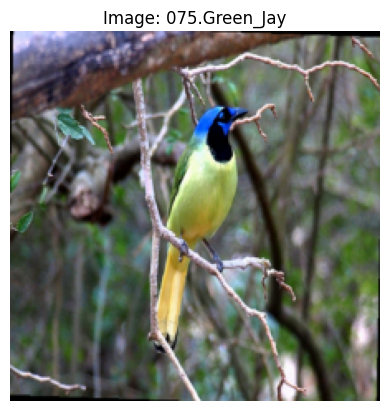

Attribute vector for this image:
[0, 17, 0, 0, 2, 0, 48, 30, 0, 16, 0, 0, 0, 2, 1, 31, 51, 42, 0, 0, 2, 1, 2, 2, 14, 0, 0, 0, 0, 2, 26, 58, 49, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 1, 61, 38, 30, 0, 0, 12, 6, 2, 1, 26, 0, 0, 73, 19, 0, 0, 0, 0, 1, 24, 54, 36, 0, 0, 0, 1, 2, 0, 0, 38, 43, 0, 11, 6, 23, 0, 0, 0, 0, 0, 15, 47, 21, 0, 0, 4, 2, 3, 0, 0, 3, 2, 8, 35, 6, 9, 4, 16, 3, 21, 0, 0, 0, 0, 0, 0, 44, 30, 18, 0, 0, 58, 5, 2, 0, 16, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 91, 0, 2, 0, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 88, 2, 2, 0, 38, 0, 61, 87, 0, 0, 0, 0, 5, 0, 0, 0, 0, 0, 13, 16, 0, 1, 16, 0, 0, 0, 0, 2, 61, 19, 14, 0, 0, 7, 1, 2, 0, 47, 0, 0, 0, 0, 0, 12, 24, 18, 0, 0, 36, 2, 2, 0, 2, 0, 0, 0, 0, 0, 70, 41, 25, 0, 0, 0, 5, 2, 0, 42, 28, 5, 2, 21, 1, 79, 0, 1, 17, 0, 0, 0, 0, 0, 0, 4, 13, 7, 9, 1, 2, 0, 59, 65, 2, 0, 31, 65, 0, 0, 33, 68, 0, 1, 29, 29, 0, 0, 0, 0, 2, 51, 54, 32, 0, 0, 10, 3, 0, 0, 0, 0, 0, 0, 0, 76, 0, 0, 0, 0, 0, 8, 1, 3, 10, 21, 0, 1, 0, 0, 13, 2, 0, 2, 0, 0, 68, 0, 4, 0, 89, 0, 0,

In [8]:
import matplotlib.pyplot as plt
import torchvision.transforms as T

# Get one image, its attribute, and path
image, attr, label, path = images[0], attrs[0], label[0].item(), paths[0]


image_np = image.permute(1, 2, 0).cpu().numpy()

# Plot the image
plt.imshow(image_np)
plt.axis('off')
plt.title("Image: " + path.split('/')[-2])
plt.show()

# Print the attribute vector (binary: 0/1)
print("Attribute vector for this image:")
print(attr.int().tolist())
print(path)
print(label)

### Check the test loader
##### For once, check the same with test loader too.

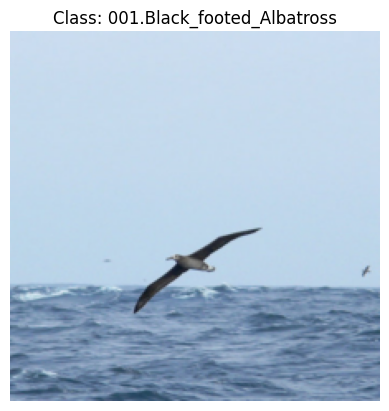

Attribute vector for '001.Black_footed_Albatross':
[0, 2, 1, 0, 59, 26, 3, 5, 0, 1, 45, 3, 0, 2, 24, 0, 0, 0, 0, 0, 31, 3, 2, 28, 1, 48, 3, 0, 1, 20, 0, 0, 0, 0, 0, 23, 2, 5, 29, 2, 29, 4, 0, 5, 39, 0, 0, 0, 0, 0, 23, 8, 6, 18, 78, 0, 3, 17, 1, 44, 1, 0, 2, 21, 0, 0, 0, 0, 0, 22, 1, 5, 30, 2, 23, 23, 16, 23, 9, 3, 31, 4, 0, 3, 22, 0, 0, 0, 0, 0, 22, 16, 7, 22, 4, 5, 0, 6, 5, 7, 12, 36, 16, 6, 6, 1, 33, 2, 0, 4, 33, 0, 0, 0, 0, 0, 21, 2, 5, 19, 1, 31, 3, 0, 2, 23, 0, 0, 0, 0, 0, 20, 7, 6, 28, 0, 3, 0, 0, 2, 1, 0, 0, 0, 0, 81, 8, 4, 0, 82, 7, 9, 1, 14, 2, 0, 0, 29, 0, 0, 0, 0, 0, 11, 31, 6, 27, 2, 35, 2, 0, 5, 27, 0, 0, 0, 0, 0, 30, 19, 6, 21, 1, 40, 2, 0, 3, 26, 0, 0, 0, 0, 0, 18, 5, 6, 23, 2, 25, 3, 0, 5, 29, 0, 0, 0, 0, 0, 21, 7, 6, 25, 13, 20, 11, 11, 52, 19, 10, 1, 66, 2, 7, 0, 2, 33, 0, 34, 0, 0, 0, 8, 1, 2, 3, 5, 58, 3, 18, 20, 45, 3, 14, 36, 81, 0, 3, 14, 2, 48, 1, 0, 2, 24, 0, 0, 0, 0, 0, 26, 2, 4, 24, 4, 16, 0, 0, 0, 27, 0, 0, 0, 0, 0, 39, 0, 12, 10, 2, 20, 2, 0, 0, 34, 0, 0, 0

In [9]:
import matplotlib.pyplot as plt

# Get a batch from the train_loader
for images, attrs, label, paths in test_loader:
    for i in range(len(images)):
        image = images[i]
        attr = attrs[i]
        path = paths[i]

        # Convert image to numpy for display
        image_np = image.permute(1, 2, 0).cpu().numpy()

        # Get class name from path (second last folder in path)
        class_name = path.split('/')[-2]

        # Plot image
        plt.imshow(image_np)
        plt.axis('off')
        plt.title(f"Class: {class_name}")
        plt.show()

        # Print attribute vector
        print(f"Attribute vector for '{class_name}':\n{attr.int().tolist()}")
        
        break
    break


### Model Training
##### This is how we train the data in model, just be sure to normalize the all-class attribute before you do so
```
import numpy as np
import torch.nn.functional as F
from pytorch_lightning.loggers import CSVLogger
all_class_attributes = torch.tensor(pred_matrix, dtype=torch.float32)
all_class_attributes=F.normalize(all_class_attributes)
logger = CSVLogger("logs/", name="zsl_training")




model = LocalAttentionZSLNet(all_class_attrs=all_class_attributes)

trainer = L.Trainer(
    max_epochs=15,
    accelerator='auto'
)

trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=[train_loader, test_loader])

```


In [10]:
!pip install ultralytics opencv-python -q

from ultralytics import FastSAM
import torch
import numpy as np
import os
import cv2

model = FastSAM('FastSAM-s.pt')
device = 'cuda' if torch.cuda.is_available() else 'cpu'

os.makedirs("fastsam_output", exist_ok=True)

count = 0

for batch in train_loader:
    images, _, _, paths = batch

    for i in range(images.size(0)):
        if count >= 20:
            break

        img = images[i].permute(1, 2, 0).cpu().numpy()
        img = (img * 255).astype(np.uint8)

        results = model(img, device=device, retina_masks=True)

        if results[0].masks is None:
            continue

        masks = results[0].masks.data.cpu().numpy()
        base_name = os.path.basename(paths[i]).replace('.jpg', '')

        # combine all masks
        combined = np.zeros_like(img, dtype=np.uint8)

        for m in masks:
            color = (np.random.rand(3) * 255).astype(np.uint8)
            combined[m] = color

        # overlay on original image
        overlay = cv2.addWeighted(img, 0.6, combined, 0.4, 0)

        # save final image
        cv2.imwrite(f"fastsam_output/{base_name}_combined.png",
                    cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

        print(f"Saved combined masks for {base_name}")
        count += 1

    if count >= 20:
        break

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 12.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

0: 640x640 12 objects, 20.8ms
Speed: 47.7ms preprocess, 20.8ms inference, 1367.4ms postprocess per image at shape (1, 3, 640, 640)
Saved combined masks for Savannah_Sparrow_0067_118491

0: 640x640 58 objects, 20.8ms
Speed: 5.7ms preprocess, 20.8ms inference, 3.7ms postprocess per image at shape (1, 3, 640, 640)
Saved combined masks for Yellow_Throated_Vireo_0063_159677

0: 640x640 10 objects, 20.7ms
Speed: 3.9ms preprocess, 20.7ms inference, 2.9ms postprocess per image at shape (1, 3, 640, 640)
Saved combined masks for Scott_Oriole_0016_92398

0: 640x640 9 objects, 20.7ms
Speed: 2.5ms preprocess, 20.7ms 